# Data Prep

In [ ]:
# ============================================================
# BLOCK 1 — Verify GPU, Drive, dataset path, and project folders
# ============================================================

from pathlib import Path
import os
import platform
import subprocess
import torch

# Google Drive should already be mounted.
DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DIR = DRIVE_ROOT / "FetalGeo"
DATASET_DIR = PROJECT_DIR / "data" / "FetalBiometry-Multicentre"

# Persistent output locations.
DIRS = {
    "project": PROJECT_DIR,
    "dataset": DATASET_DIR,
    "manifests": PROJECT_DIR / "data" / "manifests",
    "audit": PROJECT_DIR / "data" / "audit",
    "src": PROJECT_DIR / "src",
    "configs": PROJECT_DIR / "configs",
    "checkpoints": PROJECT_DIR / "checkpoints",
    "predictions": PROJECT_DIR / "predictions",
    "logs": PROJECT_DIR / "logs",
    "paper_artifacts": PROJECT_DIR / "paper_artifacts",
    "figure_source": PROJECT_DIR / "paper_artifacts" / "figures" / "source",
    "figure_final": PROJECT_DIR / "paper_artifacts" / "figures" / "final",
    "figure_data": PROJECT_DIR / "paper_artifacts" / "figures" / "data",
    "figure_captions": PROJECT_DIR / "paper_artifacts" / "figures" / "captions",
    "table_source": PROJECT_DIR / "paper_artifacts" / "tables" / "source",
    "table_final": PROJECT_DIR / "paper_artifacts" / "tables" / "final",
    "table_data": PROJECT_DIR / "paper_artifacts" / "tables" / "data",
    "table_notes": PROJECT_DIR / "paper_artifacts" / "tables" / "notes",
    "supplementary_figures": PROJECT_DIR / "paper_artifacts" / "supplementary" / "figures",
    "supplementary_tables": PROJECT_DIR / "paper_artifacts" / "supplementary" / "tables",
}

# Stop immediately if Drive or the dataset is unavailable.
assert DRIVE_ROOT.exists(), (
    "Google Drive is not mounted at /content/drive/MyDrive."
)
assert DATASET_DIR.exists(), (
    f"Dataset folder was not found:\n{DATASET_DIR}"
)

# Create only project-output folders. The source dataset is preserved.
for name, path in DIRS.items():
    if name != "dataset":
        path.mkdir(parents=True, exist_ok=True)

required_dataset_items = [
    DATASET_DIR / "images",
    DATASET_DIR / "annotations",
    DATASET_DIR / "README-FP.md",
    DATASET_DIR / "README-HC18.md",
    DATASET_DIR / "README-UCL.md",
    DATASET_DIR / "README-MULTI-CENTRE.md",
]

missing_items = [str(path) for path in required_dataset_items if not path.exists()]
assert not missing_items, (
    "Required dataset items are missing:\n" + "\n".join(missing_items)
)

# Check source folders without reading or modifying dataset contents.
expected_sources = ["FP", "HC18", "UCL", "MULTICENTRE"]
for category in ["images", "annotations"]:
    category_dir = DATASET_DIR / category
    found = sorted(path.name for path in category_dir.iterdir() if path.is_dir())
    print(f"{category:12s}: {found}")

# GPU information.
print("\nEnvironment")
print("-" * 60)
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )
    subprocess.run(["nvidia-smi"], check=False)
else:
    raise RuntimeError(
        "CUDA is unavailable. In Colab choose Runtime > Change runtime type > A100 GPU."
    )

print("\nPaths")
print("-" * 60)
print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Checkpoints:", DIRS["checkpoints"])
print("Paper artifacts:", DIRS["paper_artifacts"])
print("\nBLOCK 1 PASSED")

images      : ['FP', 'HC18', 'MULTICENTRE', 'UCL']
annotations : ['FP', 'HC18', 'MULTICENTRE', 'UCL']

Environment
------------------------------------------------------------
Python: 3.13.15
PyTorch: 2.11.0+cpu
CUDA available: False


RuntimeError: CUDA is unavailable. In Colab choose Runtime > Change runtime type > A100 GPU.

In [ ]:
# BLOCK 2 — Audit dataset files and annotation CSVs
# Run on CPU.

from pathlib import Path
from datetime import datetime, timezone
import json
import pandas as pd

project_dir = Path("/content/drive/MyDrive/FetalGeo")
dataset_dir = project_dir / "data" / "FetalBiometry-Multicentre"
audit_dir = project_dir / "data" / "audit"

audit_dir.mkdir(parents=True, exist_ok=True)

images_dir = dataset_dir / "images"
annotations_dir = dataset_dir / "annotations"

assert dataset_dir.exists(), f"Dataset missing: {dataset_dir}"
assert images_dir.exists(), f"Images folder missing: {images_dir}"
assert annotations_dir.exists(), f"Annotations folder missing: {annotations_dir}"

image_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
sources = ["FP", "HC18", "UCL", "MULTICENTRE"]

image_records = []

for source in sources:
    source_dir = images_dir / source

    if not source_dir.exists():
        print(f"WARNING: Missing image source folder: {source_dir}")
        continue

    anatomy_dirs = sorted(
        path for path in source_dir.iterdir()
        if path.is_dir() and not path.name.startswith(".")
    )

    for anatomy_dir in anatomy_dirs:
        image_files = [
            path
            for path in anatomy_dir.rglob("*")
            if path.is_file() and path.suffix.lower() in image_extensions
        ]

        image_records.append(
            {
                "source": source,
                "anatomy": anatomy_dir.name,
                "image_count": len(image_files),
                "folder": str(anatomy_dir),
            }
        )

image_counts = pd.DataFrame(image_records)

csv_records = []
csv_errors = []

for source in sources:
    source_dir = annotations_dir / source

    if not source_dir.exists():
        print(f"WARNING: Missing annotation source folder: {source_dir}")
        continue

    for csv_path in sorted(source_dir.rglob("*.csv")):
        try:
            dataframe = pd.read_csv(csv_path)

            csv_records.append(
                {
                    "source": source,
                    "csv_file": csv_path.name,
                    "row_count": len(dataframe),
                    "column_count": len(dataframe.columns),
                    "has_subject_id": "SubjectID" in dataframe.columns,
                    "has_split": "Split" in dataframe.columns,
                    "has_pixel_to_mm": "px_to_mm_rate" in dataframe.columns,
                    "path": str(csv_path),
                }
            )
        except Exception as error:
            csv_errors.append(
                {
                    "path": str(csv_path),
                    "error": repr(error),
                }
            )

csv_summary = pd.DataFrame(csv_records)

image_counts_path = audit_dir / "image_counts.csv"
csv_summary_path = audit_dir / "annotation_csv_summary.csv"
audit_summary_path = audit_dir / "block2_audit_summary.json"

image_counts.to_csv(image_counts_path, index=False)
csv_summary.to_csv(csv_summary_path, index=False)

audit_summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_directory": str(dataset_dir),
    "image_file_total_including_multicentre": int(
        image_counts["image_count"].sum()
    ) if not image_counts.empty else 0,
    "source_image_total_excluding_multicentre": int(
        image_counts.loc[
            image_counts["source"] != "MULTICENTRE",
            "image_count",
        ].sum()
    ) if not image_counts.empty else 0,
    "csv_file_count": int(len(csv_summary)),
    "csv_errors": csv_errors,
}

with open(audit_summary_path, "w", encoding="utf-8") as file:
    json.dump(audit_summary, file, indent=2)

print("IMAGE COUNTS")
display(image_counts)

print("\nANNOTATION CSV SUMMARY")
display(csv_summary)

print("\nCSV ERRORS")
print(csv_errors if csv_errors else "None")

print("\nSOURCE IMAGE TOTAL (excluding MULTICENTRE):")
print(audit_summary["source_image_total_excluding_multicentre"])

print("\nSaved:")
print(image_counts_path)
print(csv_summary_path)
print(audit_summary_path)

print("\nBLOCK 2 COMPLETED")

IMAGE COUNTS


,source,anatomy,image_count,folder
0,FP,Abdomen,693,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
1,FP,Femur,760,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
2,FP,Head,1637,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
3,HC18,Head,999,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
4,UCL,Abdomen,130,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
5,UCL,Femur,135,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
6,UCL,Head,159,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
7,MULTICENTRE,Abdomen,823,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
8,MULTICENTRE,Femur,895,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
9,MULTICENTRE,Head,2795,/content/drive/MyDrive/FetalGeo/data/FetalBiom...



ANNOTATION CSV SUMMARY


,source,csv_file,row_count,column_count,has_subject_id,has_split,has_pixel_to_mm,path
0,FP,Abdomen.csv,693,17,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
1,FP,Abdomen_Test.csv,125,17,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
2,FP,Abdomen_Train.csv,568,17,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
3,FP,Femur.csv,760,13,False,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
4,FP,Femur_Test.csv,323,13,False,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
5,FP,Femur_Train.csv,437,13,False,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
6,FP,Head.csv,1637,16,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
7,FP,Head_Test.csv,880,16,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
8,FP,Head_Train.csv,757,16,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
9,HC18,Head.csv,999,16,True,True,True,/content/drive/MyDrive/FetalGeo/data/FetalBiom...



CSV ERRORS
None

SOURCE IMAGE TOTAL (excluding MULTICENTRE):
4513

Saved:
/content/drive/MyDrive/FetalGeo/data/audit/image_counts.csv
/content/drive/MyDrive/FetalGeo/data/audit/annotation_csv_summary.csv
/content/drive/MyDrive/FetalGeo/data/audit/block2_audit_summary.json

BLOCK 2 COMPLETED


In [ ]:
# ============================================================
# BLOCK 3 — Annotation integrity and subject-split audit
# CPU task: no GPU required
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict
import json
import pandas as pd

project_dir = Path("/content/drive/MyDrive/FetalGeo")
dataset_dir = project_dir / "data" / "FetalBiometry-Multicentre"
images_dir = dataset_dir / "images"
annotations_dir = dataset_dir / "annotations"
audit_dir = project_dir / "data" / "audit"

audit_dir.mkdir(parents=True, exist_ok=True)

# MULTICENTRE repeats the three source datasets, so audit source data here.
sources = ["FP", "HC18", "UCL"]
anatomies = ["Head", "Abdomen", "Femur"]
image_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def find_column(columns, candidates):
    """Return the first matching column, ignoring capitalization."""
    lookup = {str(column).strip().lower(): column for column in columns}

    for candidate in candidates:
        match = lookup.get(candidate.lower())
        if match is not None:
            return match

    return None


def normalized_text(series):
    """Convert values to stripped strings while preserving missing values."""
    return series.astype("string").str.strip()


# Build an image-name index once.
image_index = {}

for source in sources:
    image_index[source] = {}

    for anatomy in anatomies:
        anatomy_dir = images_dir / source / anatomy

        if not anatomy_dir.exists():
            continue

        name_map = defaultdict(list)

        for path in anatomy_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in image_extensions:
                name_map[path.name.lower()].append(str(path))

        image_index[source][anatomy] = name_map


integrity_records = []
split_overlap_records = []
cross_anatomy_subject_splits = defaultdict(set)
csv_errors = []

for source in sources:
    for anatomy in anatomies:
        annotation_dir = annotations_dir / source
        full_csv = annotation_dir / f"{anatomy}.csv"
        train_csv = annotation_dir / f"{anatomy}_Train.csv"
        test_csv = annotation_dir / f"{anatomy}_Test.csv"

        # Some sources do not contain every anatomy.
        if not full_csv.exists():
            continue

        try:
            full_df = pd.read_csv(full_csv)

            image_column = find_column(
                full_df.columns,
                ["image_name", "image", "filename", "file_name"],
            )
            subject_column = find_column(
                full_df.columns,
                ["SubjectID", "subject_id", "subject", "patient_id"],
            )
            split_column = find_column(
                full_df.columns,
                ["Split", "split", "partition", "set"],
            )
            calibration_column = find_column(
                full_df.columns,
                ["px_to_mm_rate", "pixel_to_mm", "mm_per_pixel"],
            )

            missing_image_names = 0
            ambiguous_image_names = 0
            blank_image_names = 0

            if image_column is None:
                missing_image_names = len(full_df)
            else:
                for value in normalized_text(full_df[image_column]):
                    if pd.isna(value) or value == "":
                        blank_image_names += 1
                        continue

                    matches = image_index[source].get(anatomy, {}).get(
                        value.lower(),
                        [],
                    )

                    if len(matches) == 0:
                        missing_image_names += 1
                    elif len(matches) > 1:
                        ambiguous_image_names += 1

            if subject_column is None:
                missing_subject_ids = len(full_df)
                unique_subjects = None
            else:
                subject_values = normalized_text(full_df[subject_column])
                valid_subjects = subject_values[
                    subject_values.notna() & (subject_values != "")
                ]

                missing_subject_ids = int(len(full_df) - len(valid_subjects))
                unique_subjects = int(valid_subjects.nunique())

                if split_column is not None:
                    split_values = normalized_text(full_df[split_column])

                    for subject, split in zip(subject_values, split_values):
                        if (
                            pd.notna(subject)
                            and subject != ""
                            and pd.notna(split)
                            and split != ""
                        ):
                            subject_key = f"{source}:{subject}"
                            cross_anatomy_subject_splits[
                                subject_key
                            ].add(split.lower())

            if calibration_column is None:
                valid_calibration = 0
                missing_calibration = len(full_df)
            else:
                calibration = pd.to_numeric(
                    full_df[calibration_column],
                    errors="coerce",
                )

                valid_mask = calibration.notna() & (calibration > 0)
                valid_calibration = int(valid_mask.sum())
                missing_calibration = int((~valid_mask).sum())

            image_folder_count = sum(
                len(paths)
                for paths in image_index[source].get(anatomy, {}).values()
            )

            integrity_records.append(
                {
                    "source": source,
                    "anatomy": anatomy,
                    "annotation_rows": int(len(full_df)),
                    "image_folder_count": int(image_folder_count),
                    "row_image_difference": int(
                        len(full_df) - image_folder_count
                    ),
                    "image_column": image_column,
                    "subject_column": subject_column,
                    "split_column": split_column,
                    "calibration_column": calibration_column,
                    "unique_subjects": unique_subjects,
                    "missing_subject_ids": missing_subject_ids,
                    "blank_image_names": blank_image_names,
                    "unmatched_image_names": missing_image_names,
                    "ambiguous_image_names": ambiguous_image_names,
                    "valid_calibration_rows": valid_calibration,
                    "invalid_or_missing_calibration_rows": missing_calibration,
                    "full_csv": str(full_csv),
                }
            )

            # Audit subject overlap between official train and test CSV files.
            if train_csv.exists() and test_csv.exists():
                train_df = pd.read_csv(train_csv)
                test_df = pd.read_csv(test_csv)

                train_subject_column = find_column(
                    train_df.columns,
                    ["SubjectID", "subject_id", "subject", "patient_id"],
                )
                test_subject_column = find_column(
                    test_df.columns,
                    ["SubjectID", "subject_id", "subject", "patient_id"],
                )

                if (
                    train_subject_column is not None
                    and test_subject_column is not None
                ):
                    train_subjects = set(
                        normalized_text(
                            train_df[train_subject_column]
                        ).dropna()
                    )
                    test_subjects = set(
                        normalized_text(
                            test_df[test_subject_column]
                        ).dropna()
                    )

                    train_subjects.discard("")
                    test_subjects.discard("")
                    overlap = sorted(train_subjects & test_subjects)

                    split_overlap_records.append(
                        {
                            "source": source,
                            "anatomy": anatomy,
                            "train_rows": int(len(train_df)),
                            "test_rows": int(len(test_df)),
                            "train_subjects": int(len(train_subjects)),
                            "test_subjects": int(len(test_subjects)),
                            "overlap_subject_count": int(len(overlap)),
                            "overlap_subject_ids": "|".join(overlap),
                        }
                    )
                else:
                    split_overlap_records.append(
                        {
                            "source": source,
                            "anatomy": anatomy,
                            "train_rows": int(len(train_df)),
                            "test_rows": int(len(test_df)),
                            "train_subjects": None,
                            "test_subjects": None,
                            "overlap_subject_count": None,
                            "overlap_subject_ids":
                                "Subject column unavailable",
                        }
                    )

        except Exception as error:
            csv_errors.append(
                {
                    "source": source,
                    "anatomy": anatomy,
                    "csv": str(full_csv),
                    "error": repr(error),
                }
            )


integrity_df = pd.DataFrame(integrity_records)
split_overlap_df = pd.DataFrame(split_overlap_records)

cross_split_records = []

for subject_key, split_names in sorted(
    cross_anatomy_subject_splits.items()
):
    if len(split_names) > 1:
        cross_split_records.append(
            {
                "subject_key": subject_key,
                "split_values": "|".join(sorted(split_names)),
                "split_value_count": len(split_names),
            }
        )

cross_split_df = pd.DataFrame(
    cross_split_records,
    columns=[
        "subject_key",
        "split_values",
        "split_value_count",
    ],
)

integrity_path = audit_dir / "annotation_integrity.csv"
split_overlap_path = audit_dir / "official_split_overlap.csv"
cross_split_path = audit_dir / "cross_anatomy_split_conflicts.csv"
summary_path = audit_dir / "block3_integrity_summary.json"

integrity_df.to_csv(integrity_path, index=False)
split_overlap_df.to_csv(split_overlap_path, index=False)
cross_split_df.to_csv(cross_split_path, index=False)

total_unmatched = (
    int(integrity_df["unmatched_image_names"].sum())
    if not integrity_df.empty
    else 0
)

total_split_overlap = (
    int(
        pd.to_numeric(
            split_overlap_df["overlap_subject_count"],
            errors="coerce",
        ).fillna(0).sum()
    )
    if not split_overlap_df.empty
    else 0
)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "sources_audited": sources,
    "multicentre_excluded_to_prevent_double_counting": True,
    "anatomy_tables_audited": int(len(integrity_df)),
    "total_unmatched_image_names": total_unmatched,
    "total_official_train_test_subject_overlaps": total_split_overlap,
    "cross_anatomy_split_conflict_subjects": int(len(cross_split_df)),
    "csv_errors": csv_errors,
}

with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print("ANNOTATION INTEGRITY")
display(integrity_df)

print("\nOFFICIAL TRAIN/TEST SUBJECT OVERLAP")
display(split_overlap_df)

print("\nCROSS-ANATOMY SPLIT CONFLICTS")
if cross_split_df.empty:
    print("None detected from available SubjectID and Split fields.")
else:
    display(cross_split_df.head(50))

print("\nCSV ERRORS")
print(csv_errors if csv_errors else "None")

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nSaved:")
print(integrity_path)
print(split_overlap_path)
print(cross_split_path)
print(summary_path)

print("\nBLOCK 3 COMPLETED")

ANNOTATION INTEGRITY


,source,anatomy,annotation_rows,image_folder_count,row_image_difference,image_column,subject_column,split_column,calibration_column,unique_subjects,missing_subject_ids,blank_image_names,unmatched_image_names,ambiguous_image_names,valid_calibration_rows,invalid_or_missing_calibration_rows,full_csv
0,FP,Head,1637,1637,0,image_name,SubjectID,Split,px_to_mm_rate,909.0,0,0,0,0,1635,2,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
1,FP,Abdomen,693,693,0,image_name,SubjectID,Split,px_to_mm_rate,586.0,0,0,0,0,693,0,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
2,FP,Femur,760,760,0,image_name,None,Split,px_to_mm_rate,NaN,760,0,0,0,757,3,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
3,HC18,Head,999,999,0,image_name,SubjectID,Split,px_to_mm_rate,0.0,999,0,0,0,999,0,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
4,UCL,Head,159,159,0,image_name,SubjectID,Split,px_to_mm_rate,0.0,159,0,0,0,126,33,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
5,UCL,Abdomen,130,130,0,image_name,SubjectID,Split,px_to_mm_rate,0.0,130,0,0,0,99,31,/content/drive/MyDrive/FetalGeo/data/FetalBiom...
6,UCL,Femur,135,135,0,image_name,None,Split,px_to_mm_rate,NaN,135,0,0,0,107,28,/content/drive/MyDrive/FetalGeo/data/FetalBiom...



OFFICIAL TRAIN/TEST SUBJECT OVERLAP


,source,anatomy,train_rows,test_rows,train_subjects,test_subjects,overlap_subject_count,overlap_subject_ids
0,FP,Head,757,880,449.0,460.0,0.0,
1,FP,Abdomen,568,125,477.0,109.0,0.0,
2,FP,Femur,437,323,NaN,NaN,NaN,Subject column unavailable
3,HC18,Head,737,262,0.0,0.0,0.0,
4,UCL,Head,110,49,0.0,0.0,0.0,
5,UCL,Abdomen,94,36,0.0,0.0,0.0,
6,UCL,Femur,96,39,NaN,NaN,NaN,Subject column unavailable



CROSS-ANATOMY SPLIT CONFLICTS


,subject_key,split_values,split_value_count
0,FP:1001,test|train,2
1,FP:1004,test|train,2
2,FP:1005,test|train,2
3,FP:1014,test|train,2
4,FP:1015,test|train,2
5,FP:1016,test|train,2
6,FP:1018,test|train,2
7,FP:1020,test|train,2
8,FP:1022,test|train,2
9,FP:1023,test|train,2



CSV ERRORS
None

SUMMARY
{
  "created_utc": "2026-09-12T13:10:05.360641+00:00",
  "sources_audited": [
    "FP",
    "HC18",
    "UCL"
  ],
  "multicentre_excluded_to_prevent_double_counting": true,
  "anatomy_tables_audited": 7,
  "total_unmatched_image_names": 0,
  "total_official_train_test_subject_overlaps": 0,
  "cross_anatomy_split_conflict_subjects": 253,
  "csv_errors": []
}

Saved:
/content/drive/MyDrive/FetalGeo/data/audit/annotation_integrity.csv
/content/drive/MyDrive/FetalGeo/data/audit/official_split_overlap.csv
/content/drive/MyDrive/FetalGeo/data/audit/cross_anatomy_split_conflicts.csv
/content/drive/MyDrive/FetalGeo/data/audit/block3_integrity_summary.json

BLOCK 3 COMPLETED


In [ ]:
# BLOCK 4A — Inspect the FP femur split schema

from pathlib import Path
import pandas as pd

base = Path(
    "/content/drive/MyDrive/FetalGeo/"
    "data/FetalBiometry-Multicentre/annotations/FP"
)

for filename in [
    "Femur.csv",
    "Femur_Train.csv",
    "Femur_Test.csv",
]:
    path = base / filename
    dataframe = pd.read_csv(
        path,
        dtype=str,
        keep_default_na=False,
    )

    print(f"\n{filename}")
    print("Rows:", len(dataframe))
    print("Columns:", dataframe.columns.tolist())
    display(dataframe.head(2))


Femur.csv
Rows: 760
Columns: ['image_name', 'scale', 'center_w', 'center_h', 'fl_1_x', 'fl_1_y', 'fl_2_x', 'fl_2_y', 'px_to_mm_rate', 'mm_dist', 'Patient', 'Split', 'Algo']


,image_name,scale,center_w,center_h,fl_1_x,fl_1_y,fl_2_x,fl_2_y,px_to_mm_rate,mm_dist,Patient,Split,Algo
0,Patient00168_Plane5_1_of_2.png,1.47058823529412,320.0,196.0,144,143,504,95,0.1428571428571428,0,168,Train,AlokaFit
1,Patient00168_Plane5_2_of_2.png,1.47058823529412,320.0,196.0,356,97,536,122,0.1515151515151515,0,168,Train,AlokaFit



Femur_Train.csv
Rows: 437
Columns: ['image_name', 'scale', 'center_w', 'center_h', 'fl_1_x', 'fl_1_y', 'fl_2_x', 'fl_2_y', 'px_to_mm_rate', 'mm_dist', 'Patient', 'Split', 'Algo']


,image_name,scale,center_w,center_h,fl_1_x,fl_1_y,fl_2_x,fl_2_y,px_to_mm_rate,mm_dist,Patient,Split,Algo
0,Patient00168_Plane5_1_of_2.png,1.47058823529412,320.0,196.0,144,143,504,95,0.1428571428571428,0,168,Train,AlokaFit
1,Patient00168_Plane5_2_of_2.png,1.47058823529412,320.0,196.0,356,97,536,122,0.1515151515151515,0,168,Train,AlokaFit



Femur_Test.csv
Rows: 323
Columns: ['image_name', 'scale', 'center_w', 'center_h', 'fl_1_x', 'fl_1_y', 'fl_2_x', 'fl_2_y', 'px_to_mm_rate', 'mm_dist', 'Patient', 'Split', 'Algo']


,image_name,scale,center_w,center_h,fl_1_x,fl_1_y,fl_2_x,fl_2_y,px_to_mm_rate,mm_dist,Patient,Split,Algo
0,Patient00627_Plane5_1_of_1.png,2.61259191176471,568.5,393.5,302,240,861,246,0.111856823266219,5,627,Test,
1,Patient00629_Plane5_1_of_1.png,2.61259191176471,568.5,393.5,339,315,875,352,0.112275449101796,5,629,Test,


In [ ]:
# BLOCK 4 V2 — Patient grouping and unified split manifests
# Run this complete cell on CPU. No earlier Block 4 is needed.

from pathlib import Path
from datetime import datetime, timezone
from itertools import combinations
import hashlib
import json
import math
import re

import pandas as pd
from IPython.display import display
from IPython import get_ipython

print("RUNNING BLOCK 4 V2 — includes UCL missing-ID handling")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
DATASET = PROJECT / "data" / "FetalBiometry-Multicentre"
ANNOTATIONS = DATASET / "annotations"
IMAGES = DATASET / "images"

SEED = 20260912
VALIDATION_FRACTION = 0.15
SOURCE_ANATOMIES = {
    "FP": ["Head", "Abdomen", "Femur"],
    "HC18": ["Head"],
    "UCL": ["Head", "Abdomen", "Femur"],
}


def column_key(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def clean_text(value):
    value = str(value).strip()
    if value.lower() in {"", "nan", "none", "null", "<na>", "na", "n/a"}:
        return ""
    return value


def canonical_subject_id(value):
    """Keep IDs as text; normalize equivalent numeric forms."""
    value = clean_text(value)
    if not value:
        return ""

    # For example: "005", "5", and "5.0" become "5".
    match = re.fullmatch(r"(\d+)(?:\.0+)?", value)
    if match:
        return str(int(match.group(1)))

    return value


def read_annotation_table(path):
    if not path.is_file():
        raise FileNotFoundError(f"Missing annotation file: {path}")

    frame = pd.read_csv(
        path,
        dtype=str,
        keep_default_na=False,
        encoding="utf-8-sig",
    )
    frame.columns = frame.columns.str.strip()

    candidates = {"imagename", "image", "filename"}
    image_columns = [
        c for c in frame.columns if column_key(c) in candidates
    ]
    if not image_columns:
        raise ValueError(
            f"No image-name column in {path.name}. "
            f"Columns: {frame.columns.tolist()}"
        )

    frame["image_name_canonical"] = frame[image_columns[0]].map(clean_text)

    if frame["image_name_canonical"].eq("").any():
        raise ValueError(f"Blank image names in {path}")

    if frame["image_name_canonical"].duplicated().any():
        raise ValueError(f"Duplicate image-name rows in {path}")

    return frame


def prepare_full_table(source, anatomy):
    path = ANNOTATIONS / source / f"{anatomy}.csv"
    frame = read_annotation_table(path)

    accepted_id_columns = {
        "subjectid", "subject", "patient", "patientid"
    }
    id_columns = [
        c for c in frame.columns
        if column_key(c) in accepted_id_columns
    ]

    subject_ids = []
    origins = []

    for _, row in frame.iterrows():
        provided = [
            (column, canonical_subject_id(row[column]))
            for column in id_columns
        ]
        provided = [(column, value) for column, value in provided if value]

        distinct_ids = {value for _, value in provided}
        if len(distinct_ids) > 1:
            raise ValueError(
                f"Conflicting subject columns in {source}/{anatomy}: "
                f"{row['image_name_canonical']} -> {provided}"
            )

        if provided:
            origin, subject_id = provided[0]
        else:
            subject_id = ""
            origin = "missing"

            # Documented examples:
            # UCL: 005_HC.jpg, 005_2HC.jpeg, 005_AC.jpg
            # HC18: 055_HC.png, 796_2HC.png
            if source in {"UCL", "HC18"}:
                match = re.match(
                    r"^(\d+)_",
                    row["image_name_canonical"],
                )
                if match:
                    subject_id = canonical_subject_id(match.group(1))
                    origin = f"{source}_documented_filename"

        if not subject_id:
            raise ValueError(
                f"Cannot establish subject ID for "
                f"{source}/{anatomy}/{row['image_name_canonical']}. "
                f"Available ID columns: {id_columns}"
            )

        subject_ids.append(subject_id)
        origins.append(origin)

    frame["original_subject_id"] = subject_ids
    frame["subject_id_origin"] = origins
    frame["source"] = source
    frame["anatomy"] = anatomy
    frame["source_annotation_file"] = path.name
    frame["subject_key"] = source + ":" + frame["original_subject_id"]
    frame["record_id"] = (
        source + ":" + anatomy + ":" + frame["image_name_canonical"]
    )
    frame["image_relative_path"] = (
        "images/" + source + "/" + anatomy + "/"
        + frame["image_name_canonical"]
    )
    frame["image_path"] = frame["image_relative_path"].map(
        lambda relative: str(DATASET / relative)
    )

    # Determine official membership by image name. Split CSVs do
    # not need their own subject columns.
    official_names = {}

    for split in ["Train", "Test"]:
        split_path = ANNOTATIONS / source / f"{anatomy}_{split}.csv"
        split_frame = read_annotation_table(split_path)
        official_names[split] = set(split_frame["image_name_canonical"])

    train_names = official_names["Train"]
    test_names = official_names["Test"]
    full_names = set(frame["image_name_canonical"])

    if train_names & test_names:
        raise ValueError(
            f"Images occur in both official splits: {source}/{anatomy}"
        )

    if (train_names | test_names) != full_names:
        raise ValueError(
            f"Full table and Train/Test files do not cover the same "
            f"images for {source}/{anatomy}."
        )

    frame["official_split"] = frame["image_name_canonical"].map(
        lambda name: "Test" if name in test_names else "Train"
    )

    filename_ids = frame["subject_id_origin"].str.endswith(
        "_documented_filename"
    ).sum()

    print(
        f"{source}/{anatomy}: {len(frame)} images; "
        f"{frame['subject_key'].nunique()} subjects; "
        f"{int(filename_ids)} IDs obtained from filenames"
    )

    return frame


# 1. Load source tables. MULTICENTRE is deliberately excluded.
parts = []

for source, anatomies in SOURCE_ANATOMIES.items():
    for anatomy in anatomies:
        parts.append(prepare_full_table(source, anatomy))

all_records = pd.concat(parts, ignore_index=True, sort=False)

if all_records["record_id"].duplicated().any():
    raise ValueError("Duplicate record IDs across the source tables.")

# Detect mixed identifier conventions within a documented filename group.
for source in ["HC18", "UCL"]:
    subset = all_records.loc[all_records["source"].eq(source)].copy()
    subset["filename_subject"] = (
        subset["image_name_canonical"]
        .str.extract(r"^(\d+)_", expand=False)
        .fillna("")
        .map(canonical_subject_id)
    )
    subset = subset.loc[subset["filename_subject"].ne("")]

    inconsistent = (
        subset.groupby("filename_subject")["subject_key"].nunique()
    )
    inconsistent = inconsistent[inconsistent > 1]

    if not inconsistent.empty:
        raise ValueError(
            f"{source}: inconsistent metadata/filename ID mapping for "
            f"{inconsistent.index.tolist()[:10]}. "
            "Do not split these records until the mapping is resolved."
        )

# 2. Build development roles using FP and HC18 only.
development = all_records.loc[
    all_records["source"].isin(["FP", "HC18"])
].copy()

official_test_subjects = set(
    development.loc[
        development["official_split"].eq("Test"), "subject_key"
    ]
)

# Any official-test subject is internal test for every anatomy.
development["role"] = "train"
development.loc[
    development["subject_key"].isin(official_test_subjects), "role"
] = "internal_test"


def stable_rank(subject_key):
    content = f"{SEED}:{subject_key}".encode("utf-8")
    return hashlib.sha256(content).hexdigest()


validation_subjects = set()

for source in ["FP", "HC18"]:
    eligible = sorted(
        development.loc[
            development["source"].eq(source)
            & development["role"].eq("train"),
            "subject_key",
        ].unique(),
        key=stable_rank,
    )

    if len(eligible) < 2:
        raise ValueError(f"Too few training-eligible subjects in {source}.")

    count = min(
        max(1, math.ceil(VALIDATION_FRACTION * len(eligible))),
        len(eligible) - 1,
    )
    validation_subjects.update(eligible[:count])

development.loc[
    development["subject_key"].isin(validation_subjects), "role"
] = "internal_validation"

# 3. Reserve UCL. Only its official Test images enter external testing.
ucl = all_records.loc[all_records["source"].eq("UCL")].copy()
ucl["role"] = ucl["official_split"].map({
    "Test": "external_test",
    "Train": "reserved_unused",
})

external = ucl.loc[ucl["role"].eq("external_test")].copy()
reserved = ucl.loc[ucl["role"].eq("reserved_unused")].copy()
active = pd.concat([development, external], ignore_index=True, sort=False)

# 4. Verify paths and subject separation before writing any manifests.
missing_files = [
    path for path in all_records["image_path"]
    if not Path(path).is_file()
]
if missing_files:
    raise FileNotFoundError(
        f"Missing image files: {missing_files[:10]}"
    )

roles = [
    "train", "internal_validation", "internal_test", "external_test"
]
role_subjects = {
    role: set(active.loc[active["role"].eq(role), "subject_key"])
    for role in roles
}

overlap_counts = {}

for left, right in combinations(roles, 2):
    overlap = role_subjects[left] & role_subjects[right]
    overlap_counts[f"{left}_vs_{right}"] = len(overlap)
    if overlap:
        raise ValueError(
            f"Subject overlap between {left} and {right}: "
            f"{sorted(overlap)[:10]}"
        )

summary = (
    active.groupby(["role", "source", "anatomy"])
    .agg(subjects=("subject_key", "nunique"), images=("record_id", "nunique"))
    .reset_index()
    .sort_values(["role", "source", "anatomy"])
)

required_groups = {
    (role, source, anatomy)
    for role in ["train", "internal_validation", "internal_test"]
    for source in ["FP", "HC18"]
    for anatomy in SOURCE_ANATOMIES[source]
}
required_groups.update(
    ("external_test", "UCL", anatomy)
    for anatomy in SOURCE_ANATOMIES["UCL"]
)
observed_groups = set(
    summary[["role", "source", "anatomy"]].itertuples(
        index=False, name=None
    )
)
if required_groups - observed_groups:
    raise ValueError(
        f"Missing anatomy coverage: {sorted(required_groups - observed_groups)}"
    )

# 5. Save a new versioned folder, preserving any previous manifests.
run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
MANIFEST_DIR = PROJECT / "data" / "manifests" / f"patient_safe_v2_{run_stamp}"
MANIFEST_DIR.mkdir(parents=True, exist_ok=False)

outputs = {
    "unified_manifest.csv": active,
    "train_fp_hc18.csv": active.loc[active["role"].eq("train")],
    "validation_fp_hc18.csv": active.loc[
        active["role"].eq("internal_validation")
    ],
    "internal_test_fp_hc18.csv": active.loc[
        active["role"].eq("internal_test")
    ],
    "external_test_ucl.csv": external,
    "reserved_unused_ucl.csv": reserved,
    "split_summary.csv": summary,
    "subject_assignments.csv": (
        active[["source", "subject_key", "role"]]
        .drop_duplicates()
        .sort_values(["source", "subject_key", "role"])
    ),
    "subject_id_provenance.csv": all_records[
        [
            "record_id", "source", "anatomy", "original_subject_id",
            "subject_key", "subject_id_origin", "official_split",
        ]
    ],
}

file_hashes = {}

for filename, frame in outputs.items():
    path = MANIFEST_DIR / filename
    frame.to_csv(path, index=False)
    file_hashes[filename] = hashlib.sha256(path.read_bytes()).hexdigest()

configuration = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "split_name": "FetalGeo_patient_safe_v2",
    "split_seed": SEED,
    "validation_fraction": VALIDATION_FRACTION,
    "development_sources": ["FP", "HC18"],
    "external_source": "UCL",
    "ucl_training_images_reserved_unused": True,
    "multicentre_excluded": True,
    "subject_counts": {
        role: len(subjects) for role, subjects in role_subjects.items()
    },
    "image_counts": {
        role: int(active["role"].eq(role).sum()) for role in roles
    },
    "overlap_counts": overlap_counts,
    "csv_sha256": file_hashes,
    "remaining_checks": [
        "Image-content duplicate audit",
        "Full subject-identity/provenance review before split freeze",
    ],
}

with open(
    MANIFEST_DIR / "split_configuration.json", "w", encoding="utf-8"
) as handle:
    json.dump(configuration, handle, indent=2)

print("\nPATIENT-SAFE SPLIT SUMMARY")
display(summary)

print("\nSUBJECT OVERLAP COUNTS")
print(json.dumps(overlap_counts, indent=2))

print("\nSaved versioned manifests:")
print(MANIFEST_DIR)

print("\nBLOCK 4 V2 COMPLETED")

RUNNING BLOCK 4 V2 — includes UCL missing-ID handling
FP/Head: 1637 images; 909 subjects; 0 IDs obtained from filenames
FP/Abdomen: 693 images; 586 subjects; 0 IDs obtained from filenames
FP/Femur: 760 images; 629 subjects; 0 IDs obtained from filenames
HC18/Head: 999 images; 806 subjects; 999 IDs obtained from filenames
UCL/Head: 159 images; 47 subjects; 159 IDs obtained from filenames
UCL/Abdomen: 130 images; 45 subjects; 130 IDs obtained from filenames
UCL/Femur: 135 images; 47 subjects; 135 IDs obtained from filenames

PATIENT-SAFE SPLIT SUMMARY


,role,source,anatomy,subjects,images
0,external_test,UCL,Abdomen,14,36
1,external_test,UCL,Femur,14,39
2,external_test,UCL,Head,16,49
3,internal_test,FP,Abdomen,352,433
4,internal_test,FP,Femur,375,456
5,internal_test,FP,Head,571,1082
6,internal_test,HC18,Head,206,262
7,internal_validation,FP,Abdomen,36,38
8,internal_validation,FP,Femur,49,63
9,internal_validation,FP,Head,47,70



SUBJECT OVERLAP COUNTS
{
  "train_vs_internal_validation": 0,
  "train_vs_internal_test": 0,
  "train_vs_external_test": 0,
  "internal_validation_vs_internal_test": 0,
  "internal_validation_vs_external_test": 0,
  "internal_test_vs_external_test": 0
}

Saved versioned manifests:
/content/drive/MyDrive/FetalGeo/data/manifests/patient_safe_v2_20260912T152323694239Z

BLOCK 4 V2 COMPLETED


Verifying: patient_safe_v2_20260912T151813194803Z


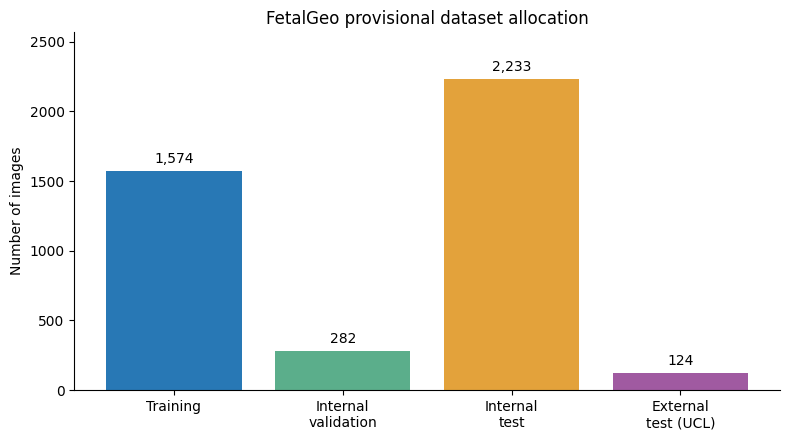


VERIFIED ROLE COUNTS


,role,subjects,images
0,train,866,1574
1,internal_validation,153,282
2,internal_test,834,2233
3,external_test,19,124



SUBJECT-ID PROVENANCE


,source,subject_id_origin,image_records
0,FP,Patient,760
1,FP,SubjectID,2330
2,HC18,HC18_documented_filename,999
3,UCL,UCL_documented_filename,424



Manifest checksums verified: 9
Training images: 1,574 / 4,089
Training fraction: 38.49%
Subject-key overlap across active roles: 0
Split status: PROVISIONAL — further checks pending

Results: /content/drive/MyDrive/FetalGeo/FETALGEO_RESULTS.md
Paper figure: /content/drive/MyDrive/FetalGeo/paper_artifacts/figures/final/fig01b_split_counts_block5_20260912T152404429909Z.pdf
Paper table: /content/drive/MyDrive/FetalGeo/paper_artifacts/tables/final/tab01_split_summary_block5_20260912T152404429909Z.md
Audit: /content/drive/MyDrive/FetalGeo/data/audit/block5_20260912T152404429909Z

BLOCK 5 COMPLETED


In [ ]:
# FETALGEO_BLOCK5_V1
# BLOCK 5 — Verify manifests and save manuscript audit results
# CPU only. No model training or UCL prediction evaluation.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from IPython import get_ipython

PROJECT = Path("/content/drive/MyDrive/FetalGeo")

# Exact folder produced by your successful Block 4.
MANIFEST_DIR = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)

CONFIG_PATH = MANIFEST_DIR / "split_configuration.json"

if not CONFIG_PATH.is_file():
    raise FileNotFoundError(
        f"Cannot find the successful Block 4 configuration:\n{CONFIG_PATH}"
    )

with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    config = json.load(handle)

print("Verifying:", MANIFEST_DIR.name)

# ------------------------------------------------------------
# 1. Verify every manifest against its Block 4 checksum.
# ------------------------------------------------------------

expected_hashes = config.get("csv_sha256", {})
if not expected_hashes:
    raise ValueError("The Block 4 configuration contains no CSV checksums.")

hash_rows = []

for filename, expected in expected_hashes.items():
    if Path(filename).name != filename:
        raise ValueError(f"Unexpected manifest filename: {filename}")

    path = MANIFEST_DIR / filename
    if not path.is_file():
        raise FileNotFoundError(f"Missing saved manifest: {path}")

    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    hash_rows.append({
        "file": filename,
        "expected_sha256": expected,
        "actual_sha256": actual,
        "matches": actual == expected,
    })

hash_report = pd.DataFrame(hash_rows)

if not hash_report["matches"].all():
    display(hash_report.loc[~hash_report["matches"]])
    raise ValueError(
        "A manifest changed after Block 4. Resolve this before proceeding."
    )

# ------------------------------------------------------------
# 2. Reload the saved role-specific manifests.
# ------------------------------------------------------------

role_files = {
    "train": "train_fp_hc18.csv",
    "internal_validation": "validation_fp_hc18.csv",
    "internal_test": "internal_test_fp_hc18.csv",
    "external_test": "external_test_ucl.csv",
}

frames = {}
required_columns = {
    "record_id", "subject_key", "source", "anatomy", "role"
}

for role, filename in role_files.items():
    frame = pd.read_csv(
        MANIFEST_DIR / filename,
        dtype=str,
        keep_default_na=False,
    )

    missing = required_columns - set(frame.columns)
    if missing:
        raise ValueError(f"{filename}: missing columns {sorted(missing)}")

    if frame.empty:
        raise ValueError(f"{filename} is empty.")

    if not frame["role"].eq(role).all():
        raise ValueError(f"Incorrect role values in {filename}")

    if frame["record_id"].duplicated().any():
        raise ValueError(f"Duplicate record IDs in {filename}")

    if frame["subject_key"].str.strip().eq("").any():
        raise ValueError(f"Blank subject keys in {filename}")

    permitted = {"UCL"} if role == "external_test" else {"FP", "HC18"}
    if not set(frame["source"]).issubset(permitted):
        raise ValueError(f"Unexpected source in {filename}")

    expected_count = config["image_counts"].get(role)
    if expected_count is None or len(frame) != int(expected_count):
        raise ValueError(f"Saved image count disagrees with Block 4: {role}")

    expected_subjects = config["subject_counts"].get(role)
    if (
        expected_subjects is None
        or frame["subject_key"].nunique() != int(expected_subjects)
    ):
        raise ValueError(f"Saved subject count disagrees with Block 4: {role}")

    frames[role] = frame

active = pd.concat(frames.values(), ignore_index=True, sort=False)

if active["record_id"].duplicated().any():
    raise ValueError("An image record appears in multiple active roles.")

subject_role_counts = active.groupby("subject_key")["role"].nunique()
if subject_role_counts.gt(1).any():
    raise ValueError("At least one subject key appears in multiple roles.")

# Verify that the combined manifest agrees with the individual files.
unified = pd.read_csv(
    MANIFEST_DIR / "unified_manifest.csv",
    dtype=str,
    keep_default_na=False,
)

compare_columns = ["record_id", "subject_key", "source", "anatomy", "role"]
active_rows = set(
    active[compare_columns].itertuples(index=False, name=None)
)
unified_rows = set(
    unified[compare_columns].itertuples(index=False, name=None)
)

if len(active) != len(unified) or active_rows != unified_rows:
    raise ValueError("Unified and role-specific manifests disagree.")

reserved = pd.read_csv(
    MANIFEST_DIR / "reserved_unused_ucl.csv",
    dtype=str,
    keep_default_na=False,
)

if not reserved["source"].eq("UCL").all():
    raise ValueError("Reserved records contain a source other than UCL.")

if not reserved["role"].eq("reserved_unused").all():
    raise ValueError("Reserved UCL records have an incorrect role.")

all_records = pd.concat([active, reserved], ignore_index=True, sort=False)

if all_records["record_id"].duplicated().any():
    raise ValueError("Active and reserved records contain duplicate record IDs.")

if len(all_records) != 4513:
    raise ValueError(
        f"Expected 4,513 source records; found {len(all_records)}."
    )

# ------------------------------------------------------------
# 3. Compute summaries from the verified files.
# ------------------------------------------------------------

role_order = [
    "train", "internal_validation", "internal_test", "external_test"
]

split_summary = (
    active.groupby(["role", "source", "anatomy"])
    .agg(
        subjects=("subject_key", "nunique"),
        images=("record_id", "nunique"),
    )
    .reset_index()
)

split_summary["_order"] = split_summary["role"].map(
    {role: index for index, role in enumerate(role_order)}
)
split_summary = (
    split_summary.sort_values(["_order", "source", "anatomy"])
    .drop(columns="_order")
    .reset_index(drop=True)
)

role_summary = (
    active.groupby("role")
    .agg(
        subjects=("subject_key", "nunique"),
        images=("record_id", "nunique"),
    )
    .reindex(role_order)
    .reset_index()
)

id_provenance = (
    all_records.groupby(["source", "subject_id_origin"])
    .size()
    .reset_index(name="image_records")
)

development_images = len(active.loc[active["source"].isin(["FP", "HC18"])])
training_images = len(frames["train"])
training_fraction = training_images / development_images

# ------------------------------------------------------------
# 4. Create versioned audit and paper-artifact output paths.
# ------------------------------------------------------------

timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
artifact_tag = f"block5_{timestamp}"

AUDIT_RUN = PROJECT / "data" / "audit" / artifact_tag
PAPER = PROJECT / "paper_artifacts"

folders = [
    AUDIT_RUN,
    PAPER / "figures" / "source",
    PAPER / "figures" / "final",
    PAPER / "figures" / "data",
    PAPER / "figures" / "captions",
    PAPER / "tables" / "data",
    PAPER / "tables" / "final",
    PAPER / "tables" / "notes",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

hash_report.to_csv(AUDIT_RUN / "manifest_hash_verification.csv", index=False)
role_summary.to_csv(AUDIT_RUN / "role_summary.csv", index=False)
id_provenance.to_csv(AUDIT_RUN / "subject_id_provenance_summary.csv", index=False)

table_data = PAPER / "tables" / "data" / f"tab01_split_summary_{artifact_tag}.csv"
table_final = PAPER / "tables" / "final" / f"tab01_split_summary_{artifact_tag}.md"
table_notes = PAPER / "tables" / "notes" / f"tab01_split_summary_{artifact_tag}.txt"

split_summary.to_csv(table_data, index=False)


def markdown_table(frame):
    """Create a Markdown table without requiring the tabulate package."""
    def cell(value):
        return str(value).replace("|", "/").replace("\n", " ")

    lines = [
        "| " + " | ".join(cell(c) for c in frame.columns) + " |",
        "| " + " | ".join("---" for _ in frame.columns) + " |",
    ]
    lines.extend(
        "| " + " | ".join(cell(v) for v in row) + " |"
        for row in frame.itertuples(index=False, name=None)
    )
    return "\n".join(lines)


notes = (
    "Candidate table: provisional patient-grouped split.\n"
    "Subject counts within anatomy rows are not additive across anatomies.\n"
    "Internal-test assignment includes all images of any FP/HC18 subject "
    "appearing in an official test split for any anatomy.\n"
    "UCL external testing includes only its official test images; "
    "all other UCL images remain reserved and unused.\n"
    "HC18/UCL filename-derived identities require final provenance review.\n"
    "Image-content duplicate checks are still pending.\n"
)

table_final.write_text(
    "# Candidate Table 1 — Provisional dataset split\n\n"
    + markdown_table(split_summary) + "\n",
    encoding="utf-8",
)
table_notes.write_text(notes, encoding="utf-8")

# ------------------------------------------------------------
# 5. Generate a candidate paper figure from counts only.
# ------------------------------------------------------------

figure_data = PAPER / "figures" / "data" / f"fig01b_split_counts_{artifact_tag}.csv"
figure_png = PAPER / "figures" / "final" / f"fig01b_split_counts_{artifact_tag}.png"
figure_pdf = PAPER / "figures" / "final" / f"fig01b_split_counts_{artifact_tag}.pdf"
figure_caption = PAPER / "figures" / "captions" / f"fig01b_split_counts_{artifact_tag}.txt"

role_summary.to_csv(figure_data, index=False)

labels = ["Training", "Internal\nvalidation", "Internal\ntest", "External\ntest (UCL)"]
values = role_summary["images"].tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    labels,
    values,
    color=["#2878B5", "#5BAE8B", "#E3A23B", "#A05AA1"],
)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.015,
        f"{value:,}",
        ha="center",
        va="bottom",
    )

ax.set_ylabel("Number of images")
ax.set_title("FetalGeo provisional dataset allocation")
ax.set_ylim(0, max(values) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(figure_png, dpi=300, bbox_inches="tight")
fig.savefig(figure_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

figure_caption.write_text(
    "Candidate Figure 1b. Image counts in the provisional FetalGeo split. "
    "FP and HC18 provide training, internal-validation and internal-test "
    "records. UCL provides the external-test subset. Reserved UCL images "
    "and duplicate MULTICENTRE copies are excluded from these bars. "
    "This figure describes data allocation and contains no model results.\n",
    encoding="utf-8",
)

# Save the generating cell where available for reproducibility.
generator_path = PAPER / "figures" / "source" / f"{artifact_tag}.py"
ipython = get_ipython()
cell_source = ipython.history_manager.input_hist_raw[-1] if ipython else ""

if cell_source.lstrip().startswith("# FETALGEO_BLOCK5_V1"):
    generator_path.write_text(cell_source, encoding="utf-8")
    generator_reference = str(generator_path)
else:
    generator_reference = "My Drive/FetalGeo/Code.ipynb — Block 5"
    print("Generator source: save this notebook cell in Code.ipynb.")

# ------------------------------------------------------------
# 6. Update the existing paper-artifact index without dropping entries.
# ------------------------------------------------------------

new_entries = pd.DataFrame([
    {
        "artifact_id": f"tab01_{artifact_tag}",
        "type": "table",
        "short_title": "Provisional dataset split",
        "status": "candidate",
        "source_data_path": str(table_data),
        "generator_path": generator_reference,
        "output_paths": str(table_final),
        "caption_path": str(table_notes),
        "manifest_directory": str(MANIFEST_DIR),
    },
    {
        "artifact_id": f"fig01b_{artifact_tag}",
        "type": "figure",
        "short_title": "Provisional image allocation",
        "status": "candidate",
        "source_data_path": str(figure_data),
        "generator_path": generator_reference,
        "output_paths": f"{figure_png}; {figure_pdf}",
        "caption_path": str(figure_caption),
        "manifest_directory": str(MANIFEST_DIR),
    },
])

index_path = PAPER / "ARTIFACT_INDEX.csv"

if index_path.exists() and index_path.stat().st_size > 0:
    old_entries = pd.read_csv(index_path, dtype=str, keep_default_na=False)
    shutil.copy2(index_path, AUDIT_RUN / "ARTIFACT_INDEX_before.csv")
    index_entries = pd.concat([old_entries, new_entries], ignore_index=True)
else:
    index_entries = new_entries

index_entries.fillna("").to_csv(index_path, index=False)

# ------------------------------------------------------------
# 7. Append verified audit evidence to the central results record.
# ------------------------------------------------------------

RESULTS_PATH = PROJECT / "FETALGEO_RESULTS.md"

if RESULTS_PATH.exists():
    previous_results = RESULTS_PATH.read_text(encoding="utf-8")
    shutil.copy2(RESULTS_PATH, AUDIT_RUN / "FETALGEO_RESULTS_before.md")
else:
    previous_results = (
        "# FetalGeo — Results Record\n\n"
        "Dataset audits only; model experiments and performance results pending.\n"
    )

entry = (
    f"\n\n## Block 5 audit — {timestamp}\n\n"
    f"- Manifest version: `{MANIFEST_DIR.name}`\n"
    f"- Manifest checksum verification: {len(hash_report)} files passed.\n"
    "- Subject-key overlap between active roles: zero.\n"
    "- Source annotation records including reserved UCL: 4,513.\n"
    f"- Reserved UCL images: {len(reserved)}.\n"
    f"- Training fraction of FP/HC18 images: {training_fraction:.2%}.\n"
    "- Status: provisional; identity/provenance and image-content "
    "duplicate review pending.\n"
    "- Earlier Block 3 subject-overlap results were incomplete because "
    "its column lookup missed FP's Patient field and missing IDs.\n\n"
    "### Counts by role\n\n"
    + markdown_table(role_summary)
    + "\n\n### Counts by source and anatomy\n\n"
    + markdown_table(split_summary)
    + "\n\n### Subject-ID provenance\n\n"
    + markdown_table(id_provenance)
    + "\n\n### Saved evidence\n\n"
    + f"- Audit directory: `{AUDIT_RUN}`\n"
    + f"- Candidate table: `{table_final}`\n"
    + f"- Candidate figure: `{figure_pdf}`\n"
    + f"- Artifact index: `{index_path}`\n"
    + "\nNo model accuracy or external prediction results were evaluated.\n"
)

RESULTS_PATH.write_text(previous_results + entry, encoding="utf-8")

audit_summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "manifest_directory": str(MANIFEST_DIR),
    "checksum_files_verified": len(hash_report),
    "source_records_including_reserved": len(all_records),
    "reserved_ucl_images": len(reserved),
    "training_fraction_of_development_images": training_fraction,
    "subject_key_overlap": 0,
    "split_status": "provisional",
    "results_file": str(RESULTS_PATH),
    "paper_artifact_index": str(index_path),
}

with (AUDIT_RUN / "block5_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(audit_summary, handle, indent=2)

print("\nVERIFIED ROLE COUNTS")
display(role_summary)

print("\nSUBJECT-ID PROVENANCE")
display(id_provenance)

print(f"\nManifest checksums verified: {len(hash_report)}")
print(f"Training images: {training_images:,} / {development_images:,}")
print(f"Training fraction: {training_fraction:.2%}")
print("Subject-key overlap across active roles: 0")
print("Split status: PROVISIONAL — further checks pending")

print("\nResults:", RESULTS_PATH)
print("Paper figure:", figure_pdf)
print("Paper table:", table_final)
print("Audit:", AUDIT_RUN)

print("\nBLOCK 5 COMPLETED")

In [ ]:
# FETALGEO_BLOCK6_V1
# CPU image integrity and exact-duplicate audit.

from pathlib import Path
from datetime import datetime, timezone
from io import BytesIO
import hashlib
import json
import os

import pandas as pd
from PIL import Image
from IPython.display import display

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
DATASET = PROJECT / "data" / "FetalBiometry-Multicentre"
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)

if not MANIFEST.is_dir():
    raise FileNotFoundError(
        f"Manifest folder missing. Mount Google Drive first: {MANIFEST}"
    )

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)
expected_hashes = config.get("csv_sha256", {})

for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    if actual != expected_hashes.get(name):
        raise ValueError(f"Manifest checksum missing or changed: {name}")

active = pd.read_csv(
    MANIFEST / "unified_manifest.csv",
    dtype=str,
    keep_default_na=False,
)
reserved = pd.read_csv(
    MANIFEST / "reserved_unused_ucl.csv",
    dtype=str,
    keep_default_na=False,
)
records = pd.concat([active, reserved], ignore_index=True)

required = {
    "record_id", "source", "anatomy", "role",
    "subject_key", "image_relative_path",
}
missing = required - set(records.columns)
if missing:
    raise ValueError(f"Missing manifest columns: {sorted(missing)}")

if records["record_id"].duplicated().any():
    raise ValueError("Repeated record IDs in combined manifests.")

if len(records) != 4513:
    raise ValueError(f"Expected 4513 records; found {len(records)}.")

roles = {
    "train", "internal_validation",
    "internal_test", "external_test",
}
if not set(active["role"]).issubset(roles):
    raise ValueError("Unexpected role in active manifest.")
if not reserved["role"].eq("reserved_unused").all():
    raise ValueError("Unexpected role in reserved manifest.")

# Tie the resumable cache to the exact two input manifests.
fingerprint = hashlib.sha256(
    (
        expected_hashes["unified_manifest.csv"]
        + expected_hashes["reserved_unused_ucl.csv"]
        + "block6_rgb_v1"
    ).encode("utf-8")
).hexdigest()[:20]

CACHE_DIR = PROJECT / "data" / "audit" / "block6_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_DIR / f"{fingerprint}.jsonl"

cache = {}
if CACHE_FILE.exists():
    with CACHE_FILE.open("r", encoding="utf-8") as handle:
        for line in handle:
            try:
                item = json.loads(line)
                cache[item["record_id"]] = item
            except (json.JSONDecodeError, KeyError):
                # Ignore an incomplete line left by an interrupted write.
                continue

print(f"Image records: {len(records):,}")
print(f"Previously cached records: {len(cache):,}")
print("Checking files on Drive. This may take several minutes.", flush=True)

results = []
reused = 0

# Leading newline separates new entries from any incomplete previous line.
with CACHE_FILE.open("a", encoding="utf-8") as log:
    log.write("\n")

    for number, row in enumerate(records.to_dict("records"), start=1):
        path = DATASET / row["image_relative_path"]
        result = {
            key: row[key]
            for key in [
                "record_id", "source", "anatomy", "role",
                "subject_key", "image_relative_path",
            ]
        }
        result.update({
            "status": "error",
            "error": "",
            "file_size": None,
            "mtime_ns": None,
            "width": None,
            "height": None,
            "mode": "",
            "format": "",
            "file_sha256": "",
            "rgb_sha256": "",
        })

        try:
            stat = path.stat()
            old = cache.get(row["record_id"])

            if (
                old
                and old.get("status") == "ok"
                and old.get("image_relative_path")
                    == row["image_relative_path"]
                and old.get("file_size") == stat.st_size
                and old.get("mtime_ns") == stat.st_mtime_ns
            ):
                results.append(old)
                reused += 1
                if number % 250 == 0 or number == len(records):
                    print(
                        f"Checked {number:,}/{len(records):,}; "
                        f"reused {reused:,} cached records",
                        flush=True,
                    )
                continue

            result["file_size"] = stat.st_size
            result["mtime_ns"] = stat.st_mtime_ns
            raw = path.read_bytes()
            result["file_sha256"] = hashlib.sha256(raw).hexdigest()

            # Verify structure, then reopen and fully decode the image.
            with Image.open(BytesIO(raw)) as image:
                image.verify()

            with Image.open(BytesIO(raw)) as image:
                image.load()
                result["width"], result["height"] = image.size
                result["mode"] = image.mode
                result["format"] = image.format or ""

                # Canonical RGB comparison detects identical decoded images
                # even when file metadata or encoding differs.
                rgb = image.convert("RGB")
                pixel_hash = hashlib.sha256()
                pixel_hash.update(
                    f"RGB:{rgb.width}:{rgb.height}:".encode("ascii")
                )
                pixel_hash.update(rgb.tobytes())
                result["rgb_sha256"] = pixel_hash.hexdigest()

            if result["width"] <= 0 or result["height"] <= 0:
                raise ValueError("Invalid image dimensions.")

            after = path.stat()
            if (
                after.st_size != stat.st_size
                or after.st_mtime_ns != stat.st_mtime_ns
            ):
                raise ValueError("File changed during audit; rerun this block.")

            result["status"] = "ok"

        except Exception as exc:
            result["error"] = f"{type(exc).__name__}: {exc}"

        results.append(result)
        log.write(json.dumps(result, ensure_ascii=False) + "\n")

        if number % 25 == 0:
            log.flush()
            os.fsync(log.fileno())

        if number % 250 == 0 or number == len(records):
            print(
                f"Checked {number:,}/{len(records):,}; "
                f"reused {reused:,} cached records",
                flush=True,
            )

    log.flush()
    os.fsync(log.fileno())

audit = pd.DataFrame(results)
good = audit.loc[audit["status"].eq("ok")].copy()
errors = audit.loc[~audit["status"].eq("ok")].copy()

# Each duplicate group includes all matching records.
# Active-role conflicts require review before split freeze.
group_rows = []
member_frames = []

for hash_column, kind in [
    ("file_sha256", "identical_file"),
    ("rgb_sha256", "identical_decoded_rgb"),
]:
    candidates = good.loc[
        good[hash_column].ne("")
        & good[hash_column].duplicated(keep=False)
    ]

    for digest, group in candidates.groupby(hash_column, sort=True):
        group_id = f"{kind}_{digest}"
        present_roles = set(group["role"])
        active_roles = present_roles & roles
        cross_active_roles = len(active_roles) > 1

        info = {
            "group_id": group_id,
            "comparison": kind,
            "records": len(group),
            "sources": "|".join(sorted(set(group["source"]))),
            "roles": "|".join(sorted(present_roles)),
            "subject_keys": group["subject_key"].nunique(),
            "cross_active_roles": cross_active_roles,
            "cross_subject_keys": group["subject_key"].nunique() > 1,
        }
        group_rows.append(info)

        members = group[
            [
                "record_id", "source", "anatomy", "role",
                "subject_key", "image_relative_path",
            ]
        ].copy()
        members.insert(0, "group_id", group_id)
        member_frames.append(members)

group_columns = [
    "group_id", "comparison", "records", "sources", "roles",
    "subject_keys", "cross_active_roles", "cross_subject_keys",
]
groups = pd.DataFrame(group_rows, columns=group_columns)

member_columns = [
    "group_id", "record_id", "source", "anatomy",
    "role", "subject_key", "image_relative_path",
]
members = (
    pd.concat(member_frames, ignore_index=True)
    if member_frames
    else pd.DataFrame(columns=member_columns)
)

conflicts = groups.loc[
    groups["cross_active_roles"].eq(True)
].copy()

dimensions = (
    good.groupby(["source", "anatomy", "width", "height", "mode"])
    .size()
    .reset_index(name="image_records")
)

source_summary = (
    audit.assign(
        readable=audit["status"].eq("ok").astype(int),
        unreadable=audit["status"].ne("ok").astype(int),
    )
    .groupby(["source", "anatomy"], as_index=False)
    .agg(
        image_records=("record_id", "size"),
        readable=("readable", "sum"),
        unreadable=("unreadable", "sum"),
    )
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block6_{stamp}"
OUT = PROJECT / "data" / "audit" / tag
OUT.mkdir(parents=True, exist_ok=False)

for name, frame in [
    ("image_integrity.csv", audit),
    ("image_errors.csv", errors),
    ("duplicate_groups.csv", groups),
    ("duplicate_members.csv", members),
    ("cross_active_role_duplicates.csv", conflicts),
    ("image_dimensions.csv", dimensions),
    ("source_summary.csv", source_summary),
]:
    frame.to_csv(OUT / name, index=False)

needs_review = bool(len(errors) or len(groups))
status = (
    "REVIEW_REQUIRED"
    if needs_review
    else "EXACT_DUPLICATE_AND_READABILITY_CHECKS_PASSED"
)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "manifest_directory": str(MANIFEST),
    "image_records": len(audit),
    "readable_records": len(good),
    "unreadable_records": len(errors),
    "cached_records_reused": reused,
    "identical_file_groups": int(
        groups["comparison"].eq("identical_file").sum()
    ),
    "identical_decoded_rgb_groups": int(
        groups["comparison"].eq("identical_decoded_rgb").sum()
    ),
    "cross_active_role_groups_by_comparison": len(conflicts),
    "status": status,
    "split_status": "PROVISIONAL",
    "limitations": [
        "File and RGB groups may describe the same duplicates; do not add them.",
        "No near-duplicate or adjacent-frame detection performed.",
        "Subject identity provenance still requires review.",
        "No calibration or landmark-coordinate validation performed.",
        "Cached successes reused only when file size and mtime match.",
    ],
}
(OUT / "block6_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

# Store the candidate paper table in the shared artifact folder.
PAPER = PROJECT / "paper_artifacts"
TABLE_DATA = PAPER / "tables" / "data"
TABLE_NOTES = PAPER / "tables" / "notes"
TABLE_DATA.mkdir(parents=True, exist_ok=True)
TABLE_NOTES.mkdir(parents=True, exist_ok=True)

table_path = TABLE_DATA / f"tab02_image_integrity_{tag}.csv"
note_path = TABLE_NOTES / f"tab02_image_integrity_{tag}.txt"
source_summary.to_csv(table_path, index=False)
note_path.write_text(
    "Candidate image-readability audit table; counts are image records.\n"
    "Split remains provisional. Exact duplicates are listed separately.\n"
    "This audit does not establish patient independence or exclude "
    "near duplicates.\n"
    f"Audit directory: {OUT}\n",
    encoding="utf-8",
)

index_path = PAPER / "ARTIFACT_INDEX.csv"
entry = pd.DataFrame([{
    "artifact_id": f"tab02_{tag}",
    "type": "table",
    "title": "Image readability by source and anatomy",
    "status": "candidate",
    "source_data_path": str(OUT / "image_integrity.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK6_V1",
    "output_paths": str(table_path),
    "caption_path": str(note_path),
    "manifest_directory": str(MANIFEST),
}])

if index_path.exists() and index_path.stat().st_size:
    previous_index = pd.read_csv(
        index_path, dtype=str, keep_default_na=False
    )
    entry = pd.concat([previous_index, entry], ignore_index=True)

entry.fillna("").to_csv(index_path, index=False)

# Append findings to the existing central manuscript results record.
results_path = PROJECT / "FETALGEO_RESULTS.md"
with results_path.open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 6 image audit — {stamp}\n\n"
        f"- Image records checked: {len(audit):,}\n"
        f"- Readable records: {len(good):,}\n"
        f"- Unreadable records: {len(errors):,}\n"
        f"- Identical-file groups: {summary['identical_file_groups']}\n"
        f"- Identical-decoded-RGB groups: "
        f"{summary['identical_decoded_rgb_groups']}\n"
        f"- Cross-active-role groups, counted by comparison method: "
        f"{len(conflicts)}\n"
        f"- Audit status: {status}\n"
        "- Split status: PROVISIONAL; no assignments changed.\n"
        "- Duplicate counts from the two methods may overlap.\n"
        "- Near duplicates, identity provenance, calibration, and "
        "landmark coordinates remain to be checked.\n"
        f"- Audit files: `{OUT}`\n"
        f"- Candidate paper table: `{table_path}`\n"
    )

print("\nIMAGE READABILITY")
display(source_summary)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

if len(errors):
    print("\nUNREADABLE FILES — first 10")
    display(errors[["image_relative_path", "error"]].head(10))

if len(groups):
    print("\nDUPLICATE GROUPS — first 20")
    display(groups.head(20))

print(f"\nSaved audit: {OUT}")
print(f"Saved paper table: {table_path}")
print(f"Updated results: {results_path}")
print(f"\nBLOCK 6 COMPLETED — {status}")

Image records: 4,513
Previously cached records: 0
Checking files on Drive. This may take several minutes.
Checked 250/4,513; reused 0 cached records
Checked 500/4,513; reused 0 cached records
Checked 750/4,513; reused 0 cached records
Checked 1,000/4,513; reused 0 cached records
Checked 1,250/4,513; reused 0 cached records
Checked 1,500/4,513; reused 0 cached records
Checked 1,750/4,513; reused 0 cached records
Checked 2,000/4,513; reused 0 cached records
Checked 2,250/4,513; reused 0 cached records
Checked 2,500/4,513; reused 0 cached records
Checked 2,750/4,513; reused 0 cached records
Checked 3,000/4,513; reused 0 cached records
Checked 3,250/4,513; reused 0 cached records
Checked 3,500/4,513; reused 0 cached records
Checked 3,750/4,513; reused 0 cached records
Checked 4,000/4,513; reused 0 cached records
Checked 4,250/4,513; reused 0 cached records
Checked 4,500/4,513; reused 0 cached records
Checked 4,513/4,513; reused 0 cached records

IMAGE READABILITY


,source,anatomy,image_records,readable,unreadable
0,FP,Abdomen,693,693,0
1,FP,Femur,760,760,0
2,FP,Head,1637,1637,0
3,HC18,Head,999,999,0
4,UCL,Abdomen,130,130,0
5,UCL,Femur,135,135,0
6,UCL,Head,159,159,0



SUMMARY
{
  "created_utc": "2026-09-12T16:01:16.301384+00:00",
  "manifest_directory": "/content/drive/MyDrive/FetalGeo/data/manifests/patient_safe_v2_20260912T151813194803Z",
  "image_records": 4513,
  "readable_records": 4513,
  "unreadable_records": 0,
  "cached_records_reused": 0,
  "identical_file_groups": 66,
  "identical_decoded_rgb_groups": 82,
  "cross_active_role_groups_by_comparison": 0,
  "status": "REVIEW_REQUIRED",
  "split_status": "PROVISIONAL",
  "limitations": [
    "File and RGB groups may describe the same duplicates; do not add them.",
    "No near-duplicate or adjacent-frame detection performed.",
    "Subject identity provenance still requires review.",
    "No calibration or landmark-coordinate validation performed.",
    "Cached successes reused only when file size and mtime match."
  ]
}

DUPLICATE GROUPS — first 20


,group_id,comparison,records,sources,roles,subject_keys,cross_active_roles,cross_subject_keys
0,identical_file_01694395f63624319facd3b486c2d22...,identical_file,2,FP,train,1,False,False
1,identical_file_03770d64215e033bd6ae8f5a65eb467...,identical_file,2,FP,internal_test,1,False,False
2,identical_file_03f203eca179b2aa361b64968e255fa...,identical_file,2,FP,train,1,False,False
3,identical_file_051628088459c95922d76b0b8ab0b71...,identical_file,2,FP,internal_validation,1,False,False
4,identical_file_0589699ba15aa1d7853798d44a697c7...,identical_file,2,FP,train,1,False,False
5,identical_file_07366b89fab19f7c92607bd9bab5ef4...,identical_file,2,FP,train,1,False,False
6,identical_file_10efa62c4ceece0f8fe52be726dd8c8...,identical_file,2,FP,internal_test,1,False,False
7,identical_file_15bc130aa3ed5384323fdb958cfdf12...,identical_file,2,FP,train,1,False,False
8,identical_file_169401402cd5acaf713f5ffff216001...,identical_file,2,FP,internal_test,1,False,False
9,identical_file_1af5e3b9c01944e2ee240b45300562f...,identical_file,2,FP,internal_test,1,False,False



Saved audit: /content/drive/MyDrive/FetalGeo/data/audit/block6_20260912T160116139382Z
Saved paper table: /content/drive/MyDrive/FetalGeo/paper_artifacts/tables/data/tab02_image_integrity_block6_20260912T160116139382Z.csv
Updated results: /content/drive/MyDrive/FetalGeo/FETALGEO_RESULTS.md

BLOCK 6 COMPLETED — REVIEW_REQUIRED


In [ ]:
# FETALGEO_BLOCK7_V1
# Review exact-image duplicates using saved metadata; CPU only.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re
from decimal import Decimal, InvalidOperation

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
BLOCK6 = (
    PROJECT / "data" / "audit"
    / "block6_20260912T160116139382Z"
)

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)

parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != config["csv_sha256"].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(pd.read_csv(path, dtype=str, keep_default_na=False))

manifest = pd.concat(parts, ignore_index=True)
integrity = pd.read_csv(
    BLOCK6 / "image_integrity.csv",
    dtype=str,
    keep_default_na=False,
)

if manifest["record_id"].duplicated().any():
    raise ValueError("Manifest contains repeated record IDs.")
if integrity["record_id"].duplicated().any():
    raise ValueError("Image audit contains repeated record IDs.")
if set(manifest["record_id"]) != set(integrity["record_id"]):
    raise ValueError("Manifest and image audit record IDs differ.")
if not integrity["status"].eq("ok").all():
    raise ValueError("Resolve unreadable images before duplicate review.")

# Check that the image audit belongs to these exact record assignments.
check_columns = [
    "source", "anatomy", "role", "subject_key", "image_relative_path"
]
left = manifest.set_index("record_id").sort_index()
right = integrity.set_index("record_id").sort_index()
for column in check_columns:
    if not left[column].equals(right[column]):
        raise ValueError(f"Manifest/audit mismatch in {column}.")

data = manifest.merge(
    integrity[["record_id", "rgb_sha256", "width", "height"]],
    on="record_id",
    how="left",
    validate="one_to_one",
)

def normalized_name(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())

# Detect endpoint coordinates and geometry/calibration fields.
# Save detected fields explicitly so coverage can be reviewed.
label_columns = []
for column in manifest.columns:
    name = normalized_name(column)
    endpoint = bool(re.search(r"[12][xy]$", name))
    geometry = name in {
        "centerw", "centerh", "centerx", "centery",
        "scale", "pxtommrate", "pixeltomm", "pixelspacing",
        "mmdist", "bpd", "ofd", "apad", "tad", "fl",
    }
    if endpoint or geometry:
        label_columns.append(column)

if not label_columns:
    raise ValueError(
        "No annotation fields detected. Share the manifest columns:\n"
        + repr(manifest.columns.tolist())
    )

def canonical_value(value):
    text = str(value).strip()
    if text.lower() in {"", "nan", "none", "null", "na", "n/a"}:
        return "<missing>"
    try:
        number = Decimal(text)
        if number.is_finite():
            return str(number.normalize()) if number else "0"
    except InvalidOperation:
        pass
    return text

active_roles = {
    "train", "internal_validation", "internal_test", "external_test"
}
duplicates = data.loc[data["rgb_sha256"].duplicated(keep=False)]
review_rows = []
member_rows = []

for digest, group in duplicates.groupby("rgb_sha256", sort=True):
    varying = [
        column for column in label_columns
        if group[column].map(canonical_value).nunique() > 1
    ]
    available = [
        column for column in label_columns
        if group[column].map(canonical_value).ne("<missing>").any()
    ]

    same_subject = group["subject_key"].nunique() == 1
    same_anatomy = group["anatomy"].nunique() == 1
    same_source = group["source"].nunique() == 1
    same_role = group["role"].nunique() == 1
    crosses_active = len(set(group["role"]) & active_roles) > 1

    if crosses_active:
        category = "cross_active_split_review"
    elif not same_subject or not same_source:
        category = "identity_or_source_review"
    elif not same_anatomy:
        category = "different_anatomy_review"
    elif not same_role:
        category = "active_reserved_role_review"
    elif not available:
        category = "annotation_fields_missing"
    elif varying:
        category = "annotation_difference_review"
    else:
        category = "matching_metadata_candidate"

    review_rows.append({
        "rgb_sha256": digest,
        "records": len(group),
        "source": "|".join(sorted(set(group["source"]))),
        "anatomy": "|".join(sorted(set(group["anatomy"]))),
        "roles": "|".join(sorted(set(group["role"]))),
        "subject_keys": group["subject_key"].nunique(),
        "category": category,
        "differing_annotation_fields": "|".join(varying),
        "available_annotation_fields": "|".join(available),
    })

    for _, row in group.iterrows():
        item = {
            column: row[column]
            for column in [
                "record_id", "source", "anatomy", "role",
                "subject_key", "image_relative_path",
            ] + label_columns
        }
        item["rgb_sha256"] = digest
        item["category"] = category
        member_rows.append(item)

review = pd.DataFrame(review_rows)
members = pd.DataFrame(member_rows)

if review.empty:
    raise ValueError(
        "No RGB duplicate groups found; this differs from your Block 6 output."
    )

category_summary = (
    review.groupby("category", as_index=False)
    .agg(
        duplicate_groups=("rgb_sha256", "size"),
        image_records=("records", "sum"),
    )
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block7_{stamp}"
OUT = PROJECT / "data" / "audit" / tag
OUT.mkdir(parents=True, exist_ok=False)

review.to_csv(OUT / "duplicate_annotation_review.csv", index=False)
members.to_csv(OUT / "duplicate_annotation_members.csv", index=False)
category_summary.to_csv(OUT / "duplicate_category_summary.csv", index=False)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "manifest_directory": str(MANIFEST),
    "block6_directory": str(BLOCK6),
    "decoded_rgb_duplicate_groups": len(review),
    "records_in_duplicate_groups": int(review["records"].sum()),
    "matching_metadata_candidate_groups": int(
        review["category"].eq("matching_metadata_candidate").sum()
    ),
    "other_review_groups": int(
        review["category"].ne("matching_metadata_candidate").sum()
    ),
    "annotation_columns_compared": label_columns,
    "split_status": "PROVISIONAL",
    "records_removed": 0,
    "limitations": [
        "Matching metadata is a candidate classification, not a deletion decision.",
        "Only the listed annotation fields were compared.",
        "Endpoint reversal can produce differences for equivalent geometry.",
        "Near duplicates and patient identity provenance remain unchecked.",
    ],
}
(OUT / "block7_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

# Save the candidate paper table in the shared artifact folder.
PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables" / "data"
notes_dir = PAPER / "tables" / "notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

table_path = table_dir / f"tab03_duplicate_review_{tag}.csv"
notes_path = notes_dir / f"tab03_duplicate_review_{tag}.txt"

category_summary.to_csv(table_path, index=False)
notes_path.write_text(
    "Candidate table of exact decoded-RGB duplicate groups.\n"
    "Categories use recorded subject keys, anatomy, role, source, and "
    "detected annotation fields. No records were removed.\n"
    "Annotation differences can include endpoint-order differences.\n"
    f"Detailed audit: {OUT}\n",
    encoding="utf-8",
)

index_path = PAPER / "ARTIFACT_INDEX.csv"
entry = pd.DataFrame([{
    "artifact_id": f"tab03_{tag}",
    "type": "table",
    "title": "Exact-image duplicate annotation review",
    "status": "candidate",
    "source_data_path": str(OUT / "duplicate_annotation_review.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK7_V1",
    "output_paths": str(table_path),
    "caption_path": str(notes_path),
    "manifest_directory": str(MANIFEST),
}])

if index_path.exists() and index_path.stat().st_size:
    previous = pd.read_csv(index_path, dtype=str, keep_default_na=False)
    entry = pd.concat([previous, entry], ignore_index=True)
entry.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 7 duplicate annotation review — {stamp}\n\n"
        f"- Exact decoded-RGB duplicate groups: {len(review)}\n"
        f"- Image records in these groups: {int(review['records'].sum())}\n"
        "- No images removed and no split assignments changed.\n"
        "- Split remains provisional; metadata matches do not establish "
        "patient identity or exclude near duplicates.\n\n"
        "```text\n"
        + category_summary.to_string(index=False)
        + "\n```\n\n"
        + f"Detailed audit: `{OUT}`\n"
        + f"Candidate paper table: `{table_path}`\n"
    )

print("ANNOTATION FIELDS COMPARED")
print(label_columns)

print("\nDUPLICATE REVIEW SUMMARY")
print(category_summary.to_string(index=False))

print("\nGROUPS REQUIRING FURTHER REVIEW — first 15")
attention = review.loc[
    review["category"].ne("matching_metadata_candidate"),
    [
        "source", "anatomy", "roles", "records", "subject_keys",
        "category", "differing_annotation_fields",
    ],
]
print(attention.head(15).to_string(index=False) if len(attention) else "None")

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print(f"\nSaved audit: {OUT}")
print(f"Saved candidate paper table: {table_path}")
print("\nBLOCK 7 COMPLETED — no split changes")

ANNOTATION FIELDS COMPARED
['scale', 'center_w', 'center_h', 'ofd_1_x', 'ofd_1_y', 'ofd_2_x', 'ofd_2_y', 'bpd_1_x', 'bpd_1_y', 'bpd_2_x', 'bpd_2_y', 'px_to_mm_rate', 'tad_1_x', 'tad_1_y', 'tad_2_x', 'tad_2_y', 'apad_1_x', 'apad_1_y', 'apad_2_x', 'apad_2_y', 'mm_dist', 'fl_1_x', 'fl_1_y', 'fl_2_x', 'fl_2_y']

DUPLICATE REVIEW SUMMARY
                    category  duplicate_groups  image_records
annotation_difference_review                35             73
   identity_or_source_review                 6             12
 matching_metadata_candidate                41             85

GROUPS REQUIRING FURTHER REVIEW — first 15
source anatomy               roles  records  subject_keys                     category                                         differing_annotation_fields
    FP   Femur       internal_test        2             1 annotation_difference_review                                         fl_1_x|fl_1_y|fl_2_x|fl_2_y
    FP   Femur       internal_test        3             1 annot

In [ ]:
# FETALGEO_BLOCK8_V1
# CPU-only duplicate identity and endpoint-order review.

from pathlib import Path
from datetime import datetime, timezone
from itertools import combinations
from decimal import Decimal, InvalidOperation
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
BLOCK7 = (
    PROJECT / "data" / "audit"
    / "block7_20260912T160414637719Z"
)

review = pd.read_csv(
    BLOCK7 / "duplicate_annotation_review.csv",
    dtype=str,
    keep_default_na=False,
)
members = pd.read_csv(
    BLOCK7 / "duplicate_annotation_members.csv",
    dtype=str,
    keep_default_na=False,
)
previous_summary = json.loads(
    (BLOCK7 / "block7_summary.json").read_text(encoding="utf-8")
)
MANIFEST = Path(previous_summary["manifest_directory"])

if members["record_id"].duplicated().any():
    raise ValueError("Repeated record IDs in duplicate membership report.")
if set(review["rgb_sha256"]) != set(members["rgb_sha256"]):
    raise ValueError("Duplicate group and membership reports disagree.")

MEASUREMENTS = {
    "Head": ["ofd", "bpd"],
    "Abdomen": ["tad", "apad"],
    "Femur": ["fl"],
}

# Strict numerical tolerance, not a clinical agreement threshold.
TOLERANCE = 1e-6

def canonical(value):
    text = str(value).strip()
    if text.lower() in {"", "nan", "none", "null", "na", "n/a"}:
        return "<missing>"
    try:
        number = Decimal(text)
        if number.is_finite():
            return str(number.normalize()) if number else "0"
    except InvalidOperation:
        pass
    return text

def endpoint_array(row, measurement):
    columns = [
        f"{measurement}_1_x", f"{measurement}_1_y",
        f"{measurement}_2_x", f"{measurement}_2_y",
    ]
    try:
        array = np.asarray(
            [float(row[column]) for column in columns],
            dtype=np.float64,
        ).reshape(2, 2)
    except (KeyError, ValueError, TypeError):
        return None
    return array if np.isfinite(array).all() else None

annotation_columns = previous_summary["annotation_columns_compared"]
endpoint_columns = {
    f"{measurement}_{point}_{axis}"
    for measurement in ["ofd", "bpd", "tad", "apad", "fl"]
    for point in [1, 2]
    for axis in ["x", "y"]
}
other_columns = [
    column for column in annotation_columns
    if column not in endpoint_columns
]

pair_rows = []

for digest, group in members.groupby("rgb_sha256", sort=True):
    for left, right in combinations(group.to_dict("records"), 2):
        common = {
            "rgb_sha256": digest,
            "record_a": left["record_id"],
            "record_b": right["record_id"],
            "source_a": left["source"],
            "source_b": right["source"],
            "role_a": left["role"],
            "role_b": right["role"],
            "subject_a": left["subject_key"],
            "subject_b": right["subject_key"],
            "anatomy_a": left["anatomy"],
            "anatomy_b": right["anatomy"],
        }

        differing_other = [
            column for column in other_columns
            if canonical(left.get(column, ""))
            != canonical(right.get(column, ""))
        ]
        common["differing_other_annotation_fields"] = "|".join(
            differing_other
        )

        anatomy = left["anatomy"]
        if anatomy != right["anatomy"] or anatomy not in MEASUREMENTS:
            pair_rows.append({
                **common,
                "measurement": "",
                "endpoint_status": "anatomy_not_comparable",
            })
            continue

        for measurement in MEASUREMENTS[anatomy]:
            a = endpoint_array(left, measurement)
            b = endpoint_array(right, measurement)

            if a is None or b is None:
                pair_rows.append({
                    **common,
                    "measurement": measurement,
                    "endpoint_status": "missing_or_nonfinite_coordinates",
                })
                continue

            direct = np.linalg.norm(a - b, axis=1)
            reversed_distances = np.linalg.norm(a - b[::-1], axis=1)

            if direct.max() <= TOLERANCE:
                endpoint_status = "same_endpoint_order"
            elif reversed_distances.max() <= TOLERANCE:
                endpoint_status = "reversed_endpoints_only"
            else:
                endpoint_status = "different_geometry"

            best = (
                reversed_distances
                if reversed_distances.mean() < direct.mean()
                else direct
            )

            pair_rows.append({
                **common,
                "measurement": measurement,
                "endpoint_status": endpoint_status,
                "direct_mean_distance": float(direct.mean()),
                "reversed_mean_distance": float(
                    reversed_distances.mean()
                ),
                "best_mean_distance": float(best.mean()),
                "best_max_distance": float(best.max()),
                "length_a": float(np.linalg.norm(a[1] - a[0])),
                "length_b": float(np.linalg.norm(b[1] - b[0])),
            })

pairs = pd.DataFrame(pair_rows)
if pairs.empty:
    raise ValueError("No duplicate pairs found.")

# Summarize each image group across every pair and measurement.
group_rows = []
equivalent_statuses = {
    "same_endpoint_order", "reversed_endpoints_only"
}

for digest, group in members.groupby("rgb_sha256", sort=True):
    comparisons = pairs.loc[pairs["rgb_sha256"].eq(digest)]
    statuses = set(comparisons["endpoint_status"])
    geometry_equivalent = statuses.issubset(equivalent_statuses)
    other_annotations_match = comparisons[
        "differing_other_annotation_fields"
    ].eq("").all()

    same_identity = (
        group["subject_key"].nunique() == 1
        and group["source"].nunique() == 1
    )
    same_anatomy = group["anatomy"].nunique() == 1
    same_role = group["role"].nunique() == 1

    if not same_identity:
        disposition = "identity_review_required"
    elif not same_anatomy or not same_role:
        disposition = "anatomy_or_role_review_required"
    elif not geometry_equivalent:
        disposition = "geometry_review_required"
    elif not other_annotations_match:
        disposition = "other_annotation_review_required"
    else:
        disposition = "equivalent_annotation_candidate"

    group_rows.append({
        "rgb_sha256": digest,
        "records": len(group),
        "sources": "|".join(sorted(set(group["source"]))),
        "anatomies": "|".join(sorted(set(group["anatomy"]))),
        "roles": "|".join(sorted(set(group["role"]))),
        "subject_keys": group["subject_key"].nunique(),
        "geometry_equivalent": bool(geometry_equivalent),
        "has_reversed_endpoint_pair": (
            "reversed_endpoints_only" in statuses
        ),
        "other_annotations_match": bool(other_annotations_match),
        "disposition": disposition,
    })

groups = pd.DataFrame(group_rows)
category_summary = (
    groups.groupby("disposition", as_index=False)
    .agg(
        duplicate_groups=("rgb_sha256", "size"),
        image_records=("records", "sum"),
    )
)
endpoint_summary = (
    pairs.groupby(
        ["measurement", "endpoint_status"], as_index=False
    )
    .size()
    .rename(columns={"size": "pair_measurement_comparisons"})
)

identity_hashes = set(
    groups.loc[
        groups["disposition"].eq("identity_review_required"),
        "rgb_sha256",
    ]
)
identity_members = members.loc[
    members["rgb_sha256"].isin(identity_hashes),
    [
        "rgb_sha256", "record_id", "source", "anatomy",
        "role", "subject_key", "image_relative_path",
    ],
].sort_values(["rgb_sha256", "subject_key", "record_id"])

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block8_{stamp}"
OUT = PROJECT / "data" / "audit" / tag
OUT.mkdir(parents=True, exist_ok=False)

for name, frame in [
    ("duplicate_pair_geometry.csv", pairs),
    ("duplicate_group_review.csv", groups),
    ("duplicate_disposition_summary.csv", category_summary),
    ("endpoint_order_summary.csv", endpoint_summary),
    ("identity_review_members.csv", identity_members),
]:
    frame.to_csv(OUT / name, index=False)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "manifest_directory": str(MANIFEST),
    "duplicate_groups": len(groups),
    "identity_review_groups": len(identity_hashes),
    "equivalent_annotation_candidate_groups": int(
        groups["disposition"]
        .eq("equivalent_annotation_candidate").sum()
    ),
    "groups_with_reversed_endpoint_pairs": int(
        groups["has_reversed_endpoint_pair"].sum()
    ),
    "coordinate_comparison_tolerance": TOLERANCE,
    "distance_units": "stored annotation coordinate units; not verified mm",
    "split_status": "PROVISIONAL",
    "records_removed": 0,
    "subject_ids_changed": 0,
    "limitations": [
        "Identical images do not prove two subject IDs represent one patient.",
        "Pair counts are comparisons, not independent images or patients.",
        "Endpoint equivalence does not validate annotation correctness.",
        "Near duplicates and coordinate/calibration semantics remain pending.",
    ],
}
(OUT / "block8_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

# Save candidate paper table and register its provenance.
PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables" / "data"
notes_dir = PAPER / "tables" / "notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

table_path = table_dir / f"tab04_duplicate_geometry_{tag}.csv"
notes_path = notes_dir / f"tab04_duplicate_geometry_{tag}.txt"
category_summary.to_csv(table_path, index=False)
notes_path.write_text(
    "Candidate duplicate-group review after endpoint-order matching.\n"
    "Distances use stored coordinate units; physical units are unverified.\n"
    "No records were removed, patient IDs merged, or splits changed.\n"
    f"Detailed audit: {OUT}\n",
    encoding="utf-8",
)

index_path = PAPER / "ARTIFACT_INDEX.csv"
entry = pd.DataFrame([{
    "artifact_id": f"tab04_{tag}",
    "type": "table",
    "title": "Duplicate review allowing endpoint reversal",
    "status": "candidate",
    "source_data_path": str(OUT / "duplicate_group_review.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK8_V1",
    "output_paths": str(table_path),
    "caption_path": str(notes_path),
    "manifest_directory": str(MANIFEST),
}])
if index_path.exists() and index_path.stat().st_size:
    previous = pd.read_csv(index_path, dtype=str, keep_default_na=False)
    entry = pd.concat([previous, entry], ignore_index=True)
entry.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 8 endpoint-order review — {stamp}\n\n"
        "- Duplicate landmarks compared with endpoint reversal allowed.\n"
        "- No images removed, subject IDs merged, or splits changed.\n"
        "- Distances are in stored coordinate units, not verified mm.\n\n"
        "```text\n"
        + category_summary.to_string(index=False)
        + "\n```\n\n"
        + f"Detailed audit: `{OUT}`\n"
        + f"Candidate paper table: `{table_path}`\n"
    )

print("DUPLICATE GROUP SUMMARY")
print(category_summary.to_string(index=False))

print("\nENDPOINT COMPARISONS")
print(endpoint_summary.to_string(index=False))

print("\nALL IDENTITY-REVIEW MEMBERS")
if identity_members.empty:
    print("None")
else:
    # Short hash only for readable console output; CSV retains full hash.
    printable = identity_members.copy()
    printable["rgb_sha256"] = printable["rgb_sha256"].str[:12]
    print(printable.to_string(index=False))

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print(f"\nSaved audit: {OUT}")
print(f"Saved candidate paper table: {table_path}")
print("\nBLOCK 8 COMPLETED — no split changes")

DUPLICATE GROUP SUMMARY
                    disposition  duplicate_groups  image_records
equivalent_annotation_candidate                41             85
       geometry_review_required                35             73
       identity_review_required                 6             12

ENDPOINT COMPARISONS
measurement     endpoint_status  pair_measurement_comparisons
       apad  different_geometry                            13
        bpd  different_geometry                             1
        bpd same_endpoint_order                            52
         fl  different_geometry                            28
        ofd  different_geometry                             1
        ofd same_endpoint_order                            52
        tad  different_geometry                            13

ALL IDENTITY-REVIEW MEMBERS
  rgb_sha256                               record_id source anatomy          role subject_key                            image_relative_path
376c154cffe3  FP:Head:Patien

In [ ]:
# FETALGEO_BLOCK9_V1
# CPU coordinate and calibration audit. No images or splits are changed.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
DATASET = PROJECT / "data" / "FetalBiometry-Multicentre"
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
BLOCK6 = (
    PROJECT / "data" / "audit"
    / "block6_20260912T160116139382Z"
)

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)

parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != config["csv_sha256"].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(pd.read_csv(path, dtype=str, keep_default_na=False))

manifest = pd.concat(parts, ignore_index=True)
integrity = pd.read_csv(
    BLOCK6 / "image_integrity.csv",
    dtype=str,
    keep_default_na=False,
)

if set(manifest["record_id"]) != set(integrity["record_id"]):
    raise ValueError("Manifest and image audit contain different record IDs.")
if not integrity["status"].eq("ok").all():
    raise ValueError("Image readability issues remain.")

data = manifest.merge(
    integrity[["record_id", "width", "height"]],
    on="record_id",
    how="left",
    validate="one_to_one",
)

MEASUREMENTS = {
    "Head": ["ofd", "bpd"],
    "Abdomen": ["tad", "apad"],
    "Femur": ["fl"],
}

def numeric(value):
    try:
        return float(value)
    except (ValueError, TypeError):
        return float("nan")

rows = []
for record in data.to_dict("records"):
    anatomy = record["anatomy"]
    if anatomy not in MEASUREMENTS:
        raise ValueError(f"Unexpected anatomy: {anatomy}")

    width = numeric(record["width"])
    height = numeric(record["height"])
    if not (
        np.isfinite(width) and np.isfinite(height)
        and width > 0 and height > 0
    ):
        raise ValueError(f"Invalid dimensions: {record['record_id']}")

    calibration = numeric(record.get("px_to_mm_rate", ""))
    reported_distance = numeric(record.get("mm_dist", ""))

    for measurement in MEASUREMENTS[anatomy]:
        columns = [
            f"{measurement}_1_x", f"{measurement}_1_y",
            f"{measurement}_2_x", f"{measurement}_2_y",
        ]
        points = np.array(
            [numeric(record.get(column, "")) for column in columns]
        ).reshape(2, 2)

        finite = bool(np.isfinite(points).all())
        length = float(np.linalg.norm(points[1] - points[0])) if finite else np.nan

        # Two hypotheses only; neither is assumed to be the true convention.
        within_zero_based = bool(
            finite
            and (points[:, 0] >= 0).all()
            and (points[:, 0] <= width - 1).all()
            and (points[:, 1] >= 0).all()
            and (points[:, 1] <= height - 1).all()
        )
        within_one_based = bool(
            finite
            and (points[:, 0] >= 1).all()
            and (points[:, 0] <= width).all()
            and (points[:, 1] >= 1).all()
            and (points[:, 1] <= height).all()
        )

        rows.append({
            "record_id": record["record_id"],
            "source": record["source"],
            "anatomy": anatomy,
            "role": record["role"],
            "measurement": measurement,
            "width": width,
            "height": height,
            "coordinates_finite": finite,
            "within_zero_based_image_bounds": within_zero_based,
            "within_one_based_image_bounds": within_one_based,
            "zero_length": bool(finite and length == 0),
            "endpoint_distance_stored_units": length,
            "px_to_mm_rate_raw": record.get("px_to_mm_rate", ""),
            "calibration_numeric": calibration,
            "calibration_positive_finite": bool(
                np.isfinite(calibration) and calibration > 0
            ),
            "mm_dist_raw": record.get("mm_dist", ""),
            "reported_distance_numeric": reported_distance,
        })

coordinates = pd.DataFrame(rows)
coordinates["outside_both_bound_hypotheses"] = (
    coordinates["coordinates_finite"]
    & ~coordinates["within_zero_based_image_bounds"]
    & ~coordinates["within_one_based_image_bounds"]
)

summary_rows = []
for keys, group in coordinates.groupby(
    ["source", "anatomy", "measurement"], sort=True
):
    valid_lengths = group.loc[
        group["coordinates_finite"],
        "endpoint_distance_stored_units",
    ]
    valid_calibration = group.loc[
        group["calibration_positive_finite"], "calibration_numeric"
    ]
    summary_rows.append({
        "source": keys[0],
        "anatomy": keys[1],
        "measurement": keys[2],
        "records": len(group),
        "nonfinite_coordinates": int(
            (~group["coordinates_finite"]).sum()
        ),
        "zero_length": int(group["zero_length"].sum()),
        "outside_both_bound_hypotheses": int(
            group["outside_both_bound_hypotheses"].sum()
        ),
        "positive_calibration_records": int(
            group["calibration_positive_finite"].sum()
        ),
        "length_min_stored_units": valid_lengths.min(),
        "length_median_stored_units": valid_lengths.median(),
        "length_max_stored_units": valid_lengths.max(),
        "calibration_min": valid_calibration.min(),
        "calibration_median": valid_calibration.median(),
        "calibration_max": valid_calibration.max(),
    })

coordinate_summary = pd.DataFrame(summary_rows)
flags = coordinates.loc[
    ~coordinates["coordinates_finite"]
    | coordinates["zero_length"]
    | coordinates["outside_both_bound_hypotheses"]
].copy()

# Preserve README evidence with line numbers and hashes.
# No unit conversion is performed based on column names alone.
readme_sections = []
readme_hashes = {}
pattern = re.compile(
    r"coordinate|landmark|pixel|spacing|calibr|px_to_mm|mm_dist|"
    r"millimet|scale|center|centre|crop|resiz|subject|patient",
    re.IGNORECASE,
)

for path in sorted(DATASET.glob("README*.md")):
    raw = path.read_bytes()
    readme_hashes[path.name] = hashlib.sha256(raw).hexdigest()
    lines = raw.decode("utf-8-sig", errors="replace").splitlines()
    selected = set()
    for index, line in enumerate(lines):
        if pattern.search(line):
            selected.update(
                range(max(0, index - 1), min(len(lines), index + 3))
            )
    excerpt = "\n".join(
        f"{index + 1}: {lines[index]}" for index in sorted(selected)
    )
    readme_sections.append(
        f"===== {path.name} =====\n{excerpt or 'No keyword matches.'}"
    )

readme_text = "\n\n".join(readme_sections)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block9_{stamp}"
OUT = PROJECT / "data" / "audit" / tag
OUT.mkdir(parents=True, exist_ok=False)

coordinates.to_csv(OUT / "coordinate_audit.csv", index=False)
coordinate_summary.to_csv(OUT / "coordinate_summary.csv", index=False)
flags.to_csv(OUT / "coordinate_review_flags.csv", index=False)
(OUT / "readme_evidence.txt").write_text(readme_text, encoding="utf-8")

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "image_records": len(data),
    "measurement_records": len(coordinates),
    "nonfinite_coordinate_measurements": int(
        (~coordinates["coordinates_finite"]).sum()
    ),
    "zero_length_measurements": int(coordinates["zero_length"].sum()),
    "outside_both_bound_hypotheses": int(
        coordinates["outside_both_bound_hypotheses"].sum()
    ),
    "readme_sha256": readme_hashes,
    "coordinate_convention": "PENDING_DOCUMENTATION_REVIEW",
    "calibration_units": "PENDING_DOCUMENTATION_REVIEW",
    "split_status": "PROVISIONAL",
    "records_changed": 0,
}
(OUT / "block9_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables" / "data"
notes_dir = PAPER / "tables" / "notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

table_path = table_dir / f"tab05_coordinate_audit_{tag}.csv"
note_path = notes_dir / f"tab05_coordinate_audit_{tag}.txt"
coordinate_summary.to_csv(table_path, index=False)
note_path.write_text(
    "Candidate coordinate audit table. Counts are measurement records.\n"
    "Bounds checks assume original-image coordinates and are diagnostic only.\n"
    "Distances use stored coordinate units. Calibration units remain unverified.\n"
    "Positive calibration values do not establish correct physical calibration.\n"
    f"README evidence: {OUT / 'readme_evidence.txt'}\n",
    encoding="utf-8",
)

index_path = PAPER / "ARTIFACT_INDEX.csv"
entry = pd.DataFrame([{
    "artifact_id": f"tab05_{tag}",
    "type": "table",
    "title": "Coordinate and calibration metadata audit",
    "status": "candidate",
    "source_data_path": str(OUT / "coordinate_audit.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK9_V1",
    "output_paths": str(table_path),
    "caption_path": str(note_path),
    "manifest_directory": str(MANIFEST),
}])
if index_path.exists() and index_path.stat().st_size:
    previous = pd.read_csv(index_path, dtype=str, keep_default_na=False)
    entry = pd.concat([previous, entry], ignore_index=True)
entry.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 9 coordinate audit — {stamp}\n\n"
        "- Coordinate convention and calibration units remain under review.\n"
        "- No images, annotations, or split assignments changed.\n\n"
        "```text\n"
        + coordinate_summary.to_string(index=False)
        + "\n```\n\n"
        + f"Audit: `{OUT}`\n"
        + f"Candidate paper table: `{table_path}`\n"
    )

print("COORDINATE SUMMARY")
print(coordinate_summary.to_string(index=False))

print("\nCOORDINATE FLAGS — first 15")
print(
    flags[
        [
            "record_id", "measurement", "coordinates_finite",
            "zero_length", "outside_both_bound_hypotheses",
        ]
    ].head(15).to_string(index=False)
    if len(flags) else "None"
)

print("\nREADME EVIDENCE")
print(readme_text if readme_text else "No README files found.")

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print(f"\nSaved audit: {OUT}")
print("\nBLOCK 9 COMPLETED — documentation review pending")

COORDINATE SUMMARY
source anatomy measurement  records  nonfinite_coordinates  zero_length  outside_both_bound_hypotheses  positive_calibration_records  length_min_stored_units  length_median_stored_units  length_max_stored_units  calibration_min  calibration_median  calibration_max
    FP Abdomen        apad      693                      0            0                              0                           693               188.732615                  436.467639               773.178505         0.056604            0.130435         0.309917
    FP Abdomen         tad      693                      0            0                              0                           693               193.313217                  434.165867               766.803756         0.056604            0.130435         0.309917
    FP   Femur          fl      760                      0            0                              0                           757               111.986606                  346.295297 

In [ ]:
# FETALGEO_BLOCK10_V1
# Classify coordinate flags and calibration coverage. CPU only.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
BLOCK9 = (
    PROJECT / "data" / "audit"
    / "block9_20260912T160910304243Z"
)

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)

parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != config["csv_sha256"].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(pd.read_csv(path, dtype=str, keep_default_na=False))

manifest = pd.concat(parts, ignore_index=True)
audit = pd.read_csv(
    BLOCK9 / "coordinate_audit.csv",
    dtype=str,
    keep_default_na=False,
)

if manifest["record_id"].duplicated().any():
    raise ValueError("Repeated manifest record IDs.")
if audit.duplicated(["record_id", "measurement"]).any():
    raise ValueError("Repeated measurement audit records.")
if set(audit["record_id"]) != set(manifest["record_id"]):
    raise ValueError("Manifest and coordinate audit IDs differ.")

lookup = manifest.set_index("record_id")

def number(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return float("nan")

rows = []
for item in audit.to_dict("records"):
    record = lookup.loc[item["record_id"]]
    measurement = item["measurement"]
    columns = [
        f"{measurement}_1_x", f"{measurement}_1_y",
        f"{measurement}_2_x", f"{measurement}_2_y",
    ]
    points = np.array(
        [number(record.get(column, "")) for column in columns]
    ).reshape(2, 2)

    width = number(item["width"])
    height = number(item["height"])
    finite = bool(np.isfinite(points).all())
    negative = bool(finite and (points < 0).any())
    beyond_dimensions = bool(
        finite
        and (
            (points[:, 0] > width).any()
            or (points[:, 1] > height).any()
        )
    )
    zero_based_overflow = bool(
        finite
        and (
            (points[:, 0] > width - 1).any()
            or (points[:, 1] > height - 1).any()
        )
    )
    length = (
        float(np.linalg.norm(points[1] - points[0]))
        if finite else np.nan
    )

    if not finite:
        category = "nonfinite_coordinates"
    elif negative and beyond_dimensions:
        category = "negative_and_beyond_dimensions"
    elif negative:
        category = "negative_coordinates"
    elif beyond_dimensions:
        category = "beyond_image_dimensions"
    elif zero_based_overflow:
        category = "boundary_convention_review"
    else:
        category = "within_zero_based_bounds"

    row = {
        "record_id": item["record_id"],
        "source": record["source"],
        "anatomy": record["anatomy"],
        "role": record["role"],
        "measurement": measurement,
        "Algo": record.get("Algo", ""),
        "width": width,
        "height": height,
        "x1": points[0, 0],
        "y1": points[0, 1],
        "x2": points[1, 0],
        "y2": points[1, 1],
        "scale_raw": record.get("scale", ""),
        "center_w_raw": record.get("center_w", ""),
        "center_h_raw": record.get("center_h", ""),
        "category": category,
        "endpoint_distance_stored_units": length,
        "zero_length": bool(finite and length == 0),
        # Only mirrors the loader's coordinate exclusion condition.
        # Passing this condition does not establish label validity.
        "reference_coordinate_filter_would_exclude": bool(
            not finite or negative
        ),
    }
    rows.append(row)

details = pd.DataFrame(rows)
flagged = details.loc[
    details["category"].ne("within_zero_based_bounds")
    | details["zero_length"]
].copy()

flag_summary = (
    flagged.groupby(
        ["source", "role", "measurement", "category"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "measurement_records"})
)

# Calibration coverage counts images once, not once per diameter.
calibration_rows = []
for record in manifest.to_dict("records"):
    raw = str(record.get("px_to_mm_rate", "")).strip()
    value = number(raw)

    if raw.lower() in {"", "nan", "none", "null", "na", "n/a"}:
        state = "missing"
    elif not np.isfinite(value):
        state = "nonnumeric_or_nonfinite"
    elif value <= 0:
        state = "nonpositive"
    else:
        state = "positive_finite"

    calibration_rows.append({
        "record_id": record["record_id"],
        "source": record["source"],
        "anatomy": record["anatomy"],
        "role": record["role"],
        "calibration_raw": raw,
        "calibration_status": state,
    })

calibration = pd.DataFrame(calibration_rows)
coverage = (
    calibration.groupby(
        ["role", "source", "anatomy", "calibration_status"]
    )
    .size()
    .unstack("calibration_status", fill_value=0)
    .reset_index()
)
for column in [
    "positive_finite", "missing",
    "nonnumeric_or_nonfinite", "nonpositive",
]:
    if column not in coverage:
        coverage[column] = 0
coverage["total_images"] = coverage[
    [
        "positive_finite", "missing",
        "nonnumeric_or_nonfinite", "nonpositive",
    ]
].sum(axis=1)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block10_{stamp}"
OUT = PROJECT / "data" / "audit" / tag
OUT.mkdir(parents=True, exist_ok=False)

for name, frame in [
    ("coordinate_classification.csv", details),
    ("flagged_coordinate_details.csv", flagged),
    ("coordinate_flag_summary.csv", flag_summary),
    ("calibration_records.csv", calibration),
    ("calibration_coverage_by_role.csv", coverage),
]:
    frame.to_csv(OUT / name, index=False)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "measurement_records": len(details),
    "flagged_measurement_records": len(flagged),
    "distinct_flagged_images": int(flagged["record_id"].nunique()),
    "reference_coordinate_filter_exclusions": int(
        details["reference_coordinate_filter_would_exclude"].sum()
    ),
    "image_records_without_positive_finite_calibration": int(
        calibration["calibration_status"].ne("positive_finite").sum()
    ),
    "records_changed": 0,
    "split_status": "PROVISIONAL",
    "reference_loader_url": (
        "https://github.com/surgical-vision/"
        "Multicentre-Fetal-Biometry/blob/main/lib/datasets/fetal.py"
    ),
    "limitations": [
        "Reference URL uses main; pin a commit before baseline reproduction.",
        "No coordinates clipped, labels replaced, or records removed.",
        "Reference-filter compatibility does not establish annotation validity.",
        "Calibration applicability to distributed image pixels remains under review.",
    ],
}
(OUT / "block10_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

# Register both candidate paper tables.
PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables" / "data"
note_dir = PAPER / "tables" / "notes"
table_dir.mkdir(parents=True, exist_ok=True)
note_dir.mkdir(parents=True, exist_ok=True)

entries = []
for table_id, title, frame, source_name in [
    (
        "tab06", "Coordinate flags by split",
        flag_summary, "flagged_coordinate_details.csv",
    ),
    (
        "tab07", "Calibration coverage by split",
        coverage, "calibration_records.csv",
    ),
]:
    table_path = table_dir / f"{table_id}_{tag}.csv"
    note_path = note_dir / f"{table_id}_{tag}.txt"
    frame.to_csv(table_path, index=False)
    note_path.write_text(
        f"{title}. Candidate audit table; split remains provisional.\n"
        "Coordinate flags count measurements; calibration coverage counts images.\n"
        "Positive calibration values alone do not verify physical-unit accuracy.\n"
        f"Audit: {OUT}\n",
        encoding="utf-8",
    )
    entries.append({
        "artifact_id": f"{table_id}_{tag}",
        "type": "table",
        "title": title,
        "status": "candidate",
        "source_data_path": str(OUT / source_name),
        "generator_path": (
            str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK10_V1"
        ),
        "output_paths": str(table_path),
        "caption_path": str(note_path),
        "manifest_directory": str(MANIFEST),
    })

index_path = PAPER / "ARTIFACT_INDEX.csv"
index = pd.DataFrame(entries)
if index_path.exists() and index_path.stat().st_size:
    previous = pd.read_csv(index_path, dtype=str, keep_default_na=False)
    index = pd.concat([previous, index], ignore_index=True)
index.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 10 coordinate flag classification — {stamp}\n\n"
        "- No annotations, images, or split assignments changed.\n"
        "- Reference-loader coordinate filtering evaluated diagnostically.\n"
        "- Positive calibration coverage does not establish calibration accuracy.\n\n"
        "```text\n"
        + flag_summary.to_string(index=False)
        + "\n\n"
        + coverage.to_string(index=False)
        + "\n```\n\n"
        + f"Detailed audit: `{OUT}`\n"
    )

print("COORDINATE FLAG SUMMARY")
print(flag_summary.to_string(index=False) if len(flag_summary) else "None")

print("\nFLAGGED COORDINATE DETAILS — all flagged measurements")
print(
    flagged[
        [
            "record_id", "role", "measurement", "Algo",
            "width", "height", "x1", "y1", "x2", "y2", "category",
        ]
    ].to_string(index=False)
    if len(flagged) else "None"
)

print("\nCALIBRATION COVERAGE BY SPLIT")
print(coverage.to_string(index=False))

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print(f"\nSaved audit: {OUT}")
print("\nBLOCK 10 COMPLETED — no dataset changes")

COORDINATE FLAG SUMMARY
source                role measurement                category  measurement_records
    FP       internal_test         bpd beyond_image_dimensions                    2
    FP       internal_test         bpd    negative_coordinates                   16
    FP       internal_test         ofd beyond_image_dimensions                    2
    FP       internal_test         ofd    negative_coordinates                    2
    FP internal_validation         bpd    negative_coordinates                    2
    FP               train         bpd beyond_image_dimensions                    1
    FP               train         bpd    negative_coordinates                    9
    FP               train         ofd beyond_image_dimensions                    1

FLAGGED COORDINATE DETAILS — all flagged measurements
                             record_id                role measurement     Algo  width  height    x1    y1    x2    y2                category
FP:Head:Patient00738_P

In [ ]:
# FETALGEO_BLOCK11_V1
# Reconcile calibration counts. No dataset or split changes.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
BLOCK9 = (
    PROJECT / "data" / "audit"
    / "block9_20260912T160910304243Z"
)
BLOCK10 = (
    PROJECT / "data" / "audit"
    / "block10_20260912T161150435391Z"
)

def read_csv(path):
    return pd.read_csv(path, dtype=str, keep_default_na=False)

def number(value):
    try:
        return float(value)
    except (ValueError, TypeError):
        return float("nan")

def positive_finite(value):
    value = number(value)
    return bool(np.isfinite(value) and value > 0)

def canonical_number(value):
    text = str(value).strip()
    if text.lower() in {"", "nan", "none", "null", "na", "n/a"}:
        return "<missing>"
    value = number(text)
    return repr(value) if np.isfinite(value) else text

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)

parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != config["csv_sha256"].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(read_csv(path))

manifest = pd.concat(parts, ignore_index=True)
b9 = read_csv(BLOCK9 / "coordinate_audit.csv")
b10 = read_csv(BLOCK10 / "calibration_records.csv")

if manifest["record_id"].duplicated().any():
    raise ValueError("Repeated manifest record IDs.")
if b10["record_id"].duplicated().any():
    raise ValueError("Repeated Block 10 record IDs.")
if b9.duplicated(["record_id", "measurement"]).any():
    raise ValueError("Repeated Block 9 measurement records.")

expected_ids = set(manifest["record_id"])
if set(b9["record_id"]) != expected_ids:
    raise ValueError("Block 9 record IDs differ from the manifests.")
if set(b10["record_id"]) != expected_ids:
    raise ValueError("Block 10 record IDs differ from the manifests.")

# Block 9 contains multiple diameters per image.
# Ensure its calibration value agrees across those measurement rows.
b9["canonical_calibration"] = b9["px_to_mm_rate_raw"].map(
    canonical_number
)
inconsistent_b9 = (
    b9.groupby("record_id")["canonical_calibration"].nunique()
)
if inconsistent_b9.gt(1).any():
    raise ValueError(
        "Block 9 has inconsistent calibration within an image:\n"
        + inconsistent_b9[inconsistent_b9.gt(1)].to_string()
    )

b9_images = b9.drop_duplicates("record_id").copy()

comparison = manifest[
    ["record_id", "source", "anatomy", "role", "px_to_mm_rate"]
].rename(columns={"px_to_mm_rate": "manifest_raw"})

comparison = comparison.merge(
    b9_images[["record_id", "px_to_mm_rate_raw"]].rename(
        columns={"px_to_mm_rate_raw": "block9_raw"}
    ),
    on="record_id",
    validate="one_to_one",
).merge(
    b10[["record_id", "calibration_raw", "calibration_status"]].rename(
        columns={
            "calibration_raw": "block10_raw",
            "calibration_status": "block10_saved_status",
        }
    ),
    on="record_id",
    validate="one_to_one",
)

for origin in ["manifest", "block9", "block10"]:
    comparison[f"{origin}_positive"] = comparison[
        f"{origin}_raw"
    ].map(positive_finite)

comparison["raw_values_agree"] = (
    comparison["manifest_raw"].map(canonical_number).eq(
        comparison["block9_raw"].map(canonical_number)
    )
    & comparison["manifest_raw"].map(canonical_number).eq(
        comparison["block10_raw"].map(canonical_number)
    )
)
comparison["validity_agrees"] = (
    comparison["manifest_positive"].eq(comparison["block9_positive"])
    & comparison["manifest_positive"].eq(comparison["block10_positive"])
)
comparison["block10_status_agrees"] = comparison[
    "block10_saved_status"
].eq("positive_finite").eq(comparison["block10_positive"])

record_mismatches = comparison.loc[
    ~comparison["raw_values_agree"]
    | ~comparison["validity_agrees"]
    | ~comparison["block10_status_agrees"]
].copy()

counts = (
    comparison.groupby(["source", "anatomy"], as_index=False)
    .agg(
        image_records=("record_id", "size"),
        manifest_positive=("manifest_positive", "sum"),
        block9_raw_positive=("block9_positive", "sum"),
        block10_raw_positive=("block10_positive", "sum"),
    )
)

# Compare Block 9's saved summary against its actual saved row data.
saved_b9_summary = read_csv(BLOCK9 / "coordinate_summary.csv")
b9["recomputed_positive"] = b9["px_to_mm_rate_raw"].map(positive_finite)

recomputed_b9 = (
    b9.groupby(["source", "anatomy", "measurement"], as_index=False)
    .agg(recomputed_positive=("recomputed_positive", "sum"))
)
summary_check = saved_b9_summary[
    ["source", "anatomy", "measurement", "positive_calibration_records"]
].merge(
    recomputed_b9,
    on=["source", "anatomy", "measurement"],
    how="outer",
    validate="one_to_one",
)
summary_check["saved_positive"] = pd.to_numeric(
    summary_check["positive_calibration_records"], errors="coerce"
)
summary_check["agrees"] = summary_check["saved_positive"].eq(
    summary_check["recomputed_positive"]
)

coverage = (
    comparison.groupby(["role", "source", "anatomy"], as_index=False)
    .agg(
        total_images=("record_id", "size"),
        positive_calibration=("manifest_positive", "sum"),
    )
)
coverage["without_positive_calibration"] = (
    coverage["total_images"] - coverage["positive_calibration"]
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block11_{stamp}"
OUT = PROJECT / "data" / "audit" / tag
OUT.mkdir(parents=True, exist_ok=False)

for name, frame in [
    ("calibration_comparison_all_records.csv", comparison),
    ("calibration_record_mismatches.csv", record_mismatches),
    ("calibration_counts_by_source.csv", counts),
    ("block9_saved_summary_check.csv", summary_check),
    ("calibration_coverage_recomputed.csv", coverage),
]:
    frame.to_csv(OUT / name, index=False)

status = (
    "SAVED_AUDITS_AGREE"
    if record_mismatches.empty and summary_check["agrees"].all()
    else "SAVED_AUDIT_DISCREPANCY_REQUIRES_REVIEW"
)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": status,
    "image_records": len(comparison),
    "record_mismatches": len(record_mismatches),
    "block9_summary_mismatches": int((~summary_check["agrees"]).sum()),
    "manifest_positive_calibration_images": int(
        comparison["manifest_positive"].sum()
    ),
    "manifest_images_without_positive_calibration": int(
        (~comparison["manifest_positive"]).sum()
    ),
    "external_positive_calibration_images": int(
        comparison.loc[
            comparison["role"].eq("external_test"), "manifest_positive"
        ].sum()
    ),
    "records_changed": 0,
    "calibration_physical_applicability": "NOT_VERIFIED_BY_THIS_CHECK",
}
(OUT / "block11_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

# Save a candidate table in the common paper artifact folder.
PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables" / "data"
notes_dir = PAPER / "tables" / "notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

table_path = table_dir / f"tab08_calibration_reconciliation_{tag}.csv"
note_path = notes_dir / f"tab08_calibration_reconciliation_{tag}.txt"
counts.to_csv(table_path, index=False)
note_path.write_text(
    "Calibration counts recomputed from saved manifests and audits.\n"
    "Positive finite values indicate metadata coverage, not verified accuracy.\n"
    f"Reconciliation status: {status}\n"
    f"Detailed audit: {OUT}\n",
    encoding="utf-8",
)

index_path = PAPER / "ARTIFACT_INDEX.csv"
entry = pd.DataFrame([{
    "artifact_id": f"tab08_{tag}",
    "type": "table",
    "title": "Calibration count reconciliation",
    "status": "candidate",
    "source_data_path": str(OUT / "calibration_comparison_all_records.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK11_V1",
    "output_paths": str(table_path),
    "caption_path": str(note_path),
    "manifest_directory": str(MANIFEST),
}])
if index_path.exists() and index_path.stat().st_size:
    previous = read_csv(index_path)
    entry = pd.concat([previous, entry], ignore_index=True)
entry.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 11 calibration reconciliation — {stamp}\n\n"
        f"- Status: {status}\n"
        "- No dataset records or earlier reports overwritten.\n"
        "- This checks metadata consistency, not physical calibration accuracy.\n\n"
        "```text\n"
        + counts.to_string(index=False)
        + "\n```\n\n"
        + f"Detailed audit: `{OUT}`\n"
    )

print("RECOMPUTED CALIBRATION COUNTS")
print(counts.to_string(index=False))

print("\nBLOCK 9 SAVED SUMMARY CHECK")
print(
    summary_check[
        [
            "source", "anatomy", "measurement",
            "saved_positive", "recomputed_positive", "agrees",
        ]
    ].to_string(index=False)
)

print("\nRECORD MISMATCHES — first 30")
print(
    record_mismatches.head(30).to_string(index=False)
    if len(record_mismatches) else "None"
)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print(f"\nSaved audit: {OUT}")
print("\nBLOCK 11 COMPLETED")

RECOMPUTED CALIBRATION COUNTS
source anatomy  image_records  manifest_positive  block9_raw_positive  block10_raw_positive
    FP Abdomen            693                693                  693                   693
    FP   Femur            760                757                  757                   757
    FP    Head           1637               1635                 1635                  1635
  HC18    Head            999                999                  999                   999
   UCL Abdomen            130                 99                   99                    99
   UCL   Femur            135                107                  107                   107
   UCL    Head            159                126                  126                   126

BLOCK 9 SAVED SUMMARY CHECK
source anatomy measurement  saved_positive  recomputed_positive  agrees
    FP Abdomen        apad             693                  693    True
    FP Abdomen         tad             693                  6

In [ ]:
# FETALGEO_BLOCK12_V1
# Create provisional measurement masks and training weights.
# Does not alter source images, annotations, or original manifests.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
BLOCK6 = PROJECT / "data/audit/block6_20260912T160116139382Z"
BLOCK8 = PROJECT / "data/audit/block8_20260912T160637309718Z"

def read_csv(path):
    return pd.read_csv(path, dtype=str, keep_default_na=False)

def number(value):
    try:
        return float(value)
    except (ValueError, TypeError):
        return float("nan")

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)
parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    if hashlib.sha256(path.read_bytes()).hexdigest() != config[
        "csv_sha256"
    ].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(read_csv(path))
manifest = pd.concat(parts, ignore_index=True)

integrity = read_csv(BLOCK6 / "image_integrity.csv")
duplicate_review = read_csv(BLOCK8 / "duplicate_group_review.csv")

if set(manifest["record_id"]) != set(integrity["record_id"]):
    raise ValueError("Manifest and image audit IDs differ.")
if not integrity["status"].eq("ok").all():
    raise ValueError("Unreadable image records remain.")
if duplicate_review["rgb_sha256"].duplicated().any():
    raise ValueError("Repeated duplicate-group review rows.")

data = manifest.merge(
    integrity[["record_id", "width", "height", "rgb_sha256"]],
    on="record_id",
    validate="one_to_one",
).merge(
    duplicate_review[["rgb_sha256", "disposition"]],
    on="rgb_sha256",
    how="left",
    validate="many_to_one",
)
data["disposition"] = data["disposition"].fillna("unique_image")
data["duplicate_group_size"] = data.groupby("rgb_sha256")[
    "record_id"
].transform("size")

unreviewed = (
    data["duplicate_group_size"].gt(1)
    & data["disposition"].eq("unique_image")
)
if unreviewed.any():
    raise ValueError("Some duplicate images lack a Block 8 review.")

MEASUREMENTS = {
    "Head": ["ofd", "bpd"],
    "Abdomen": ["tad", "apad"],
    "Femur": ["fl"],
}
SAFE_DUPLICATE_STATES = {
    "unique_image", "equivalent_annotation_candidate"
}

rows = []
for record in data.to_dict("records"):
    anatomy = record["anatomy"]
    if anatomy not in MEASUREMENTS:
        raise ValueError(f"Unexpected anatomy: {anatomy}")

    width = number(record["width"])
    height = number(record["height"])
    calibration = number(record.get("px_to_mm_rate", ""))
    calibrated = bool(np.isfinite(calibration) and calibration > 0)

    for measurement in MEASUREMENTS[anatomy]:
        points = np.array([
            number(record.get(f"{measurement}_{point}_{axis}", ""))
            for point in [1, 2]
            for axis in ["x", "y"]
        ]).reshape(2, 2)

        finite = bool(np.isfinite(points).all())
        positive_length = bool(
            finite and np.linalg.norm(points[1] - points[0]) > 0
        )
        within_bounds = bool(
            finite
            and (points[:, 0] >= 0).all()
            and (points[:, 0] <= width - 1).all()
            and (points[:, 1] >= 0).all()
            and (points[:, 1] <= height - 1).all()
        )
        geometry_valid = positive_length and within_bounds
        duplicate_safe = record["disposition"] in SAFE_DUPLICATE_STATES
        is_train = record["role"] == "train"
        training_eligible = is_train and geometry_valid and duplicate_safe

        reasons = []
        if not finite:
            reasons.append("nonfinite_coordinates")
        elif not positive_length:
            reasons.append("zero_length")
        if finite and not within_bounds:
            reasons.append("outside_zero_based_bounds")
        if not duplicate_safe:
            reasons.append(record["disposition"])

        rows.append({
            "record_id": record["record_id"],
            "source": record["source"],
            "anatomy": anatomy,
            "role": record["role"],
            "subject_key": record["subject_key"],
            "measurement": measurement,
            "rgb_sha256": record["rgb_sha256"],
            "duplicate_disposition": record["disposition"],
            "duplicate_group_size": int(record["duplicate_group_size"]),
            "geometry_valid_candidate": geometry_valid,
            "calibration_available": calibrated,
            "training_eligible_candidate": training_eligible,
            "training_weight_candidate": (
                1.0 / int(record["duplicate_group_size"])
                if training_eligible else 0.0
            ),
            "mm_loss_enabled": False,
            "review_reasons": "|".join(reasons),
        })

masks = pd.DataFrame(rows)

# Verify that matching duplicates cannot gain extra combined training weight.
eligible = masks.loc[masks["training_eligible_candidate"]]
group_weights = eligible.groupby(
    ["rgb_sha256", "measurement"]
)["training_weight_candidate"].sum()
if (group_weights > 1.0 + 1e-9).any():
    raise ValueError("A duplicate group has combined weight greater than one.")

summary_table = (
    masks.groupby(["role", "source", "measurement"], as_index=False)
    .agg(
        measurement_records=("record_id", "size"),
        geometry_valid=("geometry_valid_candidate", "sum"),
        calibration_available=("calibration_available", "sum"),
        training_eligible=("training_eligible_candidate", "sum"),
        training_weight_sum=("training_weight_candidate", "sum"),
    )
)

train_masks = masks.loc[masks["role"].eq("train")]
image_training_status = (
    train_masks.groupby("record_id", as_index=False)
    .agg(
        eligible_measurements=("training_eligible_candidate", "sum")
    )
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block12_{stamp}"
OUT = PROJECT / "data" / "manifests" / f"provisional_masks_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

masks.to_csv(OUT / "measurement_masks.csv", index=False)
summary_table.to_csv(OUT / "mask_summary.csv", index=False)
image_training_status.to_csv(
    OUT / "training_image_eligibility.csv", index=False
)

policy = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "PROVISIONAL_NOT_FROZEN",
    "parent_manifest": str(MANIFEST),
    "coordinate_policy": (
        "Candidate zero-based bounds; mask affected measurement only. "
        "Do not clip or replace coordinates."
    ),
    "duplicate_training_policy": (
        "Equivalent-annotation groups have combined weight one per measurement. "
        "Unresolved duplicate groups receive zero training weight."
    ),
    "duplicate_policy_scope": (
        "Conservative whole-group exclusion for unresolved training duplicates; "
        "does not establish that every annotation in the group is wrong."
    ),
    "evaluation_policy": (
        "Retain all evaluation records and flags. No automatic filtered score "
        "or changed benchmark denominator is authorized by this file."
    ),
    "calibration_policy": (
        "Record positive finite calibration availability; physical-unit losses "
        "remain disabled pending verification."
    ),
    "training_images_before_masks": len(image_training_status),
    "training_images_with_eligible_measurement": int(
        image_training_status["eligible_measurements"].gt(0).sum()
    ),
    "training_images_without_eligible_measurement": int(
        image_training_status["eligible_measurements"].eq(0).sum()
    ),
    "training_measurements_eligible": int(
        train_masks["training_eligible_candidate"].sum()
    ),
    "training_weight_sum": float(
        train_masks["training_weight_candidate"].sum()
    ),
    "original_records_modified": 0,
    "remaining_decisions": [
        "Verify image-coordinate and calibration transforms.",
        "Review training coverage before freezing masks.",
        "Specify duplicate-aware evaluation and uncertainty reporting.",
        "Account for unresolved subject identity links.",
    ],
}
policy["output_csv_sha256"] = {
    path.name: hashlib.sha256(path.read_bytes()).hexdigest()
    for path in sorted(OUT.glob("*.csv"))
}
(OUT / "mask_policy.json").write_text(
    json.dumps(policy, indent=2), encoding="utf-8"
)

# Save candidate paper table and register it.
PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables" / "data"
notes_dir = PAPER / "tables" / "notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

table_path = table_dir / f"tab09_provisional_masks_{tag}.csv"
note_path = notes_dir / f"tab09_provisional_masks_{tag}.txt"
summary_table.to_csv(table_path, index=False)
note_path.write_text(
    "Candidate measurement-mask counts; policy is provisional.\n"
    "Training weight sums are not image counts or effective sample sizes.\n"
    "Evaluation rows are retained; no final evaluation denominator is set here.\n"
    f"Policy: {OUT / 'mask_policy.json'}\n",
    encoding="utf-8",
)

index_path = PAPER / "ARTIFACT_INDEX.csv"
entry = pd.DataFrame([{
    "artifact_id": f"tab09_{tag}",
    "type": "table",
    "title": "Provisional measurement masks and training weights",
    "status": "candidate",
    "source_data_path": str(OUT / "measurement_masks.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK12_V1",
    "output_paths": str(table_path),
    "caption_path": str(note_path),
    "manifest_directory": str(MANIFEST),
}])
if index_path.exists() and index_path.stat().st_size:
    entry = pd.concat([read_csv(index_path), entry], ignore_index=True)
entry.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 12 provisional masks — {stamp}\n\n"
        "- Candidate masks and weights saved; original manifests unchanged.\n"
        "- Unresolved duplicate groups temporarily excluded from training.\n"
        "- Physical-unit loss remains disabled; evaluation records retained.\n"
        "- Policy is provisional and has not been used for training.\n\n"
        "```text\n"
        + summary_table.to_string(index=False)
        + "\n```\n\n"
        + f"Policy and masks: `{OUT}`\n"
    )

print("PROVISIONAL MASK SUMMARY")
print(summary_table.to_string(index=False))

print("\nTRAINING COVERAGE")
for key in [
    "training_images_before_masks",
    "training_images_with_eligible_measurement",
    "training_images_without_eligible_measurement",
    "training_measurements_eligible",
    "training_weight_sum",
]:
    print(f"{key}: {policy[key]}")

print(f"\nSaved masks: {OUT}")
print("\nBLOCK 12 COMPLETED — PROVISIONAL; no training started")

PROVISIONAL MASK SUMMARY
               role source measurement  measurement_records  geometry_valid  calibration_available  training_eligible  training_weight_sum
      external_test    UCL        apad                   36              36                     22                  0                  0.0
      external_test    UCL         bpd                   49              49                     35                  0                  0.0
      external_test    UCL          fl                   39              39                     25                  0                  0.0
      external_test    UCL         ofd                   49              49                     35                  0                  0.0
      external_test    UCL         tad                   36              36                     22                  0                  0.0
      internal_test     FP        apad                  433             433                    433                  0                  0.0
  

In [ ]:
# FETALGEO_BLOCK13_V1
# Persistent full-image cache; CPU only.
# Images: RGB uint8, 256 x 256. No normalization or augmentation.
# Landmarks: zero-based pixel-centre transform, reversible in float precision.

from pathlib import Path
from datetime import datetime, timezone
from io import BytesIO
import hashlib
import json
import os

import numpy as np
import pandas as pd
from PIL import Image
import PIL

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
DATASET = PROJECT / "data" / "FetalBiometry-Multicentre"
MANIFEST = (
    PROJECT / "data" / "manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
MASK_DIR = (
    PROJECT / "data" / "manifests"
    / "provisional_masks_20260912T161641409242Z"
)
BLOCK6 = PROJECT / "data/audit/block6_20260912T160116139382Z"

SIZE = 256
CHUNK_SIZE = 128
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
ANATOMY_MEASUREMENTS = {
    "Head": ["ofd", "bpd"],
    "Abdomen": ["tad", "apad"],
    "Femur": ["fl"],
}

def read_csv(path):
    return pd.read_csv(path, dtype=str, keep_default_na=False)

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def as_bool(value):
    text = str(value).strip().lower()
    if text not in {"true", "false"}:
        raise ValueError(f"Unexpected boolean: {value!r}")
    return text == "true"

manifest_config = json.loads(
    (MANIFEST / "split_configuration.json").read_text(encoding="utf-8")
)
mask_policy = json.loads(
    (MASK_DIR / "mask_policy.json").read_text(encoding="utf-8")
)

parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    if file_hash(path) != manifest_config["csv_sha256"].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(read_csv(path))

mask_path = MASK_DIR / "measurement_masks.csv"
mask_hash = file_hash(mask_path)
if mask_hash != mask_policy["output_csv_sha256"]["measurement_masks.csv"]:
    raise ValueError("Measurement mask checksum mismatch.")

manifest = pd.concat(parts, ignore_index=True)
integrity = read_csv(BLOCK6 / "image_integrity.csv")
masks = read_csv(mask_path)

if set(manifest["record_id"]) != set(integrity["record_id"]):
    raise ValueError("Manifest and image audit IDs differ.")
if set(manifest["record_id"]) != set(masks["record_id"]):
    raise ValueError("Manifest and mask IDs differ.")
if not integrity["status"].eq("ok").all():
    raise ValueError("Unreadable image records remain.")
if masks.duplicated(["record_id", "measurement"]).any():
    raise ValueError("Repeated measurement mask rows.")

data = manifest.merge(
    integrity[["record_id", "width", "height", "file_sha256"]],
    on="record_id",
    validate="one_to_one",
).sort_values("record_id").reset_index(drop=True)

mask_lookup = masks.set_index(["record_id", "measurement"])

settings = {
    "cache_version": "full_image_letterbox_v1",
    "size": SIZE,
    "chunk_size": CHUNK_SIZE,
    "measurement_order": MEASUREMENTS,
    "image_layout": "NHWC_RGB_uint8",
    "landmark_layout": "N_measurement_endpoint_xy",
    "resize": "Pillow bilinear, preserve aspect ratio before integer rounding",
    "padding": "black, centred",
    "coordinate_transform": "x_new=(x+0.5)*sx-0.5+left; likewise y",
    "coordinate_assumption": "zero-based pixel centres; provisional",
    "pillow_version": PIL.__version__,
    "manifest_hashes": {
        name: manifest_config["csv_sha256"][name]
        for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]
    },
    "mask_sha256": mask_hash,
    "image_audit_sha256": file_hash(BLOCK6 / "image_integrity.csv"),
    "physical_unit_loss_enabled": False,
}
fingerprint = hashlib.sha256(
    json.dumps(settings, sort_keys=True).encode("utf-8")
).hexdigest()[:20]

CACHE = PROJECT / "data" / "cache" / f"letterbox256_{fingerprint}"
CACHE.mkdir(parents=True, exist_ok=True)

settings_path = CACHE / "cache_settings.json"
if settings_path.exists():
    if json.loads(settings_path.read_text(encoding="utf-8")) != settings:
        raise ValueError("Existing cache settings differ.")
else:
    settings_path.write_text(
        json.dumps(settings, indent=2), encoding="utf-8"
    )

print(f"Cache: {CACHE}")
print(f"Images: {len(data):,}; chunk size: {CHUNK_SIZE}")
print("Saved chunks will be verified and reused.", flush=True)

chunk_reports = []
index_rows = []

for chunk_number, start in enumerate(range(0, len(data), CHUNK_SIZE)):
    part = data.iloc[start:start + CHUNK_SIZE]
    records = part.to_dict("records")
    ids = part["record_id"].tolist()
    archive_path = CACHE / f"chunk_{chunk_number:04d}.npz"
    receipt_path = CACHE / f"chunk_{chunk_number:04d}.json"

    for position, record in enumerate(records):
        index_rows.append({
            "record_id": record["record_id"],
            "source": record["source"],
            "anatomy": record["anatomy"],
            "role": record["role"],
            "subject_key": record["subject_key"],
            "chunk_file": archive_path.name,
            "position": position,
        })

    if archive_path.exists() and receipt_path.exists():
        receipt = json.loads(receipt_path.read_text(encoding="utf-8"))
        if (
            receipt.get("record_ids") == ids
            and receipt.get("sha256") == file_hash(archive_path)
        ):
            chunk_reports.append(receipt)
            print(f"Reused chunk {chunk_number:04d}", flush=True)
            continue
        raise ValueError(
            f"Existing chunk failed verification: {archive_path}. "
            "Stop here and share this error."
        )

    count = len(records)
    images = np.zeros((count, SIZE, SIZE, 3), dtype=np.uint8)
    original_points = np.full((count, 5, 2, 2), np.nan, dtype=np.float64)
    cached_points = np.full((count, 5, 2, 2), np.nan, dtype=np.float64)
    present = np.zeros((count, 5), dtype=bool)
    geometry_valid = np.zeros((count, 5), dtype=bool)
    training_eligible = np.zeros((count, 5), dtype=bool)
    training_weights = np.zeros((count, 5), dtype=np.float32)
    calibration_available = np.zeros((count, 5), dtype=bool)
    transforms = np.zeros((count, 3, 3), dtype=np.float64)
    original_wh = np.zeros((count, 2), dtype=np.int32)
    content_boxes = np.zeros((count, 4), dtype=np.int32)

    max_roundtrip_error = 0.0

    for position, record in enumerate(records):
        path = DATASET / record["image_relative_path"]
        raw = path.read_bytes()
        if hashlib.sha256(raw).hexdigest() != record["file_sha256"]:
            raise ValueError(f"Source image changed since Block 6: {path}")

        with Image.open(BytesIO(raw)) as opened:
            image = opened.convert("RGB")
            width, height = image.size
            expected = (int(float(record["width"])), int(float(record["height"])))
            if (width, height) != expected:
                raise ValueError(f"Image dimensions differ: {path}")

            ratio = min(SIZE / width, SIZE / height)
            new_width = max(1, min(SIZE, round(width * ratio)))
            new_height = max(1, min(SIZE, round(height * ratio)))
            left = (SIZE - new_width) // 2
            top = (SIZE - new_height) // 2

            resized = image.resize(
                (new_width, new_height),
                resample=Image.Resampling.BILINEAR,
            )
            images[
                position, top:top + new_height, left:left + new_width
            ] = np.asarray(resized)

        sx = new_width / width
        sy = new_height / height
        transform = np.array([
            [sx, 0.0, left + (sx - 1.0) / 2.0],
            [0.0, sy, top + (sy - 1.0) / 2.0],
            [0.0, 0.0, 1.0],
        ])
        transforms[position] = transform
        original_wh[position] = [width, height]
        content_boxes[position] = [
            left, top, left + new_width, top + new_height
        ]

        for measurement in ANATOMY_MEASUREMENTS[record["anatomy"]]:
            slot = MEASUREMENTS.index(measurement)
            mask = mask_lookup.loc[(record["record_id"], measurement)]

            if mask["role"] != record["role"]:
                raise ValueError("Mask role differs from manifest.")

            points = np.array([
                float(record[f"{measurement}_{endpoint}_{axis}"])
                for endpoint in [1, 2]
                for axis in ["x", "y"]
            ]).reshape(2, 2)
            if not np.isfinite(points).all():
                raise ValueError(f"Nonfinite coordinates: {record['record_id']}")

            homogeneous = np.column_stack([points, np.ones(2)])
            transformed = (transform @ homogeneous.T).T[:, :2]
            restored = (
                np.linalg.inv(transform)
                @ np.column_stack([transformed, np.ones(2)]).T
            ).T[:, :2]
            error = float(np.max(np.abs(restored - points)))
            max_roundtrip_error = max(max_roundtrip_error, error)
            if error > 1e-8:
                raise ValueError("Coordinate round-trip verification failed.")

            present[position, slot] = True
            original_points[position, slot] = points
            cached_points[position, slot] = transformed
            geometry_valid[position, slot] = as_bool(
                mask["geometry_valid_candidate"]
            )
            training_eligible[position, slot] = as_bool(
                mask["training_eligible_candidate"]
            )
            training_weights[position, slot] = float(
                mask["training_weight_candidate"]
            )
            calibration_available[position, slot] = as_bool(
                mask["calibration_available"]
            )

    temporary = archive_path.with_suffix(".npz.partial")
    with temporary.open("wb") as handle:
        np.savez_compressed(
            handle,
            record_ids=np.asarray(ids, dtype=str),
            images=images,
            original_points=original_points,
            cached_points=cached_points,
            measurement_present=present,
            geometry_valid=geometry_valid,
            training_eligible=training_eligible,
            training_weights=training_weights,
            calibration_available=calibration_available,
            original_to_cache=transforms,
            original_wh=original_wh,
            content_boxes=content_boxes,
        )
    os.replace(temporary, archive_path)

    # Read back this saved chunk before accepting it.
    with np.load(archive_path, allow_pickle=False) as saved:
        if saved["record_ids"].tolist() != ids:
            raise ValueError("Saved record IDs differ.")
        if not np.array_equal(saved["images"], images):
            raise ValueError("Saved image arrays differ.")
        if not np.allclose(
            saved["cached_points"], cached_points, equal_nan=True
        ):
            raise ValueError("Saved coordinates differ.")

    receipt = {
        "chunk_file": archive_path.name,
        "record_ids": ids,
        "images": count,
        "sha256": file_hash(archive_path),
        "bytes": archive_path.stat().st_size,
        "max_coordinate_roundtrip_error": max_roundtrip_error,
    }
    receipt_path.write_text(
        json.dumps(receipt, indent=2), encoding="utf-8"
    )
    chunk_reports.append(receipt)
    print(
        f"Saved chunk {chunk_number:04d}: "
        f"{min(start + count, len(data)):,}/{len(data):,} images",
        flush=True,
    )

index = pd.DataFrame(index_rows)
index.to_csv(CACHE / "cache_index.csv", index=False)
coverage = (
    index.groupby(["role", "source", "anatomy"], as_index=False)
    .size()
    .rename(columns={"size": "cached_images"})
)
coverage.to_csv(CACHE / "cache_coverage.csv", index=False)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "CACHE_BUILT_POLICY_PROVISIONAL",
    "cache_directory": str(CACHE),
    "images": len(index),
    "chunks": len(chunk_reports),
    "compressed_bytes": sum(item["bytes"] for item in chunk_reports),
    "max_coordinate_roundtrip_error": max(
        item["max_coordinate_roundtrip_error"] for item in chunk_reports
    ),
    "cache_index_sha256": file_hash(CACHE / "cache_index.csv"),
    "mask_directory": str(MASK_DIR),
    "limitations": [
        "Round-trip checks verify transform arithmetic, not annotation accuracy.",
        "Image-landmark visual alignment still requires training-only inspection.",
        "Physical-unit loss disabled; calibration values remain in parent manifests.",
        "NaN slots denote anatomically absent measurements and must be masked.",
        "Training loader must select train-role records explicitly.",
        "Original policies remain provisional.",
    ],
}
(CACHE / "cache_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        "\n\n## Block 13 full-image cache\n\n"
        f"- Completed UTC: {summary['created_utc']}\n"
        f"- Cached images: {len(index)}\n"
        f"- Cache: `{CACHE}`\n"
        "- Full-image bilinear resize with centred black padding to 256 × 256.\n"
        "- Original and transformed landmarks and affine matrices retained.\n"
        "- No annotation-derived crop, augmentation, normalization, or training.\n"
        "- Transform arithmetic checked; visual alignment review remains pending.\n"
        "- Split and mask policies remain provisional.\n"
    )

print("\nCACHE COVERAGE")
print(coverage.to_string(index=False))
print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print("\nBLOCK 13 COMPLETED")

Cache: /content/drive/MyDrive/FetalGeo/data/cache/letterbox256_9093c1bcf56fd66fa9a6
Images: 4,513; chunk size: 128
Saved chunks will be verified and reused.
Saved chunk 0000: 128/4,513 images
Saved chunk 0001: 256/4,513 images
Saved chunk 0002: 384/4,513 images
Saved chunk 0003: 512/4,513 images
Saved chunk 0004: 640/4,513 images
Saved chunk 0005: 768/4,513 images
Saved chunk 0006: 896/4,513 images
Saved chunk 0007: 1,024/4,513 images
Saved chunk 0008: 1,152/4,513 images
Saved chunk 0009: 1,280/4,513 images
Saved chunk 0010: 1,408/4,513 images
Saved chunk 0011: 1,536/4,513 images
Saved chunk 0012: 1,664/4,513 images
Saved chunk 0013: 1,792/4,513 images
Saved chunk 0014: 1,920/4,513 images
Saved chunk 0015: 2,048/4,513 images
Saved chunk 0016: 2,176/4,513 images
Saved chunk 0017: 2,304/4,513 images
Saved chunk 0018: 2,432/4,513 images
Saved chunk 0019: 2,560/4,513 images
Saved chunk 0020: 2,688/4,513 images
Saved chunk 0021: 2,816/4,513 images
Saved chunk 0022: 2,944/4,513 images
Saved 

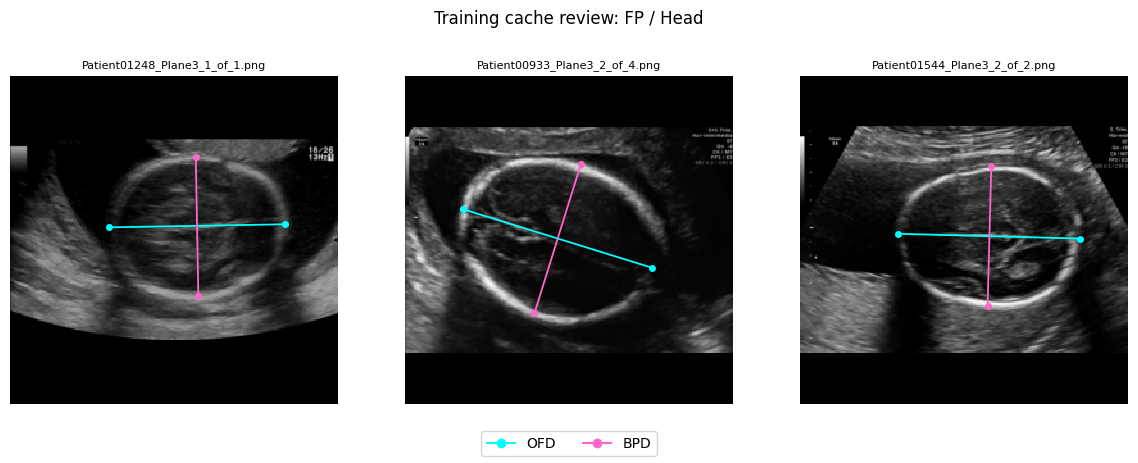

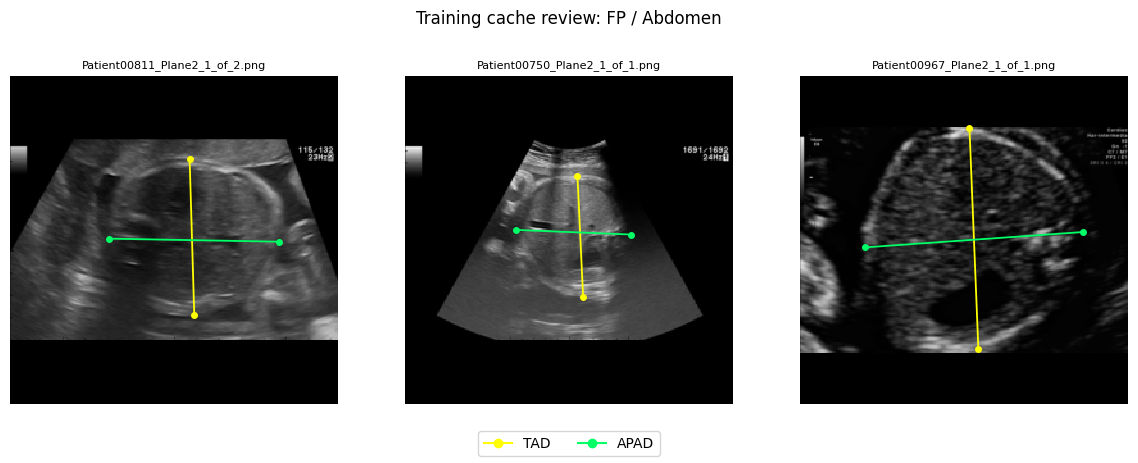

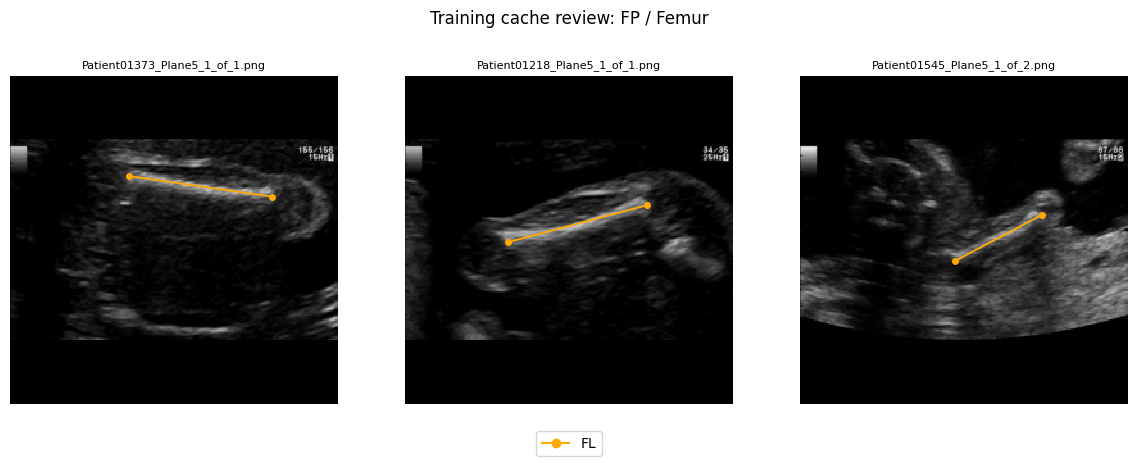

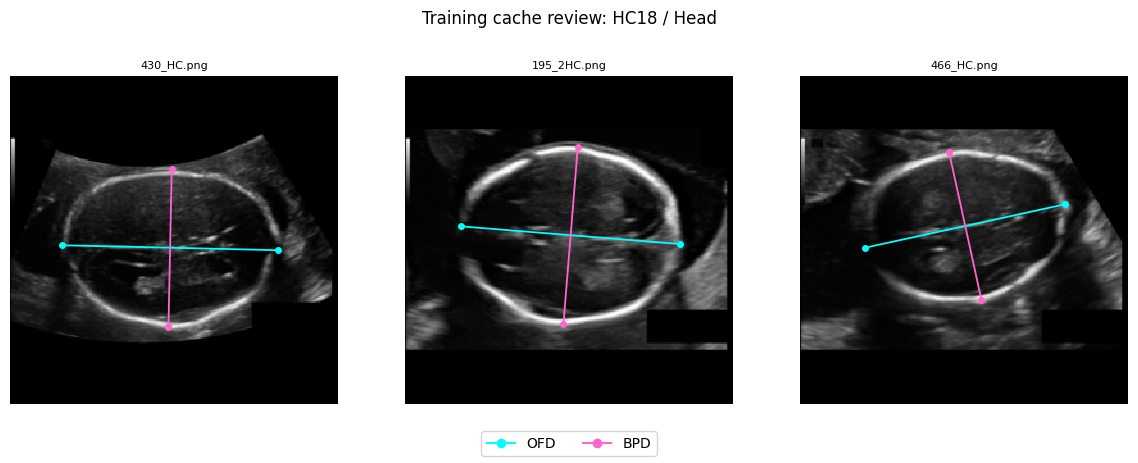


BLOCK 14 COMPLETED — VISUAL REVIEW PENDING
Displayed training images: 12
Figures: /content/drive/MyDrive/FetalGeo/paper_artifacts/figures/final
Selection data: /content/drive/MyDrive/FetalGeo/paper_artifacts/figures/data/training_overlay_selection_block14_20260912T162439080530Z.csv
Review record: /content/drive/MyDrive/FetalGeo/paper_artifacts/figures/data/overlay_review_block14_20260912T162439080530Z.json


In [ ]:
# FETALGEO_BLOCK14_V1
# Training-only visual review of cached images and landmarks.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython import get_ipython

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CACHE = (
    PROJECT / "data" / "cache"
    / "letterbox256_9093c1bcf56fd66fa9a6"
)

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for part in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(part)
    return digest.hexdigest()

summary = json.loads(
    (CACHE / "cache_summary.json").read_text(encoding="utf-8")
)
settings = json.loads(
    (CACHE / "cache_settings.json").read_text(encoding="utf-8")
)
index_path = CACHE / "cache_index.csv"

if file_hash(index_path) != summary["cache_index_sha256"]:
    raise ValueError("Cache index checksum mismatch.")

index = pd.read_csv(index_path, dtype=str, keep_default_na=False)
if index["record_id"].duplicated().any():
    raise ValueError("Repeated cache record IDs.")

measurements = settings["measurement_order"]
colors = {
    "ofd": "#00FFFF",
    "bpd": "#FF66CC",
    "tad": "#FFFF00",
    "apad": "#00FF66",
    "fl": "#FFAA00",
}
if set(measurements) != set(colors):
    raise ValueError(f"Unexpected measurement order: {measurements}")

# Select deterministically, without using image appearance or model results.
# Three images per source/anatomy, from distinct subject keys.
train = index.loc[index["role"].eq("train")].copy()
train["selection_rank"] = train["record_id"].map(
    lambda value: hashlib.sha256(
        f"block14_v1:{value}".encode("utf-8")
    ).hexdigest()
)

groups = [
    ("FP", "Head"),
    ("FP", "Abdomen"),
    ("FP", "Femur"),
    ("HC18", "Head"),
]
selected_parts = []

for source, anatomy in groups:
    candidates = train.loc[
        train["source"].eq(source) & train["anatomy"].eq(anatomy)
    ].sort_values("selection_rank")

    chosen = candidates.drop_duplicates("subject_key").head(3)
    if len(chosen) != 3:
        raise ValueError(f"Insufficient training subjects: {source}/{anatomy}")
    selected_parts.append(chosen)

selected = pd.concat(selected_parts, ignore_index=True)
if not selected["role"].eq("train").all():
    raise ValueError("Visual selection includes a non-training record.")

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"block14_{stamp}"
PAPER = PROJECT / "paper_artifacts"
directories = {
    "final": PAPER / "figures" / "final",
    "data": PAPER / "figures" / "data",
    "captions": PAPER / "figures" / "captions",
    "source": PAPER / "figures" / "source",
}
for path in directories.values():
    path.mkdir(parents=True, exist_ok=True)

selection_path = directories["data"] / f"training_overlay_selection_{tag}.csv"
selected.to_csv(selection_path, index=False)

# Read only chunks needed for the selected training records.
# A chunk can contain other roles; only selected records are displayed.
samples = {}
for chunk_name, requested in selected.groupby("chunk_file", sort=True):
    archive_path = CACHE / chunk_name
    receipt_path = archive_path.with_suffix(".json")
    receipt = json.loads(receipt_path.read_text(encoding="utf-8"))

    if file_hash(archive_path) != receipt["sha256"]:
        raise ValueError(f"Cache chunk checksum mismatch: {chunk_name}")

    with np.load(archive_path, allow_pickle=False) as archive:
        for row in requested.to_dict("records"):
            position = int(row["position"])
            if str(archive["record_ids"][position]) != row["record_id"]:
                raise ValueError("Cache index and chunk record IDs differ.")

            samples[row["record_id"]] = {
                name: archive[name][position].copy()
                for name in [
                    "images",
                    "original_points",
                    "cached_points",
                    "measurement_present",
                    "geometry_valid",
                    "training_eligible",
                    "training_weights",
                    "content_boxes",
                    "original_wh",
                    "original_to_cache",
                ]
            }

# Preserve the actual plotting cell when notebook history is available.
generator_path = str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK14_V1"
ipython = get_ipython()
if ipython is not None:
    history = ipython.history_manager.input_hist_raw
    current_cell = history[-1] if history else ""
    if current_cell.lstrip().startswith("# FETALGEO_BLOCK14_V1"):
        source_path = directories["source"] / f"{tag}.py"
        source_path.write_text(current_cell, encoding="utf-8")
        generator_path = str(source_path)

coordinate_rows = []
artifact_entries = []
figure_paths = []

for source, anatomy in groups:
    chosen = selected.loc[
        selected["source"].eq(source)
        & selected["anatomy"].eq(anatomy)
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.6))

    for ax, row in zip(axes, chosen.to_dict("records")):
        sample = samples[row["record_id"]]
        ax.imshow(sample["images"], interpolation="nearest")

        for slot, measurement in enumerate(measurements):
            if not bool(sample["measurement_present"][slot]):
                continue

            points = sample["cached_points"][slot]
            valid = bool(sample["geometry_valid"][slot])
            eligible = bool(sample["training_eligible"][slot])
            weight = float(sample["training_weights"][slot])

            ax.plot(
                points[:, 0],
                points[:, 1],
                color=colors[measurement],
                linestyle="-" if eligible else "--",
                marker="o" if valid else "x",
                markersize=4,
                linewidth=1.3,
            )

            coordinate_rows.append({
                "record_id": row["record_id"],
                "source": source,
                "anatomy": anatomy,
                "role": row["role"],
                "subject_key": row["subject_key"],
                "measurement": measurement,
                "original_x1": sample["original_points"][slot, 0, 0],
                "original_y1": sample["original_points"][slot, 0, 1],
                "original_x2": sample["original_points"][slot, 1, 0],
                "original_y2": sample["original_points"][slot, 1, 1],
                "cached_x1": points[0, 0],
                "cached_y1": points[0, 1],
                "cached_x2": points[1, 0],
                "cached_y2": points[1, 1],
                "geometry_valid": valid,
                "training_eligible": eligible,
                "training_weight": weight,
                "original_width": int(sample["original_wh"][0]),
                "original_height": int(sample["original_wh"][1]),
            })

        # Keep axes fixed to the cached image, even for off-image landmarks.
        height, width = sample["images"].shape[:2]
        ax.set_xlim(-0.5, width - 0.5)
        ax.set_ylim(height - 0.5, -0.5)
        ax.set_title(
            row["record_id"].split(":")[-1],
            fontsize=8,
            wrap=True,
        )
        ax.axis("off")

    shown_measurements = [
        name for name in measurements
        if any(
            bool(samples[record_id]["measurement_present"][
                measurements.index(name)
            ])
            for record_id in chosen["record_id"]
        )
    ]
    handles = [
        Line2D([0], [0], color=colors[name], marker="o", label=name.upper())
        for name in shown_measurements
    ]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles))
    fig.suptitle(f"Training cache review: {source} / {anatomy}", fontsize=12)
    fig.tight_layout(rect=[0, 0.09, 1, 0.94])

    base = f"fig_training_overlay_{source}_{anatomy}_{tag}"
    png_path = directories["final"] / f"{base}.png"
    pdf_path = directories["final"] / f"{base}.pdf"
    caption_path = directories["captions"] / f"{base}.txt"
    data_path = directories["data"] / f"{base}.csv"

    pd.DataFrame([
        item for item in coordinate_rows
        if item["source"] == source and item["anatomy"] == anatomy
    ]).to_csv(data_path, index=False)

    caption_path.write_text(
        f"Candidate preprocessing quality-control figure: {source}, {anatomy}.\n"
        "Three training images from distinct subject keys, selected by a "
        "fixed hash ranking independently of image appearance.\n"
        "Full images resized with bilinear interpolation and centred padding "
        "to 256 x 256. Lines connect transformed supplied landmarks.\n"
        "Solid lines: eligible for training; dashed lines: masked from training.\n"
        "Circle markers: bounds-valid geometry; crosses: flagged geometry.\n"
        "Off-image endpoints may be clipped by the displayed image boundary.\n"
        "This small sample does not establish dataset-wide annotation accuracy.\n"
        "Visual review pending; not a model prediction or performance result.\n",
        encoding="utf-8",
    )

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    figure_paths.extend([str(png_path), str(pdf_path)])
    artifact_entries.append({
        "artifact_id": base,
        "type": "figure",
        "title": f"Training cache overlays: {source} {anatomy}",
        "status": "candidate",
        "source_data_path": str(data_path),
        "generator_path": generator_path,
        "output_paths": f"{png_path}|{pdf_path}",
        "caption_path": str(caption_path),
        "manifest_directory": str(
            PROJECT / "data/manifests/patient_safe_v2_20260912T151813194803Z"
        ),
    })

index_path = PAPER / "ARTIFACT_INDEX.csv"
entries = pd.DataFrame(artifact_entries)
if index_path.exists() and index_path.stat().st_size:
    old = pd.read_csv(index_path, dtype=str, keep_default_na=False)
    entries = pd.concat([old, entries], ignore_index=True)
entries.fillna("").to_csv(index_path, index=False)

review_summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "cache_directory": str(CACHE),
    "displayed_images": len(selected),
    "displayed_roles": sorted(selected["role"].unique().tolist()),
    "figure_groups": len(groups),
    "selection_csv": str(selection_path),
    "figure_paths": figure_paths,
    "visual_alignment_status": "AWAITING_VISUAL_REVIEW",
    "split_and_mask_policy": "PROVISIONAL",
}
summary_path = directories["data"] / f"overlay_review_{tag}.json"
summary_path.write_text(
    json.dumps(review_summary, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 14 training-only overlays — {stamp}\n\n"
        "- Generated four candidate figures showing 12 training images.\n"
        "- Selected distinct subject keys within each source/anatomy group.\n"
        "- Saved PNG/PDF figures, captions, selection data, and coordinates.\n"
        "- Visual alignment awaits review; no performance claim made.\n"
        f"- Review record: `{summary_path}`\n"
    )

print("\nBLOCK 14 COMPLETED — VISUAL REVIEW PENDING")
print(f"Displayed training images: {len(selected)}")
print(f"Figures: {directories['final']}")
print(f"Selection data: {selection_path}")
print(f"Review record: {summary_path}")

In [ ]:
# FETALGEO_BLOCK15_V1
# CPU training-loader smoke test. No model training.

from pathlib import Path
from datetime import datetime, timezone
from collections import OrderedDict
import hashlib
import json

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CACHE = (
    PROJECT / "data/cache"
    / "letterbox256_9093c1bcf56fd66fa9a6"
)

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

summary = json.loads(
    (CACHE / "cache_summary.json").read_text(encoding="utf-8")
)
settings = json.loads(
    (CACHE / "cache_settings.json").read_text(encoding="utf-8")
)
index_path = CACHE / "cache_index.csv"
if file_hash(index_path) != summary["cache_index_sha256"]:
    raise ValueError("Cache index checksum mismatch.")

index = pd.read_csv(index_path, dtype=str, keep_default_na=False)
if index["record_id"].duplicated().any():
    raise ValueError("Repeated cache record IDs.")

# Verify the provisional eligibility file before using it to select images.
mask_dir = Path(summary["mask_directory"])
policy = json.loads(
    (mask_dir / "mask_policy.json").read_text(encoding="utf-8")
)
eligibility_path = mask_dir / "training_image_eligibility.csv"
if file_hash(eligibility_path) != policy["output_csv_sha256"][
    "training_image_eligibility.csv"
]:
    raise ValueError("Training eligibility checksum mismatch.")

eligibility = pd.read_csv(
    eligibility_path, dtype=str, keep_default_na=False
)
if eligibility["record_id"].duplicated().any():
    raise ValueError("Repeated training eligibility IDs.")

train_index = index.loc[index["role"].eq("train")].copy()
if set(eligibility["record_id"]) != set(train_index["record_id"]):
    raise ValueError("Eligibility IDs differ from the training split.")

eligible_ids = set(
    eligibility.loc[
        pd.to_numeric(eligibility["eligible_measurements"]).gt(0),
        "record_id",
    ]
)
train_index = train_index.loc[
    train_index["record_id"].isin(eligible_ids)
].reset_index(drop=True)

if len(train_index) != policy["training_images_with_eligible_measurement"]:
    raise ValueError("Eligible training-image count differs from policy.")
if train_index["source"].eq("UCL").any():
    raise ValueError("UCL entered the training loader.")

# Check active split subject-key isolation.
active_roles = [
    "train", "internal_validation", "internal_test", "external_test"
]
for i, left in enumerate(active_roles):
    left_subjects = set(index.loc[index["role"].eq(left), "subject_key"])
    for right in active_roles[i + 1:]:
        right_subjects = set(
            index.loc[index["role"].eq(right), "subject_key"]
        )
        if left_subjects & right_subjects:
            raise ValueError(f"Subject-key overlap: {left} / {right}")

class FetalGeoTrainingDataset(Dataset):
    """CPU smoke-test loader; small LRU cache of verified chunks."""

    def __init__(self, cache_dir, selected_index, max_chunks=2):
        self.cache_dir = Path(cache_dir)
        self.index = selected_index.reset_index(drop=True).copy()
        if not self.index["role"].eq("train").all():
            raise ValueError("This loader accepts training records only.")

        self.max_chunks = max_chunks
        self.chunks = OrderedDict()
        self.verified = set()
        self.mean = torch.tensor(
            [0.485, 0.456, 0.406], dtype=torch.float32
        ).view(3, 1, 1)
        self.std = torch.tensor(
            [0.229, 0.224, 0.225], dtype=torch.float32
        ).view(3, 1, 1)

    def __len__(self):
        return len(self.index)

    def _chunk(self, filename):
        if filename in self.chunks:
            self.chunks.move_to_end(filename)
            return self.chunks[filename]

        path = self.cache_dir / filename
        if filename not in self.verified:
            receipt = json.loads(
                path.with_suffix(".json").read_text(encoding="utf-8")
            )
            if file_hash(path) != receipt["sha256"]:
                raise ValueError(f"Chunk checksum mismatch: {filename}")
            self.verified.add(filename)

        with np.load(path, allow_pickle=False) as archive:
            chunk = {
                name: archive[name].copy()
                for name in [
                    "record_ids", "images", "cached_points",
                    "measurement_present", "training_eligible",
                    "training_weights",
                ]
            }

        self.chunks[filename] = chunk
        while len(self.chunks) > self.max_chunks:
            self.chunks.popitem(last=False)
        return chunk

    def __getitem__(self, position):
        row = self.index.iloc[position]
        chunk = self._chunk(row["chunk_file"])
        offset = int(row["position"])

        if str(chunk["record_ids"][offset]) != row["record_id"]:
            raise ValueError("Chunk record does not match index.")

        image = torch.from_numpy(
            chunk["images"][offset].copy()
        ).permute(2, 0, 1).float().div(255.0)
        image = (image - self.mean) / self.std

        points = chunk["cached_points"][offset].copy()
        present = chunk["measurement_present"][offset].astype(bool)
        mask = chunk["training_eligible"][offset].astype(bool)
        weight = chunk["training_weights"][offset].copy()

        if np.any(mask & ~present):
            raise ValueError("Absent anatomy marked eligible.")
        if not np.isfinite(points[mask]).all():
            raise ValueError("Eligible landmarks are nonfinite.")
        if not np.isfinite(weight).all() or np.any(weight < 0):
            raise ValueError("Invalid training weights.")
        if np.any(weight[~mask] != 0) or np.any(weight[mask] <= 0):
            raise ValueError("Weights and eligibility masks disagree.")

        # Fill all masked targets before tensor arithmetic.
        # Multiplying NaN targets by zero would still produce NaN.
        points[~mask] = 0.0

        return {
            "record_id": row["record_id"],
            "source": row["source"],
            "image": image,
            "points": torch.from_numpy(points).float(),
            "mask": torch.from_numpy(mask),
            "weight": torch.from_numpy(weight).float(),
        }

def masked_endpoint_loss(prediction, target, mask, weight):
    """Smoke-test loss: mean endpoint distance, allowing endpoint reversal."""
    selected_weights = weight[mask]
    if selected_weights.numel() == 0:
        raise ValueError("Batch has no eligible supervision.")

    prediction = prediction[mask]
    target = target[mask]
    direct = torch.linalg.vector_norm(
        prediction - target, dim=-1
    ).mean(dim=-1)
    reversed_order = torch.linalg.vector_norm(
        prediction - target.flip(-2), dim=-1
    ).mean(dim=-1)
    distances = torch.minimum(direct, reversed_order)
    return (distances * selected_weights).sum() / selected_weights.sum()

# Sequential traversal avoids repeated random decompression on Drive.
dataset = FetalGeoTrainingDataset(CACHE, train_index)
loader = DataLoader(
    dataset, batch_size=16, shuffle=False, num_workers=0, drop_last=False
)

print(f"Eligible training images: {len(dataset):,}")
print("Checking every training batch on CPU...", flush=True)

seen = []
total_labels = 0
total_weight = 0.0
max_identity_loss = 0.0

for batch_number, batch in enumerate(loader, start=1):
    images = batch["image"]
    points = batch["points"]
    mask = batch["mask"]
    weights = batch["weight"]

    if images.shape[1:] != (3, 256, 256):
        raise ValueError(f"Unexpected image shape: {images.shape}")
    if points.shape[1:] != (5, 2, 2):
        raise ValueError(f"Unexpected landmark shape: {points.shape}")
    if not torch.isfinite(images).all() or not torch.isfinite(points).all():
        raise ValueError("Nonfinite batch tensors.")
    if not mask.any(dim=1).all():
        raise ValueError("An image has no eligible training measurement.")
    if "UCL" in batch["source"]:
        raise ValueError("UCL found in training batch.")

    identity_loss = masked_endpoint_loss(points, points, mask, weights)
    reverse_loss = masked_endpoint_loss(
        points.flip(-2), points, mask, weights
    )
    if identity_loss.item() != 0 or reverse_loss.item() != 0:
        raise ValueError("Endpoint-loss identity/reversal check failed.")

    # Backpropagation through synthetic predictions, not a model.
    if batch_number == 1:
        prediction = (points + 0.25).detach().requires_grad_(True)
        loss = masked_endpoint_loss(prediction, points, mask, weights)
        loss.backward()
        if not torch.isfinite(prediction.grad).all():
            raise ValueError("Nonfinite synthetic gradients.")
        if torch.count_nonzero(prediction.grad[~mask]).item() != 0:
            raise ValueError("Masked targets received gradients.")
        if prediction.grad[mask].abs().sum().item() == 0:
            raise ValueError("Eligible targets received no gradients.")

    seen.extend(batch["record_id"])
    total_labels += int(mask.sum())
    total_weight += float(weights.double().sum())
    max_identity_loss = max(max_identity_loss, float(identity_loss))

    if batch_number % 20 == 0 or batch_number == len(loader):
        print(
            f"Batches {batch_number}/{len(loader)}; images {len(seen):,}",
            flush=True,
        )

if len(seen) != len(set(seen)) or set(seen) != eligible_ids:
    raise ValueError("Loader omitted or repeated training records.")
if total_labels != policy["training_measurements_eligible"]:
    raise ValueError("Loaded supervision count differs from policy.")
if not np.isclose(
    total_weight, policy["training_weight_sum"], rtol=0, atol=1e-4
):
    raise ValueError("Loaded training weights differ from policy.")

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "data" / "audit" / f"block15_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "CPU_LOADER_SMOKE_TEST_PASSED",
    "cache_directory": str(CACHE),
    "training_images_loaded": len(seen),
    "eligible_measurements_loaded": total_labels,
    "training_weight_sum": total_weight,
    "batches": len(loader),
    "image_shape": ["batch", 3, 256, 256],
    "landmark_shape": ["batch", 5, 2, 2],
    "measurement_order": settings["measurement_order"],
    "identity_and_endpoint_reversal_loss": max_identity_loss,
    "synthetic_gradient_check": "PASSED",
    "model_training_performed": False,
    "policy_status": "PROVISIONAL",
    "limitations": [
        "This verifies data loading and a diagnostic loss, not the final model.",
        "Training-weight normalization and multi-task loss balancing are not finalized.",
        "GPU training should use a local copy and an efficient shuffled loader.",
        "Subject identity and evaluation policy issues remain unresolved.",
    ],
}
(OUT / "loader_smoke_test.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 15 CPU loader test — {stamp}\n\n"
        f"- Status: {report['status']}\n"
        f"- Training images loaded exactly once: {len(seen)}\n"
        f"- Eligible measurement labels: {total_labels}\n"
        f"- Training weight sum: {total_weight:.6f}\n"
        "- Identity, endpoint-reversal, and synthetic gradient checks passed.\n"
        "- No model trained; this is software validation, not model performance.\n"
        f"- Test report: `{OUT / 'loader_smoke_test.json'}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print(f"\nSaved report: {OUT}")
print("\nBLOCK 15 COMPLETED")

Eligible training images: 1,560
Checking every training batch on CPU...
Batches 20/98; images 320
Batches 40/98; images 640
Batches 60/98; images 960
Batches 80/98; images 1,280
Batches 98/98; images 1,560

SUMMARY
{
  "created_utc": "2026-09-12T16:28:37.838827+00:00",
  "status": "CPU_LOADER_SMOKE_TEST_PASSED",
  "cache_directory": "/content/drive/MyDrive/FetalGeo/data/cache/letterbox256_9093c1bcf56fd66fa9a6",
  "training_images_loaded": 1560,
  "eligible_measurements_loaded": 2874,
  "training_weight_sum": 2864.0,
  "batches": 98,
  "image_shape": [
    "batch",
    3,
    256,
    256
  ],
  "landmark_shape": [
    "batch",
    5,
    2,
    2
  ],
  "measurement_order": [
    "ofd",
    "bpd",
    "tad",
    "apad",
    "fl"
  ],
  "identity_and_endpoint_reversal_loss": 0.0,
  "synthetic_gradient_check": "PASSED",
  "model_training_performed": false,
  "policy_status": "PROVISIONAL",
  "limitations": [
    "This verifies data loading and a diagnostic loss, not the final model.",
  

In [ ]:
# FETALGEO_BLOCK16_V1
# Create and verify a persistent training-data bundle. CPU only.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import zipfile

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CACHE = PROJECT / "data/cache/letterbox256_9093c1bcf56fd66fa9a6"
SMOKE = (
    PROJECT / "data/audit/block15_20260912T162837829192Z"
    / "loader_smoke_test.json"
)

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for part in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(part)
    return digest.hexdigest()

cache_summary = json.loads(
    (CACHE / "cache_summary.json").read_text(encoding="utf-8")
)
settings = json.loads(
    (CACHE / "cache_settings.json").read_text(encoding="utf-8")
)
smoke = json.loads(SMOKE.read_text(encoding="utf-8"))

if smoke["status"] != "CPU_LOADER_SMOKE_TEST_PASSED":
    raise ValueError("CPU loader test did not pass.")
if Path(smoke["cache_directory"]) != CACHE:
    raise ValueError("Loader test refers to a different cache.")

MASK_DIR = Path(cache_summary["mask_directory"])
policy = json.loads(
    (MASK_DIR / "mask_policy.json").read_text(encoding="utf-8")
)
MANIFEST = Path(policy["parent_manifest"])

index_path = CACHE / "cache_index.csv"
if file_hash(index_path) != cache_summary["cache_index_sha256"]:
    raise ValueError("Cache index checksum mismatch.")

index = pd.read_csv(index_path, dtype=str, keep_default_na=False)
if len(index) != cache_summary["images"]:
    raise ValueError("Cache image count differs.")
if index["record_id"].duplicated().any():
    raise ValueError("Repeated cache index record IDs.")

# Bundle paths are relative, so the bundle can move to /content.
files = {}

def register(path, relative_name, expected_hash=None):
    if not path.is_file():
        raise FileNotFoundError(path)
    digest = file_hash(path)
    if expected_hash is not None and digest != expected_hash:
        raise ValueError(f"Checksum mismatch: {path}")
    if relative_name in files:
        raise ValueError(f"Repeated bundle path: {relative_name}")
    files[relative_name] = {
        "path": path,
        "sha256": digest,
        "bytes": path.stat().st_size,
    }

for name in [
    "cache_settings.json", "cache_summary.json",
    "cache_index.csv", "cache_coverage.csv",
]:
    register(CACHE / name, f"cache/{name}")

chunk_names = sorted(index["chunk_file"].unique())
print(f"Verifying {len(chunk_names)} cache chunks...", flush=True)

for number, name in enumerate(chunk_names, start=1):
    if Path(name).name != name:
        raise ValueError(f"Unsafe chunk filename: {name}")

    chunk_path = CACHE / name
    receipt_path = chunk_path.with_suffix(".json")
    receipt = json.loads(receipt_path.read_text(encoding="utf-8"))

    rows = index.loc[index["chunk_file"].eq(name)].copy()
    rows["position_numeric"] = pd.to_numeric(
        rows["position"], errors="raise"
    )
    rows = rows.sort_values("position_numeric")

    if rows["position_numeric"].tolist() != list(range(len(rows))):
        raise ValueError(f"Invalid chunk positions: {name}")
    if rows["record_id"].tolist() != receipt["record_ids"]:
        raise ValueError(f"Receipt and index IDs differ: {name}")

    register(chunk_path, f"cache/{name}", receipt["sha256"])
    register(receipt_path, f"cache/{receipt_path.name}")

    if number % 6 == 0 or number == len(chunk_names):
        print(f"Verified {number}/{len(chunk_names)}", flush=True)

for name, expected in settings["manifest_hashes"].items():
    register(MANIFEST / name, f"manifests/{name}", expected)
register(
    MANIFEST / "split_configuration.json",
    "manifests/split_configuration.json",
)

for name, expected in policy["output_csv_sha256"].items():
    register(MASK_DIR / name, f"masks/{name}", expected)
register(MASK_DIR / "mask_policy.json", "masks/mask_policy.json")
register(SMOKE, "checks/loader_smoke_test.json")

inventory = {
    name: {"sha256": item["sha256"], "bytes": item["bytes"]}
    for name, item in sorted(files.items())
}
fingerprint = hashlib.sha256(
    json.dumps(inventory, sort_keys=True).encode("utf-8")
).hexdigest()[:20]

BUNDLE_DIR = PROJECT / "training_bundles"
BUNDLE_DIR.mkdir(parents=True, exist_ok=True)
bundle_path = BUNDLE_DIR / f"fetalgeo_data_{fingerprint}.zip"
receipt_path = BUNDLE_DIR / f"fetalgeo_data_{fingerprint}.json"

bundle_info = {
    "bundle_version": 1,
    "fingerprint": fingerprint,
    "policy_status": "PROVISIONAL",
    "cache_index": "cache/cache_index.csv",
    "measurement_masks": "masks/measurement_masks.csv",
    "measurement_order": settings["measurement_order"],
    "image_layout": "NHWC_RGB_uint8",
    "image_size": settings["size"],
    "physical_unit_loss_enabled": False,
    "role_selection_required": True,
    "note": (
        "Select records by role in cache_index.csv. "
        "A chunk can contain multiple roles. Original metadata paths "
        "are provenance only; use bundle-relative paths after extraction."
    ),
    "files": inventory,
}

reuse = False
if bundle_path.exists() and receipt_path.exists():
    previous = json.loads(receipt_path.read_text(encoding="utf-8"))
    reuse = (
        previous.get("fingerprint") == fingerprint
        and previous.get("bundle_sha256") == file_hash(bundle_path)
    )
    if not reuse:
        raise ValueError(
            "An existing bundle failed verification. Share this error "
            "before using or replacing it."
        )

if not reuse:
    partial_path = bundle_path.with_suffix(".zip.partial")
    print("Writing bundle; NPZ chunks are already compressed.", flush=True)

    with zipfile.ZipFile(
        partial_path, "w", compression=zipfile.ZIP_STORED, allowZip64=True
    ) as archive:
        for name, item in sorted(files.items()):
            archive.write(item["path"], arcname=name)
        archive.writestr(
            "BUNDLE_INFO.json", json.dumps(bundle_info, indent=2)
        )

    os.replace(partial_path, bundle_path)
else:
    print("Reusing verified existing bundle.", flush=True)

print("Verifying files inside the bundle...", flush=True)
with zipfile.ZipFile(bundle_path, "r") as archive:
    names = archive.namelist()
    expected_names = set(inventory) | {"BUNDLE_INFO.json"}
    if len(names) != len(set(names)) or set(names) != expected_names:
        raise ValueError("Unexpected or repeated files in bundle.")

    stored_info = json.loads(archive.read("BUNDLE_INFO.json"))
    if stored_info != bundle_info:
        raise ValueError("Bundle metadata mismatch.")

    for number, (name, item) in enumerate(sorted(inventory.items()), start=1):
        digest = hashlib.sha256()
        with archive.open(name) as handle:
            for part in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(part)
        if digest.hexdigest() != item["sha256"]:
            raise ValueError(f"Bundled file checksum mismatch: {name}")
        if number % 20 == 0:
            print(f"Verified bundled files: {number}/{len(inventory)}", flush=True)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "DATA_BUNDLE_VERIFIED",
    "fingerprint": fingerprint,
    "bundle_path": str(bundle_path),
    "bundle_sha256": file_hash(bundle_path),
    "bundle_bytes": bundle_path.stat().st_size,
    "verified_payload_files": len(inventory),
    "cached_images": len(index),
    "eligible_training_images": smoke["training_images_loaded"],
    "model_training_performed": False,
    "policy_status": "PROVISIONAL",
}
receipt_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        "\n\n## Block 16 portable data bundle\n\n"
        f"- Verified UTC: {report['created_utc']}\n"
        f"- Bundle: `{bundle_path}`\n"
        f"- SHA-256: `{report['bundle_sha256']}`\n"
        "- Cache chunks, manifests, masks, and loader-test report packaged.\n"
        "- Every bundled payload file verified against its SHA-256 hash.\n"
        "- Policies remain provisional; model code and training are not included.\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print(f"\nBundle receipt: {receipt_path}")
print("\nBLOCK 16 COMPLETED")

Verifying 36 cache chunks...
Verified 6/36
Verified 12/36
Verified 18/36
Verified 24/36
Verified 30/36
Verified 36/36
Writing bundle; NPZ chunks are already compressed.
Verifying files inside the bundle...
Verified bundled files: 20/84
Verified bundled files: 40/84
Verified bundled files: 60/84
Verified bundled files: 80/84

SUMMARY
{
  "created_utc": "2026-09-12T16:31:18.401033+00:00",
  "status": "DATA_BUNDLE_VERIFIED",
  "fingerprint": "c02bddc74f0c66c8626f",
  "bundle_path": "/content/drive/MyDrive/FetalGeo/training_bundles/fetalgeo_data_c02bddc74f0c66c8626f.zip",
  "bundle_sha256": "c50c8791f779a65e45c3a4b1e68f54de8f06644bea8c5393df5bb840f73984e8",
  "bundle_bytes": 184640442,
  "verified_payload_files": 84,
  "cached_images": 4513,
  "eligible_training_images": 1560,
  "model_training_performed": false,
  "policy_status": "PROVISIONAL"
}

Bundle receipt: /content/drive/MyDrive/FetalGeo/training_bundles/fetalgeo_data_c02bddc74f0c66c8626f.json

BLOCK 16 COMPLETED


In [ ]:
# FETALGEO_BLOCK17_V1
# Save reusable model implementation and run CPU architecture checks.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import subprocess
import sys

# Install only if timm is absent. Existing import errors are surfaced.
if importlib.util.find_spec("timm") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "timm"],
        check=True,
    )

import torch
import timm

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "code" / f"model_v1_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

MODEL_SOURCE = r'''
import math
import torch
from torch import nn
from torch.nn import functional as F
import timm

MEASUREMENTS = ("ofd", "bpd", "tad", "apad", "fl")

class FetalGeo(nn.Module):
    """
    Matched HRNet-W18 landmark model.

    Input: normalized RGB, B x 3 x 256 x 256.
    Outputs use cached-image pixel coordinates.
    Both variants use the same backbone, fusion and heatmap heads.
    """
    def __init__(self, geometry=False, pretrained=False):
        super().__init__()
        self.has_geometry = bool(geometry)
        self.backbone = timm.create_model(
            "hrnet_w18",
            pretrained=pretrained,
            features_only=True,
        )
        channels = self.backbone.feature_info.channels()
        reductions = self.backbone.feature_info.reduction()

        # Fuse feature levels at stride 4 or coarser onto a 64 x 64 grid.
        self.selected_levels = tuple(
            i for i, reduction in enumerate(reductions)
            if reduction >= 4
        )
        if not self.selected_levels:
            raise RuntimeError("No suitable HRNet feature levels.")

        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels[i], 32, kernel_size=1, bias=False),
                nn.GroupNorm(8, 32),
                nn.ReLU(inplace=True),
            )
            for i in self.selected_levels
        ])
        self.fusion = nn.Sequential(
            nn.Conv2d(
                32 * len(self.selected_levels), 64,
                kernel_size=3, padding=1, bias=False,
            ),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
        )
        self.heatmap_head = nn.Conv2d(64, 10, kernel_size=1)

        if self.has_geometry:
            # A 4 x 4 pooled grid preserves coarse spatial information.
            # Each measurement predicts centre x/y, angle, and length.
            self.geometry_head = nn.Sequential(
                nn.AdaptiveAvgPool2d((4, 4)),
                nn.Flatten(),
                nn.Linear(64 * 4 * 4, 128),
                nn.ReLU(inplace=True),
                nn.Linear(128, 5 * 4),
            )

    def forward(self, images):
        if images.shape[-2:] != (256, 256):
            raise ValueError("This model expects 256 x 256 cached images.")

        features = self.backbone(images)
        projected = []
        for projection, level in zip(
            self.projections, self.selected_levels
        ):
            feature = projection(features[level])
            projected.append(F.interpolate(
                feature, size=(64, 64),
                mode="bilinear", align_corners=False,
            ))
        fused = self.fusion(torch.cat(projected, dim=1))
        logits = self.heatmap_head(fused)
        batch, _, height, width = logits.shape

        # Float32 probabilities and coordinate reductions support later AMP use.
        probabilities = logits.float().flatten(2).softmax(dim=-1)

        # Heatmap cell centres mapped to cached-image pixel centres.
        xs = (
            (torch.arange(width, device=logits.device).float() + 0.5)
            * (256.0 / width) - 0.5
        )
        ys = (
            (torch.arange(height, device=logits.device).float() + 0.5)
            * (256.0 / height) - 0.5
        )
        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        x = (probabilities * xx.reshape(1, 1, -1)).sum(-1)
        y = (probabilities * yy.reshape(1, 1, -1)).sum(-1)
        local_points = torch.stack([x, y], dim=-1).reshape(
            batch, 5, 2, 2
        )

        output = {
            "heatmap_logits": logits.reshape(batch, 5, 2, height, width),
            "local_points": local_points,
        }

        if self.has_geometry:
            raw = self.geometry_head(fused).float().reshape(batch, 5, 4)
            centre = raw[..., :2].sigmoid() * 255.0
            angle = raw[..., 2]
            axis = torch.stack([angle.cos(), angle.sin()], dim=-1)
            length = F.softplus(raw[..., 3]) * 255.0
            half_vector = 0.5 * length.unsqueeze(-1) * axis
            endpoints = torch.stack(
                [centre - half_vector, centre + half_vector], dim=-2
            )
            output.update({
                "geometry_centre": centre,
                "geometry_axis": axis,
                "geometry_length": length,
                "geometry_points": endpoints,
            })

        return output
'''

# Syntax validation occurs before the module is saved or imported.
compile(MODEL_SOURCE, "fetalgeo_model.py", "exec")
model_path = OUT / "fetalgeo_model.py"
model_path.write_text(MODEL_SOURCE, encoding="utf-8")

spec = importlib.util.spec_from_file_location(
    f"fetalgeo_model_{stamp}", model_path
)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

# Limit CPU thread contention during this small check.
previous_threads = torch.get_num_threads()
torch.set_num_threads(min(4, previous_threads))

try:
    torch.manual_seed(20260912)
    baseline = module.FetalGeo(geometry=False, pretrained=False).cpu()

    torch.manual_seed(20260912)
    geometry_model = module.FetalGeo(geometry=True, pretrained=False).cpu()

    # Explicitly copy the common parameters; do not rely on seed coincidence.
    shared_state = baseline.state_dict()
    load_result = geometry_model.load_state_dict(shared_state, strict=False)

    if load_result.unexpected_keys:
        raise ValueError(f"Unexpected keys: {load_result.unexpected_keys}")
    if any(
        not key.startswith("geometry_head.")
        for key in load_result.missing_keys
    ):
        raise ValueError(f"Unexpected missing keys: {load_result.missing_keys}")

    for key, value in shared_state.items():
        if not torch.equal(value, geometry_model.state_dict()[key]):
            raise ValueError(f"Common parameters differ: {key}")

    baseline.eval()
    geometry_model.eval()
    dummy = torch.randn(1, 3, 256, 256, device="cpu")

    print("Testing B2 forward pass on CPU...", flush=True)
    with torch.no_grad():
        baseline_output = baseline(dummy)

    print("Testing geometry-model forward pass on CPU...", flush=True)
    with torch.no_grad():
        geometry_output = geometry_model(dummy)

    expected_shapes = {
        "heatmap_logits": (1, 5, 2, 64, 64),
        "local_points": (1, 5, 2, 2),
        "geometry_centre": (1, 5, 2),
        "geometry_axis": (1, 5, 2),
        "geometry_length": (1, 5),
        "geometry_points": (1, 5, 2, 2),
    }

    for name, expected in expected_shapes.items():
        tensor = geometry_output[name]
        if tuple(tensor.shape) != expected:
            raise ValueError(f"{name}: unexpected shape {tensor.shape}")
        if not torch.isfinite(tensor).all():
            raise ValueError(f"{name}: nonfinite output")

    if not torch.allclose(
        baseline_output["local_points"],
        geometry_output["local_points"],
        atol=1e-6, rtol=1e-6,
    ):
        raise ValueError("Matched local predictions differ before training.")

    axes = geometry_output["geometry_axis"]
    if not torch.allclose(
        axes.norm(dim=-1), torch.ones(1, 5), atol=1e-6
    ):
        raise ValueError("Geometry axes are not unit vectors.")
    if not (geometry_output["geometry_length"] > 0).all():
        raise ValueError("Geometry lengths are not positive.")

    endpoints = geometry_output["geometry_points"]
    if not torch.allclose(
        endpoints.mean(dim=-2),
        geometry_output["geometry_centre"],
        atol=1e-4,
    ):
        raise ValueError("Geometry reconstruction centre mismatch.")

    baseline_parameters = sum(p.numel() for p in baseline.parameters())
    geometry_parameters = sum(p.numel() for p in geometry_model.parameters())

finally:
    torch.set_num_threads(previous_threads)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "MODEL_FORWARD_CHECKS_PASSED",
    "model_source": str(model_path),
    "model_source_sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "backbone": "hrnet_w18",
    "feature_channels": baseline.backbone.feature_info.channels(),
    "feature_reductions": baseline.backbone.feature_info.reduction(),
    "selected_feature_levels": list(baseline.selected_levels),
    "measurement_order": list(module.MEASUREMENTS),
    "baseline_parameters": baseline_parameters,
    "geometry_model_parameters": geometry_parameters,
    "additional_geometry_parameters": (
        geometry_parameters - baseline_parameters
    ),
    "shared_initialization_check": "PASSED",
    "matching_local_output_check": "PASSED",
    "geometry_constraints_check": "PASSED",
    "pretrained_weights_loaded": False,
    "model_training_performed": False,
    "limitations": [
        "Forward checks only; final losses and model backward pass remain to test.",
        "Random initial weights are for software checks, not final experiments.",
        "A1 and A2 share architecture; their loss definitions are still pending.",
        "Geometry endpoints are not clipped to image bounds.",
        "This matched baseline is not a released-checkpoint reproduction.",
    ],
}
(OUT / "model_check.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)
(OUT / "timm_requirement.txt").write_text(
    f"timm=={timm.__version__}\n", encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 17 model implementation — {stamp}\n\n"
        "- Matched HRNet-W18 baseline and geometry-head variants implemented.\n"
        "- Common parameters and initial local predictions checked for equality.\n"
        "- Output shapes, finite values, unit axes, and positive lengths checked.\n"
        "- Random initialization used; no model trained or accuracy measured.\n"
        f"- Baseline parameters: {baseline_parameters:,}\n"
        f"- Geometry-model parameters: {geometry_parameters:,}\n"
        f"- Source: `{model_path}`\n"
        f"- Verification report: `{OUT / 'model_check.json'}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print("\nBLOCK 17 COMPLETED")

Testing B2 forward pass on CPU...
Testing geometry-model forward pass on CPU...

SUMMARY
{
  "created_utc": "2026-09-12T16:34:58.943011+00:00",
  "status": "MODEL_FORWARD_CHECKS_PASSED",
  "model_source": "/content/drive/MyDrive/FetalGeo/code/model_v1_20260912T163435231628Z/fetalgeo_model.py",
  "model_source_sha256": "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
  "torch_version": "2.11.0+cpu",
  "timm_version": "1.0.29",
  "backbone": "hrnet_w18",
  "feature_channels": [
    64,
    128,
    256,
    512,
    1024
  ],
  "feature_reductions": [
    2,
    4,
    8,
    16,
    32
  ],
  "selected_feature_levels": [
    1,
    2,
    3,
    4
  ],
  "measurement_order": [
    "ofd",
    "bpd",
    "tad",
    "apad",
    "fl"
  ],
  "baseline_parameters": 11084382,
  "geometry_model_parameters": 11218162,
  "additional_geometry_parameters": 133780,
  "shared_initialization_check": "PASSED",
  "matching_local_output_check": "PASSED",
  "geometry_constraints_check":

In [ ]:
# FETALGEO_BLOCK18_V1
# Save losses; test masking, reversal invariance, and model backpropagation.
# CPU only. No optimizer step or model training.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json

import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MODEL_DIR = PROJECT / "code/model_v1_20260912T163435231628Z"
MASK_DIR = (
    PROJECT / "data/manifests"
    / "provisional_masks_20260912T161641409242Z"
)

import pandas as pd

model_report = json.loads(
    (MODEL_DIR / "model_check.json").read_text(encoding="utf-8")
)
model_path = MODEL_DIR / "fetalgeo_model.py"
if hashlib.sha256(model_path.read_bytes()).hexdigest() != model_report[
    "model_source_sha256"
]:
    raise ValueError("Model source checksum mismatch.")

policy = json.loads(
    (MASK_DIR / "mask_policy.json").read_text(encoding="utf-8")
)
mask_path = MASK_DIR / "measurement_masks.csv"
if hashlib.sha256(mask_path.read_bytes()).hexdigest() != policy[
    "output_csv_sha256"
]["measurement_masks.csv"]:
    raise ValueError("Mask checksum mismatch.")

masks = pd.read_csv(mask_path, keep_default_na=False)
order = ["ofd", "bpd", "tad", "apad", "fl"]
train_masks = masks.loc[masks["role"].eq("train")]
totals = (
    train_masks.groupby("measurement")["training_weight_candidate"]
    .sum().reindex(order)
)
if totals.isna().any() or (totals <= 0).any():
    raise ValueError("Every measurement requires positive training weight.")

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "code" / f"loss_v1_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

LOSS_SOURCE = r'''
import torch
from torch import nn
from torch.nn import functional as F

def pair_distance(a, b):
    """Unordered endpoint Smooth L1 in normalized image coordinates."""
    direct = F.smooth_l1_loss(
        a, b, reduction="none", beta=0.02
    ).mean(dim=(-1, -2))
    reverse = F.smooth_l1_loss(
        a, b.flip(-2), reduction="none", beta=0.02
    ).mean(dim=(-1, -2))
    return torch.minimum(direct, reverse)

class FetalGeoLoss(nn.Module):
    """
    Macro average across five measurements.

    Assumes uniformly sampled eligible training images. Fixed full-training
    weight totals preserve relative duplicate weights. Do not combine with
    a weighted sampler without revising this estimator.
    """
    def __init__(
        self, training_images, measurement_weight_totals,
        heatmap_sigma=1.5, heatmap_weight=1.0,
        coordinate_weight=1.0, geometry_weight=1.0,
        consistency_weight=0.1,
    ):
        super().__init__()
        totals = torch.as_tensor(
            measurement_weight_totals, dtype=torch.float32
        )
        if totals.shape != (5,) or not (totals > 0).all():
            raise ValueError("Expected five positive training weight totals.")
        self.register_buffer("weight_totals", totals)
        self.training_images = int(training_images)
        self.sigma = float(heatmap_sigma)
        self.coefficients = (
            heatmap_weight, coordinate_weight,
            geometry_weight, consistency_weight,
        )

    def forward(self, output, target, mask, weight, variant="B2"):
        if variant not in {"B2", "A1", "A2"}:
            raise ValueError("Variant must be B2, A1, or A2.")

        mask = mask.bool()
        if not mask.any():
            raise ValueError("No eligible measurements in batch.")
        if not torch.isfinite(weight).all() or (weight < 0).any():
            raise ValueError("Invalid weights.")
        if (weight[~mask] != 0).any() or (weight[mask] <= 0).any():
            raise ValueError("Weights disagree with masks.")

        # Select before arithmetic so masked NaNs never enter the losses.
        truth = target[mask].float()
        if not torch.isfinite(truth).all():
            raise ValueError("Nonfinite eligible targets.")

        batch_size = target.shape[0]
        measurement_ids = torch.arange(
            5, device=mask.device
        ).expand(batch_size, 5)[mask]

        factors = (
            weight[mask].float()
            / self.weight_totals[measurement_ids]
            * (self.training_images / batch_size)
            / 5.0
        )
        def reduce(values):
            return (values * factors).sum()

        local = output["local_points"][mask].float() / 255.0
        truth_normalized = truth / 255.0
        coordinate = reduce(pair_distance(local, truth_normalized))

        logits = output["heatmap_logits"][mask].float()
        height, width = logits.shape[-2:]
        yy, xx = torch.meshgrid(
            torch.arange(height, device=truth.device).float(),
            torch.arange(width, device=truth.device).float(),
            indexing="ij",
        )

        # Inverse of model heatmap-cell-centre to image-coordinate mapping.
        hx = (truth[..., 0] + 0.5) * (width / 256.0) - 0.5
        hy = (truth[..., 1] + 0.5) * (height / 256.0) - 0.5
        squared_distance = (
            (xx - hx[..., None, None]).square()
            + (yy - hy[..., None, None]).square()
        )
        target_distribution = (
            -squared_distance / (2 * self.sigma ** 2)
        ).flatten(-2).softmax(-1)
        log_probabilities = logits.flatten(-2).log_softmax(-1)

        direct_ce = -(
            target_distribution * log_probabilities
        ).sum(-1).mean(-1)
        reversed_ce = -(
            target_distribution.flip(1) * log_probabilities
        ).sum(-1).mean(-1)
        heatmap = reduce(torch.minimum(direct_ce, reversed_ce))

        geometry = coordinate.new_zeros(())
        consistency = coordinate.new_zeros(())

        if variant in {"A1", "A2"}:
            centre_target = truth_normalized.mean(-2)
            vector = truth_normalized[:, 1] - truth_normalized[:, 0]
            length_target = vector.norm(dim=-1)
            if (length_target <= 0).any():
                raise ValueError("Zero-length eligible target.")
            axis_target = vector / length_target[:, None]

            centre = output["geometry_centre"][mask].float() / 255.0
            axis = output["geometry_axis"][mask].float()
            length = output["geometry_length"][mask].float() / 255.0

            centre_loss = F.smooth_l1_loss(
                centre, centre_target, reduction="none", beta=0.02
            ).mean(-1)
            length_loss = F.smooth_l1_loss(
                length, length_target, reduction="none", beta=0.02
            )
            # Squared cosine treats axis and its negation equivalently.
            axis_loss = 1.0 - (
                (axis * axis_target).sum(-1).clamp(-1, 1).square()
            )
            geometry = reduce(
                (centre_loss + length_loss + axis_loss) / 3.0
            )

        if variant == "A2":
            geometry_points = (
                output["geometry_points"][mask].float() / 255.0
            )
            consistency = reduce(pair_distance(local, geometry_points))

        wh, wc, wg, ws = self.coefficients
        total = (
            wh * heatmap + wc * coordinate
            + wg * geometry + ws * consistency
        )
        return {
            "total": total,
            "heatmap": heatmap,
            "coordinate": coordinate,
            "geometry": geometry,
            "consistency": consistency,
        }
'''

compile(LOSS_SOURCE, "fetalgeo_losses.py", "exec")
loss_path = OUT / "fetalgeo_losses.py"
loss_path.write_text(LOSS_SOURCE, encoding="utf-8")

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

models = load_module("block18_models", model_path)
losses = load_module("block18_losses", loss_path)

criterion = losses.FetalGeoLoss(
    training_images=policy["training_images_with_eligible_measurement"],
    measurement_weight_totals=totals.tolist(),
)

# Synthetic head sample: only OFD and BPD are supervised.
target = torch.full((1, 5, 2, 2), float("nan"))
target[0, 0] = torch.tensor([[45.0, 125.0], [210.0, 130.0]])
target[0, 1] = torch.tensor([[125.0, 55.0], [130.0, 200.0]])
mask = torch.tensor([[True, True, False, False, False]])
weight = torch.tensor([[1.0, 0.5, 0.0, 0.0, 0.0]])

previous_threads = torch.get_num_threads()
torch.set_num_threads(min(previous_threads, 4))

try:
    torch.manual_seed(20260912)
    model = models.FetalGeo(geometry=True, pretrained=False).cpu()
    model.eval()  # Avoid modifying batch-normalization statistics in this test.
    dummy = torch.randn(1, 3, 256, 256)

    print("Checking all three losses and endpoint reversal...", flush=True)
    with torch.no_grad():
        output = model(dummy)
        checks = {}
        for variant in ["B2", "A1", "A2"]:
            original = criterion(output, target, mask, weight, variant)
            reversed_target = criterion(
                output, target.flip(-2), mask, weight, variant
            )
            if not all(torch.isfinite(value) for value in original.values()):
                raise ValueError(f"{variant}: nonfinite loss.")
            for name in original:
                if not torch.allclose(
                    original[name], reversed_target[name],
                    atol=1e-6, rtol=1e-5,
                ):
                    raise ValueError(f"{variant}/{name}: reversal check failed.")
            checks[variant] = {
                name: float(value) for name, value in original.items()
            }

        # Halving duplicate weights must halve the objective, not cancel out.
        full = criterion(output, target, mask, weight, "A2")["total"]
        half = criterion(output, target, mask, weight / 2, "A2")["total"]
        if not torch.allclose(half, full / 2, atol=1e-6, rtol=1e-5):
            raise ValueError("Duplicate-weight scaling check failed.")

    print("Checking full-model backward pass on CPU...", flush=True)
    model.zero_grad(set_to_none=True)
    output = model(dummy)
    output["heatmap_logits"].retain_grad()
    objective = criterion(output, target, mask, weight, "A2")["total"]
    objective.backward()

    for name, parameter in model.named_parameters():
        if parameter.grad is not None and not torch.isfinite(parameter.grad).all():
            raise ValueError(f"Nonfinite gradient: {name}")

    gradient_checks = {}
    for name in ["backbone", "heatmap_head", "geometry_head"]:
        component = getattr(model, name)
        total_gradient = sum(
            float(parameter.grad.abs().sum())
            for parameter in component.parameters()
            if parameter.grad is not None
        )
        if total_gradient <= 0:
            raise ValueError(f"No gradient reached {name}.")
        gradient_checks[name] = "PASSED"

    if torch.count_nonzero(
        output["heatmap_logits"].grad[~mask]
    ).item() != 0:
        raise ValueError("Masked heatmap outputs received direct gradients.")

finally:
    torch.set_num_threads(previous_threads)

configuration = {
    "training_images": policy["training_images_with_eligible_measurement"],
    "measurement_order": order,
    "measurement_weight_totals": totals.tolist(),
    "heatmap_sigma_cells": 1.5,
    "coefficients": {
        "heatmap": 1.0,
        "coordinate": 1.0,
        "geometry": 1.0,
        "consistency": 0.1,
    },
    "sampling_requirement": "uniform eligible training-image sampling",
    "normalization": "fixed training totals; macro average across measurements",
    "status": "INITIAL_DEVELOPMENT_SETTINGS",
}
(OUT / "loss_config.json").write_text(
    json.dumps(configuration, indent=2), encoding="utf-8"
)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "LOSS_AND_BACKWARD_CHECKS_PASSED",
    "loss_source": str(loss_path),
    "loss_source_sha256": hashlib.sha256(loss_path.read_bytes()).hexdigest(),
    "model_source": str(model_path),
    "endpoint_reversal_checks": "PASSED",
    "masked_nan_target_check": "PASSED",
    "duplicate_weight_scaling_check": "PASSED",
    "masked_heatmap_gradient_check": "PASSED",
    "component_gradient_checks": gradient_checks,
    "synthetic_losses_not_model_results": checks,
    "optimizer_steps": 0,
    "limitations": [
        "Synthetic software checks do not establish convergence or accuracy.",
        "Loss coefficients require development-set assessment.",
        "This loss normalization is for training, not evaluation metrics.",
        "Pretrained initialization, real-batch tests, and GPU timing remain pending.",
    ],
}
(OUT / "loss_check.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 18 loss implementation — {stamp}\n\n"
        "- B2, A1, and A2 losses implemented with masked supervision.\n"
        "- Endpoint reversal, masked NaNs, and duplicate-weight scaling checked.\n"
        "- Full-model synthetic backward pass passed; no optimizer steps taken.\n"
        "- Synthetic losses are software diagnostics, not experimental results.\n"
        f"- Loss implementation and configuration: `{OUT}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print(f"\nSaved code and configuration: {OUT}")
print("\nBLOCK 18 COMPLETED")

Checking all three losses and endpoint reversal...
Checking full-model backward pass on CPU...

SUMMARY
{
  "created_utc": "2026-09-12T16:37:47.412785+00:00",
  "status": "LOSS_AND_BACKWARD_CHECKS_PASSED",
  "loss_source": "/content/drive/MyDrive/FetalGeo/code/loss_v1_20260912T163743169701Z/fetalgeo_losses.py",
  "loss_source_sha256": "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
  "model_source": "/content/drive/MyDrive/FetalGeo/code/model_v1_20260912T163435231628Z/fetalgeo_model.py",
  "endpoint_reversal_checks": "PASSED",
  "masked_nan_target_check": "PASSED",
  "duplicate_weight_scaling_check": "PASSED",
  "masked_heatmap_gradient_check": "PASSED",
  "component_gradient_checks": {
    "backbone": "PASSED",
    "heatmap_head": "PASSED",
    "geometry_head": "PASSED"
  },
  "synthetic_losses_not_model_results": {
    "B2": {
      "total": 3.5507068634033203,
      "heatmap": 3.4869484901428223,
      "coordinate": 0.0637584775686264,
      "geometry": 0.0,
    

In [ ]:
# FETALGEO_BLOCK19_V1
# Shared pretrained initialization + real training-batch CPU check.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json

import numpy as np
import pandas as pd
import torch
import timm

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CACHE = PROJECT / "data/cache/letterbox256_9093c1bcf56fd66fa9a6"
MODEL_DIR = PROJECT / "code/model_v1_20260912T163435231628Z"
LOSS_DIR = PROJECT / "code/loss_v1_20260912T163743169701Z"

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for part in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(part)
    return digest.hexdigest()

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

def read_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

model_report = read_json(MODEL_DIR / "model_check.json")
loss_report = read_json(LOSS_DIR / "loss_check.json")
loss_config = read_json(LOSS_DIR / "loss_config.json")
cache_summary = read_json(CACHE / "cache_summary.json")

model_path = MODEL_DIR / "fetalgeo_model.py"
loss_path = LOSS_DIR / "fetalgeo_losses.py"

if file_hash(model_path) != model_report["model_source_sha256"]:
    raise ValueError("Model source checksum mismatch.")
if file_hash(loss_path) != loss_report["loss_source_sha256"]:
    raise ValueError("Loss source checksum mismatch.")
if timm.__version__ != model_report["timm_version"]:
    raise ValueError("timm version differs from the tested model version.")
if file_hash(CACHE / "cache_index.csv") != cache_summary["cache_index_sha256"]:
    raise ValueError("Cache index checksum mismatch.")

models = load_module("block19_models", model_path)
losses = load_module("block19_losses", loss_path)

index = pd.read_csv(
    CACHE / "cache_index.csv", dtype=str, keep_default_na=False
)
mask_dir = Path(cache_summary["mask_directory"])
policy = read_json(mask_dir / "mask_policy.json")
eligibility_path = mask_dir / "training_image_eligibility.csv"

if file_hash(eligibility_path) != policy["output_csv_sha256"][
    "training_image_eligibility.csv"
]:
    raise ValueError("Training eligibility checksum mismatch.")

eligibility = pd.read_csv(
    eligibility_path, dtype=str, keep_default_na=False
)
eligible_ids = set(
    eligibility.loc[
        pd.to_numeric(eligibility["eligible_measurements"]).gt(0),
        "record_id",
    ]
)

train = index.loc[
    index["role"].eq("train")
    & index["record_id"].isin(eligible_ids)
].copy()

# Deterministic selection using metadata only.
selected = []
for source, anatomy in [
    ("FP", "Head"),
    ("FP", "Abdomen"),
    ("FP", "Femur"),
    ("HC18", "Head"),
]:
    candidates = train.loc[
        train["source"].eq(source) & train["anatomy"].eq(anatomy)
    ].sort_values("record_id")
    if candidates.empty:
        raise ValueError(f"No eligible training image: {source}/{anatomy}")
    selected.append(candidates.iloc[0].to_dict())

image_list, point_list, mask_list, weight_list = [], [], [], []
verified_chunks = set()

for row in selected:
    chunk_path = CACHE / row["chunk_file"]
    if row["chunk_file"] not in verified_chunks:
        receipt = read_json(chunk_path.with_suffix(".json"))
        if file_hash(chunk_path) != receipt["sha256"]:
            raise ValueError(f"Chunk checksum mismatch: {chunk_path}")
        verified_chunks.add(row["chunk_file"])

    position = int(row["position"])
    with np.load(chunk_path, allow_pickle=False) as archive:
        if str(archive["record_ids"][position]) != row["record_id"]:
            raise ValueError("Chunk/index record mismatch.")

        image_list.append(archive["images"][position].copy())
        points = archive["cached_points"][position].copy()
        mask = archive["training_eligible"][position].astype(bool)
        weight = archive["training_weights"][position].copy()

        if not mask.any() or not np.isfinite(points[mask]).all():
            raise ValueError("Invalid eligible training landmarks.")
        if np.any(weight[~mask] != 0):
            raise ValueError("Masked training weights are nonzero.")

        points[~mask] = 0.0
        point_list.append(points)
        mask_list.append(mask)
        weight_list.append(weight)

images = torch.from_numpy(np.stack(image_list)).permute(0, 3, 1, 2)
images = images.float() / 255.0
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
images = (images - mean) / std

targets = torch.from_numpy(np.stack(point_list)).float()
masks = torch.from_numpy(np.stack(mask_list))
weights = torch.from_numpy(np.stack(weight_list)).float()

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "initializations" / f"shared_pretrained_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

previous_threads = torch.get_num_threads()
torch.set_num_threads(min(previous_threads, 4))

try:
    torch.manual_seed(20260912)
    print("Loading pretrained HRNet-W18 weights...", flush=True)

    # If this download fails, stop rather than silently use random weights.
    model = models.FetalGeo(geometry=True, pretrained=True).cpu()

    pretrained_cfg = dict(model.backbone.pretrained_cfg)
    if not np.allclose(
        pretrained_cfg.get("mean", []), [0.485, 0.456, 0.406]
    ) or not np.allclose(
        pretrained_cfg.get("std", []), [0.229, 0.224, 0.225]
    ):
        raise ValueError("Pretrained normalization differs from the loader.")

    # Save pristine weights before any forward/backward checks.
    # B2 loads the common keys; A1/A2 load the complete state.
    initial_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }
    initialization_path = OUT / "shared_initial_state.pt"
    torch.save(initial_state, initialization_path)

    baseline = models.FetalGeo(geometry=False, pretrained=False).cpu()
    baseline_state = {
        name: tensor for name, tensor in initial_state.items()
        if not name.startswith("geometry_head.")
    }
    baseline.load_state_dict(baseline_state, strict=True)

    for name, value in baseline.state_dict().items():
        if not torch.equal(value, initial_state[name]):
            raise ValueError(f"Shared initialization mismatch: {name}")

    coefficients = loss_config["coefficients"]
    criterion = losses.FetalGeoLoss(
        training_images=loss_config["training_images"],
        measurement_weight_totals=loss_config["measurement_weight_totals"],
        heatmap_sigma=loss_config["heatmap_sigma_cells"],
        heatmap_weight=coefficients["heatmap"],
        coordinate_weight=coefficients["coordinate"],
        geometry_weight=coefficients["geometry"],
        consistency_weight=coefficients["consistency"],
    )

    # Eval mode prevents this diagnostic from updating BatchNorm statistics.
    model.eval()
    baseline.eval()
    print("Checking real-batch forward losses...", flush=True)

    with torch.no_grad():
        output = model(images)
        baseline_output = baseline(images)

        if not torch.allclose(
            output["local_points"], baseline_output["local_points"],
            atol=1e-5, rtol=1e-5,
        ):
            raise ValueError("Matched models produce different local outputs.")

        loss_values = {}
        for variant in ["B2", "A1", "A2"]:
            result = criterion(output, targets, masks, weights, variant)
            if not all(torch.isfinite(value) for value in result.values()):
                raise ValueError(f"Nonfinite real-batch loss: {variant}")
            loss_values[variant] = {
                name: float(value) for name, value in result.items()
            }

    del baseline

    print("Checking real-batch backward pass...", flush=True)
    model.zero_grad(set_to_none=True)
    output = model(images)
    objective = criterion(output, targets, masks, weights, "A2")["total"]
    objective.backward()

    for name, parameter in model.named_parameters():
        if parameter.grad is not None:
            if not torch.isfinite(parameter.grad).all():
                raise ValueError(f"Nonfinite gradients: {name}")

    gradient_checks = {}
    for component_name in ["backbone", "heatmap_head", "geometry_head"]:
        component = getattr(model, component_name)
        magnitude = sum(
            float(parameter.grad.abs().sum())
            for parameter in component.parameters()
            if parameter.grad is not None
        )
        if magnitude <= 0:
            raise ValueError(f"No gradient reached {component_name}.")
        gradient_checks[component_name] = "PASSED"

    # No optimizer step or BatchNorm update may have changed initialization.
    for name, value in model.state_dict().items():
        if not torch.equal(value.cpu(), initial_state[name]):
            raise ValueError(f"Diagnostic changed model state: {name}")

    model.zero_grad(set_to_none=True)

finally:
    torch.set_num_threads(previous_threads)

pd.DataFrame(selected).to_csv(OUT / "real_batch_selection.csv", index=False)
(OUT / "pretrained_config.json").write_text(
    json.dumps(pretrained_cfg, indent=2, default=str), encoding="utf-8"
)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "PRETRAINED_REAL_BATCH_CHECKS_PASSED",
    "initialization_path": str(initialization_path),
    "initialization_sha256": file_hash(initialization_path),
    "model_source": str(model_path),
    "model_source_sha256": file_hash(model_path),
    "loss_source": str(loss_path),
    "loss_source_sha256": file_hash(loss_path),
    "timm_version": timm.__version__,
    "torch_version": torch.__version__,
    "initialization_seed": 20260912,
    "real_training_images_checked": len(selected),
    "supervised_measurements_in_batch": int(masks.sum()),
    "shared_initialization_check": "PASSED",
    "matching_local_predictions_check": "PASSED",
    "component_gradient_checks": gradient_checks,
    "initial_state_unchanged": True,
    "optimizer_steps": 0,
    "diagnostic_losses_not_performance_results": loss_values,
    "policy_status": "PROVISIONAL",
    "limitations": [
        "Four-image diagnostic; does not establish convergence or accuracy.",
        "Backward test used eval mode to preserve BatchNorm statistics.",
        "GPU timing and training-mode checks remain pending.",
        "Training schedule and evaluation policy are not finalized.",
    ],
}
(OUT / "initialization_check.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 19 shared pretrained initialization — {stamp}\n\n"
        "- Pretrained HRNet-W18 loaded; new heads use seeded initialization.\n"
        "- Shared B2/A1/A2 initialization saved before diagnostic passes.\n"
        "- Four real training images passed forward-loss and backward checks.\n"
        "- No optimizer steps; initialization remained unchanged.\n"
        "- Diagnostic losses are not model-performance results.\n"
        f"- Initialization: `{initialization_path}`\n"
        f"- SHA-256: `{report['initialization_sha256']}`\n"
        f"- Report: `{OUT / 'initialization_check.json'}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print(f"\nSaved initialization and report: {OUT}")
print("\nBLOCK 19 COMPLETED")

Loading pretrained HRNet-W18 weights...


model.safetensors: reconstructing file:   0%|          |  0.00B / 85.6MB            

model.safetensors: downloading bytes:           |  0.00B            

Checking real-batch forward losses...
Checking real-batch backward pass...

SUMMARY
{
  "created_utc": "2026-09-12T16:40:29.921772+00:00",
  "status": "PRETRAINED_REAL_BATCH_CHECKS_PASSED",
  "initialization_path": "/content/drive/MyDrive/FetalGeo/initializations/shared_pretrained_20260912T164010424696Z/shared_initial_state.pt",
  "initialization_sha256": "826c68ae7621631db3c477ae74d5bc7f75b227c4cf1e88c8cbb682231695319b",
  "model_source": "/content/drive/MyDrive/FetalGeo/code/model_v1_20260912T163435231628Z/fetalgeo_model.py",
  "model_source_sha256": "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
  "loss_source": "/content/drive/MyDrive/FetalGeo/code/loss_v1_20260912T163743169701Z/fetalgeo_losses.py",
  "loss_source_sha256": "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
  "timm_version": "1.0.29",
  "torch_version": "2.11.0+cpu",
  "initialization_seed": 20260912,
  "real_training_images_checked": 4,
  "supervised_measurements_in_batch": 7,


# restore block

In [ ]:
# FETALGEO_BLOCK20_V1
# A100 setup and short training-step benchmark.
# Benchmark model updates are discarded; saved initialization is unchanged.



from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import math
import shutil
import subprocess
import sys
import time
import zipfile
import gc

import numpy as np
import pandas as pd
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA unavailable. Select an A100 GPU runtime before running this block."
    )
gpu_name = torch.cuda.get_device_name(0)
if "A100" not in gpu_name:
    raise RuntimeError(f"Expected A100; connected GPU is {gpu_name}.")

if importlib.util.find_spec("timm") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "timm==1.0.29"],
        check=True,
    )
import timm
if timm.__version__ != "1.0.29":
    raise RuntimeError(
        f"Expected timm 1.0.29; found {timm.__version__}. "
        "Share this error before continuing."
    )

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
BUNDLE = (
    PROJECT / "training_bundles"
    / "fetalgeo_data_c02bddc74f0c66c8626f.zip"
)
BUNDLE_HASH = "c50c8791f779a65e45c3a4b1e68f54de8f06644bea8c5393df5bb840f73984e8"
INIT_DIR = PROJECT / "initializations/shared_pretrained_20260912T164010424696Z"
LOCAL = Path("/content/fetalgeo_work")
LOCAL.mkdir(parents=True, exist_ok=True)

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for part in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(part)
    return digest.hexdigest()

def read_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

print(f"GPU: {gpu_name}")
print("Restoring verified data to local Colab storage...", flush=True)

local_zip = LOCAL / BUNDLE.name
if not local_zip.exists() or file_hash(local_zip) != BUNDLE_HASH:
    shutil.copy2(BUNDLE, local_zip)
if file_hash(local_zip) != BUNDLE_HASH:
    raise ValueError("Copied bundle checksum mismatch.")

DATA = LOCAL / "data"
DATA.mkdir(exist_ok=True)
with zipfile.ZipFile(local_zip) as archive:
    for name in archive.namelist():
        target = (DATA / name).resolve()
        if not target.is_relative_to(DATA.resolve()):
            raise ValueError(f"Unsafe archive path: {name}")
    archive.extractall(DATA)

info = read_json(DATA / "BUNDLE_INFO.json")
for name, metadata in info["files"].items():
    if file_hash(DATA / name) != metadata["sha256"]:
        raise ValueError(f"Extracted file checksum mismatch: {name}")

init_report = read_json(INIT_DIR / "initialization_check.json")
assets = {
    "model.py": (
        Path(init_report["model_source"]),
        init_report["model_source_sha256"],
    ),
    "losses.py": (
        Path(init_report["loss_source"]),
        init_report["loss_source_sha256"],
    ),
    "shared_initial_state.pt": (
        Path(init_report["initialization_path"]),
        init_report["initialization_sha256"],
    ),
}
for name, (source, expected) in assets.items():
    target = LOCAL / name
    shutil.copy2(source, target)
    if file_hash(target) != expected:
        raise ValueError(f"Copied code/initialization checksum mismatch: {name}")

loss_config_path = Path(init_report["loss_source"]).parent / "loss_config.json"
loss_config = read_json(loss_config_path)
(LOCAL / "loss_config.json").write_text(
    json.dumps(loss_config, indent=2), encoding="utf-8"
)

models = load_module("benchmark_models", LOCAL / "model.py")
losses = load_module("benchmark_losses", LOCAL / "losses.py")

index = pd.read_csv(DATA / "cache/cache_index.csv", keep_default_na=False)
eligibility = pd.read_csv(
    DATA / "masks/training_image_eligibility.csv", keep_default_na=False
)
eligible_ids = set(
    eligibility.loc[eligibility["eligible_measurements"].gt(0), "record_id"]
)
train = index.loc[
    index["role"].eq("train") & index["record_id"].isin(eligible_ids)
]
if len(train) != 1560 or train["source"].eq("UCL").any():
    raise ValueError("Unexpected training selection.")

# Fixed random training batch. Resident on GPU to isolate compute timing.
BATCH_SIZE = 8
selected = train.sample(n=BATCH_SIZE, random_state=20260912)
images, points, masks, weights = [], [], [], []

for row in selected.to_dict("records"):
    with np.load(
        DATA / "cache" / row["chunk_file"], allow_pickle=False
    ) as chunk:
        position = int(row["position"])
        if str(chunk["record_ids"][position]) != row["record_id"]:
            raise ValueError("Chunk/index mismatch.")
        mask = chunk["training_eligible"][position].copy()
        target = chunk["cached_points"][position].copy()
        target[~mask] = 0.0
        images.append(chunk["images"][position].copy())
        points.append(target)
        masks.append(mask)
        weights.append(chunk["training_weights"][position].copy())

device = torch.device("cuda")
x = torch.from_numpy(np.stack(images)).permute(0, 3, 1, 2)
x = x.to(device=device, dtype=torch.float32) / 255.0
mean = torch.tensor([0.485, 0.456, 0.406], device=device)[None, :, None, None]
std = torch.tensor([0.229, 0.224, 0.225], device=device)[None, :, None, None]
x = (x - mean) / std
target = torch.tensor(np.stack(points), dtype=torch.float32, device=device)
mask = torch.tensor(np.stack(masks), dtype=torch.bool, device=device)
weight = torch.tensor(np.stack(weights), dtype=torch.float32, device=device)

initial_state = torch.load(
    LOCAL / "shared_initial_state.pt", map_location="cpu", weights_only=True
)
coefficients = loss_config["coefficients"]
criterion = losses.FetalGeoLoss(
    training_images=loss_config["training_images"],
    measurement_weight_totals=loss_config["measurement_weight_totals"],
    heatmap_sigma=loss_config["heatmap_sigma_cells"],
    heatmap_weight=coefficients["heatmap"],
    coordinate_weight=coefficients["coordinate"],
    geometry_weight=coefficients["geometry"],
    consistency_weight=coefficients["consistency"],
).to(device)

WARMUP_STEPS = 2
TIMED_STEPS = 5
results = []

for variant in ["B2", "A2"]:
    print(f"Benchmarking {variant} at batch size {BATCH_SIZE}...", flush=True)
    model = models.FetalGeo(
        geometry=(variant != "B2"), pretrained=False
    )
    state = {
        name: value for name, value in initial_state.items()
        if variant != "B2" or not name.startswith("geometry_head.")
    }
    model.load_state_dict(state, strict=True)
    model = model.to(device).train()

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=1e-4, weight_decay=1e-4
    )

    def step():
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            output = model(x)
            objective = criterion(
                output, target, mask, weight, variant
            )["total"]
        if not torch.isfinite(objective):
            raise ValueError(f"{variant}: nonfinite benchmark loss.")
        objective.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0, error_if_nonfinite=True
        )
        optimizer.step()
        return float(objective.detach()), float(gradient_norm)

    for _ in range(WARMUP_STEPS):
        step()

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    durations = []
    for _ in range(TIMED_STEPS):
        torch.cuda.synchronize()
        started = time.perf_counter()
        last_loss, last_gradient_norm = step()
        torch.cuda.synchronize()
        durations.append(time.perf_counter() - started)

    median_step = float(np.median(durations))
    results.append({
        "variant": variant,
        "batch_size": BATCH_SIZE,
        "median_step_seconds": median_step,
        "steps_per_epoch": math.ceil(len(train) / BATCH_SIZE),
        "compute_only_epoch_seconds": (
            median_step * math.ceil(len(train) / BATCH_SIZE)
        ),
        "peak_allocated_gpu_gib": (
            torch.cuda.max_memory_allocated() / 1024**3
        ),
        "benchmark_last_loss_not_research_result": last_loss,
        "benchmark_last_gradient_norm": last_gradient_norm,
    })

    del model, optimizer, state
    gc.collect()
    torch.cuda.empty_cache()

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "data/audit" / f"block20_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)
pd.DataFrame(results).to_csv(OUT / "gpu_step_benchmark.csv", index=False)
selected.to_csv(OUT / "benchmark_training_selection.csv", index=False)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "A100_BENCHMARK_COMPLETED",
    "gpu": gpu_name,
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "precision": "bfloat16 autocast; float32 loss calculations",
    "local_workspace": str(LOCAL),
    "warmup_steps_per_variant": WARMUP_STEPS,
    "timed_steps_per_variant": TIMED_STEPS,
    "benchmark_updates_discarded": True,
    "results": results,
    "limitations": [
        "Short repeated-batch compute benchmark, not end-to-end epoch timing.",
        "Excludes batch loading, augmentation, validation, and checkpoint saving.",
        "Batch size 8 is a starting point, not a selected optimum.",
        "No research model checkpoint produced.",
    ],
}
(OUT / "gpu_benchmark.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 20 A100 compute benchmark — {stamp}\n\n"
        "- B2 and A2 tested in training mode with disposable model copies.\n"
        "- Benchmark updates discarded; saved initialization unchanged.\n"
        "- Timing excludes data loading, validation, and checkpoint saving.\n\n"
        "```text\n"
        + pd.DataFrame(results).to_string(index=False)
        + "\n```\n\n"
        + f"Report: `{OUT / 'gpu_benchmark.json'}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print(f"\nSaved benchmark: {OUT}")
print("\nBLOCK 20 COMPLETED")

GPU: NVIDIA A100-SXM4-40GB
Restoring verified data to local Colab storage...
Benchmarking B2 at batch size 8...
Benchmarking A2 at batch size 8...

SUMMARY
{
  "created_utc": "2026-09-12T16:49:42.763456+00:00",
  "status": "A100_BENCHMARK_COMPLETED",
  "gpu": "NVIDIA A100-SXM4-40GB",
  "torch_version": "2.11.0+cu128",
  "timm_version": "1.0.29",
  "precision": "bfloat16 autocast; float32 loss calculations",
  "local_workspace": "/content/fetalgeo_work",
  "warmup_steps_per_variant": 2,
  "timed_steps_per_variant": 5,
  "benchmark_updates_discarded": true,
  "results": [
    {
      "variant": "B2",
      "batch_size": 8,
      "median_step_seconds": 0.21839517700004762,
      "steps_per_epoch": 195,
      "compute_only_epoch_seconds": 42.58705951500929,
      "peak_allocated_gpu_gib": 0.8523807525634766,
      "benchmark_last_loss_not_research_result": 4.021418571472168,
      "benchmark_last_gradient_norm": 8.991852760314941
    },
    {
      "variant": "A2",
      "batch_size": 8,
 

# Train setup

In [ ]:
# FETALGEO_BLOCK21_V1
# Batch-size benchmark + one disposable A2 training epoch.
# Requires the local workspace prepared by Block 20.

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import importlib.util
import json
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
LOCAL = Path("/content/fetalgeo_work")
DATA = LOCAL / "data"

if not torch.cuda.is_available():
    raise RuntimeError("Reconnect A100 and rerun Block 20.")
if not (DATA / "BUNDLE_INFO.json").exists():
    raise RuntimeError("Local data missing; rerun Block 20.")

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

models = load_module("block21_models", LOCAL / "model.py")
losses = load_module("block21_losses", LOCAL / "losses.py")
config = json.loads((LOCAL / "loss_config.json").read_text())
bundle_info = json.loads((DATA / "BUNDLE_INFO.json").read_text())

for name in [
    "cache/cache_index.csv",
    "masks/training_image_eligibility.csv",
]:
    if file_hash(DATA / name) != bundle_info["files"][name]["sha256"]:
        raise ValueError(f"Metadata checksum mismatch: {name}")

index = pd.read_csv(DATA / "cache/cache_index.csv", keep_default_na=False)
eligibility = pd.read_csv(
    DATA / "masks/training_image_eligibility.csv",
    keep_default_na=False,
)
eligible_ids = set(
    eligibility.loc[
        eligibility["eligible_measurements"].gt(0), "record_id"
    ]
)
selected = index.loc[
    index["role"].eq("train") & index["record_id"].isin(eligible_ids)
].reset_index(drop=True)

if len(selected) != config["training_images"]:
    raise ValueError("Training image count mismatch.")
if selected["source"].eq("UCL").any():
    raise ValueError("UCL entered training selection.")

print("Loading eligible training images into CPU RAM...", flush=True)
n = len(selected)
image_array = np.empty((n, 256, 256, 3), dtype=np.uint8)
point_array = np.zeros((n, 5, 2, 2), dtype=np.float32)
mask_array = np.zeros((n, 5), dtype=bool)
weight_array = np.zeros((n, 5), dtype=np.float32)

for chunk_name, rows in selected.groupby("chunk_file", sort=True):
    chunk_path = DATA / "cache" / chunk_name
    expected = bundle_info["files"][f"cache/{chunk_name}"]["sha256"]
    if file_hash(chunk_path) != expected:
        raise ValueError(f"Chunk checksum mismatch: {chunk_name}")

    with np.load(chunk_path, allow_pickle=False) as archive:
        for destination, row in rows.iterrows():
            position = int(row["position"])
            if str(archive["record_ids"][position]) != row["record_id"]:
                raise ValueError("Chunk/index record mismatch.")
            image_array[destination] = archive["images"][position]
            mask_array[destination] = archive["training_eligible"][position]
            point_array[destination] = archive["cached_points"][position]
            point_array[destination][~mask_array[destination]] = 0
            weight_array[destination] = archive["training_weights"][position]

if not np.isfinite(point_array).all() or not mask_array.any(axis=1).all():
    raise ValueError("Invalid training targets or masks.")

class RAMTrainingDataset(Dataset):
    def __len__(self):
        return n

    def __getitem__(self, position):
        return (
            torch.from_numpy(image_array[position]),
            torch.from_numpy(point_array[position]),
            torch.from_numpy(mask_array[position]),
            torch.from_numpy(weight_array[position]),
        )

dataset = RAMTrainingDataset()
device = torch.device("cuda")
mean = torch.tensor([0.485, 0.456, 0.406], device=device)[None, :, None, None]
std = torch.tensor([0.229, 0.224, 0.225], device=device)[None, :, None, None]

state = torch.load(
    LOCAL / "shared_initial_state.pt", map_location="cpu", weights_only=True
)
coeff = config["coefficients"]
criterion = losses.FetalGeoLoss(
    training_images=config["training_images"],
    measurement_weight_totals=config["measurement_weight_totals"],
    heatmap_sigma=config["heatmap_sigma_cells"],
    heatmap_weight=coeff["heatmap"],
    coordinate_weight=coeff["coordinate"],
    geometry_weight=coeff["geometry"],
    consistency_weight=coeff["consistency"],
).to(device)

def fresh_model():
    model = models.FetalGeo(geometry=True, pretrained=False)
    model.load_state_dict(state, strict=True)
    model = model.to(device).train()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=1e-4, weight_decay=1e-4
    )
    return model, optimizer

def transfer(batch):
    images, points, masks, weights = [
        tensor.to(device, non_blocking=True) for tensor in batch
    ]
    images = images.permute(0, 3, 1, 2).float() / 255.0
    return (images - mean) / std, points, masks, weights

def train_step(model, optimizer, batch):
    images, points, masks, weights = transfer(batch)
    optimizer.zero_grad(set_to_none=True)
    with torch.autocast("cuda", dtype=torch.bfloat16):
        output = model(images)
        objective = criterion(
            output, points, masks, weights, "A2"
        )["total"]
    if not torch.isfinite(objective):
        raise ValueError("Nonfinite benchmark loss.")
    objective.backward()
    torch.nn.utils.clip_grad_norm_(
        model.parameters(), 1.0, error_if_nonfinite=True
    )
    optimizer.step()

benchmark_rows = []

for batch_size in [16, 32, 64]:
    print(f"Testing A2 batch size {batch_size}...", flush=True)
    model = optimizer = batch = None
    try:
        model, optimizer = fresh_model()
        loader = DataLoader(
            dataset, batch_size=batch_size, shuffle=True,
            generator=torch.Generator().manual_seed(20260912),
            num_workers=0, pin_memory=True,
        )
        batch = next(iter(loader))

        # Warm up model and optimizer; this batch remains in CPU pinned memory.
        for _ in range(2):
            train_step(model, optimizer, batch)

        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        durations = []
        for _ in range(5):
            torch.cuda.synchronize()
            started = time.perf_counter()
            train_step(model, optimizer, batch)
            torch.cuda.synchronize()
            durations.append(time.perf_counter() - started)

        median = float(np.median(durations))
        benchmark_rows.append({
            "batch_size": batch_size,
            "status": "PASSED",
            "median_step_seconds": median,
            "images_per_second": batch_size / median,
            "peak_allocated_gpu_gib": (
                torch.cuda.max_memory_allocated() / 1024**3
            ),
        })
    except torch.cuda.OutOfMemoryError:
        benchmark_rows.append({
            "batch_size": batch_size,
            "status": "OUT_OF_MEMORY",
        })
    finally:
        del model, optimizer, batch
        gc.collect()
        torch.cuda.empty_cache()

passed = [
    row for row in benchmark_rows if row["status"] == "PASSED"
]
if not passed:
    raise RuntimeError("No candidate batch size passed; share the output.")

# Timing choice only: training quality may favor a different batch size.
chosen = max(passed, key=lambda row: row["images_per_second"])
batch_size = chosen["batch_size"]

print(
    f"Timing a full shuffled A2 epoch at batch size {batch_size}...",
    flush=True,
)
model, optimizer = fresh_model()
loader = DataLoader(
    dataset, batch_size=batch_size, shuffle=True, drop_last=False,
    generator=torch.Generator().manual_seed(20260912),
    num_workers=0, pin_memory=True,
)

torch.cuda.synchronize()
started = time.perf_counter()
seen = 0

for step_number, batch in enumerate(loader, start=1):
    train_step(model, optimizer, batch)
    seen += len(batch[0])
    if step_number % 10 == 0 or step_number == len(loader):
        print(f"Epoch: {seen}/{n} images", flush=True)

torch.cuda.synchronize()
epoch_seconds = time.perf_counter() - started
if seen != n:
    raise ValueError("Epoch image count mismatch.")

# Discard parameters and BatchNorm statistics changed by the benchmark.
del model, optimizer, batch
gc.collect()
torch.cuda.empty_cache()

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "data/audit" / f"block21_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

benchmark_table = pd.DataFrame(benchmark_rows)
benchmark_table.to_csv(OUT / "batch_size_benchmark.csv", index=False)
report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "BATCH_AND_TRAINING_EPOCH_BENCHMARK_PASSED",
    "gpu": torch.cuda.get_device_name(0),
    "variant": "A2",
    "training_images": n,
    "batch_benchmarks": benchmark_rows,
    "fastest_tested_batch_size": batch_size,
    "full_training_epoch_seconds": epoch_seconds,
    "training_epoch_units_at_user_rate_5_5": epoch_seconds / 3600 * 5.5,
    "benchmark_updates_discarded": True,
    "excluded_from_epoch_timing": [
        "Initial CPU RAM loading",
        "Augmentation",
        "Validation",
        "Checkpoint writing",
    ],
    "training_batch_size_finalized": False,
    "research_training_started": False,
}
(OUT / "epoch_benchmark.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 21 batch and epoch timing — {stamp}\n\n"
        f"- Fastest tested batch size by throughput: {batch_size}\n"
        f"- Full training-only A2 epoch: {epoch_seconds:.3f} seconds\n"
        "- Includes shuffled RAM batching and host-to-GPU transfers.\n"
        "- Excludes augmentation, validation, and checkpoint writing.\n"
        "- All benchmark model updates discarded; no research run started.\n"
        f"- Report: `{OUT / 'epoch_benchmark.json'}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print(f"\nSaved benchmark: {OUT}")
print("\nBLOCK 21 COMPLETED")

Loading eligible training images into CPU RAM...
Testing A2 batch size 16...
Testing A2 batch size 32...
Testing A2 batch size 64...
Timing a full shuffled A2 epoch at batch size 64...
Epoch: 640/1560 images
Epoch: 1280/1560 images
Epoch: 1560/1560 images

SUMMARY
{
  "created_utc": "2026-09-12T16:54:46.658464+00:00",
  "status": "BATCH_AND_TRAINING_EPOCH_BENCHMARK_PASSED",
  "gpu": "NVIDIA A100-SXM4-40GB",
  "variant": "A2",
  "training_images": 1560,
  "batch_benchmarks": [
    {
      "batch_size": 16,
      "status": "PASSED",
      "median_step_seconds": 0.23648165099984908,
      "images_per_second": 67.65852628460468,
      "peak_allocated_gpu_gib": 1.59053373336792
    },
    {
      "batch_size": 32,
      "status": "PASSED",
      "median_step_seconds": 0.22656952199986335,
      "images_per_second": 141.2370018594968,
      "peak_allocated_gpu_gib": 3.0041561126708984
    },
    {
      "batch_size": 64,
      "status": "PASSED",
      "median_step_seconds": 0.23246271399989

Loading 282 internal-validation images...
Epoch 01/10 | loss 7.1426 | validation NME 0.2426 | train+validation 6.7s
Epoch 02/10 | loss 5.1687 | validation NME 0.1262 | train+validation 6.6s
Epoch 03/10 | loss 4.5818 | validation NME 0.1105 | train+validation 6.8s
Epoch 04/10 | loss 4.2019 | validation NME 0.1036 | train+validation 6.6s
Epoch 05/10 | loss 4.0074 | validation NME 0.0919 | train+validation 6.6s
Epoch 06/10 | loss 3.9079 | validation NME 0.0955 | train+validation 6.7s
Epoch 07/10 | loss 3.8546 | validation NME 0.0892 | train+validation 6.7s
Epoch 08/10 | loss 3.7987 | validation NME 0.0817 | train+validation 6.7s
Epoch 09/10 | loss 3.7812 | validation NME 0.0849 | train+validation 6.6s
Epoch 10/10 | loss 3.7625 | validation NME 0.0814 | train+validation 6.7s


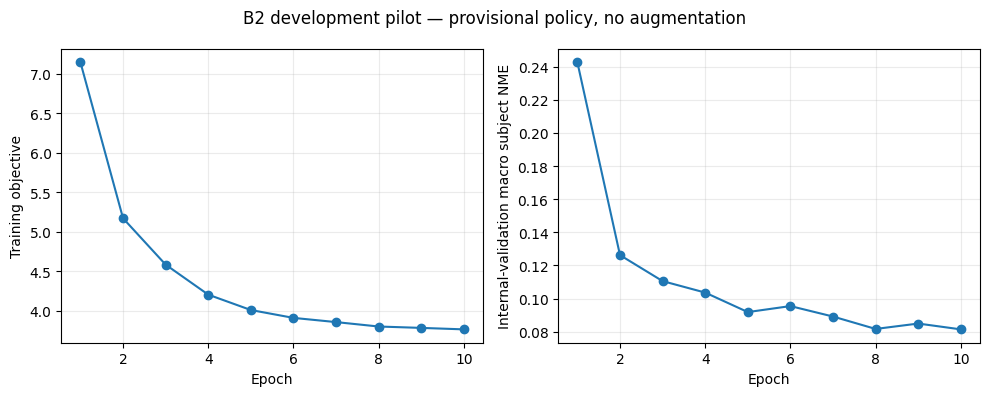


SUMMARY
{
  "status": "B2_DEVELOPMENT_PILOT_COMPLETED",
  "run_directory": "/content/drive/MyDrive/FetalGeo/runs/B2_pilot_v1_seed20260912",
  "completed_epochs": 10,
  "best_epoch": 10,
  "best_internal_validation_nme": 0.08141973911073323,
  "best_checkpoint": "/content/drive/MyDrive/FetalGeo/runs/B2_pilot_v1_seed20260912/best.pt",
  "last_checkpoint": "/content/drive/MyDrive/FetalGeo/runs/B2_pilot_v1_seed20260912/last.pt",
  "policy_status": "PROVISIONAL",
  "external_or_internal_test_evaluated": false
}

BLOCK 22 COMPLETED


In [ ]:
# FETALGEO_BLOCK22_V1
# B2 development pilot: 10 epochs, internal validation only.
# Requires Block 21's verified RAM training arrays and local workspace.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

required_variables = [
    "dataset", "selected", "models", "criterion",
    "state", "DATA", "LOCAL", "mean", "std",
]
missing = [name for name in required_variables if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing runtime variables: {missing}. Restore Block 21 first."
    )
if not selected["role"].eq("train").all():
    raise ValueError("Training dataset includes another role.")
if len(dataset) != 1560:
    raise ValueError("Unexpected training dataset size.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
RUN = PROJECT / "runs" / "B2_pilot_v1_seed20260912"
RUN.mkdir(parents=True, exist_ok=True)

EPOCHS = 10
BATCH_SIZE = 64
SEED = 20260912
LR = 1e-4

def sha256_file(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

run_config = {
    "variant": "B2",
    "purpose": "development_learning_pilot",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "learning_rate": LR,
    "weight_decay": 1e-4,
    "augmentation": "none",
    "policy_status": "PROVISIONAL",
    "validation": "internal_validation only",
    "selection_metric": (
        "equal mean of five per-measurement subject-average NME values; "
        "bounds-valid measurements only; duplicates retained"
    ),
    "initialization_sha256": sha256_file(LOCAL / "shared_initial_state.pt"),
    "model_sha256": sha256_file(LOCAL / "model.py"),
    "loss_sha256": sha256_file(LOCAL / "losses.py"),
    "loss_config_sha256": sha256_file(LOCAL / "loss_config.json"),
    "mask_sha256": sha256_file(DATA / "masks/measurement_masks.csv"),
}
config_path = RUN / "run_config.json"
if config_path.exists():
    if json.loads(config_path.read_text()) != run_config:
        raise ValueError("Existing pilot configuration differs.")
else:
    config_path.write_text(json.dumps(run_config, indent=2), encoding="utf-8")

# Load only internal validation for development feedback.
cache_index = pd.read_csv(
    DATA / "cache/cache_index.csv", keep_default_na=False
)
validation_index = cache_index.loc[
    cache_index["role"].eq("internal_validation")
].reset_index(drop=True)
if len(validation_index) != 282 or validation_index["source"].eq("UCL").any():
    raise ValueError("Unexpected internal validation selection.")

validation_samples = []
print("Loading 282 internal-validation images...", flush=True)
for chunk_name, rows in validation_index.groupby("chunk_file", sort=True):
    with np.load(DATA / "cache" / chunk_name, allow_pickle=False) as archive:
        for _, row in rows.iterrows():
            p = int(row["position"])
            if str(archive["record_ids"][p]) != row["record_id"]:
                raise ValueError("Validation chunk/index mismatch.")
            validation_samples.append({
                "record_id": row["record_id"],
                "subject_key": row["subject_key"],
                "image": archive["images"][p].copy(),
                "target": archive["original_points"][p].copy(),
                "valid": (
                    archive["measurement_present"][p]
                    & archive["geometry_valid"][p]
                ),
                "inverse": np.linalg.inv(
                    archive["original_to_cache"][p]
                ),
            })

measurement_order = ["ofd", "bpd", "tad", "apad", "fl"]

def validate(model):
    model.eval()
    rows = []
    with torch.no_grad():
        for start in range(0, len(validation_samples), BATCH_SIZE):
            samples = validation_samples[start:start + BATCH_SIZE]
            images = torch.from_numpy(
                np.stack([sample["image"] for sample in samples])
            ).permute(0, 3, 1, 2).to("cuda", dtype=torch.float32) / 255.0
            images = (images - mean) / std

            with torch.autocast("cuda", dtype=torch.bfloat16):
                predictions = model(images)["local_points"]
            predictions = predictions.float().cpu().numpy()

            for sample, prediction in zip(samples, predictions):
                homogeneous = np.concatenate(
                    [prediction, np.ones((5, 2, 1))], axis=-1
                )
                restored = (
                    homogeneous @ sample["inverse"].T
                )[..., :2]

                for m, name in enumerate(measurement_order):
                    if not sample["valid"][m]:
                        continue
                    truth = sample["target"][m]
                    predicted = restored[m]
                    length = np.linalg.norm(truth[1] - truth[0])
                    if not np.isfinite(length) or length <= 0:
                        raise ValueError("Invalid validation denominator.")

                    direct = np.linalg.norm(predicted - truth, axis=1).mean()
                    reverse = np.linalg.norm(
                        predicted - truth[::-1], axis=1
                    ).mean()
                    nme = min(direct, reverse) / length
                    if not np.isfinite(nme):
                        raise ValueError("Nonfinite validation NME.")
                    rows.append({
                        "record_id": sample["record_id"],
                        "subject_key": sample["subject_key"],
                        "measurement": name,
                        "nme": float(nme),
                    })

    frame = pd.DataFrame(rows)
    subject_scores = frame.groupby(
        ["measurement", "subject_key"]
    )["nme"].mean()
    metric_scores = subject_scores.groupby("measurement").mean()
    if set(metric_scores.index) != set(measurement_order):
        raise ValueError("Validation is missing a measurement.")
    return float(metric_scores.mean()), metric_scores.to_dict(), frame

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
model = models.FetalGeo(geometry=False, pretrained=False)
model.load_state_dict({
    key: value for key, value in state.items()
    if not key.startswith("geometry_head.")
}, strict=True)
model = model.cuda()

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=1e-4
)
last_path = RUN / "last.pt"
best_path = RUN / "best.pt"
history = []
best_nme = float("inf")
start_epoch = 1

if last_path.exists():
    checkpoint = torch.load(last_path, map_location="cpu", weights_only=True)
    if checkpoint["run_config"] != run_config:
        raise ValueError("Checkpoint configuration mismatch.")
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    torch.set_rng_state(checkpoint["torch_rng"])
    torch.cuda.set_rng_state_all(checkpoint["cuda_rng"])
    history = checkpoint["history"]
    best_nme = checkpoint["best_nme"]
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming at epoch {start_epoch}", flush=True)

def save_checkpoint(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

for epoch in range(start_epoch, EPOCHS + 1):
    started = time.perf_counter()
    model.train()
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        pin_memory=True,
        generator=torch.Generator().manual_seed(SEED + epoch),
    )
    accumulated_loss = 0.0
    seen = 0

    for images, points, masks, weights in loader:
        count = len(images)
        images = images.permute(0, 3, 1, 2).to(
            "cuda", dtype=torch.float32, non_blocking=True
        ) / 255.0
        images = (images - mean) / std
        points = points.cuda(non_blocking=True)
        masks = masks.cuda(non_blocking=True)
        weights = weights.cuda(non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            output = model(images)
            loss = criterion(output, points, masks, weights, "B2")["total"]
        if not torch.isfinite(loss):
            raise ValueError(f"Nonfinite loss at epoch {epoch}.")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0, error_if_nonfinite=True
        )
        optimizer.step()
        accumulated_loss += float(loss.detach()) * count
        seen += count

    if seen != len(dataset):
        raise ValueError("Training epoch omitted or repeated image count.")

    val_nme, per_measurement, validation_rows = validate(model)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    improved = val_nme < best_nme
    best_nme = min(best_nme, val_nme)

    entry = {
        "epoch": epoch,
        "training_loss": accumulated_loss / seen,
        "validation_macro_subject_nme": val_nme,
        "train_and_validation_seconds": elapsed,
        **{f"validation_{name}_nme": value
           for name, value in per_measurement.items()},
    }
    history.append(entry)

    payload = {
        "run_config": run_config,
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all(),
        "history": history,
        "best_nme": best_nme,
    }
    if improved:
        save_checkpoint(best_path, payload)
        validation_rows.to_csv(RUN / "best_validation_nme.csv", index=False)
    save_checkpoint(last_path, payload)
    pd.DataFrame(history).to_csv(RUN / "history.csv", index=False)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss {entry['training_loss']:.4f} | "
        f"validation NME {val_nme:.4f} | "
        f"train+validation {elapsed:.1f}s",
        flush=True,
    )

# Candidate learning curve; validation values are development results.
table = pd.DataFrame(history)
PAPER = PROJECT / "paper_artifacts"
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"B2_pilot_{stamp}"
for subdir in ["figures/final", "figures/data", "figures/captions"]:
    (PAPER / subdir).mkdir(parents=True, exist_ok=True)

data_path = PAPER / "figures/data" / f"{tag}.csv"
png_path = PAPER / "figures/final" / f"{tag}.png"
pdf_path = PAPER / "figures/final" / f"{tag}.pdf"
caption_path = PAPER / "figures/captions" / f"{tag}.txt"
table.to_csv(data_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(table["epoch"], table["training_loss"], marker="o")
axes[0].set_ylabel("Training objective")
axes[1].plot(
    table["epoch"], table["validation_macro_subject_nme"], marker="o"
)
axes[1].set_ylabel("Internal-validation macro subject NME")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
fig.suptitle("B2 development pilot — provisional policy, no augmentation")
fig.tight_layout()
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)

caption_path.write_text(
    "Ten-epoch B2 development pilot; provisional data policy, no augmentation.\n"
    "Validation uses bounds-valid measurements and retains duplicate records.\n"
    "NME computed in original image coordinates, subject-averaged within each "
    "measurement, then equally averaged across five measurements.\n"
    "These are development results, not external-test or final paper results.\n",
    encoding="utf-8",
)
artifact = pd.DataFrame([{
    "artifact_id": tag,
    "type": "figure",
    "title": "B2 development pilot learning curves",
    "status": "candidate",
    "source_data_path": str(data_path),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK22_V1",
    "output_paths": f"{png_path}|{pdf_path}",
    "caption_path": str(caption_path),
}])
artifact_index = PAPER / "ARTIFACT_INDEX.csv"
if artifact_index.exists() and artifact_index.stat().st_size:
    artifact = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), artifact
    ], ignore_index=True)
artifact.fillna("").to_csv(artifact_index, index=False)

best_row = table.loc[table["validation_macro_subject_nme"].idxmin()]
report = {
    "status": "B2_DEVELOPMENT_PILOT_COMPLETED",
    "run_directory": str(RUN),
    "completed_epochs": int(table["epoch"].max()),
    "best_epoch": int(best_row["epoch"]),
    "best_internal_validation_nme": float(
        best_row["validation_macro_subject_nme"]
    ),
    "best_checkpoint": str(best_path),
    "last_checkpoint": str(last_path),
    "policy_status": "PROVISIONAL",
    "external_or_internal_test_evaluated": False,
}
(RUN / "pilot_summary.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)
with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 22 B2 development pilot — {stamp}\n\n"
        "- Provisional policy, no augmentation; internal validation only.\n"
        f"- Best epoch: {report['best_epoch']}\n"
        f"- Best development NME: {report['best_internal_validation_nme']:.6f}\n"
        "- This is not a final benchmark or external-validation result.\n"
        f"- Run: `{RUN}`\n"
        f"- Learning curve: `{pdf_path}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print("\nBLOCK 22 COMPLETED")


A1: starting at epoch 1
A1 epoch 01/10 | loss 7.2823 | validation NME 0.2445 | 6.9s
A1 epoch 02/10 | loss 5.2405 | validation NME 0.1259 | 6.8s
A1 epoch 03/10 | loss 4.6307 | validation NME 0.1100 | 6.8s
A1 epoch 04/10 | loss 4.2426 | validation NME 0.1100 | 6.7s
A1 epoch 05/10 | loss 4.0329 | validation NME 0.0936 | 6.9s
A1 epoch 06/10 | loss 3.9399 | validation NME 0.1004 | 6.9s
A1 epoch 07/10 | loss 3.8744 | validation NME 0.0890 | 7.0s
A1 epoch 08/10 | loss 3.8203 | validation NME 0.0872 | 6.9s
A1 epoch 09/10 | loss 3.8000 | validation NME 0.0858 | 6.8s
A1 epoch 10/10 | loss 3.7737 | validation NME 0.0849 | 6.9s

A2: starting at epoch 1
A2 epoch 01/10 | loss 7.3091 | validation NME 0.2550 | 6.9s
A2 epoch 02/10 | loss 5.2590 | validation NME 0.1265 | 7.2s
A2 epoch 03/10 | loss 4.6538 | validation NME 0.1166 | 6.9s
A2 epoch 04/10 | loss 4.2658 | validation NME 0.1109 | 6.8s
A2 epoch 05/10 | loss 4.0487 | validation NME 0.0978 | 6.8s
A2 epoch 06/10 | loss 3.9361 | validation NME 0.10

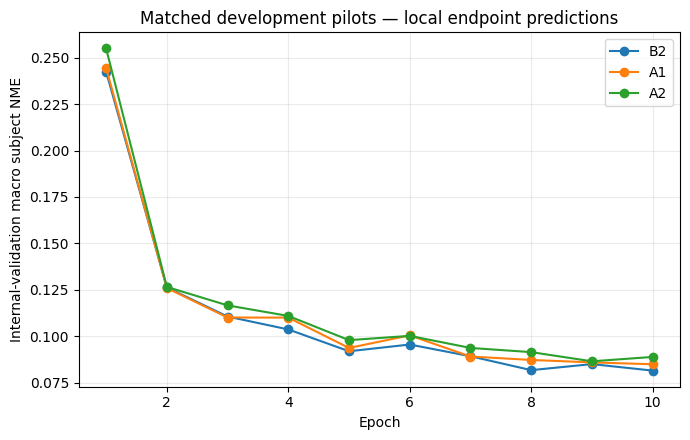


PILOT COMPARISON — DEVELOPMENT RESULTS ONLY
variant  best_epoch  best_internal_validation_nme  epoch10_internal_validation_nme
     B2          10                      0.081420                         0.081420
     A1          10                      0.084853                         0.084853
     A2           9                      0.086439                         0.088794

Saved comparison table: /content/drive/MyDrive/FetalGeo/paper_artifacts/tables/data/matched_pilots_20260912T170441295056Z.csv

BLOCK 23 COMPLETED


In [ ]:
# FETALGEO_BLOCK23_V1
# Matched A1/A2 development pilots; internal validation only.
# Requires Block 22's dataset, validate(), criterion, models, and normalization.

from pathlib import Path
from datetime import datetime, timezone
import json
import os
import gc
import time
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "validate", "criterion", "models",
    "mean", "std", "LOCAL", "run_config",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Restore Block 22 runtime first. Missing: {missing}")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
B2_RUN = PROJECT / "runs/B2_pilot_v1_seed20260912"
baseline_config = json.loads((B2_RUN / "run_config.json").read_text())
baseline_history = pd.read_csv(B2_RUN / "history.csv")

if baseline_config["variant"] != "B2":
    raise ValueError("Unexpected baseline configuration.")
if int(baseline_history["epoch"].max()) != 10:
    raise ValueError("Expected a completed 10-epoch baseline.")

EPOCHS = baseline_config["epochs"]
BATCH_SIZE = baseline_config["batch_size"]
SEED = baseline_config["seed"]

init_path = Path(LOCAL) / "shared_initial_state.pt"
if hashlib.sha256(init_path.read_bytes()).hexdigest() != baseline_config[
    "initialization_sha256"
]:
    raise ValueError("Initialization differs from B2.")

initial_state = torch.load(
    init_path, map_location="cpu", weights_only=True
)

def atomic_checkpoint(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

# Release the completed B2 model if it remains on the GPU.
if "model" in globals():
    del model
if "optimizer" in globals():
    del optimizer
gc.collect()
torch.cuda.empty_cache()

comparison_rows = []
histories = {"B2": baseline_history}

for variant in ["A1", "A2"]:
    RUN = PROJECT / "runs" / f"{variant}_pilot_v1_seed{SEED}"
    RUN.mkdir(parents=True, exist_ok=True)

    variant_config = dict(baseline_config)
    variant_config["variant"] = variant
    config_path = RUN / "run_config.json"
    if config_path.exists():
        if json.loads(config_path.read_text()) != variant_config:
            raise ValueError(f"{variant}: existing configuration differs.")
    else:
        config_path.write_text(
            json.dumps(variant_config, indent=2), encoding="utf-8"
        )

    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    model = models.FetalGeo(geometry=True, pretrained=False)
    model.load_state_dict(initial_state, strict=True)
    model = model.cuda()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=baseline_config["learning_rate"],
        weight_decay=baseline_config["weight_decay"],
    )

    history = []
    best_nme = float("inf")
    start_epoch = 1
    last_path = RUN / "last.pt"
    best_path = RUN / "best.pt"

    if last_path.exists():
        checkpoint = torch.load(
            last_path, map_location="cpu", weights_only=True
        )
        if checkpoint["run_config"] != variant_config:
            raise ValueError("Checkpoint configuration differs.")
        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        torch.set_rng_state(checkpoint["torch_rng"])
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng"])
        history = checkpoint["history"]
        best_nme = checkpoint["best_nme"]
        start_epoch = checkpoint["epoch"] + 1
        del checkpoint

    print(f"\n{variant}: starting at epoch {start_epoch}", flush=True)

    for epoch in range(start_epoch, EPOCHS + 1):
        started = time.perf_counter()
        model.train()
        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False,
            num_workers=0,
            pin_memory=True,
            generator=torch.Generator().manual_seed(SEED + epoch),
        )

        accumulated = {
            name: 0.0 for name in [
                "total", "heatmap", "coordinate", "geometry", "consistency"
            ]
        }
        seen = 0

        for images, points, masks, weights in loader:
            count = len(images)
            images = images.permute(0, 3, 1, 2).to(
                "cuda", dtype=torch.float32, non_blocking=True
            ) / 255.0
            images = (images - mean) / std
            points = points.cuda(non_blocking=True)
            masks = masks.cuda(non_blocking=True)
            weights = weights.cuda(non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                output = model(images)
                loss_parts = criterion(
                    output, points, masks, weights, variant
                )
                loss = loss_parts["total"]

            if not torch.isfinite(loss):
                raise ValueError(f"{variant}: nonfinite loss at epoch {epoch}.")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0, error_if_nonfinite=True
            )
            optimizer.step()

            for name, value in loss_parts.items():
                accumulated[name] += float(value.detach()) * count
            seen += count

        if seen != len(dataset):
            raise ValueError("Training image count mismatch.")

        # Same local-endpoint validation metric as B2.
        # Geometry-head predictions are not used to select these checkpoints.
        val_nme, per_measurement, validation_rows = validate(model)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - started
        improved = val_nme < best_nme
        best_nme = min(best_nme, val_nme)

        entry = {
            "epoch": epoch,
            "training_loss": accumulated["total"] / seen,
            "validation_macro_subject_nme": val_nme,
            "train_and_validation_seconds": elapsed,
            **{
                f"training_{name}": value / seen
                for name, value in accumulated.items()
            },
            **{
                f"validation_{name}_nme": value
                for name, value in per_measurement.items()
            },
        }
        history.append(entry)

        payload = {
            "run_config": variant_config,
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all(),
            "history": history,
            "best_nme": best_nme,
        }
        if improved:
            atomic_checkpoint(best_path, payload)
            validation_rows.to_csv(
                RUN / "best_validation_nme.csv", index=False
            )
        atomic_checkpoint(last_path, payload)
        pd.DataFrame(history).to_csv(RUN / "history.csv", index=False)

        print(
            f"{variant} epoch {epoch:02d}/{EPOCHS} | "
            f"loss {entry['training_loss']:.4f} | "
            f"validation NME {val_nme:.4f} | {elapsed:.1f}s",
            flush=True,
        )

    histories[variant] = pd.DataFrame(history)
    best_row = histories[variant].loc[
        histories[variant]["validation_macro_subject_nme"].idxmin()
    ]
    (RUN / "pilot_summary.json").write_text(
        json.dumps({
            "variant": variant,
            "status": "DEVELOPMENT_PILOT_COMPLETED",
            "best_epoch": int(best_row["epoch"]),
            "best_internal_validation_nme": float(
                best_row["validation_macro_subject_nme"]
            ),
            "selection_prediction": "local_points",
            "policy_status": "PROVISIONAL",
            "external_or_internal_test_evaluated": False,
        }, indent=2),
        encoding="utf-8",
    )

    del model, optimizer
    gc.collect()
    torch.cuda.empty_cache()

for variant, history in histories.items():
    best_row = history.loc[
        history["validation_macro_subject_nme"].idxmin()
    ]
    comparison_rows.append({
        "variant": variant,
        "best_epoch": int(best_row["epoch"]),
        "best_internal_validation_nme": float(
            best_row["validation_macro_subject_nme"]
        ),
        "epoch10_internal_validation_nme": float(
            history.loc[
                history["epoch"].eq(10), "validation_macro_subject_nme"
            ].iloc[0]
        ),
    })

comparison = pd.DataFrame(comparison_rows)
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag = f"matched_pilots_{stamp}"
PAPER = PROJECT / "paper_artifacts"

for subdir in [
    "figures/final", "figures/data", "figures/captions",
    "tables/data", "tables/notes",
]:
    (PAPER / subdir).mkdir(parents=True, exist_ok=True)

table_path = PAPER / "tables/data" / f"{tag}.csv"
note_path = PAPER / "tables/notes" / f"{tag}.txt"
figure_data = PAPER / "figures/data" / f"{tag}.csv"
png_path = PAPER / "figures/final" / f"{tag}.png"
pdf_path = PAPER / "figures/final" / f"{tag}.pdf"
caption_path = PAPER / "figures/captions" / f"{tag}.txt"

comparison.to_csv(table_path, index=False)
pd.concat([
    history.assign(variant=variant)
    for variant, history in histories.items()
], ignore_index=True).to_csv(figure_data, index=False)

note = (
    "Matched 10-epoch, single-seed development pilots; no augmentation.\n"
    "Shared backbone/local-head initialization and training batch order.\n"
    "All checkpoint selection uses local-endpoint internal-validation NME.\n"
    "Current bounds-valid evaluation subset; duplicate records retained.\n"
    "Best-epoch values are selected development scores, not unbiased test scores.\n"
    "No internal-test or UCL evaluation; no statistical superiority established.\n"
)
note_path.write_text(note, encoding="utf-8")
caption_path.write_text(note, encoding="utf-8")

fig, ax = plt.subplots(figsize=(7, 4.5))
for variant, history in histories.items():
    ax.plot(
        history["epoch"],
        history["validation_macro_subject_nme"],
        marker="o",
        label=variant,
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Internal-validation macro subject NME")
ax.set_title("Matched development pilots — local endpoint predictions")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)

entries = pd.DataFrame([
    {
        "artifact_id": f"{tag}_{kind}",
        "type": kind,
        "title": "Matched B2/A1/A2 development pilots",
        "status": "candidate",
        "source_data_path": str(source),
        "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK23_V1",
        "output_paths": outputs,
        "caption_path": str(caption),
    }
    for kind, source, outputs, caption in [
        ("table", table_path, str(table_path), note_path),
        ("figure", figure_data, f"{png_path}|{pdf_path}", caption_path),
    ]
])
index_path = PAPER / "ARTIFACT_INDEX.csv"
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat([
        pd.read_csv(index_path, keep_default_na=False), entries
    ], ignore_index=True)
entries.fillna("").to_csv(index_path, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 23 matched development pilots — {stamp}\n\n"
        + note.replace("\n", " ")
        + "\n\n```text\n"
        + comparison.to_string(index=False)
        + "\n```\n\n"
        + f"Comparison table: `{table_path}`\n"
        + f"Learning curves: `{pdf_path}`\n"
    )

print("\nPILOT COMPARISON — DEVELOPMENT RESULTS ONLY")
print(comparison.to_string(index=False))
print(f"\nSaved comparison table: {table_path}")
print("\nBLOCK 23 COMPLETED")

In [ ]:
# FETALGEO_BLOCK24_V2
# Best-checkpoint diagnostics; internal validation only. No training.

from pathlib import Path
from datetime import datetime, timezone
import importlib.util
import hashlib
import json
import gc

import numpy as np
import pandas as pd
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
LOCAL = Path("/content/fetalgeo_work")
DATA = LOCAL / "data"
ORDER = ["ofd", "bpd", "tad", "apad", "fl"]
BATCH_SIZE = 64

if not torch.cuda.is_available():
    raise RuntimeError("GPU unavailable. Restore the GPU runtime first.")
if not (DATA / "BUNDLE_INFO.json").exists():
    raise RuntimeError("Local cache missing. Restore it with Block 20 first.")

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

bundle_info = json.loads((DATA / "BUNDLE_INFO.json").read_text())
index_path = DATA / "cache/cache_index.csv"
if file_hash(index_path) != bundle_info["files"][
    "cache/cache_index.csv"
]["sha256"]:
    raise ValueError("Cache index checksum mismatch.")

spec = importlib.util.spec_from_file_location(
    "block24_models", LOCAL / "model.py"
)
models24 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(models24)

index = pd.read_csv(index_path, keep_default_na=False)
validation_index = index.loc[
    index["role"].eq("internal_validation")
].copy()

if len(validation_index) != 282:
    raise ValueError("Expected 282 internal-validation images.")
if validation_index["source"].eq("UCL").any():
    raise ValueError("UCL must not enter development diagnostics.")
if validation_index["record_id"].duplicated().any():
    raise ValueError("Repeated validation record IDs.")

samples24 = []
print("Loading internal-validation data...", flush=True)

for chunk_name, rows in validation_index.groupby("chunk_file", sort=True):
    chunk_path = DATA / "cache" / chunk_name
    if file_hash(chunk_path) != bundle_info["files"][
        f"cache/{chunk_name}"
    ]["sha256"]:
        raise ValueError(f"Chunk checksum mismatch: {chunk_name}")

    with np.load(chunk_path, allow_pickle=False) as archive:
        for row in rows.to_dict("records"):
            position = int(row["position"])
            if str(archive["record_ids"][position]) != row["record_id"]:
                raise ValueError("Chunk/index record mismatch.")

            samples24.append({
                "record_id": row["record_id"],
                "subject_key": row["subject_key"],
                "source": row["source"],
                "image": archive["images"][position].copy(),
                "target": archive["original_points"][position].copy(),
                "valid": (
                    archive["measurement_present"][position]
                    & archive["geometry_valid"][position]
                ).copy(),
                "inverse": np.linalg.inv(
                    archive["original_to_cache"][position]
                ),
            })

mean24 = torch.tensor(
    [0.485, 0.456, 0.406], device="cuda"
)[None, :, None, None]
std24 = torch.tensor(
    [0.229, 0.224, 0.225], device="cuda"
)[None, :, None, None]

def unordered_nme(predicted, truth):
    length = np.linalg.norm(truth[1] - truth[0])
    if not np.isfinite(length) or length <= 0:
        raise ValueError("Invalid target length.")
    direct = np.linalg.norm(predicted - truth, axis=1).mean()
    reverse = np.linalg.norm(predicted - truth[::-1], axis=1).mean()
    value = min(direct, reverse) / length
    if not np.isfinite(value):
        raise ValueError("Nonfinite NME.")
    return float(value)

prediction_rows = []
checkpoint_rows = []

for variant in ["B2", "A1", "A2"]:
    run = PROJECT / "runs" / f"{variant}_pilot_v1_seed20260912"
    checkpoint_path = run / "best.pt"
    checkpoint = torch.load(
        checkpoint_path, map_location="cpu", weights_only=True
    )
    configuration = checkpoint["run_config"]

    if configuration["variant"] != variant:
        raise ValueError("Checkpoint variant mismatch.")
    if file_hash(LOCAL / "model.py") != configuration["model_sha256"]:
        raise ValueError("Model source differs from training.")

    model24 = models24.FetalGeo(
        geometry=(variant != "B2"), pretrained=False
    )
    model24.load_state_dict(checkpoint["model"], strict=True)
    model24 = model24.cuda().eval()

    checkpoint_rows.append({
        "variant": variant,
        "selected_epoch": int(checkpoint["epoch"]),
        "saved_best_local_nme": float(checkpoint["best_nme"]),
        "checkpoint_sha256": file_hash(checkpoint_path),
    })

    print(
        f"Evaluating {variant}, epoch {checkpoint['epoch']}...",
        flush=True,
    )

    with torch.no_grad():
        for start in range(0, len(samples24), BATCH_SIZE):
            batch = samples24[start:start + BATCH_SIZE]
            images = torch.from_numpy(
                np.stack([sample["image"] for sample in batch])
            ).permute(0, 3, 1, 2).cuda().float() / 255.0
            images = (images - mean24) / std24

            with torch.autocast("cuda", dtype=torch.bfloat16):
                output = model24(images)

            branches = {
                "local": output["local_points"].float().cpu().numpy()
            }
            if variant != "B2":
                branches["geometry"] = (
                    output["geometry_points"].float().cpu().numpy()
                )

            for branch, predictions in branches.items():
                for sample, prediction in zip(batch, predictions):
                    homogeneous = np.concatenate(
                        [prediction, np.ones((5, 2, 1))], axis=-1
                    )
                    restored = (
                        homogeneous @ sample["inverse"].T
                    )[..., :2]

                    for slot, measurement in enumerate(ORDER):
                        if not sample["valid"][slot]:
                            continue

                        predicted = restored[slot]
                        truth = sample["target"][slot]
                        prediction_rows.append({
                            "variant": variant,
                            "branch": branch,
                            "selected_epoch": int(checkpoint["epoch"]),
                            "record_id": sample["record_id"],
                            "source": sample["source"],
                            "subject_key": sample["subject_key"],
                            "measurement": measurement,
                            "nme": unordered_nme(predicted, truth),
                            "predicted_x1": float(predicted[0, 0]),
                            "predicted_y1": float(predicted[0, 1]),
                            "predicted_x2": float(predicted[1, 0]),
                            "predicted_y2": float(predicted[1, 1]),
                        })

    del model24, checkpoint, output
    gc.collect()
    torch.cuda.empty_cache()

predictions24 = pd.DataFrame(prediction_rows)
selection24 = pd.DataFrame(checkpoint_rows)

subject_scores24 = (
    predictions24.groupby(
        ["variant", "branch", "measurement", "subject_key"],
        as_index=False,
    )["nme"].mean()
)
measurement_scores24 = (
    subject_scores24.groupby(
        ["variant", "branch", "measurement"], as_index=False
    )
    .agg(
        subject_average_nme=("nme", "mean"),
        subject_keys=("subject_key", "size"),
    )
)
macro_scores24 = (
    measurement_scores24.groupby(["variant", "branch"], as_index=False)
    .agg(macro_subject_nme=("subject_average_nme", "mean"))
)

# Confirm that recomputed local scores reproduce checkpoint-selection scores.
for row in selection24.to_dict("records"):
    current = macro_scores24.loc[
        macro_scores24["variant"].eq(row["variant"])
        & macro_scores24["branch"].eq("local"),
        "macro_subject_nme",
    ].iloc[0]
    if not np.isclose(
        current, row["saved_best_local_nme"], rtol=0, atol=1e-4
    ):
        raise ValueError(
            f"{row['variant']}: saved NME {row['saved_best_local_nme']:.8f}, "
            f"recomputed NME {current:.8f}. Investigate before proceeding."
        )

baseline24 = measurement_scores24.loc[
    measurement_scores24["variant"].eq("B2")
    & measurement_scores24["branch"].eq("local"),
    ["measurement", "subject_average_nme"],
].rename(columns={"subject_average_nme": "B2_local_nme"})

comparison24 = measurement_scores24.merge(
    baseline24, on="measurement", validate="many_to_one"
)
comparison24["difference_from_B2_local"] = (
    comparison24["subject_average_nme"] - comparison24["B2_local_nme"]
)

stamp24 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT24 = PROJECT / "data/audit" / f"block24_{stamp24}"
OUT24.mkdir(parents=True, exist_ok=False)

for name, frame in [
    ("validation_predictions.csv", predictions24),
    ("validation_subject_scores.csv", subject_scores24),
    ("measurement_comparison.csv", comparison24),
    ("macro_comparison.csv", macro_scores24),
    ("checkpoint_selection.csv", selection24),
]:
    frame.to_csv(OUT24 / name, index=False)

PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables/data"
notes_dir = PAPER / "tables/notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

tag24 = f"pilot_branch_diagnostics_{stamp24}"
table_path24 = table_dir / f"{tag24}.csv"
note_path24 = notes_dir / f"{tag24}.txt"
comparison24.to_csv(table_path24, index=False)
note_path24.write_text(
    "Single-seed, ten-epoch pilot internal-validation diagnostics.\n"
    "Checkpoints selected by local-head NME; geometry heads evaluated at "
    "those same checkpoints.\n"
    "Negative difference_from_B2_local means lower development NME.\n"
    "Bounds-valid measurements only; duplicate records retained.\n"
    "No test-set evaluation or statistical superiority established.\n",
    encoding="utf-8",
)

artifact_path24 = PAPER / "ARTIFACT_INDEX.csv"
artifact24 = pd.DataFrame([{
    "artifact_id": tag24,
    "type": "table",
    "title": "Pilot validation by branch and measurement",
    "status": "candidate",
    "source_data_path": str(OUT24 / "validation_predictions.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK24_V2",
    "output_paths": str(table_path24),
    "caption_path": str(note_path24),
}])
if artifact_path24.exists() and artifact_path24.stat().st_size:
    artifact24 = pd.concat([
        pd.read_csv(artifact_path24, keep_default_na=False), artifact24
    ], ignore_index=True)
artifact24.fillna("").to_csv(artifact_path24, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 24 branch diagnostics — {stamp24}\n\n"
        "- Internal validation only; best local-selected checkpoints.\n"
        "- Recomputed local scores matched saved selection scores.\n"
        "- Geometry results are diagnostic, not independently selected.\n\n"
        "```text\n"
        + macro_scores24.to_string(index=False)
        + "\n```\n\n"
        + f"Detailed results: `{OUT24}`\n"
        + f"Candidate table: `{table_path24}`\n"
    )

print("\nSELECTED CHECKPOINTS")
print(selection24[[
    "variant", "selected_epoch", "saved_best_local_nme"
]].to_string(index=False))

print("\nMACRO NME — LOWER IS BETTER")
print(macro_scores24.to_string(index=False))

print("\nPER-MEASUREMENT COMPARISON")
print(comparison24.to_string(index=False))

print(f"\nSaved diagnostics: {OUT24}")
print("\nBLOCK 24 COMPLETED")

Loading internal-validation data...
Evaluating B2, epoch 10...
Evaluating A1, epoch 10...
Evaluating A2, epoch 9...

SELECTED CHECKPOINTS
variant  selected_epoch  saved_best_local_nme
     B2              10              0.081420
     A1              10              0.084853
     A2               9              0.086439

MACRO NME — LOWER IS BETTER
variant   branch  macro_subject_nme
     A1 geometry           0.101583
     A1    local           0.084853
     A2 geometry           0.104560
     A2    local           0.086439
     B2    local           0.081420

PER-MEASUREMENT COMPARISON
variant   branch measurement  subject_average_nme  subject_keys  B2_local_nme  difference_from_B2_local
     A1 geometry        apad             0.121976            36      0.107246                  0.014730
     A1 geometry         bpd             0.080399           137      0.064281                  0.016118
     A1 geometry          fl             0.121231            49      0.068902                

# B2, A1, and A2 train


B2: continuing at epoch 11
B2 11/30 | loss 3.7550 | validation NME 0.0784 | 6.6s
B2 12/30 | loss 3.7365 | validation NME 0.0800 | 6.7s
B2 13/30 | loss 3.7350 | validation NME 0.0798 | 6.7s
B2 14/30 | loss 3.7302 | validation NME 0.0793 | 6.7s
B2 15/30 | loss 3.7155 | validation NME 0.0791 | 6.5s
B2 16/30 | loss 3.7183 | validation NME 0.0778 | 6.7s
B2 17/30 | loss 3.7147 | validation NME 0.0759 | 6.6s
B2 18/30 | loss 3.7101 | validation NME 0.0771 | 6.7s
B2 19/30 | loss 3.7071 | validation NME 0.0763 | 6.8s
B2 20/30 | loss 3.6989 | validation NME 0.0745 | 6.7s
B2 21/30 | loss 3.6992 | validation NME 0.0758 | 6.8s
B2 22/30 | loss 3.6954 | validation NME 0.0757 | 6.7s
B2 23/30 | loss 3.6955 | validation NME 0.0758 | 6.6s
B2 24/30 | loss 3.6913 | validation NME 0.0751 | 6.6s
B2 25/30 | loss 3.6902 | validation NME 0.0761 | 6.6s
B2 26/30 | loss 3.6877 | validation NME 0.0750 | 6.7s
B2 27/30 | loss 3.6854 | validation NME 0.0784 | 6.7s
B2 28/30 | loss 3.6831 | validation NME 0.0735 | 6.7s


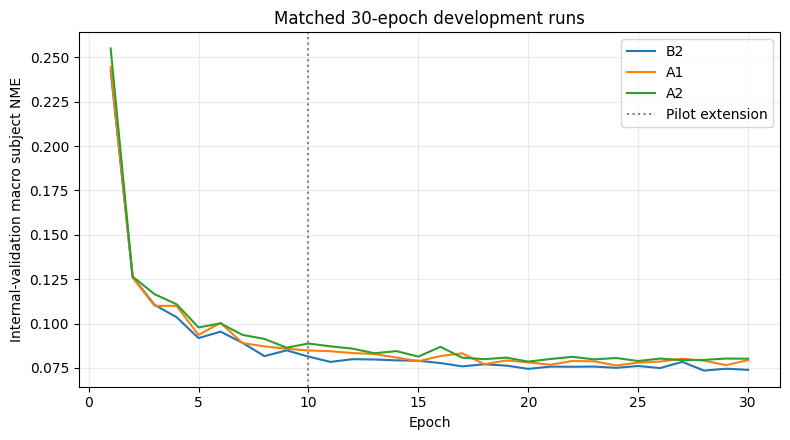


30-EPOCH DEVELOPMENT COMPARISON
variant  best_epoch  best_validation_nme  epoch30_validation_nme
     B2          28             0.073523                0.073951
     A1          24             0.076399                0.079456
     A2          20             0.078601                0.080235

Saved table: /content/drive/MyDrive/FetalGeo/paper_artifacts/tables/data/matched_extended30_20260912T172231696400Z.csv

BLOCK 25 COMPLETED


In [ ]:
# FETALGEO_BLOCK25_V1
# Continue matched pilots from epoch 10 to epoch 30.
# Original 10-epoch runs are preserved.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time

import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "selected", "models", "criterion",
    "validate", "mean", "std", "LOCAL",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Training runtime missing: {missing}. "
        "Share this error before rerunning earlier training blocks."
    )
if not torch.cuda.is_available():
    raise RuntimeError("An active GPU runtime is required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training dataset.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
TARGET_EPOCHS = 30
SEED = 20260912
BATCH_SIZE = 64
histories25 = {}

def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def atomic_save(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

for variant in ["B2", "A1", "A2"]:
    original_run = PROJECT / "runs" / f"{variant}_pilot_v1_seed{SEED}"
    RUN25 = PROJECT / "runs" / f"{variant}_extended30_v1_seed{SEED}"
    RUN25.mkdir(parents=True, exist_ok=True)

    original_config = json.loads(
        (original_run / "run_config.json").read_text()
    )
    for filename, hash_key in [
        ("model.py", "model_sha256"),
        ("losses.py", "loss_sha256"),
        ("loss_config.json", "loss_config_sha256"),
    ]:
        if digest(Path(LOCAL) / filename) != original_config[hash_key]:
            raise ValueError(f"{variant}: changed source/config: {filename}")

    if (
        original_config["variant"] != variant
        or original_config["epochs"] != 10
        or original_config["batch_size"] != BATCH_SIZE
    ):
        raise ValueError("Unexpected original pilot settings.")

    extension_config = {
        **original_config,
        "epochs": TARGET_EPOCHS,
        "purpose": "unchanged_configuration_extended_development_pilot",
        "parent_run": str(original_run),
        "parent_last_sha256": digest(original_run / "last.pt"),
    }

    config_path = RUN25 / "run_config.json"
    if config_path.exists():
        if json.loads(config_path.read_text()) != extension_config:
            raise ValueError(f"{variant}: extension configuration differs.")
    else:
        config_path.write_text(
            json.dumps(extension_config, indent=2), encoding="utf-8"
        )

    last_path = RUN25 / "last.pt"
    best_path = RUN25 / "best.pt"

    if last_path.exists():
        checkpoint = torch.load(
            last_path, map_location="cpu", weights_only=True
        )
        if checkpoint["run_config"] != extension_config:
            raise ValueError("Extension checkpoint configuration differs.")
    else:
        checkpoint = torch.load(
            original_run / "last.pt", map_location="cpu", weights_only=True
        )
        if checkpoint["epoch"] != 10:
            raise ValueError("Continuation must start from epoch-10 last checkpoint.")

        # Preserve the best checkpoint from epochs 1–10 as an eligible best.
        previous_best = torch.load(
            original_run / "best.pt", map_location="cpu", weights_only=True
        )
        previous_best["run_config"] = extension_config
        atomic_save(best_path, previous_best)
        del previous_best

    model25 = models.FetalGeo(
        geometry=(variant != "B2"), pretrained=False
    )
    model25.load_state_dict(checkpoint["model"], strict=True)
    model25 = model25.cuda()

    optimizer25 = torch.optim.AdamW(
        model25.parameters(),
        lr=original_config["learning_rate"],
        weight_decay=original_config["weight_decay"],
    )
    optimizer25.load_state_dict(checkpoint["optimizer"])
    torch.set_rng_state(checkpoint["torch_rng"])
    torch.cuda.set_rng_state_all(checkpoint["cuda_rng"])

    history = checkpoint["history"]
    best_nme = float(checkpoint["best_nme"])
    start_epoch = int(checkpoint["epoch"]) + 1
    del checkpoint

    print(f"\n{variant}: continuing at epoch {start_epoch}", flush=True)

    for epoch in range(start_epoch, TARGET_EPOCHS + 1):
        started = time.perf_counter()
        model25.train()
        loader25 = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False,
            num_workers=0,
            pin_memory=True,
            generator=torch.Generator().manual_seed(SEED + epoch),
        )

        accumulated = {
            name: 0.0 for name in [
                "total", "heatmap", "coordinate", "geometry", "consistency"
            ]
        }
        seen = 0

        for images, points, masks, weights in loader25:
            count = len(images)
            images = images.permute(0, 3, 1, 2).to(
                "cuda", dtype=torch.float32, non_blocking=True
            ) / 255.0
            images = (images - mean) / std
            points = points.cuda(non_blocking=True)
            masks = masks.cuda(non_blocking=True)
            weights = weights.cuda(non_blocking=True)

            optimizer25.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                output = model25(images)
                components = criterion(output, points, masks, weights, variant)
                loss = components["total"]

            if not torch.isfinite(loss):
                raise ValueError(f"{variant}: nonfinite loss at epoch {epoch}.")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model25.parameters(), 1.0, error_if_nonfinite=True
            )
            optimizer25.step()

            for name, value in components.items():
                accumulated[name] += float(value.detach()) * count
            seen += count

        if seen != len(dataset):
            raise ValueError("Unexpected training epoch image count.")

        val_nme, measurement_scores, validation_rows = validate(model25)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - started

        improved = val_nme < best_nme
        best_nme = min(best_nme, val_nme)
        entry = {
            "epoch": epoch,
            "training_loss": accumulated["total"] / seen,
            "validation_macro_subject_nme": val_nme,
            "train_and_validation_seconds": elapsed,
            **{
                f"training_{name}": value / seen
                for name, value in accumulated.items()
            },
            **{
                f"validation_{name}_nme": value
                for name, value in measurement_scores.items()
            },
        }
        history.append(entry)

        payload = {
            "run_config": extension_config,
            "epoch": epoch,
            "model": model25.state_dict(),
            "optimizer": optimizer25.state_dict(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all(),
            "history": history,
            "best_nme": best_nme,
        }
        if improved:
            atomic_save(best_path, payload)
            validation_rows.to_csv(
                RUN25 / "best_validation_nme.csv", index=False
            )
        atomic_save(last_path, payload)
        pd.DataFrame(history).to_csv(RUN25 / "history.csv", index=False)

        print(
            f"{variant} {epoch:02d}/{TARGET_EPOCHS} | "
            f"loss {entry['training_loss']:.4f} | "
            f"validation NME {val_nme:.4f} | {elapsed:.1f}s",
            flush=True,
        )

    histories25[variant] = pd.DataFrame(history)
    del model25, optimizer25
    gc.collect()
    torch.cuda.empty_cache()

comparison_rows = []
for variant, history in histories25.items():
    best = history.loc[history["validation_macro_subject_nme"].idxmin()]
    final = history.loc[history["epoch"].eq(TARGET_EPOCHS)].iloc[0]
    comparison_rows.append({
        "variant": variant,
        "best_epoch": int(best["epoch"]),
        "best_validation_nme": float(best["validation_macro_subject_nme"]),
        "epoch30_validation_nme": float(final["validation_macro_subject_nme"]),
    })

comparison25 = pd.DataFrame(comparison_rows)
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
tag = f"matched_extended30_{stamp}"

for subdir in [
    "figures/final", "figures/data", "figures/captions",
    "tables/data", "tables/notes",
]:
    (PAPER / subdir).mkdir(parents=True, exist_ok=True)

table_path = PAPER / "tables/data" / f"{tag}.csv"
figure_data = PAPER / "figures/data" / f"{tag}.csv"
note_path = PAPER / "tables/notes" / f"{tag}.txt"
caption_path = PAPER / "figures/captions" / f"{tag}.txt"
png_path = PAPER / "figures/final" / f"{tag}.png"
pdf_path = PAPER / "figures/final" / f"{tag}.pdf"

comparison25.to_csv(table_path, index=False)
pd.concat([
    history.assign(variant=variant)
    for variant, history in histories25.items()
], ignore_index=True).to_csv(figure_data, index=False)

note = (
    "Single-seed matched development pilots extended unchanged to 30 epochs.\n"
    "Each variant resumed its epoch-10 last checkpoint, including optimizer state.\n"
    "No augmentation; local-head internal-validation checkpoint selection.\n"
    "Provisional policy; bounds-valid validation measurements, duplicates retained.\n"
    "No internal-test or external-test evaluation; no superiority established.\n"
)
note_path.write_text(note, encoding="utf-8")
caption_path.write_text(note, encoding="utf-8")

fig, ax = plt.subplots(figsize=(8, 4.5))
for variant, history in histories25.items():
    ax.plot(
        history["epoch"], history["validation_macro_subject_nme"],
        label=variant,
    )
ax.axvline(10, color="gray", linestyle=":", label="Pilot extension")
ax.set_xlabel("Epoch")
ax.set_ylabel("Internal-validation macro subject NME")
ax.set_title("Matched 30-epoch development runs")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)

entries = pd.DataFrame([
    {
        "artifact_id": f"{tag}_{kind}",
        "type": kind,
        "title": "Matched 30-epoch development comparison",
        "status": "candidate",
        "source_data_path": str(source),
        "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK25_V1",
        "output_paths": outputs,
        "caption_path": str(caption),
    }
    for kind, source, outputs, caption in [
        ("table", table_path, str(table_path), note_path),
        ("figure", figure_data, f"{png_path}|{pdf_path}", caption_path),
    ]
])
artifact_index = PAPER / "ARTIFACT_INDEX.csv"
if artifact_index.exists() and artifact_index.stat().st_size:
    entries = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), entries
    ], ignore_index=True)
entries.fillna("").to_csv(artifact_index, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 25 matched 30-epoch development runs — {stamp}\n\n"
        + note.replace("\n", " ")
        + "\n\n```text\n"
        + comparison25.to_string(index=False)
        + "\n```\n\n"
        + f"Comparison: `{table_path}`\n"
        + f"Learning curves: `{pdf_path}`\n"
    )

print("\n30-EPOCH DEVELOPMENT COMPARISON")
print(comparison25.to_string(index=False))
print(f"\nSaved table: {table_path}")
print("\nBLOCK 25 COMPLETED")

In [ ]:
# FETALGEO_BLOCK26_V1
# Training-only gradient alignment diagnostic; no optimizer steps.
# Requires the RAM training dataset from the current runtime.

from pathlib import Path
from datetime import datetime, timezone
import importlib.util
import hashlib
import json
import gc

import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
LOCAL = Path("/content/fetalgeo_work")
SEED = 20260912
BATCH_SIZE = 8
N_BATCHES = 4

if "dataset" not in globals() or "selected" not in globals():
    raise RuntimeError("RAM training dataset missing. Share this error.")
if len(dataset) != len(selected) or not selected["role"].eq("train").all():
    raise ValueError("Training dataset/index mismatch.")
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

models26 = load_module("models26", LOCAL / "model.py")
losses26 = load_module("losses26", LOCAL / "losses.py")
config26 = json.loads((LOCAL / "loss_config.json").read_text())
coeff = config26["coefficients"]

criterion26 = losses26.FetalGeoLoss(
    training_images=config26["training_images"],
    measurement_weight_totals=config26["measurement_weight_totals"],
    heatmap_sigma=config26["heatmap_sigma_cells"],
    heatmap_weight=coeff["heatmap"],
    coordinate_weight=coeff["coordinate"],
    geometry_weight=coeff["geometry"],
    consistency_weight=coeff["consistency"],
).cuda()

# Same randomly selected training records and batches for A1 and A2.
positions = torch.randperm(
    len(dataset),
    generator=torch.Generator().manual_seed(SEED + 26),
)[:BATCH_SIZE * N_BATCHES].tolist()

chosen = selected.iloc[positions].copy().reset_index(drop=True)
chosen["diagnostic_batch"] = [
    position // BATCH_SIZE for position in range(len(chosen))
]
loader26 = DataLoader(
    Subset(dataset, positions),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
batches26 = list(loader26)

mean26 = torch.tensor(
    [0.485, 0.456, 0.406], device="cuda"
)[None, :, None, None]
std26 = torch.tensor(
    [0.229, 0.224, 0.225], device="cuda"
)[None, :, None, None]

def gradient_stats(left, right):
    dot = torch.zeros((), device="cuda", dtype=torch.float64)
    left_sq = torch.zeros_like(dot)
    right_sq = torch.zeros_like(dot)

    for a, b in zip(left, right):
        if a is not None:
            left_sq += a.detach().double().square().sum()
        if b is not None:
            right_sq += b.detach().double().square().sum()
        if a is not None and b is not None:
            dot += (a.detach().double() * b.detach().double()).sum()

    left_norm = left_sq.sqrt()
    right_norm = right_sq.sqrt()
    cosine = (
        float(dot / (left_norm * right_norm))
        if left_norm.item() > 0 and right_norm.item() > 0
        else float("nan")
    )
    return cosine, float(left_norm), float(right_norm)

rows26 = []
checkpoints26 = []

for variant in ["A1", "A2"]:
    checkpoint_path = (
        PROJECT / "runs"
        / f"{variant}_extended30_v1_seed{SEED}" / "last.pt"
    )
    checkpoint = torch.load(
        checkpoint_path, map_location="cpu", weights_only=True
    )
    if checkpoint["epoch"] != 30:
        raise ValueError("Expected epoch-30 last checkpoint.")
    if checkpoint["run_config"]["variant"] != variant:
        raise ValueError("Checkpoint variant mismatch.")
    for filename, hash_key in [
        ("model.py", "model_sha256"),
        ("losses.py", "loss_sha256"),
        ("loss_config.json", "loss_config_sha256"),
    ]:
        if digest(LOCAL / filename) != checkpoint["run_config"][hash_key]:
            raise ValueError(f"Source/config mismatch: {filename}")

    model26 = models26.FetalGeo(geometry=True, pretrained=False)
    model26.load_state_dict(checkpoint["model"], strict=True)
    model26 = model26.cuda().eval()

    # Eval mode preserves BatchNorm buffers. This is a diagnostic,
    # not an exact reproduction of training-mode gradients.
    parameters = tuple(
        p for p in model26.backbone.parameters() if p.requires_grad
    )
    checkpoints26.append({
        "variant": variant,
        "epoch": 30,
        "checkpoint_sha256": digest(checkpoint_path),
    })

    for batch_number, batch in enumerate(batches26, start=1):
        print(
            f"{variant}: gradient diagnostic {batch_number}/{N_BATCHES}",
            flush=True,
        )
        images, targets, masks, weights = batch
        images = images.permute(0, 3, 1, 2).cuda().float() / 255.0
        images = (images - mean26) / std26
        targets = targets.cuda()
        masks = masks.cuda()
        weights = weights.cuda()

        # Float32 diagnostic to reduce numerical noise.
        output = model26(images)
        parts = criterion26(output, targets, masks, weights, variant)
        main = (
            coeff["heatmap"] * parts["heatmap"]
            + coeff["coordinate"] * parts["coordinate"]
        )
        auxiliary_losses = {
            "geometry": coeff["geometry"] * parts["geometry"]
        }
        if variant == "A2":
            auxiliary_losses["consistency"] = (
                coeff["consistency"] * parts["consistency"]
            )

        main_grad = torch.autograd.grad(
            main, parameters, retain_graph=True, allow_unused=True
        )

        for auxiliary_name, auxiliary_loss in auxiliary_losses.items():
            auxiliary_grad = torch.autograd.grad(
                auxiliary_loss, parameters,
                retain_graph=True, allow_unused=True,
            )
            cosine, main_norm, auxiliary_norm = gradient_stats(
                main_grad, auxiliary_grad
            )
            rows26.append({
                "variant": variant,
                "batch": batch_number,
                "auxiliary_loss": auxiliary_name,
                "cosine_with_landmark_gradient": cosine,
                "landmark_gradient_norm": main_norm,
                "weighted_auxiliary_gradient_norm": auxiliary_norm,
                "auxiliary_to_landmark_norm_ratio": (
                    auxiliary_norm / main_norm
                    if main_norm > 0 else float("nan")
                ),
                "landmark_objective_value": float(main.detach()),
                "weighted_auxiliary_loss_value": float(auxiliary_loss.detach()),
            })
            del auxiliary_grad

        del main_grad, output, parts, main, auxiliary_losses, auxiliary_loss

    # Ensure model parameters and buffers remain unchanged.
    for name, value in model26.state_dict().items():
        if not torch.equal(value.cpu(), checkpoint["model"][name]):
            raise ValueError(f"Diagnostic changed model state: {name}")

    del model26, parameters, checkpoint
    gc.collect()
    torch.cuda.empty_cache()

details26 = pd.DataFrame(rows26)
summary26 = (
    details26.groupby(["variant", "auxiliary_loss"], as_index=False)
    .agg(
        batches=("batch", "size"),
        mean_cosine=("cosine_with_landmark_gradient", "mean"),
        minimum_cosine=("cosine_with_landmark_gradient", "min"),
        maximum_cosine=("cosine_with_landmark_gradient", "max"),
        mean_norm_ratio=("auxiliary_to_landmark_norm_ratio", "mean"),
    )
)

stamp26 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT26 = PROJECT / "data/audit" / f"block26_{stamp26}"
OUT26.mkdir(parents=True, exist_ok=False)
details26.to_csv(OUT26 / "gradient_alignment.csv", index=False)
summary26.to_csv(OUT26 / "gradient_summary.csv", index=False)
chosen.to_csv(OUT26 / "training_selection.csv", index=False)
(OUT26 / "diagnostic_config.json").write_text(
    json.dumps({
        "checkpoints": checkpoints26,
        "model_mode": "eval",
        "precision": "float32",
        "gradient_scope": "shared backbone parameters",
        "batches": N_BATCHES,
        "batch_size": BATCH_SIZE,
        "weights_changed": False,
        "limitations": [
            "Four training batches are a small diagnostic sample.",
            "Eval-mode BatchNorm differs from training mode.",
            "Negative alignment does not establish causal harm.",
            "No loss coefficients changed and no test data evaluated.",
        ],
    }, indent=2),
    encoding="utf-8",
)

PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables/data"
note_dir = PAPER / "tables/notes"
table_dir.mkdir(parents=True, exist_ok=True)
note_dir.mkdir(parents=True, exist_ok=True)

tag26 = f"gradient_diagnostic_{stamp26}"
table_path26 = table_dir / f"{tag26}.csv"
note_path26 = note_dir / f"{tag26}.txt"
summary26.to_csv(table_path26, index=False)
note_path26.write_text(
    "Exploratory gradient diagnostic on four fixed training batches.\n"
    "Epoch-30 A1/A2 checkpoints; eval mode; float32; shared backbone only.\n"
    "Auxiliary gradients include their configured loss coefficients.\n"
    "Negative cosine indicates opposing directions on sampled batches, "
    "not proof of harmful training dynamics.\n",
    encoding="utf-8",
)

artifact_index26 = PAPER / "ARTIFACT_INDEX.csv"
entry26 = pd.DataFrame([{
    "artifact_id": tag26,
    "type": "table",
    "title": "Exploratory auxiliary-gradient alignment",
    "status": "candidate",
    "source_data_path": str(OUT26 / "gradient_alignment.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK26_V1",
    "output_paths": str(table_path26),
    "caption_path": str(note_path26),
}])
if artifact_index26.exists() and artifact_index26.stat().st_size:
    entry26 = pd.concat([
        pd.read_csv(artifact_index26, keep_default_na=False), entry26
    ], ignore_index=True)
entry26.fillna("").to_csv(artifact_index26, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 26 exploratory gradient diagnostic — {stamp26}\n\n"
        "- Four fixed training batches; epoch-30 checkpoints; eval mode.\n"
        "- No model updates or test evaluation. Findings are diagnostic only.\n\n"
        "```text\n"
        + summary26.to_string(index=False)
        + "\n```\n\n"
        + f"Detailed diagnostic: `{OUT26}`\n"
    )

print("\nGRADIENT ALIGNMENT SUMMARY")
print(summary26.to_string(index=False))
print(f"\nSaved diagnostic: {OUT26}")
print("\nBLOCK 26 COMPLETED")

A1: gradient diagnostic 1/4
A1: gradient diagnostic 2/4
A1: gradient diagnostic 3/4
A1: gradient diagnostic 4/4
A2: gradient diagnostic 1/4
A2: gradient diagnostic 2/4
A2: gradient diagnostic 3/4
A2: gradient diagnostic 4/4

GRADIENT ALIGNMENT SUMMARY
variant auxiliary_loss  batches  mean_cosine  minimum_cosine  maximum_cosine  mean_norm_ratio
     A1       geometry        4     0.247691       -0.253720        0.497880         0.067866
     A2    consistency        4     0.096905       -0.105781        0.354836         0.004005
     A2       geometry        4     0.308725        0.059065        0.485316         0.076942

Saved diagnostic: /content/drive/MyDrive/FetalGeo/data/audit/block26_20260912T173005984177Z

BLOCK 26 COMPLETED


In [ ]:
# FETALGEO_BLOCK27_V1
# Second-seed matched development runs. No hyperparameter changes.
# Requires the current RAM training dataset and validate() from Block 22.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time

import pandas as pd
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "selected", "validate", "models",
    "criterion", "mean", "std", "LOCAL",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Runtime variables missing: {missing}. Share this error.")
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training selection.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
SEED27 = 20260913
EPOCHS27 = 30
BATCH_SIZE = 64

base_config = json.loads((
    PROJECT / "runs/B2_pilot_v1_seed20260912/run_config.json"
).read_text())

def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def save_atomic(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

for filename, key in [
    ("model.py", "model_sha256"),
    ("losses.py", "loss_sha256"),
    ("loss_config.json", "loss_config_sha256"),
]:
    if sha(Path(LOCAL) / filename) != base_config[key]:
        raise ValueError(f"Changed source/config: {filename}")

# Build a new shared head initialization while preserving the same
# pretrained backbone used for the first seed.
INIT27 = PROJECT / "initializations" / f"matched_heads_seed{SEED27}_v1"
INIT27.mkdir(parents=True, exist_ok=True)
init27_path = INIT27 / "shared_initial_state.pt"
init27_receipt = INIT27 / "initialization.json"

if init27_path.exists() and init27_receipt.exists():
    init_metadata = json.loads(init27_receipt.read_text())
    if sha(init27_path) != init_metadata["sha256"]:
        raise ValueError("Second-seed initialization checksum mismatch.")
else:
    original_path = Path(LOCAL) / "shared_initial_state.pt"
    if sha(original_path) != base_config["initialization_sha256"]:
        raise ValueError("Original initialization checksum mismatch.")

    original_state = torch.load(
        original_path, map_location="cpu", weights_only=True
    )
    torch.manual_seed(SEED27)
    init_model = models.FetalGeo(geometry=True, pretrained=False)
    new_state = init_model.state_dict()

    for name in new_state:
        if name.startswith("backbone."):
            new_state[name] = original_state[name].clone()

    save_atomic(init27_path, new_state)
    init_metadata = {
        "seed": SEED27,
        "sha256": sha(init27_path),
        "model_sha256": base_config["model_sha256"],
        "backbone": "same pretrained backbone as first seed",
        "new_random_parameters": "projections, fusion, heatmap and geometry heads",
    }
    init27_receipt.write_text(
        json.dumps(init_metadata, indent=2), encoding="utf-8"
    )
    del original_state, init_model, new_state

if init_metadata["model_sha256"] != base_config["model_sha256"]:
    raise ValueError("Initialization belongs to a different model implementation.")

shared27 = torch.load(
    init27_path, map_location="cpu", weights_only=True
)

for variant in ["B2", "A1", "A2"]:
    RUN27 = PROJECT / "runs" / f"{variant}_matched30_v1_seed{SEED27}"
    RUN27.mkdir(parents=True, exist_ok=True)
    configuration = {
        **base_config,
        "variant": variant,
        "seed": SEED27,
        "epochs": EPOCHS27,
        "purpose": "second_seed_unchanged_configuration_development",
        "initialization_sha256": init_metadata["sha256"],
    }

    config_path = RUN27 / "run_config.json"
    if config_path.exists():
        if json.loads(config_path.read_text()) != configuration:
            raise ValueError(f"{variant}: existing run configuration differs.")
    else:
        config_path.write_text(
            json.dumps(configuration, indent=2), encoding="utf-8"
        )

    model27 = models.FetalGeo(
        geometry=(variant != "B2"), pretrained=False
    )
    model27.load_state_dict({
        name: tensor for name, tensor in shared27.items()
        if variant != "B2" or not name.startswith("geometry_head.")
    }, strict=True)
    model27 = model27.cuda()

    optimizer27 = torch.optim.AdamW(
        model27.parameters(),
        lr=configuration["learning_rate"],
        weight_decay=configuration["weight_decay"],
    )
    torch.manual_seed(SEED27)
    torch.cuda.manual_seed_all(SEED27)

    last_path = RUN27 / "last.pt"
    best_path = RUN27 / "best.pt"
    history = []
    best_nme = float("inf")
    first_epoch = 1

    if last_path.exists():
        checkpoint = torch.load(
            last_path, map_location="cpu", weights_only=True
        )
        if checkpoint["run_config"] != configuration:
            raise ValueError("Checkpoint configuration differs.")
        model27.load_state_dict(checkpoint["model"])
        optimizer27.load_state_dict(checkpoint["optimizer"])
        torch.set_rng_state(checkpoint["torch_rng"])
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng"])
        history = checkpoint["history"]
        best_nme = float(checkpoint["best_nme"])
        first_epoch = int(checkpoint["epoch"]) + 1
        del checkpoint

    print(
        f"\n{variant}, seed {SEED27}: starting epoch {first_epoch}",
        flush=True,
    )

    for epoch in range(first_epoch, EPOCHS27 + 1):
        started = time.perf_counter()
        model27.train()
        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False,
            num_workers=0,
            pin_memory=True,
            generator=torch.Generator().manual_seed(SEED27 + epoch),
        )
        loss_sum = 0.0
        seen = 0

        for images, points, masks, weights in loader:
            count = len(images)
            images = images.permute(0, 3, 1, 2).to(
                "cuda", dtype=torch.float32, non_blocking=True
            ) / 255.0
            images = (images - mean) / std
            points = points.cuda(non_blocking=True)
            masks = masks.cuda(non_blocking=True)
            weights = weights.cuda(non_blocking=True)

            optimizer27.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                output = model27(images)
                objective = criterion(
                    output, points, masks, weights, variant
                )["total"]
            if not torch.isfinite(objective):
                raise ValueError(f"{variant}: nonfinite training objective.")

            objective.backward()
            torch.nn.utils.clip_grad_norm_(
                model27.parameters(), 1.0, error_if_nonfinite=True
            )
            optimizer27.step()
            loss_sum += float(objective.detach()) * count
            seen += count

        if seen != len(dataset):
            raise ValueError("Training epoch count mismatch.")

        val_nme, per_measurement, val_rows = validate(model27)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - started
        improved = val_nme < best_nme
        best_nme = min(best_nme, val_nme)

        history.append({
            "epoch": epoch,
            "training_loss": loss_sum / seen,
            "validation_macro_subject_nme": val_nme,
            "train_and_validation_seconds": elapsed,
            **{
                f"validation_{name}_nme": value
                for name, value in per_measurement.items()
            },
        })
        payload = {
            "run_config": configuration,
            "epoch": epoch,
            "model": model27.state_dict(),
            "optimizer": optimizer27.state_dict(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all(),
            "history": history,
            "best_nme": best_nme,
        }
        if improved:
            save_atomic(best_path, payload)
            val_rows.to_csv(RUN27 / "best_validation_nme.csv", index=False)
        save_atomic(last_path, payload)
        pd.DataFrame(history).to_csv(RUN27 / "history.csv", index=False)

        print(
            f"{variant} {epoch:02d}/30 | loss {loss_sum / seen:.4f} | "
            f"validation NME {val_nme:.4f} | {elapsed:.1f}s",
            flush=True,
        )

    del model27, optimizer27, payload
    gc.collect()
    torch.cuda.empty_cache()

# Compare both seeds at best selected epoch and fixed epoch 30.
rows27 = []
history_frames = []

for seed in [20260912, SEED27]:
    for variant in ["B2", "A1", "A2"]:
        folder = (
            f"{variant}_extended30_v1_seed{seed}"
            if seed == 20260912
            else f"{variant}_matched30_v1_seed{seed}"
        )
        history = pd.read_csv(PROJECT / "runs" / folder / "history.csv")
        if history["epoch"].duplicated().any() or set(
            history["epoch"]
        ) != set(range(1, 31)):
            raise ValueError(f"Incomplete or repeated epoch history: {folder}")

        best = history.loc[
            history["validation_macro_subject_nme"].idxmin()
        ]
        fixed = history.loc[history["epoch"].eq(30)].iloc[0]
        rows27.append({
            "seed": seed,
            "variant": variant,
            "best_epoch": int(best["epoch"]),
            "best_validation_nme": float(best["validation_macro_subject_nme"]),
            "epoch30_validation_nme": float(
                fixed["validation_macro_subject_nme"]
            ),
        })
        history_frames.append(history.assign(seed=seed, variant=variant))

comparison27 = pd.DataFrame(rows27)
baseline27 = comparison27.loc[
    comparison27["variant"].eq("B2"),
    ["seed", "best_validation_nme", "epoch30_validation_nme"],
].rename(columns={
    "best_validation_nme": "B2_best",
    "epoch30_validation_nme": "B2_epoch30",
})
comparison27 = comparison27.merge(baseline27, on="seed", validate="many_to_one")
comparison27["best_difference_from_B2"] = (
    comparison27["best_validation_nme"] - comparison27["B2_best"]
)
comparison27["epoch30_difference_from_B2"] = (
    comparison27["epoch30_validation_nme"] - comparison27["B2_epoch30"]
)

stamp27 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
table_dir = PAPER / "tables/data"
notes_dir = PAPER / "tables/notes"
table_dir.mkdir(parents=True, exist_ok=True)
notes_dir.mkdir(parents=True, exist_ok=True)

tag27 = f"two_seed_development_{stamp27}"
table_path27 = table_dir / f"{tag27}.csv"
history_path27 = table_dir / f"{tag27}_histories.csv"
note_path27 = notes_dir / f"{tag27}.txt"
comparison27.to_csv(table_path27, index=False)
pd.concat(history_frames, ignore_index=True).to_csv(
    history_path27, index=False
)
note_path27.write_text(
    "Two-seed development comparison with unchanged loss coefficients.\n"
    "Same pretrained backbone; matched new heads and batch order within seed.\n"
    "Positive difference_from_B2 indicates worse validation NME.\n"
    "Best scores are validation-selected; fixed epoch-30 scores also reported.\n"
    "No augmentation. Provisional policies. No test evaluation.\n"
    "Two seeds do not establish statistical superiority or robustness.\n",
    encoding="utf-8",
)

artifact_path27 = PAPER / "ARTIFACT_INDEX.csv"
entry27 = pd.DataFrame([{
    "artifact_id": tag27,
    "type": "table",
    "title": "Two-seed matched development comparison",
    "status": "candidate",
    "source_data_path": str(history_path27),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK27_V1",
    "output_paths": str(table_path27),
    "caption_path": str(note_path27),
}])
if artifact_path27.exists() and artifact_path27.stat().st_size:
    entry27 = pd.concat([
        pd.read_csv(artifact_path27, keep_default_na=False), entry27
    ], ignore_index=True)
entry27.fillna("").to_csv(artifact_path27, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 27 second-seed development comparison — {stamp27}\n\n"
        "- Unchanged settings; 30 epochs per variant; internal validation only.\n"
        "- Same pretrained backbone, newly seeded matched heads and batch order.\n"
        "- Two-seed development results; no statistical superiority claim.\n\n"
        "```text\n"
        + comparison27.to_string(index=False)
        + "\n```\n\n"
        + f"Saved comparison: `{table_path27}`\n"
    )

print("\nTWO-SEED DEVELOPMENT COMPARISON")
print(comparison27.to_string(index=False))
print(f"\nSaved table: {table_path27}")
print("\nBLOCK 27 COMPLETED")


B2, seed 20260913: starting epoch 1
B2 01/30 | loss 7.3306 | validation NME 0.2416 | 6.8s
B2 02/30 | loss 5.1414 | validation NME 0.1275 | 6.8s
B2 03/30 | loss 4.5947 | validation NME 0.1164 | 6.7s
B2 04/30 | loss 4.2427 | validation NME 0.1034 | 6.7s
B2 05/30 | loss 4.0291 | validation NME 0.0949 | 6.6s
B2 06/30 | loss 3.9338 | validation NME 0.0932 | 6.7s
B2 07/30 | loss 3.8537 | validation NME 0.0830 | 6.7s
B2 08/30 | loss 3.8131 | validation NME 0.0815 | 6.7s
B2 09/30 | loss 3.7933 | validation NME 0.0835 | 6.6s
B2 10/30 | loss 3.7717 | validation NME 0.0830 | 6.6s
B2 11/30 | loss 3.7594 | validation NME 0.0796 | 6.6s
B2 12/30 | loss 3.7428 | validation NME 0.0811 | 6.6s
B2 13/30 | loss 3.7446 | validation NME 0.0840 | 6.6s
B2 14/30 | loss 3.7362 | validation NME 0.0805 | 6.6s
B2 15/30 | loss 3.7292 | validation NME 0.0805 | 6.5s
B2 16/30 | loss 3.7215 | validation NME 0.0790 | 6.7s
B2 17/30 | loss 3.7164 | validation NME 0.0793 | 6.7s
B2 18/30 | loss 3.7168 | validation NME 0.079

In [ ]:
# FETALGEO_BLOCK28_V1
# Third and final seed for this unchanged development comparison.
# Requires the current training dataset, model/loss modules and validate().

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time

import pandas as pd
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "selected", "validate", "models",
    "criterion", "mean", "std", "LOCAL",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Runtime missing: {missing}. Share this error.")
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training selection.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
SEED28 = 20260914
BATCH_SIZE = 64

base = json.loads((
    PROJECT / "runs/B2_pilot_v1_seed20260912/run_config.json"
).read_text())

def digest28(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def save28(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

for filename, key in [
    ("model.py", "model_sha256"),
    ("losses.py", "loss_sha256"),
    ("loss_config.json", "loss_config_sha256"),
]:
    if digest28(Path(LOCAL) / filename) != base[key]:
        raise ValueError(f"Changed source/config: {filename}")

original_path = Path(LOCAL) / "shared_initial_state.pt"
if digest28(original_path) != base["initialization_sha256"]:
    raise ValueError("Original initialization checksum mismatch.")

INIT28 = PROJECT / "initializations" / f"matched_heads_seed{SEED28}_v1"
INIT28.mkdir(parents=True, exist_ok=True)
init_path28 = INIT28 / "shared_initial_state.pt"
receipt_path28 = INIT28 / "initialization.json"

if init_path28.exists() and receipt_path28.exists():
    receipt28 = json.loads(receipt_path28.read_text())
    if (
        digest28(init_path28) != receipt28["sha256"]
        or receipt28["model_sha256"] != base["model_sha256"]
    ):
        raise ValueError("Third-seed initialization mismatch.")
else:
    original = torch.load(original_path, map_location="cpu", weights_only=True)
    torch.manual_seed(SEED28)
    initial_model = models.FetalGeo(geometry=True, pretrained=False)
    initial = initial_model.state_dict()
    for name in initial:
        if name.startswith("backbone."):
            initial[name] = original[name].clone()
    save28(init_path28, initial)
    receipt28 = {
        "seed": SEED28,
        "sha256": digest28(init_path28),
        "model_sha256": base["model_sha256"],
        "backbone": "same pretrained weights as previous seeds",
    }
    receipt_path28.write_text(
        json.dumps(receipt28, indent=2), encoding="utf-8"
    )
    del original, initial_model, initial

shared28 = torch.load(init_path28, map_location="cpu", weights_only=True)

for variant in ["B2", "A1", "A2"]:
    run28 = PROJECT / "runs" / f"{variant}_matched30_v1_seed{SEED28}"
    run28.mkdir(parents=True, exist_ok=True)
    config28 = {
        **base,
        "variant": variant,
        "seed": SEED28,
        "epochs": 30,
        "purpose": "third_seed_unchanged_configuration_development",
        "initialization_sha256": receipt28["sha256"],
    }
    config_path28 = run28 / "run_config.json"
    if config_path28.exists():
        if json.loads(config_path28.read_text()) != config28:
            raise ValueError(f"{variant}: run configuration differs.")
    else:
        config_path28.write_text(
            json.dumps(config28, indent=2), encoding="utf-8"
        )

    model28 = models.FetalGeo(
        geometry=(variant != "B2"), pretrained=False
    )
    model28.load_state_dict({
        name: value for name, value in shared28.items()
        if variant != "B2" or not name.startswith("geometry_head.")
    }, strict=True)
    model28 = model28.cuda()
    optimizer28 = torch.optim.AdamW(
        model28.parameters(),
        lr=base["learning_rate"],
        weight_decay=base["weight_decay"],
    )
    torch.manual_seed(SEED28)
    torch.cuda.manual_seed_all(SEED28)

    history28 = []
    best28 = float("inf")
    first_epoch28 = 1
    last28 = run28 / "last.pt"

    if last28.exists():
        checkpoint28 = torch.load(last28, map_location="cpu", weights_only=True)
        if checkpoint28["run_config"] != config28:
            raise ValueError("Checkpoint configuration differs.")
        model28.load_state_dict(checkpoint28["model"])
        optimizer28.load_state_dict(checkpoint28["optimizer"])
        torch.set_rng_state(checkpoint28["torch_rng"])
        torch.cuda.set_rng_state_all(checkpoint28["cuda_rng"])
        history28 = checkpoint28["history"]
        best28 = float(checkpoint28["best_nme"])
        first_epoch28 = int(checkpoint28["epoch"]) + 1
        del checkpoint28

    print(f"\n{variant}, seed {SEED28}: epoch {first_epoch28}", flush=True)

    for epoch in range(first_epoch28, 31):
        started28 = time.perf_counter()
        model28.train()
        loader28 = DataLoader(
            dataset, batch_size=BATCH_SIZE, shuffle=True,
            drop_last=False, num_workers=0, pin_memory=True,
            generator=torch.Generator().manual_seed(SEED28 + epoch),
        )
        total28 = 0.0
        seen28 = 0

        for images, points, masks, weights in loader28:
            count = len(images)
            images = images.permute(0, 3, 1, 2).to(
                "cuda", dtype=torch.float32, non_blocking=True
            ) / 255.0
            images = (images - mean) / std
            points = points.cuda(non_blocking=True)
            masks = masks.cuda(non_blocking=True)
            weights = weights.cuda(non_blocking=True)

            optimizer28.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                output28 = model28(images)
                objective28 = criterion(
                    output28, points, masks, weights, variant
                )["total"]
            if not torch.isfinite(objective28):
                raise ValueError(f"{variant}: nonfinite loss.")
            objective28.backward()
            torch.nn.utils.clip_grad_norm_(
                model28.parameters(), 1.0, error_if_nonfinite=True
            )
            optimizer28.step()
            total28 += float(objective28.detach()) * count
            seen28 += count

        if seen28 != len(dataset):
            raise ValueError("Training count mismatch.")

        nme28, metric28, rows28 = validate(model28)
        torch.cuda.synchronize()
        seconds28 = time.perf_counter() - started28
        improved28 = nme28 < best28
        best28 = min(best28, nme28)

        history28.append({
            "epoch": epoch,
            "training_loss": total28 / seen28,
            "validation_macro_subject_nme": nme28,
            "train_and_validation_seconds": seconds28,
            **{f"validation_{k}_nme": v for k, v in metric28.items()},
        })
        payload28 = {
            "run_config": config28,
            "epoch": epoch,
            "model": model28.state_dict(),
            "optimizer": optimizer28.state_dict(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all(),
            "history": history28,
            "best_nme": best28,
        }
        if improved28:
            save28(run28 / "best.pt", payload28)
            rows28.to_csv(run28 / "best_validation_nme.csv", index=False)
        save28(last28, payload28)
        pd.DataFrame(history28).to_csv(run28 / "history.csv", index=False)
        print(
            f"{variant} {epoch:02d}/30 | loss {total28 / seen28:.4f} | "
            f"validation NME {nme28:.4f} | {seconds28:.1f}s",
            flush=True,
        )

    del model28, optimizer28
    if "payload28" in globals():
        del payload28
    gc.collect()
    torch.cuda.empty_cache()

# Aggregate all nine runs without selecting a favorable seed.
records28 = []
for seed in [20260912, 20260913, 20260914]:
    for variant in ["B2", "A1", "A2"]:
        folder = (
            f"{variant}_extended30_v1_seed{seed}"
            if seed == 20260912 else f"{variant}_matched30_v1_seed{seed}"
        )
        history = pd.read_csv(PROJECT / "runs" / folder / "history.csv")
        if history["epoch"].duplicated().any() or set(history["epoch"]) != set(
            range(1, 31)
        ):
            raise ValueError(f"Incomplete epoch history: {folder}")
        best = history.loc[history["validation_macro_subject_nme"].idxmin()]
        final = history.loc[history["epoch"].eq(30)].iloc[0]
        records28.append({
            "seed": seed,
            "variant": variant,
            "best_epoch": int(best["epoch"]),
            "best_validation_nme": float(best["validation_macro_subject_nme"]),
            "epoch30_validation_nme": float(final["validation_macro_subject_nme"]),
        })

details28 = pd.DataFrame(records28)
baseline28 = details28.loc[
    details28["variant"].eq("B2"),
    ["seed", "best_validation_nme", "epoch30_validation_nme"],
].rename(columns={
    "best_validation_nme": "B2_best",
    "epoch30_validation_nme": "B2_epoch30",
})
details28 = details28.merge(baseline28, on="seed", validate="many_to_one")
details28["best_difference_from_B2"] = (
    details28["best_validation_nme"] - details28["B2_best"]
)
details28["epoch30_difference_from_B2"] = (
    details28["epoch30_validation_nme"] - details28["B2_epoch30"]
)

summary28 = details28.groupby("variant", as_index=False).agg(
    seeds=("seed", "nunique"),
    best_nme_mean=("best_validation_nme", "mean"),
    best_nme_seed_sd=("best_validation_nme", "std"),
    epoch30_nme_mean=("epoch30_validation_nme", "mean"),
    epoch30_nme_seed_sd=("epoch30_validation_nme", "std"),
    mean_paired_best_difference=("best_difference_from_B2", "mean"),
)

stamp28 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
table_dir28 = PAPER / "tables/data"
notes_dir28 = PAPER / "tables/notes"
table_dir28.mkdir(parents=True, exist_ok=True)
notes_dir28.mkdir(parents=True, exist_ok=True)

tag28 = f"three_seed_development_{stamp28}"
details_path28 = table_dir28 / f"{tag28}_individual.csv"
summary_path28 = table_dir28 / f"{tag28}_summary.csv"
note_path28 = notes_dir28 / f"{tag28}.txt"
details28.to_csv(details_path28, index=False)
summary28.to_csv(summary_path28, index=False)

note_path28.write_text(
    "Three matched development seeds, 30 epochs, unchanged settings.\n"
    "Mean and sample SD describe training-seed variation, not patient-level "
    "uncertainty or confidence intervals.\n"
    "Best scores use internal-validation selection; epoch-30 scores also reported.\n"
    "No augmentation; provisional data policy; no internal or external test used.\n",
    encoding="utf-8",
)

artifact_path28 = PAPER / "ARTIFACT_INDEX.csv"
entry28 = pd.DataFrame([{
    "artifact_id": tag28,
    "type": "table",
    "title": "Three-seed matched development comparison",
    "status": "candidate",
    "source_data_path": str(details_path28),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK28_V1",
    "output_paths": str(summary_path28),
    "caption_path": str(note_path28),
}])
if artifact_path28.exists() and artifact_path28.stat().st_size:
    entry28 = pd.concat([
        pd.read_csv(artifact_path28, keep_default_na=False), entry28
    ], ignore_index=True)
entry28.fillna("").to_csv(artifact_path28, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 28 three-seed development results — {stamp28}\n\n"
        "- Unchanged 30-epoch configurations; all three seeds retained.\n"
        "- SD describes seed variation, not patient-level uncertainty.\n"
        "- Internal validation only; provisional policy; no final superiority claim.\n\n"
        "```text\n"
        + summary28.to_string(index=False)
        + "\n```\n\n"
        + f"Individual results: `{details_path28}`\n"
        + f"Summary table: `{summary_path28}`\n"
    )

print("\nINDIVIDUAL SEED RESULTS")
print(details28.to_string(index=False))
print("\nTHREE-SEED DEVELOPMENT SUMMARY")
print(summary28.to_string(index=False))
print(f"\nSaved summary: {summary_path28}")
print("\nBLOCK 28 COMPLETED")


B2, seed 20260914: epoch 1
B2 01/30 | loss 7.1508 | validation NME 0.2558 | 7.0s
B2 02/30 | loss 5.1878 | validation NME 0.1186 | 7.0s
B2 03/30 | loss 4.5890 | validation NME 0.1196 | 6.7s
B2 04/30 | loss 4.2344 | validation NME 0.1049 | 6.8s
B2 05/30 | loss 4.0306 | validation NME 0.0933 | 6.9s
B2 06/30 | loss 3.9071 | validation NME 0.0885 | 6.8s
B2 07/30 | loss 3.8509 | validation NME 0.0889 | 6.8s
B2 08/30 | loss 3.8215 | validation NME 0.0840 | 6.9s
B2 09/30 | loss 3.7818 | validation NME 0.0843 | 6.6s
B2 10/30 | loss 3.7723 | validation NME 0.0837 | 6.6s
B2 11/30 | loss 3.7562 | validation NME 0.0853 | 6.6s
B2 12/30 | loss 3.7474 | validation NME 0.0827 | 6.8s
B2 13/30 | loss 3.7343 | validation NME 0.0825 | 6.7s
B2 14/30 | loss 3.7287 | validation NME 0.0832 | 6.8s
B2 15/30 | loss 3.7238 | validation NME 0.0824 | 6.9s
B2 16/30 | loss 3.7272 | validation NME 0.0793 | 6.8s
B2 17/30 | loss 3.7181 | validation NME 0.0870 | 6.7s
B2 18/30 | loss 3.7113 | validation NME 0.0801 | 6.9s


# Experiment 1: frozen-B2 geometry-head training.

Frozen B2 local validation NME: 0.073523
Starting geometry-head epoch 1
Geometry 01/30 | loss 0.1760 | geometry NME 0.3169 | frozen B2 0.0735 | 2.8s
Geometry 02/30 | loss 0.0740 | geometry NME 0.1826 | frozen B2 0.0735 | 2.8s
Geometry 03/30 | loss 0.0322 | geometry NME 0.1369 | frozen B2 0.0735 | 2.9s
Geometry 04/30 | loss 0.0224 | geometry NME 0.1251 | frozen B2 0.0735 | 2.8s
Geometry 05/30 | loss 0.0186 | geometry NME 0.1162 | frozen B2 0.0735 | 2.8s
Geometry 06/30 | loss 0.0163 | geometry NME 0.1110 | frozen B2 0.0735 | 2.8s
Geometry 07/30 | loss 0.0146 | geometry NME 0.1106 | frozen B2 0.0735 | 2.8s
Geometry 08/30 | loss 0.0133 | geometry NME 0.1088 | frozen B2 0.0735 | 2.8s
Geometry 09/30 | loss 0.0122 | geometry NME 0.1075 | frozen B2 0.0735 | 2.8s
Geometry 10/30 | loss 0.0112 | geometry NME 0.1055 | frozen B2 0.0735 | 2.8s
Geometry 11/30 | loss 0.0103 | geometry NME 0.1036 | frozen B2 0.0735 | 2.8s
Geometry 12/30 | loss 0.0096 | geometry NME 0.1013 | frozen B2 0.0735 | 2.8s
Geom

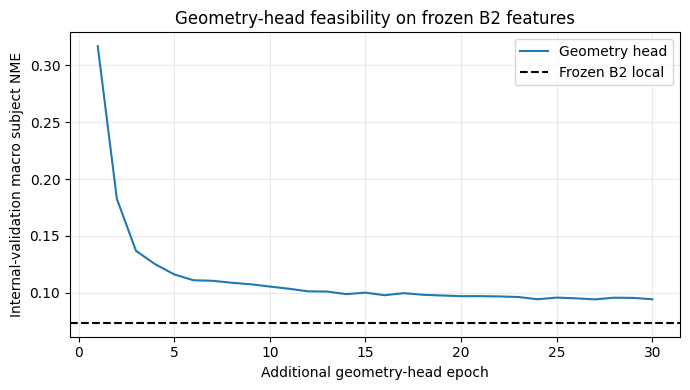


SUMMARY
{
  "status": "FROZEN_BACKBONE_GEOMETRY_EXPERIMENT_COMPLETED",
  "best_geometry_epoch": 27,
  "best_geometry_validation_nme": 0.0941924943565305,
  "frozen_B2_local_validation_nme": 0.07352324513047562,
  "geometry_minus_local_nme": 0.020669249226054884,
  "frozen_parameters_and_buffers_unchanged": true,
  "test_data_evaluated": false,
  "interpretation": "Head-feasibility development experiment; geometry had 30 additional epochs on a validation-selected B2 representation. Not a matched-budget superiority comparison."
}

BLOCK 29 COMPLETED


In [ ]:
# FETALGEO_BLOCK29_V1
# Frozen-B2 geometry-head experiment, first development seed.
# No consistency loss. Internal validation only.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import time
import gc

import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "selected", "models", "criterion",
    "validate", "mean", "std", "LOCAL",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Runtime variables missing: {missing}. Share this error; "
        "do not rerun completed training experiments."
    )
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training selection.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PARENT = PROJECT / "runs/B2_extended30_v1_seed20260912"
RUN29 = PROJECT / "runs/frozen_B2_geometry_v1_seed20260912"
RUN29.mkdir(parents=True, exist_ok=True)

SEED29 = 20260912
EPOCHS29 = 30
BATCH29 = 64

def sha29(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def save29(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

parent = torch.load(
    PARENT / "best.pt", map_location="cpu", weights_only=True
)
parent_config = parent["run_config"]
if parent_config["variant"] != "B2":
    raise ValueError("Parent checkpoint is not B2.")

for name, key in [
    ("model.py", "model_sha256"),
    ("losses.py", "loss_sha256"),
    ("loss_config.json", "loss_config_sha256"),
]:
    if sha29(Path(LOCAL) / name) != parent_config[key]:
        raise ValueError(f"Changed source/config: {name}")

initial_path = Path(LOCAL) / "shared_initial_state.pt"
if sha29(initial_path) != parent_config["initialization_sha256"]:
    raise ValueError("Initial head weights differ from the first-seed experiment.")

initial = torch.load(initial_path, map_location="cpu", weights_only=True)
model29 = models.FetalGeo(geometry=True, pretrained=False)
combined = {
    **parent["model"],
    **{
        name: value for name, value in initial.items()
        if name.startswith("geometry_head.")
    },
}
model29.load_state_dict(combined, strict=True)

for name, parameter in model29.named_parameters():
    parameter.requires_grad_(name.startswith("geometry_head."))

model29 = model29.cuda()
optimizer29 = torch.optim.AdamW(
    model29.geometry_head.parameters(), lr=1e-4, weight_decay=1e-4
)

config29 = {
    "experiment": "frozen_B2_geometry_head",
    "seed": SEED29,
    "epochs": EPOCHS29,
    "batch_size": BATCH29,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "parent_checkpoint": str(PARENT / "best.pt"),
    "parent_checkpoint_sha256": sha29(PARENT / "best.pt"),
    "parent_selected_epoch": int(parent["epoch"]),
    "initial_geometry_state_sha256": sha29(initial_path),
    "model_sha256": parent_config["model_sha256"],
    "loss_sha256": parent_config["loss_sha256"],
    "loss_config_sha256": parent_config["loss_config_sha256"],
    "objective": "supervised geometry loss only",
    "trainable_component": "geometry_head",
    "frozen_component_mode": "eval",
    "augmentation": "none",
    "checkpoint_selection": "geometry-head internal-validation NME",
    "policy_status": "PROVISIONAL",
}
config_path29 = RUN29 / "run_config.json"
if config_path29.exists():
    if json.loads(config_path29.read_text()) != config29:
        raise ValueError("Existing experiment configuration differs.")
else:
    config_path29.write_text(
        json.dumps(config29, indent=2), encoding="utf-8"
    )

# Reuse the established validation procedure with geometry endpoints.
class GeometryValidationView(torch.nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, images):
        result = self.base(images)
        return {"local_points": result["geometry_points"]}

geometry_view29 = GeometryValidationView(model29)
history29 = []
best29 = float("inf")
start29 = 1
last29 = RUN29 / "last.pt"

torch.manual_seed(SEED29)
torch.cuda.manual_seed_all(SEED29)

if last29.exists():
    checkpoint29 = torch.load(
        last29, map_location="cpu", weights_only=True
    )
    if checkpoint29["run_config"] != config29:
        raise ValueError("Resume configuration mismatch.")
    model29.load_state_dict(checkpoint29["model"])
    optimizer29.load_state_dict(checkpoint29["optimizer"])
    torch.set_rng_state(checkpoint29["torch_rng"])
    torch.cuda.set_rng_state_all(checkpoint29["cuda_rng"])
    history29 = checkpoint29["history"]
    best29 = float(checkpoint29["best_nme"])
    start29 = int(checkpoint29["epoch"]) + 1
    del checkpoint29

def verify_frozen_state29():
    current = model29.state_dict()
    for name, expected in parent["model"].items():
        if not torch.equal(current[name].detach().cpu(), expected):
            raise ValueError(f"Frozen B2 parameter/buffer changed: {name}")

verify_frozen_state29()
local_nme29, _, _ = validate(model29)
if abs(local_nme29 - float(parent["best_nme"])) > 1e-4:
    raise ValueError("Frozen local predictions do not reproduce B2 validation.")

print(f"Frozen B2 local validation NME: {local_nme29:.6f}", flush=True)
print(f"Starting geometry-head epoch {start29}", flush=True)

for epoch in range(start29, EPOCHS29 + 1):
    started29 = time.perf_counter()

    # Crucial: do not call model29.train(), which would update frozen BN buffers.
    model29.eval()
    model29.geometry_head.train()

    loader29 = DataLoader(
        dataset,
        batch_size=BATCH29,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        pin_memory=True,
        generator=torch.Generator().manual_seed(SEED29 + epoch),
    )
    total29 = 0.0
    seen29 = 0

    for images, points, masks, weights in loader29:
        count = len(images)
        images = images.permute(0, 3, 1, 2).to(
            "cuda", dtype=torch.float32, non_blocking=True
        ) / 255.0
        images = (images - mean) / std
        points = points.cuda(non_blocking=True)
        masks = masks.cuda(non_blocking=True)
        weights = weights.cuda(non_blocking=True)

        optimizer29.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            output29 = model29(images)
            geometry_loss29 = criterion(
                output29, points, masks, weights, "A1"
            )["geometry"]

        if not torch.isfinite(geometry_loss29):
            raise ValueError("Nonfinite geometry loss.")
        geometry_loss29.backward()
        torch.nn.utils.clip_grad_norm_(
            model29.geometry_head.parameters(),
            1.0,
            error_if_nonfinite=True,
        )
        optimizer29.step()

        total29 += float(geometry_loss29.detach()) * count
        seen29 += count

    if seen29 != len(dataset):
        raise ValueError("Training image count mismatch.")

    geo_nme29, per_measurement29, validation_rows29 = validate(
        geometry_view29
    )
    verify_frozen_state29()
    torch.cuda.synchronize()
    elapsed29 = time.perf_counter() - started29

    improved29 = geo_nme29 < best29
    best29 = min(best29, geo_nme29)
    history29.append({
        "epoch": epoch,
        "training_geometry_loss": total29 / seen29,
        "geometry_validation_nme": geo_nme29,
        "frozen_local_validation_nme": local_nme29,
        "train_and_validation_seconds": elapsed29,
        **{
            f"geometry_{name}_nme": value
            for name, value in per_measurement29.items()
        },
    })

    payload29 = {
        "run_config": config29,
        "epoch": epoch,
        "model": model29.state_dict(),
        "optimizer": optimizer29.state_dict(),
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all(),
        "history": history29,
        "best_nme": best29,
    }
    if improved29:
        save29(RUN29 / "best.pt", payload29)
        validation_rows29.to_csv(
            RUN29 / "best_geometry_validation_nme.csv", index=False
        )
    save29(last29, payload29)
    pd.DataFrame(history29).to_csv(RUN29 / "history.csv", index=False)

    print(
        f"Geometry {epoch:02d}/30 | loss {total29 / seen29:.4f} | "
        f"geometry NME {geo_nme29:.4f} | "
        f"frozen B2 {local_nme29:.4f} | {elapsed29:.1f}s",
        flush=True,
    )

verify_frozen_state29()
table29 = pd.DataFrame(history29)
best_row29 = table29.loc[table29["geometry_validation_nme"].idxmin()]
report29 = {
    "status": "FROZEN_BACKBONE_GEOMETRY_EXPERIMENT_COMPLETED",
    "best_geometry_epoch": int(best_row29["epoch"]),
    "best_geometry_validation_nme": float(
        best_row29["geometry_validation_nme"]
    ),
    "frozen_B2_local_validation_nme": local_nme29,
    "geometry_minus_local_nme": float(
        best_row29["geometry_validation_nme"] - local_nme29
    ),
    "frozen_parameters_and_buffers_unchanged": True,
    "test_data_evaluated": False,
    "interpretation": (
        "Head-feasibility development experiment; geometry had 30 additional "
        "epochs on a validation-selected B2 representation. Not a matched-budget "
        "superiority comparison."
    ),
}
(RUN29 / "experiment_summary.json").write_text(
    json.dumps(report29, indent=2), encoding="utf-8"
)

stamp29 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
for folder in ["figures/data", "figures/final", "figures/captions"]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)

tag29 = f"frozen_geometry_{stamp29}"
data29 = PAPER / "figures/data" / f"{tag29}.csv"
png29 = PAPER / "figures/final" / f"{tag29}.png"
pdf29 = PAPER / "figures/final" / f"{tag29}.pdf"
caption29 = PAPER / "figures/captions" / f"{tag29}.txt"
table29.to_csv(data29, index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    table29["epoch"], table29["geometry_validation_nme"],
    label="Geometry head",
)
ax.axhline(local_nme29, linestyle="--", color="black", label="Frozen B2 local")
ax.set_xlabel("Additional geometry-head epoch")
ax.set_ylabel("Internal-validation macro subject NME")
ax.set_title("Geometry-head feasibility on frozen B2 features")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(png29, dpi=300, bbox_inches="tight")
fig.savefig(pdf29, bbox_inches="tight")
plt.show()
plt.close(fig)

caption29.write_text(
    report29["interpretation"]
    + "\nSupervised geometry loss only. No consistency, augmentation, or test "
    "evaluation. Existing provisional validation policy retained.\n",
    encoding="utf-8",
)

index29 = PAPER / "ARTIFACT_INDEX.csv"
entry29 = pd.DataFrame([{
    "artifact_id": tag29,
    "type": "figure",
    "title": "Geometry-head learning on frozen B2 features",
    "status": "candidate",
    "source_data_path": str(data29),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK29_V1",
    "output_paths": f"{png29}|{pdf29}",
    "caption_path": str(caption29),
}])
if index29.exists() and index29.stat().st_size:
    entry29 = pd.concat([
        pd.read_csv(index29, keep_default_na=False), entry29
    ], ignore_index=True)
entry29.fillna("").to_csv(index29, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 29 frozen-B2 geometry experiment — {stamp29}\n\n"
        + report29["interpretation"]
        + "\n\n```json\n"
        + json.dumps(report29, indent=2)
        + "\n```\n\n"
        + f"Run: `{RUN29}`\n"
        + f"Learning curve: `{pdf29}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report29, indent=2))
print("\nBLOCK 29 COMPLETED")

In [ ]:
# FETALGEO_BLOCK30_V1
# Same-capacity direct-endpoint head on frozen B2 features.
# Requires dataset, selected, models, validate, mean, std from current runtime.

from pathlib import Path
from datetime import datetime, timezone
import importlib.util
import hashlib
import json
import os
import time
import gc

import pandas as pd
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader

required = ["dataset", "selected", "models", "validate", "mean", "std", "LOCAL"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Runtime missing: {missing}. Share this error.")
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training dataset.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PARENT30 = PROJECT / "runs/B2_extended30_v1_seed20260912"
GEOMETRY30 = PROJECT / "runs/frozen_B2_geometry_v1_seed20260912"
RUN30 = PROJECT / "runs/frozen_B2_direct_head_v1_seed20260912"
RUN30.mkdir(parents=True, exist_ok=True)

def sha30(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def save30(path, value):
    temporary = path.with_suffix(".partial")
    torch.save(value, temporary)
    os.replace(temporary, path)

parent30 = torch.load(
    PARENT30 / "best.pt", map_location="cpu", weights_only=True
)
geometry_config30 = json.loads((GEOMETRY30 / "run_config.json").read_text())
loss_config30 = json.loads((Path(LOCAL) / "loss_config.json").read_text())

for filename, key in [
    ("model.py", "model_sha256"),
    ("losses.py", "loss_sha256"),
    ("loss_config.json", "loss_config_sha256"),
]:
    if sha30(Path(LOCAL) / filename) != parent30["run_config"][key]:
        raise ValueError(f"Changed source/config: {filename}")

if sha30(PARENT30 / "best.pt") != geometry_config30["parent_checkpoint_sha256"]:
    raise ValueError("Parent differs from the frozen-geometry experiment.")

initial_path30 = Path(LOCAL) / "shared_initial_state.pt"
if sha30(initial_path30) != geometry_config30["initial_geometry_state_sha256"]:
    raise ValueError("Initial auxiliary-head weights differ.")

spec30 = importlib.util.spec_from_file_location(
    "losses30", Path(LOCAL) / "losses.py"
)
losses30 = importlib.util.module_from_spec(spec30)
spec30.loader.exec_module(losses30)

# Same projections, fusion and 4x4 pooled MLP as the geometry experiment.
# Only auxiliary output interpretation and its supervised loss change.
class DirectEndpointControl(torch.nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, images):
        # Frozen features: no autograd graph or BatchNorm updates.
        with torch.no_grad():
            features = self.base.backbone(images)
            projected = [
                F.interpolate(
                    projection(features[level]),
                    size=(64, 64),
                    mode="bilinear",
                    align_corners=False,
                )
                for projection, level in zip(
                    self.base.projections, self.base.selected_levels
                )
            ]
            fused = self.base.fusion(torch.cat(projected, dim=1))

        raw = self.base.geometry_head(fused).float().reshape(-1, 5, 2, 2)
        # validate() expects the key local_points; here it means control output.
        return {"local_points": raw.sigmoid() * 255.0}

initial30 = torch.load(
    initial_path30, map_location="cpu", weights_only=True
)
base30 = models.FetalGeo(geometry=True, pretrained=False)
base30.load_state_dict({
    **parent30["model"],
    **{
        name: value for name, value in initial30.items()
        if name.startswith("geometry_head.")
    },
}, strict=True)
for name, parameter in base30.named_parameters():
    parameter.requires_grad_(name.startswith("geometry_head."))
base30 = base30.cuda()
control30 = DirectEndpointControl(base30)
optimizer30 = torch.optim.AdamW(
    base30.geometry_head.parameters(), lr=1e-4, weight_decay=1e-4
)

weight_totals30 = torch.tensor(
    loss_config30["measurement_weight_totals"], device="cuda"
)

def direct_loss30(prediction, target, mask, weight):
    if not mask.any():
        raise ValueError("Batch has no eligible measurements.")
    truth = target[mask].float() / 255.0
    if not torch.isfinite(truth).all():
        raise ValueError("Nonfinite eligible target.")
    errors = losses30.pair_distance(
        prediction[mask].float() / 255.0, truth
    )
    batch_size = target.shape[0]
    measurement_ids = torch.arange(5, device="cuda").expand(batch_size, 5)[mask]
    factors = (
        weight[mask] / weight_totals30[measurement_ids]
        * (len(dataset) / batch_size) / 5.0
    )
    return (errors * factors).sum()

config30 = {
    "experiment": "frozen_B2_direct_endpoint_head",
    "seed": 20260912,
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "parent_sha256": sha30(PARENT30 / "best.pt"),
    "initialization_sha256": sha30(initial_path30),
    "head_parameters": sum(p.numel() for p in base30.geometry_head.parameters()),
    "supervision": "unordered endpoint Smooth L1",
    "policy_status": "PROVISIONAL",
}
config_path30 = RUN30 / "run_config.json"
if config_path30.exists():
    if json.loads(config_path30.read_text()) != config30:
        raise ValueError("Existing control configuration differs.")
else:
    config_path30.write_text(json.dumps(config30, indent=2), encoding="utf-8")

history30 = []
best30 = float("inf")
first30 = 1
torch.manual_seed(20260912)
torch.cuda.manual_seed_all(20260912)

if (RUN30 / "last.pt").exists():
    checkpoint30 = torch.load(
        RUN30 / "last.pt", map_location="cpu", weights_only=True
    )
    if checkpoint30["run_config"] != config30:
        raise ValueError("Resume configuration mismatch.")
    base30.load_state_dict(checkpoint30["model"])
    optimizer30.load_state_dict(checkpoint30["optimizer"])
    torch.set_rng_state(checkpoint30["torch_rng"])
    torch.cuda.set_rng_state_all(checkpoint30["cuda_rng"])
    history30 = checkpoint30["history"]
    best30 = checkpoint30["best_nme"]
    first30 = checkpoint30["epoch"] + 1
    del checkpoint30

def check_frozen30():
    for name, expected in parent30["model"].items():
        if not torch.equal(base30.state_dict()[name].detach().cpu(), expected):
            raise ValueError(f"Frozen parameter/buffer changed: {name}")

check_frozen30()
print(f"Auxiliary-head parameters: {config30['head_parameters']:,}", flush=True)

for epoch in range(first30, 31):
    started30 = time.perf_counter()
    control30.eval()
    base30.geometry_head.train()

    loader30 = DataLoader(
        dataset, batch_size=64, shuffle=True, num_workers=0,
        pin_memory=True, drop_last=False,
        generator=torch.Generator().manual_seed(20260912 + epoch),
    )
    loss_sum30 = 0.0
    seen30 = 0

    for images, targets, masks, weights in loader30:
        count = len(images)
        images = images.permute(0, 3, 1, 2).cuda().float() / 255.0
        images = (images - mean) / std
        targets, masks, weights = targets.cuda(), masks.cuda(), weights.cuda()

        optimizer30.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            prediction30 = control30(images)["local_points"]
            objective30 = direct_loss30(prediction30, targets, masks, weights)
        if not torch.isfinite(objective30):
            raise ValueError("Nonfinite direct-head loss.")
        objective30.backward()
        torch.nn.utils.clip_grad_norm_(
            base30.geometry_head.parameters(), 1.0, error_if_nonfinite=True
        )
        optimizer30.step()
        loss_sum30 += float(objective30.detach()) * count
        seen30 += count

    if seen30 != len(dataset):
        raise ValueError("Training count mismatch.")

    nme30, metric30, rows30 = validate(control30)
    check_frozen30()
    torch.cuda.synchronize()
    elapsed30 = time.perf_counter() - started30
    improved30 = nme30 < best30
    best30 = min(best30, nme30)
    history30.append({
        "epoch": epoch,
        "training_loss": loss_sum30 / seen30,
        "validation_nme": nme30,
        "train_and_validation_seconds": elapsed30,
        **{f"{name}_nme": value for name, value in metric30.items()},
    })

    payload30 = {
        "run_config": config30,
        "epoch": epoch,
        "model": base30.state_dict(),
        "optimizer": optimizer30.state_dict(),
        "history": history30,
        "best_nme": best30,
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all(),
    }
    if improved30:
        save30(RUN30 / "best.pt", payload30)
        rows30.to_csv(RUN30 / "best_validation_nme.csv", index=False)
    save30(RUN30 / "last.pt", payload30)
    pd.DataFrame(history30).to_csv(RUN30 / "history.csv", index=False)
    print(
        f"Direct head {epoch:02d}/30 | loss {loss_sum30 / seen30:.4f} | "
        f"validation NME {nme30:.4f} | {elapsed30:.1f}s",
        flush=True,
    )

geometry_report30 = json.loads(
    (GEOMETRY30 / "experiment_summary.json").read_text()
)
best_row30 = pd.DataFrame(history30).sort_values("validation_nme").iloc[0]
comparison30 = pd.DataFrame([
    {
        "prediction": "Frozen B2 local",
        "best_validation_nme": float(parent30["best_nme"]),
    },
    {
        "prediction": "Frozen-feature geometry head",
        "best_validation_nme": geometry_report30["best_geometry_validation_nme"],
    },
    {
        "prediction": "Frozen-feature direct endpoint head",
        "best_validation_nme": float(best_row30["validation_nme"]),
    },
])
comparison30.to_csv(RUN30 / "comparison.csv", index=False)

report30 = {
    "status": "DIRECT_HEAD_CONTROL_COMPLETED",
    "best_direct_head_epoch": int(best_row30["epoch"]),
    "best_direct_head_nme": float(best_row30["validation_nme"]),
    "head_parameters": config30["head_parameters"],
    "frozen_state_unchanged": True,
    "test_data_evaluated": False,
    "limitation": (
        "Single-seed feasibility control. Changes parameterization and "
        "supervised objective together; cannot isolate their individual effects. "
        "Direct endpoints are bounded by sigmoid; geometry endpoints are unbounded."
    ),
}
(RUN30 / "experiment_summary.json").write_text(
    json.dumps(report30, indent=2), encoding="utf-8"
)

stamp30 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
(PAPER / "tables/data").mkdir(parents=True, exist_ok=True)
(PAPER / "tables/notes").mkdir(parents=True, exist_ok=True)
table30 = PAPER / "tables/data" / f"frozen_head_control_{stamp30}.csv"
note30 = PAPER / "tables/notes" / f"frozen_head_control_{stamp30}.txt"
comparison30.to_csv(table30, index=False)
note30.write_text(report30["limitation"], encoding="utf-8")

artifact30 = pd.DataFrame([{
    "artifact_id": f"frozen_head_control_{stamp30}",
    "type": "table",
    "title": "Frozen-feature auxiliary-head comparison",
    "status": "candidate",
    "source_data_path": str(RUN30 / "history.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK30_V1",
    "output_paths": str(table30),
    "caption_path": str(note30),
}])
index30 = PAPER / "ARTIFACT_INDEX.csv"
if index30.exists() and index30.stat().st_size:
    artifact30 = pd.concat([
        pd.read_csv(index30, keep_default_na=False), artifact30
    ], ignore_index=True)
artifact30.fillna("").to_csv(index30, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 30 direct-endpoint head control — {stamp30}\n\n"
        + report30["limitation"]
        + "\n\n```text\n"
        + comparison30.to_string(index=False)
        + "\n```\n\n"
        + f"Run: `{RUN30}`\n"
        + f"Candidate table: `{table30}`\n"
    )

print("\nFROZEN-FEATURE HEAD COMPARISON")
print(comparison30.to_string(index=False))
print("\nSUMMARY")
print(json.dumps(report30, indent=2))
print("\nBLOCK 30 COMPLETED")

Auxiliary-head parameters: 133,780
Direct head 01/30 | loss 0.0950 | validation NME 0.2222 | 19.0s
Direct head 02/30 | loss 0.0417 | validation NME 0.1504 | 18.6s
Direct head 03/30 | loss 0.0235 | validation NME 0.1174 | 18.1s
Direct head 04/30 | loss 0.0157 | validation NME 0.1038 | 17.8s
Direct head 05/30 | loss 0.0127 | validation NME 0.0989 | 18.0s
Direct head 06/30 | loss 0.0112 | validation NME 0.0949 | 17.7s
Direct head 07/30 | loss 0.0101 | validation NME 0.0945 | 19.5s
Direct head 08/30 | loss 0.0093 | validation NME 0.0946 | 18.2s
Direct head 09/30 | loss 0.0086 | validation NME 0.0929 | 16.2s
Direct head 10/30 | loss 0.0080 | validation NME 0.0923 | 15.9s
Direct head 11/30 | loss 0.0075 | validation NME 0.0923 | 15.8s
Direct head 12/30 | loss 0.0072 | validation NME 0.0906 | 15.7s
Direct head 13/30 | loss 0.0070 | validation NME 0.0909 | 16.1s
Direct head 14/30 | loss 0.0067 | validation NME 0.0907 | 15.5s
Direct head 15/30 | loss 0.0064 | validation NME 0.0900 | 16.4s
Direc

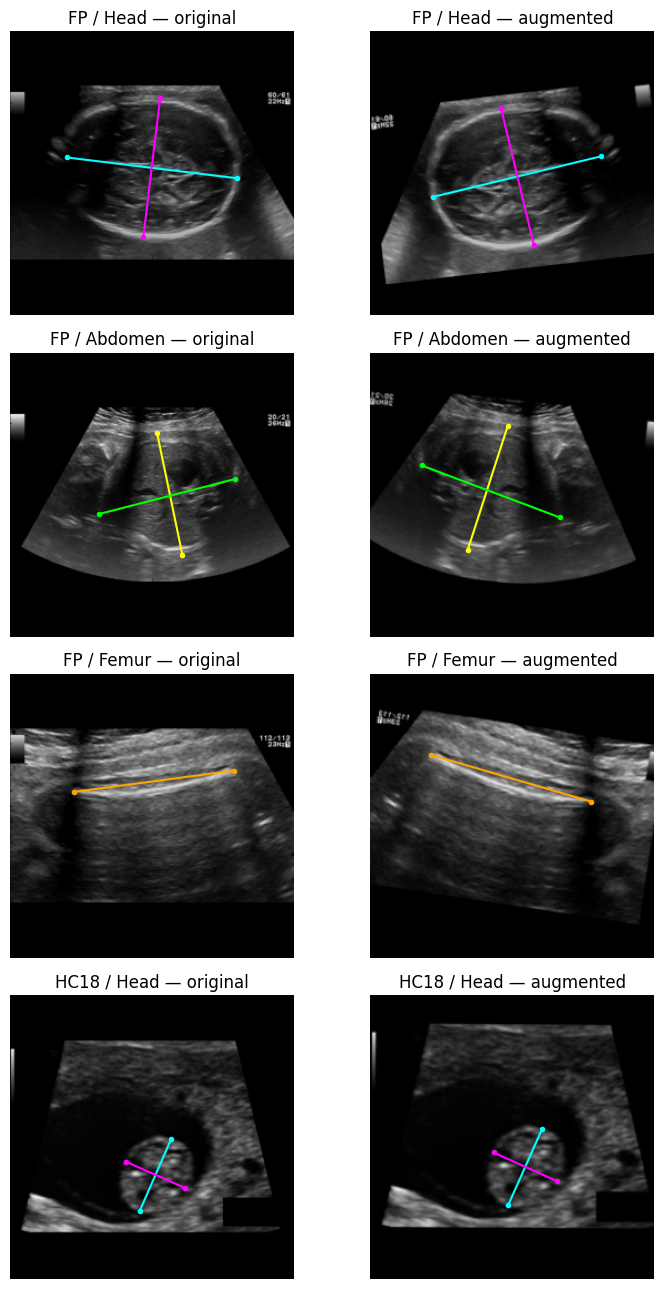


SUMMARY
{
  "status": "AUGMENTATION_ARITHMETIC_CHECKS_PASSED",
  "source_path": "/content/drive/MyDrive/FetalGeo/code/augmentation_v1_20260912T182811995354Z/fetalgeo_augmentation.py",
  "source_sha256": "3caa8f5997d8caf1997ae16098712a628e897ddbc87a9a5f91f451169c88893a",
  "identity_translation_flip_and_mask_checks": "PASSED",
  "visual_review": "PENDING",
  "training_performed": false,
  "policy": "Apply before normalization; use identical draws within matched seeds. Retain original training normalization totals after augmentation masking. A wholly masked batch must skip its optimizer step."
}

BLOCK 31 COMPLETED


In [ ]:
# FETALGEO_BLOCK31_V1
# Save and verify shared image/landmark augmentation.
# Uses training images only. No model updates.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
if "dataset" not in globals() or "selected" not in globals():
    raise RuntimeError("Training RAM dataset missing. Share this error.")
if len(dataset) != len(selected) or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training dataset/index.")

stamp31 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT31 = PROJECT / "code" / f"augmentation_v1_{stamp31}"
OUT31.mkdir(parents=True, exist_ok=False)

SOURCE31 = r'''
import math
import torch
from torch.nn import functional as F

def warp_batch(images, points, mask, weight, matrix):
    """
    images: B,C,H,W float RGB in [0,1], before normalization.
    points: B,5,2,2, cached-image zero-based pixel coordinates.
    matrix: B,3,3 forward transform in normalized align_corners=False space.
    """
    batch, _, height, width = images.shape
    inverse = torch.linalg.inv(matrix)
    grid = F.affine_grid(
        inverse[:, :2], images.shape, align_corners=False
    )
    warped = F.grid_sample(
        images, grid, mode="bilinear",
        padding_mode="zeros", align_corners=False,
    )

    # Remove masked NaNs before arithmetic.
    clean = torch.where(
        mask[..., None, None], points, torch.zeros_like(points)
    )
    dimensions = images.new_tensor([width, height])
    normalized = 2.0 * (clean + 0.5) / dimensions - 1.0
    homogeneous = torch.cat(
        [normalized, torch.ones_like(normalized[..., :1])], dim=-1
    )
    transformed = torch.einsum(
        "bij,bmkj->bmki", matrix, homogeneous
    )[..., :2]
    pixels = (transformed + 1.0) * dimensions / 2.0 - 0.5

    finite = torch.isfinite(pixels).all(dim=(-1, -2))
    inside = (
        (pixels[..., 0] >= 0)
        & (pixels[..., 0] <= width - 1)
        & (pixels[..., 1] >= 0)
        & (pixels[..., 1] <= height - 1)
    ).all(dim=-1)
    new_mask = mask & finite & inside
    new_weight = torch.where(new_mask, weight, torch.zeros_like(weight))
    pixels = torch.where(
        new_mask[..., None, None], pixels, torch.zeros_like(pixels)
    )
    return warped, pixels, new_mask, new_weight

def augment_batch(images, points, mask, weight, generator):
    batch = images.shape[0]
    draws = torch.rand(
        batch, 7, device=images.device, generator=generator
    )
    angle = (draws[:, 0] * 20.0 - 10.0) * math.pi / 180.0
    scale = 0.9 + 0.2 * draws[:, 1]
    flip = torch.where(draws[:, 2] < 0.5, -1.0, 1.0)
    cosine, sine = angle.cos(), angle.sin()

    matrix = torch.eye(
        3, device=images.device, dtype=images.dtype
    ).repeat(batch, 1, 1)
    matrix[:, 0, 0] = scale * cosine * flip
    matrix[:, 0, 1] = -scale * sine
    matrix[:, 1, 0] = scale * sine * flip
    matrix[:, 1, 1] = scale * cosine

    # Normalized translation +/-0.10 equals +/-5% of image width/height.
    matrix[:, 0, 2] = (draws[:, 3] * 2.0 - 1.0) * 0.10
    matrix[:, 1, 2] = (draws[:, 4] * 2.0 - 1.0) * 0.10

    warped, points, mask, weight = warp_batch(
        images, points, mask, weight, matrix
    )
    gain = (0.9 + 0.2 * draws[:, 5])[:, None, None, None]
    gamma = (0.9 + 0.2 * draws[:, 6])[:, None, None, None]
    warped = (warped.clamp(0, 1).pow(gamma) * gain).clamp(0, 1)
    return warped, points, mask, weight, matrix
'''

compile(SOURCE31, "fetalgeo_augmentation.py", "exec")
source_path31 = OUT31 / "fetalgeo_augmentation.py"
source_path31.write_text(SOURCE31, encoding="utf-8")
spec31 = importlib.util.spec_from_file_location("augmentation31", source_path31)
augmentation31 = importlib.util.module_from_spec(spec31)
spec31.loader.exec_module(augmentation31)

# CPU tests: known pixel-to-landmark alignment and out-of-frame masking.
test_image31 = torch.zeros(1, 3, 256, 256)
test_image31[:, :, 40, 30] = 1.0
test_points31 = torch.zeros(1, 5, 2, 2)
test_points31[0, 0] = torch.tensor([[30.0, 40.0], [60.0, 70.0]])
test_mask31 = torch.tensor([[True, False, False, False, False]])
test_weight31 = test_mask31.float()
identity31 = torch.eye(3).unsqueeze(0)

image0, points0, mask0, weight0 = augmentation31.warp_batch(
    test_image31, test_points31, test_mask31, test_weight31, identity31
)
assert torch.allclose(image0, test_image31, atol=1e-5)
assert torch.allclose(points0, test_points31, atol=1e-5)
assert torch.equal(mask0, test_mask31)
assert torch.equal(weight0, test_weight31)

translation31 = identity31.clone()
translation31[:, 0, 2] = 2 * 8 / 256
translation31[:, 1, 2] = 2 * 4 / 256
image1, points1, _, _ = augmentation31.warp_batch(
    test_image31, test_points31, test_mask31, test_weight31, translation31
)
assert image1[0, 0, 44, 38] > 0.99
assert torch.allclose(
    points1[0, 0], test_points31[0, 0] + torch.tensor([8.0, 4.0]),
    atol=1e-5,
)

reflection31 = identity31.clone()
reflection31[:, 0, 0] = -1
image2, points2, _, _ = augmentation31.warp_batch(
    test_image31, test_points31, test_mask31, test_weight31, reflection31
)
assert image2[0, 0, 40, 225] > 0.99
assert torch.allclose(
    points2[0, 0, :, 0], 255 - test_points31[0, 0, :, 0], atol=1e-5
)

outside31 = identity31.clone()
outside31[:, 0, 2] = 3.0
_, points3, mask3, weight3 = augmentation31.warp_batch(
    test_image31, test_points31, test_mask31, test_weight31, outside31
)
assert not mask3.any()
assert torch.count_nonzero(weight3) == 0
assert torch.isfinite(points3).all()

# One deterministic eligible training image from each source/anatomy group.
positions31 = []
for source, anatomy in [
    ("FP", "Head"), ("FP", "Abdomen"), ("FP", "Femur"), ("HC18", "Head")
]:
    positions = np.flatnonzero(
        selected["source"].eq(source).to_numpy()
        & selected["anatomy"].eq(anatomy).to_numpy()
    )
    if not len(positions):
        raise ValueError(f"Missing training group: {source}/{anatomy}")
    positions31.append(int(positions[0]))

examples31 = [dataset[position] for position in positions31]
images31 = torch.stack([item[0] for item in examples31])
images31 = images31.permute(0, 3, 1, 2).float() / 255.0
points31 = torch.stack([item[1] for item in examples31])
masks31 = torch.stack([item[2] for item in examples31])
weights31 = torch.stack([item[3] for item in examples31])

augmented31, transformed31, valid31, new_weights31, matrices31 = (
    augmentation31.augment_batch(
        images31, points31, masks31, weights31,
        torch.Generator().manual_seed(20260912),
    )
)
assert torch.isfinite(augmented31).all()
assert not (valid31 & ~masks31).any()
assert torch.equal(new_weights31[valid31], weights31[valid31])

PAPER = PROJECT / "paper_artifacts"
for directory in ["figures/final", "figures/data", "figures/captions"]:
    (PAPER / directory).mkdir(parents=True, exist_ok=True)
tag31 = f"augmentation_check_{stamp31}"
png31 = PAPER / "figures/final" / f"{tag31}.png"
pdf31 = PAPER / "figures/final" / f"{tag31}.pdf"
data31 = PAPER / "figures/data" / f"{tag31}.npz"
caption31 = PAPER / "figures/captions" / f"{tag31}.txt"

np.savez_compressed(
    data31,
    record_ids=selected.iloc[positions31]["record_id"].to_numpy(dtype=str),
    original_images=images31.numpy(),
    augmented_images=augmented31.numpy(),
    original_points=points31.numpy(),
    augmented_points=transformed31.numpy(),
    original_masks=masks31.numpy(),
    augmented_masks=valid31.numpy(),
    matrices=matrices31.numpy(),
)

colors31 = ["cyan", "magenta", "yellow", "lime", "orange"]
fig, axes = plt.subplots(4, 2, figsize=(8, 13))
for row, position in enumerate(positions31):
    label = (
        str(selected.iloc[position]["source"]) + " / "
        + str(selected.iloc[position]["anatomy"])
    )
    for column, (images, points, masks) in enumerate([
        (images31, points31, masks31),
        (augmented31, transformed31, valid31),
    ]):
        ax = axes[row, column]
        ax.imshow(images[row].permute(1, 2, 0).numpy())
        for measurement in range(5):
            if masks[row, measurement]:
                p = points[row, measurement].numpy()
                ax.plot(p[:, 0], p[:, 1], "-o",
                        color=colors31[measurement], markersize=3)
        ax.set_title(label + (" — original" if column == 0 else " — augmented"))
        ax.set_xlim(-0.5, 255.5)
        ax.set_ylim(255.5, -0.5)
        ax.axis("off")
fig.tight_layout()
fig.savefig(png31, dpi=250, bbox_inches="tight")
fig.savefig(pdf31, bbox_inches="tight")
plt.show()
plt.close(fig)

caption31.write_text(
    "Training-only augmentation check. Left: cached image; right: transformed.\n"
    "Same spatial transform applied to image and landmarks. Measurements moved "
    "outside the output image are masked. Remaining duplicate weights unchanged.\n"
    "Rotation +/-10 degrees, scale 0.9–1.1, translation +/-5%, flip probability 0.5, "
    "gain/gamma 0.9–1.1. Visual review pending.\n",
    encoding="utf-8",
)

report31 = {
    "status": "AUGMENTATION_ARITHMETIC_CHECKS_PASSED",
    "source_path": str(source_path31),
    "source_sha256": hashlib.sha256(source_path31.read_bytes()).hexdigest(),
    "identity_translation_flip_and_mask_checks": "PASSED",
    "visual_review": "PENDING",
    "training_performed": False,
    "policy": (
        "Apply before normalization; use identical draws within matched seeds. "
        "Retain original training normalization totals after augmentation masking. "
        "A wholly masked batch must skip its optimizer step."
    ),
}
(OUT31 / "augmentation_check.json").write_text(
    json.dumps(report31, indent=2), encoding="utf-8"
)

entry31 = pd.DataFrame([{
    "artifact_id": tag31,
    "type": "figure",
    "title": "Training image and landmark augmentation check",
    "status": "candidate",
    "source_data_path": str(data31),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK31_V1",
    "output_paths": f"{png31}|{pdf31}",
    "caption_path": str(caption31),
}])
index31 = PAPER / "ARTIFACT_INDEX.csv"
if index31.exists() and index31.stat().st_size:
    entry31 = pd.concat([
        pd.read_csv(index31, keep_default_na=False), entry31
    ], ignore_index=True)
entry31.fillna("").to_csv(index31, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 31 shared augmentation preparation — {stamp31}\n\n"
        "- Identity, translation, horizontal reflection, and masking checks passed.\n"
        "- Training-only examples saved; visual review pending; no training.\n"
        f"- Code: `{source_path31}`\n"
        f"- Figure: `{pdf31}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report31, indent=2))
print("\nBLOCK 31 COMPLETED")


B2 + augmentation: starting epoch 1
B2+aug 01/30 | loss 7.1266 | validation NME 0.2487 | labels 2871/2874 | 8.0s
B2+aug 02/30 | loss 5.2093 | validation NME 0.1195 | labels 2872/2874 | 7.2s
B2+aug 03/30 | loss 4.7730 | validation NME 0.1068 | labels 2869/2874 | 7.4s
B2+aug 04/30 | loss 4.5581 | validation NME 0.1081 | labels 2872/2874 | 7.2s
B2+aug 05/30 | loss 4.4572 | validation NME 0.1043 | labels 2870/2874 | 7.1s
B2+aug 06/30 | loss 4.3571 | validation NME 0.0843 | labels 2869/2874 | 7.1s
B2+aug 07/30 | loss 4.2912 | validation NME 0.0775 | labels 2871/2874 | 7.2s
B2+aug 08/30 | loss 4.2486 | validation NME 0.0786 | labels 2871/2874 | 7.1s
B2+aug 09/30 | loss 4.2279 | validation NME 0.0748 | labels 2871/2874 | 7.1s
B2+aug 10/30 | loss 4.1522 | validation NME 0.0747 | labels 2870/2874 | 7.1s
B2+aug 11/30 | loss 4.1057 | validation NME 0.0736 | labels 2871/2874 | 7.2s
B2+aug 12/30 | loss 4.0955 | validation NME 0.0770 | labels 2872/2874 | 7.2s
B2+aug 13/30 | loss 4.0597 | validation

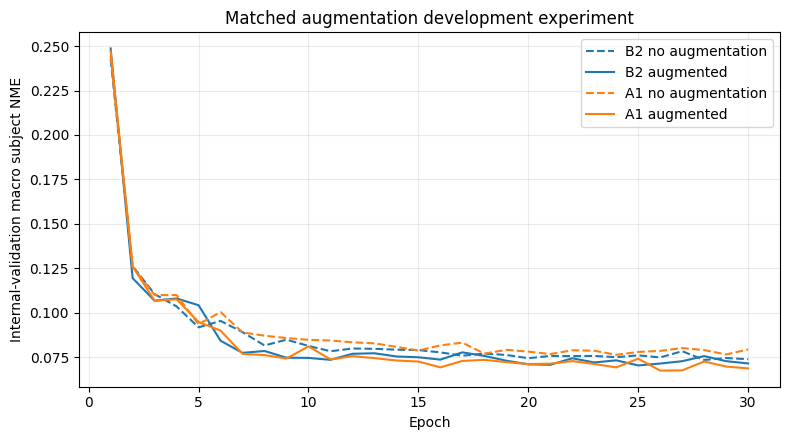


MATCHED AUGMENTATION COMPARISON
variant           augmentation  best_epoch  best_validation_nme  epoch30_validation_nme
     B2                   none          28             0.073523                0.073951
     B2 shared_augmentation_v1          25             0.070451                0.071569
     A1                   none          24             0.076399                0.079456
     A1 shared_augmentation_v1          26             0.067534                0.068778

Matched spatial augmentation check: PASSED

BLOCK 32 COMPLETED


In [ ]:
# FETALGEO_BLOCK32_V1
# Matched augmented B2/A1 development experiment.
# Requires the current RAM training dataset and Block 31 augmentation module.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time

import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "selected", "models", "criterion", "validate",
    "mean", "std", "LOCAL", "augmentation31", "source_path31",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Runtime variables missing: {missing}. Share this error.")
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training dataset.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
SEED32 = 20260912
EPOCHS32 = 30
BATCH32 = 64

def sha32(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def save32(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

base32 = json.loads((
    PROJECT / "runs/B2_pilot_v1_seed20260912/run_config.json"
).read_text())
for filename, key in [
    ("model.py", "model_sha256"),
    ("losses.py", "loss_sha256"),
    ("loss_config.json", "loss_config_sha256"),
]:
    if sha32(Path(LOCAL) / filename) != base32[key]:
        raise ValueError(f"Changed source/config: {filename}")

augmentation_report32 = json.loads(
    (Path(source_path31).parent / "augmentation_check.json").read_text()
)
if sha32(source_path31) != augmentation_report32["source_sha256"]:
    raise ValueError("Augmentation source checksum mismatch.")

initial_path32 = Path(LOCAL) / "shared_initial_state.pt"
if sha32(initial_path32) != base32["initialization_sha256"]:
    raise ValueError("Shared initialization checksum mismatch.")
shared32 = torch.load(initial_path32, map_location="cpu", weights_only=True)

histories32 = {}

for variant in ["B2", "A1"]:
    RUN32 = PROJECT / "runs" / f"{variant}_aug30_v1_seed{SEED32}"
    RUN32.mkdir(parents=True, exist_ok=True)
    config32 = {
        **base32,
        "variant": variant,
        "epochs": EPOCHS32,
        "purpose": "matched_augmentation_development",
        "augmentation": "rotation_scale_translation_flip_gain_gamma_v1",
        "augmentation_sha256": sha32(source_path31),
        "augmentation_source": str(source_path31),
        "augmentation_seed_rule": "seed + 100000 + epoch; dedicated CUDA generator",
        "masked_weight_normalization": "fixed original training totals",
    }
    config_path32 = RUN32 / "run_config.json"
    if config_path32.exists():
        if json.loads(config_path32.read_text()) != config32:
            raise ValueError(f"{variant}: existing configuration differs.")
    else:
        config_path32.write_text(
            json.dumps(config32, indent=2), encoding="utf-8"
        )

    model32 = models.FetalGeo(
        geometry=(variant != "B2"), pretrained=False
    )
    model32.load_state_dict({
        name: tensor for name, tensor in shared32.items()
        if variant != "B2" or not name.startswith("geometry_head.")
    }, strict=True)
    model32 = model32.cuda()
    optimizer32 = torch.optim.AdamW(
        model32.parameters(),
        lr=base32["learning_rate"],
        weight_decay=base32["weight_decay"],
    )

    torch.manual_seed(SEED32)
    torch.cuda.manual_seed_all(SEED32)
    history32 = []
    best32 = float("inf")
    first32 = 1
    last32 = RUN32 / "last.pt"

    if last32.exists():
        checkpoint32 = torch.load(
            last32, map_location="cpu", weights_only=True
        )
        if checkpoint32["run_config"] != config32:
            raise ValueError("Resume configuration mismatch.")
        model32.load_state_dict(checkpoint32["model"])
        optimizer32.load_state_dict(checkpoint32["optimizer"])
        torch.set_rng_state(checkpoint32["torch_rng"])
        torch.cuda.set_rng_state_all(checkpoint32["cuda_rng"])
        history32 = checkpoint32["history"]
        best32 = float(checkpoint32["best_nme"])
        first32 = int(checkpoint32["epoch"]) + 1
        del checkpoint32

    print(f"\n{variant} + augmentation: starting epoch {first32}", flush=True)

    for epoch in range(first32, EPOCHS32 + 1):
        started32 = time.perf_counter()
        model32.train()

        loader32 = DataLoader(
            dataset, batch_size=BATCH32, shuffle=True,
            drop_last=False, num_workers=0, pin_memory=True,
            generator=torch.Generator().manual_seed(SEED32 + epoch),
        )
        aug_generator32 = torch.Generator(device="cuda").manual_seed(
            SEED32 + 100000 + epoch
        )
        sum_loss32 = 0.0
        seen32 = 0
        eligible_before32 = 0
        eligible_after32 = 0
        skipped32 = 0
        matrix_digest32 = hashlib.sha256()

        for images, targets, masks, weights in loader32:
            count = len(images)
            images = images.permute(0, 3, 1, 2).to(
                "cuda", dtype=torch.float32, non_blocking=True
            ) / 255.0
            targets = targets.cuda(non_blocking=True)
            masks = masks.cuda(non_blocking=True)
            weights = weights.cuda(non_blocking=True)
            eligible_before32 += int(masks.sum())

            images, targets, masks, weights, matrices = (
                augmentation31.augment_batch(
                    images, targets, masks, weights, aug_generator32
                )
            )
            matrix_digest32.update(
                matrices.detach().cpu().numpy().tobytes()
            )
            eligible_after32 += int(masks.sum())
            seen32 += count

            if not masks.any():
                skipped32 += 1
                continue

            images = (images - mean) / std
            optimizer32.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                output32 = model32(images)
                objective32 = criterion(
                    output32, targets, masks, weights, variant
                )["total"]
            if not torch.isfinite(objective32):
                raise ValueError(f"{variant}: nonfinite augmented loss.")

            objective32.backward()
            torch.nn.utils.clip_grad_norm_(
                model32.parameters(), 1.0, error_if_nonfinite=True
            )
            optimizer32.step()
            sum_loss32 += float(objective32.detach()) * count

        if seen32 != len(dataset):
            raise ValueError("Training epoch image count mismatch.")

        val32, metric32, validation_rows32 = validate(model32)
        torch.cuda.synchronize()
        elapsed32 = time.perf_counter() - started32
        improved32 = val32 < best32
        best32 = min(best32, val32)

        history32.append({
            "epoch": epoch,
            "training_loss": sum_loss32 / seen32,
            "validation_macro_subject_nme": val32,
            "train_and_validation_seconds": elapsed32,
            "eligible_measurements_before": eligible_before32,
            "eligible_measurements_after": eligible_after32,
            "skipped_batches": skipped32,
            "augmentation_matrix_sha256": matrix_digest32.hexdigest(),
            **{f"validation_{name}_nme": value for name, value in metric32.items()},
        })

        payload32 = {
            "run_config": config32,
            "epoch": epoch,
            "model": model32.state_dict(),
            "optimizer": optimizer32.state_dict(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all(),
            "history": history32,
            "best_nme": best32,
        }
        if improved32:
            save32(RUN32 / "best.pt", payload32)
            validation_rows32.to_csv(
                RUN32 / "best_validation_nme.csv", index=False
            )
        save32(last32, payload32)
        pd.DataFrame(history32).to_csv(RUN32 / "history.csv", index=False)

        print(
            f"{variant}+aug {epoch:02d}/30 | "
            f"loss {sum_loss32 / seen32:.4f} | "
            f"validation NME {val32:.4f} | "
            f"labels {eligible_after32}/{eligible_before32} | {elapsed32:.1f}s",
            flush=True,
        )

    histories32[variant] = pd.DataFrame(history32)
    del model32, optimizer32
    if "payload32" in globals():
        del payload32
    gc.collect()
    torch.cuda.empty_cache()

# Confirm identical spatial augmentation and mask coverage across models.
for column in [
    "epoch", "augmentation_matrix_sha256",
    "eligible_measurements_after", "skipped_batches",
]:
    if histories32["B2"][column].tolist() != histories32["A1"][column].tolist():
        raise ValueError(f"Matched augmentation check failed: {column}")

comparison_rows32 = []
all_histories32 = []

for variant in ["B2", "A1"]:
    plain_history = pd.read_csv(
        PROJECT / "runs"
        / f"{variant}_extended30_v1_seed{SEED32}" / "history.csv"
    )
    for setting, history in [
        ("none", plain_history),
        ("shared_augmentation_v1", histories32[variant]),
    ]:
        best_row = history.loc[
            history["validation_macro_subject_nme"].idxmin()
        ]
        final_row = history.loc[history["epoch"].eq(30)].iloc[0]
        comparison_rows32.append({
            "variant": variant,
            "augmentation": setting,
            "best_epoch": int(best_row["epoch"]),
            "best_validation_nme": float(best_row["validation_macro_subject_nme"]),
            "epoch30_validation_nme": float(
                final_row["validation_macro_subject_nme"]
            ),
        })
        all_histories32.append(
            history.assign(variant=variant, augmentation=setting)
        )

comparison32 = pd.DataFrame(comparison_rows32)
stamp32 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
tag32 = f"matched_augmentation_{stamp32}"
PAPER = PROJECT / "paper_artifacts"
for folder in [
    "tables/data", "tables/notes",
    "figures/data", "figures/final", "figures/captions",
]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)

table_path32 = PAPER / "tables/data" / f"{tag32}.csv"
figure_data32 = PAPER / "figures/data" / f"{tag32}.csv"
note_path32 = PAPER / "tables/notes" / f"{tag32}.txt"
caption_path32 = PAPER / "figures/captions" / f"{tag32}.txt"
png32 = PAPER / "figures/final" / f"{tag32}.png"
pdf32 = PAPER / "figures/final" / f"{tag32}.pdf"
comparison32.to_csv(table_path32, index=False)
pd.concat(all_histories32, ignore_index=True).to_csv(figure_data32, index=False)

note32 = (
    "First-seed 30-epoch development comparison. Same initialization, "
    "optimizer and batch order. Augmented runs use matched spatial draws "
    "and dedicated random generators. Validation is unaugmented.\n"
    "Best scores are validation-selected; fixed epoch-30 scores also reported.\n"
    "Provisional policies; no internal-test or UCL evaluation.\n"
)
note_path32.write_text(note32, encoding="utf-8")
caption_path32.write_text(note32, encoding="utf-8")

fig, ax = plt.subplots(figsize=(8, 4.5))
for history in all_histories32:
    variant = history["variant"].iloc[0]
    augmented = history["augmentation"].iloc[0] != "none"
    ax.plot(
        history["epoch"], history["validation_macro_subject_nme"],
        color={"B2": "tab:blue", "A1": "tab:orange"}[variant],
        linestyle="-" if augmented else "--",
        label=f"{variant} {'augmented' if augmented else 'no augmentation'}",
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Internal-validation macro subject NME")
ax.set_title("Matched augmentation development experiment")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(png32, dpi=300, bbox_inches="tight")
fig.savefig(pdf32, bbox_inches="tight")
plt.show()
plt.close(fig)

entries32 = pd.DataFrame([
    {
        "artifact_id": f"{tag32}_{kind}",
        "type": kind,
        "title": "Matched B2/A1 augmentation experiment",
        "status": "candidate",
        "source_data_path": str(source),
        "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK32_V1",
        "output_paths": outputs,
        "caption_path": str(caption),
    }
    for kind, source, outputs, caption in [
        ("table", figure_data32, str(table_path32), note_path32),
        ("figure", figure_data32, f"{png32}|{pdf32}", caption_path32),
    ]
])
index32 = PAPER / "ARTIFACT_INDEX.csv"
if index32.exists() and index32.stat().st_size:
    entries32 = pd.concat([
        pd.read_csv(index32, keep_default_na=False), entries32
    ], ignore_index=True)
entries32.fillna("").to_csv(index32, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 32 matched augmentation experiment — {stamp32}\n\n"
        + note32
        + "\nSpatial augmentation hashes and retained-label counts matched.\n\n"
        + "```text\n"
        + comparison32.to_string(index=False)
        + "\n```\n\n"
        + f"Table: `{table_path32}`\n"
        + f"Figure: `{pdf32}`\n"
    )

print("\nMATCHED AUGMENTATION COMPARISON")
print(comparison32.to_string(index=False))
print("\nMatched spatial augmentation check: PASSED")
print("\nBLOCK 32 COMPLETED")

In [ ]:
# FETALGEO_BLOCK33_V1
# Repeat augmented B2/A1 for seeds 20260913 and 20260914.
# Requires current RAM dataset, validate(), and augmentation31.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time

import pandas as pd
import torch
from torch.utils.data import DataLoader

required = [
    "dataset", "selected", "models", "criterion", "validate",
    "mean", "std", "LOCAL", "augmentation31", "source_path31",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Runtime missing: {missing}. Share this error.")
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset) != 1560 or not selected["role"].eq("train").all():
    raise ValueError("Unexpected training selection.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")

def sha33(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def save33(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

template33 = json.loads((
    PROJECT / "runs/B2_aug30_v1_seed20260912/run_config.json"
).read_text())
if sha33(source_path31) != template33["augmentation_sha256"]:
    raise ValueError("Augmentation differs from the first-seed experiment.")

for filename, key in [
    ("model.py", "model_sha256"),
    ("losses.py", "loss_sha256"),
    ("loss_config.json", "loss_config_sha256"),
]:
    if sha33(Path(LOCAL) / filename) != template33[key]:
        raise ValueError(f"Changed source/config: {filename}")

for seed33 in [20260913, 20260914]:
    initialization_dir33 = (
        PROJECT / "initializations" / f"matched_heads_seed{seed33}_v1"
    )
    initialization_path33 = initialization_dir33 / "shared_initial_state.pt"
    receipt33 = json.loads(
        (initialization_dir33 / "initialization.json").read_text()
    )
    if (
        sha33(initialization_path33) != receipt33["sha256"]
        or receipt33["model_sha256"] != template33["model_sha256"]
    ):
        raise ValueError("Shared initialization mismatch.")

    shared33 = torch.load(
        initialization_path33, map_location="cpu", weights_only=True
    )

    for variant33 in ["B2", "A1"]:
        run33 = PROJECT / "runs" / f"{variant33}_aug30_v1_seed{seed33}"
        run33.mkdir(parents=True, exist_ok=True)

        config33 = {
            **template33,
            "variant": variant33,
            "seed": seed33,
            "initialization_sha256": receipt33["sha256"],
        }
        config_path33 = run33 / "run_config.json"
        if config_path33.exists():
            if json.loads(config_path33.read_text()) != config33:
                raise ValueError("Existing run configuration differs.")
        else:
            config_path33.write_text(
                json.dumps(config33, indent=2), encoding="utf-8"
            )

        model33 = models.FetalGeo(
            geometry=(variant33 != "B2"), pretrained=False
        )
        model33.load_state_dict({
            name: value for name, value in shared33.items()
            if variant33 != "B2" or not name.startswith("geometry_head.")
        }, strict=True)
        model33 = model33.cuda()
        optimizer33 = torch.optim.AdamW(
            model33.parameters(),
            lr=config33["learning_rate"],
            weight_decay=config33["weight_decay"],
        )
        torch.manual_seed(seed33)
        torch.cuda.manual_seed_all(seed33)
        history33 = []
        best33 = float("inf")
        first33 = 1
        last33 = run33 / "last.pt"

        if last33.exists():
            checkpoint33 = torch.load(
                last33, map_location="cpu", weights_only=True
            )
            if checkpoint33["run_config"] != config33:
                raise ValueError("Checkpoint configuration mismatch.")
            model33.load_state_dict(checkpoint33["model"])
            optimizer33.load_state_dict(checkpoint33["optimizer"])
            torch.set_rng_state(checkpoint33["torch_rng"])
            torch.cuda.set_rng_state_all(checkpoint33["cuda_rng"])
            history33 = checkpoint33["history"]
            best33 = float(checkpoint33["best_nme"])
            first33 = int(checkpoint33["epoch"]) + 1
            del checkpoint33

        print(
            f"\n{variant33}+aug seed {seed33}: epoch {first33}",
            flush=True,
        )

        for epoch33 in range(first33, 31):
            started33 = time.perf_counter()
            model33.train()
            loader33 = DataLoader(
                dataset, batch_size=64, shuffle=True,
                drop_last=False, num_workers=0, pin_memory=True,
                generator=torch.Generator().manual_seed(seed33 + epoch33),
            )
            aug_rng33 = torch.Generator(device="cuda").manual_seed(
                seed33 + 100000 + epoch33
            )
            loss_sum33 = 0.0
            seen33 = before33 = after33 = skipped33 = 0
            matrix_hash33 = hashlib.sha256()

            for images, targets, masks, weights in loader33:
                count33 = len(images)
                images = images.permute(0, 3, 1, 2).to(
                    "cuda", dtype=torch.float32, non_blocking=True
                ) / 255.0
                targets = targets.cuda(non_blocking=True)
                masks = masks.cuda(non_blocking=True)
                weights = weights.cuda(non_blocking=True)
                before33 += int(masks.sum())

                images, targets, masks, weights, matrices = (
                    augmentation31.augment_batch(
                        images, targets, masks, weights, aug_rng33
                    )
                )
                matrix_hash33.update(
                    matrices.detach().cpu().numpy().tobytes()
                )
                after33 += int(masks.sum())
                seen33 += count33

                if not masks.any():
                    skipped33 += 1
                    continue

                images = (images - mean) / std
                optimizer33.zero_grad(set_to_none=True)
                with torch.autocast("cuda", dtype=torch.bfloat16):
                    output33 = model33(images)
                    objective33 = criterion(
                        output33, targets, masks, weights, variant33
                    )["total"]
                if not torch.isfinite(objective33):
                    raise ValueError("Nonfinite augmented training loss.")

                objective33.backward()
                torch.nn.utils.clip_grad_norm_(
                    model33.parameters(), 1.0, error_if_nonfinite=True
                )
                optimizer33.step()
                loss_sum33 += float(objective33.detach()) * count33

            if seen33 != len(dataset):
                raise ValueError("Training image count mismatch.")

            val33, metric33, val_rows33 = validate(model33)
            torch.cuda.synchronize()
            elapsed33 = time.perf_counter() - started33
            improved33 = val33 < best33
            best33 = min(best33, val33)

            history33.append({
                "epoch": epoch33,
                "training_loss": loss_sum33 / seen33,
                "validation_macro_subject_nme": val33,
                "train_and_validation_seconds": elapsed33,
                "eligible_measurements_before": before33,
                "eligible_measurements_after": after33,
                "skipped_batches": skipped33,
                "augmentation_matrix_sha256": matrix_hash33.hexdigest(),
                **{f"validation_{k}_nme": v for k, v in metric33.items()},
            })
            payload33 = {
                "run_config": config33,
                "epoch": epoch33,
                "model": model33.state_dict(),
                "optimizer": optimizer33.state_dict(),
                "torch_rng": torch.get_rng_state(),
                "cuda_rng": torch.cuda.get_rng_state_all(),
                "history": history33,
                "best_nme": best33,
            }
            if improved33:
                save33(run33 / "best.pt", payload33)
                val_rows33.to_csv(
                    run33 / "best_validation_nme.csv", index=False
                )
            save33(last33, payload33)
            pd.DataFrame(history33).to_csv(run33 / "history.csv", index=False)

            print(
                f"{variant33}+aug {seed33} {epoch33:02d}/30 | "
                f"validation NME {val33:.4f} | "
                f"labels {after33}/{before33} | {elapsed33:.1f}s",
                flush=True,
            )

        del model33, optimizer33
        if "payload33" in globals():
            del payload33
        gc.collect()
        torch.cuda.empty_cache()

# Aggregate all three augmented seeds.
records33 = []
all_histories33 = []

for seed33 in [20260912, 20260913, 20260914]:
    pair_histories33 = {}
    for variant33 in ["B2", "A1"]:
        path33 = (
            PROJECT / "runs"
            / f"{variant33}_aug30_v1_seed{seed33}" / "history.csv"
        )
        history33 = pd.read_csv(path33)
        if history33["epoch"].duplicated().any() or set(
            history33["epoch"]
        ) != set(range(1, 31)):
            raise ValueError(f"Incomplete epoch history: {path33}")

        pair_histories33[variant33] = history33.sort_values("epoch")
        best_row33 = history33.loc[
            history33["validation_macro_subject_nme"].idxmin()
        ]
        final_row33 = history33.loc[history33["epoch"].eq(30)].iloc[0]
        records33.append({
            "seed": seed33,
            "variant": variant33,
            "best_epoch": int(best_row33["epoch"]),
            "best_validation_nme": float(
                best_row33["validation_macro_subject_nme"]
            ),
            "epoch30_validation_nme": float(
                final_row33["validation_macro_subject_nme"]
            ),
        })
        all_histories33.append(
            history33.assign(seed=seed33, variant=variant33)
        )

    for column33 in [
        "augmentation_matrix_sha256",
        "eligible_measurements_after",
        "skipped_batches",
    ]:
        if (
            pair_histories33["B2"][column33].tolist()
            != pair_histories33["A1"][column33].tolist()
        ):
            raise ValueError(f"Augmentation mismatch: seed {seed33}, {column33}")

details33 = pd.DataFrame(records33)
baseline33 = details33.loc[
    details33["variant"].eq("B2"),
    ["seed", "best_validation_nme", "epoch30_validation_nme"],
].rename(columns={
    "best_validation_nme": "B2_best",
    "epoch30_validation_nme": "B2_epoch30",
})
details33 = details33.merge(baseline33, on="seed", validate="many_to_one")
details33["best_difference_from_B2"] = (
    details33["best_validation_nme"] - details33["B2_best"]
)
details33["epoch30_difference_from_B2"] = (
    details33["epoch30_validation_nme"] - details33["B2_epoch30"]
)
summary33 = details33.groupby("variant", as_index=False).agg(
    seeds=("seed", "nunique"),
    best_nme_mean=("best_validation_nme", "mean"),
    best_nme_seed_sd=("best_validation_nme", "std"),
    epoch30_nme_mean=("epoch30_validation_nme", "mean"),
    epoch30_nme_seed_sd=("epoch30_validation_nme", "std"),
    mean_paired_best_difference=("best_difference_from_B2", "mean"),
    mean_paired_epoch30_difference=("epoch30_difference_from_B2", "mean"),
)

stamp33 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
for folder in ["tables/data", "tables/notes"]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)
tag33 = f"three_seed_augmented_{stamp33}"
details_path33 = PAPER / "tables/data" / f"{tag33}_individual.csv"
summary_path33 = PAPER / "tables/data" / f"{tag33}_summary.csv"
history_path33 = PAPER / "tables/data" / f"{tag33}_histories.csv"
note_path33 = PAPER / "tables/notes" / f"{tag33}.txt"

details33.to_csv(details_path33, index=False)
summary33.to_csv(summary_path33, index=False)
pd.concat(all_histories33, ignore_index=True).to_csv(history_path33, index=False)
note_path33.write_text(
    "Three-seed augmented B2/A1 development comparison, 30 epochs each.\n"
    "Within-seed spatial transforms and retained-label counts verified identical.\n"
    "Negative paired differences favor A1. SD describes seed variation only.\n"
    "Best scores use validation selection; fixed epoch-30 scores also reported.\n"
    "Repeated development-set use; no final superiority claim. Test sets untouched.\n",
    encoding="utf-8",
)

artifact33 = pd.DataFrame([{
    "artifact_id": tag33,
    "type": "table",
    "title": "Three-seed matched augmentation comparison",
    "status": "candidate",
    "source_data_path": str(history_path33),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK33_V1",
    "output_paths": f"{details_path33}|{summary_path33}",
    "caption_path": str(note_path33),
}])
index33 = PAPER / "ARTIFACT_INDEX.csv"
if index33.exists() and index33.stat().st_size:
    artifact33 = pd.concat([
        pd.read_csv(index33, keep_default_na=False), artifact33
    ], ignore_index=True)
artifact33.fillna("").to_csv(index33, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 33 three-seed augmented comparison — {stamp33}\n\n"
        "- Unchanged settings; all seeds retained; matched spatial augmentation.\n"
        "- Internal validation only. Seed SD is not patient-level uncertainty.\n\n"
        "```text\n"
        + summary33.to_string(index=False)
        + "\n```\n\n"
        + f"Individual results: `{details_path33}`\n"
        + f"Summary: `{summary_path33}`\n"
    )

print("\nINDIVIDUAL AUGMENTED RESULTS")
print(details33.to_string(index=False))
print("\nTHREE-SEED AUGMENTED SUMMARY")
print(summary33.to_string(index=False))
print("\nMatched spatial augmentation checks: PASSED")
print("\nBLOCK 33 COMPLETED")


B2+aug seed 20260913: epoch 1
B2+aug 20260913 01/30 | validation NME 0.2480 | labels 2872/2874 | 7.5s
B2+aug 20260913 02/30 | validation NME 0.1194 | labels 2869/2874 | 7.4s
B2+aug 20260913 03/30 | validation NME 0.1094 | labels 2872/2874 | 7.6s
B2+aug 20260913 04/30 | validation NME 0.0944 | labels 2870/2874 | 7.3s
B2+aug 20260913 05/30 | validation NME 0.0946 | labels 2869/2874 | 7.4s
B2+aug 20260913 06/30 | validation NME 0.0835 | labels 2871/2874 | 7.3s
B2+aug 20260913 07/30 | validation NME 0.0796 | labels 2871/2874 | 7.3s
B2+aug 20260913 08/30 | validation NME 0.0765 | labels 2871/2874 | 7.3s
B2+aug 20260913 09/30 | validation NME 0.0756 | labels 2870/2874 | 7.4s
B2+aug 20260913 10/30 | validation NME 0.0820 | labels 2871/2874 | 7.4s
B2+aug 20260913 11/30 | validation NME 0.0759 | labels 2872/2874 | 7.4s
B2+aug 20260913 12/30 | validation NME 0.0770 | labels 2868/2874 | 7.3s
B2+aug 20260913 13/30 | validation NME 0.0788 | labels 2870/2874 | 7.3s
B2+aug 20260913 14/30 | validatio

# Next

In [2]:
# FETALGEO_BLOCK34_RESTORE_V1
# Standalone session restore. No model training or evaluation.
# Works on CPU; no A100 required.


from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil
import zipfile

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
BUNDLE = (
    PROJECT / "training_bundles"
    / "fetalgeo_data_c02bddc74f0c66c8626f.zip"
)
EXPECTED_BUNDLE_HASH = (
    "c50c8791f779a65e45c3a4b1e68f54de8f06644bea8c5393df5bb840f73984e8"
)
INITIALIZATION_DIR = (
    PROJECT / "initializations/shared_pretrained_20260912T164010424696Z"
)
LOCAL = Path("/content/fetalgeo_work")
DATA = LOCAL / "data"
LOCAL.mkdir(parents=True, exist_ok=True)
DATA.mkdir(parents=True, exist_ok=True)

def file_hash(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def copy_verified(source, destination, expected_hash):
    source = Path(source)
    destination = Path(destination)
    if not source.is_file():
        raise FileNotFoundError(source)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and file_hash(destination) == expected_hash:
        return

    temporary = destination.with_suffix(destination.suffix + ".partial")
    shutil.copy2(source, temporary)
    if file_hash(temporary) != expected_hash:
        raise ValueError(f"Checksum mismatch while copying: {source}")
    temporary.replace(destination)

print("Restoring verified data bundle...", flush=True)
local_bundle = LOCAL / BUNDLE.name
copy_verified(BUNDLE, local_bundle, EXPECTED_BUNDLE_HASH)

with zipfile.ZipFile(local_bundle, "r") as archive:
    names = archive.namelist()
    if len(names) != len(set(names)):
        raise ValueError("Repeated filenames in bundle.")

    for name in names:
        destination = (DATA / name).resolve()
        if not destination.is_relative_to(DATA.resolve()):
            raise ValueError(f"Unsafe archive path: {name}")

    bundle_info = json.loads(archive.read("BUNDLE_INFO.json"))
    expected_names = set(bundle_info["files"]) | {"BUNDLE_INFO.json"}
    if set(names) != expected_names:
        raise ValueError("Unexpected bundle contents.")

    # Extract only missing or changed files.
    for number, (name, metadata) in enumerate(
        bundle_info["files"].items(), start=1
    ):
        destination = DATA / name
        if (
            not destination.exists()
            or file_hash(destination) != metadata["sha256"]
        ):
            archive.extract(name, DATA)

        if file_hash(destination) != metadata["sha256"]:
            raise ValueError(f"Extracted file checksum mismatch: {name}")

        if number % 20 == 0:
            print(
                f"Verified data files: {number}/{len(bundle_info['files'])}",
                flush=True,
            )

    (DATA / "BUNDLE_INFO.json").write_text(
        json.dumps(bundle_info, indent=2), encoding="utf-8"
    )

# Recover code and original initialization using their saved checksums.
initialization_report = read_json(
    INITIALIZATION_DIR / "initialization_check.json"
)
assets = {
    "model.py": (
        Path(initialization_report["model_source"]),
        initialization_report["model_source_sha256"],
    ),
    "losses.py": (
        Path(initialization_report["loss_source"]),
        initialization_report["loss_source_sha256"],
    ),
    "shared_initial_state.pt": (
        Path(initialization_report["initialization_path"]),
        initialization_report["initialization_sha256"],
    ),
}

print("Restoring model, loss, and augmentation code...", flush=True)
for name, (source, expected_hash) in assets.items():
    copy_verified(source, LOCAL / name, expected_hash)

# The completed augmented run identifies the exact augmentation version.
reference_run = PROJECT / "runs/B2_aug30_v1_seed20260912"
reference_config = read_json(reference_run / "run_config.json")

loss_config_source = (
    Path(initialization_report["loss_source"]).parent / "loss_config.json"
)
copy_verified(
    loss_config_source,
    LOCAL / "loss_config.json",
    reference_config["loss_config_sha256"],
)
copy_verified(
    reference_config["augmentation_source"],
    LOCAL / "augmentation.py",
    reference_config["augmentation_sha256"],
)

# Confirm all six augmented development runs completed.
run_rows = []
for seed in [20260912, 20260913, 20260914]:
    for variant in ["B2", "A1"]:
        run = PROJECT / "runs" / f"{variant}_aug30_v1_seed{seed}"
        configuration = read_json(run / "run_config.json")
        history = pd.read_csv(run / "history.csv")

        if configuration["variant"] != variant or configuration["seed"] != seed:
            raise ValueError(f"Run identity mismatch: {run}")
        if history["epoch"].duplicated().any() or set(
            history["epoch"]
        ) != set(range(1, 31)):
            raise ValueError(f"Incomplete run history: {run}")
        if not (run / "best.pt").is_file() or not (run / "last.pt").is_file():
            raise FileNotFoundError(f"Checkpoint missing in {run}")

        best = history.loc[
            history["validation_macro_subject_nme"].idxmin()
        ]
        run_rows.append({
            "seed": seed,
            "variant": variant,
            "completed_epochs": 30,
            "best_epoch": int(best["epoch"]),
            "best_validation_nme": float(best["validation_macro_subject_nme"]),
            "checkpoint_files_present": True,
        })

runs = pd.DataFrame(run_rows)

# Check restored training selection without loading images into RAM yet.
cache_index = pd.read_csv(
    DATA / "cache/cache_index.csv", keep_default_na=False
)
eligibility = pd.read_csv(
    DATA / "masks/training_image_eligibility.csv",
    keep_default_na=False,
)
if cache_index["record_id"].duplicated().any():
    raise ValueError("Repeated cache record IDs.")

eligible_ids = set(
    eligibility.loc[
        eligibility["eligible_measurements"].gt(0), "record_id"
    ]
)
training_index = cache_index.loc[
    cache_index["role"].eq("train")
    & cache_index["record_id"].isin(eligible_ids)
].copy()

if len(cache_index) != 4513 or len(training_index) != 1560:
    raise ValueError("Unexpected restored dataset counts.")
if training_index["source"].eq("UCL").any():
    raise ValueError("UCL entered the training selection.")

# Save a machine-readable session manifest for subsequent standalone blocks.
session = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "project_directory": str(PROJECT),
    "local_workspace": str(LOCAL),
    "data_directory": str(DATA),
    "model_source": str(LOCAL / "model.py"),
    "loss_source": str(LOCAL / "losses.py"),
    "augmentation_source": str(LOCAL / "augmentation.py"),
    "loss_configuration": str(LOCAL / "loss_config.json"),
    "initialization": str(LOCAL / "shared_initial_state.pt"),
    "code_sha256": {
        name: file_hash(LOCAL / name)
        for name in [
            "model.py", "losses.py", "augmentation.py", "loss_config.json"
        ]
    },
    "required_timm_version": initialization_report["timm_version"],
    "cached_images": len(cache_index),
    "eligible_training_images": len(training_index),
    "completed_augmented_runs": len(runs),
    "checkpoint_verification": "presence only; weights not loaded in this block",
    "next_experiment": (
        "Jointly trained capacity-matched direct-endpoint auxiliary control "
        "with the same augmentation as B2/A1."
    ),
    "policy_status": "PROVISIONAL",
    "training_started": False,
    "test_evaluation_started": False,
}
(LOCAL / "session_restore.json").write_text(
    json.dumps(session, indent=2), encoding="utf-8"
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
AUDIT = PROJECT / "data/audit" / f"block34_restore_{stamp}"
AUDIT.mkdir(parents=True, exist_ok=False)
runs.to_csv(AUDIT / "completed_augmented_runs.csv", index=False)
(AUDIT / "session_restore.json").write_text(
    json.dumps(session, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 34 session restore — {stamp}\n\n"
        "- Verified data bundle, model/loss code, augmentation, and initialization.\n"
        "- Six completed augmented run histories checked; checkpoints present.\n"
        "- No model training or test evaluation performed.\n"
        "- Next experiment: jointly trained direct-endpoint auxiliary control.\n"
        f"- Restore report: `{AUDIT / 'session_restore.json'}`\n"
    )

print("\nCOMPLETED AUGMENTED DEVELOPMENT RUNS")
print(runs.to_string(index=False))
print("\nRESTORE SUMMARY")
print(json.dumps(session, indent=2))
print("\nBLOCK 34 COMPLETED — NO TRAINING STARTED")

Restoring verified data bundle...
Verified data files: 20/84
Verified data files: 40/84
Verified data files: 60/84
Verified data files: 80/84
Restoring model, loss, and augmentation code...

COMPLETED AUGMENTED DEVELOPMENT RUNS
    seed variant  completed_epochs  best_epoch  best_validation_nme  checkpoint_files_present
20260912      B2                30          25             0.070451                      True
20260912      A1                30          26             0.067534                      True
20260913      B2                30          26             0.068374                      True
20260913      A1                30          26             0.065593                      True
20260914      B2                30          14             0.069720                      True
20260914      A1                30          17             0.064074                      True

RESTORE SUMMARY
{
  "created_utc": "2026-09-13T05:22:56.976225+00:00",
  "project_directory": "/content/drive/MyD

In [3]:
# FETALGEO_BLOCK35_V1
# Implement and verify the capacity-matched K1 control on CPU.
# Standalone after Block 34. No optimizer steps.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import shutil
import subprocess
import sys

import torch

LOCAL = Path("/content/fetalgeo_work")
session = json.loads((LOCAL / "session_restore.json").read_text())
PROJECT = Path(session["project_directory"])

def sha35(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

for name, expected in session["code_sha256"].items():
    if sha35(LOCAL / name) != expected:
        raise ValueError(f"Restored file checksum mismatch: {name}")

if importlib.util.find_spec("timm") is None:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            f"timm=={session['required_timm_version']}",
        ],
        check=True,
    )

import timm
if timm.__version__ != session["required_timm_version"]:
    raise RuntimeError(
        f"Expected timm {session['required_timm_version']}; "
        f"found {timm.__version__}. Share this error."
    )

stamp35 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT35 = PROJECT / "code" / f"direct_aux_control_v1_{stamp35}"
OUT35.mkdir(parents=True, exist_ok=False)

# Save dependencies together so the implementation survives runtime resets.
shutil.copy2(LOCAL / "model.py", OUT35 / "fetalgeo_model.py")
shutil.copy2(LOCAL / "losses.py", OUT35 / "fetalgeo_losses.py")
shutil.copy2(LOCAL / "loss_config.json", OUT35 / "loss_config.json")

SOURCE35 = r'''
import torch
from torch import nn
from torch.nn import functional as F
from fetalgeo_model import FetalGeo
from fetalgeo_losses import FetalGeoLoss, pair_distance

class DirectAuxControl(FetalGeo):
    """
    K1: same backbone, fusion and parameter count as A1.
    geometry_head retains its name for exact shared-state loading,
    but its 20 outputs represent five pairs of endpoint coordinates.
    """
    def __init__(self, pretrained=False):
        super().__init__(geometry=True, pretrained=pretrained)

    def forward(self, images):
        if images.shape[-2:] != (256, 256):
            raise ValueError("Expected 256 x 256 images.")

        features = self.backbone(images)
        projected = [
            F.interpolate(
                projection(features[level]),
                size=(64, 64), mode="bilinear", align_corners=False,
            )
            for projection, level in zip(
                self.projections, self.selected_levels
            )
        ]
        fused = self.fusion(torch.cat(projected, dim=1))
        logits = self.heatmap_head(fused)
        batch, _, height, width = logits.shape

        probabilities = logits.float().flatten(2).softmax(dim=-1)
        xs = (
            (torch.arange(width, device=logits.device).float() + 0.5)
            * (256.0 / width) - 0.5
        )
        ys = (
            (torch.arange(height, device=logits.device).float() + 0.5)
            * (256.0 / height) - 0.5
        )
        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        x = (probabilities * xx.reshape(1, 1, -1)).sum(-1)
        y = (probabilities * yy.reshape(1, 1, -1)).sum(-1)
        local = torch.stack([x, y], dim=-1).reshape(batch, 5, 2, 2)

        auxiliary = (
            self.geometry_head(fused).float()
            .reshape(batch, 5, 2, 2).sigmoid() * 255.0
        )
        return {
            "heatmap_logits": logits.reshape(batch, 5, 2, height, width),
            "local_points": local,
            "auxiliary_points": auxiliary,
        }

class DirectAuxLoss(nn.Module):
    """
    B2 objective plus supervised unordered auxiliary endpoint loss.
    Same fixed training-weight normalization; no consistency term.
    """
    def __init__(
        self, training_images, measurement_weight_totals,
        heatmap_sigma=1.5, heatmap_weight=1.0,
        coordinate_weight=1.0, auxiliary_weight=1.0,
    ):
        super().__init__()
        self.base = FetalGeoLoss(
            training_images=training_images,
            measurement_weight_totals=measurement_weight_totals,
            heatmap_sigma=heatmap_sigma,
            heatmap_weight=heatmap_weight,
            coordinate_weight=coordinate_weight,
        )
        self.auxiliary_weight = float(auxiliary_weight)

    def forward(self, output, target, mask, weight):
        mask = mask.bool()
        components = self.base(output, target, mask, weight, variant="B2")

        batch = target.shape[0]
        measurement_ids = torch.arange(
            5, device=mask.device
        ).expand(batch, 5)[mask]
        factors = (
            weight[mask].float()
            / self.base.weight_totals[measurement_ids]
            * (self.base.training_images / batch) / 5.0
        )
        distances = pair_distance(
            output["auxiliary_points"][mask].float() / 255.0,
            target[mask].float() / 255.0,
        )
        auxiliary = (distances * factors).sum()

        return {
            "total": components["total"] + self.auxiliary_weight * auxiliary,
            "heatmap": components["heatmap"],
            "coordinate": components["coordinate"],
            "auxiliary": auxiliary,
        }
'''

compile(SOURCE35, "fetalgeo_direct_aux.py", "exec")
source35 = OUT35 / "fetalgeo_direct_aux.py"
source35.write_text(SOURCE35, encoding="utf-8")

# Load the exact saved dependencies under the names used by this module.
def load35(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

base_module35 = load35("fetalgeo_model", OUT35 / "fetalgeo_model.py")
load35("fetalgeo_losses", OUT35 / "fetalgeo_losses.py")
control_module35 = load35("fetalgeo_direct_aux", source35)

configuration35 = json.loads((LOCAL / "loss_config.json").read_text())
reference35 = json.loads((
    PROJECT / "runs/B2_aug30_v1_seed20260912/run_config.json"
).read_text())
initial_path35 = LOCAL / "shared_initial_state.pt"
if sha35(initial_path35) != reference35["initialization_sha256"]:
    raise ValueError("Shared initialization checksum mismatch.")

initial35 = torch.load(
    initial_path35, map_location="cpu", weights_only=True
)
old_threads35 = torch.get_num_threads()
torch.set_num_threads(min(4, old_threads35))

try:
    a1_35 = base_module35.FetalGeo(geometry=True, pretrained=False).cpu()
    k1_35 = control_module35.DirectAuxControl(pretrained=False).cpu()
    a1_35.load_state_dict(initial35, strict=True)
    k1_35.load_state_dict(initial35, strict=True)
    a1_35.eval()
    k1_35.eval()

    a1_parameters35 = sum(p.numel() for p in a1_35.parameters())
    k1_parameters35 = sum(p.numel() for p in k1_35.parameters())
    if a1_parameters35 != k1_parameters35:
        raise ValueError("A1/K1 parameter counts differ.")

    coeff35 = configuration35["coefficients"]
    criterion35 = control_module35.DirectAuxLoss(
        training_images=configuration35["training_images"],
        measurement_weight_totals=configuration35["measurement_weight_totals"],
        heatmap_sigma=configuration35["heatmap_sigma_cells"],
        heatmap_weight=coeff35["heatmap"],
        coordinate_weight=coeff35["coordinate"],
        auxiliary_weight=1.0,
    )

    torch.manual_seed(20260912)
    image35 = torch.randn(1, 3, 256, 256)
    target35 = torch.full((1, 5, 2, 2), float("nan"))
    target35[0, 0] = torch.tensor([[40.0, 120.0], [210.0, 130.0]])
    target35[0, 1] = torch.tensor([[125.0, 55.0], [130.0, 195.0]])
    mask35 = torch.tensor([[True, True, False, False, False]])
    weight35 = torch.tensor([[1.0, 0.5, 0.0, 0.0, 0.0]])

    print("Checking matched initialization and local predictions...", flush=True)
    with torch.no_grad():
        a1_output35 = a1_35(image35)
        k1_output35 = k1_35(image35)
        for name in ["heatmap_logits", "local_points"]:
            if not torch.allclose(
                a1_output35[name], k1_output35[name], atol=1e-6, rtol=1e-6
            ):
                raise ValueError(f"Shared forward path differs: {name}")

        normal35 = criterion35(k1_output35, target35, mask35, weight35)
        reverse35 = criterion35(
            k1_output35, target35.flip(-2), mask35, weight35
        )
        half35 = criterion35(k1_output35, target35, mask35, weight35 / 2)
        for name in normal35:
            if not torch.isfinite(normal35[name]):
                raise ValueError("Nonfinite loss with masked NaNs.")
            if not torch.allclose(normal35[name], reverse35[name], atol=1e-6):
                raise ValueError("Endpoint reversal check failed.")
        if not torch.allclose(half35["total"], normal35["total"] / 2, atol=1e-6):
            raise ValueError("Duplicate-weight scaling check failed.")

    del a1_35
    print("Checking gradients through both heads and the backbone...", flush=True)
    k1_35.zero_grad(set_to_none=True)
    output35 = k1_35(image35)
    output35["auxiliary_points"].retain_grad()
    objective35 = criterion35(output35, target35, mask35, weight35)["total"]
    objective35.backward()

    for name, parameter in k1_35.named_parameters():
        if parameter.grad is not None and not torch.isfinite(parameter.grad).all():
            raise ValueError(f"Nonfinite gradient: {name}")

    for component_name in ["backbone", "heatmap_head", "geometry_head"]:
        magnitude = sum(
            float(p.grad.abs().sum())
            for p in getattr(k1_35, component_name).parameters()
            if p.grad is not None
        )
        if magnitude <= 0:
            raise ValueError(f"No gradient reached {component_name}.")

    if torch.count_nonzero(
        output35["auxiliary_points"].grad[~mask35]
    ).item() != 0:
        raise ValueError("Masked auxiliary predictions received gradients.")

    for name, value in k1_35.state_dict().items():
        if not torch.equal(value.cpu(), initial35[name]):
            raise ValueError(f"Diagnostic changed model state: {name}")

finally:
    torch.set_num_threads(old_threads35)

report35 = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "K1_IMPLEMENTATION_CHECKS_PASSED",
    "implementation_directory": str(OUT35),
    "model_class": "DirectAuxControl",
    "loss_class": "DirectAuxLoss",
    "A1_parameters": a1_parameters35,
    "K1_parameters": k1_parameters35,
    "matched_local_predictions": True,
    "endpoint_reversal_and_mask_checks": "PASSED",
    "duplicate_weight_scaling": "PASSED",
    "backbone_and_head_gradients": "PASSED",
    "auxiliary_loss_weight": 1.0,
    "optimizer_steps": 0,
    "timm_version": timm.__version__,
    "torch_version": str(torch.__version__),
    "source_sha256": {
        name: sha35(OUT35 / name)
        for name in [
            "fetalgeo_model.py", "fetalgeo_losses.py",
            "fetalgeo_direct_aux.py", "loss_config.json",
        ]
    },
    "limitations": [
        "Synthetic CPU checks; real-batch training remains to run.",
        "Equal parameter count does not imply equal loss or gradient magnitude.",
        "K1 changes auxiliary representation, output bounds, and supervision.",
        "Use matched augmentation and local-head validation selection.",
    ],
}
(OUT35 / "control_check.json").write_text(
    json.dumps(report35, indent=2), encoding="utf-8"
)
(LOCAL / "control_setup.json").write_text(
    json.dumps({
        "implementation_directory": str(OUT35),
        "report_sha256": sha35(OUT35 / "control_check.json"),
    }, indent=2),
    encoding="utf-8",
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 35 joint auxiliary control implementation — {stamp35}\n\n"
        f"- K1 and A1 each contain {k1_parameters35:,} parameters.\n"
        "- Shared initialization and local outputs match before training.\n"
        "- Masking, reversal invariance, duplicate weights, and gradients checked.\n"
        "- No optimizer steps or test evaluation performed.\n"
        "- Control changes auxiliary representation and supervision together.\n"
        f"- Implementation: `{OUT35}`\n"
    )

print("\nSUMMARY")
print(json.dumps(report35, indent=2))
print("\nBLOCK 35 COMPLETED — NO TRAINING STARTED")

Checking matched initialization and local predictions...
Checking gradients through both heads and the backbone...

SUMMARY
{
  "created_utc": "2026-09-13T05:26:00.905193+00:00",
  "status": "K1_IMPLEMENTATION_CHECKS_PASSED",
  "implementation_directory": "/content/drive/MyDrive/FetalGeo/code/direct_aux_control_v1_20260913T052558437607Z",
  "model_class": "DirectAuxControl",
  "loss_class": "DirectAuxLoss",
  "A1_parameters": 11218162,
  "K1_parameters": 11218162,
  "matched_local_predictions": true,
  "endpoint_reversal_and_mask_checks": "PASSED",
  "duplicate_weight_scaling": "PASSED",
  "backbone_and_head_gradients": "PASSED",
  "auxiliary_loss_weight": 1.0,
  "optimizer_steps": 0,
  "timm_version": "1.0.29",
  "torch_version": "2.11.0+cu128",
  "source_sha256": {
    "fetalgeo_model.py": "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
    "fetalgeo_losses.py": "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
    "fetalgeo_direct_aux.py": "a1fa

In [4]:
# FETALGEO_BLOCK36_V1
# Joint K1 auxiliary-head control: first augmented development seed.
# Standalone after local restoration. Internal validation only.

from pathlib import Path
from datetime import datetime, timezone
import importlib.util
import hashlib
import json
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
LOCAL = Path("/content/fetalgeo_work")
DATA = LOCAL / "data"
CONTROL = (
    PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"
)
RUN = PROJECT / "runs/K1_aug30_v1_seed20260912"
SEED = 20260912
BATCH_SIZE = 64

if not torch.cuda.is_available():
    raise RuntimeError("Connect A100, then restore local files with Block 34.")
if "A100" not in torch.cuda.get_device_name(0):
    raise RuntimeError(f"Expected A100; found {torch.cuda.get_device_name(0)}.")
if not (DATA / "BUNDLE_INFO.json").exists():
    raise RuntimeError("Run Block 34 to restore local files first.")

def sha(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

def save_checkpoint(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

control_report = read_json(CONTROL / "control_check.json")
for name, expected in control_report["source_sha256"].items():
    if sha(CONTROL / name) != expected:
        raise ValueError(f"Control source mismatch: {name}")

import timm
if timm.__version__ != control_report["timm_version"]:
    raise ValueError("timm version differs from the checked implementation.")

load_module("fetalgeo_model", CONTROL / "fetalgeo_model.py")
load_module("fetalgeo_losses", CONTROL / "fetalgeo_losses.py")
control_module = load_module(
    "fetalgeo_direct_aux", CONTROL / "fetalgeo_direct_aux.py"
)

reference_run = PROJECT / "runs/B2_aug30_v1_seed20260912"
reference = read_json(reference_run / "run_config.json")
if sha(LOCAL / "augmentation.py") != reference["augmentation_sha256"]:
    raise ValueError("Augmentation source differs from B2.")
augmentation = load_module("augmentation36", LOCAL / "augmentation.py")
loss_config = read_json(CONTROL / "loss_config.json")
if sha(CONTROL / "loss_config.json") != reference["loss_config_sha256"]:
    raise ValueError("Loss configuration differs from B2.")
if sha(LOCAL / "shared_initial_state.pt") != reference["initialization_sha256"]:
    raise ValueError("Initialization differs from B2.")

info = read_json(DATA / "BUNDLE_INFO.json")
for name in [
    "cache/cache_index.csv", "masks/training_image_eligibility.csv"
]:
    if sha(DATA / name) != info["files"][name]["sha256"]:
        raise ValueError(f"Metadata mismatch: {name}")

index = pd.read_csv(DATA / "cache/cache_index.csv", keep_default_na=False)
eligibility = pd.read_csv(
    DATA / "masks/training_image_eligibility.csv", keep_default_na=False
)
eligible_ids = set(
    eligibility.loc[eligibility["eligible_measurements"].gt(0), "record_id"]
)
training_index = index.loc[
    index["role"].eq("train") & index["record_id"].isin(eligible_ids)
].reset_index(drop=True)
validation_index = index.loc[
    index["role"].eq("internal_validation")
].reset_index(drop=True)

if len(training_index) != 1560 or len(validation_index) != 282:
    raise ValueError("Unexpected split counts.")
if set(training_index["subject_key"]) & set(validation_index["subject_key"]):
    raise ValueError("Training/validation subject-key overlap.")
if (
    training_index["source"].eq("UCL").any()
    or validation_index["source"].eq("UCL").any()
):
    raise ValueError("UCL entered development data.")

print("Restoring training and validation arrays into RAM...", flush=True)
n = len(training_index)
train_images = np.empty((n, 256, 256, 3), dtype=np.uint8)
train_points = np.zeros((n, 5, 2, 2), dtype=np.float32)
train_masks = np.zeros((n, 5), dtype=bool)
train_weights = np.zeros((n, 5), dtype=np.float32)
validation_samples = []

needed_chunks = sorted(set(training_index["chunk_file"]) | set(
    validation_index["chunk_file"]
))
for chunk_name in needed_chunks:
    chunk_path = DATA / "cache" / chunk_name
    if sha(chunk_path) != info["files"][f"cache/{chunk_name}"]["sha256"]:
        raise ValueError(f"Chunk checksum mismatch: {chunk_name}")
    with np.load(chunk_path, allow_pickle=False) as archive:
        for destination, row in training_index.loc[
            training_index["chunk_file"].eq(chunk_name)
        ].iterrows():
            position = int(row["position"])
            if str(archive["record_ids"][position]) != row["record_id"]:
                raise ValueError("Training chunk/index mismatch.")
            train_images[destination] = archive["images"][position]
            train_points[destination] = archive["cached_points"][position]
            train_masks[destination] = archive["training_eligible"][position]
            train_weights[destination] = archive["training_weights"][position]
            train_points[destination][~train_masks[destination]] = 0

        for row in validation_index.loc[
            validation_index["chunk_file"].eq(chunk_name)
        ].to_dict("records"):
            position = int(row["position"])
            if str(archive["record_ids"][position]) != row["record_id"]:
                raise ValueError("Validation chunk/index mismatch.")
            validation_samples.append({
                "record_id": row["record_id"],
                "subject_key": row["subject_key"],
                "image": archive["images"][position].copy(),
                "target": archive["original_points"][position].copy(),
                "mask": (
                    archive["measurement_present"][position]
                    & archive["geometry_valid"][position]
                ).copy(),
                "inverse": np.linalg.inv(
                    archive["original_to_cache"][position]
                ),
            })

if not np.isfinite(train_points).all() or not train_masks.any(axis=1).all():
    raise ValueError("Invalid training targets or eligibility masks.")
if not np.isclose(train_weights.sum(), 2864.0):
    raise ValueError("Unexpected training weight sum.")

class TrainingDataset36(Dataset):
    def __len__(self):
        return len(train_images)

    def __getitem__(self, position):
        return tuple(torch.from_numpy(array[position]) for array in [
            train_images, train_points, train_masks, train_weights
        ])

dataset36 = TrainingDataset36()
mean36 = torch.tensor([0.485, 0.456, 0.406], device="cuda")[None, :, None, None]
std36 = torch.tensor([0.229, 0.224, 0.225], device="cuda")[None, :, None, None]
ORDER = ["ofd", "bpd", "tad", "apad", "fl"]

def validate36(model):
    model.eval()
    rows = []
    with torch.no_grad():
        for start in range(0, len(validation_samples), BATCH_SIZE):
            samples = validation_samples[start:start + BATCH_SIZE]
            images = torch.from_numpy(
                np.stack([sample["image"] for sample in samples])
            ).permute(0, 3, 1, 2).cuda().float() / 255.0
            with torch.autocast("cuda", dtype=torch.bfloat16):
                predictions = model((images - mean36) / std36)["local_points"]
            predictions = predictions.float().cpu().numpy()

            for sample, predicted in zip(samples, predictions):
                homogeneous = np.concatenate(
                    [predicted, np.ones((5, 2, 1))], axis=-1
                )
                original = (homogeneous @ sample["inverse"].T)[..., :2]
                for slot, measurement in enumerate(ORDER):
                    if not sample["mask"][slot]:
                        continue
                    truth = sample["target"][slot]
                    length = np.linalg.norm(truth[1] - truth[0])
                    if not np.isfinite(length) or length <= 0:
                        raise ValueError("Invalid validation denominator.")
                    direct = np.linalg.norm(original[slot] - truth, axis=1).mean()
                    reverse = np.linalg.norm(
                        original[slot] - truth[::-1], axis=1
                    ).mean()
                    nme = min(direct, reverse) / length
                    if not np.isfinite(nme):
                        raise ValueError("Nonfinite validation NME.")
                    rows.append({
                        "record_id": sample["record_id"],
                        "subject_key": sample["subject_key"],
                        "measurement": measurement,
                        "nme": float(nme),
                    })

    frame = pd.DataFrame(rows)
    scores = frame.groupby(
        ["measurement", "subject_key"]
    )["nme"].mean().groupby("measurement").mean()
    if set(scores.index) != set(ORDER):
        raise ValueError("Missing validation measurement.")
    return float(scores.mean()), scores.to_dict(), frame

# Validate the restored evaluator against a saved B2 result first.
base_module = sys.modules["fetalgeo_model"]
b2_checkpoint = torch.load(
    reference_run / "best.pt", map_location="cpu", weights_only=True
)
b2_check = base_module.FetalGeo(geometry=False, pretrained=False)
b2_check.load_state_dict(b2_checkpoint["model"], strict=True)
b2_check = b2_check.cuda()
restored_nme, _, _ = validate36(b2_check)
if abs(restored_nme - float(b2_checkpoint["best_nme"])) > 1e-4:
    raise ValueError("Restored validation does not reproduce B2's saved score.")
del b2_check, b2_checkpoint
torch.cuda.empty_cache()

RUN.mkdir(parents=True, exist_ok=True)
configuration = {
    **reference,
    "variant": "K1",
    "purpose": "joint_capacity_matched_auxiliary_control",
    "control_source_sha256": control_report["source_sha256"],
    "auxiliary_loss_weight": 1.0,
    "checkpoint_selection": "local-head internal-validation NME",
}
config_path = RUN / "run_config.json"
if config_path.exists():
    if read_json(config_path) != configuration:
        raise ValueError("Existing K1 run configuration differs.")
else:
    config_path.write_text(json.dumps(configuration, indent=2), encoding="utf-8")

model36 = control_module.DirectAuxControl(pretrained=False)
model36.load_state_dict(torch.load(
    LOCAL / "shared_initial_state.pt", map_location="cpu", weights_only=True
), strict=True)
model36 = model36.cuda()
optimizer36 = torch.optim.AdamW(
    model36.parameters(),
    lr=reference["learning_rate"],
    weight_decay=reference["weight_decay"],
)
coeff = loss_config["coefficients"]
criterion36 = control_module.DirectAuxLoss(
    training_images=loss_config["training_images"],
    measurement_weight_totals=loss_config["measurement_weight_totals"],
    heatmap_sigma=loss_config["heatmap_sigma_cells"],
    heatmap_weight=coeff["heatmap"],
    coordinate_weight=coeff["coordinate"],
    auxiliary_weight=1.0,
).cuda()

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
history = []
best_nme = float("inf")
first_epoch = 1

if (RUN / "last.pt").exists():
    checkpoint = torch.load(RUN / "last.pt", map_location="cpu", weights_only=True)
    if checkpoint["run_config"] != configuration:
        raise ValueError("Resume configuration mismatch.")
    model36.load_state_dict(checkpoint["model"])
    optimizer36.load_state_dict(checkpoint["optimizer"])
    torch.set_rng_state(checkpoint["torch_rng"])
    torch.cuda.set_rng_state_all(checkpoint["cuda_rng"])
    history = checkpoint["history"]
    best_nme = float(checkpoint["best_nme"])
    first_epoch = int(checkpoint["epoch"]) + 1
    del checkpoint

reference_history = pd.read_csv(reference_run / "history.csv").set_index("epoch")

for epoch in range(first_epoch, 31):
    started = time.perf_counter()
    model36.train()
    loader = DataLoader(
        dataset36, batch_size=BATCH_SIZE, shuffle=True,
        drop_last=False, num_workers=0, pin_memory=True,
        generator=torch.Generator().manual_seed(SEED + epoch),
    )
    aug_rng = torch.Generator(device="cuda").manual_seed(SEED + 100000 + epoch)
    loss_sum = 0.0
    seen = before = after = skipped = 0
    matrix_hash = hashlib.sha256()

    for images, targets, masks, weights in loader:
        count = len(images)
        images = images.permute(0, 3, 1, 2).cuda().float() / 255.0
        targets, masks, weights = targets.cuda(), masks.cuda(), weights.cuda()
        before += int(masks.sum())
        images, targets, masks, weights, matrices = augmentation.augment_batch(
            images, targets, masks, weights, aug_rng
        )
        matrix_hash.update(matrices.detach().cpu().numpy().tobytes())
        after += int(masks.sum())
        seen += count
        if not masks.any():
            skipped += 1
            continue

        optimizer36.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            output = model36((images - mean36) / std36)
            objective = criterion36(output, targets, masks, weights)["total"]
        if not torch.isfinite(objective):
            raise ValueError("Nonfinite K1 objective.")
        objective.backward()
        torch.nn.utils.clip_grad_norm_(
            model36.parameters(), 1.0, error_if_nonfinite=True
        )
        optimizer36.step()
        loss_sum += float(objective.detach()) * count

    if seen != len(dataset36):
        raise ValueError("Training count mismatch.")
    reference_epoch = reference_history.loc[epoch]
    if (
        matrix_hash.hexdigest() != reference_epoch["augmentation_matrix_sha256"]
        or after != int(reference_epoch["eligible_measurements_after"])
        or skipped != int(reference_epoch["skipped_batches"])
    ):
        raise ValueError("Augmentation does not match B2 for this epoch.")

    val_nme, metrics, val_rows = validate36(model36)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    improved = val_nme < best_nme
    best_nme = min(best_nme, val_nme)
    history.append({
        "epoch": epoch,
        "training_loss": loss_sum / seen,
        "validation_macro_subject_nme": val_nme,
        "train_and_validation_seconds": elapsed,
        "eligible_measurements_before": before,
        "eligible_measurements_after": after,
        "skipped_batches": skipped,
        "augmentation_matrix_sha256": matrix_hash.hexdigest(),
        **{f"validation_{name}_nme": value for name, value in metrics.items()},
    })
    payload = {
        "run_config": configuration,
        "epoch": epoch,
        "model": model36.state_dict(),
        "optimizer": optimizer36.state_dict(),
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all(),
        "history": history,
        "best_nme": best_nme,
    }
    if improved:
        save_checkpoint(RUN / "best.pt", payload)
        val_rows.to_csv(RUN / "best_validation_nme.csv", index=False)
    save_checkpoint(RUN / "last.pt", payload)
    pd.DataFrame(history).to_csv(RUN / "history.csv", index=False)

    print(
        f"K1+aug {epoch:02d}/30 | loss {loss_sum / seen:.4f} | "
        f"validation NME {val_nme:.4f} | {elapsed:.1f}s",
        flush=True,
    )

comparison_rows = []
for variant in ["B2", "A1", "K1"]:
    path = PROJECT / "runs" / f"{variant}_aug30_v1_seed{SEED}" / "history.csv"
    frame = pd.read_csv(path)
    best = frame.loc[frame["validation_macro_subject_nme"].idxmin()]
    final = frame.loc[frame["epoch"].eq(30)].iloc[0]
    comparison_rows.append({
        "variant": variant,
        "best_epoch": int(best["epoch"]),
        "best_validation_nme": float(best["validation_macro_subject_nme"]),
        "epoch30_validation_nme": float(final["validation_macro_subject_nme"]),
    })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(RUN / "comparison.csv", index=False)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
for folder in ["tables/data", "tables/notes"]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)
tag = f"joint_auxiliary_control_{stamp}"
table_path = PAPER / "tables/data" / f"{tag}.csv"
note_path = PAPER / "tables/notes" / f"{tag}.txt"
comparison.to_csv(table_path, index=False)
note_path.write_text(
    "First-seed augmented joint auxiliary control; same capacity as A1.\n"
    "Same shared initialization, batch order, spatial augmentation and local-head "
    "validation selection. No test evaluation.\n"
    "Control changes auxiliary representation and supervision together. "
    "Single-seed validation-selected results do not establish superiority.\n",
    encoding="utf-8",
)

artifact = pd.DataFrame([{
    "artifact_id": tag,
    "type": "table",
    "title": "Joint capacity-matched auxiliary control",
    "status": "candidate",
    "source_data_path": str(RUN / "history.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK36_V1",
    "output_paths": str(table_path),
    "caption_path": str(note_path),
}])
artifact_index = PAPER / "ARTIFACT_INDEX.csv"
if artifact_index.exists() and artifact_index.stat().st_size:
    artifact = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), artifact
    ], ignore_index=True)
artifact.fillna("").to_csv(artifact_index, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 36 joint K1 control — {stamp}\n\n"
        "- First-seed development control; same parameter count as A1.\n"
        "- Restored evaluator reproduced B2's saved validation score.\n"
        "- Spatial augmentation and retained-label counts matched B2.\n"
        "- No test evaluation; auxiliary representation and loss differ together.\n\n"
        "```text\n"
        + comparison.to_string(index=False)
        + "\n```\n\n"
        + f"Run: `{RUN}`\n"
        + f"Candidate table: `{table_path}`\n"
    )

print("\nMATCHED JOINT-AUXILIARY COMPARISON")
print(comparison.to_string(index=False))
print("\nBLOCK 36 COMPLETED")

Restoring training and validation arrays into RAM...
K1+aug 01/30 | loss 7.2509 | validation NME 0.2775 | 8.4s
K1+aug 02/30 | loss 5.3363 | validation NME 0.1270 | 6.8s
K1+aug 03/30 | loss 4.8244 | validation NME 0.1052 | 7.0s
K1+aug 04/30 | loss 4.6024 | validation NME 0.1091 | 6.8s
K1+aug 05/30 | loss 4.4900 | validation NME 0.0937 | 6.9s
K1+aug 06/30 | loss 4.3771 | validation NME 0.0899 | 6.9s
K1+aug 07/30 | loss 4.3179 | validation NME 0.0763 | 6.9s
K1+aug 08/30 | loss 4.2713 | validation NME 0.0741 | 6.8s
K1+aug 09/30 | loss 4.2316 | validation NME 0.0763 | 6.9s
K1+aug 10/30 | loss 4.1637 | validation NME 0.0730 | 7.1s
K1+aug 11/30 | loss 4.1431 | validation NME 0.0716 | 6.8s
K1+aug 12/30 | loss 4.1240 | validation NME 0.0737 | 6.9s
K1+aug 13/30 | loss 4.0704 | validation NME 0.0726 | 6.8s
K1+aug 14/30 | loss 4.0416 | validation NME 0.0720 | 6.8s
K1+aug 15/30 | loss 4.0255 | validation NME 0.0754 | 6.9s
K1+aug 16/30 | loss 3.9972 | validation NME 0.0721 | 6.9s
K1+aug 17/30 | loss

In [5]:
# FETALGEO_BLOCK37_V1
# Complete K1 augmented controls for seeds 20260913 and 20260914.
# Requires Block 36's restored dataset, evaluator, and modules.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time

import pandas as pd
import torch
from torch.utils.data import DataLoader

required = [
    "dataset36", "training_index", "validate36", "control_module",
    "augmentation", "loss_config", "mean36", "std36",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Runtime missing: {missing}. Share this error before rerunning training."
    )
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
if len(dataset36) != 1560 or not training_index["role"].eq("train").all():
    raise ValueError("Unexpected training dataset.")

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
LOCAL = Path("/content/fetalgeo_work")
CONTROL = PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"

def sha37(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read37(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def save37(path, payload):
    temporary = path.with_suffix(".partial")
    torch.save(payload, temporary)
    os.replace(temporary, path)

control_report37 = read37(CONTROL / "control_check.json")
for name, expected in control_report37["source_sha256"].items():
    if sha37(CONTROL / name) != expected:
        raise ValueError(f"Control implementation changed: {name}")

# Release completed K1 model if it remains in memory.
if "model36" in globals():
    del model36
if "optimizer36" in globals():
    del optimizer36
if "payload" in globals():
    del payload
gc.collect()
torch.cuda.empty_cache()

for seed37 in [20260913, 20260914]:
    reference_run37 = PROJECT / "runs" / f"B2_aug30_v1_seed{seed37}"
    reference37 = read37(reference_run37 / "run_config.json")
    reference_history37 = pd.read_csv(
        reference_run37 / "history.csv"
    ).set_index("epoch")

    if sha37(LOCAL / "augmentation.py") != reference37["augmentation_sha256"]:
        raise ValueError("Augmentation differs from the matched B2 run.")
    if sha37(CONTROL / "loss_config.json") != reference37["loss_config_sha256"]:
        raise ValueError("Loss configuration differs from B2.")

    initialization37 = (
        PROJECT / "initializations"
        / f"matched_heads_seed{seed37}_v1/shared_initial_state.pt"
    )
    if sha37(initialization37) != reference37["initialization_sha256"]:
        raise ValueError("Initialization differs from this seed's B2/A1 runs.")

    RUN37 = PROJECT / "runs" / f"K1_aug30_v1_seed{seed37}"
    RUN37.mkdir(parents=True, exist_ok=True)
    config37 = {
        **reference37,
        "variant": "K1",
        "purpose": "joint_capacity_matched_auxiliary_control",
        "control_source_sha256": control_report37["source_sha256"],
        "auxiliary_loss_weight": 1.0,
        "checkpoint_selection": "local-head internal-validation NME",
    }
    config_path37 = RUN37 / "run_config.json"
    if config_path37.exists():
        if read37(config_path37) != config37:
            raise ValueError("Existing K1 configuration differs.")
    else:
        config_path37.write_text(
            json.dumps(config37, indent=2), encoding="utf-8"
        )

    model37 = control_module.DirectAuxControl(pretrained=False)
    model37.load_state_dict(torch.load(
        initialization37, map_location="cpu", weights_only=True
    ), strict=True)
    model37 = model37.cuda()
    optimizer37 = torch.optim.AdamW(
        model37.parameters(),
        lr=reference37["learning_rate"],
        weight_decay=reference37["weight_decay"],
    )
    coeff37 = loss_config["coefficients"]
    criterion37 = control_module.DirectAuxLoss(
        training_images=loss_config["training_images"],
        measurement_weight_totals=loss_config["measurement_weight_totals"],
        heatmap_sigma=loss_config["heatmap_sigma_cells"],
        heatmap_weight=coeff37["heatmap"],
        coordinate_weight=coeff37["coordinate"],
        auxiliary_weight=1.0,
    ).cuda()

    torch.manual_seed(seed37)
    torch.cuda.manual_seed_all(seed37)
    history37 = []
    best37 = float("inf")
    first37 = 1
    last37 = RUN37 / "last.pt"

    if last37.exists():
        checkpoint37 = torch.load(
            last37, map_location="cpu", weights_only=True
        )
        if checkpoint37["run_config"] != config37:
            raise ValueError("Checkpoint configuration differs.")
        model37.load_state_dict(checkpoint37["model"])
        optimizer37.load_state_dict(checkpoint37["optimizer"])
        torch.set_rng_state(checkpoint37["torch_rng"])
        torch.cuda.set_rng_state_all(checkpoint37["cuda_rng"])
        history37 = checkpoint37["history"]
        best37 = float(checkpoint37["best_nme"])
        first37 = int(checkpoint37["epoch"]) + 1
        del checkpoint37

    print(f"\nK1+aug seed {seed37}: starting epoch {first37}", flush=True)

    for epoch37 in range(first37, 31):
        started37 = time.perf_counter()
        model37.train()
        loader37 = DataLoader(
            dataset36,
            batch_size=64,
            shuffle=True,
            drop_last=False,
            num_workers=0,
            pin_memory=True,
            generator=torch.Generator().manual_seed(seed37 + epoch37),
        )
        aug_rng37 = torch.Generator(device="cuda").manual_seed(
            seed37 + 100000 + epoch37
        )
        seen37 = before37 = after37 = skipped37 = 0
        loss_sum37 = 0.0
        transform_hash37 = hashlib.sha256()

        for images, targets, masks, weights in loader37:
            count37 = len(images)
            images = images.permute(0, 3, 1, 2).cuda().float() / 255.0
            targets = targets.cuda()
            masks = masks.cuda()
            weights = weights.cuda()
            before37 += int(masks.sum())

            images, targets, masks, weights, matrices = augmentation.augment_batch(
                images, targets, masks, weights, aug_rng37
            )
            transform_hash37.update(
                matrices.detach().cpu().numpy().tobytes()
            )
            after37 += int(masks.sum())
            seen37 += count37

            if not masks.any():
                skipped37 += 1
                continue

            optimizer37.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                output37 = model37((images - mean36) / std36)
                objective37 = criterion37(
                    output37, targets, masks, weights
                )["total"]
            if not torch.isfinite(objective37):
                raise ValueError("Nonfinite K1 training objective.")

            objective37.backward()
            torch.nn.utils.clip_grad_norm_(
                model37.parameters(), 1.0, error_if_nonfinite=True
            )
            optimizer37.step()
            loss_sum37 += float(objective37.detach()) * count37

        if seen37 != len(dataset36):
            raise ValueError("Training count mismatch.")
        matched37 = reference_history37.loc[epoch37]
        if (
            transform_hash37.hexdigest()
            != matched37["augmentation_matrix_sha256"]
            or after37 != int(matched37["eligible_measurements_after"])
            or skipped37 != int(matched37["skipped_batches"])
        ):
            raise ValueError("Augmentation no longer matches the B2 run.")

        nme37, metrics37, validation_rows37 = validate36(model37)
        torch.cuda.synchronize()
        elapsed37 = time.perf_counter() - started37
        improved37 = nme37 < best37
        best37 = min(best37, nme37)

        history37.append({
            "epoch": epoch37,
            "training_loss": loss_sum37 / seen37,
            "validation_macro_subject_nme": nme37,
            "train_and_validation_seconds": elapsed37,
            "eligible_measurements_before": before37,
            "eligible_measurements_after": after37,
            "skipped_batches": skipped37,
            "augmentation_matrix_sha256": transform_hash37.hexdigest(),
            **{f"validation_{k}_nme": v for k, v in metrics37.items()},
        })
        payload37 = {
            "run_config": config37,
            "epoch": epoch37,
            "model": model37.state_dict(),
            "optimizer": optimizer37.state_dict(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all(),
            "history": history37,
            "best_nme": best37,
        }
        if improved37:
            save37(RUN37 / "best.pt", payload37)
            validation_rows37.to_csv(
                RUN37 / "best_validation_nme.csv", index=False
            )
        save37(last37, payload37)
        pd.DataFrame(history37).to_csv(RUN37 / "history.csv", index=False)

        print(
            f"K1 {seed37} {epoch37:02d}/30 | "
            f"validation NME {nme37:.4f} | {elapsed37:.1f}s",
            flush=True,
        )

    del model37, optimizer37, criterion37
    if "payload37" in globals():
        del payload37
    gc.collect()
    torch.cuda.empty_cache()

# Compare all nine augmented runs, retaining every seed.
records37 = []
history_frames37 = []

for seed37 in [20260912, 20260913, 20260914]:
    matched_histories37 = {}
    for variant37 in ["B2", "A1", "K1"]:
        run37 = PROJECT / "runs" / f"{variant37}_aug30_v1_seed{seed37}"
        history37 = pd.read_csv(run37 / "history.csv").sort_values("epoch")
        if history37["epoch"].duplicated().any() or set(
            history37["epoch"]
        ) != set(range(1, 31)):
            raise ValueError(f"Incomplete history: {run37}")

        matched_histories37[variant37] = history37
        best_row37 = history37.loc[
            history37["validation_macro_subject_nme"].idxmin()
        ]
        final_row37 = history37.loc[history37["epoch"].eq(30)].iloc[0]
        records37.append({
            "seed": seed37,
            "variant": variant37,
            "best_epoch": int(best_row37["epoch"]),
            "best_validation_nme": float(
                best_row37["validation_macro_subject_nme"]
            ),
            "epoch30_validation_nme": float(
                final_row37["validation_macro_subject_nme"]
            ),
        })
        history_frames37.append(
            history37.assign(seed=seed37, variant=variant37)
        )

    for variant37 in ["A1", "K1"]:
        for column37 in [
            "augmentation_matrix_sha256",
            "eligible_measurements_after",
            "skipped_batches",
        ]:
            if (
                matched_histories37[variant37][column37].tolist()
                != matched_histories37["B2"][column37].tolist()
            ):
                raise ValueError(
                    f"Matched augmentation mismatch: {seed37}/{variant37}"
                )

details37 = pd.DataFrame(records37)
summary37 = details37.groupby("variant", as_index=False).agg(
    seeds=("seed", "nunique"),
    best_nme_mean=("best_validation_nme", "mean"),
    best_nme_seed_sd=("best_validation_nme", "std"),
    epoch30_nme_mean=("epoch30_validation_nme", "mean"),
    epoch30_nme_seed_sd=("epoch30_validation_nme", "std"),
)

best_pivot37 = details37.pivot(
    index="seed", columns="variant", values="best_validation_nme"
)
final_pivot37 = details37.pivot(
    index="seed", columns="variant", values="epoch30_validation_nme"
)
paired37 = pd.DataFrame({
    "seed": best_pivot37.index,
    "A1_minus_B2_best": (best_pivot37["A1"] - best_pivot37["B2"]).values,
    "K1_minus_B2_best": (best_pivot37["K1"] - best_pivot37["B2"]).values,
    "A1_minus_K1_best": (best_pivot37["A1"] - best_pivot37["K1"]).values,
    "A1_minus_K1_epoch30": (final_pivot37["A1"] - final_pivot37["K1"]).values,
})

stamp37 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
PAPER = PROJECT / "paper_artifacts"
for folder in ["tables/data", "tables/notes"]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)
tag37 = f"three_seed_joint_control_{stamp37}"
prefix37 = PAPER / "tables/data"

details_path37 = prefix37 / f"{tag37}_individual.csv"
summary_path37 = prefix37 / f"{tag37}_summary.csv"
paired_path37 = prefix37 / f"{tag37}_paired.csv"
history_path37 = prefix37 / f"{tag37}_histories.csv"
note_path37 = PAPER / "tables/notes" / f"{tag37}.txt"

details37.to_csv(details_path37, index=False)
summary37.to_csv(summary_path37, index=False)
paired37.to_csv(paired_path37, index=False)
pd.concat(history_frames37, ignore_index=True).to_csv(
    history_path37, index=False
)
note_path37.write_text(
    "Three-seed augmented B2/A1/K1 development comparison.\n"
    "A1 and K1 have equal parameter counts but different auxiliary targets/losses.\n"
    "Matched spatial augmentation and label coverage verified across models.\n"
    "Negative A1_minus_K1 values favor A1. Seed SD is not a patient-level CI.\n"
    "Best scores are validation-selected; fixed epoch-30 results also reported.\n"
    "Provisional policies; internal validation only; test sets untouched.\n",
    encoding="utf-8",
)

artifact37 = pd.DataFrame([{
    "artifact_id": tag37,
    "type": "table",
    "title": "Three-seed joint auxiliary-head control",
    "status": "candidate",
    "source_data_path": str(history_path37),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK37_V1",
    "output_paths": f"{details_path37}|{summary_path37}|{paired_path37}",
    "caption_path": str(note_path37),
}])
index37 = PAPER / "ARTIFACT_INDEX.csv"
if index37.exists() and index37.stat().st_size:
    artifact37 = pd.concat([
        pd.read_csv(index37, keep_default_na=False), artifact37
    ], ignore_index=True)
artifact37.fillna("").to_csv(index37, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 37 completed joint auxiliary controls — {stamp37}\n\n"
        "- All three seeds retained; identical spatial augmentation verified.\n"
        "- Internal-validation development results only; no test evaluation.\n"
        "- Equal capacity does not isolate representation from loss design.\n\n"
        "```text\n"
        + summary37.to_string(index=False)
        + "\n\n"
        + paired37.to_string(index=False)
        + "\n```\n\n"
        + f"Summary: `{summary_path37}`\n"
        + f"Paired differences: `{paired_path37}`\n"
    )

print("\nINDIVIDUAL RESULTS")
print(details37.to_string(index=False))
print("\nTHREE-SEED SUMMARY")
print(summary37.to_string(index=False))
print("\nPAIRED DIFFERENCES — NEGATIVE FAVORS FIRST-NAMED MODEL")
print(paired37.to_string(index=False))
print("\nBLOCK 37 COMPLETED")


K1+aug seed 20260913: starting epoch 1
K1 20260913 01/30 | validation NME 0.2747 | 7.0s
K1 20260913 02/30 | validation NME 0.1299 | 6.8s
K1 20260913 03/30 | validation NME 0.1093 | 6.9s
K1 20260913 04/30 | validation NME 0.0920 | 6.9s
K1 20260913 05/30 | validation NME 0.0892 | 6.8s
K1 20260913 06/30 | validation NME 0.0868 | 6.9s
K1 20260913 07/30 | validation NME 0.0765 | 6.9s
K1 20260913 08/30 | validation NME 0.0789 | 6.9s
K1 20260913 09/30 | validation NME 0.0753 | 6.9s
K1 20260913 10/30 | validation NME 0.0773 | 6.9s
K1 20260913 11/30 | validation NME 0.0761 | 6.9s
K1 20260913 12/30 | validation NME 0.0793 | 6.9s
K1 20260913 13/30 | validation NME 0.0795 | 6.9s
K1 20260913 14/30 | validation NME 0.0767 | 6.9s
K1 20260913 15/30 | validation NME 0.0704 | 6.9s
K1 20260913 16/30 | validation NME 0.0703 | 6.9s
K1 20260913 17/30 | validation NME 0.0756 | 6.9s
K1 20260913 18/30 | validation NME 0.0755 | 6.9s
K1 20260913 19/30 | validation NME 0.0754 | 6.9s
K1 20260913 20/30 | validatio

# evalution

In [6]:
# FETALGEO_BLOCK38_V1
# Lock the core held-out evaluation contract.
# No training and no test predictions.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MANIFEST = (
    PROJECT / "data/manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
MASK_DIR = (
    PROJECT / "data/manifests"
    / "provisional_masks_20260912T161641409242Z"
)
IMAGE_AUDIT = (
    PROJECT / "data/audit/block6_20260912T160116139382Z"
    / "image_integrity.csv"
)

def sha38(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read38(path):
    return pd.read_csv(path, dtype=str, keep_default_na=False)

config = json.loads(
    (MANIFEST / "split_configuration.json").read_text()
)
parts = []
for name in ["unified_manifest.csv", "reserved_unused_ucl.csv"]:
    path = MANIFEST / name
    if sha38(path) != config["csv_sha256"].get(name):
        raise ValueError(f"Manifest checksum mismatch: {name}")
    parts.append(read38(path))
records = pd.concat(parts, ignore_index=True)

mask_policy = json.loads((MASK_DIR / "mask_policy.json").read_text())
mask_path = MASK_DIR / "measurement_masks.csv"
if sha38(mask_path) != mask_policy["output_csv_sha256"]["measurement_masks.csv"]:
    raise ValueError("Mask checksum mismatch.")
masks = read38(mask_path)
images = read38(IMAGE_AUDIT)

if set(records["record_id"]) != set(images["record_id"]):
    raise ValueError("Image audit and manifest IDs differ.")
if not images["status"].eq("ok").all():
    raise ValueError("Image readability issues remain.")

records = records.merge(
    images[["record_id", "rgb_sha256"]],
    on="record_id", validate="one_to_one",
)
if records["rgb_sha256"].eq("").any():
    raise ValueError("Missing image-content hash.")

# Connected components of subject keys sharing exact decoded images.
# These are conservative dependency clusters, not corrected patient identities.
parent = {key: key for key in records["subject_key"].unique()}

def find(key):
    while parent[key] != key:
        parent[key] = parent[parent[key]]
        key = parent[key]
    return key

def union(a, b):
    root_a, root_b = find(a), find(b)
    if root_a != root_b:
        low, high = sorted([root_a, root_b])
        parent[high] = low

for _, group in records.groupby("rgb_sha256"):
    keys = sorted(group["subject_key"].unique())
    for key in keys[1:]:
        union(keys[0], key)

records["dependency_cluster"] = records["subject_key"].map(find)
active_roles = {"train", "internal_validation", "internal_test", "external_test"}
active = records.loc[records["role"].isin(active_roles)]

cross_role = active.groupby("dependency_cluster")["role"].nunique()
if cross_role.gt(1).any():
    raise ValueError(
        "An exact-image-linked dependency cluster crosses active splits. "
        "Do not evaluate until this is resolved."
    )

# Preserve every evaluation measurement; record eligibility explicitly.
evaluation_roles = {"internal_validation", "internal_test", "external_test"}
evaluation = masks.loc[masks["role"].isin(evaluation_roles)].merge(
    records[
        ["record_id", "rgb_sha256", "dependency_cluster"]
    ],
    on="record_id", validate="many_to_one",
)
evaluation["primary_eligible"] = evaluation[
    "geometry_valid_candidate"
].eq("True")
evaluation["calibration_candidate"] = evaluation[
    "calibration_available"
].eq("True")

if evaluation.loc[
    evaluation["role"].eq("external_test"), "primary_eligible"
].eq(False).any():
    raise ValueError("Unexpected external-test geometry exclusion.")

# Save dependency evidence separately.
linked_keys = (
    records[["subject_key", "dependency_cluster"]]
    .drop_duplicates()
)
cluster_sizes = linked_keys.groupby("dependency_cluster").size()
linked_keys = linked_keys.loc[
    linked_keys["dependency_cluster"].isin(
        cluster_sizes[cluster_sizes.gt(1)].index
    )
]

# Lock all seeds; do not pick the most favorable seed.
checkpoint_rows = []
for seed in [20260912, 20260913, 20260914]:
    for variant in ["B2", "A1", "K1"]:
        run = PROJECT / "runs" / f"{variant}_aug30_v1_seed{seed}"
        run_config = json.loads((run / "run_config.json").read_text())
        history = pd.read_csv(run / "history.csv")
        if (
            run_config["variant"] != variant
            or run_config["seed"] != seed
            or run_config["epochs"] != 30
        ):
            raise ValueError(f"Unexpected run configuration: {run}")
        if history["epoch"].duplicated().any() or set(history["epoch"]) != set(
            range(1, 31)
        ):
            raise ValueError(f"Incomplete run: {run}")

        best_row = history.loc[
            history["validation_macro_subject_nme"].idxmin()
        ]
        checkpoint_rows.append({
            "variant": variant,
            "seed": seed,
            "selected_epoch_from_history": int(best_row["epoch"]),
            "checkpoint_path": str(run / "best.pt"),
            "checkpoint_sha256": sha38(run / "best.pt"),
            "run_config_sha256": sha38(run / "run_config.json"),
            "history_sha256": sha38(run / "history.csv"),
        })

checkpoints = pd.DataFrame(checkpoint_rows)
coverage = (
    evaluation.groupby(["role", "source", "measurement"], as_index=False)
    .agg(
        measurement_records=("record_id", "size"),
        primary_eligible=("primary_eligible", "sum"),
        calibration_candidates=("calibration_candidate", "sum"),
        subject_keys=("subject_key", "nunique"),
        dependency_clusters=("dependency_cluster", "nunique"),
    )
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "evaluation_protocols" / f"core_v1_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)
evaluation.to_csv(OUT / "evaluation_measurements.csv", index=False)
checkpoints.to_csv(OUT / "locked_checkpoints.csv", index=False)
linked_keys.to_csv(OUT / "linked_subject_keys.csv", index=False)
coverage.to_csv(OUT / "evaluation_coverage.csv", index=False)

protocol = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "CORE_EVALUATION_RULES_LOCKED_BEFORE_TEST_PREDICTIONS",
    "proposed_configuration": "A1 with shared augmentation v1",
    "comparators": ["B2 with shared augmentation v1", "K1 with shared augmentation v1"],
    "seeds": [20260912, 20260913, 20260914],
    "prediction_branch": "local_points for every configuration; no fusion",
    "checkpoint_selection": (
        "Lowest existing internal-validation macro subject NME over 30 epochs; "
        "all seeds retained. Verify checkpoint epoch against history before inference."
    ),
    "primary_dataset": "UCL external_test",
    "secondary_dataset": "FP+HC18 internal_test",
    "primary_measurement_eligibility": (
        "Existing geometry-valid mask; no changes based on predictions."
    ),
    "metric": (
        "Unordered mean endpoint distance divided by target endpoint distance, "
        "computed in original image coordinates."
    ),
    "primary_aggregation": (
        "Within each seed and measurement: mean record NME within subject key; "
        "mean across subject keys; equal mean across OFD/BPD/TAD/APAD/FL. "
        "Report each seed and mean across seeds."
    ),
    "duplicate_sensitivity": (
        "For each measurement and dependency cluster, average annotation-specific "
        "errors within each RGB hash, then average across hashes, then clusters. "
        "Equal mean across the five measurements. Retain original annotations."
    ),
    "uncertainty": (
        "Paired bootstrap of dependency clusters, using the same sampled clusters "
        "for every method, seed and measurement; 2000 replicates, seed 20260938. "
        "Average paired score differences across the three matched seeds. "
        "Redraw replicates missing any measurement. Report valid/redrawn counts. "
        "Report seed variation separately."
    ),
    "confirmatory_contrasts": ["A1 minus B2", "A1 minus K1"],
    "inference_scope": (
        "Report paired differences and 95% bootstrap intervals; no automatic "
        "statistical-significance or superiority declaration."
    ),
    "calibration": (
        "Physical-unit metrics disabled pending verification. Missing calibration "
        "does not exclude an otherwise valid measurement from NME."
    ),
    "identity_limit": (
        "Dependency clusters reflect exact-image links, not verified patient merges. "
        "Near-duplicate independence has not been established."
    ),
    "published_method_comparison": (
        "Still outstanding; evaluate separately under a compatible documented "
        "protocol. Core comparison does not establish published-method superiority."
    ),
    "training_changes": "none",
    "test_predictions_generated": False,
    "input_sha256": {
        "image_audit": sha38(IMAGE_AUDIT),
        "measurement_masks": sha38(mask_path),
    },
    "output_csv_sha256": {
        path.name: sha38(path) for path in sorted(OUT.glob("*.csv"))
    },
}
(OUT / "evaluation_protocol.json").write_text(
    json.dumps(protocol, indent=2), encoding="utf-8"
)

PAPER = PROJECT / "paper_artifacts"
(PAPER / "tables/data").mkdir(parents=True, exist_ok=True)
(PAPER / "tables/notes").mkdir(parents=True, exist_ok=True)
table_path = PAPER / "tables/data" / f"locked_evaluation_coverage_{stamp}.csv"
note_path = PAPER / "tables/notes" / f"locked_evaluation_coverage_{stamp}.txt"
coverage.to_csv(table_path, index=False)
note_path.write_text(
    "Pre-inference evaluation coverage. Counts are measurement records.\n"
    "Dependency clusters are exact-image-linked subject keys, not confirmed patients.\n"
    "Calibration candidates are not verified physical-unit measurements.\n"
    f"Protocol: {OUT / 'evaluation_protocol.json'}\n",
    encoding="utf-8",
)

entry = pd.DataFrame([{
    "artifact_id": f"evaluation_coverage_{stamp}",
    "type": "table",
    "title": "Locked core evaluation coverage",
    "status": "candidate",
    "source_data_path": str(OUT / "evaluation_measurements.csv"),
    "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK38_V1",
    "output_paths": str(table_path),
    "caption_path": str(note_path),
}])
artifact_index = PAPER / "ARTIFACT_INDEX.csv"
if artifact_index.exists() and artifact_index.stat().st_size:
    entry = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), entry
    ], ignore_index=True)
entry.fillna("").to_csv(artifact_index, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 38 core evaluation lock — {stamp}\n\n"
        "- A1 selected; B2 and K1 retained; all three seeds and local heads locked.\n"
        "- Primary and duplicate-sensitivity metrics specified before test inference.\n"
        "- Exact-image dependency clusters saved without merging patient identities.\n"
        "- No training changes or test predictions generated.\n"
        "- Calibration and published-method comparison remain outstanding.\n"
        f"- Locked protocol: `{OUT / 'evaluation_protocol.json'}`\n"
    )

print("\nLOCKED CHECKPOINT SELECTION")
print(checkpoints[[
    "variant", "seed", "selected_epoch_from_history"
]].to_string(index=False))
print("\nEVALUATION COVERAGE")
print(coverage.to_string(index=False))
print("\nLINKED SUBJECT KEYS")
print(linked_keys.to_string(index=False))
print(f"\nSaved protocol: {OUT}")
print("\nBLOCK 38 COMPLETED — NO TEST PREDICTIONS GENERATED")


LOCKED CHECKPOINT SELECTION
variant     seed  selected_epoch_from_history
     B2 20260912                           25
     A1 20260912                           26
     K1 20260912                           21
     B2 20260913                           26
     A1 20260913                           26
     K1 20260913                           26
     B2 20260914                           14
     A1 20260914                           17
     K1 20260914                           30

EVALUATION COVERAGE
               role source measurement  measurement_records  primary_eligible  calibration_candidates  subject_keys  dependency_clusters
      external_test    UCL        apad                   36                36                      22            14                   14
      external_test    UCL         bpd                   49                49                      35            16                   16
      external_test    UCL          fl                   39                39  

In [8]:
# FETALGEO_BLOCK39_V2
# Locked held-out inference. Fixes rgb_sha256 merge suffixes.
# No training or checkpoint selection.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import os
import sys
import gc

import numpy as np
import pandas as pd
import torch
import timm

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
LOCAL = Path("/content/fetalgeo_work")
DATA = LOCAL / "data"
PROTOCOL_DIR = (
    PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"
)
CONTROL = PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"
ORDER = ["ofd", "bpd", "tad", "apad", "fl"]
BATCH_SIZE = 64

if not torch.cuda.is_available():
    raise RuntimeError("GPU unavailable. Restore the GPU runtime first.")
if not (DATA / "BUNDLE_INFO.json").is_file():
    raise RuntimeError("Local cache missing. Run Block 34 first.")

def sha39(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read39(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def load39(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

protocol_path = PROTOCOL_DIR / "evaluation_protocol.json"
protocol = read39(protocol_path)
protocol_hash = sha39(protocol_path)

for name, expected in protocol["output_csv_sha256"].items():
    if sha39(PROTOCOL_DIR / name) != expected:
        raise ValueError(f"Locked protocol file changed: {name}")

locked = pd.read_csv(
    PROTOCOL_DIR / "locked_checkpoints.csv",
    dtype=str,
    keep_default_na=False,
)
evaluation = pd.read_csv(
    PROTOCOL_DIR / "evaluation_measurements.csv",
    dtype=str,
    keep_default_na=False,
)

# Block 38 merged tables that already contained image hashes.
# Resolve suffixes in memory, requiring all available versions to agree.
hash_columns = [
    name for name in ["rgb_sha256", "rgb_sha256_x", "rgb_sha256_y"]
    if name in evaluation.columns
]
if not hash_columns:
    raise ValueError(
        "No image-hash column found. Columns: "
        + repr(evaluation.columns.tolist())
    )

canonical_hash = evaluation[hash_columns[0]].str.strip().str.lower()
for name in hash_columns[1:]:
    candidate = evaluation[name].str.strip().str.lower()
    if not canonical_hash.eq(candidate).all():
        raise ValueError(
            f"Image hashes disagree: {hash_columns[0]} and {name}."
        )
if not canonical_hash.str.fullmatch(r"[0-9a-f]{64}").all():
    raise ValueError("Missing or invalid image hashes.")
evaluation["rgb_sha256"] = canonical_hash

evaluation = evaluation.loc[
    evaluation["role"].isin(["internal_test", "external_test"])
].copy()

required_columns = [
    "record_id", "role", "source", "subject_key",
    "dependency_cluster", "rgb_sha256", "measurement", "primary_eligible",
]
missing = set(required_columns) - set(evaluation.columns)
if missing:
    raise ValueError(f"Evaluation columns missing: {sorted(missing)}")
if evaluation.duplicated(["record_id", "measurement"]).any():
    raise ValueError("Repeated evaluation measurement keys.")
if not evaluation["primary_eligible"].isin(["True", "False"]).all():
    raise ValueError("Unexpected eligibility values.")
if not evaluation["measurement"].isin(ORDER).all():
    raise ValueError("Unexpected measurement name.")

expected_models = {
    (variant, str(seed))
    for variant in ["B2", "A1", "K1"]
    for seed in [20260912, 20260913, 20260914]
}
if (
    len(locked) != 9
    or set(zip(locked["variant"], locked["seed"])) != expected_models
):
    raise ValueError("Expected nine unique locked model/seed combinations.")

bundle = read39(DATA / "BUNDLE_INFO.json")
index_path = DATA / "cache/cache_index.csv"
if sha39(index_path) != bundle["files"]["cache/cache_index.csv"]["sha256"]:
    raise ValueError("Cache index checksum mismatch.")

cache_index = pd.read_csv(
    index_path, dtype=str, keep_default_na=False
)
heldout = cache_index.loc[
    cache_index["role"].isin(["internal_test", "external_test"])
].copy()

if heldout["record_id"].duplicated().any():
    raise ValueError("Repeated held-out image records.")
if set(heldout["record_id"]) != set(evaluation["record_id"]):
    raise ValueError("Held-out cache and protocol IDs differ.")

identities = evaluation[
    ["record_id", "role", "source", "subject_key"]
].drop_duplicates()
check = heldout.merge(
    identities,
    on="record_id",
    validate="one_to_one",
    suffixes=("_cache", "_protocol"),
)
for name in ["role", "source", "subject_key"]:
    if not check[f"{name}_cache"].eq(check[f"{name}_protocol"]).all():
        raise ValueError(f"Locked/cache mismatch: {name}")

control_report = read39(CONTROL / "control_check.json")
for name, expected in control_report["source_sha256"].items():
    if sha39(CONTROL / name) != expected:
        raise ValueError(f"Model dependency checksum mismatch: {name}")
if timm.__version__ != control_report["timm_version"]:
    raise ValueError("timm version differs from the verified implementation.")

model_module39 = load39("fetalgeo_model", CONTROL / "fetalgeo_model.py")
load39("fetalgeo_losses", CONTROL / "fetalgeo_losses.py")
control_module39 = load39(
    "fetalgeo_direct_aux", CONTROL / "fetalgeo_direct_aux.py"
)

evaluation_lookup39 = {
    record_id: group.to_dict("records")
    for record_id, group in evaluation.groupby("record_id", sort=False)
}
expected_keys39 = set(zip(
    evaluation["record_id"], evaluation["measurement"]
))
expected_eligible39 = int(evaluation["primary_eligible"].eq("True").sum())
needed_chunks39 = sorted(heldout["chunk_file"].unique())

print(f"Reconciled image-hash columns: {hash_columns}")
print("Verifying held-out cache chunks...", flush=True)
for name in needed_chunks39:
    if sha39(DATA / "cache" / name) != bundle["files"][
        f"cache/{name}"
    ]["sha256"]:
        raise ValueError(f"Cache checksum mismatch: {name}")

OUT39 = PROJECT / "evaluation_results" / f"core_{protocol_hash[:16]}"
OUT39.mkdir(parents=True, exist_ok=True)

mean39 = torch.tensor(
    [0.485, 0.456, 0.406], device="cuda"
)[None, :, None, None]
std39 = torch.tensor(
    [0.229, 0.224, 0.225], device="cuda"
)[None, :, None, None]

output_reports39 = []

for entry in locked.to_dict("records"):
    variant = entry["variant"]
    seed = int(entry["seed"])
    checkpoint_path = Path(entry["checkpoint_path"])
    csv_path = OUT39 / f"{variant}_seed{seed}_predictions.csv"
    receipt_path = OUT39 / f"{variant}_seed{seed}_receipt.json"

    if sha39(checkpoint_path) != entry["checkpoint_sha256"]:
        raise ValueError(f"Locked checkpoint changed: {checkpoint_path}")
    if sha39(checkpoint_path.parent / "run_config.json") != entry[
        "run_config_sha256"
    ]:
        raise ValueError("Run configuration changed since protocol lock.")
    if sha39(checkpoint_path.parent / "history.csv") != entry["history_sha256"]:
        raise ValueError("Run history changed since protocol lock.")

    if csv_path.exists() and receipt_path.exists():
        saved = read39(receipt_path)
        if (
            saved["protocol_sha256"] != protocol_hash
            or saved["checkpoint_sha256"] != entry["checkpoint_sha256"]
            or saved["prediction_sha256"] != sha39(csv_path)
            or saved["measurement_rows"] != len(evaluation)
            or saved["eligible_measurement_rows"] != expected_eligible39
        ):
            raise ValueError(f"Existing inference output failed verification: {csv_path}")

        output_reports39.append(saved)
        print(f"Reusing verified {variant}, seed {seed}", flush=True)
        continue

    checkpoint39 = torch.load(
        checkpoint_path, map_location="cpu", weights_only=True
    )
    if int(checkpoint39["epoch"]) != int(entry["selected_epoch_from_history"]):
        raise ValueError("Checkpoint epoch differs from locked selection.")
    if (
        checkpoint39["run_config"]["variant"] != variant
        or checkpoint39["run_config"]["seed"] != seed
    ):
        raise ValueError("Checkpoint identity mismatch.")

    if variant == "K1":
        model39 = control_module39.DirectAuxControl(pretrained=False)
    else:
        model39 = model_module39.FetalGeo(
            geometry=(variant == "A1"), pretrained=False
        )

    model39.load_state_dict(checkpoint39["model"], strict=True)
    model39 = model39.cuda().eval()
    rows_out39 = []
    completed_images39 = 0
    last_progress39 = 0

    print(f"\nInferring {variant}, seed {seed}...", flush=True)

    with torch.inference_mode():
        for chunk_name in needed_chunks39:
            subset = heldout.loc[
                heldout["chunk_file"].eq(chunk_name)
            ].to_dict("records")

            with np.load(
                DATA / "cache" / chunk_name, allow_pickle=False
            ) as archive:
                for start in range(0, len(subset), BATCH_SIZE):
                    batch = subset[start:start + BATCH_SIZE]
                    positions = [int(row["position"]) for row in batch]

                    for row, position in zip(batch, positions):
                        if str(archive["record_ids"][position]) != row["record_id"]:
                            raise ValueError("Chunk/index record mismatch.")

                    images39 = torch.from_numpy(
                        archive["images"][positions].copy()
                    ).permute(0, 3, 1, 2).cuda().float() / 255.0

                    with torch.autocast("cuda", dtype=torch.bfloat16):
                        predicted39 = model39(
                            (images39 - mean39) / std39
                        )["local_points"]
                    predicted39 = predicted39.float().cpu().numpy()

                    if not np.isfinite(predicted39).all():
                        raise ValueError("Nonfinite predictions.")

                    for row, position, prediction in zip(
                        batch, positions, predicted39
                    ):
                        inverse = np.linalg.inv(
                            archive["original_to_cache"][position]
                        )
                        homogeneous = np.concatenate(
                            [prediction, np.ones((5, 2, 1))], axis=-1
                        )
                        original = (homogeneous @ inverse.T)[..., :2]
                        targets = archive["original_points"][position]

                        for item in evaluation_lookup39[row["record_id"]]:
                            slot = ORDER.index(item["measurement"])
                            if not archive["measurement_present"][position, slot]:
                                raise ValueError("Protocol requests an absent measurement.")

                            truth = targets[slot]
                            points = original[slot]
                            eligible = item["primary_eligible"] == "True"
                            nme = None

                            if eligible:
                                length = np.linalg.norm(truth[1] - truth[0])
                                if (
                                    not np.isfinite(truth).all()
                                    or not np.isfinite(length)
                                    or length <= 0
                                ):
                                    raise ValueError("Invalid eligible target.")

                                direct = np.linalg.norm(
                                    points - truth, axis=1
                                ).mean()
                                reverse = np.linalg.norm(
                                    points - truth[::-1], axis=1
                                ).mean()
                                nme = float(min(direct, reverse) / length)
                                if not np.isfinite(nme):
                                    raise ValueError("Nonfinite eligible NME.")

                            rows_out39.append({
                                "variant": variant,
                                "seed": seed,
                                "checkpoint_epoch": int(checkpoint39["epoch"]),
                                **{
                                    name: item[name] for name in [
                                        "record_id", "role", "source", "subject_key",
                                        "dependency_cluster", "rgb_sha256",
                                        "measurement",
                                    ]
                                },
                                "primary_eligible": eligible,
                                "nme": nme,
                                "predicted_x1": float(points[0, 0]),
                                "predicted_y1": float(points[0, 1]),
                                "predicted_x2": float(points[1, 0]),
                                "predicted_y2": float(points[1, 1]),
                                "target_x1": float(truth[0, 0]),
                                "target_y1": float(truth[0, 1]),
                                "target_x2": float(truth[1, 0]),
                                "target_y2": float(truth[1, 1]),
                            })

                    completed_images39 += len(batch)

            if (
                completed_images39 - last_progress39 >= 256
                or completed_images39 == len(heldout)
            ):
                print(
                    f"{variant}/{seed}: "
                    f"{completed_images39}/{len(heldout)} images",
                    flush=True,
                )
                last_progress39 = completed_images39

    output_frame39 = pd.DataFrame(rows_out39)
    if len(output_frame39) != len(evaluation):
        raise ValueError("Inference measurement count mismatch.")
    actual_keys39 = set(zip(
        output_frame39["record_id"], output_frame39["measurement"]
    ))
    if (
        actual_keys39 != expected_keys39
        or output_frame39.duplicated(["record_id", "measurement"]).any()
    ):
        raise ValueError("Inference omitted or duplicated measurement keys.")
    if int(output_frame39["primary_eligible"].sum()) != expected_eligible39:
        raise ValueError("Inference eligibility count mismatch.")

    temporary_csv39 = csv_path.with_suffix(".csv.partial")
    output_frame39.to_csv(temporary_csv39, index=False)
    os.replace(temporary_csv39, csv_path)

    receipt39 = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "variant": variant,
        "seed": seed,
        "checkpoint_epoch": int(checkpoint39["epoch"]),
        "checkpoint_sha256": entry["checkpoint_sha256"],
        "protocol_sha256": protocol_hash,
        "prediction_path": str(csv_path),
        "prediction_sha256": sha39(csv_path),
        "images": completed_images39,
        "measurement_rows": len(output_frame39),
        "eligible_measurement_rows": expected_eligible39,
        "prediction_branch": "local_points",
        "torch_version": str(torch.__version__),
        "timm_version": timm.__version__,
        "inference_code_version": "BLOCK39_V2",
    }
    receipt_path.write_text(
        json.dumps(receipt39, indent=2), encoding="utf-8"
    )
    output_reports39.append(receipt39)

    del model39, checkpoint39, predicted39, images39
    gc.collect()
    torch.cuda.empty_cache()

if len(output_reports39) != 9:
    raise ValueError("Not all nine checkpoints completed.")

inference_summary39 = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "LOCKED_HELD_OUT_INFERENCE_COMPLETED",
    "protocol_directory": str(PROTOCOL_DIR),
    "protocol_sha256": protocol_hash,
    "prediction_directory": str(OUT39),
    "completed_checkpoints": len(output_reports39),
    "images_per_checkpoint": len(heldout),
    "measurement_rows_per_checkpoint": len(evaluation),
    "eligible_measurement_rows_per_checkpoint": expected_eligible39,
    "roles": ["internal_test", "external_test"],
    "model_updates": 0,
    "aggregate_metrics_and_uncertainty": "PENDING",
    "hash_column_fix": "Equivalent suffixed columns reconciled in memory only",
}
(OUT39 / "inference_summary.json").write_text(
    json.dumps(inference_summary39, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        "\n\n## Block 39 locked held-out inference\n\n"
        f"- Completed UTC: {inference_summary39['created_utc']}\n"
        "- All nine locked checkpoints completed; no model updates.\n"
        "- Hash-column suffixes reconciled without changing protocol files.\n"
        "- Original-coordinate predictions and per-measurement NME saved.\n"
        "- Aggregate metrics and uncertainty analysis remain pending.\n"
        f"- Predictions: `{OUT39}`\n"
    )

print("\nSUMMARY")
print(json.dumps(inference_summary39, indent=2))
print("\nBLOCK 39 COMPLETED")

Reconciled image-hash columns: ['rgb_sha256_x', 'rgb_sha256_y']
Verifying held-out cache chunks...

Inferring B2, seed 20260912...
B2/20260912: 317/2357 images
B2/20260912: 603/2357 images
B2/20260912: 862/2357 images
B2/20260912: 1188/2357 images
B2/20260912: 1523/2357 images
B2/20260912: 1875/2357 images
B2/20260912: 2135/2357 images
B2/20260912: 2357/2357 images

Inferring A1, seed 20260912...
A1/20260912: 317/2357 images
A1/20260912: 603/2357 images
A1/20260912: 862/2357 images
A1/20260912: 1188/2357 images
A1/20260912: 1523/2357 images
A1/20260912: 1875/2357 images
A1/20260912: 2135/2357 images
A1/20260912: 2357/2357 images

Inferring K1, seed 20260912...
K1/20260912: 317/2357 images
K1/20260912: 603/2357 images
K1/20260912: 862/2357 images
K1/20260912: 1188/2357 images
K1/20260912: 1523/2357 images
K1/20260912: 1875/2357 images
K1/20260912: 2135/2357 images
K1/20260912: 2357/2357 images

Inferring B2, seed 20260913...
B2/20260913: 317/2357 images
B2/20260913: 603/2357 images
B2/2

In [1]:
# FETALGEO_BLOCK40_V1
# Standalone CPU aggregation and paired cluster bootstrap.


from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PROTOCOL_DIR = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"
EXPECTED_PROTOCOL_HASH = (
    "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6"
)
# Derive the directory from the protocol hash, as Block 39 did.
PREDICTIONS = PROJECT / "evaluation_results" / (
    "core_" + EXPECTED_PROTOCOL_HASH[:16]
)
ORDER = ["ofd", "bpd", "tad", "apad", "fl"]
VARIANTS = ["B2", "A1", "K1"]
SEEDS = [20260912, 20260913, 20260914]
COMBINATIONS = [(v, s) for v in VARIANTS for s in SEEDS]
REPLICATES = 2000

def sha40(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read_json40(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

protocol_path = PROTOCOL_DIR / "evaluation_protocol.json"
if sha40(protocol_path) != EXPECTED_PROTOCOL_HASH:
    raise ValueError("Locked protocol checksum mismatch.")
protocol = read_json40(protocol_path)
for name, expected in protocol["output_csv_sha256"].items():
    if sha40(PROTOCOL_DIR / name) != expected:
        raise ValueError(f"Locked protocol file changed: {name}")

inference = read_json40(PREDICTIONS / "inference_summary.json")
if (
    inference["status"] != "LOCKED_HELD_OUT_INFERENCE_COMPLETED"
    or inference["completed_checkpoints"] != 9
):
    raise ValueError("Held-out inference is incomplete.")

locked = pd.read_csv(PROTOCOL_DIR / "locked_checkpoints.csv")
evaluation = pd.read_csv(
    PROTOCOL_DIR / "evaluation_measurements.csv",
    dtype=str, keep_default_na=False,
)
evaluation = evaluation.loc[
    evaluation["role"].isin(["internal_test", "external_test"])
].copy()

hash_columns = [
    c for c in ["rgb_sha256", "rgb_sha256_x", "rgb_sha256_y"]
    if c in evaluation
]
if not hash_columns:
    raise ValueError("Locked image hashes missing.")
canonical = evaluation[hash_columns[0]].str.lower().str.strip()
for column in hash_columns[1:]:
    if not canonical.eq(evaluation[column].str.lower().str.strip()).all():
        raise ValueError("Locked image-hash columns disagree.")
evaluation["rgb_sha256"] = canonical

keys = ["record_id", "measurement"]
if evaluation.duplicated(keys).any():
    raise ValueError("Repeated locked measurement keys.")
expected = evaluation.set_index(keys).sort_index()
expected_eligible = expected["primary_eligible"].eq("True")

print("Verifying all nine prediction files...", flush=True)
frames = []
reference_targets = None
target_columns = ["target_x1", "target_y1", "target_x2", "target_y2"]
prediction_columns = [
    "predicted_x1", "predicted_y1", "predicted_x2", "predicted_y2"
]

for variant, seed in COMBINATIONS:
    path = PREDICTIONS / f"{variant}_seed{seed}_predictions.csv"
    receipt = read_json40(
        PREDICTIONS / f"{variant}_seed{seed}_receipt.json"
    )
    selected = locked.loc[
        locked["variant"].eq(variant) & locked["seed"].eq(seed)
    ]
    if len(selected) != 1:
        raise ValueError("Locked checkpoint identity mismatch.")
    if (
        receipt["prediction_sha256"] != sha40(path)
        or receipt["protocol_sha256"] != EXPECTED_PROTOCOL_HASH
        or receipt["checkpoint_sha256"] != selected.iloc[0]["checkpoint_sha256"]
    ):
        raise ValueError(f"Prediction provenance mismatch: {variant}/{seed}")

    frame = pd.read_csv(path, dtype=str, keep_default_na=False)
    if (
        not frame["variant"].eq(variant).all()
        or not frame["seed"].eq(str(seed)).all()
        or frame.duplicated(keys).any()
    ):
        raise ValueError("Prediction identity or key mismatch.")
    frame = frame.set_index(keys).sort_index()
    if not frame.index.equals(expected.index):
        raise ValueError("Prediction measurement keys differ from the protocol.")

    for column in [
        "role", "source", "subject_key", "dependency_cluster",
        "rgb_sha256", "primary_eligible",
    ]:
        if not frame[column].eq(expected[column]).all():
            raise ValueError(f"Prediction metadata differs: {column}")

    numeric_targets = frame[target_columns].apply(
        pd.to_numeric, errors="raise"
    ).to_numpy()
    if reference_targets is None:
        reference_targets = numeric_targets
    elif not np.allclose(
        numeric_targets, reference_targets, rtol=0, atol=0, equal_nan=True
    ):
        raise ValueError("Target annotations differ across checkpoints.")

    usable = frame.loc[expected_eligible].copy()
    truth = usable[target_columns].apply(
        pd.to_numeric, errors="raise"
    ).to_numpy().reshape(-1, 2, 2)
    prediction = usable[prediction_columns].apply(
        pd.to_numeric, errors="raise"
    ).to_numpy().reshape(-1, 2, 2)
    length = np.linalg.norm(truth[:, 1] - truth[:, 0], axis=1)
    if not np.isfinite(truth).all() or not np.isfinite(prediction).all():
        raise ValueError("Nonfinite eligible coordinates.")
    if (length <= 0).any():
        raise ValueError("Invalid eligible measurement length.")

    recomputed = np.minimum(
        np.linalg.norm(prediction - truth, axis=2).mean(axis=1),
        np.linalg.norm(prediction - truth[:, ::-1], axis=2).mean(axis=1),
    ) / length
    saved_nme = pd.to_numeric(usable["nme"], errors="raise").to_numpy()
    if not np.allclose(recomputed, saved_nme, rtol=1e-7, atol=1e-9):
        raise ValueError("Saved NME does not reproduce from coordinates.")

    usable["nme"] = recomputed
    usable["seed"] = seed
    frames.append(usable.reset_index())

data = pd.concat(frames, ignore_index=True)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT40 = PREDICTIONS / f"analysis_{stamp}"
OUT40.mkdir(parents=True, exist_ok=False)

score_rows = []
metric_rows = []
interval_rows = []
bootstrap_reports = []

for role in ["external_test", "internal_test"]:
    role_data = data.loc[data["role"].eq(role)]
    clusters = sorted(role_data["dependency_cluster"].unique())
    cluster_index = {name: i for i, name in enumerate(clusters)}
    combination_index = {pair: i for i, pair in enumerate(COMBINATIONS)}
    measurement_index = {name: i for i, name in enumerate(ORDER)}

    # Primary: record mean within subject, then mean across subject keys.
    subjects = role_data.groupby(
        ["variant", "seed", "measurement", "dependency_cluster", "subject_key"],
        as_index=False,
    )["nme"].mean()
    primary = subjects.groupby(
        ["variant", "seed", "measurement", "dependency_cluster"],
        as_index=False,
    ).agg(numerator=("nme", "sum"), denominator=("nme", "size"))

    # Sensitivity: annotation mean within image hash, then image-hash mean
    # within dependency cluster, then equal mean across clusters.
    hashes = role_data.groupby(
        ["variant", "seed", "measurement", "dependency_cluster", "rgb_sha256"],
        as_index=False,
    )["nme"].mean()
    sensitivity = hashes.groupby(
        ["variant", "seed", "measurement", "dependency_cluster"],
        as_index=False,
    )["nme"].mean().rename(columns={"nme": "numerator"})
    sensitivity["denominator"] = 1

    tensors = {}
    for policy_name, grouped in [
        ("primary", primary), ("duplicate_sensitivity", sensitivity)
    ]:
        numerator = np.zeros((9, 5, len(clusters)), dtype=np.float64)
        denominator = np.zeros_like(numerator)
        for row in grouped.itertuples(index=False):
            a = combination_index[(row.variant, int(row.seed))]
            m = measurement_index[row.measurement]
            c = cluster_index[row.dependency_cluster]
            numerator[a, m, c] = row.numerator
            denominator[a, m, c] = row.denominator

        if not np.array_equal(
            denominator, np.broadcast_to(denominator[:1], denominator.shape)
        ):
            raise ValueError("Methods/seeds have different evaluation coverage.")
        if (denominator.sum(axis=2) == 0).any():
            raise ValueError("An evaluation measurement has no eligible units.")
        tensors[policy_name] = (numerator, denominator)

        per_measurement = numerator.sum(axis=2) / denominator.sum(axis=2)
        macro = per_measurement.mean(axis=1)
        for a, (variant, seed) in enumerate(COMBINATIONS):
            score_rows.append({
                "role": role, "policy": policy_name,
                "variant": variant, "seed": seed, "macro_nme": macro[a],
            })
            for m, measurement in enumerate(ORDER):
                metric_rows.append({
                    "role": role, "policy": policy_name,
                    "variant": variant, "seed": seed,
                    "measurement": measurement,
                    "nme": per_measurement[a, m],
                })

    # Paired draws shared by both policies, all models, seeds and measurements.
    rng = np.random.default_rng(20260938)
    completed = redrawn = 0
    bootstrap_chunks = {name: [] for name in tensors}

    print(f"\nBootstrapping {role}: {len(clusters)} dependency clusters...", flush=True)
    while completed < REPLICATES:
        size = min(100, REPLICATES - completed)
        draws = rng.multinomial(
            len(clusters), np.full(len(clusters), 1 / len(clusters)), size=size
        )
        primary_den = tensors["primary"][1][0]
        valid = (draws @ primary_den.T > 0).all(axis=1)
        redrawn += int((~valid).sum())
        draws = draws[valid]
        if not len(draws):
            if redrawn > 100000:
                raise RuntimeError("Too many bootstrap draws missing a measurement.")
            continue

        for policy_name, (numerator, denominator) in tensors.items():
            sums = np.einsum("rk,amk->ram", draws, numerator)
            counts = np.einsum("rk,amk->ram", draws, denominator)
            macros = (sums / counts).mean(axis=2)
            # Order is B2's three seeds, A1's three seeds, K1's three seeds.
            bootstrap_chunks[policy_name].append(
                macros.reshape(len(draws), 3, 3).mean(axis=2)
            )
        completed += len(draws)
        if completed % 500 == 0 or completed == REPLICATES:
            print(f"Valid bootstrap replicates: {completed}/{REPLICATES}", flush=True)

    for policy_name, chunks in bootstrap_chunks.items():
        boot = np.concatenate(chunks, axis=0)
        np.save(OUT40 / f"{role}_{policy_name}_bootstrap.npy", boot)

        numerator, denominator = tensors[policy_name]
        point = (
            (numerator.sum(2) / denominator.sum(2)).mean(1)
            .reshape(3, 3).mean(1)
        )
        for comparator in ["B2", "K1"]:
            index_other = VARIANTS.index(comparator)
            differences = boot[:, 1] - boot[:, index_other]
            lower, upper = np.quantile(differences, [0.025, 0.975])
            interval_rows.append({
                "role": role,
                "policy": policy_name,
                "contrast": f"A1_minus_{comparator}",
                "mean_paired_difference": point[1] - point[index_other],
                "ci95_lower": lower,
                "ci95_upper": upper,
                "valid_bootstrap_replicates": completed,
                "redrawn_missing_measurement": redrawn,
                "dependency_clusters": len(clusters),
            })
    bootstrap_reports.append({
        "role": role, "clusters": len(clusters),
        "valid_replicates": completed, "redrawn_replicates": redrawn,
    })

scores = pd.DataFrame(score_rows)
metrics = pd.DataFrame(metric_rows)
intervals = pd.DataFrame(interval_rows)
summary = scores.groupby(
    ["role", "policy", "variant"], as_index=False
).agg(
    mean_nme=("macro_nme", "mean"),
    seed_sd=("macro_nme", "std"),
    seeds=("seed", "nunique"),
)
measurement_summary = metrics.groupby(
    ["role", "policy", "variant", "measurement"], as_index=False
).agg(mean_nme=("nme", "mean"), seed_sd=("nme", "std"))

for name, frame in [
    ("per_seed_scores.csv", scores),
    ("macro_summary.csv", summary),
    ("per_measurement_scores.csv", metrics),
    ("measurement_summary.csv", measurement_summary),
    ("paired_bootstrap_intervals.csv", intervals),
]:
    frame.to_csv(OUT40 / name, index=False)

analysis_report = {
    "status": "LOCKED_CPU_ANALYSIS_COMPLETED",
    "protocol_sha256": EXPECTED_PROTOCOL_HASH,
    "analysis_directory": str(OUT40),
    "bootstrap": bootstrap_reports,
    "interval_type": "paired dependency-cluster percentile bootstrap, pointwise 95%",
    "limitations": [
        "Seed SD is not patient-level uncertainty.",
        "Bootstrap conditions on these trained models; training-seed uncertainty "
        "is not separately resampled.",
        "Intervals are pointwise, not adjusted for multiple contrasts.",
        "External-test cohort is small; dependency keys are not independently "
        "verified patient identities.",
        "No physical-unit metrics or published-method comparison included.",
        "Held-out results must not be used to tune these locked models.",
    ],
}
(OUT40 / "analysis_summary.json").write_text(
    json.dumps(analysis_report, indent=2), encoding="utf-8"
)

PAPER = PROJECT / "paper_artifacts"
for folder in ["tables/data", "tables/notes"]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)
artifact_rows = []

for label, frame in [
    ("heldout_macro", summary),
    ("heldout_measurements", measurement_summary),
    ("heldout_paired_intervals", intervals),
]:
    table_path = PAPER / "tables/data" / f"{label}_{stamp}.csv"
    note_path = PAPER / "tables/notes" / f"{label}_{stamp}.txt"
    frame.to_csv(table_path, index=False)
    note_path.write_text(
        "Locked held-out evaluation; all three seeds retained.\n"
        "Lower NME is better; negative A1-minus-comparator differences favor A1.\n"
        "Seed SD describes seed variation. Bootstrap intervals are paired, "
        "cluster-based, pointwise percentile intervals.\n"
        "Primary and duplicate-sensitivity results must both be retained.\n"
        f"Protocol: {protocol_path}\nAnalysis: {OUT40}\n",
        encoding="utf-8",
    )
    artifact_rows.append({
        "artifact_id": f"{label}_{stamp}",
        "type": "table",
        "title": label.replace("_", " "),
        "status": "candidate",
        "source_data_path": str(OUT40),
        "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK40_V1",
        "output_paths": str(table_path),
        "caption_path": str(note_path),
    })

artifact_index = PAPER / "ARTIFACT_INDEX.csv"
artifacts = pd.DataFrame(artifact_rows)
if artifact_index.exists() and artifact_index.stat().st_size:
    artifacts = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), artifacts
    ], ignore_index=True)
artifacts.fillna("").to_csv(artifact_index, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 40 locked held-out analysis — {stamp}\n\n"
        "- All nine prediction files verified; NME recomputed from coordinates.\n"
        "- Primary and duplicate-sensitivity analyses completed.\n"
        "- Paired cluster bootstrap: 2,000 valid replicates per test role.\n"
        "- Intervals are pointwise; no automatic superiority declaration.\n\n"
        "```text\n"
        + summary.to_string(index=False)
        + "\n\n"
        + intervals.to_string(index=False)
        + "\n```\n\n"
        + f"Complete analysis: `{OUT40}`\n"
    )

print("\nHELD-OUT MACRO RESULTS — LOWER IS BETTER")
print(summary.to_string(index=False))
print("\nPAIRED DIFFERENCES AND 95% INTERVALS")
print(intervals.to_string(index=False))
print("\nSUMMARY")
print(json.dumps(analysis_report, indent=2))
print("\nBLOCK 40 COMPLETED")

Verifying all nine prediction files...

Bootstrapping external_test: 19 dependency clusters...
Valid bootstrap replicates: 500/2000
Valid bootstrap replicates: 1000/2000
Valid bootstrap replicates: 1500/2000
Valid bootstrap replicates: 2000/2000

Bootstrapping internal_test: 831 dependency clusters...
Valid bootstrap replicates: 500/2000
Valid bootstrap replicates: 1000/2000
Valid bootstrap replicates: 1500/2000
Valid bootstrap replicates: 2000/2000

HELD-OUT MACRO RESULTS — LOWER IS BETTER
         role                policy variant  mean_nme  seed_sd  seeds
external_test duplicate_sensitivity      A1  0.262225 0.063433      3
external_test duplicate_sensitivity      B2  0.206460 0.018088      3
external_test duplicate_sensitivity      K1  0.215128 0.083039      3
external_test               primary      A1  0.262225 0.063433      3
external_test               primary      B2  0.206460 0.018088      3
external_test               primary      K1  0.215128 0.083039      3
internal_test 

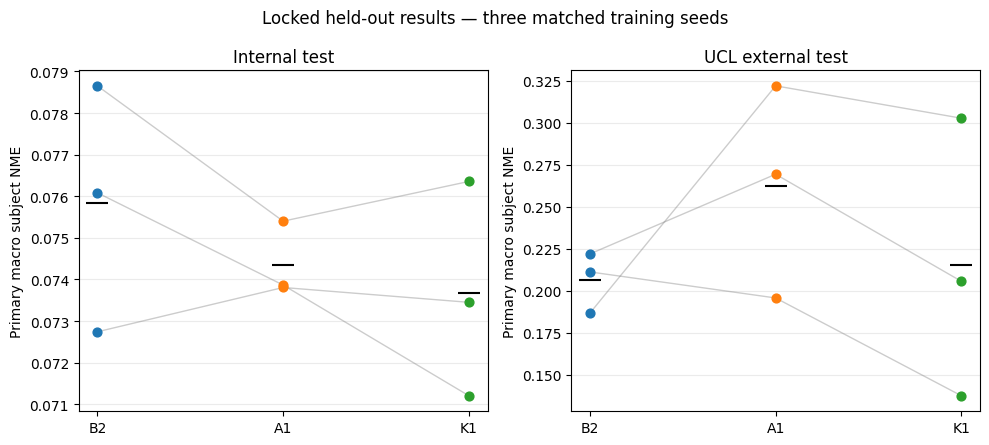

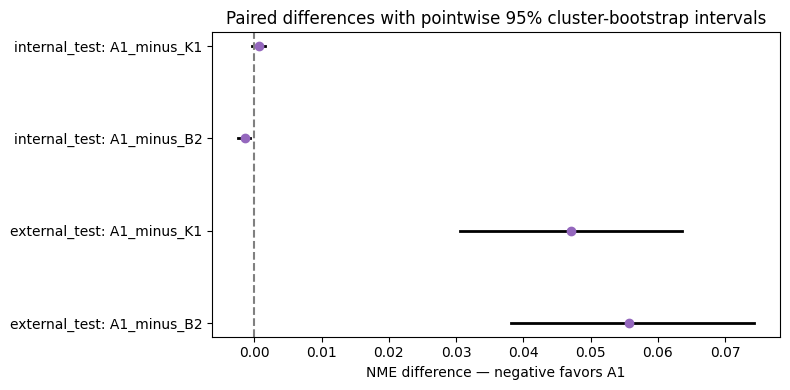


DESCRIPTIVE SOURCE/MEASUREMENT BREAKDOWN
         role source variant measurement  mean_nme  seed_sd  subject_keys
external_test    UCL      A1        apad  0.326454 0.086955            14
external_test    UCL      A1         bpd  0.251397 0.077622            16
external_test    UCL      A1          fl  0.247577 0.099000            14
external_test    UCL      A1         ofd  0.173116 0.031269            16
external_test    UCL      A1         tad  0.312579 0.056509            14
external_test    UCL      B2        apad  0.272491 0.007365            14
external_test    UCL      B2         bpd  0.185865 0.036958            16
external_test    UCL      B2          fl  0.172636 0.020405            14
external_test    UCL      B2         ofd  0.156846 0.038614            16
external_test    UCL      B2         tad  0.244463 0.025495            14
external_test    UCL      K1        apad  0.255789 0.094303            14
external_test    UCL      K1         bpd  0.216111 0.113207           

In [2]:
# FETALGEO_BLOCK41_V1
# CPU reporting of locked results, including negative external findings.
# No model loading, training, tuning, or checkpoint selection.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PROTOCOL_DIR = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"
PROTOCOL_HASH = (
    "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6"
)
PREDICTIONS = PROJECT / "evaluation_results" / f"core_{PROTOCOL_HASH[:16]}"
ANALYSIS = PREDICTIONS / "analysis_20260913T061734883035Z"

if not ANALYSIS.is_dir():
    raise FileNotFoundError(
        f"Mount Google Drive and confirm the saved analysis directory: {ANALYSIS}"
    )

def sha41(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read_json41(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

if sha41(PROTOCOL_DIR / "evaluation_protocol.json") != PROTOCOL_HASH:
    raise ValueError("Locked protocol checksum mismatch.")

analysis_report = read_json41(ANALYSIS / "analysis_summary.json")
if (
    analysis_report["status"] != "LOCKED_CPU_ANALYSIS_COMPLETED"
    or analysis_report["protocol_sha256"] != PROTOCOL_HASH
):
    raise ValueError("Unexpected analysis provenance.")

frames = []
for variant in ["B2", "A1", "K1"]:
    for seed in [20260912, 20260913, 20260914]:
        path = PREDICTIONS / f"{variant}_seed{seed}_predictions.csv"
        receipt = read_json41(
            PREDICTIONS / f"{variant}_seed{seed}_receipt.json"
        )
        if (
            sha41(path) != receipt["prediction_sha256"]
            or receipt["protocol_sha256"] != PROTOCOL_HASH
        ):
            raise ValueError("Prediction provenance mismatch.")

        frame = pd.read_csv(path, dtype=str, keep_default_na=False)
        if not frame["variant"].eq(variant).all():
            raise ValueError("Prediction variant mismatch.")
        if not frame["seed"].eq(str(seed)).all():
            raise ValueError("Prediction seed mismatch.")
        frame = frame.loc[frame["primary_eligible"].eq("True")].copy()
        frame["nme"] = pd.to_numeric(frame["nme"], errors="raise")
        if not np.isfinite(frame["nme"]).all():
            raise ValueError("Nonfinite eligible NME.")
        frame["seed"] = seed
        frames.append(frame)

data = pd.concat(frames, ignore_index=True)
if data.duplicated(["variant", "seed", "record_id", "measurement"]).any():
    raise ValueError("Repeated prediction keys.")

# Reproduce primary macro scores before preparing figures.
subject_scores = data.groupby(
    ["role", "variant", "seed", "measurement", "subject_key"],
    as_index=False,
)["nme"].mean()
measurement_scores = subject_scores.groupby(
    ["role", "variant", "seed", "measurement"], as_index=False
)["nme"].mean()
seed_scores = measurement_scores.groupby(
    ["role", "variant", "seed"], as_index=False
)["nme"].mean()

saved_scores = pd.read_csv(ANALYSIS / "per_seed_scores.csv")
saved_scores = saved_scores.loc[saved_scores["policy"].eq("primary")]
check = seed_scores.merge(
    saved_scores,
    on=["role", "variant", "seed"],
    validate="one_to_one",
)
if len(check) != 18 or not np.allclose(
    check["nme"], check["macro_nme"], rtol=1e-9, atol=1e-12
):
    raise ValueError("Recomputed scores differ from Block 40.")

# Source-specific breakdown, retaining subject-level averaging.
source_subjects = data.groupby(
    ["role", "source", "variant", "seed", "measurement", "subject_key"],
    as_index=False,
)["nme"].mean()
source_seed_scores = source_subjects.groupby(
    ["role", "source", "variant", "seed", "measurement"],
    as_index=False,
).agg(nme=("nme", "mean"), subject_keys=("subject_key", "nunique"))

source_summary = source_seed_scores.groupby(
    ["role", "source", "variant", "measurement"], as_index=False
).agg(
    mean_nme=("nme", "mean"),
    seed_sd=("nme", "std"),
    subject_keys=("subject_keys", "first"),
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ANALYSIS / f"reporting_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)
source_seed_scores.to_csv(OUT / "source_measurement_seed_scores.csv", index=False)
source_summary.to_csv(OUT / "source_measurement_summary.csv", index=False)
seed_scores.to_csv(OUT / "primary_seed_scores.csv", index=False)

PAPER = PROJECT / "paper_artifacts"
for folder in [
    "figures/final", "figures/data", "figures/captions",
    "tables/data", "tables/notes",
]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)

colors = {"B2": "tab:blue", "A1": "tab:orange", "K1": "tab:green"}
variants = ["B2", "A1", "K1"]
artifact_rows = []

# Show each seed explicitly; do not mistake seed SD for a patient-level CI.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, role, title in zip(
    axes,
    ["internal_test", "external_test"],
    ["Internal test", "UCL external test"],
):
    subset = seed_scores.loc[seed_scores["role"].eq(role)]
    for seed in sorted(subset["seed"].unique()):
        values = subset.loc[
            subset["seed"].eq(seed)
        ].set_index("variant").loc[variants, "nme"]
        ax.plot(range(3), values, color="gray", alpha=0.4, linewidth=1)

    for position, variant in enumerate(variants):
        values = subset.loc[subset["variant"].eq(variant), "nme"]
        ax.scatter(
            np.full(len(values), position), values,
            color=colors[variant], s=40, zorder=3,
        )
        ax.scatter(position, values.mean(), color="black", marker="_", s=250, zorder=4)

    ax.set_xticks(range(3), variants)
    ax.set_title(title)
    ax.set_ylabel("Primary macro subject NME")
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Locked held-out results — three matched training seeds")
fig.tight_layout()

tag = f"heldout_seed_comparison_{stamp}"
png = PAPER / "figures/final" / f"{tag}.png"
pdf = PAPER / "figures/final" / f"{tag}.pdf"
figure_data = PAPER / "figures/data" / f"{tag}.csv"
caption = PAPER / "figures/captions" / f"{tag}.txt"
seed_scores.to_csv(figure_data, index=False)
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)
caption.write_text(
    "Locked primary held-out NME. Dots represent trained seeds; gray lines "
    "connect matched seeds; black ticks show the three-seed mean.\n"
    "Panels use separate vertical scales. Lower is better. These plots do not "
    "show confidence intervals. Checkpoints were selected on internal validation.\n",
    encoding="utf-8",
)
artifact_rows.append({
    "artifact_id": tag, "type": "figure",
    "title": "Locked held-out results across seeds",
    "source_data_path": str(figure_data),
    "output_paths": f"{png}|{pdf}", "caption_path": str(caption),
})

# Report the two predeclared primary contrasts with their paired intervals.
intervals = pd.read_csv(ANALYSIS / "paired_bootstrap_intervals.csv")
primary_intervals = intervals.loc[intervals["policy"].eq("primary")].copy()
fig, ax = plt.subplots(figsize=(8, 4))
for position, row in enumerate(primary_intervals.to_dict("records")):
    ax.plot(
        [row["ci95_lower"], row["ci95_upper"]], [position, position],
        color="black", linewidth=2,
    )
    ax.scatter(row["mean_paired_difference"], position, color="tab:purple", zorder=3)
ax.axvline(0, linestyle="--", color="gray")
ax.set_yticks(
    range(len(primary_intervals)),
    [
        f"{r.role}: {r.contrast}"
        for r in primary_intervals.itertuples()
    ],
)
ax.set_xlabel("NME difference — negative favors A1")
ax.set_title("Paired differences with pointwise 95% cluster-bootstrap intervals")
fig.tight_layout()

tag2 = f"heldout_paired_intervals_{stamp}"
png2 = PAPER / "figures/final" / f"{tag2}.png"
pdf2 = PAPER / "figures/final" / f"{tag2}.pdf"
data2 = PAPER / "figures/data" / f"{tag2}.csv"
caption2 = PAPER / "figures/captions" / f"{tag2}.txt"
primary_intervals.to_csv(data2, index=False)
fig.savefig(png2, dpi=300, bbox_inches="tight")
fig.savefig(pdf2, bbox_inches="tight")
plt.show()
plt.close(fig)
caption2.write_text(
    "Locked primary contrasts, averaged across three matched seeds.\n"
    "Pointwise percentile intervals from 2,000 paired dependency-cluster "
    "bootstrap replicates. Not adjusted for multiple comparisons. "
    "Training seeds were not resampled. External cohort: 19 dependency clusters.\n",
    encoding="utf-8",
)
artifact_rows.append({
    "artifact_id": tag2, "type": "figure",
    "title": "Paired held-out NME differences",
    "source_data_path": str(data2),
    "output_paths": f"{png2}|{pdf2}", "caption_path": str(caption2),
})

table_path = PAPER / "tables/data" / f"heldout_source_breakdown_{stamp}.csv"
note_path = PAPER / "tables/notes" / f"heldout_source_breakdown_{stamp}.txt"
source_summary.to_csv(table_path, index=False)
note_path.write_text(
    "Descriptive source/measurement breakdown of locked primary eligible records.\n"
    "Subject-averaged NME, followed by mean and sample SD across three seeds.\n"
    "Seed SD is not a patient-level confidence interval. This breakdown must not "
    "be used to tune models against the now-observed test sets.\n",
    encoding="utf-8",
)
artifact_rows.append({
    "artifact_id": f"heldout_source_breakdown_{stamp}",
    "type": "table", "title": "Held-out source and measurement breakdown",
    "source_data_path": str(OUT / "source_measurement_seed_scores.csv"),
    "output_paths": str(table_path), "caption_path": str(note_path),
})

artifacts = pd.DataFrame(artifact_rows)
artifacts["status"] = "candidate"
artifacts["generator_path"] = str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK41_V1"
artifact_index = PAPER / "ARTIFACT_INDEX.csv"
if artifact_index.exists() and artifact_index.stat().st_size:
    artifacts = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), artifacts
    ], ignore_index=True)
artifacts.fillna("").to_csv(artifact_index, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 41 locked-result reporting — {stamp}\n\n"
        "- Primary scores independently reproduced from verified prediction files.\n"
        "- A1 shows a small internal gain over B2 but worse external performance.\n"
        "- Internal A1-versus-K1 interval includes zero; no clear internal advantage.\n"
        "- Results do not support improved cross-source generalization from A1.\n"
        "- Saved seed plots, paired intervals, and descriptive measurement tables.\n"
        "- No tuning or additional training performed.\n"
        f"- Reporting files: `{OUT}`\n"
        f"- Source breakdown: `{table_path}`\n"
    )

print("\nDESCRIPTIVE SOURCE/MEASUREMENT BREAKDOWN")
print(source_summary.to_string(index=False))
print(f"\nSaved reporting files: {OUT}")
print("\nBLOCK 41 COMPLETED — MODELS REMAIN LOCKED")

In [3]:
# FETALGEO_BLOCK42_V1
# Pin and collect upstream benchmark evidence.
# CPU only. Downloaded source is saved as text, never executed.

from pathlib import Path
from datetime import datetime, timezone
from urllib.request import Request, urlopen
from urllib.parse import quote
import hashlib
import json
import re
import time

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
if not PROJECT.is_dir():
    raise FileNotFoundError("Mount Google Drive first.")

REPOSITORY = "surgical-vision/Multicentre-Fetal-Biometry"
API = f"https://api.github.com/repos/{REPOSITORY}"

def fetch(url):
    request = Request(url, headers={
        "User-Agent": "FetalGeo-reproducibility-audit",
        "Accept": "application/vnd.github+json",
    })
    with urlopen(request, timeout=60) as response:
        return response.read()

def fetch_json(url):
    return json.loads(fetch(url).decode("utf-8"))

print("Resolving the published repository to a fixed commit...", flush=True)
commit_data = fetch_json(f"{API}/commits/main")
commit = commit_data["sha"]
tree_sha = commit_data["commit"]["tree"]["sha"]
tree = fetch_json(f"{API}/git/trees/{tree_sha}?recursive=1")
if tree.get("truncated"):
    raise RuntimeError("Repository listing was truncated; do not assume complete coverage.")

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT42 = PROJECT / "reference_evidence" / f"benchmark_{commit[:12]}_{stamp}"
SOURCE = OUT42 / "source"
SOURCE.mkdir(parents=True, exist_ok=False)

(OUT42 / "commit_metadata.json").write_text(
    json.dumps(commit_data, indent=2), encoding="utf-8"
)
(OUT42 / "repository_tree.json").write_text(
    json.dumps(tree, indent=2), encoding="utf-8"
)

# Select bounded, relevant source/doc files from the pinned repository.
selected = []
for entry in tree["tree"]:
    if entry["type"] != "blob":
        continue
    path = entry["path"]
    lower = path.lower()
    is_readme = (
        Path(lower).name.startswith("readme")
        and lower.endswith((".md", ".txt", ".rst"))
    )
    relevant_python = (
        lower.endswith(".py")
        and any(token in lower for token in [
            "fetal", "transform", "evaluation", "ucl",
            "calibr", "biometr", "error_box", "inference",
        ])
    )
    reference_config = (
        lower.endswith((".yaml", ".yml"))
        and "hrnet_w18" in lower and "fetal" in lower
    )
    if is_readme or relevant_python or reference_config:
        if entry.get("size", 0) <= 1_000_000:
            selected.append(path)

selected = sorted(set(selected))
if not selected:
    raise RuntimeError("No relevant source files found.")
if len(selected) > 150:
    raise RuntimeError(
        f"Selection unexpectedly large ({len(selected)} files). "
        "Share this message before expanding the download."
    )

print(f"Pinned commit: {commit}")
print(f"Collecting {len(selected)} source/documentation files...", flush=True)

inventory = []
errors = []
matches = []
pattern = re.compile(
    r"px_to_mm|pixel.*mill|mill.*pixel|mm_dist|AlokaFit|"
    r"scale\s*\*=|center_w|center_h|transform_pixel|"
    r"landmark_mask|nme|ground.truth.*crop",
    flags=re.IGNORECASE,
)

for number, relative_path in enumerate(selected, start=1):
    url = (
        f"https://raw.githubusercontent.com/{REPOSITORY}/{commit}/"
        + quote(relative_path, safe="/")
    )
    destination = SOURCE / relative_path
    if not destination.resolve().is_relative_to(SOURCE.resolve()):
        raise ValueError(f"Unsafe repository path: {relative_path}")

    try:
        raw = fetch(url)
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_bytes(raw)
        inventory.append({
            "repository_path": relative_path,
            "commit": commit,
            "source_url": url,
            "sha256": hashlib.sha256(raw).hexdigest(),
            "bytes": len(raw),
        })

        lines = raw.decode("utf-8", errors="replace").splitlines()
        for line_number, line in enumerate(lines, start=1):
            if pattern.search(line):
                start = max(0, line_number - 2)
                end = min(len(lines), line_number + 2)
                matches.append({
                    "repository_path": relative_path,
                    "match_line": line_number,
                    "excerpt": "\n".join(
                        f"{i + 1}: {lines[i]}" for i in range(start, end)
                    ),
                })
    except Exception as exc:
        errors.append({
            "repository_path": relative_path,
            "error": f"{type(exc).__name__}: {exc}",
        })

    if number % 10 == 0 or number == len(selected):
        print(f"Processed {number}/{len(selected)} files", flush=True)

inventory_frame = pd.DataFrame(
    inventory,
    columns=["repository_path", "commit", "source_url", "sha256", "bytes"],
)
match_frame = pd.DataFrame(
    matches, columns=["repository_path", "match_line", "excerpt"]
)
error_frame = pd.DataFrame(
    errors, columns=["repository_path", "error"]
)
inventory_frame.to_csv(OUT42 / "source_inventory.csv", index=False)
match_frame.to_csv(OUT42 / "calibration_and_preprocessing_excerpts.csv", index=False)
error_frame.to_csv(OUT42 / "download_errors.csv", index=False)

# Release metadata records checkpoint assets; no model weights downloaded.
release_status = "NOT_RETRIEVED"
try:
    releases = fetch_json(f"{API}/releases?per_page=100")
    (OUT42 / "release_metadata.json").write_text(
        json.dumps(releases, indent=2), encoding="utf-8"
    )
    assets = []
    for release in releases:
        for asset in release.get("assets", []):
            assets.append({
                "tag": release["tag_name"],
                "release_url": release["html_url"],
                "asset_name": asset["name"],
                "bytes": asset["size"],
                "download_url": asset["browser_download_url"],
            })
    pd.DataFrame(assets, columns=[
        "tag", "release_url", "asset_name", "bytes", "download_url"
    ]).to_csv(OUT42 / "released_checkpoint_assets.csv", index=False)
    release_status = "RETRIEVED"
except Exception as exc:
    release_status = f"{type(exc).__name__}: {exc}"

# Explicit questions to settle before claiming a compatible comparison.
questions = [
    "Do landmark coordinates refer to the distributed image pixels?",
    "Does px_to_mm_rate multiply pixel distance, and in which image space?",
    "Does any device-specific processing change the image/calibration relationship?",
    "Does reference inference use annotation-derived centre or scale?",
    "Which data sources and splits trained each released checkpoint?",
    "Would a released checkpoint have trained on our held-out UCL subjects?",
    "Does the reference metric use the same endpoint-order invariance and aggregation?",
]
report = {
    "status": (
        "REFERENCE_EVIDENCE_COLLECTED_REVIEW_PENDING"
        if not errors else "PARTIAL_DOWNLOAD_REVIEW_REQUIRED"
    ),
    "repository": REPOSITORY,
    "pinned_commit": commit,
    "saved_directory": str(OUT42),
    "downloaded_files": len(inventory),
    "download_errors": errors,
    "release_metadata_status": release_status,
    "review_questions": questions,
    "calibration_verified": False,
    "published_method_comparability_verified": False,
    "downloaded_code_executed": False,
    "model_or_protocol_changes": 0,
}
(OUT42 / "evidence_summary.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 42 published-benchmark evidence — {stamp}\n\n"
        f"- Repository pinned to commit `{commit}`.\n"
        "- Relevant source and release metadata collected for compatibility review.\n"
        "- Downloaded code was not executed; no models or protocols changed.\n"
        "- Physical calibration and published-method comparability remain unverified.\n"
        f"- Evidence: `{OUT42}`\n"
    )

print("\nDOWNLOADED FILES")
print(inventory_frame[["repository_path", "bytes"]].to_string(index=False))

print("\nPRIORITY CODE EXCERPTS — first 35 matching locations")
priority = match_frame.loc[
    match_frame["repository_path"].str.endswith(".py")
].head(35)
for row in priority.to_dict("records"):
    print(f"\n{row['repository_path']} — line {row['match_line']}")
    print(row["excerpt"])

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print("\nBLOCK 42 COMPLETED")

Resolving the published repository to a fixed commit...
Pinned commit: a120aace9965ae1838d8832375a929a664c3aeab
Processed 10/26 files
Processed 20/26 files
Processed 26/26 files

DOWNLOADED FILES
                                                         repository_path  bytes
                                                               README.md  23703
                                                create_error_boxplots.py  19357
                                                       data/README-FP.md   6618
                                                     data/README-HC18.md   7711
                                                      data/README-UCL.md   9728
                                                  data/README-general.md   7482
         experiments/fetal/fetal_landmark_hrnet_w18_FP_abdomen_APAD.yaml   1503
          experiments/fetal/fetal_landmark_hrnet_w18_FP_abdomen_TAD.yaml   1436
            experiments/fetal/fetal_landmark_hrnet_w18_FP_brain_BPD.yaml   1453
    

# New Step

In [4]:
# FETALGEO_BLOCK43_V1
# CPU-only targeted reference review.
# Reads saved source as text; never executes downloaded code.

from pathlib import Path
from datetime import datetime, timezone
import ast
import hashlib
import json
import re

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
EVIDENCE = (
    PROJECT / "reference_evidence"
    / "benchmark_a120aace9965_20260913T062204554968Z"
)
SOURCE = EVIDENCE / "source"

if not SOURCE.is_dir():
    raise FileNotFoundError("Mount Drive and confirm the Block 42 evidence folder.")

inventory = pd.read_csv(
    EVIDENCE / "source_inventory.csv",
    dtype=str, keep_default_na=False,
)
for row in inventory.to_dict("records"):
    path = SOURCE / row["repository_path"]
    actual = hashlib.sha256(path.read_bytes()).hexdigest()
    if actual != row["sha256"]:
        raise ValueError(f"Saved reference file changed: {path}")

sections = []

def add(title, text):
    sections.append(f"\n===== {title} =====\n{text}")

# Complete functions needed to trace image -> prediction -> original pixels.
requested_functions = {
    "lib/datasets/fetal.py": {"__getitem__"},
    "lib/utils/transforms.py": {
        "get_transform", "transform_pixel", "transform_preds"
    },
    "lib/core/evaluation.py": {
        "compute_nme", "decode_preds"
    },
}

for relative_path, function_names in requested_functions.items():
    path = SOURCE / relative_path
    text = path.read_text(encoding="utf-8")
    lines = text.splitlines()
    tree = ast.parse(text)
    found = set()

    for node in ast.walk(tree):
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            if node.name in function_names:
                found.add(node.name)
                excerpt = "\n".join(
                    f"{i + 1}: {lines[i]}"
                    for i in range(node.lineno - 1, node.end_lineno)
                )
                add(f"{relative_path} / {node.name}", excerpt)

    if function_names - found:
        add(
            f"{relative_path} / requested functions not present",
            ", ".join(sorted(function_names - found)),
        )

# Merge nearby matches so context is preserved without repeated fragments.
def contextual_excerpt(text, pattern, radius=6):
    lines = text.splitlines()
    selected = set()
    for i, line in enumerate(lines):
        if re.search(pattern, line, flags=re.IGNORECASE):
            selected.update(
                range(max(0, i - radius), min(len(lines), i + radius + 1))
            )
    output = []
    previous = -2
    for i in sorted(selected):
        if i > previous + 1:
            output.append("...")
        output.append(f"{i + 1}: {lines[i]}")
        previous = i
    return "\n".join(output) or "No matching text."

error_script = SOURCE / "create_error_boxplots.py"
add(
    "Calibration and prediction-coordinate handling",
    contextual_excerpt(
        error_script.read_text(encoding="utf-8"),
        r"gt_dist_px|pred_dist_px|decode_preds|transform_preds|"
        r"px_to_mm\s*=|px_to_mm.*Test|def.*predict|def.*infer",
    ),
)

# Source exposure and preprocessing settings from every collected config.
config_rows = []
for path in sorted(SOURCE.rglob("*.yaml")):
    text = path.read_text(encoding="utf-8")
    config_rows.append({
        "file": str(path.relative_to(SOURCE)),
        "settings": contextual_excerpt(
            text,
            r"^\s*(ROOT|TRAINSET|TESTSET|ANATOMY|METRICS|"
            r"IMAGE_SIZE|HEATMAP_SIZE|REASSIGN|MODEL_FILE|PRETRAINED)\s*:",
            radius=1,
        ),
    })
for row in config_rows:
    add(row["file"], row["settings"])

readme = SOURCE / "README.md"
if readme.exists():
    add(
        "README: checkpoint exposure, cropping, and evaluation",
        contextual_excerpt(
            readme.read_text(encoding="utf-8"),
            r"cross.dataset|cross.source|zero.shot|ground.truth|"
            r"crop|pretrained|checkpoint|released|train.*UCL|train.*MULTICENTRE",
            radius=3,
        ),
    )

assets_path = EVIDENCE / "released_checkpoint_assets.csv"
if assets_path.exists():
    assets = pd.read_csv(assets_path, keep_default_na=False)
    columns = [
        name for name in ["tag", "asset_name", "bytes", "download_url"]
        if name in assets
    ]
    add("Released checkpoint assets", assets[columns].to_string(index=False))

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT43 = PROJECT / "reference_evidence" / f"targeted_review_{stamp}"
OUT43.mkdir(parents=True, exist_ok=False)
report_text = "\n".join(sections)
report_path = OUT43 / "targeted_reference_review.txt"
report_path.write_text(report_text, encoding="utf-8")

summary = {
    "status": "TARGETED_REFERENCE_EVIDENCE_READY",
    "pinned_commit": "a120aace9965ae1838d8832375a929a664c3aeab",
    "report_path": str(report_path),
    "reference_files_verified": len(inventory),
    "downloaded_code_executed": False,
    "model_changes": 0,
    "training_performed": False,
    "calibration_and_comparability_decision": "PENDING_SOURCE_REVIEW",
}
(OUT43 / "review_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 43 targeted reference review — {stamp}\n\n"
        "- Saved source hashes verified; complete relevant functions extracted.\n"
        "- Calibration path, dataset configurations, and checkpoint assets collected.\n"
        "- No downloaded code executed; no model or protocol changes.\n"
        f"- Evidence report: `{report_path}`\n"
    )

print(report_text)
print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print("\nBLOCK 43 COMPLETED")


===== lib/datasets/fetal.py / __getitem__ =====
188:     def __getitem__(self, idx):
189:         image_name_val = self.landmarks_frame.iloc[idx, 0]
190:         if pd.isna(image_name_val):
191:             raise ValueError(f"Invalid image name at index {idx}: NaN value found")
192:         image_name = str(image_name_val)
193: 
194:         image_path = os.path.join(self.data_root, image_name)
195:         if not os.path.exists(image_path):
196:             raise FileNotFoundError(f"Image not found: {image_path}")
197: 
198:         scale = float(self.landmarks_frame.iloc[idx, 1])
199:         center_w = float(self.landmarks_frame.iloc[idx, 2])
200:         center_h = float(self.landmarks_frame.iloc[idx, 3])
201:         center = torch.Tensor([center_w, center_h])
202: 
203:         # Extract points using the SAME columns as in __init__
204:         pts = self.landmarks_frame.iloc[idx, self.start_col:self.end_col].values
205:         pts = np.asarray(pts, dtype=np.float32).reshape(-1

In [5]:
# FETALGEO_BLOCK44_V1
# Supplementary physical-length errors using supplied calibration metadata.
# CPU only. No inference, training, or model selection.

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PROTOCOL_DIR = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"
PROTOCOL_HASH = (
    "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6"
)
PREDICTIONS = PROJECT / "evaluation_results" / f"core_{PROTOCOL_HASH[:16]}"
MANIFEST = (
    PROJECT / "data/manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
REFERENCE = (
    PROJECT / "reference_evidence"
    / "benchmark_a120aace9965_20260913T062204554968Z"
)

def sha44(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for piece in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(piece)
    return digest.hexdigest()

def read_json44(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

if sha44(PROTOCOL_DIR / "evaluation_protocol.json") != PROTOCOL_HASH:
    raise ValueError("Locked evaluation protocol checksum mismatch.")

manifest_config = read_json44(MANIFEST / "split_configuration.json")
manifest_path = MANIFEST / "unified_manifest.csv"
if sha44(manifest_path) != manifest_config["csv_sha256"]["unified_manifest.csv"]:
    raise ValueError("Original manifest checksum mismatch.")

manifest = pd.read_csv(manifest_path, dtype=str, keep_default_na=False)
if manifest["record_id"].duplicated().any():
    raise ValueError("Repeated manifest record IDs.")
manifest = manifest.set_index("record_id")
rates = pd.to_numeric(manifest["px_to_mm_rate"], errors="coerce")

# Verify the pinned reference evidence supporting the conversion rule.
inventory = pd.read_csv(
    REFERENCE / "source_inventory.csv", dtype=str, keep_default_na=False
)
for name in ["create_error_boxplots.py", "lib/datasets/fetal.py"]:
    match = inventory.loc[inventory["repository_path"].eq(name)]
    if len(match) != 1:
        raise ValueError(f"Reference inventory missing: {name}")
    if sha44(REFERENCE / "source" / name) != match.iloc[0]["sha256"]:
        raise ValueError("Pinned reference source changed.")

all_rows = []
coverage_rows = []
target_columns = ["target_x1", "target_y1", "target_x2", "target_y2"]
prediction_columns = [
    "predicted_x1", "predicted_y1", "predicted_x2", "predicted_y2"
]

print("Checking targets and supplied calibration for nine checkpoints...", flush=True)

for variant in ["B2", "A1", "K1"]:
    for seed in [20260912, 20260913, 20260914]:
        path = PREDICTIONS / f"{variant}_seed{seed}_predictions.csv"
        receipt = read_json44(
            PREDICTIONS / f"{variant}_seed{seed}_receipt.json"
        )
        if (
            sha44(path) != receipt["prediction_sha256"]
            or receipt["protocol_sha256"] != PROTOCOL_HASH
        ):
            raise ValueError("Prediction provenance mismatch.")

        frame = pd.read_csv(path, dtype=str, keep_default_na=False)
        if not frame["variant"].eq(variant).all() or not frame["seed"].eq(str(seed)).all():
            raise ValueError("Prediction identity mismatch.")
        if frame.duplicated(["record_id", "measurement"]).any():
            raise ValueError("Repeated prediction measurement keys.")
        if not frame["record_id"].isin(manifest.index).all():
            raise ValueError("Prediction records absent from original manifest.")

        # Check stored target coordinates against authoritative manifest fields.
        for measurement, group in frame.groupby("measurement"):
            columns = [
                f"{measurement}_1_x", f"{measurement}_1_y",
                f"{measurement}_2_x", f"{measurement}_2_y",
            ]
            original = manifest.loc[
                group["record_id"].tolist(), columns
            ].apply(pd.to_numeric, errors="raise").to_numpy()
            stored = group[target_columns].apply(
                pd.to_numeric, errors="raise"
            ).to_numpy()
            if not np.allclose(original, stored, rtol=1e-9, atol=1e-7, equal_nan=True):
                raise ValueError(f"Stored targets differ from manifest: {measurement}")

        frame["calibration_mm_per_pixel"] = frame["record_id"].map(rates)
        frame["geometry_eligible"] = frame["primary_eligible"].eq("True")
        frame["calibration_available"] = (
            np.isfinite(frame["calibration_mm_per_pixel"])
            & frame["calibration_mm_per_pixel"].gt(0)
        )
        frame["mm_eligible"] = (
            frame["geometry_eligible"] & frame["calibration_available"]
        )

        if variant == "B2" and seed == 20260912:
            for keys, group in frame.groupby(["role", "source", "measurement"]):
                coverage_rows.append({
                    "role": keys[0],
                    "source": keys[1],
                    "measurement": keys[2],
                    "all_measurement_records": len(group),
                    "geometry_eligible": int(group["geometry_eligible"].sum()),
                    "mm_eligible": int(group["mm_eligible"].sum()),
                    "mm_eligible_subject_keys": group.loc[
                        group["mm_eligible"], "subject_key"
                    ].nunique(),
                })

            external_images = frame.loc[
                frame["role"].eq("external_test") & frame["mm_eligible"],
                "record_id",
            ].nunique()
            if external_images != 82:
                raise ValueError(
                    f"Expected 82 calibrated external images; found {external_images}."
                )

        usable = frame.loc[frame["mm_eligible"]].copy()
        truth = usable[target_columns].apply(
            pd.to_numeric, errors="raise"
        ).to_numpy().reshape(-1, 2, 2)
        prediction = usable[prediction_columns].apply(
            pd.to_numeric, errors="raise"
        ).to_numpy().reshape(-1, 2, 2)
        if not np.isfinite(truth).all() or not np.isfinite(prediction).all():
            raise ValueError("Nonfinite physical-metric coordinates.")

        calibration = usable["calibration_mm_per_pixel"].to_numpy(dtype=float)
        target_length = np.linalg.norm(truth[:, 1] - truth[:, 0], axis=1)
        predicted_length = np.linalg.norm(
            prediction[:, 1] - prediction[:, 0], axis=1
        )

        usable["target_length_mm"] = target_length * calibration
        usable["predicted_length_mm"] = predicted_length * calibration
        usable["signed_length_error_mm"] = (
            usable["predicted_length_mm"] - usable["target_length_mm"]
        )
        usable["absolute_length_error_mm"] = usable["signed_length_error_mm"].abs()
        usable["seed"] = seed

        keep = [
            "variant", "seed", "role", "source", "record_id", "measurement",
            "subject_key", "dependency_cluster", "rgb_sha256",
            "calibration_mm_per_pixel", "target_length_mm",
            "predicted_length_mm", "signed_length_error_mm",
            "absolute_length_error_mm",
        ]
        all_rows.append(usable[keep])

data44 = pd.concat(all_rows, ignore_index=True)
coverage44 = pd.DataFrame(coverage_rows)

# Same subject-first weighting as the primary analysis, on calibrated records.
subjects44 = data44.groupby(
    ["role", "source", "variant", "seed", "measurement", "subject_key"],
    as_index=False,
).agg(
    mae_mm=("absolute_length_error_mm", "mean"),
    bias_mm=("signed_length_error_mm", "mean"),
)
per_seed44 = subjects44.groupby(
    ["role", "source", "variant", "seed", "measurement"], as_index=False
).agg(
    subject_average_mae_mm=("mae_mm", "mean"),
    subject_average_bias_mm=("bias_mm", "mean"),
    subject_keys=("subject_key", "nunique"),
)
summary44 = per_seed44.groupby(
    ["role", "source", "variant", "measurement"], as_index=False
).agg(
    mae_mm_mean=("subject_average_mae_mm", "mean"),
    mae_mm_seed_sd=("subject_average_mae_mm", "std"),
    bias_mm_mean=("subject_average_bias_mm", "mean"),
    subject_keys=("subject_keys", "first"),
)

stamp44 = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT44 = PREDICTIONS / f"supplementary_mm_{stamp44}"
OUT44.mkdir(parents=True, exist_ok=False)
for name, table in [
    ("record_length_errors_mm.csv", data44),
    ("calibration_coverage.csv", coverage44),
    ("subject_length_errors_mm.csv", subjects44),
    ("per_seed_length_errors_mm.csv", per_seed44),
    ("length_error_summary_mm.csv", summary44),
]:
    table.to_csv(OUT44 / name, index=False)

report44 = {
    "status": "SUPPLEMENTARY_CALIBRATED_LENGTH_ANALYSIS_COMPLETED",
    "analysis_directory": str(OUT44),
    "primary_protocol_unchanged": True,
    "analysis_status": "post_hoc_descriptive",
    "conversion": "original_image_endpoint_distance * supplied px_to_mm_rate",
    "error_definition": "predicted length minus annotated length; absolute value for MAE",
    "external_images_with_calibration": 82,
    "reference_commit": "a120aace9965ae1838d8832375a929a664c3aeab",
    "limitations": [
        "Uses supplied calibration; physical accuracy not independently verified.",
        "Calibrated subset may not represent the full cohort.",
        "Length error differs from endpoint-localization NME.",
        "Duplicate records retained with subject-first averaging.",
        "Seed SD is not a patient-level confidence interval.",
        "No clinical acceptability threshold or superiority claim established.",
    ],
}
(OUT44 / "analysis_summary.json").write_text(
    json.dumps(report44, indent=2), encoding="utf-8"
)

PAPER = PROJECT / "paper_artifacts"
for folder in ["tables/data", "tables/notes"]:
    (PAPER / folder).mkdir(parents=True, exist_ok=True)

entries44 = []
for label, table, source in [
    ("supplementary_length_errors_mm", summary44, "per_seed_length_errors_mm.csv"),
    ("supplementary_calibration_coverage", coverage44, "calibration_coverage.csv"),
]:
    table_path = PAPER / "tables/data" / f"{label}_{stamp44}.csv"
    note_path = PAPER / "tables/notes" / f"{label}_{stamp44}.txt"
    table.to_csv(table_path, index=False)
    note_path.write_text(
        "Post hoc descriptive analysis of locked predictions.\n"
        "Original-image lengths converted using supplied px_to_mm_rate.\n"
        "Calibration accuracy is not independently verified; coverage reported.\n"
        "Errors measure length, not endpoint localization. Seed SD is not a CI.\n"
        f"Analysis: {OUT44}\n",
        encoding="utf-8",
    )
    entries44.append({
        "artifact_id": f"{label}_{stamp44}",
        "type": "table",
        "title": label.replace("_", " "),
        "status": "candidate",
        "source_data_path": str(OUT44 / source),
        "generator_path": str(PROJECT / "Code.ipynb") + "#FETALGEO_BLOCK44_V1",
        "output_paths": str(table_path),
        "caption_path": str(note_path),
    })

artifact_index = PAPER / "ARTIFACT_INDEX.csv"
artifacts = pd.DataFrame(entries44)
if artifact_index.exists() and artifact_index.stat().st_size:
    artifacts = pd.concat([
        pd.read_csv(artifact_index, keep_default_na=False), artifacts
    ], ignore_index=True)
artifacts.fillna("").to_csv(artifact_index, index=False)

with (PROJECT / "FETALGEO_RESULTS.md").open("a", encoding="utf-8") as handle:
    handle.write(
        f"\n\n## Block 44 supplementary length errors — {stamp44}\n\n"
        "- Post hoc descriptive analysis; locked primary protocol unchanged.\n"
        "- Supplied pixel-to-mm factors applied to original-image endpoint lengths.\n"
        "- Prediction targets checked against the original manifest annotations.\n"
        "- Calibration accuracy not independently verified; calibrated subset only.\n"
        "- Reference inference uses CSV-defined cropping, unlike our full-image input.\n"
        f"- Results: `{OUT44}`\n"
    )

print("\nCALIBRATED MEASUREMENT COVERAGE")
print(coverage44.to_string(index=False))
print("\nSUPPLEMENTARY LENGTH ERRORS — mm")
print(summary44.to_string(index=False))
print("\nSUMMARY")
print(json.dumps(report44, indent=2))
print("\nBLOCK 44 COMPLETED")

Checking targets and supplied calibration for nine checkpoints...

CALIBRATED MEASUREMENT COVERAGE
         role source measurement  all_measurement_records  geometry_eligible  mm_eligible  mm_eligible_subject_keys
external_test    UCL        apad                       36                 36           22                         5
external_test    UCL         bpd                       49                 49           35                         5
external_test    UCL          fl                       39                 39           25                         5
external_test    UCL         ofd                       49                 49           35                         5
external_test    UCL         tad                       36                 36           22                         5
internal_test     FP        apad                      433                433          433                       352
internal_test     FP         bpd                     1082               1064         1064

In [6]:
# BLOCK 45 — Download and inventory published reference assets (CPU)
from pathlib import Path, PurePosixPath
from datetime import datetime, timezone
import hashlib
import json
import os
import re
import time
import zipfile

import pandas as pd
import requests
from IPython.display import display

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
if not PROJECT.is_dir():
    raise RuntimeError("Mount Google Drive first; FetalGeo project was not found.")

REPO = "surgical-vision/Multicentre-Fetal-Biometry"
COMMIT = "a120aace9965ae1838d8832375a929a664c3aeab"
ASSET_NAME = "Multicentre-Fetal-Biometry-pretrained-models.zip"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

ROOT = PROJECT / "reference_evidence" / f"published_assets_{COMMIT[:12]}"
DOWNLOADS = ROOT / "downloads"
SOURCE = ROOT / "source"
REPORT = ROOT / f"inventory_{STAMP}"

for folder in (DOWNLOADS, SOURCE, REPORT):
    folder.mkdir(parents=True, exist_ok=True)

session = requests.Session()
session.headers.update({"User-Agent": "FetalGeo-reference-audit"})


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    os.replace(temporary, path)


def download_verified(url, destination, expected_size=None, expected_sha=None):
    """Reuse a download only when its saved receipt and hash agree."""
    destination = Path(destination)
    receipt_path = destination.with_name(destination.name + ".receipt.json")

    if destination.exists() and receipt_path.exists():
        receipt = json.loads(receipt_path.read_text(encoding="utf-8"))
        actual_sha = sha256_file(destination)
        valid = (
            receipt.get("url") == url
            and receipt.get("sha256") == actual_sha
            and receipt.get("bytes") == destination.stat().st_size
            and (expected_size is None
                 or destination.stat().st_size == expected_size)
            and (expected_sha is None or actual_sha == expected_sha)
        )
        if valid:
            print(f"Verified existing download: {destination.name}", flush=True)
            return receipt

    partial = destination.with_name(destination.name + ".partial")
    print(f"Downloading: {destination.name}", flush=True)
    digest = hashlib.sha256()
    received = 0
    last_report = time.monotonic()

    with session.get(url, stream=True, timeout=(30, 180)) as response:
        response.raise_for_status()
        with partial.open("wb") as handle:
            for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):
                if not chunk:
                    continue
                handle.write(chunk)
                digest.update(chunk)
                received += len(chunk)
                if time.monotonic() - last_report >= 15:
                    print(f"  Received {received / 1e6:,.0f} MB", flush=True)
                    last_report = time.monotonic()

    actual_sha = digest.hexdigest()
    if expected_size is not None and received != expected_size:
        raise RuntimeError(
            f"Download size mismatch: {received} versus {expected_size}"
        )
    if expected_sha is not None and actual_sha != expected_sha:
        raise RuntimeError("Download SHA-256 does not match the release digest.")

    os.replace(partial, destination)
    receipt = {
        "url": url,
        "bytes": received,
        "sha256": actual_sha,
        "release_digest_available": expected_sha is not None,
        "downloaded_utc": datetime.now(timezone.utc).isoformat(),
    }
    write_json(receipt_path, receipt)
    return receipt


def safe_members(archive):
    members = []
    for member in archive.infolist():
        name = member.filename
        path = PurePosixPath(name)
        if (
            path.is_absolute()
            or ".." in path.parts
            or "\\" in name
            or any(":" in part for part in path.parts)
        ):
            raise RuntimeError(f"Unsafe archive path: {name}")
        if ((member.external_attr >> 16) & 0o170000) == 0o120000:
            raise RuntimeError(f"Archive contains a symbolic link: {name}")
        members.append(member)
    return members


print("Retrieving official release metadata...", flush=True)
response = session.get(
    f"https://api.github.com/repos/{REPO}/releases/tags/v1.0",
    timeout=(30, 60),
)
response.raise_for_status()
release = response.json()
write_json(REPORT / "release_metadata.json", release)

assets = [
    item for item in release.get("assets", [])
    if item["name"] == ASSET_NAME
]
if len(assets) != 1:
    raise RuntimeError(
        f"Expected one checkpoint archive, found {len(assets)}."
    )

asset = assets[0]
release_digest = asset.get("digest") or ""
expected_sha = (
    release_digest.split(":", 1)[1]
    if release_digest.startswith("sha256:")
    else None
)

weights_zip = DOWNLOADS / ASSET_NAME
weights_receipt = download_verified(
    asset["browser_download_url"],
    weights_zip,
    expected_size=int(asset["size"]),
    expected_sha=expected_sha,
)

source_zip = DOWNLOADS / f"source_{COMMIT}.zip"
source_receipt = download_verified(
    f"https://codeload.github.com/{REPO}/zip/{COMMIT}",
    source_zip,
)

print("Extracting pinned source files without executing them...", flush=True)
source_inventory = []
expected_root = f"Multicentre-Fetal-Biometry-{COMMIT}"

with zipfile.ZipFile(source_zip) as archive:
    for member in safe_members(archive):
        parts = PurePosixPath(member.filename).parts
        if not parts or parts[0] != expected_root:
            raise RuntimeError("Source archive root does not match the pinned commit.")
        if member.is_dir() or len(parts) < 2:
            continue

        relative = Path(*parts[1:])
        destination = SOURCE / relative
        destination.parent.mkdir(parents=True, exist_ok=True)

        # Reading a complete member also checks its ZIP CRC.
        payload = archive.read(member)
        destination.write_bytes(payload)
        source_inventory.append({
            "repository_path": relative.as_posix(),
            "bytes": len(payload),
            "sha256": hashlib.sha256(payload).hexdigest(),
        })

pd.DataFrame(source_inventory).to_csv(
    REPORT / "source_inventory.csv", index=False
)

print("Inventorying released models...", flush=True)
checkpoint_rows = []

with zipfile.ZipFile(weights_zip) as archive:
    for member in safe_members(archive):
        if member.is_dir():
            continue

        filename = PurePosixPath(member.filename).name
        if filename not in {"final_state.pth", "model_best.pth"}:
            continue

        match = re.search(
            r"hrnet_w18_(MULTICENTRE|HC18|UCL|FP)_"
            r"(head|abdomen|femur)_(BPD|OFD|APAD|TAD|FL)"
            r"(?:/|_)",
            member.filename,
            flags=re.IGNORECASE,
        )

        checkpoint_rows.append({
            "archive_member": member.filename,
            "checkpoint_type": filename,
            "training_source": match.group(1).upper() if match else "UNRESOLVED",
            "anatomy": match.group(2).title() if match else "UNRESOLVED",
            "measurement": match.group(3).lower() if match else "UNRESOLVED",
            "uncompressed_bytes": member.file_size,
            "zip_crc32": f"{member.CRC:08x}",
        })

inventory = pd.DataFrame(checkpoint_rows)
if inventory.empty:
    raise RuntimeError("No expected checkpoints were found in the release archive.")

inventory.to_csv(REPORT / "checkpoint_inventory.csv", index=False)

candidates = inventory.loc[
    inventory["training_source"].eq("FP")
    & inventory["checkpoint_type"].eq("final_state.pth")
].copy()

expected_measurements = {"ofd", "bpd", "tad", "apad", "fl"}
mapping_ok = (
    len(candidates) == 5
    and set(candidates["measurement"]) == expected_measurements
)

# Extract only the five FP final checkpoints when mapping is unambiguous.
# No torch.load, model import, or reference-code execution occurs here.
extracted_rows = []
if mapping_ok:
    print("Extracting five FP final checkpoints...", flush=True)
    with zipfile.ZipFile(weights_zip) as archive:
        for row in candidates.to_dict("records"):
            destination = (
                ROOT / "checkpoints" / "FP"
                / row["measurement"] / "final_state.pth"
            )
            destination.parent.mkdir(parents=True, exist_ok=True)
            digest = hashlib.sha256()
            with archive.open(row["archive_member"]) as src:
                with destination.open("wb") as dst:
                    for chunk in iter(lambda: src.read(8 * 1024 * 1024), b""):
                        dst.write(chunk)
                        digest.update(chunk)

            extracted_rows.append({
                **row,
                "local_path": str(destination),
                "sha256": digest.hexdigest(),
            })

    pd.DataFrame(extracted_rows).to_csv(
        REPORT / "fp_reference_checkpoints.csv", index=False
    )

print("\nRELEASED FINAL CHECKPOINTS")
display(inventory.loc[inventory["checkpoint_type"].eq("final_state.pth")])

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": (
        "REFERENCE_ASSETS_PREPARED"
        if mapping_ok else "REFERENCE_ASSETS_DOWNLOADED_MAPPING_REVIEW_REQUIRED"
    ),
    "repository": REPO,
    "source_commit": COMMIT,
    "release_tag": release.get("tag_name"),
    "release_asset_id": asset["id"],
    "source_directory": str(SOURCE),
    "report_directory": str(REPORT),
    "weights_archive": str(weights_zip),
    "weights_archive_sha256": weights_receipt["sha256"],
    "source_archive_sha256": source_receipt["sha256"],
    "source_files": len(source_inventory),
    "fp_final_checkpoints_extracted": len(extracted_rows),
    "reference_code_executed": False,
    "checkpoint_weights_loaded": False,
    "predictions_generated": False,
    "primary_protocol_changed": False,
    "planned_comparison": "FP-trained published reference on locked UCL test records",
    "interpretation_limits": [
        "Post-hoc contextual reference comparison.",
        "Reference training data differ from FetalGeo FP+HC18 training.",
        "Reference preprocessing uses annotation-derived centre and scale.",
        "Training exposure and record coverage still require explicit checks.",
        "Released checkpoints are not matched three-seed retrainings.",
        "Downloading assets does not establish inference compatibility.",
    ],
}
write_json(REPORT / "preparation_summary.json", summary)

# Register artifacts while preserving any existing index columns.
index_path = PROJECT / "paper_artifacts" / "ARTIFACT_INDEX.csv"
index_path.parent.mkdir(parents=True, exist_ok=True)

new_entries = pd.DataFrame([
    {
        "created_utc": summary["created_utc"],
        "block": 45,
        "artifact_type": "reference_inventory",
        "path": str(REPORT / "checkpoint_inventory.csv"),
        "status": summary["status"],
    },
    {
        "created_utc": summary["created_utc"],
        "block": 45,
        "artifact_type": "reference_preparation",
        "path": str(REPORT / "preparation_summary.json"),
        "status": summary["status"],
    },
])

if index_path.exists() and index_path.stat().st_size:
    existing = pd.read_csv(index_path)
    new_entries = pd.concat([existing, new_entries], ignore_index=True, sort=False)
new_entries.to_csv(index_path, index=False)

# Append to the existing results notebook only.
results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            f"\n\n### Block 45 — reference assets ({STAMP})\n"
            f"- Status: {summary['status']}.\n"
            f"- Pinned source commit: `{COMMIT}`.\n"
            f"- FP final checkpoints extracted: {len(extracted_rows)}.\n"
            "- No training, reference inference, or primary-protocol changes.\n"
            "- Planned comparison is contextual: training sources and "
            "annotation-derived cropping differ.\n"
            f"- Inventory: `{REPORT}`.\n"
        )

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print("\nBLOCK 45 COMPLETED")

Retrieving official release metadata...
Downloading: Multicentre-Fetal-Biometry-pretrained-models.zip
  Received 478 MB
  Received 881 MB
  Received 1,317 MB
Downloading: source_a120aace9965ae1838d8832375a929a664c3aeab.zip
Extracting pinned source files without executing them...
Inventorying released models...

RELEASED FINAL CHECKPOINTS


,archive_member,checkpoint_type,training_source,anatomy,measurement,uncompressed_bytes,zip_crc32
0,output/FETAL/fetal_landmark_hrnet_w18_FP_abdom...,final_state.pth,FP,Abdomen,apad,39308586,de374ff4
2,output/FETAL/fetal_landmark_hrnet_w18_FP_brain...,final_state.pth,UNRESOLVED,UNRESOLVED,UNRESOLVED,39308586,7639cb68
4,output/FETAL/fetal_landmark_hrnet_w18_FP_brain...,final_state.pth,UNRESOLVED,UNRESOLVED,UNRESOLVED,39308586,4f8c5dbb
6,output/FETAL/fetal_landmark_hrnet_w18_MULTICEN...,final_state.pth,MULTICENTRE,Abdomen,tad,39308586,a2ecd576
8,output/FETAL/fetal_landmark_hrnet_w18_HC18_bra...,final_state.pth,UNRESOLVED,UNRESOLVED,UNRESOLVED,39308586,7406a628
10,output/FETAL/fetal_landmark_hrnet_w18_HC18_bra...,final_state.pth,UNRESOLVED,UNRESOLVED,UNRESOLVED,39308586,55b8673d
12,output/FETAL/fetal_landmark_hrnet_w18_UCL_abdo...,final_state.pth,UCL,Abdomen,apad,39308586,362562d7
14,output/FETAL/fetal_landmark_hrnet_w18_UCL_abdo...,final_state.pth,UCL,Abdomen,tad,39308586,ca2d5de9
16,output/FETAL/fetal_landmark_hrnet_w18_FP_femur...,final_state.pth,FP,Femur,fl,39308586,112c071b
18,output/FETAL/fetal_landmark_hrnet_w18_MULTICEN...,final_state.pth,UNRESOLVED,UNRESOLVED,UNRESOLVED,39308586,d7fa91ba



SUMMARY
{
  "created_utc": "2026-09-13T06:37:30.005801+00:00",
  "status": "REFERENCE_ASSETS_DOWNLOADED_MAPPING_REVIEW_REQUIRED",
  "repository": "surgical-vision/Multicentre-Fetal-Biometry",
  "source_commit": "a120aace9965ae1838d8832375a929a664c3aeab",
  "release_tag": "v1.0",
  "release_asset_id": 462081531,
  "source_directory": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/source",
  "report_directory": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/inventory_20260913T063641755090Z",
  "weights_archive": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/downloads/Multicentre-Fetal-Biometry-pretrained-models.zip",
  "weights_archive_sha256": "d0efc3be7832850fe5dc627b1eff1566c6dd2103b2eaf01d387edc4f1b5e6cec",
  "source_archive_sha256": "58ba1394ca5c0d0dd4a1191128f666cd217c44402c6cdfecd07e05d867027343",
  "source_files": 101,
  "fp_final_checkpoints_extracted": 0,
  "reference_code

In [7]:
# BLOCK 46 — Fix reference mapping and inspect FP checkpoints (CPU)
from pathlib import Path, PurePosixPath
from datetime import datetime, timezone
from collections.abc import Mapping
import hashlib
import json
import os
import re
import zipfile

import pandas as pd
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence/published_assets_a120aace9965"
ARCHIVE = ROOT / "downloads/Multicentre-Fetal-Biometry-pretrained-models.zip"
SOURCE = ROOT / "source"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ROOT / f"checkpoint_check_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

EXPECTED_SHA = "d0efc3be7832850fe5dc627b1eff1566c6dd2103b2eaf01d387edc4f1b5e6cec"

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def save_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2), encoding="utf-8")

if not ARCHIVE.is_file():
    raise FileNotFoundError(f"Missing downloaded archive: {ARCHIVE}")

print("Verifying the existing archive...", flush=True)
if sha256_file(ARCHIVE) != EXPECTED_SHA:
    raise RuntimeError("Archive hash differs from your Block 45 result.")

pattern = re.compile(
    r"fetal_landmark_hrnet_w18_"
    r"(MULTICENTRE|HC18|UCL|FP)_"
    r"(brain|head|abdomen|femur)_"
    r"(BPD|OFD|APAD|TAD|FL)",
    re.IGNORECASE,
)
anatomy_map = {
    "brain": "Head", "head": "Head",
    "abdomen": "Abdomen", "femur": "Femur",
}
expected_anatomy = {
    "ofd": "Head", "bpd": "Head",
    "tad": "Abdomen", "apad": "Abdomen", "fl": "Femur",
}

rows = []
with zipfile.ZipFile(ARCHIVE) as archive:
    for member in archive.infolist():
        if member.is_dir():
            continue
        path = PurePosixPath(member.filename)
        if path.name != "final_state.pth":
            continue

        matches = [
            pattern.fullmatch(part)
            for part in path.parts
            if pattern.fullmatch(part)
        ]
        if len(matches) != 1:
            raise RuntimeError(f"Unrecognized model directory: {member.filename}")

        match = matches[0]
        measurement = match.group(3).lower()
        anatomy = anatomy_map[match.group(2).lower()]
        if anatomy != expected_anatomy[measurement]:
            raise RuntimeError(f"Anatomy/measurement mismatch: {member.filename}")

        rows.append({
            "training_source": match.group(1).upper(),
            "anatomy": anatomy,
            "measurement": measurement,
            "archive_member": member.filename,
            "uncompressed_bytes": member.file_size,
        })

    inventory = pd.DataFrame(rows)
    if inventory.empty:
        raise RuntimeError("No final checkpoints found.")
    if inventory.duplicated(["training_source", "measurement"]).any():
        raise RuntimeError("Multiple final checkpoints map to the same model.")

    fp = inventory.loc[inventory["training_source"].eq("FP")].copy()
    if len(fp) != 5 or set(fp["measurement"]) != set(expected_anatomy):
        raise RuntimeError("Expected exactly five FP measurement checkpoints.")

    extracted = []
    for row in fp.sort_values("measurement").to_dict("records"):
        destination = (
            ROOT / "checkpoints/FP" / row["measurement"] / "final_state.pth"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)
        temporary = destination.with_suffix(".pth.tmp")

        print(f"Extracting FP / {row['measurement']}...", flush=True)
        digest = hashlib.sha256()
        with archive.open(row["archive_member"]) as src:
            with temporary.open("wb") as dst:
                for chunk in iter(lambda: src.read(8 * 1024 * 1024), b""):
                    dst.write(chunk)
                    digest.update(chunk)

        if temporary.stat().st_size != row["uncompressed_bytes"]:
            raise RuntimeError(f"Extraction size mismatch: {destination}")

        os.replace(temporary, destination)
        extracted.append({
            **row,
            "local_path": str(destination),
            "sha256": digest.hexdigest(),
        })

inventory.to_csv(OUT / "final_checkpoint_inventory.csv", index=False)
pd.DataFrame(extracted).to_csv(
    OUT / "fp_reference_checkpoints.csv", index=False
)

# Restricted CPU loading: do not execute arbitrary checkpoint objects.
# If a checkpoint needs unsupported objects, record the error for review.
def describe(value, depth=0):
    if isinstance(value, torch.Tensor):
        result = {
            "type": "tensor",
            "shape": list(value.shape),
            "dtype": str(value.dtype),
        }
        if value.numel() <= 10:
            result["values"] = value.detach().cpu().tolist()
        return result
    if isinstance(value, Mapping):
        keys = list(value.keys())
        return {
            "type": "mapping",
            "entries": len(keys),
            "sample": {
                str(key): describe(value[key], depth + 1)
                for key in keys[:8]
            } if depth < 2 else {},
        }
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return {"type": type(value).__name__}

checks = []
for row in extracted:
    print(f"Inspecting FP / {row['measurement']} on CPU...", flush=True)
    check = {"measurement": row["measurement"], "path": row["local_path"]}
    try:
        checkpoint = torch.load(
            row["local_path"], map_location="cpu", weights_only=True
        )
        check["status"] = "RESTRICTED_LOAD_PASSED"
        check["structure"] = describe(checkpoint)
        if isinstance(checkpoint, Mapping):
            check["top_level_keys_first_30"] = [
                str(key) for key in list(checkpoint.keys())[:30]
            ]
        del checkpoint
    except Exception as error:
        check["status"] = "STRUCTURE_REVIEW_REQUIRED"
        check["error"] = f"{type(error).__name__}: {error}"
    checks.append(check)

save_json(OUT / "checkpoint_structure.json", checks)

print("\nFP CHECKPOINT STRUCTURES")
print(json.dumps(checks, indent=2))

# Capture the actual reference loading and inference implementation.
# This is source inspection; no reference Python files are imported.
source_report = []
for relative in ("tools/test.py", "lib/core/function.py"):
    path = SOURCE / relative
    if not path.is_file():
        source_report.append(f"\nMISSING SOURCE FILE: {relative}\n")
        continue

    lines = path.read_text(encoding="utf-8").splitlines()
    if relative == "tools/test.py":
        selected = set(range(len(lines)))
    else:
        # Include top-level validate/inference functions and import statements.
        selected = {
            i for i, line in enumerate(lines)
            if line.startswith(("import ", "from "))
        }
        starts = [
            i for i, line in enumerate(lines)
            if re.match(r"^def\s+(validate|inference)\s*\(", line)
        ]
        for start in starts:
            end = next(
                (i for i in range(start + 1, len(lines))
                 if lines[i].startswith(("def ", "class "))),
                len(lines),
            )
            selected.update(range(start, end))

    source_report.append(f"\n===== {relative} =====\n")
    source_report.extend(
        f"{i + 1:4d}: {lines[i]}\n" for i in sorted(selected)
    )

source_text = "".join(source_report)
(OUT / "reference_inference_source.txt").write_text(
    source_text, encoding="utf-8"
)
print("\nREFERENCE LOADING / INFERENCE SOURCE")
print(source_text)

passed = all(
    item["status"] == "RESTRICTED_LOAD_PASSED" for item in checks
)
summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": (
        "FP_CHECKPOINTS_EXTRACTED_AND_INSPECTED"
        if passed else "FP_CHECKPOINTS_EXTRACTED_STRUCTURE_REVIEW_PENDING"
    ),
    "mapping_correction": "Reference brain directory maps to Head anatomy.",
    "final_checkpoints_in_release": len(inventory),
    "fp_checkpoints_extracted": len(extracted),
    "restricted_cpu_loads_passed": sum(
        item["status"] == "RESTRICTED_LOAD_PASSED" for item in checks
    ),
    "output_directory": str(OUT),
    "reference_code_executed": False,
    "predictions_generated": False,
    "training_performed": False,
    "primary_protocol_changed": False,
}
save_json(OUT / "summary.json", summary)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            f"\n\n### Block 46 — reference checkpoint preparation\n"
            f"- Corrected directory mapping: brain → Head.\n"
            f"- Extracted five FP final checkpoints.\n"
            f"- Status: {summary['status']}.\n"
            f"- Saved checkpoint hashes and inference source: `{OUT}`.\n"
            "- No predictions, training, or primary-protocol changes.\n"
        )

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print("\nBLOCK 46 COMPLETED")

Verifying the existing archive...
Extracting FP / apad...
Extracting FP / bpd...
Extracting FP / fl...
Extracting FP / ofd...
Extracting FP / tad...
Inspecting FP / apad on CPU...
Inspecting FP / bpd on CPU...
Inspecting FP / fl on CPU...
Inspecting FP / ofd on CPU...
Inspecting FP / tad on CPU...

FP CHECKPOINT STRUCTURES
[
  {
    "measurement": "apad",
    "path": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/checkpoints/FP/apad/final_state.pth",
    "status": "STRUCTURE_REVIEW_REQUIRED",
    "error": "UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, \u001bdo those steps only if you trust the source of the checkpoint\u001b. \n\t(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got 

In [9]:
# BLOCK 47 — Convert reference checkpoints to tensor-only copies (CPU)
from pathlib import Path
from datetime import datetime, timezone
from collections.abc import Mapping
import hashlib
import importlib
import json
import os

import numpy as np
import pandas as pd
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence/published_assets_a120aace9965"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ROOT / f"tensor_checkpoints_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

inventories = sorted(
    ROOT.glob("checkpoint_check_*/fp_reference_checkpoints.csv")
)
if not inventories:
    raise FileNotFoundError("Run Block 46 first.")

inventory = pd.read_csv(inventories[-1], dtype=str)
expected = {"ofd", "bpd", "tad", "apad", "fl"}
if len(inventory) != 5 or set(inventory["measurement"]) != expected:
    raise RuntimeError("Expected exactly five FP checkpoint records.")

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# Support the NumPy module paths used before and after NumPy 2.
try:
    multiarray = importlib.import_module("numpy._core.multiarray")
except ImportError:
    multiarray = importlib.import_module("numpy.core.multiarray")

allowed = [
    (multiarray._reconstruct, "numpy.core.multiarray._reconstruct"),
    (multiarray._reconstruct, "numpy._core.multiarray._reconstruct"),
    (multiarray.scalar, "numpy.core.multiarray.scalar"),
    (multiarray.scalar, "numpy._core.multiarray.scalar"),
    np.ndarray,
    np.dtype,
]
for dtype_name in (
    "float16", "float32", "float64",
    "int8", "int16", "int32", "int64",
    "uint8", "uint16", "uint32", "uint64", "bool",
):
    allowed.append(type(np.dtype(dtype_name)))

allowed_names = {
    item[1] if isinstance(item, tuple)
    else f"{item.__module__}.{item.__qualname__}"
    for item in allowed
}

reports = []
for row in inventory.to_dict("records"):
    measurement = row["measurement"]
    original = Path(row["local_path"])
    print(f"Converting FP / {measurement}...", flush=True)

    if sha256_file(original) != row["sha256"]:
        raise RuntimeError(f"Checkpoint hash mismatch: {original}")

    # Static inspection can miss dynamically built dtype classes;
    # those specific numeric dtype classes are included above.
    unsupported = torch.serialization.get_unsafe_globals_in_checkpoint(original)
    unexpected = sorted(set(unsupported) - allowed_names)
    if unexpected:
        raise RuntimeError(
            f"{measurement}: additional globals need review: {unexpected}"
        )

    with torch.serialization.safe_globals(allowed):
        payload = torch.load(
            original, map_location="cpu", weights_only=True
        )

    if not isinstance(payload, Mapping) or "state_dict" not in payload:
        raise RuntimeError(
            f"{measurement}: expected a payload containing state_dict."
        )

    state = payload["state_dict"]
    direction = payload.get("d_vect")

    if not isinstance(state, Mapping) or not state:
        raise RuntimeError(f"{measurement}: missing model weights.")
    if direction is None:
        raise RuntimeError(
            f"{measurement}: d_vect is missing; do not derive it from UCL."
        )

    clean_state = {}
    for name, tensor in state.items():
        if not isinstance(name, str) or not isinstance(tensor, torch.Tensor):
            raise TypeError(f"{measurement}: non-tensor state entry: {name}")
        tensor = tensor.detach().cpu().contiguous()
        if tensor.is_floating_point() and not torch.isfinite(tensor).all():
            raise RuntimeError(f"{measurement}: nonfinite weights: {name}")
        clean_state[name] = tensor

    if isinstance(direction, torch.Tensor):
        direction_tensor = direction.detach().cpu().contiguous()
    else:
        array = np.asarray(direction)
        if array.dtype.kind not in "fiu":
            raise TypeError(f"{measurement}: unexpected d_vect dtype.")
        direction_tensor = torch.from_numpy(array.copy()).contiguous()

         # Preserve the checkpoint's original representation.
    # Its interpretation must follow the reference dataset implementation.
    if direction_tensor.numel() == 0:
        raise RuntimeError(f"{measurement}: empty d_vect.")

    if not torch.isfinite(direction_tensor).all():
        raise RuntimeError(f"{measurement}: nonfinite d_vect.")

    print(
        f"  Saved d_vect: shape={tuple(direction_tensor.shape)}, "
        f"dtype={direction_tensor.dtype}"
    )

    # Preserve the saved vector's values, dtype, and shape.
    # Preserve state names, including any module. prefix.
    clean = {
        "state_dict": clean_state,
        "d_vect": direction_tensor,
    }

    destination = OUT / measurement / "final_state_tensor_only.pt"
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(".pt.tmp")
    torch.save(clean, temporary)

    # Reload without the NumPy allowlist and compare every tensor exactly.
    restored = torch.load(temporary, map_location="cpu", weights_only=True)
    if set(restored["state_dict"]) != set(clean_state):
        raise RuntimeError("State keys changed during conversion.")

    for name, tensor in clean_state.items():
        check = restored["state_dict"][name]
        if check.dtype != tensor.dtype or not torch.equal(check, tensor):
            raise RuntimeError(f"Tensor changed during conversion: {name}")

    if (
        restored["d_vect"].dtype != direction_tensor.dtype
        or not torch.equal(restored["d_vect"], direction_tensor)
    ):
        raise RuntimeError("Direction vector changed during conversion.")

    os.replace(temporary, destination)
    reports.append({
        "measurement": measurement,
        "original_path": str(original),
        "original_sha256": row["sha256"],
        "tensor_checkpoint": str(destination),
        "tensor_checkpoint_sha256": sha256_file(destination),
        "state_entries": len(clean_state),
        "state_keys_first_8": list(clean_state)[:8],
        "d_vect": direction_tensor.tolist(),
        "d_vect_shape": list(direction_tensor.shape),
        "d_vect_dtype": str(direction_tensor.dtype),
        "exact_tensor_equality": True,
        "restricted_reload_without_numpy_allowlist": "PASSED",
    })
    del payload, state, clean_state, clean, restored

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "REFERENCE_TENSOR_CHECKPOINTS_VERIFIED",
    "output_directory": str(OUT),
    "checkpoints_converted": len(reports),
    "original_checkpoints_preserved": True,
    "weight_values_changed": False,
    "direction_vectors_changed": False,
    "reference_model_forward_test": "PENDING",
    "predictions_generated": False,
    "training_performed": False,
    "primary_protocol_changed": False,
}

(OUT / "conversion_details.json").write_text(
    json.dumps(reports, indent=2), encoding="utf-8"
)
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
pd.DataFrame([
    {key: value for key, value in report.items()
     if key not in {"state_keys_first_8", "d_vect", "d_vect_shape"}}
    for report in reports
]).to_csv(OUT / "checkpoint_manifest.csv", index=False)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 47 — reference checkpoint conversion\n"
            "- Converted five FP checkpoints to tensor-only copies.\n"
            "- Verified exact equality of all weights and direction vectors.\n"
            "- Originals preserved; no training or predictions generated.\n"
            f"- Saved conversion receipts: `{OUT}`.\n"
        )

print("\nCHECKPOINT DETAILS")
print(json.dumps(reports, indent=2))
print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print("\nBLOCK 47 COMPLETED")

Converting FP / apad...
  Saved d_vect: shape=(2, 2), dtype=torch.float32
Converting FP / bpd...
  Saved d_vect: shape=(2, 2), dtype=torch.float32
Converting FP / fl...
  Saved d_vect: shape=(2, 2), dtype=torch.float32
Converting FP / ofd...
  Saved d_vect: shape=(2, 2), dtype=torch.float32
Converting FP / tad...
  Saved d_vect: shape=(2, 2), dtype=torch.float32

CHECKPOINT DETAILS
[
  {
    "measurement": "apad",
    "original_path": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/checkpoints/FP/apad/final_state.pth",
    "original_sha256": "9be7f9eb5102e3eee3b68e4f90105dbe479da4e4c7e3facec36dc8a4d961f371",
    "tensor_checkpoint": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/tensor_checkpoints_20260913T081621588569Z/apad/final_state_tensor_only.pt",
    "tensor_checkpoint_sha256": "956e8bcd5f695e57982d57f99527a7aa8bb09fe0b2f0b81900bbb2b225653689",
    "state_entries": 1839,
    "state_keys_first_8": [
      "conv1

In [10]:
# BLOCK 48 — Published model strict loading and CPU forward checks
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import os
import subprocess
import sys
import textwrap

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence/published_assets_a120aace9965"
SOURCE = ROOT / "source"
CONVERTED = ROOT / "tensor_checkpoints_20260913T081621588569Z"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ROOT / f"model_check_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

manifest_path = CONVERTED / "checkpoint_manifest.csv"
if not manifest_path.is_file():
    raise FileNotFoundError("Block 47 checkpoint manifest is missing.")

# Install only the small configuration dependency if missing.
if importlib.util.find_spec("yacs") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "yacs==0.1.8"],
        check=True,
    )

# A separate process prevents conflicts with previously imported lib modules.
script = textwrap.dedent(r'''
    import sys
    import json
    import hashlib
    import re
    from pathlib import Path

    import pandas as pd
    import torch

    source, manifest_path, out = map(Path, sys.argv[1:4])
    sys.path.insert(0, str(source))

    from lib.config import config
    import lib.models as models

    torch.set_num_threads(2)
    torch.manual_seed(20260948)

    def sha256_file(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    records = pd.read_csv(manifest_path, dtype=str)
    if len(records) != 5:
        raise RuntimeError("Expected five checkpoint records.")

    reports = []
    for row in records.to_dict("records"):
        measurement = row["measurement"]
        checkpoint_path = Path(row["tensor_checkpoint"])

        if sha256_file(checkpoint_path) != row["tensor_checkpoint_sha256"]:
            raise RuntimeError(f"{measurement}: checkpoint hash mismatch.")

        # Select the original FP configuration for this measurement.
        candidates = [
            path for path in (source / "experiments/fetal").glob("*.yaml")
            if re.fullmatch(
                r"fetal_landmark_hrnet_w18_FP_"
                r"(brain|head|abdomen|femur)_"
                + re.escape(measurement) + r"\.yaml",
                path.name,
                flags=re.IGNORECASE,
            )
        ]
        if len(candidates) != 1:
            raise RuntimeError(
                f"{measurement}: expected one FP configuration; "
                f"found {[str(p) for p in candidates]}"
            )

        cfg = config.clone()
        cfg.defrost()
        cfg.merge_from_file(str(candidates[0]))
        cfg.MODEL.INIT_WEIGHTS = False
        cfg.freeze()

        print(f"Strict loading: FP / {measurement}...", flush=True)
        model = models.get_face_alignment_net(cfg).cpu().eval()

        payload = torch.load(
            checkpoint_path, map_location="cpu", weights_only=True
        )
        state = payload["state_dict"]
        names = list(state)
        if all(name.startswith("module.") for name in names):
            state = {name[7:]: value for name, value in state.items()}
        elif any(name.startswith("module.") for name in names):
            raise RuntimeError("Mixed DataParallel prefixes in checkpoint.")

        model.load_state_dict(state, strict=True)

        width, height = map(int, cfg.MODEL.IMAGE_SIZE)
        heatmap_width, heatmap_height = map(int, cfg.MODEL.HEATMAP_SIZE)
        joints = int(cfg.MODEL.NUM_JOINTS)

        # Constant normalized-space input for a software compatibility test.
        sample = torch.zeros(1, 3, height, width)
        print(f"CPU forward: FP / {measurement}...", flush=True)
        with torch.inference_mode():
            output = model(sample)

        expected_shape = (1, joints, heatmap_height, heatmap_width)
        if not isinstance(output, torch.Tensor):
            raise RuntimeError(f"Unexpected output type: {type(output)}")
        if tuple(output.shape) != expected_shape:
            raise RuntimeError(
                f"Output shape {tuple(output.shape)} != {expected_shape}"
            )
        if not torch.isfinite(output).all():
            raise RuntimeError(f"{measurement}: nonfinite heatmap output.")

        report = {
            "measurement": measurement,
            "configuration": str(candidates[0]),
            "configuration_sha256": sha256_file(candidates[0]),
            "checkpoint": str(checkpoint_path),
            "checkpoint_sha256": row["tensor_checkpoint_sha256"],
            "strict_loading": "PASSED",
            "cpu_forward": "PASSED",
            "input_shape": list(sample.shape),
            "output_shape": list(output.shape),
            "parameters": sum(p.numel() for p in model.parameters()),
            "d_vect_shape": list(payload["d_vect"].shape),
        }
        reports.append(report)
        # Save incremental progress if a later model encounters a problem.
        (out / "forward_checks.json").write_text(
            json.dumps(reports, indent=2), encoding="utf-8"
        )
        del model, payload, state, output

    print(json.dumps(reports, indent=2), flush=True)
''')

script_path = OUT / "check_reference_models.py"
script_path.write_text(script, encoding="utf-8")

print("Checking all five reference models on CPU...", flush=True)
environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = ""

log_path = OUT / "cpu_check_log.txt"
with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            sys.executable, "-u", str(script_path),
            str(SOURCE), str(manifest_path), str(OUT),
        ],
        cwd=str(SOURCE),
        env=environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Reference compatibility check stopped. Full log: {log_path}"
    )

checks = json.loads((OUT / "forward_checks.json").read_text())
if len(checks) != 5:
    raise RuntimeError("Not all five model checks completed.")

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "REFERENCE_MODEL_CPU_FORWARD_CHECKS_PASSED",
    "models_checked": len(checks),
    "strict_checkpoint_loading": "PASSED",
    "finite_heatmap_outputs": "PASSED",
    "output_directory": str(OUT),
    "real_images_evaluated": 0,
    "training_performed": False,
    "primary_protocol_changed": False,
    "next_step": (
        "Verify reference preprocessing and locked UCL record alignment "
        "before contextual reference inference."
    ),
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 48 — published architecture compatibility\n"
            "- All five FP checkpoints loaded with strict key matching.\n"
            "- CPU forward checks produced finite heatmaps of expected shape.\n"
            "- Synthetic checks only; no performance measurements.\n"
            f"- Saved checks: `{OUT}`.\n"
        )

print("\nSUMMARY")
print(json.dumps(summary, indent=2))
print("\nBLOCK 48 COMPLETED")

Checking all five reference models on CPU...
Strict loading: FP / apad...
CPU forward: FP / apad...
Strict loading: FP / bpd...
CPU forward: FP / bpd...
Strict loading: FP / fl...
CPU forward: FP / fl...
Strict loading: FP / ofd...
CPU forward: FP / ofd...
Strict loading: FP / tad...
CPU forward: FP / tad...
[
  {
    "measurement": "apad",
    "configuration": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/source/experiments/fetal/fetal_landmark_hrnet_w18_FP_abdomen_APAD.yaml",
    "configuration_sha256": "98d30bda6d4864f12009cbcc4a32ab4a52334b5be165265e28dd29447e2095f6",
    "checkpoint": "/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/tensor_checkpoints_20260913T081621588569Z/apad/final_state_tensor_only.pt",
    "checkpoint_sha256": "956e8bcd5f695e57982d57f99527a7aa8bb09fe0b2f0b81900bbb2b225653689",
    "strict_loading": "PASSED",
    "cpu_forward": "PASSED",
    "input_shape": [
      1,
      3,
      256,
     

In [13]:
# BLOCK 49 — Corrected reference preprocessing and protocol-role audit
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence" / "published_assets_a120aace9965"
SOURCE = ROOT / "source"
MANIFEST_DIR = PROJECT / "data/manifests/patient_safe_v2_20260912T151813194803Z"
PROTOCOL_DIR = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ROOT / f"preprocessing_audit_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def save_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2), encoding="utf-8")

source_files = {
    "fetal_loader": SOURCE / "lib/datasets/fetal.py",
    "transforms": SOURCE / "lib/utils/transforms.py",
    "evaluation": SOURCE / "lib/core/evaluation.py",
}
missing = [str(p) for p in source_files.values() if not p.is_file()]
if missing:
    raise FileNotFoundError("\n".join(missing))

manifest = pd.read_csv(
    MANIFEST_DIR / "unified_manifest.csv", dtype=str
)
evaluation_measurements = pd.read_csv(
    PROTOCOL_DIR / "evaluation_measurements.csv", dtype=str
)

if "record_id" not in evaluation_measurements.columns:
    raise RuntimeError("evaluation_measurements.csv lacks record_id.")

locked_ids = set(evaluation_measurements["record_id"].dropna())
locked = manifest.loc[manifest["record_id"].isin(locked_ids)].copy()

role_counts = locked["role"].value_counts().to_dict()
allowed_roles = {"internal_validation", "internal_test", "external_test"}
unexpected = set(role_counts) - allowed_roles
if unexpected:
    raise RuntimeError(f"Unexpected roles in protocol: {sorted(unexpected)}")

held_out = locked.loc[
    locked["role"].isin({"internal_test", "external_test"})
].copy()
validation = locked.loc[
    locked["role"].eq("internal_validation")
].copy()

for column in ("center_w", "center_h", "scale"):
    if column not in held_out.columns:
        raise RuntimeError(f"Missing crop field: {column}")
    held_out[column] = pd.to_numeric(
        held_out[column], errors="coerce"
    )

missing_crop = int(
    held_out[["center_w", "center_h", "scale"]]
    .isna().any(axis=1).sum()
)
nonpositive_scale = int(
    (held_out["scale"] <= 0).fillna(False).sum()
)

if missing_crop:
    raise RuntimeError(
        f"{missing_crop} held-out records lack centre or scale."
    )
if nonpositive_scale:
    raise RuntimeError(
        f"{nonpositive_scale} held-out records have nonpositive scale."
    )

fetal_text = source_files["fetal_loader"].read_text(encoding="utf-8")
transforms_text = source_files["transforms"].read_text(encoding="utf-8")
evaluation_text = source_files["evaluation"].read_text(encoding="utf-8")

checks = {
    "annotation_scale_referenced": bool(
        re.search(r"\bscale\b", fetal_text, re.IGNORECASE)
    ),
    "annotation_center_referenced": bool(
        re.search(r"center[_ ]?[wh]|center", fetal_text, re.IGNORECASE)
    ),
    "crop_operation_present": "crop(" in fetal_text,
    "pixel_transform_present": "transform_pixel" in fetal_text,
    "direction_vector_present": "d_vect" in fetal_text,
    "nme_function_present": "compute_nme" in evaluation_text,
    "prediction_inverse_transform_present": (
        "transform_preds" in transforms_text
        or "transform_preds" in evaluation_text
    ),
}

source_rows = []
for label, path in source_files.items():
    lines = path.read_text(encoding="utf-8").splitlines()
    for number, line in enumerate(lines, start=1):
        low = line.lower()
        if any(token in low for token in (
            "scale", "center", "crop", "transform_pixel",
            "transform_preds", "d_vect", "decode_preds",
            "compute_nme", "heatmap",
        )):
            source_rows.append({
                "component": label,
                "file": str(path),
                "line": number,
                "text": line,
            })

pd.DataFrame(source_rows).to_csv(
    OUT / "reference_preprocessing_source_lines.csv",
    index=False,
)

crop_fields = [
    field for field in (
        "record_id", "role", "source", "anatomy",
        "subject_key", "image_relative_path",
        "center_w", "center_h", "scale",
    )
    if field in held_out.columns
]
held_out[crop_fields].to_csv(
    OUT / "held_out_reference_crop_inputs.csv",
    index=False,
)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "REFERENCE_PREPROCESSING_ALIGNMENT_AUDIT_PASSED",
    "reference_commit": (
        "a120aace9965ae1838d8832375a929a664c3aeab"
    ),
    "protocol_roles_found": sorted(role_counts),
    "role_counts": {k: int(v) for k, v in role_counts.items()},
    "held_out_roles_audited": ["internal_test", "external_test"],
    "held_out_records": int(len(held_out)),
    "held_out_subject_keys": int(held_out["subject_key"].nunique()),
    "internal_validation_records": int(len(validation)),
    "missing_held_out_crop_fields": missing_crop,
    "nonpositive_held_out_scales": nonpositive_scale,
    "reference_loader_checks": checks,
    "protocol_sha256": sha256_file(
        PROTOCOL_DIR / "evaluation_protocol.json"
    ),
    "reference_predictions_generated": False,
    "training_performed": False,
    "primary_protocol_changed": False,
    "interpretation": (
        "Internal validation rows are retained for locked checkpoint "
        "selection. Reference comparison, when run, will use only the "
        "held-out internal_test and external_test rows."
    ),
    "limitations": [
        "This is source and metadata auditing only.",
        "Reference preprocessing differs from FetalGeo letterboxing.",
        "No reference predictions were generated.",
        "No primary evaluation results were changed.",
    ],
}

save_json(OUT / "summary.json", summary)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 49 — corrected preprocessing audit\n"
            "- Internal validation rows were separated from held-out rows.\n"
            "- Held-out reference crop fields passed validation.\n"
            "- No predictions or protocol changes were made.\n"
            f"- Saved audit: `{OUT}`.\n"
        )

print(json.dumps(summary, indent=2))
print("\nBLOCK 49 COMPLETED")

{
  "created_utc": "2026-09-13T08:23:14.502324+00:00",
  "status": "REFERENCE_PREPROCESSING_ALIGNMENT_AUDIT_PASSED",
  "reference_commit": "a120aace9965ae1838d8832375a929a664c3aeab",
  "protocol_roles_found": [
    "external_test",
    "internal_test",
    "internal_validation"
  ],
  "role_counts": {
    "internal_test": 2233,
    "internal_validation": 282,
    "external_test": 124
  },
  "held_out_roles_audited": [
    "internal_test",
    "external_test"
  ],
  "held_out_records": 2357,
  "held_out_subject_keys": 853,
  "internal_validation_records": 282,
  "missing_held_out_crop_fields": 0,
  "nonpositive_held_out_scales": 0,
  "reference_loader_checks": {
    "annotation_scale_referenced": true,
    "annotation_center_referenced": true,
    "crop_operation_present": true,
    "pixel_transform_present": true,
    "direction_vector_present": true,
    "nme_function_present": true,
    "prediction_inverse_transform_present": true
  },
  "protocol_sha256": "604bd46665aff8641ff5e20f7c

In [15]:
import subprocess
import sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "hdf5storage"],
    check=True,
)

# Verify the previously failing import in a fresh process.
source = (
    "/content/drive/MyDrive/FetalGeo/reference_evidence/"
    "published_assets_a120aace9965/source"
)
subprocess.run(
    [
        sys.executable, "-c",
        "import sys; sys.path.insert(0, sys.argv[1]); "
        "from lib.datasets import get_dataset; "
        "print('Reference dataset import PASSED — rerun Block 50.')",
        source,
    ],
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-c', "import sys; sys.path.insert(0, sys.argv[1]); from lib.datasets import get_dataset; print('Reference dataset import PASSED — rerun Block 50.')", '/content/drive/MyDrive/FetalGeo/reference_evidence/published_assets_a120aace9965/source'], returncode=0)

In [19]:
# BLOCK 50 — Published FP models on locked UCL external test (CPU)
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import subprocess
import sys
import textwrap

import math
import numpy as np
import pandas as pd

    # Compatibility for the reference code's legacy np.math calls.
if not hasattr(np, "math"):
        np.math = math

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence/published_assets_a120aace9965"
SOURCE = ROOT / "source"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "evaluation_results" / f"reference_fp_ucl_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

script = textwrap.dedent(r'''
    import sys
    import json
    import hashlib
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import torch
    from torch.utils.data import DataLoader

    project, source, out = map(Path, sys.argv[1:4])
    sys.path.insert(0, str(source))
    from lib.config import config
    import lib.models as models
    from lib.datasets import get_dataset
    from lib.core.evaluation import decode_preds

    torch.set_num_threads(2)

    def sha(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def as_bool(series):
        values = series.astype(str).str.lower()
        if not values.isin(["true", "false", "1", "0"]).all():
            raise RuntimeError("Unrecognized eligibility values.")
        return values.isin(["true", "1"])

    protocol_dir = project / "evaluation_protocols/core_v1_20260913T060139117731Z"
    protocol_hash = sha(protocol_dir / "evaluation_protocol.json")
    if protocol_hash != "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6":
        raise RuntimeError("Locked protocol hash mismatch.")

    manifest = pd.read_csv(
        project / "data/manifests/patient_safe_v2_20260912T151813194803Z/unified_manifest.csv",
        dtype=str,
    )
    external = manifest.loc[manifest["role"].eq("external_test")].copy()
    if len(external) != 124 or not external["source"].eq("UCL").all():
        raise RuntimeError("Expected 124 locked UCL external images.")
    if external["record_id"].duplicated().any():
        raise RuntimeError("Duplicate manifest record IDs.")

    policy = pd.read_csv(
        protocol_dir / "evaluation_measurements.csv", dtype=str
    )
    policy = policy.loc[policy["role"].eq("external_test")].copy()
    if policy.duplicated(["record_id", "measurement"]).any():
        raise RuntimeError("Duplicate protocol measurement keys.")
    eligibility = policy.set_index(["record_id", "measurement"])
    eligibility["eligible_bool"] = as_bool(eligibility["primary_eligible"])

    converted = (
        project / "reference_evidence/published_assets_a120aace9965"
        / "tensor_checkpoints_20260913T081621588569Z"
    )
    checkpoints = pd.read_csv(
        converted / "checkpoint_manifest.csv", dtype=str
    ).set_index("measurement")

    dataset_root = project / "data/FetalBiometry-Multicentre"
    anatomy_for = {
        "ofd": ("Head", "brain"),
        "bpd": ("Head", "brain"),
        "tad": ("Abdomen", "abdomen"),
        "apad": ("Abdomen", "abdomen"),
        "fl": ("Femur", "femur"),
    }

    all_rows = []
    provenance = []

    for measurement, (anatomy, config_anatomy) in anatomy_for.items():
        print(f"\nPreparing FP model → UCL / {measurement.upper()}...", flush=True)
        cfg_path = (
            source / "experiments/fetal"
            / f"fetal_landmark_hrnet_w18_UCL_{config_anatomy}_{measurement.upper()}.yaml"
        )
        cfg = config.clone()
        cfg.defrost()
        cfg.merge_from_file(str(cfg_path))
        cfg.MODEL.INIT_WEIGHTS = False
        cfg.DATASET.ROOT = str(dataset_root / "images/UCL" / anatomy)
        cfg.DATASET.TESTSET = str(
            dataset_root / "annotations/UCL" / f"{anatomy}_Test.csv"
        )
        cfg.freeze()

        checkpoint_row = checkpoints.loc[measurement]
        checkpoint_path = Path(checkpoint_row["tensor_checkpoint"])
        if sha(checkpoint_path) != checkpoint_row["tensor_checkpoint_sha256"]:
            raise RuntimeError(f"{measurement}: checkpoint hash mismatch.")
        payload = torch.load(
            checkpoint_path, map_location="cpu", weights_only=True
        )

        # Use the original dataset implementation, including DOD and crop.
        dataset = get_dataset(cfg)(
            cfg, is_train=False,
            d_vect=payload["d_vect"].cpu().numpy(),
        )

        expected = external.loc[external["anatomy"].eq(anatomy)].copy()
        expected["filename"] = expected["image_relative_path"].map(
            lambda value: Path(value).name
        )
        if expected["filename"].duplicated().any():
            raise RuntimeError("Ambiguous image filenames within anatomy.")
        expected = expected.set_index("filename")

        frame = dataset.landmarks_frame
        actual_names = frame.iloc[:, 0].astype(str).tolist()
        if len(set(actual_names)) != len(actual_names):
            raise RuntimeError("Reference dataset contains duplicate names.")
        if set(actual_names) != set(expected.index):
            raise RuntimeError(
                f"{measurement}: reference/locked coverage mismatch. "
                f"Missing={sorted(set(expected.index)-set(actual_names))[:8]}, "
                f"Extra={sorted(set(actual_names)-set(expected.index))[:8]}"
            )

        fields = [
            f"{measurement}_1_x", f"{measurement}_1_y",
            f"{measurement}_2_x", f"{measurement}_2_y",
        ]
        truth = []
        metadata = []
        for index, filename in enumerate(actual_names):
            item = expected.loc[filename]
            target = item[fields].astype(float).to_numpy().reshape(2, 2)
            reference_target = np.asarray(
                frame.iloc[index, dataset.start_col:dataset.end_col],
                dtype=float,
            ).reshape(2, 2)
            if not np.allclose(target, reference_target, rtol=0, atol=1e-4):
                raise RuntimeError(f"Annotation mismatch: {filename}")
            if not np.isfinite(target).all():
                raise RuntimeError(f"Nonfinite target: {filename}")
            truth.append(target)
            metadata.append(item)
        truth = np.stack(truth)

        model = models.get_face_alignment_net(cfg).cpu().eval()
        state = payload["state_dict"]
        if all(key.startswith("module.") for key in state):
            state = {key[7:]: value for key, value in state.items()}
        model.load_state_dict(state, strict=True)

        predictions = np.full((len(dataset), 2, 2), np.nan)
        seen = np.zeros(len(dataset), dtype=bool)
        loader = DataLoader(
            dataset, batch_size=8, shuffle=False, num_workers=0
        )

        with torch.inference_mode():
            for inputs, _, meta in loader:
                output = model(inputs.float())
                decoded = decode_preds(
                    output.cpu(), meta["center"], meta["scale"],
                    list(cfg.MODEL.HEATMAP_SIZE),
                ).numpy()
                indices = meta["index"].numpy().astype(int)
                if seen[indices].any() or not np.isfinite(decoded).all():
                    raise RuntimeError("Repeated indices or nonfinite predictions.")
                predictions[indices] = decoded
                seen[indices] = True
                print(
                    f"  {measurement.upper()}: {int(seen.sum())}/{len(dataset)} images",
                    flush=True,
                )

        if not seen.all():
            raise RuntimeError("Incomplete reference inference.")

        lengths = np.linalg.norm(truth[:, 1] - truth[:, 0], axis=1)
        if (lengths <= 0).any():
            raise RuntimeError("Zero-length annotated measurement.")
        direct = np.linalg.norm(predictions - truth, axis=2).mean(axis=1)
        reversed_error = np.linalg.norm(
            predictions - truth[:, ::-1], axis=2
        ).mean(axis=1)
        errors = np.minimum(direct, reversed_error) / lengths

        rows = []
        for index, item in enumerate(metadata):
            key = (item["record_id"], measurement)
            eligible = bool(eligibility.loc[key, "eligible_bool"])
            record = {
                "variant": "Published_FP_reference",
                "role": "external_test",
                "source": "UCL",
                "record_id": item["record_id"],
                "subject_key": item["subject_key"],
                "measurement": measurement,
                "primary_eligible": eligible,
                "nme": float(errors[index]),
            }
            for point in range(2):
                for axis, label in enumerate(("x", "y")):
                    record[f"predicted_{label}{point+1}"] = float(
                        predictions[index, point, axis]
                    )
                    record[f"target_{label}{point+1}"] = float(
                        truth[index, point, axis]
                    )
            rows.append(record)

        pd.DataFrame(rows).to_csv(
            out / f"{measurement}_predictions.csv", index=False
        )
        all_rows.extend(rows)
        provenance.append({
            "measurement": measurement,
            "images": len(dataset),
            "configuration_sha256": sha(cfg_path),
            "checkpoint_sha256": sha(checkpoint_path),
            "annotation_csv_sha256": sha(Path(cfg.DATASET.TESTSET)),
            "parameters": sum(p.numel() for p in model.parameters()),
        })
        del model, payload, state, dataset, loader

    predictions = pd.DataFrame(all_rows)
    if set(zip(predictions.record_id, predictions.measurement)) != set(
        zip(policy.record_id, policy.measurement)
    ):
        raise RuntimeError("Final prediction coverage differs from locked protocol.")

    predictions.to_csv(out / "reference_predictions.csv", index=False)
    eligible = predictions.loc[predictions["primary_eligible"]].copy()
    subjects = eligible.groupby(
        ["measurement", "subject_key"], as_index=False
    )["nme"].mean()
    scores = subjects.groupby("measurement").agg(
        subject_average_nme=("nme", "mean"),
        subject_keys=("subject_key", "nunique"),
    ).reset_index()
    scores.to_csv(out / "reference_measurement_scores.csv", index=False)
    macro = float(scores["subject_average_nme"].mean())

    summary = {
        "status": "PUBLISHED_FP_UCL_REFERENCE_INFERENCE_COMPLETED",
        "protocol_sha256": protocol_hash,
        "unique_images": int(predictions.record_id.nunique()),
        "measurement_rows": len(predictions),
        "eligible_measurement_rows": len(eligible),
        "macro_subject_nme": macro,
        "analysis_type": "post_hoc_contextual_reference",
        "preprocessing": "Original reference dataset crop and decoder",
        "reference_model_training_source": "FP",
        "reference_models": provenance,
        "limitations": [
            "Annotation-derived crops differ from FetalGeo full-image inputs.",
            "Five separately trained models; one released checkpoint each.",
            "Reference FP training differs from FetalGeo FP+HC18 training.",
            "Subject keys and small external cohort retain prior limitations.",
            "This is not a matched architecture or training comparison.",
        ],
    }
    (out / "summary.json").write_text(json.dumps(summary, indent=2))
    print("\nPUBLISHED REFERENCE — LOWER NME IS BETTER")
    print(scores.to_string(index=False))
    print(f"\nReference macro subject NME: {macro:.6f}", flush=True)
''')

script_path = OUT / "run_reference_ucl.py"
# Put compatibility code at the very beginning of the generated script.
compatibility = (
    "import math\n"
    "import numpy as np\n"
    "np.math = math\n"
)

script = compatibility + script
script_path.write_text(script, encoding="utf-8")

# Confirm the fix is inside the file that the subprocess will execute.
written_script = script_path.read_text(encoding="utf-8")
assert written_script.startswith(compatibility)
print("NumPy compatibility fix installed in the inference script.")
environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = ""

with (OUT / "inference_log.txt").open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [sys.executable, "-u", str(script_path), str(PROJECT),
         str(SOURCE), str(OUT)],
        cwd=str(SOURCE), env=environment,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
    return_code = process.wait()

if return_code:
    raise RuntimeError(f"Reference inference stopped. Log saved in {OUT}")

summary = json.loads((OUT / "summary.json").read_text())
scores = pd.read_csv(OUT / "reference_measurement_scores.csv")

# Save the paper table in the shared paper-artifact folder.
TABLES = PROJECT / "paper_artifacts/tables/data"
TABLES.mkdir(parents=True, exist_ok=True)
table_path = TABLES / f"published_fp_ucl_reference_{STAMP}.csv"
scores.to_csv(table_path, index=False)

# These FetalGeo values are the previously reported Block 40 results.
comparison = pd.DataFrame([
    {"model": "B2", "macro_subject_nme": 0.206460,
     "context": "FP+HC18; full image; mean of 3 seeds"},
    {"model": "A1", "macro_subject_nme": 0.262225,
     "context": "FP+HC18; full image; mean of 3 seeds"},
    {"model": "K1", "macro_subject_nme": 0.215128,
     "context": "FP+HC18; full image; mean of 3 seeds"},
    {"model": "Published FP reference",
     "macro_subject_nme": summary["macro_subject_nme"],
     "context": "FP; annotation crop; 5 measurement-specific models"},
])
comparison.to_csv(
    TABLES / f"contextual_reference_comparison_{STAMP}.csv", index=False
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 50 — published FP reference on UCL\n"
            f"- Macro subject NME: {summary['macro_subject_nme']:.6f}.\n"
            "- Contextual comparison: reference uses annotation-derived crops "
            "and FP-only training.\n"
            "- FetalGeo comparison values reproduce rounded Block 40 results.\n"
            f"- Predictions and provenance: `{OUT}`.\n"
            f"- Measurement table: `{table_path}`.\n"
        )

print("\nUCL CONTEXTUAL COMPARISON — LOWER IS BETTER")
print(comparison.to_string(index=False))
print("\nDifferent training data and cropping; interpret as context.")
print(f"\nSaved predictions and report: {OUT}")
print("\nBLOCK 50 COMPLETED")

NumPy compatibility fix installed in the inference script.

Preparing FP model → UCL / OFD...
  OFD: 8/49 images
  OFD: 16/49 images
  OFD: 24/49 images
  OFD: 32/49 images
  OFD: 40/49 images
  OFD: 48/49 images
  OFD: 49/49 images

Preparing FP model → UCL / BPD...
  BPD: 8/49 images
  BPD: 16/49 images
  BPD: 24/49 images
  BPD: 32/49 images
  BPD: 40/49 images
  BPD: 48/49 images
  BPD: 49/49 images

Preparing FP model → UCL / TAD...
  TAD: 8/36 images
  TAD: 16/36 images
  TAD: 24/36 images
  TAD: 32/36 images
  TAD: 36/36 images

Preparing FP model → UCL / APAD...
  APAD: 8/36 images
  APAD: 16/36 images
  APAD: 24/36 images
  APAD: 32/36 images
  APAD: 36/36 images

Preparing FP model → UCL / FL...
  FL: 8/39 images
  FL: 16/39 images
  FL: 24/39 images
  FL: 32/39 images
  FL: 39/39 images

PUBLISHED REFERENCE — LOWER NME IS BETTER
measurement  subject_average_nme  subject_keys
       apad             0.358695            14
        bpd             0.393121            16
       

In [20]:
# BLOCK 51 — Compare reference inference with released UCL predictions
from pathlib import Path, PurePosixPath
from datetime import datetime, timezone
import hashlib
import json
import zipfile

import numpy as np
import pandas as pd
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence/published_assets_a120aace9965"
ARCHIVE = ROOT / "downloads/Multicentre-Fetal-Biometry-pretrained-models.zip"
RUN = (
    PROJECT / "evaluation_results"
    / "reference_fp_ucl_20260913T083139107704Z"
)
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = RUN / f"release_agreement_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

expected_archive_sha = (
    "d0efc3be7832850fe5dc627b1eff1566c6dd2103b2eaf01d387edc4f1b5e6cec"
)
print("Verifying released archive...", flush=True)
if sha256_file(ARCHIVE) != expected_archive_sha:
    raise RuntimeError("Release archive checksum mismatch.")

current = pd.read_csv(RUN / "reference_predictions.csv")
if current.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate prediction keys.")

anatomies = {
    "ofd": ("Head", "brain"),
    "bpd": ("Head", "brain"),
    "tad": ("Abdomen", "abdomen"),
    "apad": ("Abdomen", "abdomen"),
    "fl": ("Femur", "femur"),
}
prediction_columns = [
    "predicted_x1", "predicted_y1",
    "predicted_x2", "predicted_y2",
]
reports = []
details = []

with zipfile.ZipFile(ARCHIVE) as archive:
    members = archive.namelist()

    for measurement, (anatomy, model_anatomy) in anatomies.items():
        directory = (
            f"fetal_landmark_hrnet_w18_FP_"
            f"{model_anatomy}_{measurement.upper()}"
        )
        candidates = [
            name for name in members
            if directory in PurePosixPath(name).parts
            and PurePosixPath(name).name.lower() == "predictions_on_ucl.pth"
        ]
        report = {"measurement": measurement}
        if len(candidates) != 1:
            report.update({
                "status": "RELEASE_PREDICTION_NOT_UNAMBIGUOUS",
                "matching_members": candidates,
            })
            reports.append(report)
            continue

        member = candidates[0]
        local = OUT / f"{measurement}_released_predictions.pth"
        local.write_bytes(archive.read(member))

        # Restricted loading; inspect unexpected formats without guessing.
        try:
            released = torch.load(
                local, map_location="cpu", weights_only=True
            )
        except Exception as error:
            report.update({
                "status": "RELEASE_FORMAT_REVIEW_REQUIRED",
                "error": f"{type(error).__name__}: {error}",
            })
            reports.append(report)
            continue

        if not isinstance(released, torch.Tensor):
            report.update({
                "status": "RELEASE_FORMAT_REVIEW_REQUIRED",
                "payload_type": type(released).__name__,
                "keys": (
                    list(map(str, released.keys()))
                    if isinstance(released, dict) else []
                ),
            })
            reports.append(report)
            continue

        released = released.detach().cpu().numpy()
        ours = current.loc[
            current["measurement"].eq(measurement)
        ].reset_index(drop=True)
        our_points = ours[prediction_columns].to_numpy(float).reshape(-1, 2, 2)

        # Check our saved order against the official test CSV.
        csv_path = (
            PROJECT / "data/FetalBiometry-Multicentre/annotations/UCL"
            / f"{anatomy}_Test.csv"
        )
        annotation = pd.read_csv(csv_path)
        fields = [
            f"{measurement}_1_x", f"{measurement}_1_y",
            f"{measurement}_2_x", f"{measurement}_2_y",
        ]
        values = annotation[fields].apply(
            pd.to_numeric, errors="coerce"
        ).to_numpy()
        keep = np.isfinite(values).all(axis=1) & (values >= 0).all(axis=1)
        annotation = annotation.loc[keep].reset_index(drop=True)

        official_names = annotation.iloc[:, 0].astype(str).tolist()
        our_names = [
            str(record).split(":", 2)[-1] for record in ours["record_id"]
        ]

        report.update({
            "archive_member": member,
            "release_prediction_sha256": sha256_file(local),
            "released_shape": list(released.shape),
            "current_shape": list(our_points.shape),
            "current_order_matches_official_csv": official_names == our_names,
        })

        if released.shape != our_points.shape or official_names != our_names:
            report["status"] = "SHAPE_OR_ORDER_REVIEW_REQUIRED"
            reports.append(report)
            continue
        if not np.isfinite(released).all():
            report["status"] = "NONFINITE_RELEASE_PREDICTIONS"
            reports.append(report)
            continue

        # Endpoint order is irrelevant to the study's NME.
        direct = np.linalg.norm(our_points - released, axis=2).mean(axis=1)
        swapped = np.linalg.norm(
            our_points - released[:, ::-1], axis=2
        ).mean(axis=1)
        difference = np.minimum(direct, swapped)

        report.update({
            "status": (
                "AGREES_WITHIN_1_PIXEL"
                if float(difference.max()) <= 1.0
                else "PREDICTION_DIFFERENCE_REQUIRES_REVIEW"
            ),
            "images": len(ours),
            "mean_endpoint_difference_px": float(difference.mean()),
            "maximum_endpoint_difference_px": float(difference.max()),
            "images_above_1_pixel": int((difference > 1.0).sum()),
        })
        reports.append(report)

        for record_id, delta in zip(ours["record_id"], difference):
            details.append({
                "record_id": record_id,
                "measurement": measurement,
                "mean_endpoint_difference_px": float(delta),
            })

report_frame = pd.DataFrame(reports)
report_frame.to_csv(OUT / "release_agreement.csv", index=False)
pd.DataFrame(details).to_csv(
    OUT / "per_image_prediction_difference.csv", index=False
)

all_agree = all(
    item["status"] == "AGREES_WITHIN_1_PIXEL" for item in reports
)
summary = {
    "status": (
        "RELEASE_PREDICTION_AGREEMENT_CHECK_PASSED"
        if all_agree else "RELEASE_PREDICTION_REVIEW_REQUIRED"
    ),
    "reference_run": str(RUN),
    "output_directory": str(OUT),
    "comparison_tolerance_px": 1.0,
    "measurement_reports": reports,
    "limitations": [
        "Assumes released tensors follow the official reference test CSV order.",
        "Released tensor files do not independently establish filename identity.",
        "One-pixel tolerance is a software reproduction check, not clinical accuracy.",
        "Agreement does not make the FetalGeo/reference comparison matched.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

TABLES = PROJECT / "paper_artifacts/tables/data"
TABLES.mkdir(parents=True, exist_ok=True)
report_frame.to_csv(
    TABLES / f"reference_release_agreement_{STAMP}.csv", index=False
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 51 — released prediction agreement\n"
            f"- Status: {summary['status']}.\n"
            "- Compared endpoints allowing pair reversal.\n"
            "- Released prediction order assumes official CSV ordering.\n"
            f"- Saved detailed checks: `{OUT}`.\n"
        )

print("\nREFERENCE REPRODUCTION CHECK")
print(report_frame.to_string(index=False))
print(f"\nSaved: {OUT}")
print("\nBLOCK 51 COMPLETED")

Verifying released archive...

REFERENCE REPRODUCTION CHECK
measurement                                                               archive_member                                        release_prediction_sha256 released_shape current_shape  current_order_matches_official_csv                                status  images  mean_endpoint_difference_px  maximum_endpoint_difference_px  images_above_1_pixel
        ofd    output/FETAL/fetal_landmark_hrnet_w18_FP_brain_OFD/predictions_on_UCL.pth bebdf2e6d6226e317f91ed77fae84e4586c276bd7716fc7f83caacc1471fbdfc     [49, 2, 2]    [49, 2, 2]                                True PREDICTION_DIFFERENCE_REQUIRES_REVIEW      49                     0.142857                        7.000000                     1
        bpd    output/FETAL/fetal_landmark_hrnet_w18_FP_brain_BPD/predictions_on_UCL.pth d827cd74cc5258b7fe152ac4bb9b70969289b6534602892a9efc1cdf6c92271a     [49, 2, 2]    [49, 2, 2]                                True PREDICTION_DIFFERENCE_REQ

In [21]:
# BLOCK 52 — Quantify released-versus-recomputed prediction differences
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
RUN = (
    PROJECT / "evaluation_results"
    / "reference_fp_ucl_20260913T083139107704Z"
)
REVIEW = RUN / "release_agreement_20260913T083632333670Z"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = RUN / f"prediction_sensitivity_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def parse_bool(series):
    values = series.astype(str).str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError("Unexpected boolean values.")
    return values.isin(["true", "1"])

def endpoint_nme(prediction, target):
    length = np.linalg.norm(target[:, 1] - target[:, 0], axis=1)
    if not np.isfinite(length).all() or (length <= 0).any():
        raise RuntimeError("Invalid annotated measurement length.")
    direct = np.linalg.norm(prediction - target, axis=2).mean(axis=1)
    swapped = np.linalg.norm(
        prediction - target[:, ::-1], axis=2
    ).mean(axis=1)
    return np.minimum(direct, swapped) / length

current = pd.read_csv(RUN / "reference_predictions.csv")
agreement = pd.read_csv(REVIEW / "release_agreement.csv")
if current.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate prediction keys.")

expected_measurements = {"ofd", "bpd", "tad", "apad", "fl"}
if set(agreement["measurement"]) != expected_measurements:
    raise RuntimeError("Incomplete release-agreement report.")
if not parse_bool(agreement["current_order_matches_official_csv"]).all():
    raise RuntimeError("Prediction order requires review before comparison.")

current["primary_eligible"] = parse_bool(current["primary_eligible"])
prediction_columns = [
    "predicted_x1", "predicted_y1", "predicted_x2", "predicted_y2"
]
target_columns = ["target_x1", "target_y1", "target_x2", "target_y2"]

all_records = []
for measurement in sorted(expected_measurements):
    part = current.loc[
        current["measurement"].eq(measurement)
    ].reset_index(drop=True)

    receipt = agreement.loc[
        agreement["measurement"].eq(measurement)
    ]
    if len(receipt) != 1:
        raise RuntimeError("Ambiguous release receipt.")
    receipt = receipt.iloc[0]

    released_path = REVIEW / f"{measurement}_released_predictions.pth"
    if sha256_file(released_path) != receipt["release_prediction_sha256"]:
        raise RuntimeError(f"{measurement}: released prediction hash mismatch.")

    payload = torch.load(
        released_path, map_location="cpu", weights_only=True
    )
    if not isinstance(payload, torch.Tensor):
        raise TypeError("Expected a released prediction tensor.")

    released = payload.numpy().astype(np.float64)
    recomputed = part[prediction_columns].to_numpy(float).reshape(-1, 2, 2)
    target = part[target_columns].to_numpy(float).reshape(-1, 2, 2)

    if released.shape != recomputed.shape:
        raise RuntimeError(f"{measurement}: prediction shape mismatch.")
    if not np.isfinite(released).all():
        raise RuntimeError("Nonfinite released predictions.")

    recomputed_nme = endpoint_nme(recomputed, target)
    released_nme = endpoint_nme(released, target)

    if not np.allclose(
        recomputed_nme, part["nme"].to_numpy(float),
        rtol=1e-7, atol=1e-9,
    ):
        raise RuntimeError("Saved NME does not match saved coordinates.")

    direct = np.linalg.norm(recomputed - released, axis=2).mean(axis=1)
    swapped = np.linalg.norm(
        recomputed - released[:, ::-1], axis=2
    ).mean(axis=1)
    pixel_difference = np.minimum(direct, swapped)

    for index, row in part.iterrows():
        all_records.append({
            "record_id": row["record_id"],
            "subject_key": row["subject_key"],
            "measurement": measurement,
            "primary_eligible": bool(row["primary_eligible"]),
            "mean_endpoint_difference_px": float(pixel_difference[index]),
            "recomputed_nme": float(recomputed_nme[index]),
            "released_nme": float(released_nme[index]),
            "released_minus_recomputed_nme": float(
                released_nme[index] - recomputed_nme[index]
            ),
        })

records = pd.DataFrame(all_records)
records.to_csv(OUT / "paired_prediction_errors.csv", index=False)

# Apply the same subject-first, then measurement-macro aggregation.
eligible = records.loc[records["primary_eligible"]].copy()
subjects = eligible.groupby(
    ["measurement", "subject_key"], as_index=False
)[["recomputed_nme", "released_nme"]].mean()

scores = subjects.groupby("measurement").agg(
    recomputed_subject_nme=("recomputed_nme", "mean"),
    released_subject_nme=("released_nme", "mean"),
    subject_keys=("subject_key", "nunique"),
).reset_index()
scores["released_minus_recomputed"] = (
    scores["released_subject_nme"] - scores["recomputed_subject_nme"]
)
scores.to_csv(OUT / "measurement_sensitivity.csv", index=False)

affected = records.loc[
    records["mean_endpoint_difference_px"] > 1.0
].sort_values("mean_endpoint_difference_px", ascending=False)
affected.to_csv(OUT / "images_requiring_review.csv", index=False)

macro_recomputed = float(scores["recomputed_subject_nme"].mean())
macro_released = float(scores["released_subject_nme"].mean())

summary = {
    "status": "REFERENCE_PREDICTION_SENSITIVITY_QUANTIFIED",
    "output_directory": str(OUT),
    "recomputed_macro_subject_nme": macro_recomputed,
    "released_macro_subject_nme": macro_released,
    "released_minus_recomputed_macro_nme": (
        macro_released - macro_recomputed
    ),
    "measurement_records_above_1_pixel": len(affected),
    "unique_images_above_1_pixel": int(affected["record_id"].nunique()),
    "cause_of_prediction_difference": "UNRESOLVED",
    "reference_prediction_version_selected_by_performance": False,
    "limitations": [
        "Released tensor ordering assumes the official test CSV order.",
        "Sensitivity analysis does not identify the cause of disagreement.",
        "Both versions must be retained and reported transparently.",
        "Reference training and cropping differ from FetalGeo.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

TABLES = PROJECT / "paper_artifacts/tables/data"
TABLES.mkdir(parents=True, exist_ok=True)
scores.to_csv(
    TABLES / f"reference_prediction_sensitivity_{STAMP}.csv", index=False
)
affected.to_csv(
    TABLES / f"reference_discrepant_images_{STAMP}.csv", index=False
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 52 — reference prediction sensitivity\n"
            f"- Recomputed macro NME: {macro_recomputed:.6f}.\n"
            f"- Released macro NME: {macro_released:.6f}.\n"
            f"- Measurement records differing by >1 pixel: {len(affected)}.\n"
            "- Cause remains unresolved; both prediction versions retained.\n"
            f"- Saved analysis: `{OUT}`.\n"
        )

print("\nREFERENCE NME — SAME SUBJECT-FIRST AGGREGATION")
print(scores.to_string(index=False))
print("\nIMAGES REQUIRING REVIEW")
print(affected.to_string(index=False))
print(
    f"\nMacro NME: recomputed={macro_recomputed:.6f}; "
    f"released={macro_released:.6f}"
)
print(f"\nSaved: {OUT}")
print("\nBLOCK 52 COMPLETED")


REFERENCE NME — SAME SUBJECT-FIRST AGGREGATION
measurement  recomputed_subject_nme  released_subject_nme  subject_keys  released_minus_recomputed
       apad                0.358695              0.358695            14                   0.000000
        bpd                0.393121              0.361542            16                  -0.031580
         fl                0.919020              0.919020            14                   0.000000
        ofd                0.176996              0.177375            16                   0.000379
        tad                0.545590              0.545590            14                   0.000000

IMAGES REQUIRING REVIEW
          record_id subject_key measurement  primary_eligible  mean_endpoint_difference_px  recomputed_nme  released_nme  released_minus_recomputed_nme
UCL:Head:051_HC.jpg      UCL:51         bpd              True                   498.428781        0.608750      0.213240                      -0.395510
UCL:Head:052_HC.jpg      UCL:

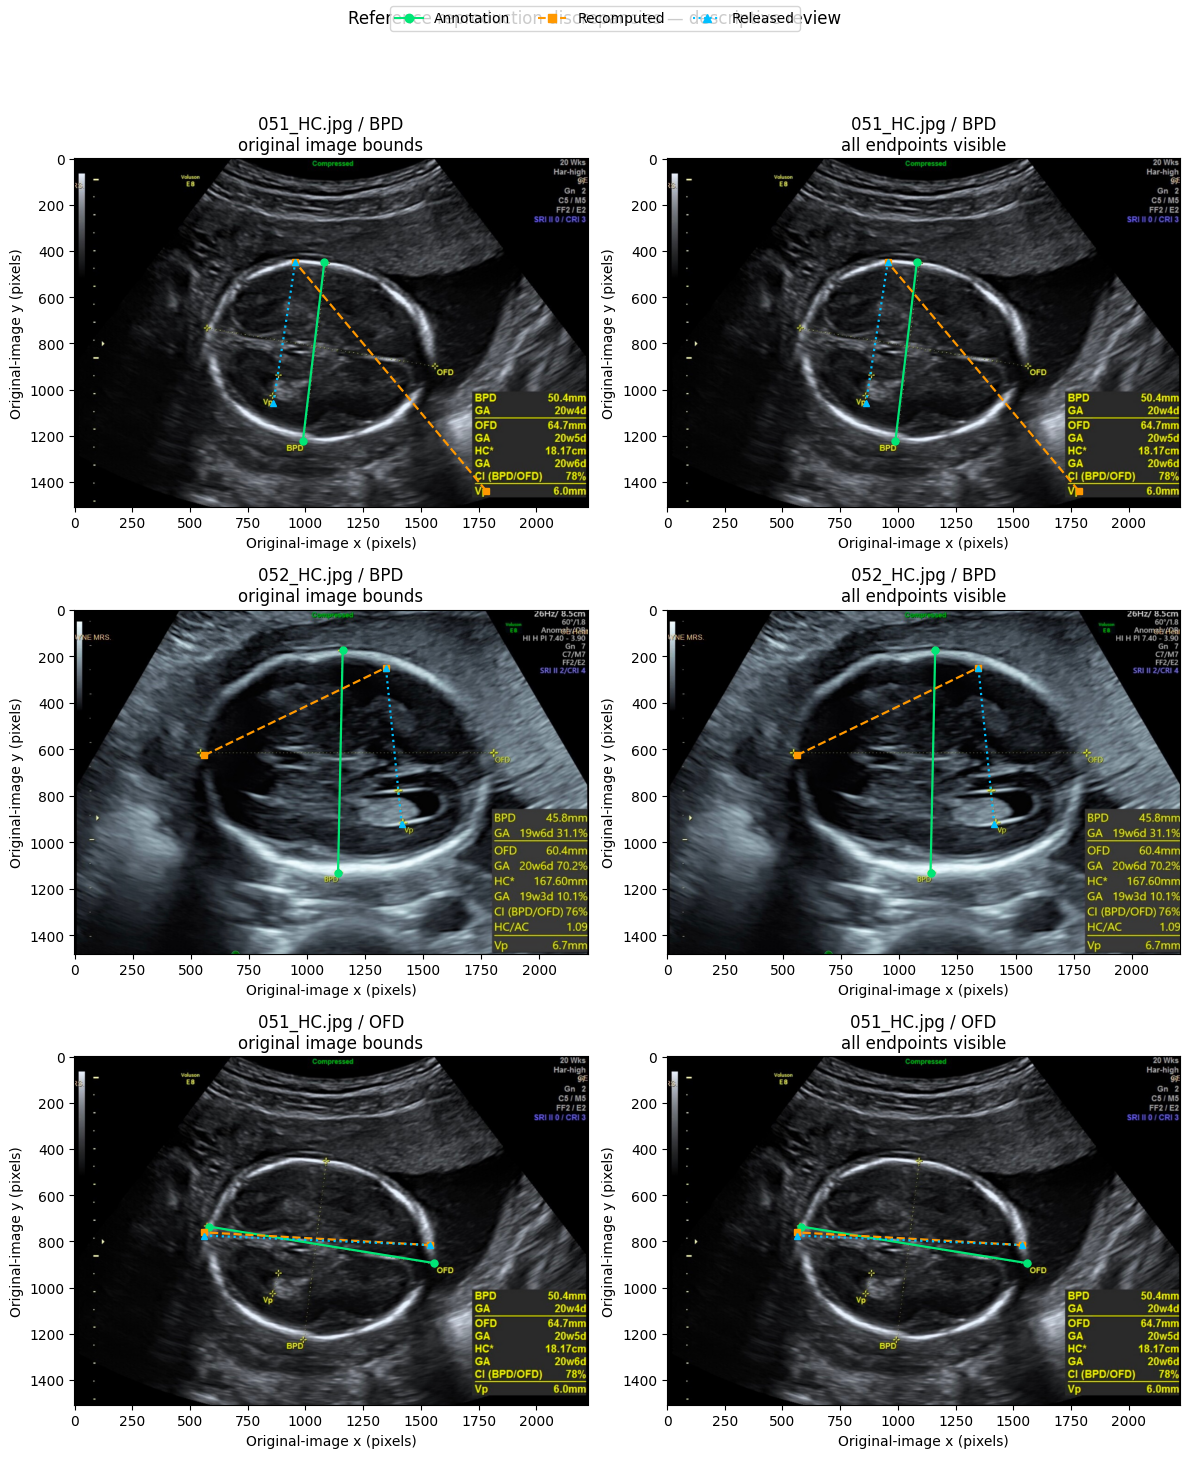


ENDPOINT COORDINATES AND IMAGE BOUNDS
          record_id measurement prediction_version  image_width  image_height     x1     y1     x2     y2  endpoints_outside_image   length_px
UCL:Head:051_HC.jpg         bpd         Annotation         2222          1508  989.0 1222.0 1082.0  448.0                        0  779.567188
UCL:Head:051_HC.jpg         bpd         Recomputed         2222          1508 1783.0 1439.0  956.0  449.0                        0 1289.972480
UCL:Head:051_HC.jpg         bpd           Released         2222          1508  861.0 1060.0  956.0  449.0                        0  618.341330
UCL:Head:052_HC.jpg         bpd         Annotation         2208          1480 1154.0  174.0 1134.0 1132.0                        0  958.208746
UCL:Head:052_HC.jpg         bpd         Recomputed         2208          1480  559.0  626.0 1340.0  249.0                        0  867.231226
UCL:Head:052_HC.jpg         bpd           Released         2208          1480 1408.0  922.0 1340.0  249

In [22]:
# BLOCK 53 — Visualize reference prediction discrepancies (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
RUN = PROJECT / "evaluation_results/reference_fp_ucl_20260913T083139107704Z"
REVIEW = RUN / "release_agreement_20260913T083632333670Z"
SENSITIVITY = RUN / "prediction_sensitivity_20260913T083831064963Z"
DATASET = PROJECT / "data/FetalBiometry-Multicentre"
MANIFEST = (
    PROJECT / "data/manifests/patient_safe_v2_20260912T151813194803Z"
    / "unified_manifest.csv"
)
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = RUN / f"visual_review_{STAMP}"
FIGURES = PROJECT / "paper_artifacts/figures/reference_review"
TABLES = PROJECT / "paper_artifacts/tables/data"
for directory in (OUT, FIGURES, TABLES):
    directory.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

current = pd.read_csv(RUN / "reference_predictions.csv")
affected = pd.read_csv(SENSITIVITY / "images_requiring_review.csv")
receipts = pd.read_csv(REVIEW / "release_agreement.csv").set_index("measurement")
manifest = pd.read_csv(MANIFEST, dtype=str)
if manifest["record_id"].duplicated().any():
    raise RuntimeError("Manifest record IDs are not unique.")
manifest = manifest.set_index("record_id")

if affected.empty:
    raise RuntimeError("No discrepant measurement records were found.")

# Preserve Block 50 row ordering when matching released tensors.
released_by_key = {}
for measurement in affected["measurement"].unique():
    path = REVIEW / f"{measurement}_released_predictions.pth"
    if sha256_file(path) != receipts.loc[measurement, "release_prediction_sha256"]:
        raise RuntimeError(f"Released prediction hash mismatch: {measurement}")

    tensor = torch.load(path, map_location="cpu", weights_only=True)
    rows = current.loc[current["measurement"].eq(measurement)]
    if tuple(tensor.shape) != (len(rows), 2, 2):
        raise RuntimeError("Released tensor shape mismatch.")
    for record_id, points in zip(rows["record_id"], tensor.numpy()):
        released_by_key[(record_id, measurement)] = points.astype(float)

styles = {
    "Annotation": ("#00e676", "o", "-"),
    "Recomputed": ("#ff9800", "s", "--"),
    "Released": ("#00bfff", "^", ":"),
}
records = []
n = len(affected)
fig, axes = plt.subplots(n, 2, figsize=(12, 4.8 * n), squeeze=False)

for row_index, item in enumerate(affected.to_dict("records")):
    record_id = item["record_id"]
    measurement = item["measurement"]
    meta = manifest.loc[record_id]
    selected = current.loc[
        current["record_id"].eq(record_id)
        & current["measurement"].eq(measurement)
    ]
    if len(selected) != 1:
        raise RuntimeError("Ambiguous current prediction.")
    prediction = selected.iloc[0]

    image_path = DATASET / meta["image_relative_path"]
    with Image.open(image_path) as image:
        rgb = np.asarray(image.convert("RGB"))
    height, width = rgb.shape[:2]

    target = prediction[
        ["target_x1", "target_y1", "target_x2", "target_y2"]
    ].to_numpy(float).reshape(2, 2)
    recomputed = prediction[
        ["predicted_x1", "predicted_y1", "predicted_x2", "predicted_y2"]
    ].to_numpy(float).reshape(2, 2)
    released = released_by_key[(record_id, measurement)]

    point_sets = {
        "Annotation": target,
        "Recomputed": recomputed,
        "Released": released,
    }

    # Left: complete image. Right: include all endpoints, even off-image.
    all_points = np.concatenate(list(point_sets.values()))
    x_min = min(-0.5, float(all_points[:, 0].min()) - 20)
    x_max = max(width - 0.5, float(all_points[:, 0].max()) + 20)
    y_min = min(-0.5, float(all_points[:, 1].min()) - 20)
    y_max = max(height - 0.5, float(all_points[:, 1].max()) + 20)

    for column, ax in enumerate(axes[row_index]):
        ax.imshow(rgb)
        for label, points in point_sets.items():
            color, marker, line = styles[label]
            ax.plot(
                points[:, 0], points[:, 1],
                color=color, marker=marker, linestyle=line,
                linewidth=1.6, markersize=5,
            )
        if column == 0:
            ax.set_xlim(-0.5, width - 0.5)
            ax.set_ylim(height - 0.5, -0.5)
            view = "original image bounds"
        else:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_max, y_min)
            view = "all endpoints visible"
        ax.set_aspect("equal")
        ax.set_title(f"{image_path.name} / {measurement.upper()}\n{view}")
        ax.set_xlabel("Original-image x (pixels)")
        ax.set_ylabel("Original-image y (pixels)")

    for label, points in point_sets.items():
        outside = (
            (points[:, 0] < 0) | (points[:, 0] > width - 1)
            | (points[:, 1] < 0) | (points[:, 1] > height - 1)
        )
        records.append({
            "record_id": record_id,
            "measurement": measurement,
            "prediction_version": label,
            "image_width": width,
            "image_height": height,
            "x1": float(points[0, 0]),
            "y1": float(points[0, 1]),
            "x2": float(points[1, 0]),
            "y2": float(points[1, 1]),
            "endpoints_outside_image": int(outside.sum()),
            "length_px": float(np.linalg.norm(points[1] - points[0])),
        })

handles = [
    Line2D([0], [0], color=color, marker=marker, linestyle=line, label=label)
    for label, (color, marker, line) in styles.items()
]
fig.legend(handles=handles, loc="upper center", ncol=3)
fig.suptitle(
    "Reference reproduction discrepancies — descriptive review",
    y=1.01,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))

png = FIGURES / f"reference_discrepancies_{STAMP}.png"
pdf = FIGURES / f"reference_discrepancies_{STAMP}.pdf"
fig.savefig(png, dpi=200, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

coordinate_table = pd.DataFrame(records)
table_path = TABLES / f"reference_discrepancy_coordinates_{STAMP}.csv"
coordinate_table.to_csv(table_path, index=False)
coordinate_table.to_csv(OUT / "coordinates.csv", index=False)

summary = {
    "status": "REFERENCE_DISCREPANCY_FIGURES_SAVED",
    "measurement_records_visualized": len(affected),
    "unique_images": int(affected["record_id"].nunique()),
    "figure_png": str(png),
    "figure_pdf": str(pdf),
    "coordinate_table": str(table_path),
    "cause_of_disagreement": "UNRESOLVED",
    "review_type": "post_hoc_descriptive",
    "limitation": (
        "Visual overlays can identify different endpoint locations, "
        "but cannot establish why released and recomputed predictions differ."
    ),
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
new_entries = pd.DataFrame([
    {"block": 53, "artifact_type": kind, "path": str(path)}
    for kind, path in [
        ("figure_png", png), ("figure_pdf", pdf),
        ("coordinate_table", table_path),
    ]
])
if index_path.exists() and index_path.stat().st_size:
    new_entries = pd.concat(
        [pd.read_csv(index_path), new_entries], ignore_index=True, sort=False
    )
new_entries.to_csv(index_path, index=False)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 53 — reference discrepancy visualization\n"
            f"- Visualized {len(affected)} measurement records.\n"
            "- Saved original-image and expanded-bound overlays.\n"
            "- Cause of prediction disagreement remains unresolved.\n"
            f"- Figure: `{png}`.\n"
            f"- Coordinates: `{table_path}`.\n"
        )

print("\nENDPOINT COORDINATES AND IMAGE BOUNDS")
print(coordinate_table.to_string(index=False))
print(f"\nFigures saved to: {FIGURES}")
print("\nBLOCK 53 COMPLETED")

In [23]:
# BLOCK 54 — BPD batch-size repeatability diagnostic (CPU)
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import subprocess
import sys
import textwrap

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ROOT = PROJECT / "reference_evidence/published_assets_a120aace9965"
SOURCE = ROOT / "source"
RUN = PROJECT / "evaluation_results/reference_fp_ucl_20260913T083139107704Z"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = RUN / f"batch_repeatability_{STAMP}"
OUT.mkdir(parents=True, exist_ok=True)

script = textwrap.dedent(r'''
    import math
    import sys
    import json
    import hashlib
    from pathlib import Path

    import numpy as np
    np.math = math
    import pandas as pd
    import torch

    project, source, run, out = map(Path, sys.argv[1:5])
    sys.path.insert(0, str(source))
    from lib.config import config
    import lib.models as models
    from lib.datasets import get_dataset
    from lib.core.evaluation import decode_preds

    torch.set_num_threads(2)

    def sha(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def endpoint_difference(a, b):
        direct = np.linalg.norm(a - b, axis=1).mean()
        swapped = np.linalg.norm(a - b[::-1], axis=1).mean()
        return float(min(direct, swapped))

    converted = (
        project / "reference_evidence/published_assets_a120aace9965"
        / "tensor_checkpoints_20260913T081621588569Z"
    )
    manifest = pd.read_csv(
        converted / "checkpoint_manifest.csv", dtype=str
    ).set_index("measurement")
    checkpoint = Path(manifest.loc["bpd", "tensor_checkpoint"])
    if sha(checkpoint) != manifest.loc["bpd", "tensor_checkpoint_sha256"]:
        raise RuntimeError("BPD checkpoint hash mismatch.")

    cfg = config.clone()
    cfg.defrost()
    cfg.merge_from_file(str(
        source / "experiments/fetal/fetal_landmark_hrnet_w18_UCL_brain_BPD.yaml"
    ))
    cfg.MODEL.INIT_WEIGHTS = False
    data = project / "data/FetalBiometry-Multicentre"
    cfg.DATASET.ROOT = str(data / "images/UCL/Head")
    cfg.DATASET.TESTSET = str(data / "annotations/UCL/Head_Test.csv")
    cfg.freeze()

    payload = torch.load(checkpoint, map_location="cpu", weights_only=True)
    model = models.get_face_alignment_net(cfg).cpu().eval()
    state = payload["state_dict"]
    if all(key.startswith("module.") for key in state):
        state = {key[7:]: value for key, value in state.items()}
    model.load_state_dict(state, strict=True)

    dataset = get_dataset(cfg)(
        cfg, is_train=False, d_vect=payload["d_vect"].numpy()
    )
    names = dataset.landmarks_frame.iloc[:, 0].astype(str).tolist()
    targets = ["051_HC.jpg", "052_HC.jpg"]
    if any(names.count(name) != 1 for name in targets):
        raise RuntimeError("Target filenames are missing or ambiguous.")

    current = pd.read_csv(run / "reference_predictions.csv")
    current = current.loc[current.measurement.eq("bpd")].reset_index(drop=True)
    if [value.split(":", 2)[-1] for value in current.record_id] != names:
        raise RuntimeError("Current predictions and dataset order differ.")

    release_dir = run / "release_agreement_20260913T083632333670Z"
    receipt = pd.read_csv(
        release_dir / "release_agreement.csv"
    ).set_index("measurement")
    release_path = release_dir / "bpd_released_predictions.pth"
    if sha(release_path) != receipt.loc["bpd", "release_prediction_sha256"]:
        raise RuntimeError("Released prediction hash mismatch.")
    released = torch.load(
        release_path, map_location="cpu", weights_only=True
    ).numpy()

    pred_fields = [
        "predicted_x1", "predicted_y1", "predicted_x2", "predicted_y2"
    ]

    # Cache all needed inputs once: every condition uses identical pixels.
    needed = set()
    for name in targets:
        index = names.index(name)
        start = (index // 8) * 8
        needed.update(range(start, min(start + 8, len(dataset))))
    samples = {index: dataset[index] for index in sorted(needed)}

    # Record model state to ensure evaluation preserves parameters and buffers.
    def state_hash():
        digest = hashlib.sha256()
        for key, tensor in model.state_dict().items():
            digest.update(key.encode())
            digest.update(tensor.detach().cpu().contiguous().numpy().tobytes())
        return digest.hexdigest()

    before = state_hash()
    baseline_heatmaps = {}
    baseline_points = {}
    records = []

    for name in targets:
        index = names.index(name)
        start = (index // 8) * 8
        original_batch = list(range(start, min(start + 8, len(dataset))))
        old_points = current.iloc[index][pred_fields].to_numpy(float).reshape(2, 2)

        conditions = [
            ("single", [index]),
            ("original_batch", original_batch),
        ]
        for condition, indices in conditions:
            images = torch.stack([
                torch.as_tensor(samples[i][0]).float() for i in indices
            ])
            centers = torch.stack([
                torch.as_tensor(samples[i][2]["center"]).float() for i in indices
            ])
            scales = torch.tensor(
                [float(samples[i][2]["scale"]) for i in indices],
                dtype=torch.float64,
            )
            position = indices.index(index)

            for repeat in (1, 2):
                print(f"{name}: {condition}, repeat {repeat}...", flush=True)
                with torch.inference_mode():
                    heatmaps = model(images).cpu()
                    points = decode_preds(
                        heatmaps.clone(), centers, scales,
                        list(cfg.MODEL.HEATMAP_SIZE),
                    ).numpy()[position]
                heatmap = heatmaps[position].numpy().copy()
                if not np.isfinite(heatmap).all() or not np.isfinite(points).all():
                    raise RuntimeError("Nonfinite diagnostic output.")

                if name not in baseline_heatmaps:
                    baseline_heatmaps[name] = heatmap.copy()
                    baseline_points[name] = points.copy()

                flat = heatmap.reshape(2, -1)
                top = np.partition(flat, -2, axis=1)[:, -2:]
                peak_gaps = top.max(axis=1) - top.min(axis=1)

                records.append({
                    "image_name": name,
                    "condition": condition,
                    "batch_size": len(indices),
                    "repeat": repeat,
                    "difference_from_single_first_px": endpoint_difference(
                        points, baseline_points[name]
                    ),
                    "difference_from_block50_px": endpoint_difference(
                        points, old_points
                    ),
                    "difference_from_released_px": endpoint_difference(
                        points, released[index]
                    ),
                    "max_heatmap_difference_from_single": float(
                        np.abs(heatmap - baseline_heatmaps[name]).max()
                    ),
                    "channel0_top_two_peak_gap": float(peak_gaps[0]),
                    "channel1_top_two_peak_gap": float(peak_gaps[1]),
                    "x1": float(points[0, 0]), "y1": float(points[0, 1]),
                    "x2": float(points[1, 0]), "y2": float(points[1, 1]),
                })
                np.savez_compressed(
                    out / f"{Path(name).stem}_{condition}_repeat{repeat}.npz",
                    heatmap=heatmap, points=points,
                )

    unchanged = state_hash() == before
    if not unchanged:
        raise RuntimeError("Model state changed during evaluation.")

    table = pd.DataFrame(records)
    table.to_csv(out / "repeatability.csv", index=False)
    summary = {
        "status": "BPD_BATCH_REPEATABILITY_DIAGNOSTIC_COMPLETED",
        "checkpoint_sha256": sha(checkpoint),
        "images": targets,
        "torch_version": torch.__version__,
        "numpy_version": np.__version__,
        "cpu_threads": torch.get_num_threads(),
        "mkldnn_enabled": torch.backends.mkldnn.enabled,
        "model_state_unchanged": unchanged,
        "max_endpoint_difference_from_single_px": float(
            table["difference_from_single_first_px"].max()
        ),
        "interpretation_limits": [
            "Diagnostic uses only two previously identified test images.",
            "Small heatmap differences can change argmax when peaks are close.",
            "Batch dependence, if observed, does not prove the release environment.",
            "This diagnostic does not change the locked evaluation predictions.",
        ],
    }
    (out / "summary.json").write_text(json.dumps(summary, indent=2))
    print("\nREPEATABILITY RESULTS")
    print(table.to_string(index=False))
''')

script_path = OUT / "check_batch_repeatability.py"
script_path.write_text(script, encoding="utf-8")
environment = os.environ.copy()
environment["CUDA_VISIBLE_DEVICES"] = ""

with (OUT / "diagnostic_log.txt").open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [sys.executable, "-u", str(script_path),
         str(PROJECT), str(SOURCE), str(RUN), str(OUT)],
        cwd=str(SOURCE), env=environment,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
    code = process.wait()

if code:
    raise RuntimeError(f"Diagnostic stopped; see {OUT / 'diagnostic_log.txt'}")

summary = json.loads((OUT / "summary.json").read_text())
table = pd.read_csv(OUT / "repeatability.csv")
tables_dir = PROJECT / "paper_artifacts/tables/data"
tables_dir.mkdir(parents=True, exist_ok=True)
table.to_csv(tables_dir / f"reference_batch_repeatability_{STAMP}.csv", index=False)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 54 — reference batch repeatability\n"
            "- Tested two BPD images individually and in their original batches.\n"
            f"- Maximum difference from first single-image prediction: "
            f"{summary['max_endpoint_difference_from_single_px']:.6f} pixels.\n"
            "- Model state remained unchanged; diagnostic only.\n"
            f"- Results: `{OUT}`.\n"
        )

print(f"\nSaved diagnostic: {OUT}")
print("\nBLOCK 54 COMPLETED")

051_HC.jpg: single, repeat 1...
051_HC.jpg: single, repeat 2...
051_HC.jpg: original_batch, repeat 1...
051_HC.jpg: original_batch, repeat 2...
052_HC.jpg: single, repeat 1...
052_HC.jpg: single, repeat 2...
052_HC.jpg: original_batch, repeat 1...
052_HC.jpg: original_batch, repeat 2...

REPEATABILITY RESULTS
image_name      condition  batch_size  repeat  difference_from_single_first_px  difference_from_block50_px  difference_from_released_px  max_heatmap_difference_from_single  channel0_top_two_peak_gap  channel1_top_two_peak_gap     x1     y1     x2    y2
051_HC.jpg         single           1       1                              0.0                         0.0                   498.428772                        0.000000e+00                   0.000773                   0.014606 1783.0 1439.0  956.0 449.0
051_HC.jpg         single           1       2                              0.0                         0.0                   498.428772                        0.000000e+00            

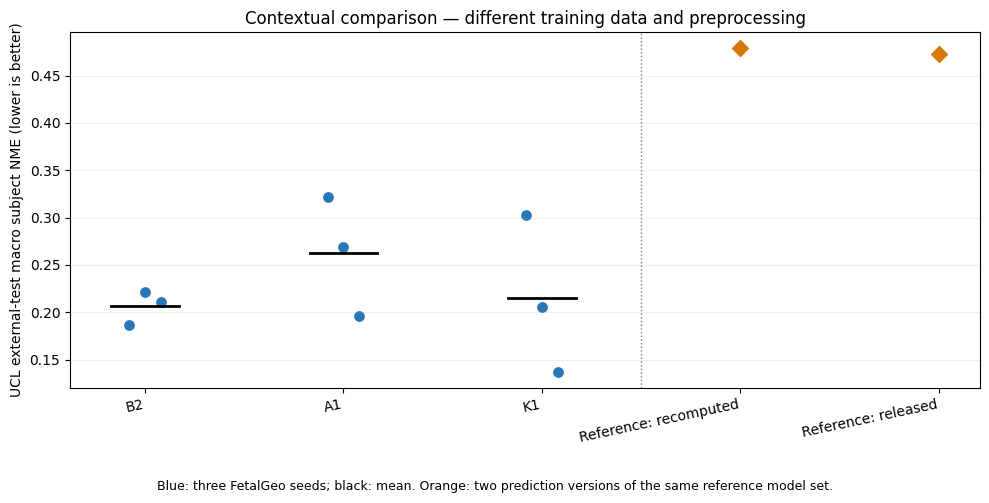


CONTEXTUAL EXTERNAL COMPARISON
                model  mean_nme  seed_sd  training_runs training_data     input_preprocessing                           model_structure
                   B2  0.206460 0.018088            3.0     FP + HC18    Full-image letterbox                  One joint model per seed
                   A1  0.262225 0.063433            3.0     FP + HC18    Full-image letterbox                  One joint model per seed
                   K1  0.215128 0.083039            3.0     FP + HC18    Full-image letterbox                  One joint model per seed
Reference: recomputed  0.478685      NaN            NaN            FP Annotation-derived crop Five measurement-specific released models
  Reference: released  0.472444      NaN            NaN            FP Annotation-derived crop Five measurement-specific released models

Saved paper table: /content/drive/MyDrive/FetalGeo/paper_artifacts/tables/data/external_contextual_comparison_20260913T120016526072UTC.csv
Saved paper 

In [24]:
# BLOCK 55 — Consolidate contextual external-test comparison
from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
REFERENCE = (
    PROJECT / "evaluation_results"
    / "reference_fp_ucl_20260913T083139107704Z"
)
SENSITIVITY = REFERENCE / "prediction_sensitivity_20260913T083831064963Z"
REPEATABILITY = REFERENCE / "batch_repeatability_20260913T115710587802Z"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%f%Z")
OUT = REFERENCE / f"consolidated_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/reference_comparison"

for folder in (OUT, TABLES, FIGURES):
    folder.mkdir(parents=True, exist_ok=True)

# Find the existing locked core prediction directory unambiguously.
core_candidates = [
    path for path in (PROJECT / "evaluation_results").glob("core_*")
    if path.is_dir()
    and (path / "B2_seed20260912_predictions.csv").is_file()
]
if len(core_candidates) != 1:
    raise RuntimeError(
        f"Expected one core prediction directory, found {len(core_candidates)}."
    )
CORE = core_candidates[0]

MEASUREMENTS = {"ofd", "bpd", "tad", "apad", "fl"}
SEEDS = [20260912, 20260913, 20260914]

def parse_bool(series):
    values = series.astype(str).str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError("Unrecognized eligibility values.")
    return values.isin(["true", "1"])

def subject_scores(frame, error_column):
    usable = frame.loc[frame["primary_eligible"]].copy()
    usable[error_column] = pd.to_numeric(
        usable[error_column], errors="raise"
    )
    if not np.isfinite(usable[error_column]).all():
        raise RuntimeError("Nonfinite eligible errors.")
    subject_means = usable.groupby(
        ["measurement", "subject_key"]
    )[error_column].mean()
    result = subject_means.groupby("measurement").mean()
    if set(result.index) != MEASUREMENTS:
        raise RuntimeError("Missing measurement coverage.")
    return result

reference_pairs = pd.read_csv(SENSITIVITY / "paired_prediction_errors.csv")
reference_pairs["primary_eligible"] = parse_bool(
    reference_pairs["primary_eligible"]
)
if reference_pairs.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate reference prediction keys.")

reference_keys = set(zip(
    reference_pairs["record_id"], reference_pairs["measurement"]
))
reference_identity = reference_pairs.set_index(
    ["record_id", "measurement"]
)[["subject_key", "primary_eligible"]].sort_index()

per_measurement = []
per_seed_macro = []

for variant in ("B2", "A1", "K1"):
    for seed in SEEDS:
        path = CORE / f"{variant}_seed{seed}_predictions.csv"
        frame = pd.read_csv(path)
        frame = frame.loc[frame["role"].eq("external_test")].copy()
        frame["primary_eligible"] = parse_bool(frame["primary_eligible"])

        if frame.duplicated(["record_id", "measurement"]).any():
            raise RuntimeError(f"Duplicate keys in {path.name}")
        if set(zip(frame.record_id, frame.measurement)) != reference_keys:
            raise RuntimeError(f"External coverage mismatch: {path.name}")

        identity = frame.set_index(["record_id", "measurement"])[
            ["subject_key", "primary_eligible"]
        ].sort_index()
        if not identity.equals(reference_identity):
            raise RuntimeError(f"Subject or eligibility mismatch: {path.name}")

        scores = subject_scores(frame, "nme")
        per_seed_macro.append({
            "model": variant,
            "seed": seed,
            "macro_subject_nme": float(scores.mean()),
        })
        for measurement, value in scores.items():
            per_measurement.append({
                "model": variant, "seed": seed,
                "measurement": measurement,
                "subject_average_nme": float(value),
            })

seed_table = pd.DataFrame(per_seed_macro)
comparison = seed_table.groupby("model").agg(
    mean_nme=("macro_subject_nme", "mean"),
    seed_sd=("macro_subject_nme", "std"),
    training_runs=("seed", "nunique"),
).reset_index()
comparison["training_data"] = "FP + HC18"
comparison["input_preprocessing"] = "Full-image letterbox"
comparison["model_structure"] = "One joint model per seed"

reference_rows = []
for label, column in [
    ("Reference: recomputed", "recomputed_nme"),
    ("Reference: released", "released_nme"),
]:
    scores = subject_scores(reference_pairs, column)
    reference_rows.append({
        "model": label,
        "mean_nme": float(scores.mean()),
        "seed_sd": np.nan,
        "training_runs": np.nan,
        "training_data": "FP",
        "input_preprocessing": "Annotation-derived crop",
        "model_structure": "Five measurement-specific released models",
    })
    for measurement, value in scores.items():
        per_measurement.append({
            "model": label, "seed": np.nan,
            "measurement": measurement,
            "subject_average_nme": float(value),
        })

comparison = pd.concat(
    [comparison, pd.DataFrame(reference_rows)], ignore_index=True
)
order = ["B2", "A1", "K1", "Reference: recomputed", "Reference: released"]
comparison = comparison.set_index("model").loc[order].reset_index()

repeat = pd.read_csv(REPEATABILITY / "repeatability.csv")
max_batch_difference = float(
    repeat["difference_from_single_first_px"].max()
)

table_path = TABLES / f"external_contextual_comparison_{STAMP}.csv"
comparison.to_csv(table_path, index=False)
seed_table.to_csv(OUT / "core_per_seed_macro.csv", index=False)
pd.DataFrame(per_measurement).to_csv(
    OUT / "all_per_measurement_scores.csv", index=False
)
comparison.to_csv(OUT / "comparison.csv", index=False)

# Individual seed points; reference versions are alternative outputs,
# not independent seeds or additional trained models.
fig, ax = plt.subplots(figsize=(10, 5))
for position, label in enumerate(order):
    value = float(comparison.loc[comparison.model.eq(label), "mean_nme"].iloc[0])
    if label in {"B2", "A1", "K1"}:
        points = seed_table.loc[
            seed_table.model.eq(label), "macro_subject_nme"
        ].to_numpy()
        ax.scatter(
            position + np.linspace(-0.08, 0.08, len(points)),
            points, color="#2878b5", s=45,
        )
        ax.plot([position - 0.17, position + 0.17],
                [value, value], color="black", linewidth=2)
    else:
        ax.scatter(position, value, marker="D", color="#d97706", s=65)

ax.axvline(2.5, color="gray", linestyle=":", linewidth=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=12, ha="right")
ax.set_ylabel("UCL external-test macro subject NME (lower is better)")
ax.set_title("Contextual comparison — different training data and preprocessing")
ax.grid(axis="y", alpha=0.2)
fig.text(
    0.5, 0.01,
    "Blue: three FetalGeo seeds; black: mean. "
    "Orange: two prediction versions of the same reference model set.",
    ha="center", fontsize=9,
)
fig.tight_layout(rect=(0, 0.07, 1, 1))

png = FIGURES / f"external_contextual_comparison_{STAMP}.png"
pdf = FIGURES / f"external_contextual_comparison_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = {
    "status": "CONTEXTUAL_REFERENCE_COMPARISON_CONSOLIDATED",
    "output_directory": str(OUT),
    "maximum_batch_diagnostic_endpoint_change_px": max_batch_difference,
    "reference_discrepancy_cause": "UNRESOLVED",
    "diagnostic_conclusion": (
        "Batch sizes 1 and 8 produced identical endpoints for the two "
        "tested BPD images in this CPU environment."
    ),
    "interpretation": [
        "Both reference prediction versions are retained.",
        "Their results are contextual, not a matched superiority test.",
        "A1 remains worse than B2 on the locked external cohort.",
        "No models or checkpoints were selected using this comparison.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 55 — consolidated contextual reference results\n"
            "- Recomputed all core external scores from saved prediction CSVs.\n"
            "- Included both released and recomputed reference predictions.\n"
            "- Batch-size diagnostic did not explain the two BPD discrepancies.\n"
            "- Discrepancy cause remains unresolved.\n"
            "- Reference comparison differs in training data and cropping.\n"
            f"- Table: `{table_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {"block": 55, "artifact_type": kind, "path": str(path)}
    for kind, path in [
        ("table", table_path), ("figure_png", png), ("figure_pdf", pdf)
    ]
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries], ignore_index=True, sort=False
    )
entries.to_csv(index_path, index=False)

print("\nCONTEXTUAL EXTERNAL COMPARISON")
print(comparison.to_string(index=False))
print(f"\nSaved paper table: {table_path}")
print(f"Saved paper figures: {FIGURES}")
print("\nBLOCK 55 COMPLETED")

In [25]:
# BLOCK 56 — Freeze FP-only training experiment setup (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
MANIFEST_DIR = (
    PROJECT / "data/manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
MASK_DIR = (
    PROJECT / "data/manifests"
    / "provisional_masks_20260912T161641409242Z"
)
CACHE = (
    PROJECT / "data/cache"
    / "letterbox256_9093c1bcf56fd66fa9a6"
)
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = PROJECT / "experiment_setups" / f"fp_only_v1_{STAMP}"
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
SEEDS = [20260912, 20260913, 20260914]

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def parse_bool(series):
    values = series.astype(str).str.strip().str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError(
            f"Unrecognized boolean values in {series.name}."
        )
    return values.isin(["true", "1"])

def require_columns(frame, columns, label):
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise RuntimeError(f"{label} is missing columns: {missing}")

paths = {
    "manifest": MANIFEST_DIR / "unified_manifest.csv",
    "masks": MASK_DIR / "measurement_masks.csv",
    "cache_index": CACHE / "cache_index.csv",
}
for label, path in paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing {label}: {path}")

manifest = pd.read_csv(paths["manifest"], dtype=str)
masks = pd.read_csv(paths["masks"], dtype=str)
cache_index = pd.read_csv(paths["cache_index"], dtype=str)

require_columns(
    manifest, ["record_id", "source", "role", "subject_key", "anatomy"],
    "Manifest",
)
require_columns(
    masks,
    ["record_id", "measurement",
     "training_eligible_candidate", "training_weight_candidate"],
    "Masks",
)
require_columns(
    cache_index, ["record_id", "chunk_file", "position"],
    "Cache index",
)

if manifest["record_id"].duplicated().any():
    raise RuntimeError("Manifest record IDs are not unique.")
if cache_index["record_id"].duplicated().any():
    raise RuntimeError("Cache record IDs are not unique.")
if masks.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate measurement-mask keys.")

# Use manifest roles as the authoritative source for this selection.
manifest_index = manifest.set_index("record_id")
fp_train = manifest.loc[
    manifest["role"].eq("train") & manifest["source"].eq("FP")
].copy()
fp_ids = set(fp_train["record_id"])

selected_masks = masks.loc[masks["record_id"].isin(fp_ids)].copy()
selected_masks["eligible"] = parse_bool(
    selected_masks["training_eligible_candidate"]
)
selected_masks["weight"] = pd.to_numeric(
    selected_masks["training_weight_candidate"], errors="raise"
)

if not np.isfinite(selected_masks["weight"]).all():
    raise RuntimeError("Nonfinite training weights.")
if (selected_masks["weight"] < 0).any():
    raise RuntimeError("Negative training weights.")

# Preserve the previous eligibility and duplicate-weighting policy.
selected_masks["fp_training_weight"] = np.where(
    selected_masks["eligible"], selected_masks["weight"], 0.0
)
eligible_masks = selected_masks.loc[selected_masks["eligible"]].copy()
if (eligible_masks["fp_training_weight"] <= 0).any():
    raise RuntimeError("An eligible measurement has nonpositive weight.")

training_ids = set(eligible_masks["record_id"])
training_images = fp_train.loc[
    fp_train["record_id"].isin(training_ids)
].copy()
training_images = training_images.merge(
    cache_index[["record_id", "chunk_file", "position"]],
    on="record_id", how="left", validate="one_to_one",
)
if training_images[["chunk_file", "position"]].isna().any().any():
    raise RuntimeError("Some FP training images are absent from the cache.")

# Retain exactly the existing FP+HC18 validation membership.
validation = manifest.loc[
    manifest["role"].eq("internal_validation")
].copy()
if training_ids & set(validation["record_id"]):
    raise RuntimeError("Training/validation image overlap.")
if set(training_images["subject_key"]) & set(validation["subject_key"]):
    raise RuntimeError("Training/validation subject-key overlap.")

if not training_images["source"].eq("FP").all():
    raise RuntimeError("Non-FP source entered training.")
if not training_images["role"].eq("train").all():
    raise RuntimeError("Non-training role entered training.")

totals = eligible_masks.groupby("measurement").agg(
    eligible_measurements=("record_id", "size"),
    training_weight_sum=("fp_training_weight", "sum"),
).reindex(MEASUREMENTS)

if totals.isna().any().any() or (totals["training_weight_sum"] <= 0).any():
    raise RuntimeError("Missing supervision for one or more measurements.")

# Expected counts follow from the previously audited FP subset.
if len(training_images) != 934:
    raise RuntimeError(
        f"Expected 934 eligible FP images; found {len(training_images)}. "
        "Review the selection before training."
    )

# Capture the original matched augmented run settings for each seed/model.
# The training block must use these and replace only dataset-dependent totals.
parent_configs = {}
for variant in ("B2", "A1", "K1"):
    for seed in SEEDS:
        path = (
            PROJECT / "runs"
            / f"{variant}_aug30_v1_seed{seed}" / "run_config.json"
        )
        if not path.is_file():
            raise FileNotFoundError(f"Missing parent run configuration: {path}")
        parent_configs[f"{variant}_seed{seed}"] = {
            "path": str(path),
            "sha256": sha256_file(path),
            "configuration": json.loads(path.read_text(encoding="utf-8")),
        }

OUT.mkdir(parents=True, exist_ok=False)
training_images.to_csv(OUT / "training_images.csv", index=False)
selected_masks.to_csv(OUT / "training_measurement_masks.csv", index=False)
validation.to_csv(OUT / "validation_images.csv", index=False)
totals.reset_index().to_csv(OUT / "training_coverage.csv", index=False)

configuration = {
    "experiment": "FP-only training-source ablation",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "study_status": "EXPLORATORY_FOLLOW_UP_AFTER_CORE_TEST_RESULTS",
    "variants": ["B2", "A1", "K1"],
    "seeds": SEEDS,
    "epochs": 30,
    "training_source": "FP",
    "training_images": len(training_images),
    "training_subject_keys": int(training_images["subject_key"].nunique()),
    "measurement_order": MEASUREMENTS,
    "training_weight_totals": {
        name: float(totals.loc[name, "training_weight_sum"])
        for name in MEASUREMENTS
    },
    "validation_policy": (
        "Same original FP+HC18 internal-validation records and masks; "
        "select checkpoint using local-head macro subject NME."
    ),
    "initialization_policy": (
        "Restart from each seed's original shared initialization, "
        "not a trained B2/A1/K1 checkpoint."
    ),
    "training_policy": (
        "Use each matched augmented parent run configuration. "
        "Replace training membership, number of training images, and "
        "per-measurement loss-normalization totals with this setup."
    ),
    "comparison_budget": {
        "epochs_matched": True,
        "optimizer_steps_matched": False,
        "reason": (
            "FP-only training has fewer images and therefore fewer "
            "optimizer updates per epoch at the same batch size."
        ),
    },
    "test_policy": (
        "Do not use internal-test or UCL results for checkpoint selection "
        "or additional tuning. Any later test assessment is exploratory."
    ),
    "cache_directory": str(CACHE),
    "parent_runs": parent_configs,
    "input_sha256": {
        label: sha256_file(path) for label, path in paths.items()
    },
    "output_csv_sha256": {
        name: sha256_file(OUT / name)
        for name in [
            "training_images.csv",
            "training_measurement_masks.csv",
            "validation_images.csv",
            "training_coverage.csv",
        ]
    },
    "training_started": False,
}

config_path = OUT / "experiment_config.json"
config_path.write_text(
    json.dumps(configuration, indent=2), encoding="utf-8"
)

TABLES = PROJECT / "paper_artifacts/tables/data"
TABLES.mkdir(parents=True, exist_ok=True)
table_path = TABLES / f"fp_only_training_coverage_{STAMP}.csv"
totals.reset_index().to_csv(table_path, index=False)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 56 — FP-only follow-up experiment setup\n"
            f"- Eligible FP training images: {len(training_images)}.\n"
            "- Planned variants: B2, A1, K1; three matched seeds; 30 epochs.\n"
            "- Original mixed-source validation set retained.\n"
            "- Training loss normalization recalculated for FP-only data.\n"
            "- Equal epochs imply fewer optimizer updates than mixed-source runs.\n"
            "- Exploratory follow-up; no training started in this block.\n"
            f"- Configuration: `{config_path}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {"block": 56, "artifact_type": "experiment_configuration",
     "path": str(config_path)},
    {"block": 56, "artifact_type": "training_coverage",
     "path": str(table_path)},
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries], ignore_index=True, sort=False
    )
entries.to_csv(index_path, index=False)

print("\nFP-ONLY TRAINING COVERAGE")
print(totals.to_string())
print(f"\nEligible training images: {len(training_images)}")
print(f"Unchanged validation images: {len(validation)}")
print("Planned training: B2, A1, K1 × 3 seeds × 30 epochs")
print("Budget: same epochs; fewer optimizer updates with fewer images.")
print(f"\nSaved experiment setup: {OUT}")
print("\nBLOCK 56 COMPLETED — ready to construct the training run")


FP-ONLY TRAINING COVERAGE
             eligible_measurements  training_weight_sum
measurement                                            
ofd                            484                480.0
bpd                            475                471.0
tad                            214                214.0
apad                           214                214.0
fl                             235                235.0

Eligible training images: 934
Unchanged validation images: 282
Planned training: B2, A1, K1 × 3 seeds × 30 epochs
Budget: same epochs; fewer optimizer updates with fewer images.

Saved experiment setup: /content/drive/MyDrive/FetalGeo/experiment_setups/fp_only_v1_20260913T120351288055Z

BLOCK 56 COMPLETED — ready to construct the training run


In [26]:
# BLOCK 57 — Read saved training interfaces for the FP-only runner
from pathlib import Path
import ast
import hashlib
import json

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
SETUP = (
    PROJECT / "experiment_setups"
    / "fp_only_v1_20260913T120351288055Z"
)
configuration_path = SETUP / "experiment_config.json"
configuration = json.loads(configuration_path.read_text(encoding="utf-8"))

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# Verify the prepared FP-only files.
for filename, expected in configuration["output_csv_sha256"].items():
    path = SETUP / filename
    if sha256_file(path) != expected:
        raise RuntimeError(f"FP-only setup file changed: {filename}")

sections = []

# Read the exact run configurations, including initialization paths.
for key in (
    "B2_seed20260912",
    "A1_seed20260912",
    "K1_seed20260912",
    "B2_seed20260913",
    "B2_seed20260914",
):
    parent = configuration["parent_runs"][key]
    path = Path(parent["path"])
    if sha256_file(path) != parent["sha256"]:
        raise RuntimeError(f"Parent configuration changed: {key}")
    sections.append(
        f"\n===== PARENT CONFIGURATION: {key} =====\n"
        + path.read_text(encoding="utf-8")
        + "\n"
    )

# These are the already verified source versions from the completed runs.
code_paths = {
    "model": PROJECT / (
        "code/model_v1_20260912T163435231628Z/fetalgeo_model.py"
    ),
    "loss": PROJECT / (
        "code/loss_v1_20260912T163743169701Z/fetalgeo_losses.py"
    ),
    "loss_configuration": PROJECT / (
        "code/loss_v1_20260912T163743169701Z/loss_config.json"
    ),
    "direct_auxiliary": PROJECT / (
        "code/direct_aux_control_v1_20260913T052558437607Z/"
        "fetalgeo_direct_aux.py"
    ),
}

# Locate the precise augmentation version by its previously recorded hash.
expected_augmentation_sha = (
    "3caa8f5997d8caf1997ae16098712a628e897ddbc87a9a5f91f451169c88893a"
)
augmentation_candidates = sorted(
    (PROJECT / "code").glob("augmentation*/fetalgeo_augmentation.py")
)
matching_augmentation = [
    path for path in augmentation_candidates
    if sha256_file(path) == expected_augmentation_sha
]
if not matching_augmentation:
    raise FileNotFoundError(
        "The previously verified augmentation source was not found."
    )
code_paths["augmentation"] = matching_augmentation[0]

for label, path in code_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing saved source: {path}")

    text = path.read_text(encoding="utf-8")
    sections.append(
        f"\n===== {label.upper()} =====\n"
        f"Path: {path}\nSHA256: {sha256_file(path)}\n"
    )

    if label == "model":
        # Signatures and forward output are sufficient for model construction.
        tree = ast.parse(text)
        for node in tree.body:
            if isinstance(node, ast.ClassDef):
                sections.append(f"\nclass {node.name}\n")
                for method in node.body:
                    if isinstance(method, ast.FunctionDef):
                        if method.name in ("__init__", "forward"):
                            sections.append(ast.get_source_segment(text, method) + "\n")
    else:
        sections.append(text + "\n")

report = "".join(sections)
report_path = SETUP / "training_interfaces.txt"
report_path.write_text(report, encoding="utf-8")

print(report)
print(f"\nSaved interface report: {report_path}")
print("\nBLOCK 57 COMPLETED — training has not started")


===== PARENT CONFIGURATION: B2_seed20260912 =====
{
  "variant": "B2",
  "purpose": "matched_augmentation_development",
  "epochs": 30,
  "batch_size": 64,
  "seed": 20260912,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "augmentation": "rotation_scale_translation_flip_gain_gamma_v1",
  "policy_status": "PROVISIONAL",
  "validation": "internal_validation only",
  "selection_metric": "equal mean of five per-measurement subject-average NME values; bounds-valid measurements only; duplicates retained",
  "initialization_sha256": "826c68ae7621631db3c477ae74d5bc7f75b227c4cf1e88c8cbb682231695319b",
  "model_sha256": "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
  "loss_sha256": "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
  "loss_config_sha256": "1bcbdb7ebb2ebefa90ab8fb0cef538bfdb7cf264748f8023c784e489475509f2",
  "mask_sha256": "75473a3b2b875556542930b26cc4ab20768da38aca77c1cfff9be2a89feccec1",
  "augmentation_sha256": "3caa8f5997d8caf1

# FP-only matched training

In [1]:
# BLOCK 58 — FP-only matched training, 3 models × 3 seeds × 30 epochs
from pathlib import Path
from datetime import datetime, timezone
from collections.abc import Mapping
import hashlib
import importlib.util
import json
import os
import random
import shutil
import sys
import time

import numpy as np
import pandas as pd
import torch
import timm

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
SETUP = PROJECT / "experiment_setups/fp_only_v1_20260913T120351288055Z"
CONFIG = SETUP / "experiment_config.json"
LOCAL = Path("/content/fetalgeo_fp_only")
LOCAL.mkdir(parents=True, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU runtime, mount Drive, then rerun.")
if not torch.cuda.is_bf16_supported():
    raise RuntimeError("This experiment requires bfloat16 support.")
if timm.__version__ != "1.0.29":
    raise RuntimeError(
        f"Expected timm 1.0.29; found {timm.__version__}. "
        "Install timm==1.0.29 before running."
    )

print("GPU:", torch.cuda.get_device_name(0), flush=True)
device = torch.device("cuda")
torch.set_num_threads(2)

def sha(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def save_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    os.replace(temporary, path)

def save_checkpoint(path, value):
    temporary = path.with_name(path.name + ".tmp")
    torch.save(value, temporary)
    os.replace(temporary, path)

def bools(series):
    values = series.astype(str).str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError("Unexpected boolean values.")
    return values.isin(["true", "1"]).to_numpy()

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

# Accept only an unambiguous model state dictionary from a saved payload.
def model_state(payload):
    candidates = []
    def visit(value):
        if not isinstance(value, Mapping):
            return
        if (
            value
            and all(isinstance(k, str) for k in value)
            and all(isinstance(v, torch.Tensor) for v in value.values())
            and any(k.startswith("backbone.") for k in value)
        ):
            candidates.append(value)
            return
        for child in value.values():
            if isinstance(child, Mapping):
                visit(child)
    visit(payload)
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected one FetalGeo state dictionary; found {len(candidates)}."
        )
    return candidates[0]

cfg = json.loads(CONFIG.read_text())
order = cfg["measurement_order"]
for filename, expected in cfg["output_csv_sha256"].items():
    if sha(SETUP / filename) != expected:
        raise RuntimeError(f"Setup checksum mismatch: {filename}")

parents = cfg["parent_runs"]
parent = parents["B2_seed20260912"]["configuration"]

source_paths = {
    "fetalgeo_model": PROJECT / "code/model_v1_20260912T163435231628Z/fetalgeo_model.py",
    "fetalgeo_losses": PROJECT / "code/loss_v1_20260912T163743169701Z/fetalgeo_losses.py",
    "fetalgeo_direct_aux": PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z/fetalgeo_direct_aux.py",
    "fp_augmentation": Path(parent["augmentation_source"]),
}
expected_hashes = {
    "fetalgeo_model": parent["model_sha256"],
    "fetalgeo_losses": parent["loss_sha256"],
    "fetalgeo_direct_aux": parents["K1_seed20260912"]["configuration"][
        "control_source_sha256"
    ]["fetalgeo_direct_aux.py"],
    "fp_augmentation": parent["augmentation_sha256"],
}
modules = {}
for name, path in source_paths.items():
    if sha(path) != expected_hashes[name]:
        raise RuntimeError(f"Source checksum mismatch: {name}")
    local = LOCAL / f"{name}.py"
    shutil.copy2(path, local)
    modules[name] = load_module(name, local)

loss_config_path = PROJECT / "code/loss_v1_20260912T163743169701Z/loss_config.json"
if sha(loss_config_path) != parent["loss_config_sha256"]:
    raise RuntimeError("Loss configuration checksum mismatch.")
loss_config = json.loads(loss_config_path.read_text())

train = pd.read_csv(SETUP / "training_images.csv", dtype=str)
validation = pd.read_csv(SETUP / "validation_images.csv", dtype=str)
masks = pd.read_csv(SETUP / "training_measurement_masks.csv")
CACHE = Path(cfg["cache_directory"])
cache_index = pd.read_csv(CACHE / "cache_index.csv", dtype=str)
if sha(CACHE / "cache_index.csv") != cfg["input_sha256"]["cache_index"]:
    raise RuntimeError("Cache index checksum mismatch.")
cache_index = cache_index.set_index("record_id")

if len(train) != 934 or len(validation) != 282:
    raise RuntimeError("Unexpected training or validation coverage.")

train_ids = train.record_id.tolist()
val_ids = validation.record_id.tolist()
selected_ids = train_ids + val_ids
if len(set(selected_ids)) != len(selected_ids):
    raise RuntimeError("Repeated or overlapping train/validation IDs.")

# Load only selected images and targets into RAM, preserving saved row order.
print("Loading FP training and original validation cache into RAM...", flush=True)
records = {}
selected_index = cache_index.loc[selected_ids]
for chunk_name, group in selected_index.groupby("chunk_file", sort=True):
    source_chunk = CACHE / chunk_name
    local_chunk = LOCAL / Path(chunk_name).name
    shutil.copy2(source_chunk, local_chunk)
    if sha(source_chunk) != sha(local_chunk):
        raise RuntimeError(f"Cache-copy checksum mismatch: {chunk_name}")
    with np.load(local_chunk, allow_pickle=False) as data:
        for record_id, item in group.iterrows():
            position = int(item["position"])
            stored_id = data["record_ids"][position]
            if isinstance(stored_id, bytes):
                stored_id = stored_id.decode()
            if str(stored_id) != record_id:
                raise RuntimeError("Cache record-position mismatch.")
            records[record_id] = {
                key: np.array(data[key][position], copy=True)
                for key in [
                    "images", "cached_points", "original_points",
                    "original_to_cache", "geometry_valid",
                ]
            }

def stack(ids, key, dtype=None):
    return np.stack([records[record_id][key] for record_id in ids]).astype(
        dtype if dtype is not None else records[ids[0]][key].dtype
    )

train_images = torch.from_numpy(stack(train_ids, "images")).permute(0, 3, 1, 2)
train_points = torch.from_numpy(stack(train_ids, "cached_points", np.float32))
train_mask = torch.zeros(len(train), 5, dtype=torch.bool)
train_weight = torch.zeros(len(train), 5, dtype=torch.float32)
row_positions = {record_id: i for i, record_id in enumerate(train_ids)}
measurement_positions = {name: i for i, name in enumerate(order)}
masks["eligible"] = bools(masks["eligible"])
for row in masks.loc[masks["eligible"]].itertuples():
    i = row_positions[row.record_id]
    j = measurement_positions[row.measurement]
    train_mask[i, j] = True
    train_weight[i, j] = float(row.fp_training_weight)

totals = [cfg["training_weight_totals"][name] for name in order]
if not np.allclose(train_weight.sum(0).numpy(), totals):
    raise RuntimeError("Training weights do not match frozen FP-only totals.")
if not train_mask.any(1).all():
    raise RuntimeError("A selected training image has no eligible label.")
if not torch.isfinite(train_points[train_mask]).all():
    raise RuntimeError("Nonfinite eligible training targets.")

val_images = torch.from_numpy(stack(val_ids, "images")).permute(0, 3, 1, 2)
val_truth = stack(val_ids, "original_points", np.float64)
val_inverse = np.linalg.inv(stack(val_ids, "original_to_cache", np.float64))
val_mask = stack(val_ids, "geometry_valid", bool)
val_subjects = validation.subject_key.to_numpy()
del records

mean = torch.tensor([0.485, 0.456, 0.406], device=device)[None, :, None, None]
std = torch.tensor([0.229, 0.224, 0.225], device=device)[None, :, None, None]

def make_model(variant):
    if variant == "K1":
        return modules["fetalgeo_direct_aux"].DirectAuxControl(pretrained=False)
    return modules["fetalgeo_model"].FetalGeo(
        geometry=(variant == "A1"), pretrained=False
    )

def load_initial(model, state):
    expected = model.state_dict()
    extra = set(state) - set(expected)
    if any(not key.startswith("geometry_head.") for key in extra):
        raise RuntimeError("Unexpected initialization keys.")
    if set(expected) - set(state):
        raise RuntimeError("Initialization is missing model keys.")
    model.load_state_dict({key: state[key] for key in expected}, strict=True)

def make_loss(variant):
    c = loss_config["coefficients"]
    kwargs = dict(
        training_images=len(train),
        measurement_weight_totals=totals,
        heatmap_sigma=loss_config["heatmap_sigma_cells"],
        heatmap_weight=c["heatmap"],
        coordinate_weight=c["coordinate"],
    )
    if variant == "K1":
        return modules["fetalgeo_direct_aux"].DirectAuxLoss(
            **kwargs, auxiliary_weight=1.0
        ).to(device)
    return modules["fetalgeo_losses"].FetalGeoLoss(
        **kwargs, geometry_weight=c["geometry"],
        consistency_weight=c["consistency"],
    ).to(device)

def validate(model):
    model.eval()
    predictions = []
    with torch.inference_mode():
        for start in range(0, len(val_images), 64):
            images = val_images[start:start+64].to(device).float() / 255.0
            with torch.autocast("cuda", dtype=torch.bfloat16):
                result = model((images - mean) / std)
            predictions.append(result["local_points"].float().cpu().numpy())
    points = np.concatenate(predictions).astype(np.float64)
    homogeneous = np.concatenate(
        [points, np.ones((*points.shape[:-1], 1))], axis=-1
    )
    original = np.einsum("bij,bmkj->bmki", val_inverse, homogeneous)[..., :2]
    rows = []
    for j, measurement in enumerate(order):
        valid = val_mask[:, j]
        target = val_truth[valid, j]
        pred = original[valid, j]
        lengths = np.linalg.norm(target[:, 1] - target[:, 0], axis=1)
        if not np.isfinite(target).all() or (lengths <= 0).any():
            raise RuntimeError("Invalid eligible validation targets.")
        errors = np.minimum(
            np.linalg.norm(pred - target, axis=2).mean(1),
            np.linalg.norm(pred - target[:, ::-1], axis=2).mean(1),
        ) / lengths
        if not np.isfinite(errors).all():
            raise RuntimeError("Nonfinite validation errors.")
        subjects = pd.DataFrame({
            "subject": val_subjects[valid], "error": errors
        }).groupby("subject").error.mean()
        rows.append({"measurement": measurement, "nme": float(subjects.mean())})
    return float(np.mean([row["nme"] for row in rows])), rows

# Confirm this reconstructed evaluator reproduces the previous B2 score.
print("Checking validation against the existing B2 checkpoint...", flush=True)
parent_best = PROJECT / "runs/B2_aug30_v1_seed20260912/best.pt"
old = torch.load(parent_best, map_location="cpu", weights_only=True)
check_model = make_model("B2")
check_model.load_state_dict(model_state(old), strict=True)
check_model = check_model.to(device)
observed, _ = validate(check_model)
expected = float(old["best_nme"])
print(f"Saved validation NME={expected:.6f}; reproduced={observed:.6f}")
if abs(observed - expected) > 1e-4:
    raise RuntimeError(
        "Validation reproduction differs by more than 0.0001. "
        "Training has not started; send these two values for review."
    )
del old, check_model
torch.cuda.empty_cache()

# Locate each original shared initialization by its recorded checksum.
print("Locating the three original initializations...", flush=True)
wanted = {
    parents[f"B2_seed{seed}"]["configuration"]["initialization_sha256"]: seed
    for seed in cfg["seeds"]
}
initial_paths = {}
for path in sorted((PROJECT / "initializations").rglob("*.pt")):
    digest = sha(path)
    if digest in wanted:
        initial_paths[wanted[digest]] = path
    if len(initial_paths) == len(wanted):
        break
if set(initial_paths) != set(cfg["seeds"]):
    raise RuntimeError("Could not locate every original seed initialization.")

experiment_id = sha(CONFIG)[:16]
RUNS = PROJECT / "runs" / f"fp_only_{experiment_id}"
RUNS.mkdir(parents=True, exist_ok=True)
all_results = []

for seed in cfg["seeds"]:
    init_payload = torch.load(
        initial_paths[seed], map_location="cpu", weights_only=True
    )
    initial_state = model_state(init_payload)

    for variant in cfg["variants"]:
        parent_cfg = parents[f"{variant}_seed{seed}"]["configuration"]
        run_dir = RUNS / f"{variant}_seed{seed}"
        run_dir.mkdir(parents=True, exist_ok=True)
        last_path = run_dir / "last.pt"
        best_path = run_dir / "best.pt"

        run_config = {
            "experiment_config_sha256": sha(CONFIG),
            "variant": variant, "seed": seed,
            "epochs": 30, "batch_size": int(parent_cfg["batch_size"]),
            "learning_rate": float(parent_cfg["learning_rate"]),
            "weight_decay": float(parent_cfg["weight_decay"]),
            "training_images": len(train), "weight_totals": totals,
            "initialization_sha256": sha(initial_paths[seed]),
            "code_sha256": expected_hashes,
            "validation_reproduction_nme": observed,
            "study_status": "EXPLORATORY_FOLLOW_UP",
            "precision": "bfloat16 forward, float32 losses",
            "gradient_clip_norm": 1.0,
        }
        identity = hashlib.sha256(
            json.dumps(run_config, sort_keys=True).encode()
        ).hexdigest()

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        model = make_model(variant)
        load_initial(model, initial_state)
        model = model.to(device)
        criterion = make_loss(variant)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=run_config["learning_rate"],
            weight_decay=run_config["weight_decay"],
        )

        history, best_nme, start_epoch = [], float("inf"), 1
        if last_path.exists():
            saved = torch.load(last_path, map_location="cpu", weights_only=True)
            if saved["run_identity"] != identity:
                raise RuntimeError("Saved run configuration differs; refusing to resume.")
            model.load_state_dict(saved["model"], strict=True)
            optimizer.load_state_dict(saved["optimizer"])
            history = saved["history"]
            best_nme = saved["best_nme"]
            start_epoch = saved["epoch"] + 1
            torch.set_rng_state(saved["torch_rng"])
            torch.cuda.set_rng_state_all(saved["cuda_rng"])
            del saved
        else:
            save_json(run_dir / "run_config.json", run_config)

        print(f"\n{variant}, seed {seed}: starting epoch {start_epoch}", flush=True)
        for epoch in range(start_epoch, 31):
            started = time.perf_counter()
            model.train()
            sampler_generator = torch.Generator().manual_seed(seed + epoch)
            sampler = torch.utils.data.RandomSampler(
                range(len(train)), generator=sampler_generator
            )
            batches = torch.utils.data.BatchSampler(
                sampler, batch_size=run_config["batch_size"], drop_last=False
            )
            aug_generator = torch.Generator(device=device).manual_seed(
                seed + 100000 + epoch
            )
            augmentation_hash = hashlib.sha256()
            epoch_loss, images_seen, updates = 0.0, 0, 0
            for indices in batches:
                x = train_images[indices].to(device).float() / 255.0
                y = train_points[indices].to(device)
                mask = train_mask[indices].to(device)
                weight = train_weight[indices].to(device)
                x, y, mask, weight, matrix = modules["fp_augmentation"].augment_batch(
                    x, y, mask, weight, aug_generator
                )
                augmentation_hash.update(np.asarray(indices, dtype=np.int64).tobytes())
                augmentation_hash.update(matrix.detach().cpu().numpy().tobytes())
                images_seen += len(indices)
                if not mask.any():
                    continue

                optimizer.zero_grad(set_to_none=True)
                with torch.autocast("cuda", dtype=torch.bfloat16):
                    output = model((x - mean) / std)
                if variant == "K1":
                    components = criterion(output, y, mask, weight)
                else:
                    components = criterion(output, y, mask, weight, variant=variant)
                loss = components["total"]
                if not torch.isfinite(loss):
                    raise RuntimeError("Nonfinite training loss.")
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0, error_if_nonfinite=True
                )
                optimizer.step()
                epoch_loss += float(loss.detach()) * len(indices)
                updates += 1

            nme, measurement_scores = validate(model)
            torch.cuda.synchronize()
            improved = nme < best_nme
            best_nme = min(best_nme, nme)
            row = {
                "epoch": epoch,
                "training_loss": epoch_loss / images_seen,
                "validation_nme": nme,
                "optimizer_steps": updates,
                "augmentation_sha256": augmentation_hash.hexdigest(),
                "train_validation_seconds": time.perf_counter() - started,
            }
            history.append(row)
            snapshot = {
                "run_identity": identity,
                "run_config": run_config,
                "epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "history": history,
                "best_nme": best_nme,
                "torch_rng": torch.get_rng_state(),
                "cuda_rng": torch.cuda.get_rng_state_all(),
            }
            if improved:
                save_checkpoint(best_path, snapshot)
                pd.DataFrame(measurement_scores).to_csv(
                    run_dir / "best_validation_measurements.csv", index=False
                )
            save_checkpoint(last_path, snapshot)
            pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)
            print(
                f"{variant} {epoch:02d}/30 | loss {row['training_loss']:.4f} "
                f"| validation NME {nme:.4f} "
                f"| {row['train_validation_seconds']:.1f}s",
                flush=True,
            )

        if not best_path.is_file():
            raise RuntimeError("Best checkpoint is missing.")
        best_row = min(history, key=lambda row: row["validation_nme"])
        all_results.append({
            "variant": variant, "seed": seed,
            "best_epoch": best_row["epoch"],
            "best_validation_nme": best_row["validation_nme"],
            "epoch30_validation_nme": history[-1]["validation_nme"],
            "run_directory": str(run_dir),
        })
        del model, optimizer, criterion
        torch.cuda.empty_cache()
    del init_payload, initial_state

# Verify identical spatial augmentation and image order across matched variants.
for seed in cfg["seeds"]:
    signatures = []
    for variant in cfg["variants"]:
        history = pd.read_csv(RUNS / f"{variant}_seed{seed}/history.csv")
        signatures.append(history["augmentation_sha256"].tolist())
    if any(values != signatures[0] for values in signatures[1:]):
        raise RuntimeError("Matched augmentation check failed.")

results = pd.DataFrame(all_results)
summary_table = results.groupby("variant").agg(
    seeds=("seed", "nunique"),
    best_nme_mean=("best_validation_nme", "mean"),
    best_nme_seed_sd=("best_validation_nme", "std"),
    epoch30_nme_mean=("epoch30_validation_nme", "mean"),
).reset_index()
results.to_csv(RUNS / "individual_results.csv", index=False)
summary_table.to_csv(RUNS / "summary.csv", index=False)

TABLES = PROJECT / "paper_artifacts/tables/data"
TABLES.mkdir(parents=True, exist_ok=True)
summary_table.to_csv(TABLES / f"fp_only_{experiment_id}_summary.csv", index=False)
results.to_csv(TABLES / f"fp_only_{experiment_id}_individual.csv", index=False)

results_md = PROJECT / "FETALGEO_RESULTS.md"
if results_md.exists():
    with results_md.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 58 — FP-only training completed\n"
            "- B2, A1 and K1 trained for 30 epochs across three seeds.\n"
            "- Original validation evaluator reproduced; matched augmentation passed.\n"
            "- Checkpoints selected on internal validation only.\n"
            "- Exploratory, epoch-matched experiment; fewer updates than mixed-source training.\n"
            f"- Saved runs and tables: `{RUNS}`.\n"
        )

print("\nINDIVIDUAL FP-ONLY RESULTS")
print(results.to_string(index=False))
print("\nTHREE-SEED FP-ONLY SUMMARY")
print(summary_table.to_string(index=False))
print("\nMatched augmentation: PASSED")
print(f"Saved runs: {RUNS}")
print("\nBLOCK 58 COMPLETED")

GPU: NVIDIA A100-SXM4-40GB
Loading FP training and original validation cache into RAM...
Checking validation against the existing B2 checkpoint...
Saved validation NME=0.070451; reproduced=0.070449
Locating the three original initializations...

B2, seed 20260912: starting epoch 1
B2 01/30 | loss 7.7148 | validation NME 0.4253 | 6.0s
B2 02/30 | loss 5.9765 | validation NME 0.1812 | 4.2s
B2 03/30 | loss 5.0554 | validation NME 0.1418 | 4.2s
B2 04/30 | loss 4.7593 | validation NME 0.1143 | 4.3s
B2 05/30 | loss 4.5573 | validation NME 0.1026 | 4.2s
B2 06/30 | loss 4.4881 | validation NME 0.1067 | 4.2s
B2 07/30 | loss 4.4154 | validation NME 0.0935 | 4.2s
B2 08/30 | loss 4.3274 | validation NME 0.0950 | 4.2s
B2 09/30 | loss 4.2337 | validation NME 0.0929 | 4.2s
B2 10/30 | loss 4.2079 | validation NME 0.0987 | 4.2s
B2 11/30 | loss 4.1531 | validation NME 0.0873 | 4.2s
B2 12/30 | loss 4.1042 | validation NME 0.0987 | 4.2s
B2 13/30 | loss 4.1559 | validation NME 0.0894 | 4.3s
B2 14/30 | loss 

Verifying B2, seed 20260912...
Verifying A1, seed 20260912...
Verifying K1, seed 20260912...
Verifying B2, seed 20260913...
Verifying A1, seed 20260913...
Verifying K1, seed 20260913...
Verifying B2, seed 20260914...
Verifying A1, seed 20260914...
Verifying K1, seed 20260914...


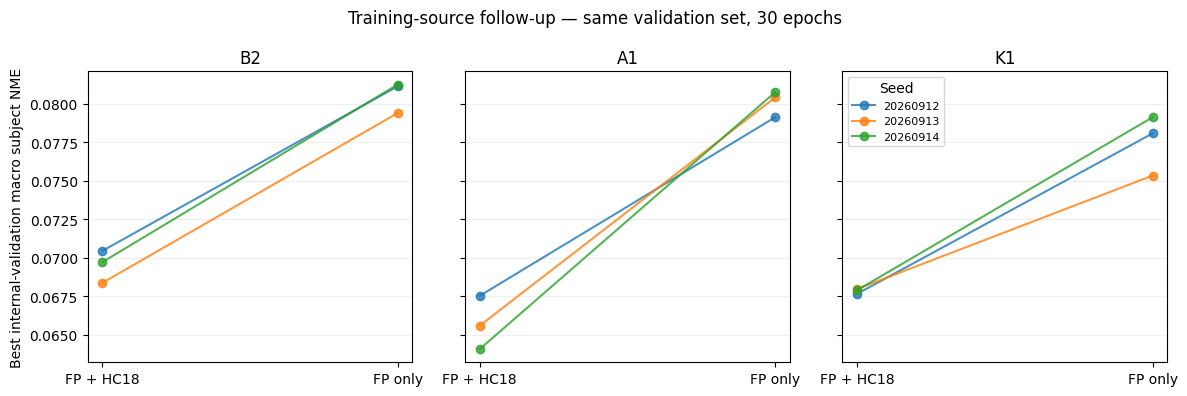


TRAINING-SOURCE VALIDATION COMPARISON
training_data variant  seeds  best_nme_mean  best_nme_seed_sd  epoch30_nme_mean
    FP + HC18      A1      3       0.065734          0.001734          0.068453
    FP + HC18      B2      3       0.069515          0.001054          0.070936
    FP + HC18      K1      3       0.067848          0.000164          0.070856
      FP only      A1      3       0.080110          0.000860          0.084913
      FP only      B2      3       0.080610          0.001038          0.083455
      FP only      K1      3       0.077525          0.001956          0.085125

PAIRED DIFFERENCES — POSITIVE MEANS FP-ONLY IS WORSE
variant     seed  FP + HC18  FP only  fp_only_minus_mixed
     A1 20260912   0.067534 0.079136             0.011603
     A1 20260913   0.065593 0.080428             0.014835
     A1 20260914   0.064074 0.080766             0.016693
     B2 20260912   0.070451 0.081154             0.010703
     B2 20260913   0.068374 0.079414             0.011040

In [2]:
# BLOCK 59 — Verify FP-only checkpoints and compare validation results (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
RUNS = PROJECT / "runs/fp_only_6d9672e851da08ad"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = RUNS / f"validation_review_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/training_source_comparison"

for directory in (OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def read_history(path):
    frame = pd.read_csv(path)
    if "epoch" not in frame:
        raise RuntimeError(f"Missing epoch column: {path}")

    # Earlier training blocks used different names for the same metric.
    candidates = [
        name for name in (
            "validation_nme",
            "validation_macro_subject_nme",
            "val_nme",
            "internal_validation_nme",
            "macro_subject_nme",
        )
        if name in frame.columns
    ]
    if len(candidates) != 1:
        raise RuntimeError(
            f"Cannot identify validation NME in {path}. "
            f"Columns: {frame.columns.tolist()}"
        )
    frame = frame.rename(columns={candidates[0]: "validation_nme"})
    if frame["epoch"].tolist() != list(range(1, 31)):
        raise RuntimeError(f"Expected epochs 1–30: {path}")
    if not np.isfinite(frame["validation_nme"]).all():
        raise RuntimeError(f"Nonfinite validation scores: {path}")
    return frame

records = []
locked = []

for seed in (20260912, 20260913, 20260914):
    for variant in ("B2", "A1", "K1"):
        fp_dir = RUNS / f"{variant}_seed{seed}"
        history = read_history(fp_dir / "history.csv")
        best_row = history.loc[history["validation_nme"].idxmin()]

        best_path = fp_dir / "best.pt"
        last_path = fp_dir / "last.pt"
        for path in (best_path, last_path):
            if not path.is_file():
                raise FileNotFoundError(f"Missing checkpoint: {path}")

        print(f"Verifying {variant}, seed {seed}...", flush=True)
        best = torch.load(best_path, map_location="cpu", weights_only=True)
        last = torch.load(last_path, map_location="cpu", weights_only=True)

        if int(last["epoch"]) != 30:
            raise RuntimeError("Last checkpoint is not epoch 30.")
        if int(best["epoch"]) != int(best_row["epoch"]):
            raise RuntimeError("Best checkpoint epoch disagrees with history.")
        if not np.isclose(
            float(best["best_nme"]), float(best_row["validation_nme"]),
            rtol=0, atol=1e-8,
        ):
            raise RuntimeError("Best checkpoint score disagrees with history.")
        if best["run_identity"] != last["run_identity"]:
            raise RuntimeError("Best and last checkpoints belong to different runs.")

        locked.append({
            "variant": variant,
            "seed": seed,
            "selected_epoch": int(best["epoch"]),
            "validation_nme": float(best["best_nme"]),
            "checkpoint_path": str(best_path),
            "checkpoint_sha256": sha256_file(best_path),
            "history_sha256": sha256_file(fp_dir / "history.csv"),
            "run_identity": best["run_identity"],
        })
        del best, last

        records.append({
            "training_data": "FP only",
            "variant": variant,
            "seed": seed,
            "best_epoch": int(best_row["epoch"]),
            "best_validation_nme": float(best_row["validation_nme"]),
            "epoch30_validation_nme": float(history.iloc[-1]["validation_nme"]),
        })

        parent_dir = PROJECT / "runs" / f"{variant}_aug30_v1_seed{seed}"
        parent_history = read_history(parent_dir / "history.csv")
        parent_best = parent_history.loc[
            parent_history["validation_nme"].idxmin()
        ]
        records.append({
            "training_data": "FP + HC18",
            "variant": variant,
            "seed": seed,
            "best_epoch": int(parent_best["epoch"]),
            "best_validation_nme": float(parent_best["validation_nme"]),
            "epoch30_validation_nme": float(
                parent_history.iloc[-1]["validation_nme"]
            ),
        })

individual = pd.DataFrame(records)
summary = individual.groupby(["training_data", "variant"]).agg(
    seeds=("seed", "nunique"),
    best_nme_mean=("best_validation_nme", "mean"),
    best_nme_seed_sd=("best_validation_nme", "std"),
    epoch30_nme_mean=("epoch30_validation_nme", "mean"),
).reset_index()

paired = individual.pivot(
    index=["variant", "seed"],
    columns="training_data",
    values="best_validation_nme",
).reset_index()
paired["fp_only_minus_mixed"] = paired["FP only"] - paired["FP + HC18"]

locked_table = pd.DataFrame(locked)
locked_path = OUT / "selected_checkpoints.csv"
locked_table.to_csv(locked_path, index=False)
individual.to_csv(OUT / "individual_validation_results.csv", index=False)
summary.to_csv(OUT / "validation_summary.csv", index=False)
paired.to_csv(OUT / "paired_training_source_differences.csv", index=False)

table_path = TABLES / f"training_source_validation_{STAMP}.csv"
summary.to_csv(table_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, variant in zip(axes, ("B2", "A1", "K1")):
    subset = individual.loc[individual["variant"].eq(variant)]
    for seed in (20260912, 20260913, 20260914):
        row = subset.loc[subset["seed"].eq(seed)].set_index("training_data")
        ax.plot(
            [0, 1],
            [row.loc["FP + HC18", "best_validation_nme"],
             row.loc["FP only", "best_validation_nme"]],
            marker="o", alpha=0.8, label=str(seed),
        )
    ax.set_title(variant)
    ax.set_xticks([0, 1], ["FP + HC18", "FP only"])
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Best internal-validation macro subject NME")
axes[-1].legend(title="Seed", fontsize=8)
fig.suptitle("Training-source follow-up — same validation set, 30 epochs")
fig.tight_layout()

png = FIGURES / f"training_source_validation_{STAMP}.png"
pdf = FIGURES / f"training_source_validation_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

report = {
    "status": "FP_ONLY_CHECKPOINTS_VERIFIED_AND_SELECTION_RECORDED",
    "verified_completed_runs": len(locked),
    "selected_checkpoints_csv": str(locked_path),
    "selected_checkpoints_csv_sha256": sha256_file(locked_path),
    "study_status": "EXPLORATORY_FOLLOW_UP",
    "test_evaluation_performed": False,
    "limitations": [
        "Shared validation set includes FP and HC18.",
        "Thirty epochs give FP-only runs fewer optimizer updates.",
        "Removing HC18 also changes anatomy balance and loss normalization.",
        "Validation differences do not establish external generalization.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 59 — FP-only checkpoint verification\n"
            "- Verified all nine completed runs and best-checkpoint selection.\n"
            "- Saved checkpoint hashes and training-source validation comparison.\n"
            "- Interpretation includes differences in updates and anatomy balance.\n"
            f"- Selected checkpoints: `{locked_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {"block": 59, "artifact_type": kind, "path": str(path)}
    for kind, path in [
        ("table", table_path), ("figure_png", png), ("figure_pdf", pdf)
    ]
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries], ignore_index=True, sort=False
    )
entries.to_csv(index_path, index=False)

print("\nTRAINING-SOURCE VALIDATION COMPARISON")
print(summary.to_string(index=False))
print("\nPAIRED DIFFERENCES — POSITIVE MEANS FP-ONLY IS WORSE")
print(paired.to_string(index=False))
print(f"\nNine selected checkpoints verified and recorded: {locked_path}")
print("\nBLOCK 59 COMPLETED — GPU not required for this block")

Verifying nine selected checkpoints...

LOCKED EXTERNAL COVERAGE
             measurement_rows  eligible_rows  subject_keys
measurement                                               
ofd                        49             49            16
bpd                        49             49            16
tad                        36             36            14
apad                       36             36            14
fl                         39             39            14

Measurement rows per checkpoint: 209
Eligible rows per checkpoint: 209

Loading 124 external images from cache...

Evaluating FP-only B2, seed 20260912, epoch 25...
  B2, 20260912: 16/124
  B2, 20260912: 32/124
  B2, 20260912: 48/124
  B2, 20260912: 64/124
  B2, 20260912: 80/124
  B2, 20260912: 96/124
  B2, 20260912: 112/124
  B2, 20260912: 124/124

Evaluating FP-only A1, seed 20260912, epoch 28...
  A1, 20260912: 16/124
  A1, 20260912: 32/124
  A1, 20260912: 48/124
  A1, 20260912: 64/124
  A1, 20260912: 80/124
  A1

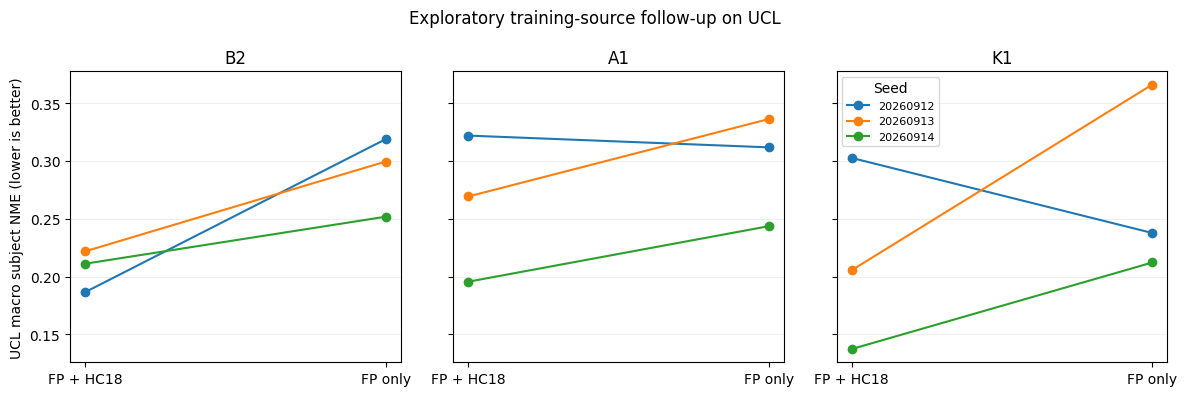


TRAINING-SOURCE EXTERNAL COMPARISON
training_data variant  seeds  external_nme_mean  external_nme_seed_sd
    FP + HC18      A1      3           0.262225              0.063433
    FP + HC18      B2      3           0.206460              0.018088
    FP + HC18      K1      3           0.215128              0.083039
      FP only      A1      3           0.297171              0.047983
      FP only      B2      3           0.289998              0.034505
      FP only      K1      3           0.271939              0.082433

PAIRED DIFFERENCES — POSITIVE MEANS FP-ONLY IS WORSE
variant     seed  FP + HC18  FP only  fp_only_minus_mixed
     A1 20260912   0.321861 0.311681            -0.010180
     A1 20260913   0.269236 0.336224             0.066988
     A1 20260914   0.195577 0.243607             0.048030
     B2 20260912   0.186506 0.318801             0.132295
     B2 20260913   0.221779 0.299437             0.077658
     B2 20260914   0.211096 0.251756             0.040660
     K1 20260

In [4]:
# BLOCK 60 V2 — FP-only models on UCL external test (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import shutil
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
FP_RUNS = PROJECT / "runs/fp_only_6d9672e851da08ad"
CORE = PROJECT / "evaluation_results/core_604bd46665aff864"
CACHE = PROJECT / "data/cache/letterbox256_9093c1bcf56fd66fa9a6"
PROTOCOL = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"
MANIFEST_DIR = (
    PROJECT / "data/manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = FP_RUNS / f"external_evaluation_v2_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/training_source_comparison"
LOCAL = Path("/content/fetalgeo_fp_only_cpu_v2")

for directory in (OUT, TABLES, FIGURES, LOCAL):
    directory.mkdir(parents=True, exist_ok=True)

torch.set_num_threads(2)
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
VARIANTS = ["B2", "A1", "K1"]
SEEDS = [20260912, 20260913, 20260914]

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def parse_bool(series):
    values = series.astype(str).str.strip().str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError(f"Unexpected Boolean values in {series.name}.")
    return values.isin(["true", "1"])

def load_module(name, source):
    local = LOCAL / f"{name}.py"
    shutil.copy2(source, local)
    spec = importlib.util.spec_from_file_location(name, local)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

# Find the completed Block 59 checkpoint list.
reviews = sorted(
    FP_RUNS.glob("validation_review_*/selected_checkpoints.csv")
)
if not reviews:
    raise FileNotFoundError(
        "No Block 59 selected_checkpoints.csv file was found."
    )

selected_path = reviews[-1]
selected = pd.read_csv(selected_path)
selected["seed"] = pd.to_numeric(
    selected["seed"], errors="raise"
).astype(int)
selected["selected_epoch"] = pd.to_numeric(
    selected["selected_epoch"], errors="raise"
).astype(int)

expected_pairs = {
    (variant, seed)
    for variant in VARIANTS
    for seed in SEEDS
}
if set(zip(selected["variant"], selected["seed"])) != expected_pairs:
    raise RuntimeError(
        "The selected-checkpoint table does not contain all nine runs."
    )
if len(selected) != 9:
    raise RuntimeError("Expected exactly nine selected checkpoints.")

print("Verifying nine selected checkpoints...", flush=True)
for row in selected.itertuples():
    checkpoint = Path(row.checkpoint_path)
    if not checkpoint.is_file():
        raise FileNotFoundError(checkpoint)
    if sha256_file(checkpoint) != row.checkpoint_sha256:
        raise RuntimeError(
            f"Checkpoint hash mismatch: {row.variant}, {row.seed}"
        )

# Verify the locked evaluation protocol.
protocol_hash = sha256_file(PROTOCOL / "evaluation_protocol.json")
expected_protocol_hash = (
    "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6"
)
if protocol_hash != expected_protocol_hash:
    raise RuntimeError("Core protocol checksum mismatch.")

# Load the exact model implementations used during training.
model_path = (
    PROJECT / "code/model_v1_20260912T163435231628Z"
    / "fetalgeo_model.py"
)
loss_path = (
    PROJECT / "code/loss_v1_20260912T163743169701Z"
    / "fetalgeo_losses.py"
)
control_path = (
    PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"
    / "fetalgeo_direct_aux.py"
)

expected_hashes = {
    model_path:
        "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
    loss_path:
        "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
    control_path:
        "a1fa2ff60baa49f34a84f93a010014ac756867153647ed5e45b4a4df34ae6799",
}
for path, expected in expected_hashes.items():
    if not path.is_file() or sha256_file(path) != expected:
        raise RuntimeError(f"Saved code verification failed: {path}")

model_module = load_module("fetalgeo_model", model_path)
loss_module = load_module("fetalgeo_losses", loss_path)
control_module = load_module("fetalgeo_direct_aux", control_path)

def make_model(variant):
    if variant == "K1":
        return control_module.DirectAuxControl(pretrained=False)
    return model_module.FetalGeo(
        geometry=(variant == "A1"),
        pretrained=False,
    )

# Load the locked UCL external-test membership.
manifest = pd.read_csv(
    MANIFEST_DIR / "unified_manifest.csv",
    dtype=str,
)
external = manifest.loc[
    manifest["role"].eq("external_test")
    & manifest["source"].eq("UCL")
].copy()

if len(external) != 124:
    raise RuntimeError(
        f"Expected 124 UCL external images; found {len(external)}."
    )
if external["record_id"].duplicated().any():
    raise RuntimeError("External record IDs are not unique.")

external_ids = external["record_id"].tolist()
subject_by_id = external.set_index(
    "record_id"
)["subject_key"].to_dict()

# Load anatomically relevant measurement rows from the protocol.
policy = pd.read_csv(
    PROTOCOL / "evaluation_measurements.csv",
    dtype=str,
)
policy = policy.loc[
    policy["role"].eq("external_test")
    & policy["source"].eq("UCL")
].copy()
policy["eligible"] = parse_bool(policy["primary_eligible"])

if policy.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate protocol measurement keys.")
if set(policy["record_id"]) != set(external_ids):
    raise RuntimeError(
        "Protocol and manifest external-image membership differ."
    )
if not set(policy["measurement"]).issubset(MEASUREMENTS):
    raise RuntimeError("Unexpected measurement in protocol.")

expected_rows = len(policy)
expected_eligible = int(policy["eligible"].sum())

print("\nLOCKED EXTERNAL COVERAGE")
print(
    policy.groupby("measurement").agg(
        measurement_rows=("record_id", "size"),
        eligible_rows=("eligible", "sum"),
        subject_keys=("subject_key", "nunique"),
    ).reindex(MEASUREMENTS).dropna(how="all").to_string()
)
print(f"\nMeasurement rows per checkpoint: {expected_rows}")
print(f"Eligible rows per checkpoint: {expected_eligible}")

eligibility = {
    (row.record_id, row.measurement): bool(row.eligible)
    for row in policy.itertuples()
}

# Read the external images and transformations from the verified cache.
cache_index = pd.read_csv(
    CACHE / "cache_index.csv",
    dtype=str,
)
if cache_index["record_id"].duplicated().any():
    raise RuntimeError("Cache index record IDs are not unique.")

cache_index = cache_index.set_index("record_id")
if not set(external_ids).issubset(cache_index.index):
    raise RuntimeError("Some external images are missing from the cache.")

selection = cache_index.loc[external_ids]
cached_records = {}

print("\nLoading 124 external images from cache...", flush=True)
for chunk_name, group in selection.groupby("chunk_file", sort=True):
    chunk_path = CACHE / chunk_name
    if not chunk_path.is_file():
        raise FileNotFoundError(chunk_path)

    with np.load(chunk_path, allow_pickle=False) as archive:
        for record_id, row in group.iterrows():
            position = int(row["position"])
            stored_id = archive["record_ids"][position]
            if isinstance(stored_id, bytes):
                stored_id = stored_id.decode()

            if str(stored_id) != record_id:
                raise RuntimeError(
                    f"Cache position mismatch for {record_id}."
                )

            transform = np.asarray(
                archive["original_to_cache"][position],
                dtype=np.float64,
            )
            cached_records[record_id] = {
                "image": np.array(
                    archive["images"][position],
                    copy=True,
                ),
                "truth": np.array(
                    archive["original_points"][position],
                    dtype=np.float64,
                    copy=True,
                ),
                "inverse": np.linalg.inv(transform),
            }

images = torch.from_numpy(np.stack([
    cached_records[record_id]["image"]
    for record_id in external_ids
])).permute(0, 3, 1, 2)

truth = np.stack([
    cached_records[record_id]["truth"]
    for record_id in external_ids
])
inverse = np.stack([
    cached_records[record_id]["inverse"]
    for record_id in external_ids
])
del cached_records

if tuple(images.shape) != (124, 3, 256, 256):
    raise RuntimeError(f"Unexpected image shape: {tuple(images.shape)}")

mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
)[None, :, None, None]
std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
)[None, :, None, None]

def infer_checkpoint(variant, seed, checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )

    run_config = checkpoint.get("run_config", {})
    if run_config.get("variant") != variant:
        raise RuntimeError("Checkpoint variant mismatch.")
    if int(run_config.get("seed")) != seed:
        raise RuntimeError("Checkpoint seed mismatch.")

    model = make_model(variant).cpu()
    model.load_state_dict(checkpoint["model"], strict=True)
    model.eval()

    predictions = []
    started = time.perf_counter()

    with torch.inference_mode():
        for start in range(0, len(images), 16):
            end = min(start + 16, len(images))
            batch = images[start:end].float() / 255.0
            output = model((batch - mean) / std)
            points = output["local_points"].float()

            if not torch.isfinite(points).all():
                raise RuntimeError(
                    f"Nonfinite predictions: {variant}, {seed}"
                )

            predictions.append(points.numpy())
            print(
                f"  {variant}, {seed}: {end}/{len(images)}",
                flush=True,
            )

    cached_points = np.concatenate(predictions).astype(np.float64)

    homogeneous = np.concatenate(
        [
            cached_points,
            np.ones(
                (*cached_points.shape[:-1], 1),
                dtype=np.float64,
            ),
        ],
        axis=-1,
    )
    original_points = np.einsum(
        "bij,bmkj->bmki",
        inverse,
        homogeneous,
    )[..., :2]

    if not np.isfinite(original_points).all():
        raise RuntimeError("Nonfinite original-coordinate predictions.")

    rows = []
    for image_index, record_id in enumerate(external_ids):
        available_measurements = [
            measurement
            for measurement in MEASUREMENTS
            if (record_id, measurement) in eligibility
        ]
        if not available_measurements:
            raise RuntimeError(
                f"No protocol measurements for {record_id}."
            )

        for measurement in available_measurements:
            measurement_index = MEASUREMENTS.index(measurement)
            target = truth[image_index, measurement_index]
            predicted = original_points[
                image_index, measurement_index
            ]
            eligible = eligibility[(record_id, measurement)]

            nme = np.nan
            if eligible:
                if not np.isfinite(target).all():
                    raise RuntimeError(
                        f"Nonfinite eligible target: "
                        f"{record_id}, {measurement}"
                    )

                target_length = float(
                    np.linalg.norm(target[1] - target[0])
                )
                if (
                    not np.isfinite(target_length)
                    or target_length <= 0
                ):
                    raise RuntimeError(
                        f"Invalid target length: "
                        f"{record_id}, {measurement}"
                    )

                direct = np.linalg.norm(
                    predicted - target,
                    axis=1,
                ).mean()
                reversed_error = np.linalg.norm(
                    predicted - target[::-1],
                    axis=1,
                ).mean()
                nme = float(
                    min(direct, reversed_error) / target_length
                )

            rows.append({
                "variant": variant,
                "seed": seed,
                "record_id": record_id,
                "role": "external_test",
                "source": "UCL",
                "subject_key": subject_by_id[record_id],
                "measurement": measurement,
                "primary_eligible": eligible,
                "nme": nme,
                "predicted_x1": float(predicted[0, 0]),
                "predicted_y1": float(predicted[0, 1]),
                "predicted_x2": float(predicted[1, 0]),
                "predicted_y2": float(predicted[1, 1]),
                "target_x1": float(target[0, 0]),
                "target_y1": float(target[0, 1]),
                "target_x2": float(target[1, 0]),
                "target_y2": float(target[1, 1]),
            })

    frame = pd.DataFrame(rows)
    if len(frame) != expected_rows:
        raise RuntimeError(
            f"Expected {expected_rows} measurement rows; "
            f"generated {len(frame)}."
        )
    if frame.duplicated(["record_id", "measurement"]).any():
        raise RuntimeError("Duplicate generated measurement rows.")

    actual_eligible = int(frame["primary_eligible"].sum())
    if actual_eligible != expected_eligible:
        raise RuntimeError(
            f"Expected {expected_eligible} eligible rows; "
            f"generated {actual_eligible}."
        )

    elapsed = time.perf_counter() - started
    del model, checkpoint
    return frame, elapsed

prediction_receipts = []
per_seed_rows = []
per_measurement_rows = []

for checkpoint_row in selected.itertuples():
    variant = checkpoint_row.variant
    seed = int(checkpoint_row.seed)

    print(
        f"\nEvaluating FP-only {variant}, seed {seed}, "
        f"epoch {checkpoint_row.selected_epoch}...",
        flush=True,
    )

    frame, elapsed = infer_checkpoint(
        variant,
        seed,
        Path(checkpoint_row.checkpoint_path),
    )

    prediction_path = (
        OUT / f"{variant}_seed{seed}_predictions.csv"
    )
    frame.to_csv(prediction_path, index=False)

    prediction_receipts.append({
        "variant": variant,
        "seed": seed,
        "selected_epoch": int(checkpoint_row.selected_epoch),
        "checkpoint_path": checkpoint_row.checkpoint_path,
        "checkpoint_sha256": checkpoint_row.checkpoint_sha256,
        "prediction_path": str(prediction_path),
        "prediction_sha256": sha256_file(prediction_path),
        "image_records": frame["record_id"].nunique(),
        "measurement_rows": len(frame),
        "eligible_measurement_rows": int(
            frame["primary_eligible"].sum()
        ),
        "inference_seconds": elapsed,
    })

    usable = frame.loc[frame["primary_eligible"]].copy()
    if not np.isfinite(usable["nme"]).all():
        raise RuntimeError("Nonfinite eligible NME values.")

    subject_scores = usable.groupby(
        ["measurement", "subject_key"],
        as_index=False,
    )["nme"].mean()

    measurement_scores = subject_scores.groupby(
        "measurement",
        as_index=False,
    ).agg(
        subject_average_nme=("nme", "mean"),
        subject_keys=("subject_key", "nunique"),
    )

    if set(measurement_scores["measurement"]) != set(MEASUREMENTS):
        raise RuntimeError("Incomplete measurement-level scores.")

    macro_nme = float(
        measurement_scores["subject_average_nme"].mean()
    )
    per_seed_rows.append({
        "training_data": "FP only",
        "variant": variant,
        "seed": seed,
        "selected_epoch": int(checkpoint_row.selected_epoch),
        "macro_subject_nme": macro_nme,
    })

    for row in measurement_scores.itertuples():
        per_measurement_rows.append({
            "training_data": "FP only",
            "variant": variant,
            "seed": seed,
            "measurement": row.measurement,
            "subject_average_nme": row.subject_average_nme,
            "subject_keys": row.subject_keys,
        })

receipts = pd.DataFrame(prediction_receipts)
fp_seed = pd.DataFrame(per_seed_rows)
fp_measurement = pd.DataFrame(per_measurement_rows)

receipts.to_csv(OUT / "prediction_receipts.csv", index=False)
fp_seed.to_csv(OUT / "fp_only_per_seed_scores.csv", index=False)
fp_measurement.to_csv(
    OUT / "fp_only_per_measurement_scores.csv",
    index=False,
)

# Recompute mixed-source external scores from the locked core predictions.
mixed_rows = []
for variant in VARIANTS:
    for seed in SEEDS:
        path = CORE / f"{variant}_seed{seed}_predictions.csv"
        if not path.is_file():
            raise FileNotFoundError(path)

        frame = pd.read_csv(path)
        frame = frame.loc[
            frame["role"].eq("external_test")
            & frame["source"].eq("UCL")
        ].copy()
        frame["primary_eligible"] = parse_bool(
            frame["primary_eligible"]
        )
        usable = frame.loc[frame["primary_eligible"]]

        if len(usable) != expected_eligible:
            raise RuntimeError(
                f"Mixed-source coverage mismatch: {path.name}"
            )

        subjects = usable.groupby(
            ["measurement", "subject_key"],
            as_index=False,
        )["nme"].mean()
        measurement_scores = subjects.groupby(
            "measurement",
            as_index=False,
        )["nme"].mean()

        if set(measurement_scores["measurement"]) != set(MEASUREMENTS):
            raise RuntimeError(
                f"Incomplete mixed-source scores: {path.name}"
            )

        mixed_rows.append({
            "training_data": "FP + HC18",
            "variant": variant,
            "seed": seed,
            "macro_subject_nme": float(
                measurement_scores["nme"].mean()
            ),
        })

mixed_seed = pd.DataFrame(mixed_rows)
all_seed = pd.concat(
    [
        mixed_seed,
        fp_seed[[
            "training_data",
            "variant",
            "seed",
            "macro_subject_nme",
        ]],
    ],
    ignore_index=True,
)

comparison = all_seed.groupby(
    ["training_data", "variant"]
).agg(
    seeds=("seed", "nunique"),
    external_nme_mean=("macro_subject_nme", "mean"),
    external_nme_seed_sd=("macro_subject_nme", "std"),
).reset_index()

paired = all_seed.pivot(
    index=["variant", "seed"],
    columns="training_data",
    values="macro_subject_nme",
).reset_index()
paired["fp_only_minus_mixed"] = (
    paired["FP only"] - paired["FP + HC18"]
)

comparison.to_csv(
    OUT / "training_source_external_summary.csv",
    index=False,
)
paired.to_csv(
    OUT / "paired_external_differences.csv",
    index=False,
)

table_path = TABLES / f"training_source_external_{STAMP}.csv"
paired_path = (
    TABLES / f"training_source_external_paired_{STAMP}.csv"
)
comparison.to_csv(table_path, index=False)
paired.to_csv(paired_path, index=False)

# Paper figure.
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharey=True,
)

for axis, variant in zip(axes, VARIANTS):
    subset = all_seed.loc[
        all_seed["variant"].eq(variant)
    ]
    for seed in SEEDS:
        values = subset.loc[
            subset["seed"].eq(seed)
        ].set_index("training_data")

        axis.plot(
            [0, 1],
            [
                values.loc[
                    "FP + HC18", "macro_subject_nme"
                ],
                values.loc[
                    "FP only", "macro_subject_nme"
                ],
            ],
            marker="o",
            label=str(seed),
        )

    axis.set_title(variant)
    axis.set_xticks(
        [0, 1],
        ["FP + HC18", "FP only"],
    )
    axis.grid(axis="y", alpha=0.2)

axes[0].set_ylabel(
    "UCL macro subject NME (lower is better)"
)
axes[-1].legend(title="Seed", fontsize=8)
fig.suptitle(
    "Exploratory training-source follow-up on UCL"
)
fig.tight_layout()

png = FIGURES / f"training_source_external_{STAMP}.png"
pdf = FIGURES / f"training_source_external_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": (
        "FP_ONLY_EXTERNAL_EXPLORATORY_EVALUATION_COMPLETED"
    ),
    "study_status": "POST_HOC_EXPLORATORY",
    "protocol_sha256": protocol_hash,
    "selected_checkpoints_csv": str(selected_path),
    "selected_checkpoints_csv_sha256": sha256_file(
        selected_path
    ),
    "checkpoints_evaluated": len(selected),
    "images_per_checkpoint": len(external_ids),
    "measurement_rows_per_checkpoint": expected_rows,
    "eligible_measurements_per_checkpoint": expected_eligible,
    "checkpoint_selection": "Internal validation only",
    "test_results_used_for_selection": False,
    "primary_core_results_changed": False,
    "limitations": [
        "UCL outcomes were known before this follow-up was designed.",
        "FP-only runs have fewer optimizer updates.",
        "Removing HC18 changes training size and anatomy balance.",
        "UCL contains only 19 dependency clusters.",
        "This is exploratory rather than confirmatory evidence.",
    ],
}

(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 60 V2 — FP-only external evaluation\n"
            "- Evaluated all nine validation-selected checkpoints on UCL.\n"
            f"- Measurement rows per checkpoint: {expected_rows}.\n"
            f"- Eligible rows per checkpoint: {expected_eligible}.\n"
            "- Classified as a post-hoc exploratory follow-up.\n"
            "- Primary core results remain unchanged.\n"
            f"- Results: `{OUT}`.\n"
            f"- Table: `{table_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 60,
        "artifact_type": "table",
        "path": str(table_path),
    },
    {
        "block": 60,
        "artifact_type": "paired_table",
        "path": str(paired_path),
    },
    {
        "block": 60,
        "artifact_type": "figure_png",
        "path": str(png),
    },
    {
        "block": 60,
        "artifact_type": "figure_pdf",
        "path": str(pdf),
    },
])

if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nTRAINING-SOURCE EXTERNAL COMPARISON")
print(comparison.to_string(index=False))

print("\nPAIRED DIFFERENCES — POSITIVE MEANS FP-ONLY IS WORSE")
print(paired.to_string(index=False))

print(f"\nSaved CPU evaluation: {OUT}")
print("\nBLOCK 60 V2 COMPLETED")

Bootstrapping 19 dependency clusters...
Valid bootstrap replicates: 500/2000
Valid bootstrap replicates: 1000/2000
Valid bootstrap replicates: 1500/2000
Valid bootstrap replicates: 2000/2000


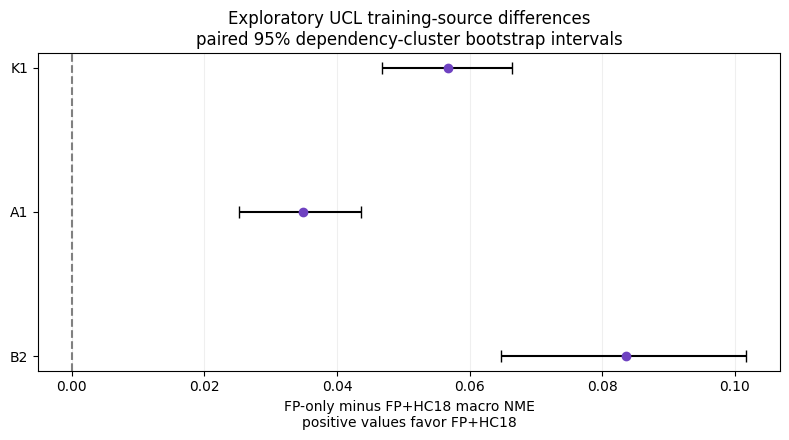


POINT ESTIMATES
variant  fp_hc18_nme  fp_only_nme  fp_only_minus_mixed
     B2     0.206460     0.289998             0.083538
     A1     0.262225     0.297171             0.034946
     K1     0.215128     0.271939             0.056810

PAIRED CLUSTER-BOOTSTRAP INTERVALS
variant  mean_paired_difference  ci95_lower  ci95_upper  valid_bootstrap_replicates  redrawn_replicates  dependency_clusters
     B2                0.083538    0.064723    0.101756                        2000                   0                   19
     A1                0.034946    0.025279    0.043687                        2000                   0                   19
     K1                0.056810    0.046814    0.066433                        2000                   0                   19

Saved analysis: /content/drive/MyDrive/FetalGeo/runs/fp_only_6d9672e851da08ad/training_source_bootstrap_20260913T153432962384Z

BLOCK 61 COMPLETED


In [5]:
# BLOCK 61 — Cluster-bootstrap training-source differences on UCL (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
FP_RUNS = PROJECT / "runs/fp_only_6d9672e851da08ad"
CORE = PROJECT / "evaluation_results/core_604bd46665aff864"
PROTOCOL = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = FP_RUNS / f"training_source_bootstrap_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/training_source_comparison"

for directory in (OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

VARIANTS = ["B2", "A1", "K1"]
SEEDS = [20260912, 20260913, 20260914]
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 20260961

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def parse_bool(series):
    values = series.astype(str).str.strip().str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError(f"Unexpected Boolean values in {series.name}.")
    return values.isin(["true", "1"])

# Locate the completed Block 60 V2 output.
evaluation_dirs = sorted(
    path for path in FP_RUNS.glob("external_evaluation_v2_*")
    if (path / "training_source_external_summary.csv").is_file()
    and (path / "prediction_receipts.csv").is_file()
)
if not evaluation_dirs:
    raise FileNotFoundError("Completed Block 60 V2 results were not found.")
FP_EVALUATION = evaluation_dirs[-1]

# Verify the unchanged core protocol.
protocol_path = PROTOCOL / "evaluation_protocol.json"
protocol_hash = sha256_file(protocol_path)
expected_protocol_hash = (
    "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6"
)
if protocol_hash != expected_protocol_hash:
    raise RuntimeError("Core protocol hash mismatch.")

protocol = pd.read_csv(
    PROTOCOL / "evaluation_measurements.csv",
    dtype=str,
)
protocol = protocol.loc[
    protocol["role"].eq("external_test")
    & protocol["source"].eq("UCL")
].copy()
protocol["primary_eligible"] = parse_bool(
    protocol["primary_eligible"]
)

required_protocol = {
    "record_id", "measurement", "subject_key",
    "dependency_cluster", "primary_eligible",
}
missing = required_protocol - set(protocol.columns)
if missing:
    raise RuntimeError(f"Protocol columns missing: {sorted(missing)}")

protocol = protocol.loc[protocol["primary_eligible"]].copy()
if protocol.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate eligible protocol keys.")

eligible_keys = set(zip(
    protocol["record_id"],
    protocol["measurement"],
))
cluster_count = protocol["dependency_cluster"].nunique()
if cluster_count != 19:
    raise RuntimeError(
        f"Expected 19 external dependency clusters; found {cluster_count}."
    )

# Verify every Block 60 prediction using its saved receipt.
receipts = pd.read_csv(
    FP_EVALUATION / "prediction_receipts.csv"
)
if len(receipts) != 9:
    raise RuntimeError("Expected nine FP-only prediction receipts.")

frames = []

for row in receipts.itertuples():
    path = Path(row.prediction_path)
    if sha256_file(path) != row.prediction_sha256:
        raise RuntimeError(f"Prediction hash mismatch: {path}")

    frame = pd.read_csv(path)
    frame["primary_eligible"] = parse_bool(
        frame["primary_eligible"]
    )
    frame = frame.loc[frame["primary_eligible"]].copy()
    keys = set(zip(frame["record_id"], frame["measurement"]))
    if keys != eligible_keys:
        raise RuntimeError(
            f"FP-only eligible coverage mismatch: {path.name}"
        )
    frame["training_data"] = "FP only"
    frames.append(frame[[
        "training_data", "variant", "seed",
        "record_id", "measurement", "subject_key", "nme",
    ]])

# Load matched mixed-source predictions.
for variant in VARIANTS:
    for seed in SEEDS:
        path = CORE / f"{variant}_seed{seed}_predictions.csv"
        frame = pd.read_csv(path)
        frame = frame.loc[
            frame["role"].eq("external_test")
            & frame["source"].eq("UCL")
        ].copy()
        frame["primary_eligible"] = parse_bool(
            frame["primary_eligible"]
        )
        frame = frame.loc[frame["primary_eligible"]].copy()

        keys = set(zip(frame["record_id"], frame["measurement"]))
        if keys != eligible_keys:
            raise RuntimeError(
                f"Mixed-source eligible coverage mismatch: {path.name}"
            )

        frame["training_data"] = "FP + HC18"
        frames.append(frame[[
            "training_data", "variant", "seed",
            "record_id", "measurement", "subject_key", "nme",
        ]])

data = pd.concat(frames, ignore_index=True)
data["seed"] = pd.to_numeric(data["seed"], errors="raise").astype(int)
data["nme"] = pd.to_numeric(data["nme"], errors="raise")

if not np.isfinite(data["nme"]).all():
    raise RuntimeError("Nonfinite eligible NME values.")

expected_groups = {
    (source, variant, seed)
    for source in ("FP only", "FP + HC18")
    for variant in VARIANTS
    for seed in SEEDS
}
actual_groups = set(zip(
    data["training_data"],
    data["variant"],
    data["seed"],
))
if actual_groups != expected_groups:
    raise RuntimeError("Incomplete training-source/model/seed coverage.")

# Attach the frozen dependency clusters and verify identities.
metadata = protocol[[
    "record_id", "measurement",
    "subject_key", "dependency_cluster",
]].rename(columns={"subject_key": "protocol_subject_key"})

data = data.merge(
    metadata,
    on=["record_id", "measurement"],
    how="left",
    validate="many_to_one",
)
if data["dependency_cluster"].isna().any():
    raise RuntimeError("Missing dependency-cluster assignments.")
if not (
    data["subject_key"] == data["protocol_subject_key"]
).all():
    raise RuntimeError("Prediction and protocol subject keys differ.")

# Average records within each subject and measurement first.
subject_data = data.groupby([
    "training_data", "variant", "seed",
    "dependency_cluster", "subject_key", "measurement",
], as_index=False)["nme"].mean()

# A subject must belong to exactly one dependency cluster.
subject_clusters = subject_data[[
    "subject_key", "dependency_cluster"
]].drop_duplicates()
if subject_clusters["subject_key"].duplicated().any():
    raise RuntimeError("A subject key belongs to multiple clusters.")

clusters = sorted(subject_data["dependency_cluster"].unique())
if len(clusters) != 19:
    raise RuntimeError("Unexpected number of bootstrap clusters.")

def macro_for(frame, source, variant, seed, draw=None):
    selected = frame.loc[
        frame["training_data"].eq(source)
        & frame["variant"].eq(variant)
        & frame["seed"].eq(seed)
    ]

    if draw is not None:
        pieces = []
        for draw_index, cluster in enumerate(draw):
            piece = selected.loc[
                selected["dependency_cluster"].eq(cluster)
            ].copy()
            # A repeatedly sampled cluster is a distinct bootstrap unit.
            piece["bootstrap_subject"] = (
                str(draw_index) + ":" + piece["subject_key"]
            )
            pieces.append(piece)
        selected = pd.concat(pieces, ignore_index=True)
        subject_column = "bootstrap_subject"
    else:
        subject_column = "subject_key"

    scores = selected.groupby(
        ["measurement", subject_column],
        as_index=False,
    )["nme"].mean()
    measurement_scores = scores.groupby(
        "measurement"
    )["nme"].mean()

    if set(measurement_scores.index) != set(MEASUREMENTS):
        return np.nan

    return float(
        measurement_scores.reindex(MEASUREMENTS).mean()
    )

# Exact point estimates from the full external cohort.
point_rows = []
for variant in VARIANTS:
    source_scores = {}
    for source in ("FP + HC18", "FP only"):
        seed_scores = [
            macro_for(subject_data, source, variant, seed)
            for seed in SEEDS
        ]
        if not np.isfinite(seed_scores).all():
            raise RuntimeError("Invalid full-cohort macro score.")
        source_scores[source] = float(np.mean(seed_scores))

    point_rows.append({
        "variant": variant,
        "fp_hc18_nme": source_scores["FP + HC18"],
        "fp_only_nme": source_scores["FP only"],
        "fp_only_minus_mixed": (
            source_scores["FP only"]
            - source_scores["FP + HC18"]
        ),
    })

points = pd.DataFrame(point_rows)

# Paired bootstrap: the same sampled clusters are used for both sources,
# every model and every training seed.
rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap = {variant: [] for variant in VARIANTS}
valid = 0
redrawn = 0

print(
    f"Bootstrapping {cluster_count} dependency clusters...",
    flush=True,
)

while valid < BOOTSTRAP_REPLICATES:
    draw = rng.choice(
        clusters,
        size=len(clusters),
        replace=True,
    )

    replicate = {}
    replicate_valid = True

    for variant in VARIANTS:
        values = {}
        for source in ("FP + HC18", "FP only"):
            seed_scores = [
                macro_for(
                    subject_data,
                    source,
                    variant,
                    seed,
                    draw=draw,
                )
                for seed in SEEDS
            ]
            if not np.isfinite(seed_scores).all():
                replicate_valid = False
                break
            values[source] = float(np.mean(seed_scores))

        if not replicate_valid:
            break

        replicate[variant] = (
            values["FP only"] - values["FP + HC18"]
        )

    if not replicate_valid:
        redrawn += 1
        continue

    for variant in VARIANTS:
        bootstrap[variant].append(replicate[variant])

    valid += 1
    if valid % 500 == 0:
        print(
            f"Valid bootstrap replicates: "
            f"{valid}/{BOOTSTRAP_REPLICATES}",
            flush=True,
        )

interval_rows = []
bootstrap_rows = []

for variant in VARIANTS:
    values = np.asarray(bootstrap[variant], dtype=float)
    point = float(
        points.loc[
            points["variant"].eq(variant),
            "fp_only_minus_mixed",
        ].iloc[0]
    )

    lower, upper = np.percentile(values, [2.5, 97.5])
    interval_rows.append({
        "variant": variant,
        "mean_paired_difference": point,
        "ci95_lower": float(lower),
        "ci95_upper": float(upper),
        "valid_bootstrap_replicates": len(values),
        "redrawn_replicates": redrawn,
        "dependency_clusters": cluster_count,
    })

    for replicate, value in enumerate(values):
        bootstrap_rows.append({
            "variant": variant,
            "replicate": replicate,
            "fp_only_minus_mixed": value,
        })

intervals = pd.DataFrame(interval_rows)
bootstrap_frame = pd.DataFrame(bootstrap_rows)

points.to_csv(OUT / "point_estimates.csv", index=False)
intervals.to_csv(OUT / "cluster_bootstrap_intervals.csv", index=False)
bootstrap_frame.to_csv(
    OUT / "bootstrap_replicates.csv",
    index=False,
)
subject_data.to_csv(
    OUT / "subject_measurement_scores.csv",
    index=False,
)

table_path = (
    TABLES
    / f"training_source_external_bootstrap_{STAMP}.csv"
)
intervals.to_csv(table_path, index=False)

# Forest plot.
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = np.arange(len(VARIANTS))

ordered = intervals.set_index("variant").loc[VARIANTS]
values = ordered["mean_paired_difference"].to_numpy()
lower_error = values - ordered["ci95_lower"].to_numpy()
upper_error = ordered["ci95_upper"].to_numpy() - values

ax.errorbar(
    values,
    positions,
    xerr=np.vstack([lower_error, upper_error]),
    fmt="o",
    color="#6f42c1",
    ecolor="black",
    capsize=4,
)
ax.axvline(0, color="gray", linestyle="--")
ax.set_yticks(positions, VARIANTS)
ax.set_xlabel(
    "FP-only minus FP+HC18 macro NME\n"
    "positive values favor FP+HC18"
)
ax.set_title(
    "Exploratory UCL training-source differences\n"
    "paired 95% dependency-cluster bootstrap intervals"
)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()

png = FIGURES / f"training_source_external_bootstrap_{STAMP}.png"
pdf = FIGURES / f"training_source_external_bootstrap_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "TRAINING_SOURCE_CLUSTER_BOOTSTRAP_COMPLETED",
    "study_status": "POST_HOC_EXPLORATORY",
    "fp_only_evaluation_directory": str(FP_EVALUATION),
    "protocol_sha256": protocol_hash,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "requested_replicates": BOOTSTRAP_REPLICATES,
    "valid_replicates": valid,
    "redrawn_replicates": redrawn,
    "dependency_clusters": cluster_count,
    "interval": (
        "Paired dependency-cluster percentile bootstrap, "
        "pointwise 95%"
    ),
    "difference": "FP-only minus FP+HC18",
    "positive_difference_favors": "FP+HC18",
    "test_results_used_for_model_selection": False,
    "primary_core_results_changed": False,
    "limitations": [
        "The experiment was designed after observing UCL outcomes.",
        "Intervals condition on these trained models.",
        "Only three training seeds are available.",
        "Intervals are pointwise and unadjusted for three contrasts.",
        "External evaluation contains only 19 dependency clusters.",
        "Training size, update count and anatomy balance changed together.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 61 — training-source uncertainty\n"
            "- Compared FP-only against FP+HC18 on the UCL cohort.\n"
            f"- Bootstrap: {valid} valid paired dependency-cluster replicates.\n"
            "- Positive differences favor FP+HC18.\n"
            "- Classified as post-hoc exploratory evidence.\n"
            f"- Intervals: `{table_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 61,
        "artifact_type": "table",
        "path": str(table_path),
    },
    {
        "block": 61,
        "artifact_type": "figure_png",
        "path": str(png),
    },
    {
        "block": 61,
        "artifact_type": "figure_pdf",
        "path": str(pdf),
    },
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nPOINT ESTIMATES")
print(points.to_string(index=False))

print("\nPAIRED CLUSTER-BOOTSTRAP INTERVALS")
print(intervals.to_string(index=False))

print(f"\nSaved analysis: {OUT}")
print("\nBLOCK 61 COMPLETED")

Bootstrapping 19 dependency clusters...
Valid replicates: 500/2000
Valid replicates: 1000/2000
Valid replicates: 1500/2000
Valid replicates: 2000/2000


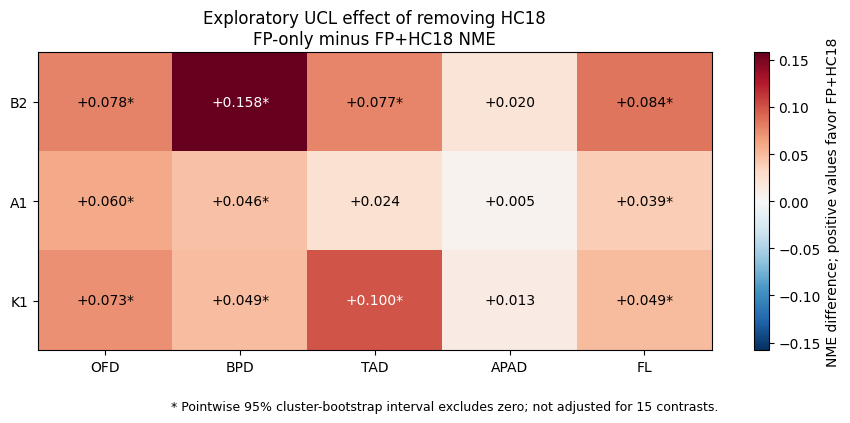


PER-MEASUREMENT TRAINING-SOURCE RESULTS
variant measurement  fp_hc18_nme  fp_only_nme  fp_only_minus_mixed  ci95_lower  ci95_upper  interval_excludes_zero  valid_replicates  redrawn_replicates
     B2         ofd     0.156846     0.234819             0.077973    0.056431    0.099970                    True              2000                   0
     B2         bpd     0.185865     0.344104             0.158239    0.114312    0.205553                    True              2000                   0
     B2         tad     0.244463     0.321457             0.076994    0.035381    0.114534                    True              2000                   0
     B2        apad     0.272491     0.292906             0.020414   -0.034666    0.072764                   False              2000                   0
     B2          fl     0.172636     0.256704             0.084069    0.039081    0.154508                    True              2000                   0
     A1         ofd     0.173116     0.23

In [6]:
# BLOCK 62 — Per-measurement training-source analysis (CPU)
from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
FP_RUNS = PROJECT / "runs/fp_only_6d9672e851da08ad"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = FP_RUNS / f"measurement_source_analysis_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/training_source_comparison"

for directory in (OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

VARIANTS = ["B2", "A1", "K1"]
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
SOURCES = ["FP + HC18", "FP only"]
SEEDS = [20260912, 20260913, 20260914]
REPLICATES = 2000
RNG_SEED = 20260962

# Locate the completed Block 61 analysis.
bootstrap_dirs = sorted(
    path for path in FP_RUNS.glob("training_source_bootstrap_*")
    if (path / "subject_measurement_scores.csv").is_file()
)
if not bootstrap_dirs:
    raise FileNotFoundError("Completed Block 61 output was not found.")

BLOCK61 = bootstrap_dirs[-1]
data = pd.read_csv(BLOCK61 / "subject_measurement_scores.csv")

required = {
    "training_data", "variant", "seed", "dependency_cluster",
    "subject_key", "measurement", "nme",
}
missing = required - set(data.columns)
if missing:
    raise RuntimeError(f"Missing columns: {sorted(missing)}")

data["seed"] = pd.to_numeric(data["seed"], errors="raise").astype(int)
data["nme"] = pd.to_numeric(data["nme"], errors="raise")

if not np.isfinite(data["nme"]).all():
    raise RuntimeError("Nonfinite subject-level NME values.")
if set(data["training_data"]) != set(SOURCES):
    raise RuntimeError("Unexpected training-source coverage.")
if set(data["variant"]) != set(VARIANTS):
    raise RuntimeError("Unexpected model coverage.")
if set(data["seed"]) != set(SEEDS):
    raise RuntimeError("Unexpected seed coverage.")
if set(data["measurement"]) != set(MEASUREMENTS):
    raise RuntimeError("Unexpected measurement coverage.")

# Confirm each subject belongs to one dependency cluster.
subject_clusters = data[[
    "subject_key", "dependency_cluster"
]].drop_duplicates()
if subject_clusters["subject_key"].duplicated().any():
    raise RuntimeError("A subject belongs to multiple dependency clusters.")

clusters = sorted(data["dependency_cluster"].unique())
if len(clusters) != 19:
    raise RuntimeError(
        f"Expected 19 dependency clusters; found {len(clusters)}."
    )

# Exact point estimates: average subjects, then average the three seeds.
per_seed = data.groupby([
    "training_data", "variant", "seed", "measurement"
], as_index=False).agg(
    subject_average_nme=("nme", "mean"),
    subject_keys=("subject_key", "nunique"),
)

point = per_seed.groupby([
    "training_data", "variant", "measurement"
], as_index=False).agg(
    nme_mean=("subject_average_nme", "mean"),
    nme_seed_sd=("subject_average_nme", "std"),
    seeds=("seed", "nunique"),
    subject_keys=("subject_keys", "max"),
)

wide = point.pivot(
    index=["variant", "measurement"],
    columns="training_data",
    values="nme_mean",
).reset_index()
wide["fp_only_minus_mixed"] = (
    wide["FP only"] - wide["FP + HC18"]
)

# Pre-split rows by cluster for efficient paired resampling.
cluster_frames = {
    cluster: data.loc[
        data["dependency_cluster"].eq(cluster)
    ].copy()
    for cluster in clusters
}

def measurement_score(frame, source, variant, seed, measurement):
    values = frame.loc[
        frame["training_data"].eq(source)
        & frame["variant"].eq(variant)
        & frame["seed"].eq(seed)
        & frame["measurement"].eq(measurement),
        "nme",
    ]
    if values.empty:
        return np.nan
    return float(values.mean())

rng = np.random.default_rng(RNG_SEED)
replicate_values = {
    (variant, measurement): []
    for variant in VARIANTS
    for measurement in MEASUREMENTS
}
valid = 0
redrawn = 0

print(
    f"Bootstrapping {len(clusters)} dependency clusters...",
    flush=True,
)

while valid < REPLICATES:
    sampled = rng.choice(
        clusters,
        size=len(clusters),
        replace=True,
    )

    # Repeated clusters must remain repeated bootstrap units.
    pieces = []
    for draw_index, cluster in enumerate(sampled):
        piece = cluster_frames[cluster].copy()
        piece["bootstrap_subject"] = (
            str(draw_index) + ":" + piece["subject_key"]
        )
        pieces.append(piece)

    replicate = pd.concat(pieces, ignore_index=True)
    replicate = replicate.groupby([
        "training_data", "variant", "seed",
        "measurement", "bootstrap_subject",
    ], as_index=False)["nme"].mean()

    current = {}
    complete = True

    for variant in VARIANTS:
        for measurement in MEASUREMENTS:
            source_means = {}
            for source in SOURCES:
                seed_scores = [
                    measurement_score(
                        replicate,
                        source,
                        variant,
                        seed,
                        measurement,
                    )
                    for seed in SEEDS
                ]
                if not np.isfinite(seed_scores).all():
                    complete = False
                    break
                source_means[source] = float(np.mean(seed_scores))

            if not complete:
                break

            current[(variant, measurement)] = (
                source_means["FP only"]
                - source_means["FP + HC18"]
            )

        if not complete:
            break

    if not complete:
        redrawn += 1
        continue

    for key, value in current.items():
        replicate_values[key].append(value)

    valid += 1
    if valid % 500 == 0:
        print(
            f"Valid replicates: {valid}/{REPLICATES}",
            flush=True,
        )

interval_rows = []
replicate_rows = []

for variant in VARIANTS:
    for measurement in MEASUREMENTS:
        values = np.asarray(
            replicate_values[(variant, measurement)],
            dtype=float,
        )
        estimate = float(
            wide.loc[
                wide["variant"].eq(variant)
                & wide["measurement"].eq(measurement),
                "fp_only_minus_mixed",
            ].iloc[0]
        )
        lower, upper = np.percentile(values, [2.5, 97.5])

        interval_rows.append({
            "variant": variant,
            "measurement": measurement,
            "fp_hc18_nme": float(
                wide.loc[
                    wide["variant"].eq(variant)
                    & wide["measurement"].eq(measurement),
                    "FP + HC18",
                ].iloc[0]
            ),
            "fp_only_nme": float(
                wide.loc[
                    wide["variant"].eq(variant)
                    & wide["measurement"].eq(measurement),
                    "FP only",
                ].iloc[0]
            ),
            "fp_only_minus_mixed": estimate,
            "ci95_lower": float(lower),
            "ci95_upper": float(upper),
            "interval_excludes_zero": bool(
                lower > 0 or upper < 0
            ),
            "valid_replicates": len(values),
            "redrawn_replicates": redrawn,
        })

        for index, value in enumerate(values):
            replicate_rows.append({
                "variant": variant,
                "measurement": measurement,
                "replicate": index,
                "fp_only_minus_mixed": value,
            })

intervals = pd.DataFrame(interval_rows)
replicates = pd.DataFrame(replicate_rows)

per_seed.to_csv(OUT / "per_seed_measurement_scores.csv", index=False)
point.to_csv(OUT / "measurement_point_estimates.csv", index=False)
intervals.to_csv(OUT / "measurement_bootstrap_intervals.csv", index=False)
replicates.to_csv(OUT / "bootstrap_replicates.csv", index=False)

table_path = TABLES / f"training_source_by_measurement_{STAMP}.csv"
intervals.to_csv(table_path, index=False)

# Heatmap of paired changes.
heatmap = intervals.pivot(
    index="variant",
    columns="measurement",
    values="fp_only_minus_mixed",
).reindex(index=VARIANTS, columns=MEASUREMENTS)

fig, ax = plt.subplots(figsize=(9, 4.2))
limit = float(np.abs(heatmap.to_numpy()).max())
image = ax.imshow(
    heatmap.to_numpy(),
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    aspect="auto",
)

ax.set_xticks(range(len(MEASUREMENTS)))
ax.set_xticklabels([name.upper() for name in MEASUREMENTS])
ax.set_yticks(range(len(VARIANTS)))
ax.set_yticklabels(VARIANTS)
ax.set_title(
    "Exploratory UCL effect of removing HC18\n"
    "FP-only minus FP+HC18 NME"
)

for row in range(len(VARIANTS)):
    for column in range(len(MEASUREMENTS)):
        value = heatmap.iloc[row, column]
        interval = intervals.loc[
            intervals["variant"].eq(VARIANTS[row])
            & intervals["measurement"].eq(MEASUREMENTS[column])
        ].iloc[0]
        marker = "*" if interval["interval_excludes_zero"] else ""
        ax.text(
            column,
            row,
            f"{value:+.3f}{marker}",
            ha="center",
            va="center",
            color=(
                "white"
                if abs(value) > limit * 0.55
                else "black"
            ),
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(
    "NME difference; positive values favor FP+HC18"
)
fig.text(
    0.5,
    0.01,
    "* Pointwise 95% cluster-bootstrap interval excludes zero; "
    "not adjusted for 15 contrasts.",
    ha="center",
    fontsize=9,
)
fig.tight_layout(rect=(0, 0.06, 1, 1))

png = FIGURES / f"training_source_by_measurement_{STAMP}.png"
pdf = FIGURES / f"training_source_by_measurement_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "TRAINING_SOURCE_MEASUREMENT_ANALYSIS_COMPLETED",
    "study_status": "POST_HOC_EXPLORATORY",
    "source_analysis": str(BLOCK61),
    "dependency_clusters": len(clusters),
    "bootstrap_seed": RNG_SEED,
    "valid_replicates": valid,
    "redrawn_replicates": redrawn,
    "contrasts": len(intervals),
    "interval_type": (
        "Paired dependency-cluster percentile bootstrap, "
        "pointwise 95%"
    ),
    "positive_difference_favors": "FP + HC18",
    "limitations": [
        "Fifteen intervals are pointwise and not multiplicity-adjusted.",
        "The follow-up was designed after observing UCL results.",
        "HC18 contributes only head images, but removing it also changes "
        "training size, update count and task balance.",
        "Intervals condition on the nine trained FP-only models and nine "
        "previous mixed-source models.",
        "The UCL cohort has only 19 dependency clusters.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 62 — per-measurement training-source analysis\n"
            f"- Evaluated {len(intervals)} exploratory contrasts.\n"
            f"- Used {valid} paired dependency-cluster bootstrap replicates.\n"
            "- Positive differences favor FP+HC18.\n"
            "- Intervals are pointwise and unadjusted for multiplicity.\n"
            f"- Table: `{table_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 62,
        "artifact_type": "table",
        "path": str(table_path),
    },
    {
        "block": 62,
        "artifact_type": "figure_png",
        "path": str(png),
    },
    {
        "block": 62,
        "artifact_type": "figure_pdf",
        "path": str(pdf),
    },
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nPER-MEASUREMENT TRAINING-SOURCE RESULTS")
print(intervals.to_string(index=False))

print(
    "\nPositive differences favor FP+HC18. "
    "Asterisk in the figure means the pointwise interval excludes zero."
)
print(f"\nSaved analysis: {OUT}")
print("\nBLOCK 62 COMPLETED")


# Final step

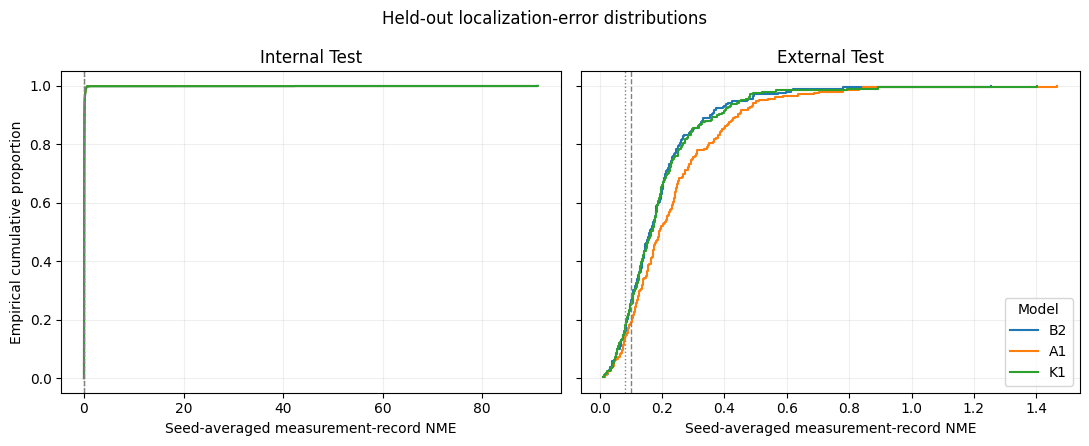


HELD-OUT FAILURE SUMMARY
         role variant  seeds  mean_nme  mean_nme_seed_sd  median_nme  p90_nme  failure_rate_008  failure_rate_010
external_test      A1      3  0.234896          0.042392    0.183978 0.458862          0.808612          0.736842
external_test      B2      3  0.190688          0.027962    0.156972 0.366487          0.776715          0.679426
external_test      K1      3  0.194778          0.066793    0.156308 0.383600          0.727273          0.633174
internal_test      A1      3  0.088683          0.001737    0.034120 0.109199          0.164911          0.115262
internal_test      B2      3  0.089993          0.002736    0.033817 0.114930          0.166583          0.123788
internal_test      K1      3  0.087607          0.003167    0.032315 0.107506          0.158308          0.112755

LOCKED XAI CHECKPOINTS — VALIDATION SELECTED
variant     seed  best_epoch  best_validation_nme                                                       checkpoint_path
     B2 20

In [7]:
# BLOCK 63 — Failure analysis and deterministic XAI case selection (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CORE = PROJECT / "evaluation_results/core_604bd46665aff864"
MANIFEST_DIR = (
    PROJECT / "data/manifests"
    / "patient_safe_v2_20260912T151813194803Z"
)
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

OUT = PROJECT / "evaluation_results" / f"failure_analysis_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/failure_analysis"

for directory in (OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

VARIANTS = ["B2", "A1", "K1"]
SEEDS = [20260912, 20260913, 20260914]
ROLES = ["internal_test", "external_test"]
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def parse_bool(series):
    values = series.astype(str).str.strip().str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError(f"Unexpected Boolean values in {series.name}.")
    return values.isin(["true", "1"])

manifest = pd.read_csv(
    MANIFEST_DIR / "unified_manifest.csv",
    dtype=str,
)
if manifest["record_id"].duplicated().any():
    raise RuntimeError("Manifest record IDs are not unique.")

metadata = manifest.set_index("record_id")[[
    "source", "anatomy", "role", "subject_key",
    "image_relative_path",
]]

prediction_frames = []
prediction_receipts = []

for variant in VARIANTS:
    for seed in SEEDS:
        path = CORE / f"{variant}_seed{seed}_predictions.csv"
        if not path.is_file():
            raise FileNotFoundError(path)

        frame = pd.read_csv(path)
        frame = frame.loc[frame["role"].isin(ROLES)].copy()
        frame["primary_eligible"] = parse_bool(
            frame["primary_eligible"]
        )
        frame = frame.loc[frame["primary_eligible"]].copy()

        if frame.duplicated(["record_id", "measurement"]).any():
            raise RuntimeError(f"Duplicate prediction keys: {path.name}")
        if not np.isfinite(frame["nme"]).all():
            raise RuntimeError(f"Nonfinite NME values: {path.name}")

        frame["variant"] = variant
        frame["seed"] = seed
        prediction_frames.append(frame[[
            "variant", "seed", "record_id", "role", "source",
            "subject_key", "measurement", "nme",
        ]])
        prediction_receipts.append({
            "variant": variant,
            "seed": seed,
            "path": str(path),
            "sha256": sha256_file(path),
            "eligible_rows": len(frame),
        })

predictions = pd.concat(prediction_frames, ignore_index=True)

# Confirm that every model and seed evaluated the same records.
reference_keys = None
for (variant, seed), frame in predictions.groupby(["variant", "seed"]):
    keys = set(zip(frame["record_id"], frame["measurement"]))
    if reference_keys is None:
        reference_keys = keys
    elif keys != reference_keys:
        raise RuntimeError(
            f"Coverage mismatch for {variant}, seed {seed}."
        )

# Attach anatomy and image path from the frozen manifest.
predictions = predictions.merge(
    metadata.reset_index()[[
        "record_id", "anatomy", "image_relative_path"
    ]],
    on="record_id",
    how="left",
    validate="many_to_one",
)
if predictions[["anatomy", "image_relative_path"]].isna().any().any():
    raise RuntimeError("Missing manifest metadata.")

# Record-level descriptive distributions.
distribution = predictions.groupby([
    "role", "source", "variant", "seed", "measurement"
]).agg(
    measurement_records=("record_id", "size"),
    subject_keys=("subject_key", "nunique"),
    mean_nme=("nme", "mean"),
    median_nme=("nme", "median"),
    p75_nme=("nme", lambda x: x.quantile(0.75)),
    p90_nme=("nme", lambda x: x.quantile(0.90)),
    p95_nme=("nme", lambda x: x.quantile(0.95)),
    maximum_nme=("nme", "max"),
    failure_rate_008=("nme", lambda x: (x > 0.08).mean()),
    failure_rate_010=("nme", lambda x: (x > 0.10).mean()),
).reset_index()

# Overall descriptive failure rates use measurement records.
overall_failure = predictions.groupby([
    "role", "variant", "seed"
]).agg(
    measurement_records=("record_id", "size"),
    mean_nme=("nme", "mean"),
    median_nme=("nme", "median"),
    p90_nme=("nme", lambda x: x.quantile(0.90)),
    failure_rate_008=("nme", lambda x: (x > 0.08).mean()),
    failure_rate_010=("nme", lambda x: (x > 0.10).mean()),
).reset_index()

overall_summary = overall_failure.groupby([
    "role", "variant"
]).agg(
    seeds=("seed", "nunique"),
    mean_nme=("mean_nme", "mean"),
    mean_nme_seed_sd=("mean_nme", "std"),
    median_nme=("median_nme", "mean"),
    p90_nme=("p90_nme", "mean"),
    failure_rate_008=("failure_rate_008", "mean"),
    failure_rate_010=("failure_rate_010", "mean"),
).reset_index()

# Consensus error averages every model, seed and valid measurement per image.
# It is used only to select representative XAI cases.
consensus = predictions.groupby([
    "record_id", "role", "source", "anatomy",
    "subject_key", "image_relative_path",
], as_index=False).agg(
    consensus_nme=("nme", "mean"),
    evaluated_measurement_model_seed_rows=("nme", "size"),
)

case_rows = []
quantile_targets = [
    ("low_error", 0.10),
    ("median_error", 0.50),
    ("high_error", 0.90),
]

for group_key, frame in consensus.groupby(
    ["role", "source", "anatomy"],
    sort=True,
):
    role, source, anatomy = group_key
    frame = frame.sort_values(
        ["consensus_nme", "record_id"]
    ).reset_index(drop=True)

    if len(frame) < 3:
        raise RuntimeError(
            f"Insufficient XAI cases in {group_key}: {len(frame)}"
        )

    used = set()
    for case_type, target_quantile in quantile_targets:
        target_value = float(
            frame["consensus_nme"].quantile(
                target_quantile,
                interpolation="linear",
            )
        )
        candidates = frame.loc[
            ~frame["record_id"].isin(used)
        ].copy()
        candidates["distance"] = (
            candidates["consensus_nme"] - target_value
        ).abs()
        selected = candidates.sort_values(
            ["distance", "record_id"]
        ).iloc[0]
        used.add(selected["record_id"])

        case_rows.append({
            "case_id": (
                f"{role}_{source}_{anatomy}_{case_type}"
            ),
            "case_type": case_type,
            "target_quantile": target_quantile,
            "target_quantile_nme": target_value,
            "record_id": selected["record_id"],
            "role": role,
            "source": source,
            "anatomy": anatomy,
            "subject_key": selected["subject_key"],
            "image_relative_path": selected["image_relative_path"],
            "consensus_nme": float(selected["consensus_nme"]),
            "group_images": len(frame),
            "selection_rule": (
                "Nearest unused image to the consensus-error quantile; "
                "record_id breaks ties."
            ),
        })

xai_cases = pd.DataFrame(case_rows)
if xai_cases["record_id"].duplicated().any():
    raise RuntimeError(
        "An image was selected for more than one XAI stratum."
    )

# Select one seed per model using validation only:
# the seed with the median best validation NME.
checkpoint_rows = []
for variant in VARIANTS:
    validation_rows = []

    for seed in SEEDS:
        run_dir = PROJECT / "runs" / f"{variant}_aug30_v1_seed{seed}"
        history_path = run_dir / "history.csv"
        best_path = run_dir / "best.pt"

        history = pd.read_csv(history_path)
        metric_candidates = [
            column for column in (
                "validation_macro_subject_nme",
                "validation_nme",
                "internal_validation_nme",
            )
            if column in history.columns
        ]
        if len(metric_candidates) != 1:
            raise RuntimeError(
                f"Cannot identify validation metric in {history_path}."
            )

        metric = metric_candidates[0]
        best_row = history.loc[history[metric].idxmin()]
        validation_rows.append({
            "variant": variant,
            "seed": seed,
            "best_validation_nme": float(best_row[metric]),
            "best_epoch": int(best_row["epoch"]),
            "checkpoint_path": str(best_path),
            "checkpoint_sha256": sha256_file(best_path),
            "history_sha256": sha256_file(history_path),
        })

    validation_frame = pd.DataFrame(validation_rows).sort_values(
        ["best_validation_nme", "seed"]
    ).reset_index(drop=True)
    chosen = validation_frame.iloc[1].copy()
    chosen["selection_rule"] = (
        "Median seed by best internal-validation NME; "
        "test performance not used."
    )
    checkpoint_rows.append(chosen.to_dict())

xai_checkpoints = pd.DataFrame(checkpoint_rows)
if set(xai_checkpoints["variant"]) != set(VARIANTS):
    raise RuntimeError("Incomplete XAI checkpoint selection.")

# Plot empirical NME distributions after averaging across seeds.
seed_averaged = predictions.groupby([
    "role", "variant", "record_id", "measurement"
], as_index=False)["nme"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for axis, role in zip(axes, ROLES):
    for variant, color in zip(
        VARIANTS,
        ["#1f77b4", "#ff7f0e", "#2ca02c"],
    ):
        values = np.sort(
            seed_averaged.loc[
                seed_averaged["role"].eq(role)
                & seed_averaged["variant"].eq(variant),
                "nme",
            ].to_numpy()
        )
        if len(values) == 0:
            raise RuntimeError(f"No distribution values: {role}, {variant}")
        cumulative = np.arange(1, len(values) + 1) / len(values)
        axis.step(
            values,
            cumulative,
            where="post",
            label=variant,
            color=color,
        )

    axis.axvline(0.08, color="gray", linestyle=":", linewidth=1)
    axis.axvline(0.10, color="gray", linestyle="--", linewidth=1)
    axis.set_title(role.replace("_", " ").title())
    axis.set_xlabel("Seed-averaged measurement-record NME")
    axis.grid(alpha=0.2)

axes[0].set_ylabel("Empirical cumulative proportion")
axes[-1].legend(title="Model")
fig.suptitle("Held-out localization-error distributions")
fig.tight_layout()

png = FIGURES / f"held_out_error_cdf_{STAMP}.png"
pdf = FIGURES / f"held_out_error_cdf_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

distribution.to_csv(
    OUT / "measurement_error_distribution.csv",
    index=False,
)
overall_failure.to_csv(
    OUT / "per_seed_failure_rates.csv",
    index=False,
)
overall_summary.to_csv(
    OUT / "failure_rate_summary.csv",
    index=False,
)
xai_cases.to_csv(
    OUT / "xai_case_manifest.csv",
    index=False,
)
xai_checkpoints.to_csv(
    OUT / "xai_checkpoint_selection.csv",
    index=False,
)
pd.DataFrame(prediction_receipts).to_csv(
    OUT / "prediction_receipts.csv",
    index=False,
)

failure_table = TABLES / f"held_out_failure_summary_{STAMP}.csv"
case_table = TABLES / f"xai_case_manifest_{STAMP}.csv"
checkpoint_table = TABLES / f"xai_checkpoint_selection_{STAMP}.csv"

overall_summary.to_csv(failure_table, index=False)
xai_cases.to_csv(case_table, index=False)
xai_checkpoints.to_csv(checkpoint_table, index=False)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "FAILURE_ANALYSIS_AND_XAI_SELECTION_COMPLETED",
    "eligible_prediction_rows": len(predictions),
    "xai_cases": len(xai_cases),
    "xai_strata": int(
        xai_cases[["role", "source", "anatomy"]]
        .drop_duplicates().shape[0]
    ),
    "cases_per_stratum": 3,
    "xai_models": VARIANTS,
    "xai_checkpoint_selection": (
        "Median validation-performing seed for each model"
    ),
    "test_performance_used_for_checkpoint_selection": False,
    "case_selection_status": "POST_HOC_DESCRIPTIVE",
    "limitations": [
        "Failure rates are descriptive measurement-record rates.",
        "NME thresholds are not clinical acceptability thresholds.",
        "XAI cases use observed test errors and are therefore descriptive.",
        "Attribution maps will not establish causal model reasoning.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 63 — failure analysis and XAI selection\n"
            f"- Selected {len(xai_cases)} deterministic XAI cases.\n"
            "- Used low, median and high consensus-error cases per stratum.\n"
            "- Selected one checkpoint per model using validation only.\n"
            "- Test errors were used only for descriptive case selection.\n"
            f"- Failure table: `{failure_table}`.\n"
            f"- XAI case manifest: `{case_table}`.\n"
            f"- Error CDF: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {"block": 63, "artifact_type": "failure_table",
     "path": str(failure_table)},
    {"block": 63, "artifact_type": "xai_case_manifest",
     "path": str(case_table)},
    {"block": 63, "artifact_type": "xai_checkpoint_selection",
     "path": str(checkpoint_table)},
    {"block": 63, "artifact_type": "figure_png",
     "path": str(png)},
    {"block": 63, "artifact_type": "figure_pdf",
     "path": str(pdf)},
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nHELD-OUT FAILURE SUMMARY")
print(overall_summary.to_string(index=False))

print("\nLOCKED XAI CHECKPOINTS — VALIDATION SELECTED")
print(xai_checkpoints[[
    "variant", "seed", "best_epoch",
    "best_validation_nme", "checkpoint_path",
]].to_string(index=False))

print("\nDETERMINISTIC XAI CASES")
print(xai_cases[[
    "case_id", "record_id", "consensus_nme",
]].to_string(index=False))

print(f"\nSaved: {OUT}")
print("\nBLOCK 63 COMPLETED")

In [1]:
# BLOCK 64 — Grad-CAM attribution maps for locked XAI cases (A100)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import random
import shutil
import sys

import numpy as np
import pandas as pd
import torch
from torch.nn import functional as F
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CACHE = PROJECT / "data/cache/letterbox256_9093c1bcf56fd66fa9a6"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

OUT = PROJECT / "xai_results" / f"gradcam_v1_{STAMP}"
RAW = OUT / "raw"
PANELS = OUT / "panels"
PAPER_FIGURES = PROJECT / "paper_artifacts/figures/xai"
TABLES = PROJECT / "paper_artifacts/tables/data"
LOCAL = Path("/content/fetalgeo_xai")

for directory in (OUT, RAW, PANELS, PAPER_FIGURES, TABLES, LOCAL):
    directory.mkdir(parents=True, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError(
        "Connect an A100 GPU runtime, mount Drive, then rerun Block 64."
    )

device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0), flush=True)

torch.set_num_threads(2)
torch.manual_seed(20260964)
torch.cuda.manual_seed_all(20260964)
np.random.seed(20260964)
random.seed(20260964)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

VARIANTS = ["B2", "A1", "K1"]
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
COLORS = {
    "ofd": "#00ffff",
    "bpd": "#ff4fd8",
    "tad": "#ffe600",
    "apad": "#00e676",
    "fl": "#ff9800",
}

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_module(name, source):
    local = LOCAL / f"{name}.py"
    shutil.copy2(source, local)
    spec = importlib.util.spec_from_file_location(name, local)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

# Locate the completed Block 63 selection.
failure_dirs = sorted(
    path for path in (
        PROJECT / "evaluation_results"
    ).glob("failure_analysis_*")
    if (path / "xai_case_manifest.csv").is_file()
    and (path / "xai_checkpoint_selection.csv").is_file()
)
if not failure_dirs:
    raise FileNotFoundError("Completed Block 63 output was not found.")

SELECTION = failure_dirs[-1]
cases_path = SELECTION / "xai_case_manifest.csv"
checkpoints_path = SELECTION / "xai_checkpoint_selection.csv"
cases = pd.read_csv(cases_path)
checkpoints = pd.read_csv(checkpoints_path)

if len(cases) != 21:
    raise RuntimeError(f"Expected 21 XAI cases; found {len(cases)}.")
if set(checkpoints["variant"]) != set(VARIANTS):
    raise RuntimeError("XAI checkpoint selection is incomplete.")

# Verify source code.
model_path = (
    PROJECT / "code/model_v1_20260912T163435231628Z"
    / "fetalgeo_model.py"
)
loss_path = (
    PROJECT / "code/loss_v1_20260912T163743169701Z"
    / "fetalgeo_losses.py"
)
control_path = (
    PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"
    / "fetalgeo_direct_aux.py"
)

expected_hashes = {
    model_path:
        "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
    loss_path:
        "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
    control_path:
        "a1fa2ff60baa49f34a84f93a010014ac756867153647ed5e45b4a4df34ae6799",
}
for path, expected in expected_hashes.items():
    if sha256_file(path) != expected:
        raise RuntimeError(f"Source verification failed: {path}")

model_module = load_module("fetalgeo_model", model_path)
loss_module = load_module("fetalgeo_losses", loss_path)
control_module = load_module("fetalgeo_direct_aux", control_path)

def make_model(variant):
    if variant == "K1":
        return control_module.DirectAuxControl(pretrained=False)
    return model_module.FetalGeo(
        geometry=(variant == "A1"),
        pretrained=False,
    )

# Verify selected checkpoints.
checkpoint_info = {}
for row in checkpoints.itertuples():
    path = Path(row.checkpoint_path)
    if not path.is_file():
        raise FileNotFoundError(path)
    actual_hash = sha256_file(path)
    if actual_hash != row.checkpoint_sha256:
        raise RuntimeError(f"Checkpoint checksum mismatch: {row.variant}")
    checkpoint_info[row.variant] = {
        "seed": int(row.seed),
        "epoch": int(row.best_epoch),
        "validation_nme": float(row.best_validation_nme),
        "path": path,
        "sha256": actual_hash,
    }

# Determine eligible measurement targets from the locked protocol.
protocol_dirs = sorted(
    (PROJECT / "evaluation_protocols").glob("core_v1_*")
)
if len(protocol_dirs) != 1:
    raise RuntimeError("Expected exactly one core evaluation protocol.")
protocol = pd.read_csv(
    protocol_dirs[0] / "evaluation_measurements.csv",
    dtype=str,
)
protocol["primary_eligible"] = (
    protocol["primary_eligible"]
    .str.lower()
    .isin(["true", "1"])
)
eligible = {
    (row.record_id, row.measurement)
    for row in protocol.itertuples()
    if row.primary_eligible
}

# Load the selected images, targets and transformations from cache.
cache_index = pd.read_csv(
    CACHE / "cache_index.csv",
    dtype=str,
)
if cache_index["record_id"].duplicated().any():
    raise RuntimeError("Cache record IDs are not unique.")
cache_index = cache_index.set_index("record_id")

case_ids = cases["record_id"].tolist()
if not set(case_ids).issubset(cache_index.index):
    raise RuntimeError("Some XAI cases are absent from the cache.")

cached = {}
selection = cache_index.loc[case_ids]

print("Loading 21 selected cases from cache...", flush=True)
for chunk_name, group in selection.groupby("chunk_file", sort=True):
    with np.load(CACHE / chunk_name, allow_pickle=False) as archive:
        for record_id, row in group.iterrows():
            position = int(row["position"])
            stored = archive["record_ids"][position]
            if isinstance(stored, bytes):
                stored = stored.decode()
            if str(stored) != record_id:
                raise RuntimeError("Cache record-position mismatch.")

            cached[record_id] = {
                "image": np.array(
                    archive["images"][position],
                    dtype=np.uint8,
                    copy=True,
                ),
                "target_points": np.array(
                    archive["cached_points"][position],
                    dtype=np.float32,
                    copy=True,
                ),
            }

mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
    device=device,
)[None, :, None, None]
std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
    device=device,
)[None, :, None, None]

def gradcam(model, image, measurement_indices):
    """
    Grad-CAM target:
    sum of local-head logits at the model's predicted endpoint cells
    for all primary-eligible measurements present in this image.
    """
    activation_holder = {}
    gradient_holder = {}

    def forward_hook(module, inputs, output):
        activation_holder["value"] = output
        output.register_hook(
            lambda gradient: gradient_holder.__setitem__(
                "value", gradient
            )
        )

    handle = model.fusion.register_forward_hook(forward_hook)

    tensor = torch.from_numpy(image).permute(
        2, 0, 1
    )[None].to(device).float() / 255.0
    tensor = (tensor - mean) / std

    model.zero_grad(set_to_none=True)
    output = model(tensor)
    logits = output["heatmap_logits"]
    local_points = output["local_points"]

    if tuple(logits.shape[-2:]) != (64, 64):
        raise RuntimeError("Unexpected heatmap resolution.")

    score = logits.new_zeros(())
    selected_cells = []

    for measurement_index in measurement_indices:
        for endpoint_index in range(2):
            point = local_points[
                0, measurement_index, endpoint_index
            ]
            heatmap_x = (
                (point[0] + 0.5) * (64.0 / 256.0) - 0.5
            )
            heatmap_y = (
                (point[1] + 0.5) * (64.0 / 256.0) - 0.5
            )
            x_index = int(
                torch.round(heatmap_x).clamp(0, 63).item()
            )
            y_index = int(
                torch.round(heatmap_y).clamp(0, 63).item()
            )
            score = score + logits[
                0,
                measurement_index,
                endpoint_index,
                y_index,
                x_index,
            ]
            selected_cells.append({
                "measurement": MEASUREMENTS[measurement_index],
                "endpoint": endpoint_index + 1,
                "heatmap_x": x_index,
                "heatmap_y": y_index,
            })

    if not torch.isfinite(score):
        raise RuntimeError("Nonfinite Grad-CAM target score.")

    score.backward()

    activation = activation_holder["value"].detach()
    gradient = gradient_holder["value"].detach()
    handle.remove()

    weights = gradient.mean(dim=(-2, -1), keepdim=True)
    raw_cam = (weights * activation).sum(dim=1, keepdim=True)
    raw_cam = F.relu(raw_cam)
    cam = F.interpolate(
        raw_cam,
        size=(256, 256),
        mode="bilinear",
        align_corners=False,
    )[0, 0]

    cam_min = cam.min()
    cam_max = cam.max()
    dynamic_range = cam_max - cam_min
    if not torch.isfinite(cam).all():
        raise RuntimeError("Nonfinite Grad-CAM map.")

    if float(dynamic_range) > 0:
        cam = (cam - cam_min) / dynamic_range
    else:
        cam = torch.zeros_like(cam)

    return {
        "cam": cam.cpu().numpy().astype(np.float32),
        "local_points": local_points.detach().cpu().numpy()[0],
        "target_score": float(score.detach()),
        "selected_cells": selected_cells,
        "activation_shape": list(activation.shape),
        "gradient_shape": list(gradient.shape),
        "cam_dynamic_range": float(dynamic_range),
    }

models = {}
for variant in VARIANTS:
    info = checkpoint_info[variant]
    print(
        f"Loading {variant}, seed {info['seed']}, "
        f"epoch {info['epoch']}...",
        flush=True,
    )
    checkpoint = torch.load(
        info["path"],
        map_location="cpu",
        weights_only=True,
    )
    model = make_model(variant)
    model.load_state_dict(checkpoint["model"], strict=True)
    model = model.to(device).eval()
    models[variant] = model
    del checkpoint

records = []

for case_index, case in enumerate(cases.itertuples(), start=1):
    record_id = case.record_id
    image = cached[record_id]["image"]
    target_points = cached[record_id]["target_points"]

    measurement_names = [
        measurement
        for measurement in MEASUREMENTS
        if (record_id, measurement) in eligible
    ]
    if not measurement_names:
        raise RuntimeError(
            f"No eligible measurements for XAI case {record_id}."
        )
    measurement_indices = [
        MEASUREMENTS.index(name)
        for name in measurement_names
    ]

    print(
        f"\nCase {case_index}/21: {case.case_id} "
        f"({', '.join(measurement_names)})",
        flush=True,
    )

    for variant in VARIANTS:
        print(f"  Grad-CAM: {variant}", flush=True)
        result = gradcam(
            models[variant],
            image,
            measurement_indices,
        )

        raw_path = (
            RAW / f"{case.case_id}_{variant}.npz"
        )
        np.savez_compressed(
            raw_path,
            cam=result["cam"],
            image=image,
            target_points=target_points,
            local_points=result["local_points"],
            measurement_indices=np.asarray(
                measurement_indices,
                dtype=np.int64,
            ),
        )

        records.append({
            "case_id": case.case_id,
            "case_type": case.case_type,
            "record_id": record_id,
            "role": case.role,
            "source": case.source,
            "anatomy": case.anatomy,
            "consensus_nme": case.consensus_nme,
            "variant": variant,
            "seed": checkpoint_info[variant]["seed"],
            "checkpoint_epoch": checkpoint_info[variant]["epoch"],
            "checkpoint_sha256": checkpoint_info[variant]["sha256"],
            "target_measurements": "|".join(measurement_names),
            "target_score": result["target_score"],
            "cam_dynamic_range": result["cam_dynamic_range"],
            "activation_shape": json.dumps(
                result["activation_shape"]
            ),
            "gradient_shape": json.dumps(
                result["gradient_shape"]
            ),
            "selected_cells": json.dumps(
                result["selected_cells"]
            ),
            "raw_path": str(raw_path),
            "raw_sha256": sha256_file(raw_path),
        })

records_frame = pd.DataFrame(records)
if len(records_frame) != 63:
    raise RuntimeError(
        f"Expected 63 attribution maps; found {len(records_frame)}."
    )
if (records_frame["cam_dynamic_range"] <= 0).any():
    failed = records_frame.loc[
        records_frame["cam_dynamic_range"] <= 0,
        ["case_id", "variant"],
    ]
    raise RuntimeError(
        "Zero-dynamic-range Grad-CAM maps:\n"
        + failed.to_string(index=False)
    )

# Create one comparison panel for each domain/anatomy stratum.
panel_rows = []
group_columns = ["role", "source", "anatomy"]

for group_key, group_cases in cases.groupby(
    group_columns,
    sort=True,
):
    role, source, anatomy = group_key
    order_map = {
        "low_error": 0,
        "median_error": 1,
        "high_error": 2,
    }
    group_cases = group_cases.copy()
    group_cases["order"] = group_cases["case_type"].map(
        order_map
    )
    group_cases = group_cases.sort_values("order")

    if len(group_cases) != 3:
        raise RuntimeError(
            f"Expected three cases in stratum {group_key}."
        )

    fig, axes = plt.subplots(
        3, 4,
        figsize=(14, 10),
    )

    for row_index, case in enumerate(
        group_cases.itertuples()
    ):
        image = cached[case.record_id]["image"]
        targets = cached[case.record_id]["target_points"]
        measurement_names = [
            measurement
            for measurement in MEASUREMENTS
            if (case.record_id, measurement) in eligible
        ]

        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(
            f"{case.case_type.replace('_', ' ').title()}\n"
            f"consensus NME={case.consensus_nme:.3f}"
        )

        for measurement in measurement_names:
            index = MEASUREMENTS.index(measurement)
            points = targets[index]
            if np.isfinite(points).all():
                axes[row_index, 0].plot(
                    points[:, 0],
                    points[:, 1],
                    color=COLORS[measurement],
                    marker="o",
                    linewidth=1.4,
                )

        for column, variant in enumerate(
            VARIANTS,
            start=1,
        ):
            raw_path = (
                RAW / f"{case.case_id}_{variant}.npz"
            )
            with np.load(raw_path, allow_pickle=False) as archive:
                cam = archive["cam"]
                local = archive["local_points"]

            axes[row_index, column].imshow(image)
            axes[row_index, column].imshow(
                cam,
                cmap="jet",
                alpha=0.42,
                vmin=0,
                vmax=1,
            )

            for measurement in measurement_names:
                index = MEASUREMENTS.index(measurement)
                truth_points = targets[index]
                predicted_points = local[index]

                if np.isfinite(truth_points).all():
                    axes[row_index, column].plot(
                        truth_points[:, 0],
                        truth_points[:, 1],
                        color="white",
                        marker="o",
                        linewidth=1.2,
                    )
                axes[row_index, column].plot(
                    predicted_points[:, 0],
                    predicted_points[:, 1],
                    color=COLORS[measurement],
                    marker="x",
                    linewidth=1.2,
                )

            axes[row_index, column].set_title(variant)

        for axis in axes[row_index]:
            axis.set_xlim(-0.5, 255.5)
            axis.set_ylim(255.5, -0.5)
            axis.axis("off")

    fig.suptitle(
        f"Grad-CAM comparison: "
        f"{role.replace('_', ' ').title()} / "
        f"{source} / {anatomy}\n"
        "Original with annotations | "
        "CAM with white annotation and colored prediction",
        fontsize=13,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    safe_name = (
        f"{role}_{source}_{anatomy}"
        .replace(" ", "_")
    )
    panel_png = PANELS / f"{safe_name}.png"
    panel_pdf = PANELS / f"{safe_name}.pdf"
    paper_png = (
        PAPER_FIGURES
        / f"gradcam_{safe_name}_{STAMP}.png"
    )
    paper_pdf = (
        PAPER_FIGURES
        / f"gradcam_{safe_name}_{STAMP}.pdf"
    )

    fig.savefig(
        panel_png,
        dpi=220,
        bbox_inches="tight",
    )
    fig.savefig(
        panel_pdf,
        bbox_inches="tight",
    )
    fig.savefig(
        paper_png,
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        paper_pdf,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    panel_rows.append({
        "role": role,
        "source": source,
        "anatomy": anatomy,
        "cases": len(group_cases),
        "panel_png": str(panel_png),
        "panel_pdf": str(panel_pdf),
        "paper_png": str(paper_png),
        "paper_pdf": str(paper_pdf),
        "paper_png_sha256": sha256_file(paper_png),
        "paper_pdf_sha256": sha256_file(paper_pdf),
    })

panels_frame = pd.DataFrame(panel_rows)
if len(panels_frame) != 7:
    raise RuntimeError(
        f"Expected seven XAI stratum panels; "
        f"found {len(panels_frame)}."
    )

records_path = OUT / "gradcam_manifest.csv"
panels_path = OUT / "panel_manifest.csv"
records_frame.to_csv(records_path, index=False)
panels_frame.to_csv(panels_path, index=False)

table_path = TABLES / f"xai_gradcam_manifest_{STAMP}.csv"
records_frame.to_csv(table_path, index=False)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "GRADCAM_ATTRIBUTIONS_GENERATED",
    "gpu": torch.cuda.get_device_name(0),
    "xai_method": "Grad-CAM on fused 64-channel feature map",
    "target": (
        "Sum of local-head logits at predicted endpoint cells "
        "for primary-eligible measurements in each image"
    ),
    "models": VARIANTS,
    "cases": len(cases),
    "attribution_maps": len(records_frame),
    "stratum_panels": len(panels_frame),
    "case_manifest": str(cases_path),
    "case_manifest_sha256": sha256_file(cases_path),
    "checkpoint_manifest": str(checkpoints_path),
    "checkpoint_manifest_sha256": sha256_file(
        checkpoints_path
    ),
    "gradcam_manifest": str(records_path),
    "panel_manifest": str(panels_path),
    "training_performed": False,
    "model_parameters_changed": False,
    "limitations": [
        "Grad-CAM is a post-hoc attribution method.",
        "Attribution does not prove causal model reasoning.",
        "Cases were selected descriptively from observed test errors.",
        "One validation-selected seed represents each model.",
        "The target explains local-head endpoint evidence only.",
        "Cross-model heatmap magnitude is normalized per image and model.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 64 — Grad-CAM attribution generation\n"
            f"- Generated {len(records_frame)} maps across "
            f"{len(cases)} cases and three models.\n"
            f"- Saved {len(panels_frame)} domain/anatomy panels.\n"
            "- Used validation-selected checkpoints from Block 63.\n"
            "- Targeted local-head endpoint logits.\n"
            "- Attributions are post-hoc descriptive evidence.\n"
            f"- Raw attribution data: `{RAW}`.\n"
            f"- Panel manifest: `{panels_path}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = []
for panel in panel_rows:
    entries.extend([
        {
            "block": 64,
            "artifact_type": "xai_figure_png",
            "path": panel["paper_png"],
        },
        {
            "block": 64,
            "artifact_type": "xai_figure_pdf",
            "path": panel["paper_pdf"],
        },
    ])
entries.append({
    "block": 64,
    "artifact_type": "xai_manifest",
    "path": str(table_path),
})
entries = pd.DataFrame(entries)

if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nGRAD-CAM SUMMARY")
print(
    records_frame.groupby(
        ["variant", "role"]
    ).agg(
        maps=("case_id", "size"),
        minimum_dynamic_range=(
            "cam_dynamic_range", "min"
        ),
        median_dynamic_range=(
            "cam_dynamic_range", "median"
        ),
    ).to_string()
)

print("\nPAPER PANELS")
print(
    panels_frame[[
        "role", "source", "anatomy", "paper_png"
    ]].to_string(index=False)
)

print(f"\nSaved XAI results: {OUT}")
print("\nBLOCK 64 COMPLETED")

Output hidden; open in https://colab.research.google.com to view.

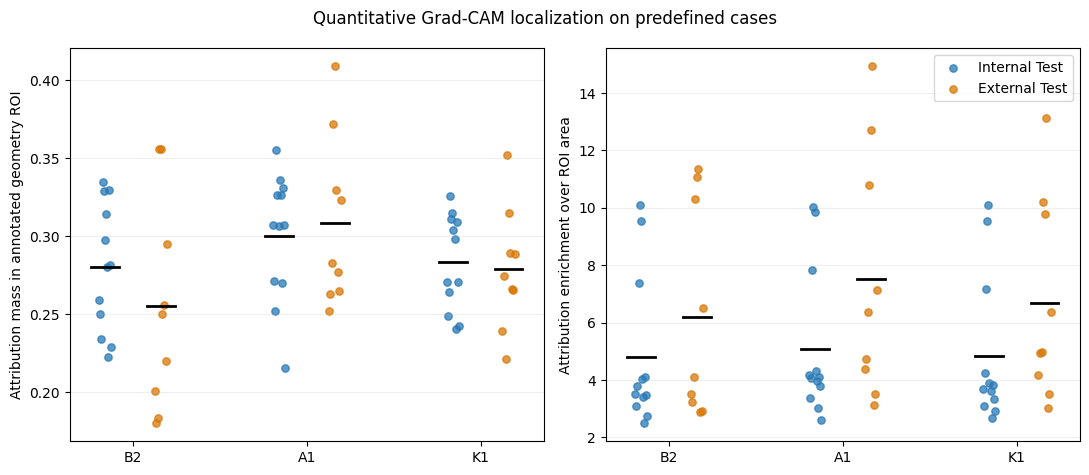


QUANTITATIVE XAI SUMMARY
         role variant  cases  geometry_mass_mean  geometry_mass_sd  endpoint_mass_mean  geometry_enrichment_mean  endpoint_enrichment_mean  pointing_geometry_rate  pointing_endpoint_rate  normalized_entropy_mean
external_test      A1      9            0.308130          0.054350            0.203320                  7.516977                 10.093283                0.888889                0.888889                 0.835014
external_test      B2      9            0.255209          0.067952            0.171695                  6.207786                  8.535493                0.666667                0.666667                 0.854161
external_test      K1      9            0.279018          0.038952            0.198934                  6.672915                  9.936202                0.555556                0.555556                 0.852467
internal_test      A1     12            0.300383          0.040480            0.213010                  5.090353              

In [1]:
# BLOCK 65 — Quantitative Grad-CAM analysis (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

# Locate the completed Block 64 output.
xai_dirs = sorted(
    path for path in (
        PROJECT / "xai_results"
    ).glob("gradcam_v1_*")
    if (path / "gradcam_manifest.csv").is_file()
    and (path / "summary.json").is_file()
)
if not xai_dirs:
    raise FileNotFoundError("Completed Block 64 output was not found.")

XAI = xai_dirs[-1]
OUT = XAI / f"quantitative_analysis_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/xai"

for directory in (OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

VARIANTS = ["B2", "A1", "K1"]
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]
LINE_RADIUS = 8.0
ENDPOINT_RADIUS = 12.0

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def point_to_segment_distance(xx, yy, first, second):
    vector = second - first
    length_squared = float(np.dot(vector, vector))
    if length_squared <= 0:
        return np.sqrt(
            (xx - first[0]) ** 2
            + (yy - first[1]) ** 2
        )

    projection = (
        (xx - first[0]) * vector[0]
        + (yy - first[1]) * vector[1]
    ) / length_squared
    projection = np.clip(projection, 0.0, 1.0)

    nearest_x = first[0] + projection * vector[0]
    nearest_y = first[1] + projection * vector[1]
    return np.sqrt(
        (xx - nearest_x) ** 2
        + (yy - nearest_y) ** 2
    )

def unordered_nme(predicted, target):
    length = float(np.linalg.norm(target[1] - target[0]))
    if not np.isfinite(length) or length <= 0:
        return np.nan

    direct = np.linalg.norm(
        predicted - target,
        axis=1,
    ).mean()
    reverse = np.linalg.norm(
        predicted - target[::-1],
        axis=1,
    ).mean()
    return float(min(direct, reverse) / length)

manifest_path = XAI / "gradcam_manifest.csv"
manifest = pd.read_csv(manifest_path)

if len(manifest) != 63:
    raise RuntimeError(
        f"Expected 63 Grad-CAM records; found {len(manifest)}."
    )
if manifest.duplicated(["case_id", "variant"]).any():
    raise RuntimeError("Duplicate case/model attribution entries.")
if set(manifest["variant"]) != set(VARIANTS):
    raise RuntimeError("Model coverage is incomplete.")

yy, xx = np.mgrid[0:256, 0:256]
metric_rows = []

for row in manifest.itertuples():
    raw_path = Path(row.raw_path)
    if not raw_path.is_file():
        raise FileNotFoundError(raw_path)
    if sha256_file(raw_path) != row.raw_sha256:
        raise RuntimeError(f"Raw attribution hash mismatch: {raw_path}")

    with np.load(raw_path, allow_pickle=False) as archive:
        cam = np.asarray(archive["cam"], dtype=np.float64)
        image = np.asarray(archive["image"], dtype=np.uint8)
        targets = np.asarray(
            archive["target_points"],
            dtype=np.float64,
        )
        predictions = np.asarray(
            archive["local_points"],
            dtype=np.float64,
        )
        measurement_indices = np.asarray(
            archive["measurement_indices"],
            dtype=np.int64,
        )

    if cam.shape != (256, 256):
        raise RuntimeError(f"Unexpected CAM shape: {raw_path}")
    if image.shape != (256, 256, 3):
        raise RuntimeError(f"Unexpected image shape: {raw_path}")
    if targets.shape != (5, 2, 2):
        raise RuntimeError(f"Unexpected target shape: {raw_path}")
    if predictions.shape != (5, 2, 2):
        raise RuntimeError(f"Unexpected prediction shape: {raw_path}")
    if not np.isfinite(cam).all() or (cam < 0).any():
        raise RuntimeError(f"Invalid CAM values: {raw_path}")

    roi = np.zeros((256, 256), dtype=bool)
    endpoint_roi = np.zeros((256, 256), dtype=bool)
    measurement_errors = []

    for index in measurement_indices:
        target = targets[index]
        prediction = predictions[index]

        if not np.isfinite(target).all():
            raise RuntimeError(
                f"Nonfinite selected target: {row.case_id}"
            )
        if not np.isfinite(prediction).all():
            raise RuntimeError(
                f"Nonfinite selected prediction: {row.case_id}"
            )

        line_distance = point_to_segment_distance(
            xx, yy, target[0], target[1]
        )
        roi |= line_distance <= LINE_RADIUS

        for endpoint in target:
            endpoint_distance = np.sqrt(
                (xx - endpoint[0]) ** 2
                + (yy - endpoint[1]) ** 2
            )
            endpoint_roi |= endpoint_distance <= ENDPOINT_RADIUS

        measurement_errors.append(
            unordered_nme(prediction, target)
        )

    # Geometry ROI includes both endpoint neighborhoods and connecting lines.
    geometry_roi = roi | endpoint_roi
    roi_fraction = float(geometry_roi.mean())
    endpoint_fraction = float(endpoint_roi.mean())

    total_mass = float(cam.sum())
    if total_mass <= 0:
        raise RuntimeError(f"Zero attribution mass: {raw_path}")

    geometry_mass = float(
        cam[geometry_roi].sum() / total_mass
    )
    endpoint_mass = float(
        cam[endpoint_roi].sum() / total_mass
    )
    geometry_enrichment = float(
        geometry_mass / roi_fraction
    )
    endpoint_enrichment = float(
        endpoint_mass / endpoint_fraction
    )

    peak_y, peak_x = np.unravel_index(
        np.argmax(cam),
        cam.shape,
    )
    peak_in_geometry = bool(
        geometry_roi[peak_y, peak_x]
    )
    peak_in_endpoint = bool(
        endpoint_roi[peak_y, peak_x]
    )

    probability = cam.ravel() / total_mass
    nonzero = probability > 0
    entropy = float(
        -(probability[nonzero]
          * np.log(probability[nonzero])).sum()
        / np.log(probability.size)
    )

    metric_rows.append({
        "case_id": row.case_id,
        "case_type": row.case_type,
        "record_id": row.record_id,
        "role": row.role,
        "source": row.source,
        "anatomy": row.anatomy,
        "variant": row.variant,
        "seed": row.seed,
        "target_measurements": row.target_measurements,
        "consensus_nme": float(row.consensus_nme),
        "selected_local_nme": float(
            np.nanmean(measurement_errors)
        ),
        "geometry_roi_fraction": roi_fraction,
        "endpoint_roi_fraction": endpoint_fraction,
        "geometry_attribution_mass": geometry_mass,
        "endpoint_attribution_mass": endpoint_mass,
        "geometry_enrichment": geometry_enrichment,
        "endpoint_enrichment": endpoint_enrichment,
        "peak_x": int(peak_x),
        "peak_y": int(peak_y),
        "peak_in_geometry_roi": peak_in_geometry,
        "peak_in_endpoint_roi": peak_in_endpoint,
        "normalized_cam_entropy": entropy,
    })

metrics = pd.DataFrame(metric_rows)
if len(metrics) != 63:
    raise RuntimeError("Quantitative XAI row count mismatch.")
if not np.isfinite(metrics.select_dtypes("number")).all().all():
    raise RuntimeError("Nonfinite quantitative XAI values.")

summary = metrics.groupby([
    "role", "variant"
]).agg(
    cases=("case_id", "size"),
    geometry_mass_mean=("geometry_attribution_mass", "mean"),
    geometry_mass_sd=("geometry_attribution_mass", "std"),
    endpoint_mass_mean=("endpoint_attribution_mass", "mean"),
    geometry_enrichment_mean=("geometry_enrichment", "mean"),
    endpoint_enrichment_mean=("endpoint_enrichment", "mean"),
    pointing_geometry_rate=("peak_in_geometry_roi", "mean"),
    pointing_endpoint_rate=("peak_in_endpoint_roi", "mean"),
    normalized_entropy_mean=("normalized_cam_entropy", "mean"),
).reset_index()

stratified = metrics.groupby([
    "role", "source", "anatomy", "case_type", "variant"
]).agg(
    geometry_attribution_mass=("geometry_attribution_mass", "mean"),
    endpoint_attribution_mass=("endpoint_attribution_mass", "mean"),
    geometry_enrichment=("geometry_enrichment", "mean"),
    endpoint_enrichment=("endpoint_enrichment", "mean"),
    peak_in_geometry_roi=("peak_in_geometry_roi", "mean"),
    normalized_cam_entropy=("normalized_cam_entropy", "mean"),
).reset_index()

# Paired case-level model differences.
paired = metrics.pivot(
    index="case_id",
    columns="variant",
    values=[
        "geometry_attribution_mass",
        "geometry_enrichment",
        "normalized_cam_entropy",
    ],
)
paired.columns = [
    f"{metric}_{variant}"
    for metric, variant in paired.columns
]
paired = paired.reset_index()

for metric in (
    "geometry_attribution_mass",
    "geometry_enrichment",
    "normalized_cam_entropy",
):
    paired[f"{metric}_A1_minus_B2"] = (
        paired[f"{metric}_A1"]
        - paired[f"{metric}_B2"]
    )
    paired[f"{metric}_K1_minus_B2"] = (
        paired[f"{metric}_K1"]
        - paired[f"{metric}_B2"]
    )

paired_summary_rows = []
for contrast in ("A1_minus_B2", "K1_minus_B2"):
    for metric in (
        "geometry_attribution_mass",
        "geometry_enrichment",
        "normalized_cam_entropy",
    ):
        values = paired[
            f"{metric}_{contrast}"
        ].to_numpy()
        paired_summary_rows.append({
            "contrast": contrast,
            "metric": metric,
            "cases": len(values),
            "mean_paired_difference": float(values.mean()),
            "paired_difference_sd": float(
                values.std(ddof=1)
            ),
        })
paired_summary = pd.DataFrame(paired_summary_rows)

# Spearman correlation implemented through average ranks.
correlation_rows = []
for variant in VARIANTS:
    subset = metrics.loc[
        metrics["variant"].eq(variant)
    ].copy()

    for role in ("internal_test", "external_test"):
        role_subset = subset.loc[
            subset["role"].eq(role)
        ]
        for metric in (
            "geometry_attribution_mass",
            "geometry_enrichment",
            "normalized_cam_entropy",
        ):
            x = role_subset[metric].rank(
                method="average"
            ).to_numpy()
            y = role_subset["consensus_nme"].rank(
                method="average"
            ).to_numpy()

            correlation = (
                float(np.corrcoef(x, y)[0, 1])
                if len(x) > 2
                and np.std(x) > 0
                and np.std(y) > 0
                else np.nan
            )
            correlation_rows.append({
                "variant": variant,
                "role": role,
                "metric": metric,
                "cases": len(role_subset),
                "spearman_correlation_with_consensus_nme": correlation,
            })

correlations = pd.DataFrame(correlation_rows)

metrics_path = OUT / "case_model_xai_metrics.csv"
summary_path = OUT / "xai_summary.csv"
stratified_path = OUT / "xai_stratified_summary.csv"
paired_path = OUT / "paired_model_differences.csv"
correlation_path = OUT / "error_attribution_correlations.csv"

metrics.to_csv(metrics_path, index=False)
summary.to_csv(summary_path, index=False)
stratified.to_csv(stratified_path, index=False)
paired.to_csv(paired_path, index=False)
paired_summary.to_csv(
    OUT / "paired_model_difference_summary.csv",
    index=False,
)
correlations.to_csv(correlation_path, index=False)

table_path = TABLES / f"xai_quantitative_summary_{STAMP}.csv"
summary.to_csv(table_path, index=False)

# Figure: geometry mass and enrichment by role and model.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

plot_specs = [
    (
        "geometry_attribution_mass",
        "Attribution mass in annotated geometry ROI",
    ),
    (
        "geometry_enrichment",
        "Attribution enrichment over ROI area",
    ),
]

role_offsets = {
    "internal_test": -0.16,
    "external_test": 0.16,
}
role_colors = {
    "internal_test": "#2878b5",
    "external_test": "#d97706",
}

for axis, (metric, ylabel) in zip(axes, plot_specs):
    for model_index, variant in enumerate(VARIANTS):
        for role in ("internal_test", "external_test"):
            values = metrics.loc[
                metrics["variant"].eq(variant)
                & metrics["role"].eq(role),
                metric,
            ].to_numpy()
            x = (
                model_index
                + role_offsets[role]
                + np.linspace(-0.035, 0.035, len(values))
            )
            axis.scatter(
                x,
                values,
                color=role_colors[role],
                alpha=0.75,
                s=28,
                label=(
                    role.replace("_", " ").title()
                    if model_index == 0
                    else None
                ),
            )
            axis.plot(
                [
                    model_index + role_offsets[role] - 0.08,
                    model_index + role_offsets[role] + 0.08,
                ],
                [np.mean(values), np.mean(values)],
                color="black",
                linewidth=2,
            )

    axis.set_xticks(range(len(VARIANTS)))
    axis.set_xticklabels(VARIANTS)
    axis.set_ylabel(ylabel)
    axis.grid(axis="y", alpha=0.2)

axes[1].legend()
fig.suptitle(
    "Quantitative Grad-CAM localization on predefined cases"
)
fig.tight_layout()

png = FIGURES / f"xai_quantitative_{STAMP}.png"
pdf = FIGURES / f"xai_quantitative_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "QUANTITATIVE_GRADCAM_ANALYSIS_COMPLETED",
    "source_xai_directory": str(XAI),
    "cases": int(metrics["case_id"].nunique()),
    "models": VARIANTS,
    "case_model_rows": len(metrics),
    "line_radius_pixels": LINE_RADIUS,
    "endpoint_radius_pixels": ENDPOINT_RADIUS,
    "metrics": [
        "Attribution mass in annotated geometry ROI",
        "Attribution enrichment relative to ROI area",
        "Peak-point inclusion",
        "Normalized attribution entropy",
    ],
    "study_status": "POST_HOC_DESCRIPTIVE_XAI",
    "sanity_check_status": "PENDING",
    "limitations": [
        "ROI radii are descriptive analysis settings.",
        "Grad-CAM resolution and interpolation limit spatial precision.",
        "The target score uses predicted endpoint cells.",
        "Cases were selected using observed errors.",
        "Only one validation-selected seed represents each model.",
        "Attribution localization does not establish causal reasoning.",
        "Correlations use 9 external and 12 internal cases per model.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(report, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 65 — quantitative Grad-CAM analysis\n"
            f"- Quantified {len(metrics)} case/model attribution maps.\n"
            f"- Geometry tube radius: {LINE_RADIUS:.0f} cached pixels; "
            f"endpoint radius: {ENDPOINT_RADIUS:.0f} pixels.\n"
            "- Measured attribution mass, enrichment, pointing and entropy.\n"
            "- Results remain post-hoc descriptive XAI evidence.\n"
            "- Parameter-randomization sanity check remains pending.\n"
            f"- Table: `{table_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 65,
        "artifact_type": "xai_quantitative_table",
        "path": str(table_path),
    },
    {
        "block": 65,
        "artifact_type": "xai_quantitative_figure_png",
        "path": str(png),
    },
    {
        "block": 65,
        "artifact_type": "xai_quantitative_figure_pdf",
        "path": str(pdf),
    },
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nQUANTITATIVE XAI SUMMARY")
print(summary.to_string(index=False))

print("\nPAIRED MODEL DIFFERENCES")
print(paired_summary.to_string(index=False))

print("\nCORRELATION WITH CONSENSUS ERROR")
print(correlations.to_string(index=False))

print(f"\nSaved quantitative XAI analysis: {OUT}")
print("\nBLOCK 65 COMPLETED — GPU not required")

GPU: NVIDIA A100-SXM4-40GB

Preparing sanity controls for B2...
  B2 case 1/21: external_test_UCL_Abdomen_high_error
  B2 case 2/21: external_test_UCL_Abdomen_low_error
  B2 case 3/21: external_test_UCL_Abdomen_median_error
  B2 case 4/21: external_test_UCL_Femur_high_error
  B2 case 5/21: external_test_UCL_Femur_low_error
  B2 case 6/21: external_test_UCL_Femur_median_error
  B2 case 7/21: external_test_UCL_Head_high_error
  B2 case 8/21: external_test_UCL_Head_low_error
  B2 case 9/21: external_test_UCL_Head_median_error
  B2 case 10/21: internal_test_FP_Abdomen_high_error
  B2 case 11/21: internal_test_FP_Abdomen_low_error
  B2 case 12/21: internal_test_FP_Abdomen_median_error
  B2 case 13/21: internal_test_FP_Femur_high_error
  B2 case 14/21: internal_test_FP_Femur_low_error
  B2 case 15/21: internal_test_FP_Femur_median_error
  B2 case 16/21: internal_test_FP_Head_high_error
  B2 case 17/21: internal_test_FP_Head_low_error
  B2 case 18/21: internal_test_FP_Head_median_error
  B2 c

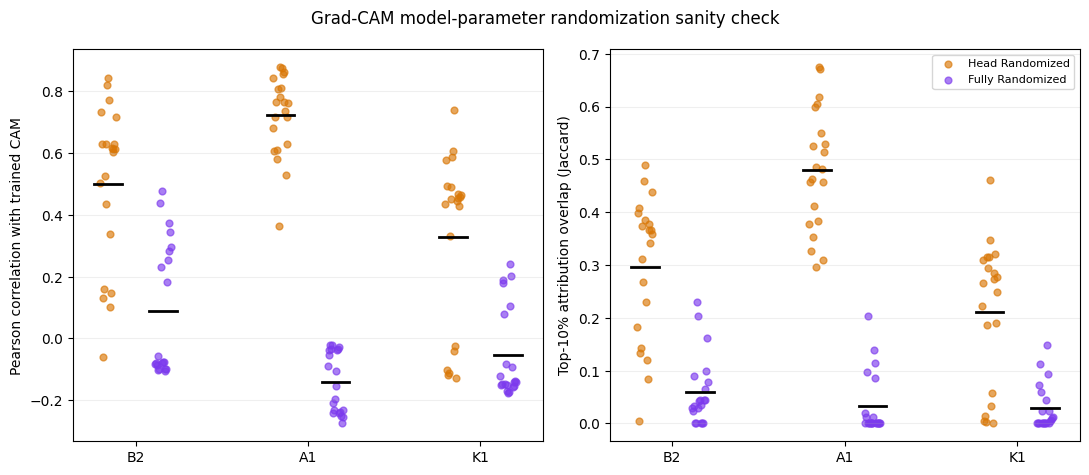


PARAMETER RANDOMIZATION
variant          control  changed_parameter_elements  parameter_elements  changed_fraction
     B2  head_randomized                         650            11084382          0.000059
     B2 fully_randomized                    11084382            11084382          1.000000
     A1  head_randomized                         650            11218162          0.000058
     A1 fully_randomized                    11218162            11218162          1.000000
     K1  head_randomized                         650            11218162          0.000058
     K1 fully_randomized                    11218162            11218162          1.000000

XAI RANDOMIZATION SUMMARY
variant          control  cases  zero_range_maps  pearson_mean  pearson_sd  cosine_mean  top10_jaccard_mean  peak_displacement_mean  map_difference_mean
     A1 fully_randomized     21                0     -0.141758    0.098575     0.036413            0.032654              153.552344             0.141491
     

In [1]:
# BLOCK 66 — Grad-CAM parameter-randomization sanity checks (A100)
from pathlib import Path
from datetime import datetime, timezone
import copy
import hashlib
import importlib.util
import json
import random
import shutil
import sys

import numpy as np
import pandas as pd
import torch
from torch.nn import functional as F
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

xai_dirs = sorted(
    path for path in (PROJECT / "xai_results").glob("gradcam_v1_*")
    if (path / "gradcam_manifest.csv").is_file()
)
if not xai_dirs:
    raise FileNotFoundError("Completed Block 64 output was not found.")

XAI = xai_dirs[-1]
OUT = XAI / f"randomization_sanity_{STAMP}"
RAW = OUT / "raw_controls"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/xai"
LOCAL = Path("/content/fetalgeo_xai_sanity")

for directory in (OUT, RAW, TABLES, FIGURES, LOCAL):
    directory.mkdir(parents=True, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError(
        "Connect an A100 GPU runtime, mount Drive, then rerun."
    )

device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0), flush=True)

torch.set_num_threads(2)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

VARIANTS = ["B2", "A1", "K1"]
CONTROLS = ["head_randomized", "fully_randomized"]
BASE_SEED = 20260966

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_module(name, source):
    local = LOCAL / f"{name}.py"
    shutil.copy2(source, local)
    spec = importlib.util.spec_from_file_location(name, local)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

def parameter_state(model):
    return {
        name: parameter.detach().cpu().clone()
        for name, parameter in model.named_parameters()
    }

def changed_parameter_report(before, after):
    if set(before) != set(after):
        raise RuntimeError("Parameter-name sets differ.")

    total = 0
    changed = 0
    changed_names = []

    for name in before:
        elements = before[name].numel()
        total += elements
        if not torch.equal(before[name], after[name]):
            changed += elements
            changed_names.append(name)

    return {
        "parameter_elements": total,
        "changed_parameter_elements": changed,
        "changed_fraction": changed / total,
        "changed_parameter_names": changed_names,
    }

def reset_heatmap_head(model, seed):
    cpu_state = torch.random.get_rng_state()
    torch.manual_seed(seed)
    model.heatmap_head.reset_parameters()
    torch.random.set_rng_state(cpu_state)

def normalize_cam(cam):
    cam = np.asarray(cam, dtype=np.float64)
    if not np.isfinite(cam).all():
        raise RuntimeError("Nonfinite attribution map.")
    minimum = float(cam.min())
    maximum = float(cam.max())
    if maximum <= minimum:
        return np.zeros_like(cam), 0.0
    normalized = (cam - minimum) / (maximum - minimum)
    return normalized, maximum - minimum

def compare_maps(trained, control):
    first = trained.ravel().astype(np.float64)
    second = control.ravel().astype(np.float64)

    first_norm = float(np.linalg.norm(first))
    second_norm = float(np.linalg.norm(second))
    cosine = (
        float(np.dot(first, second) / (first_norm * second_norm))
        if first_norm > 0 and second_norm > 0
        else np.nan
    )

    first_centered = first - first.mean()
    second_centered = second - second.mean()
    centered_denominator = (
        np.linalg.norm(first_centered)
        * np.linalg.norm(second_centered)
    )
    pearson = (
        float(
            np.dot(first_centered, second_centered)
            / centered_denominator
        )
        if centered_denominator > 0
        else np.nan
    )

    top_count = max(1, int(np.ceil(first.size * 0.10)))
    first_top = np.argpartition(first, -top_count)[-top_count:]
    second_top = np.argpartition(second, -top_count)[-top_count:]
    intersection = len(
        np.intersect1d(
            first_top,
            second_top,
            assume_unique=False,
        )
    )
    union = 2 * top_count - intersection
    top10_jaccard = intersection / union

    first_peak = np.asarray(
        np.unravel_index(np.argmax(trained), trained.shape)
    )
    second_peak = np.asarray(
        np.unravel_index(np.argmax(control), control.shape)
    )
    peak_distance = float(
        np.linalg.norm(first_peak - second_peak)
    )

    mean_absolute_difference = float(
        np.abs(first - second).mean()
    )

    return {
        "cosine_similarity": cosine,
        "pearson_correlation": pearson,
        "top10_jaccard": top10_jaccard,
        "peak_displacement_pixels": peak_distance,
        "mean_absolute_map_difference": mean_absolute_difference,
    }

# Verify and load saved model implementations.
model_path = (
    PROJECT / "code/model_v1_20260912T163435231628Z"
    / "fetalgeo_model.py"
)
loss_path = (
    PROJECT / "code/loss_v1_20260912T163743169701Z"
    / "fetalgeo_losses.py"
)
control_path = (
    PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"
    / "fetalgeo_direct_aux.py"
)

expected_hashes = {
    model_path:
        "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
    loss_path:
        "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
    control_path:
        "a1fa2ff60baa49f34a84f93a010014ac756867153647ed5e45b4a4df34ae6799",
}
for path, expected in expected_hashes.items():
    if sha256_file(path) != expected:
        raise RuntimeError(f"Source verification failed: {path}")

model_module = load_module("fetalgeo_model", model_path)
loss_module = load_module("fetalgeo_losses", loss_path)
control_module = load_module("fetalgeo_direct_aux", control_path)

def make_model(variant):
    if variant == "K1":
        return control_module.DirectAuxControl(pretrained=False)
    return model_module.FetalGeo(
        geometry=(variant == "A1"),
        pretrained=False,
    )

manifest = pd.read_csv(XAI / "gradcam_manifest.csv")
if len(manifest) != 63:
    raise RuntimeError("Expected 63 trained Grad-CAM maps.")
if manifest.duplicated(["case_id", "variant"]).any():
    raise RuntimeError("Duplicate trained attribution entries.")

checkpoint_rows = (
    manifest[[
        "variant", "seed", "checkpoint_epoch",
        "checkpoint_sha256",
    ]]
    .drop_duplicates()
)
if len(checkpoint_rows) != 3:
    raise RuntimeError("Expected one checkpoint per model.")

# Recover checkpoint paths from the Block 63 selection.
failure_dirs = sorted(
    path for path in (
        PROJECT / "evaluation_results"
    ).glob("failure_analysis_*")
    if (path / "xai_checkpoint_selection.csv").is_file()
)
if not failure_dirs:
    raise FileNotFoundError("Block 63 selection was not found.")

selection = pd.read_csv(
    failure_dirs[-1] / "xai_checkpoint_selection.csv"
).set_index("variant")

mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
    device=device,
)[None, :, None, None]
std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
    device=device,
)[None, :, None, None]

def generate_cam(model, image, measurement_indices):
    activation_holder = {}
    gradient_holder = {}

    def hook(module, inputs, output):
        activation_holder["value"] = output
        output.register_hook(
            lambda gradient: gradient_holder.__setitem__(
                "value", gradient
            )
        )

    handle = model.fusion.register_forward_hook(hook)

    tensor = torch.from_numpy(image).permute(
        2, 0, 1
    )[None].to(device).float() / 255.0
    tensor = (tensor - mean) / std

    model.zero_grad(set_to_none=True)
    output = model(tensor)
    logits = output["heatmap_logits"]
    points = output["local_points"]

    score = logits.new_zeros(())
    selected_cells = []

    for measurement_index in measurement_indices:
        for endpoint_index in range(2):
            point = points[
                0, measurement_index, endpoint_index
            ]
            heatmap_x = (
                (point[0] + 0.5) * (64.0 / 256.0) - 0.5
            )
            heatmap_y = (
                (point[1] + 0.5) * (64.0 / 256.0) - 0.5
            )
            x_index = int(
                torch.round(heatmap_x).clamp(0, 63).item()
            )
            y_index = int(
                torch.round(heatmap_y).clamp(0, 63).item()
            )
            score = score + logits[
                0,
                measurement_index,
                endpoint_index,
                y_index,
                x_index,
            ]
            selected_cells.append(
                [measurement_index, endpoint_index,
                 x_index, y_index]
            )

    score.backward()

    activation = activation_holder["value"].detach()
    gradient = gradient_holder["value"].detach()
    handle.remove()

    weights = gradient.mean(
        dim=(-2, -1),
        keepdim=True,
    )
    cam = F.relu(
        (weights * activation).sum(
            dim=1,
            keepdim=True,
        )
    )
    cam = F.interpolate(
        cam,
        size=(256, 256),
        mode="bilinear",
        align_corners=False,
    )[0, 0].cpu().numpy()

    normalized, dynamic_range = normalize_cam(cam)

    return {
        "cam": normalized.astype(np.float32),
        "dynamic_range": dynamic_range,
        "local_points": (
            points.detach().cpu().numpy()[0]
        ),
        "selected_cells": np.asarray(
            selected_cells,
            dtype=np.int64,
        ),
    }

metric_rows = []
parameter_reports = []

for variant_index, variant in enumerate(VARIANTS):
    row = selection.loc[variant]
    checkpoint_path = Path(row["checkpoint_path"])
    checkpoint_hash_before = sha256_file(checkpoint_path)

    if checkpoint_hash_before != row["checkpoint_sha256"]:
        raise RuntimeError(
            f"Checkpoint hash mismatch: {variant}"
        )

    print(f"\nPreparing sanity controls for {variant}...", flush=True)

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )

    trained = make_model(variant)
    trained.load_state_dict(
        checkpoint["model"],
        strict=True,
    )
    trained.eval()

    trained_parameters = parameter_state(trained)

    # Control 1: only the final heatmap head is randomized.
    head_randomized = copy.deepcopy(trained)
    reset_heatmap_head(
        head_randomized,
        BASE_SEED + 100 * variant_index + 1,
    )
    head_parameters = parameter_state(head_randomized)
    head_report = changed_parameter_report(
        trained_parameters,
        head_parameters,
    )
    if not head_report["changed_parameter_names"]:
        raise RuntimeError("Heatmap-head randomization changed nothing.")
    if any(
        not name.startswith("heatmap_head.")
        for name in head_report["changed_parameter_names"]
    ):
        raise RuntimeError(
            "Head-only control changed non-head parameters."
        )

    # Control 2: the entire architecture is freshly initialized.
    cpu_rng = torch.random.get_rng_state()
    torch.manual_seed(
        BASE_SEED + 100 * variant_index + 2
    )
    fully_randomized = make_model(variant)
    torch.random.set_rng_state(cpu_rng)
    fully_randomized.eval()

    full_parameters = parameter_state(fully_randomized)
    full_report = changed_parameter_report(
        trained_parameters,
        full_parameters,
    )
    if full_report["changed_fraction"] < 0.99:
        raise RuntimeError(
            "Full randomization changed fewer than 99% "
            "of parameter elements."
        )

    parameter_reports.extend([
        {
            "variant": variant,
            "control": "head_randomized",
            **head_report,
        },
        {
            "variant": variant,
            "control": "fully_randomized",
            **full_report,
        },
    ])

    control_models = {
        "head_randomized":
            head_randomized.to(device).eval(),
        "fully_randomized":
            fully_randomized.to(device).eval(),
    }
    del trained, checkpoint
    torch.cuda.empty_cache()

    variant_maps = manifest.loc[
        manifest["variant"].eq(variant)
    ].sort_values("case_id")

    if len(variant_maps) != 21:
        raise RuntimeError(
            f"Expected 21 trained maps for {variant}."
        )

    for case_number, trained_row in enumerate(
        variant_maps.itertuples(),
        start=1,
    ):
        raw_path = Path(trained_row.raw_path)
        if sha256_file(raw_path) != trained_row.raw_sha256:
            raise RuntimeError(
                f"Trained map hash mismatch: {raw_path}"
            )

        with np.load(raw_path, allow_pickle=False) as archive:
            trained_cam = np.asarray(
                archive["cam"],
                dtype=np.float64,
            )
            image = np.asarray(
                archive["image"],
                dtype=np.uint8,
            )
            measurement_indices = np.asarray(
                archive["measurement_indices"],
                dtype=np.int64,
            )

        trained_cam, trained_range = normalize_cam(
            trained_cam
        )
        if trained_range <= 0:
            raise RuntimeError(
                f"Zero trained CAM range: {trained_row.case_id}"
            )

        print(
            f"  {variant} case {case_number}/21: "
            f"{trained_row.case_id}",
            flush=True,
        )

        for control_name, control_model in control_models.items():
            result = generate_cam(
                control_model,
                image,
                measurement_indices,
            )

            control_path_out = (
                RAW
                / f"{trained_row.case_id}_{variant}_"
                  f"{control_name}.npz"
            )
            np.savez_compressed(
                control_path_out,
                cam=result["cam"],
                local_points=result["local_points"],
                selected_cells=result["selected_cells"],
                dynamic_range=np.asarray(
                    result["dynamic_range"],
                    dtype=np.float64,
                ),
            )

            similarities = compare_maps(
                trained_cam,
                result["cam"],
            )
            metric_rows.append({
                "case_id": trained_row.case_id,
                "case_type": trained_row.case_type,
                "record_id": trained_row.record_id,
                "role": trained_row.role,
                "source": trained_row.source,
                "anatomy": trained_row.anatomy,
                "variant": variant,
                "control": control_name,
                "trained_checkpoint_seed": int(row["seed"]),
                "trained_checkpoint_epoch": int(
                    row["best_epoch"]
                ),
                "trained_cam_dynamic_range": trained_range,
                "control_cam_dynamic_range": (
                    result["dynamic_range"]
                ),
                "control_cam_zero_range": bool(
                    result["dynamic_range"] <= 0
                ),
                "control_path": str(control_path_out),
                "control_sha256": sha256_file(
                    control_path_out
                ),
                **similarities,
            })

    del control_models
    del head_randomized, fully_randomized
    torch.cuda.empty_cache()

    checkpoint_hash_after = sha256_file(checkpoint_path)
    if checkpoint_hash_after != checkpoint_hash_before:
        raise RuntimeError(
            f"Saved checkpoint changed: {variant}"
        )

metrics = pd.DataFrame(metric_rows)
if len(metrics) != 126:
    raise RuntimeError(
        f"Expected 126 sanity comparisons; found {len(metrics)}."
    )

parameter_frame = pd.DataFrame(parameter_reports)
if len(parameter_frame) != 6:
    raise RuntimeError("Parameter-randomization record mismatch.")

summary = metrics.groupby([
    "variant", "control"
]).agg(
    cases=("case_id", "size"),
    zero_range_maps=("control_cam_zero_range", "sum"),
    pearson_mean=("pearson_correlation", "mean"),
    pearson_sd=("pearson_correlation", "std"),
    cosine_mean=("cosine_similarity", "mean"),
    top10_jaccard_mean=("top10_jaccard", "mean"),
    peak_displacement_mean=(
        "peak_displacement_pixels", "mean"
    ),
    map_difference_mean=(
        "mean_absolute_map_difference", "mean"
    ),
).reset_index()

role_summary = metrics.groupby([
    "role", "variant", "control"
]).agg(
    cases=("case_id", "size"),
    pearson_mean=("pearson_correlation", "mean"),
    top10_jaccard_mean=("top10_jaccard", "mean"),
    peak_displacement_mean=(
        "peak_displacement_pixels", "mean"
    ),
).reset_index()

metrics_path = OUT / "randomization_similarity.csv"
summary_path = OUT / "randomization_summary.csv"
parameters_path = OUT / "parameter_randomization.csv"

metrics.to_csv(metrics_path, index=False)
summary.to_csv(summary_path, index=False)
role_summary.to_csv(
    OUT / "role_randomization_summary.csv",
    index=False,
)
parameter_frame.to_csv(parameters_path, index=False)

table_path = TABLES / f"xai_randomization_sanity_{STAMP}.csv"
summary.to_csv(table_path, index=False)

# Figure: trained-versus-randomized attribution similarity.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
plot_specs = [
    (
        "pearson_correlation",
        "Pearson correlation with trained CAM",
    ),
    (
        "top10_jaccard",
        "Top-10% attribution overlap (Jaccard)",
    ),
]
control_colors = {
    "head_randomized": "#d97706",
    "fully_randomized": "#7c3aed",
}
offsets = {
    "head_randomized": -0.16,
    "fully_randomized": 0.16,
}

for axis, (metric, ylabel) in zip(axes, plot_specs):
    for variant_index, variant in enumerate(VARIANTS):
        for control_name in CONTROLS:
            values = metrics.loc[
                metrics["variant"].eq(variant)
                & metrics["control"].eq(control_name),
                metric,
            ].dropna().to_numpy()

            x = (
                variant_index
                + offsets[control_name]
                + np.linspace(
                    -0.045,
                    0.045,
                    len(values),
                )
            )
            axis.scatter(
                x,
                values,
                color=control_colors[control_name],
                alpha=0.65,
                s=24,
                label=(
                    control_name.replace("_", " ").title()
                    if variant_index == 0
                    else None
                ),
            )
            axis.plot(
                [
                    variant_index
                    + offsets[control_name] - 0.08,
                    variant_index
                    + offsets[control_name] + 0.08,
                ],
                [np.mean(values), np.mean(values)],
                color="black",
                linewidth=2,
            )

    axis.set_xticks(range(len(VARIANTS)))
    axis.set_xticklabels(VARIANTS)
    axis.set_ylabel(ylabel)
    axis.grid(axis="y", alpha=0.2)

axes[1].legend(fontsize=8)
fig.suptitle(
    "Grad-CAM model-parameter randomization sanity check"
)
fig.tight_layout()

png = FIGURES / f"xai_randomization_sanity_{STAMP}.png"
pdf = FIGURES / f"xai_randomization_sanity_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "XAI_PARAMETER_RANDOMIZATION_CHECK_COMPLETED",
    "gpu": torch.cuda.get_device_name(0),
    "trained_maps": 63,
    "control_maps": len(metrics),
    "controls": {
        "head_randomized": (
            "Only heatmap_head parameters reset"
        ),
        "fully_randomized": (
            "Fresh initialization of the complete architecture"
        ),
    },
    "similarity_metrics": [
        "Pearson correlation",
        "Cosine similarity",
        "Top-10% Jaccard overlap",
        "Peak displacement",
        "Mean absolute map difference",
    ],
    "interpretation_rule": (
        "Lower trained-versus-randomized similarity supports "
        "parameter sensitivity; no universal pass threshold is assumed."
    ),
    "checkpoint_files_unchanged": True,
    "training_performed": False,
    "study_status": "POST_HOC_XAI_SANITY_CHECK",
    "limitations": [
        "There is no universal numerical pass threshold.",
        "Head-only randomization retains learned backbone features.",
        "Full randomization also changes predicted target cells.",
        "Only one validation-selected seed represents each model.",
        "Grad-CAM remains an attribution approximation.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(report, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 66 — XAI randomization sanity check\n"
            f"- Compared 63 trained maps with {len(metrics)} "
            "randomized-control maps.\n"
            "- Controls randomized the heatmap head or full model.\n"
            "- Saved checkpoints remained unchanged.\n"
            "- No universal numerical pass threshold was imposed.\n"
            f"- Table: `{table_path}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 66,
        "artifact_type": "xai_sanity_table",
        "path": str(table_path),
    },
    {
        "block": 66,
        "artifact_type": "xai_sanity_figure_png",
        "path": str(png),
    },
    {
        "block": 66,
        "artifact_type": "xai_sanity_figure_pdf",
        "path": str(pdf),
    },
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nPARAMETER RANDOMIZATION")
print(
    parameter_frame[[
        "variant", "control",
        "changed_parameter_elements",
        "parameter_elements",
        "changed_fraction",
    ]].to_string(index=False)
)

print("\nXAI RANDOMIZATION SUMMARY")
print(summary.to_string(index=False))

print("\nROLE-SPECIFIC SUMMARY")
print(role_summary.to_string(index=False))

print(f"\nSaved sanity analysis: {OUT}")
print("\nBLOCK 66 COMPLETED")

GPU: NVIDIA A100-SXM4-40GB

Loading B2, seed 20260914, epoch 14...
Benchmarking B2, batch size 1...
  trial 1/5: 2.717s
  trial 2/5: 2.736s
  trial 3/5: 2.722s
  trial 4/5: 2.714s
  trial 5/5: 2.716s
Benchmarking B2, batch size 64...
  trial 1/5: 1.184s
  trial 2/5: 1.183s
  trial 3/5: 1.178s
  trial 4/5: 1.184s
  trial 5/5: 1.181s

Loading A1, seed 20260913, epoch 26...
Benchmarking A1, batch size 1...
  trial 1/5: 2.821s
  trial 2/5: 2.765s
  trial 3/5: 2.780s
  trial 4/5: 2.790s
  trial 5/5: 2.782s
Benchmarking A1, batch size 64...
  trial 1/5: 1.261s
  trial 2/5: 1.196s
  trial 3/5: 1.184s
  trial 4/5: 1.184s
  trial 5/5: 1.206s

Loading K1, seed 20260914, epoch 30...
Benchmarking K1, batch size 1...
  trial 1/5: 2.765s
  trial 2/5: 2.799s
  trial 3/5: 2.740s
  trial 4/5: 2.758s
  trial 5/5: 2.767s
Benchmarking K1, batch size 64...
  trial 1/5: 1.211s
  trial 2/5: 1.200s
  trial 3/5: 1.194s
  trial 4/5: 1.184s
  trial 5/5: 1.188s


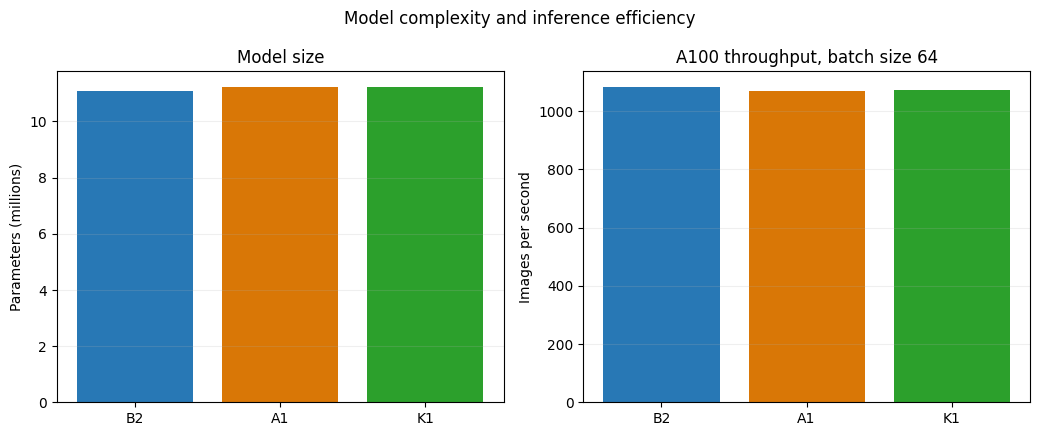


MODEL COMPLEXITY
variant     seed  checkpoint_epoch                                                checkpoint_sha256  parameters  trainable_parameters  buffer_elements  state_size_mib  checkpoint_file_mib  additional_parameters_vs_b2  parameter_change_vs_b2_percent
     B2 20260914                14 ef65aa1a03a64ea12c4b977553ce1644f21f59dcf22ed4b6a3dbaddb8b00d8d8    11084382              11084382            43857       42.452087           128.390672                            0                        0.000000
     A1 20260913                26 2ffe069df5224725085e09bd83934ffcd77b0cfa1ab4a943cac031327715317d    11218162              11218162            43857       42.962418           129.929551                       133780                        1.206923
     K1 20260914                30 c92038f6ad7edbcc69b9b9737784f691dc2ebb5646e0b62f38e1e4da21fe30cc    11218162              11218162            43857       42.962418           129.931382                       133780                   

In [1]:
# BLOCK 67 — Final A100 efficiency comparison
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.util
import json
import shutil
import statistics
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")

OUT = PROJECT / "efficiency_results" / f"a100_final_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/efficiency"
LOCAL = Path("/content/fetalgeo_efficiency")

for directory in (OUT, TABLES, FIGURES, LOCAL):
    directory.mkdir(parents=True, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError(
        "Keep or reconnect the A100 GPU and mount Drive."
    )

device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
print("GPU:", gpu_name, flush=True)

torch.set_num_threads(2)
torch.manual_seed(20260967)
torch.cuda.manual_seed_all(20260967)
torch.backends.cudnn.benchmark = True

VARIANTS = ["B2", "A1", "K1"]
BATCH_SIZES = [1, 64]
WARMUP_STEPS = 10
TRIALS = 5
TIMED_STEPS = {
    1: 50,
    64: 20,
}

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_module(name, source):
    local = LOCAL / f"{name}.py"
    shutil.copy2(source, local)
    spec = importlib.util.spec_from_file_location(name, local)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

def percentile(values, q):
    return float(np.percentile(np.asarray(values), q))

# Locate the validation-selected XAI checkpoints.
failure_dirs = sorted(
    path for path in (
        PROJECT / "evaluation_results"
    ).glob("failure_analysis_*")
    if (path / "xai_checkpoint_selection.csv").is_file()
)
if not failure_dirs:
    raise FileNotFoundError("Block 63 checkpoint selection was not found.")

selection_path = failure_dirs[-1] / "xai_checkpoint_selection.csv"
selection = pd.read_csv(selection_path).set_index("variant")
if set(selection.index) != set(VARIANTS):
    raise RuntimeError("Checkpoint selection is incomplete.")

model_path = (
    PROJECT / "code/model_v1_20260912T163435231628Z"
    / "fetalgeo_model.py"
)
loss_path = (
    PROJECT / "code/loss_v1_20260912T163743169701Z"
    / "fetalgeo_losses.py"
)
control_path = (
    PROJECT / "code/direct_aux_control_v1_20260913T052558437607Z"
    / "fetalgeo_direct_aux.py"
)

expected_hashes = {
    model_path:
        "53e94a627fd8b5f988ba7784ab40e4d218cc919b9c2b8e5bd80a76e3727eb34e",
    loss_path:
        "eb4521e43329c0dc88452682a690bdf7211ea9e054bf2d219615cad263002d1f",
    control_path:
        "a1fa2ff60baa49f34a84f93a010014ac756867153647ed5e45b4a4df34ae6799",
}
for path, expected in expected_hashes.items():
    if sha256_file(path) != expected:
        raise RuntimeError(f"Source verification failed: {path}")

model_module = load_module("fetalgeo_model", model_path)
loss_module = load_module("fetalgeo_losses", loss_path)
control_module = load_module("fetalgeo_direct_aux", control_path)

def make_model(variant):
    if variant == "K1":
        return control_module.DirectAuxControl(pretrained=False)
    return model_module.FetalGeo(
        geometry=(variant == "A1"),
        pretrained=False,
    )

mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
    device=device,
)[None, :, None, None]
std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
    device=device,
)[None, :, None, None]

records = []
model_rows = []

for variant in VARIANTS:
    row = selection.loc[variant]
    checkpoint_path = Path(row["checkpoint_path"])

    if sha256_file(checkpoint_path) != row["checkpoint_sha256"]:
        raise RuntimeError(f"Checkpoint hash mismatch: {variant}")

    print(
        f"\nLoading {variant}, seed {int(row['seed'])}, "
        f"epoch {int(row['best_epoch'])}...",
        flush=True,
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )
    model = make_model(variant)
    model.load_state_dict(
        checkpoint["model"],
        strict=True,
    )
    model = model.to(device).eval()

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
    )
    trainable_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    buffer_count = sum(
        buffer.numel()
        for buffer in model.buffers()
    )
    state_bytes = sum(
        tensor.numel() * tensor.element_size()
        for tensor in model.state_dict().values()
    )

    model_rows.append({
        "variant": variant,
        "seed": int(row["seed"]),
        "checkpoint_epoch": int(row["best_epoch"]),
        "checkpoint_sha256": row["checkpoint_sha256"],
        "parameters": parameter_count,
        "trainable_parameters": trainable_count,
        "buffer_elements": buffer_count,
        "state_size_mib": state_bytes / (1024 ** 2),
        "checkpoint_file_mib": (
            checkpoint_path.stat().st_size / (1024 ** 2)
        ),
    })

    for batch_size in BATCH_SIZES:
        print(
            f"Benchmarking {variant}, batch size {batch_size}...",
            flush=True,
        )

        generator = torch.Generator(
            device=device
        ).manual_seed(
            20260967 + 1000 * VARIANTS.index(variant)
            + batch_size
        )
        inputs = torch.rand(
            batch_size,
            3,
            256,
            256,
            generator=generator,
            device=device,
            dtype=torch.float32,
        )
        inputs = (inputs - mean) / std

        # Confirm output structure before timing.
        with torch.inference_mode():
            with torch.autocast(
                "cuda",
                dtype=torch.bfloat16,
            ):
                output = model(inputs)

        expected_local = (batch_size, 5, 2, 2)
        if tuple(output["local_points"].shape) != expected_local:
            raise RuntimeError(
                f"Unexpected local output shape for {variant}."
            )
        if not torch.isfinite(
            output["local_points"]
        ).all():
            raise RuntimeError("Nonfinite benchmark output.")
        del output

        # Warmup outside all timing and memory measurements.
        with torch.inference_mode():
            for _ in range(WARMUP_STEPS):
                with torch.autocast(
                    "cuda",
                    dtype=torch.bfloat16,
                ):
                    _ = model(inputs)
        torch.cuda.synchronize()

        trial_seconds = []
        trial_peak_gib = []

        for trial in range(TRIALS):
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats(device)
            torch.cuda.synchronize()
            started = time.perf_counter()

            with torch.inference_mode():
                for _ in range(TIMED_STEPS[batch_size]):
                    with torch.autocast(
                        "cuda",
                        dtype=torch.bfloat16,
                    ):
                        output = model(inputs)

            torch.cuda.synchronize()
            elapsed = time.perf_counter() - started
            peak_gib = (
                torch.cuda.max_memory_allocated(device)
                / (1024 ** 3)
            )
            trial_seconds.append(elapsed)
            trial_peak_gib.append(peak_gib)

            print(
                f"  trial {trial + 1}/{TRIALS}: "
                f"{elapsed:.3f}s",
                flush=True,
            )

        median_seconds = statistics.median(
            trial_seconds
        )
        steps = TIMED_STEPS[batch_size]
        step_seconds = median_seconds / steps
        image_seconds = step_seconds / batch_size

        records.append({
            "variant": variant,
            "batch_size": batch_size,
            "precision": "bfloat16 autocast",
            "warmup_steps": WARMUP_STEPS,
            "timed_steps_per_trial": steps,
            "trials": TRIALS,
            "median_total_seconds": median_seconds,
            "trial_total_seconds_q25": percentile(
                trial_seconds, 25
            ),
            "trial_total_seconds_q75": percentile(
                trial_seconds, 75
            ),
            "median_step_milliseconds": (
                step_seconds * 1000
            ),
            "median_image_latency_milliseconds": (
                image_seconds * 1000
            ),
            "median_images_per_second": (
                batch_size / step_seconds
            ),
            "peak_allocated_gpu_gib_median": (
                statistics.median(trial_peak_gib)
            ),
            "peak_allocated_gpu_gib_maximum": max(
                trial_peak_gib
            ),
        })

        del inputs, output
        torch.cuda.empty_cache()

    del checkpoint, model
    torch.cuda.empty_cache()

benchmark = pd.DataFrame(records)
model_summary = pd.DataFrame(model_rows)

# Calculate overhead relative to the B2 baseline at the same batch size.
baseline = benchmark.loc[
    benchmark["variant"].eq("B2"),
    [
        "batch_size",
        "median_step_milliseconds",
        "median_images_per_second",
        "peak_allocated_gpu_gib_median",
    ],
].rename(columns={
    "median_step_milliseconds":
        "b2_step_milliseconds",
    "median_images_per_second":
        "b2_images_per_second",
    "peak_allocated_gpu_gib_median":
        "b2_peak_gib",
})

benchmark = benchmark.merge(
    baseline,
    on="batch_size",
    how="left",
    validate="many_to_one",
)
benchmark["step_time_change_vs_b2_percent"] = (
    (
        benchmark["median_step_milliseconds"]
        / benchmark["b2_step_milliseconds"]
        - 1.0
    ) * 100.0
)
benchmark["throughput_change_vs_b2_percent"] = (
    (
        benchmark["median_images_per_second"]
        / benchmark["b2_images_per_second"]
        - 1.0
    ) * 100.0
)
benchmark["memory_change_vs_b2_gib"] = (
    benchmark["peak_allocated_gpu_gib_median"]
    - benchmark["b2_peak_gib"]
)

baseline_parameters = int(
    model_summary.loc[
        model_summary["variant"].eq("B2"),
        "parameters",
    ].iloc[0]
)
model_summary["additional_parameters_vs_b2"] = (
    model_summary["parameters"] - baseline_parameters
)
model_summary["parameter_change_vs_b2_percent"] = (
    model_summary["additional_parameters_vs_b2"]
    / baseline_parameters
    * 100.0
)

benchmark_path = OUT / "inference_benchmark.csv"
model_path_out = OUT / "model_complexity.csv"
benchmark.to_csv(benchmark_path, index=False)
model_summary.to_csv(model_path_out, index=False)

paper_table = TABLES / f"model_efficiency_{STAMP}.csv"
paper_models = TABLES / f"model_complexity_{STAMP}.csv"
benchmark.to_csv(paper_table, index=False)
model_summary.to_csv(paper_models, index=False)

# Figure: parameters and throughput.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

axes[0].bar(
    model_summary["variant"],
    model_summary["parameters"] / 1e6,
    color=["#2878b5", "#d97706", "#2ca02c"],
)
axes[0].set_ylabel("Parameters (millions)")
axes[0].set_title("Model size")
axes[0].grid(axis="y", alpha=0.2)

batch64 = benchmark.loc[
    benchmark["batch_size"].eq(64)
].set_index("variant").loc[VARIANTS]
axes[1].bar(
    batch64.index,
    batch64["median_images_per_second"],
    color=["#2878b5", "#d97706", "#2ca02c"],
)
axes[1].set_ylabel("Images per second")
axes[1].set_title("A100 throughput, batch size 64")
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle(
    "Model complexity and inference efficiency"
)
fig.tight_layout()

png = FIGURES / f"model_efficiency_{STAMP}.png"
pdf = FIGURES / f"model_efficiency_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "FINAL_A100_EFFICIENCY_BENCHMARK_COMPLETED",
    "gpu": gpu_name,
    "torch_version": torch.__version__,
    "precision": "bfloat16 autocast",
    "input_shape": [3, 256, 256],
    "batch_sizes": BATCH_SIZES,
    "warmup_steps": WARMUP_STEPS,
    "trials": TRIALS,
    "timed_steps": TIMED_STEPS,
    "models": VARIANTS,
    "checkpoint_selection": (
        "Median validation-performing seed from Block 63"
    ),
    "training_performed": False,
    "limitations": [
        "Synthetic in-memory inputs exclude disk loading.",
        "Measurements are specific to this A100 and software environment.",
        "Batch-size-1 throughput is not end-to-end clinical latency.",
        "No preprocessing or checkpoint-loading time is included.",
        "Parameter count does not measure all deployment costs.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 67 — final efficiency benchmark\n"
            f"- GPU: {gpu_name}.\n"
            "- Benchmarked B2, A1 and K1 at batch sizes 1 and 64.\n"
            "- Used bfloat16 inference and five timed trials.\n"
            "- Excluded preprocessing and disk loading.\n"
            f"- Efficiency table: `{paper_table}`.\n"
            f"- Complexity table: `{paper_models}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 67,
        "artifact_type": "efficiency_table",
        "path": str(paper_table),
    },
    {
        "block": 67,
        "artifact_type": "complexity_table",
        "path": str(paper_models),
    },
    {
        "block": 67,
        "artifact_type": "efficiency_figure_png",
        "path": str(png),
    },
    {
        "block": 67,
        "artifact_type": "efficiency_figure_pdf",
        "path": str(pdf),
    },
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nMODEL COMPLEXITY")
print(model_summary.to_string(index=False))

print("\nA100 INFERENCE EFFICIENCY")
print(
    benchmark[[
        "variant",
        "batch_size",
        "median_step_milliseconds",
        "median_image_latency_milliseconds",
        "median_images_per_second",
        "peak_allocated_gpu_gib_median",
        "step_time_change_vs_b2_percent",
    ]].to_string(index=False)
)

print(f"\nSaved efficiency analysis: {OUT}")
print("\nBLOCK 67 COMPLETED — GPU may now be disconnected")

Calibration fields verified equivalent: ['calibration_candidate', 'calibration_available']
Using calibration flag: calibration_candidate
Reading held-out image dimensions from cache...
Checking B2, seed 20260912...
Checking B2, seed 20260913...
Checking B2, seed 20260914...
Checking A1, seed 20260912...
Checking A1, seed 20260913...
Checking A1, seed 20260914...
Checking K1, seed 20260912...
Checking K1, seed 20260913...
Checking K1, seed 20260914...


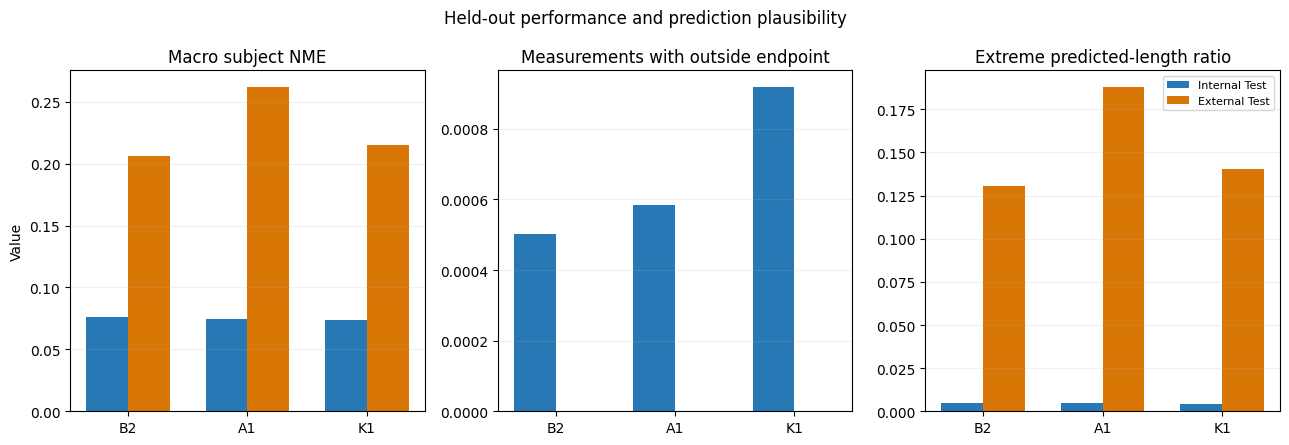


HELD-OUT ROBUSTNESS SUMMARY
         role variant  seeds  primary_nme_mean  primary_nme_seed_sd  calibrated_subset_nme_mean  calibrated_subset_nme_seed_sd  calibrated_minus_primary_nme  prediction_outside_rate  outside_endpoint_rate  median_predicted_length_ratio  extreme_length_ratio_rate  duplicate_sensitivity  duplicate_minus_primary_nme
external_test      A1      3          0.262225             0.063433                    0.246215                       0.045768                     -0.016009                 0.000000               0.000000                       0.794757                   0.188198               0.262225                     0.000000
external_test      B2      3          0.206460             0.018088                    0.198032                       0.027420                     -0.008429                 0.000000               0.000000                       0.821178                   0.130781               0.206460                     0.000000
external_test      K1     

In [2]:
# BLOCK 68 — Held-out robustness and plausibility diagnostics (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
CORE = PROJECT / "evaluation_results/core_604bd46665aff864"
PROTOCOL = PROJECT / "evaluation_protocols/core_v1_20260913T060139117731Z"
CACHE = PROJECT / "data/cache/letterbox256_9093c1bcf56fd66fa9a6"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = CORE / f"robustness_{STAMP}"
TABLES = PROJECT / "paper_artifacts/tables/data"
FIGURES = PROJECT / "paper_artifacts/figures/robustness"

for directory in (OUT, TABLES, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

VARIANTS = ["B2", "A1", "K1"]
SEEDS = [20260912, 20260913, 20260914]
ROLES = ["internal_test", "external_test"]
MEASUREMENTS = ["ofd", "bpd", "tad", "apad", "fl"]

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def parse_bool(series):
    values = series.astype(str).str.strip().str.lower()
    if not values.isin(["true", "false", "1", "0"]).all():
        raise RuntimeError(f"Unexpected Boolean values in {series.name}.")
    return values.isin(["true", "1"])

def macro_subject_nme(frame):
    subject_scores = frame.groupby(
        ["measurement", "subject_key"],
        as_index=False,
    )["nme"].mean()
    measurement_scores = subject_scores.groupby(
        "measurement",
        as_index=False,
    )["nme"].mean()

    if set(measurement_scores["measurement"]) != set(MEASUREMENTS):
        return np.nan

    return float(
        measurement_scores.set_index(
            "measurement"
        ).loc[MEASUREMENTS, "nme"].mean()
    )

protocol_hash = sha256_file(PROTOCOL / "evaluation_protocol.json")
if protocol_hash != (
    "604bd46665aff8641ff5e20f7c28104faaa78f57c7adae85175e75ded70dfdb6"
):
    raise RuntimeError("Core protocol checksum mismatch.")

policy = pd.read_csv(
    PROTOCOL / "evaluation_measurements.csv",
    dtype=str,
)
policy = policy.loc[
    policy["role"].isin(ROLES)
].copy()

required = {
    "record_id", "measurement", "role",
    "source", "subject_key", "primary_eligible",
}
missing = required - set(policy.columns)
if missing:
    raise RuntimeError(f"Protocol columns missing: {sorted(missing)}")

policy["primary_eligible"] = parse_bool(
    policy["primary_eligible"]
)

calibration_candidates = [
    name for name in (
        "calibration_candidate",
        "calibration_available",
        "calibration_eligible",
    )
    if name in policy.columns
]
if not calibration_candidates:
    raise RuntimeError(
        "No calibration flag found. "
        f"Protocol columns: {policy.columns.tolist()}"
    )

parsed_calibration = {
    name: parse_bool(policy[name])
    for name in calibration_candidates
}

# Multiple saved calibration fields are allowed only when identical.
reference_name = calibration_candidates[0]
reference_values = parsed_calibration[reference_name]

for name, values in parsed_calibration.items():
    if not values.equals(reference_values):
        disagreement = int((values != reference_values).sum())
        raise RuntimeError(
            f"Calibration fields {reference_name} and {name} "
            f"disagree on {disagreement} rows."
        )

calibration_column = (
    "calibration_candidate"
    if "calibration_candidate" in parsed_calibration
    else reference_name
)
policy["calibration_available"] = parsed_calibration[
    calibration_column
]

print(
    "Calibration fields verified equivalent:",
    calibration_candidates,
)
print("Using calibration flag:", calibration_column)


if policy.duplicated(["record_id", "measurement"]).any():
    raise RuntimeError("Duplicate protocol keys.")

# Load original image dimensions from the verified cache.
held_out_ids = sorted(policy["record_id"].unique())
cache_index = pd.read_csv(
    CACHE / "cache_index.csv",
    dtype=str,
)
if cache_index["record_id"].duplicated().any():
    raise RuntimeError("Cache index record IDs are not unique.")

cache_index = cache_index.set_index("record_id")
if not set(held_out_ids).issubset(cache_index.index):
    raise RuntimeError("Some held-out images are absent from the cache.")

dimension_rows = []
selection = cache_index.loc[held_out_ids]

print("Reading held-out image dimensions from cache...", flush=True)
for chunk_name, group in selection.groupby("chunk_file", sort=True):
    with np.load(CACHE / chunk_name, allow_pickle=False) as archive:
        for record_id, row in group.iterrows():
            position = int(row["position"])
            stored = archive["record_ids"][position]
            if isinstance(stored, bytes):
                stored = stored.decode()
            if str(stored) != record_id:
                raise RuntimeError("Cache record-position mismatch.")

            original_wh = np.asarray(
                archive["original_wh"][position],
                dtype=float,
            )
            if (
                original_wh.shape != (2,)
                or not np.isfinite(original_wh).all()
                or (original_wh <= 0).any()
            ):
                raise RuntimeError(
                    f"Invalid dimensions for {record_id}."
                )

            dimension_rows.append({
                "record_id": record_id,
                "image_width": float(original_wh[0]),
                "image_height": float(original_wh[1]),
            })

dimensions = pd.DataFrame(dimension_rows)
if dimensions["record_id"].duplicated().any():
    raise RuntimeError("Duplicate dimension records.")

policy_fields = policy[[
    "record_id", "measurement", "role", "source",
    "subject_key", "primary_eligible",
    "calibration_available",
]].copy()

all_predictions = []
receipts = []

for variant in VARIANTS:
    for seed in SEEDS:
        path = CORE / f"{variant}_seed{seed}_predictions.csv"
        if not path.is_file():
            raise FileNotFoundError(path)

        print(f"Checking {variant}, seed {seed}...", flush=True)
        frame = pd.read_csv(path)

        if frame.duplicated(["record_id", "measurement"]).any():
            raise RuntimeError(f"Duplicate prediction keys: {path.name}")

        frame = frame.loc[
            frame["role"].isin(ROLES)
        ].copy()

        # Use the protocol as the authoritative eligibility source.
        drop_columns = [
            column for column in (
                "primary_eligible",
                "calibration_available",
                "dependency_cluster",
            )
            if column in frame.columns
        ]
        frame = frame.drop(columns=drop_columns)

        frame = frame.merge(
            policy_fields,
            on=["record_id", "measurement"],
            how="inner",
            validate="one_to_one",
            suffixes=("_prediction", ""),
        )
        frame = frame.merge(
            dimensions,
            on="record_id",
            how="left",
            validate="many_to_one",
        )

        if frame[["image_width", "image_height"]].isna().any().any():
            raise RuntimeError("Missing image dimensions.")

        # Confirm any duplicate identity columns agree.
        for column in ("role", "source", "subject_key"):
            prediction_column = f"{column}_prediction"
            if prediction_column in frame.columns:
                if not (
                    frame[prediction_column].astype(str)
                    == frame[column].astype(str)
                ).all():
                    raise RuntimeError(
                        f"Prediction/protocol {column} mismatch."
                    )
                frame = frame.drop(columns=[prediction_column])

        frame = frame.loc[
            frame["primary_eligible"]
        ].copy()

        coordinate_columns = [
            "predicted_x1", "predicted_y1",
            "predicted_x2", "predicted_y2",
            "target_x1", "target_y1",
            "target_x2", "target_y2",
        ]
        for column in coordinate_columns + ["nme"]:
            frame[column] = pd.to_numeric(
                frame[column],
                errors="raise",
            )

        if not np.isfinite(
            frame[coordinate_columns + ["nme"]]
        ).all().all():
            raise RuntimeError("Nonfinite eligible prediction values.")

        predicted = frame[[
            "predicted_x1", "predicted_y1",
            "predicted_x2", "predicted_y2",
        ]].to_numpy().reshape(-1, 2, 2)
        target = frame[[
            "target_x1", "target_y1",
            "target_x2", "target_y2",
        ]].to_numpy().reshape(-1, 2, 2)

        widths = frame["image_width"].to_numpy()
        heights = frame["image_height"].to_numpy()

        endpoint_outside = (
            (predicted[:, :, 0] < 0)
            | (predicted[:, :, 0] > widths[:, None] - 1)
            | (predicted[:, :, 1] < 0)
            | (predicted[:, :, 1] > heights[:, None] - 1)
        )
        frame["prediction_has_outside_endpoint"] = (
            endpoint_outside.any(axis=1)
        )
        frame["outside_endpoint_count"] = (
            endpoint_outside.sum(axis=1)
        )

        predicted_length = np.linalg.norm(
            predicted[:, 1] - predicted[:, 0],
            axis=1,
        )
        target_length = np.linalg.norm(
            target[:, 1] - target[:, 0],
            axis=1,
        )
        if (
            not np.isfinite(target_length).all()
            or (target_length <= 0).any()
        ):
            raise RuntimeError("Invalid target lengths.")

        ratio = predicted_length / target_length
        frame["predicted_length_ratio"] = ratio
        frame["extreme_length_ratio"] = (
            (ratio < 0.5) | (ratio > 1.5)
        )
        frame["variant"] = variant
        frame["seed"] = seed

        all_predictions.append(frame)
        receipts.append({
            "variant": variant,
            "seed": seed,
            "path": str(path),
            "sha256": sha256_file(path),
            "eligible_rows": len(frame),
        })

data = pd.concat(all_predictions, ignore_index=True)

# Per-seed robustness results.
seed_rows = []
measurement_rows = []

for (variant, seed, role), frame in data.groupby(
    ["variant", "seed", "role"]
):
    primary_macro = macro_subject_nme(frame)
    calibrated = frame.loc[
        frame["calibration_available"]
    ]
    calibrated_macro = macro_subject_nme(calibrated)

    seed_rows.append({
        "variant": variant,
        "seed": seed,
        "role": role,
        "eligible_measurement_rows": len(frame),
        "calibrated_measurement_rows": len(calibrated),
        "primary_macro_subject_nme": primary_macro,
        "calibrated_subset_macro_subject_nme": calibrated_macro,
        "calibrated_minus_primary_nme": (
            calibrated_macro - primary_macro
        ),
        "prediction_outside_rate": float(
            frame["prediction_has_outside_endpoint"].mean()
        ),
        "outside_endpoint_rate": float(
            frame["outside_endpoint_count"].sum()
            / (2 * len(frame))
        ),
        "median_predicted_length_ratio": float(
            frame["predicted_length_ratio"].median()
        ),
        "length_ratio_q25": float(
            frame["predicted_length_ratio"].quantile(0.25)
        ),
        "length_ratio_q75": float(
            frame["predicted_length_ratio"].quantile(0.75)
        ),
        "extreme_length_ratio_rate": float(
            frame["extreme_length_ratio"].mean()
        ),
    })

    for measurement, part in frame.groupby("measurement"):
        measurement_rows.append({
            "variant": variant,
            "seed": seed,
            "role": role,
            "measurement": measurement,
            "measurement_rows": len(part),
            "mean_nme": float(part["nme"].mean()),
            "prediction_outside_rate": float(
                part["prediction_has_outside_endpoint"].mean()
            ),
            "median_predicted_length_ratio": float(
                part["predicted_length_ratio"].median()
            ),
            "extreme_length_ratio_rate": float(
                part["extreme_length_ratio"].mean()
            ),
        })

per_seed = pd.DataFrame(seed_rows)
per_measurement = pd.DataFrame(measurement_rows)

robustness_summary = per_seed.groupby([
    "role", "variant"
]).agg(
    seeds=("seed", "nunique"),
    primary_nme_mean=("primary_macro_subject_nme", "mean"),
    primary_nme_seed_sd=("primary_macro_subject_nme", "std"),
    calibrated_subset_nme_mean=(
        "calibrated_subset_macro_subject_nme", "mean"
    ),
    calibrated_subset_nme_seed_sd=(
        "calibrated_subset_macro_subject_nme", "std"
    ),
    calibrated_minus_primary_nme=(
        "calibrated_minus_primary_nme", "mean"
    ),
    prediction_outside_rate=(
        "prediction_outside_rate", "mean"
    ),
    outside_endpoint_rate=(
        "outside_endpoint_rate", "mean"
    ),
    median_predicted_length_ratio=(
        "median_predicted_length_ratio", "mean"
    ),
    extreme_length_ratio_rate=(
        "extreme_length_ratio_rate", "mean"
    ),
).reset_index()

measurement_summary = per_measurement.groupby([
    "role", "variant", "measurement"
]).agg(
    seeds=("seed", "nunique"),
    mean_nme=("mean_nme", "mean"),
    prediction_outside_rate=(
        "prediction_outside_rate", "mean"
    ),
    median_predicted_length_ratio=(
        "median_predicted_length_ratio", "mean"
    ),
    extreme_length_ratio_rate=(
        "extreme_length_ratio_rate", "mean"
    ),
).reset_index()

# Import the already-completed duplicate-sensitivity comparison.
analysis_dirs = sorted(
    path for path in CORE.glob("analysis_*")
    if (path / "macro_summary.csv").is_file()
)
if not analysis_dirs:
    raise FileNotFoundError("Block 40 macro summary was not found.")

block40 = analysis_dirs[-1]
macro = pd.read_csv(block40 / "macro_summary.csv")

required_macro = {
    "role", "policy", "variant", "mean_nme"
}
if not required_macro.issubset(macro.columns):
    raise RuntimeError(
        f"Unexpected Block 40 columns: {macro.columns.tolist()}"
    )

duplicate = macro.pivot_table(
    index=["role", "variant"],
    columns="policy",
    values="mean_nme",
    aggfunc="first",
).reset_index()

for required_policy in ("primary", "duplicate_sensitivity"):
    if required_policy not in duplicate.columns:
        raise RuntimeError(
            f"Missing Block 40 policy: {required_policy}"
        )

duplicate["duplicate_minus_primary_nme"] = (
    duplicate["duplicate_sensitivity"]
    - duplicate["primary"]
)

final_table = robustness_summary.merge(
    duplicate[[
        "role", "variant",
        "duplicate_sensitivity",
        "duplicate_minus_primary_nme",
    ]],
    on=["role", "variant"],
    how="left",
    validate="one_to_one",
)

per_seed.to_csv(
    OUT / "per_seed_robustness.csv",
    index=False,
)
per_measurement.to_csv(
    OUT / "per_seed_measurement_plausibility.csv",
    index=False,
)
robustness_summary.to_csv(
    OUT / "robustness_summary.csv",
    index=False,
)
measurement_summary.to_csv(
    OUT / "measurement_robustness_summary.csv",
    index=False,
)
duplicate.to_csv(
    OUT / "duplicate_sensitivity.csv",
    index=False,
)
pd.DataFrame(receipts).to_csv(
    OUT / "prediction_receipts.csv",
    index=False,
)

table_path = TABLES / f"held_out_robustness_{STAMP}.csv"
measurement_table = (
    TABLES / f"measurement_plausibility_{STAMP}.csv"
)
final_table.to_csv(table_path, index=False)
measurement_summary.to_csv(
    measurement_table,
    index=False,
)

# Figure with the primary performance and two plausibility diagnostics.
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 4.5),
)

metrics = [
    ("primary_nme_mean", "Macro subject NME"),
    ("prediction_outside_rate", "Measurements with outside endpoint"),
    ("extreme_length_ratio_rate", "Extreme predicted-length ratio"),
]

colors = {
    "internal_test": "#2878b5",
    "external_test": "#d97706",
}
width = 0.35
x = np.arange(len(VARIANTS))

for axis, (metric, title) in zip(axes, metrics):
    for role_index, role in enumerate(ROLES):
        values = (
            final_table.loc[
                final_table["role"].eq(role)
            ]
            .set_index("variant")
            .loc[VARIANTS, metric]
            .to_numpy()
        )
        axis.bar(
            x + (role_index - 0.5) * width,
            values,
            width,
            color=colors[role],
            label=role.replace("_", " ").title(),
        )

    axis.set_xticks(x)
    axis.set_xticklabels(VARIANTS)
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Value")
axes[-1].legend(fontsize=8)
fig.suptitle(
    "Held-out performance and prediction plausibility"
)
fig.tight_layout()

png = FIGURES / f"held_out_robustness_{STAMP}.png"
pdf = FIGURES / f"held_out_robustness_{STAMP}.pdf"
fig.savefig(png, dpi=300, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "HELD_OUT_ROBUSTNESS_CONSOLIDATED",
    "protocol_sha256": protocol_hash,
    "models": VARIANTS,
    "seeds": SEEDS,
    "roles": ROLES,
    "calibration_flag": calibration_column,
    "duplicate_sensitivity_source": str(block40),
    "primary_results_changed": False,
    "interpretation": {
        "calibrated_subset": (
            "Descriptive subset analysis; calibration availability "
            "may select a different case mix."
        ),
        "outside_endpoints": (
            "Predicted endpoint outside original image bounds."
        ),
        "extreme_length_ratio": (
            "Predicted-to-annotated length below 0.5 or above 1.5."
        ),
    },
    "limitations": [
        "Plausibility thresholds were not clinically validated.",
        "Calibrated-subset results may be selection-biased.",
        "Duplicate sensitivity retains uncertain patient provenance.",
        "Rates average three trained seeds.",
        "Diagnostics do not replace the primary NME analysis.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 68 — robustness consolidation\n"
            "- Combined primary, duplicate-sensitivity and calibrated-subset results.\n"
            "- Measured out-of-image endpoints and extreme length ratios.\n"
            "- Plausibility thresholds are descriptive, not clinical cutoffs.\n"
            "- Primary results remain unchanged.\n"
            f"- Main table: `{table_path}`.\n"
            f"- Measurement table: `{measurement_table}`.\n"
            f"- Figure: `{png}`.\n"
        )

index_path = PROJECT / "paper_artifacts/ARTIFACT_INDEX.csv"
entries = pd.DataFrame([
    {
        "block": 68,
        "artifact_type": "robustness_table",
        "path": str(table_path),
    },
    {
        "block": 68,
        "artifact_type": "measurement_plausibility_table",
        "path": str(measurement_table),
    },
    {
        "block": 68,
        "artifact_type": "robustness_figure_png",
        "path": str(png),
    },
    {
        "block": 68,
        "artifact_type": "robustness_figure_pdf",
        "path": str(pdf),
    },
])
if index_path.exists() and index_path.stat().st_size:
    entries = pd.concat(
        [pd.read_csv(index_path), entries],
        ignore_index=True,
        sort=False,
    )
entries.to_csv(index_path, index=False)

print("\nHELD-OUT ROBUSTNESS SUMMARY")
print(final_table.to_string(index=False))

print("\nMEASUREMENT-LEVEL PLAUSIBILITY")
print(measurement_summary.to_string(index=False))

print(f"\nSaved robustness analysis: {OUT}")
print("\nBLOCK 68 COMPLETED")

In [3]:
# BLOCK 69 — Audit and classify all paper artifact candidates (CPU)
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import pandas as pd
from PIL import Image

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
ARTIFACTS = PROJECT / "paper_artifacts"
STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ARTIFACTS / f"final_audit_{STAMP}"
OUT.mkdir(parents=True, exist_ok=False)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def classify(path, kind):
    text = path.as_posix().lower()

    rules = [
        ("data_and_splits", [
            "data", "split", "cohort", "coverage",
            "annotation", "duplicate", "coordinate",
        ]),
        ("development", [
            "development", "three_seed", "extended30",
            "training_curve", "pilot",
        ]),
        ("held_out_results", [
            "held_out", "core", "macro", "bootstrap",
            "forest", "source_measurement",
        ]),
        ("reference_comparison", [
            "reference", "published", "release",
        ]),
        ("training_source", [
            "training_source", "fp_only",
        ]),
        ("xai", [
            "xai", "gradcam", "attribution",
            "randomization",
        ]),
        ("efficiency", [
            "efficiency", "complexity", "throughput",
            "benchmark",
        ]),
        ("robustness", [
            "robustness", "plausibility", "calibrated",
            "sensitivity",
        ]),
    ]

    scores = {
        category: sum(token in text for token in tokens)
        for category, tokens in rules
    }
    best_score = max(scores.values())
    if best_score == 0:
        return "unclassified"
    return sorted(
        category for category, score in scores.items()
        if score == best_score
    )[0]

records = []

# Audit CSV tables.
for path in sorted(ARTIFACTS.rglob("*.csv")):
    if OUT in path.parents:
        continue
    if any(part.startswith("final_v") for part in path.parts):
        continue
    try:
        frame = pd.read_csv(path)
        status = "READABLE"
        rows = len(frame)
        columns = len(frame.columns)
        column_names = "|".join(map(str, frame.columns[:30]))
        error = ""
    except Exception as exc:
        status = "UNREADABLE"
        rows = None
        columns = None
        column_names = ""
        error = f"{type(exc).__name__}: {exc}"

    records.append({
        "artifact_kind": "table",
        "category": classify(path, "table"),
        "path": str(path),
        "relative_path": str(path.relative_to(ARTIFACTS)),
        "extension": path.suffix.lower(),
        "bytes": path.stat().st_size,
        "modified_timestamp": path.stat().st_mtime,
        "sha256": sha256_file(path),
        "status": status,
        "rows": rows,
        "columns": columns,
        "column_names": column_names,
        "width": None,
        "height": None,
        "error": error,
    })

# Audit PNG figures.
for path in sorted(ARTIFACTS.rglob("*.png")):
    if OUT in path.parents:
        continue
    if any(part.startswith("final_v") for part in path.parts):
        continue
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            width, height = image.size
        status = "READABLE"
        error = ""
    except Exception as exc:
        width, height = None, None
        status = "UNREADABLE"
        error = f"{type(exc).__name__}: {exc}"

    records.append({
        "artifact_kind": "figure",
        "category": classify(path, "figure"),
        "path": str(path),
        "relative_path": str(path.relative_to(ARTIFACTS)),
        "extension": path.suffix.lower(),
        "bytes": path.stat().st_size,
        "modified_timestamp": path.stat().st_mtime,
        "sha256": sha256_file(path),
        "status": status,
        "rows": None,
        "columns": None,
        "column_names": "",
        "width": width,
        "height": height,
        "error": error,
    })

inventory = pd.DataFrame(records)
if inventory.empty:
    raise RuntimeError("No candidate paper artifacts were found.")

inventory["duplicate_sha256"] = inventory.duplicated(
    ["artifact_kind", "sha256"],
    keep=False,
)
inventory["latest_in_category"] = False

readable = inventory.loc[
    inventory["status"].eq("READABLE")
].copy()

for (kind, category), group in readable.groupby(
    ["artifact_kind", "category"]
):
    latest_index = group["modified_timestamp"].idxmax()
    inventory.loc[latest_index, "latest_in_category"] = True

inventory_path = OUT / "artifact_inventory.csv"
inventory.to_csv(inventory_path, index=False)

# Collapse exact copies so the final curation does not count duplicates.
unique = readable.sort_values(
    ["modified_timestamp", "path"],
    ascending=[False, True],
).drop_duplicates(
    ["artifact_kind", "sha256"],
    keep="first",
)
unique.to_csv(OUT / "unique_readable_artifacts.csv", index=False)

summary = unique.groupby(
    ["artifact_kind", "category"]
).agg(
    unique_artifacts=("path", "size"),
    newest_modified_timestamp=("modified_timestamp", "max"),
).reset_index()
summary.to_csv(OUT / "category_summary.csv", index=False)

# Print the newest candidates in each category for final selection.
shortlist_rows = []
for (kind, category), group in unique.groupby(
    ["artifact_kind", "category"],
    sort=True,
):
    newest = group.sort_values(
        ["modified_timestamp", "bytes"],
        ascending=[False, False],
    ).head(5)
    for rank, row in enumerate(
        newest.itertuples(),
        start=1,
    ):
        shortlist_rows.append({
            "artifact_kind": kind,
            "category": category,
            "rank_by_recency": rank,
            "relative_path": row.relative_path,
            "bytes": row.bytes,
            "rows": row.rows,
            "columns": row.columns,
            "width": row.width,
            "height": row.height,
            "sha256": row.sha256,
        })

shortlist = pd.DataFrame(shortlist_rows)
shortlist.to_csv(OUT / "curation_shortlist.csv", index=False)

unreadable = inventory.loc[
    inventory["status"].ne("READABLE")
].copy()
unreadable.to_csv(OUT / "unreadable_artifacts.csv", index=False)

report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "PAPER_ARTIFACT_AUDIT_COMPLETED",
    "inventory_directory": str(OUT),
    "candidate_tables": int(
        (inventory["artifact_kind"] == "table").sum()
    ),
    "candidate_figures": int(
        (inventory["artifact_kind"] == "figure").sum()
    ),
    "unique_readable_tables": int(
        (unique["artifact_kind"] == "table").sum()
    ),
    "unique_readable_figures": int(
        (unique["artifact_kind"] == "figure").sum()
    ),
    "unreadable_artifacts": len(unreadable),
    "exact_duplicate_files": int(
        inventory["duplicate_sha256"].sum()
    ),
    "planned_final_tables": 12,
    "planned_final_figures": 12,
    "selection_policy": [
        "Prefer final held-out analyses over pilot outputs.",
        "Prefer three-seed results over single-seed results.",
        "Preserve core confirmatory and post-hoc exploratory labels.",
        "Do not count exact duplicate files twice.",
        "Include only figures and tables that support manuscript claims.",
        "Retain diagnostic artifacts outside the final paper collection.",
    ],
}
(OUT / "summary.json").write_text(
    json.dumps(report, indent=2),
    encoding="utf-8",
)

results_path = PROJECT / "FETALGEO_RESULTS.md"
if results_path.exists():
    with results_path.open("a", encoding="utf-8") as handle:
        handle.write(
            "\n\n### Block 69 — paper artifact audit\n"
            f"- Unique readable tables: "
            f"{report['unique_readable_tables']}.\n"
            f"- Unique readable figures: "
            f"{report['unique_readable_figures']}.\n"
            f"- Unreadable artifacts: "
            f"{report['unreadable_artifacts']}.\n"
            "- Final target: 12 tables and 12 figures.\n"
            f"- Curation shortlist: "
            f"`{OUT / 'curation_shortlist.csv'}`.\n"
        )

print("\nARTIFACT CATEGORY SUMMARY")
print(summary.to_string(index=False))

print("\nNEWEST CURATION CANDIDATES")
print(shortlistSubstitute if False else shortlist.to_string(index=False))

print("\nSUMMARY")
print(json.dumps(report, indent=2))
print("\nBLOCK 69 COMPLETED")


ARTIFACT CATEGORY SUMMARY
artifact_kind             category  unique_artifacts  newest_modified_timestamp
       figure      data_and_splits                 1               1789226645.0
       figure          development                 3               1789233751.0
       figure           efficiency                 1               1789316111.0
       figure     held_out_results                 3               1789316407.0
       figure reference_comparison                 2               1789300820.0
       figure      training_source                 3               1789314652.0
       figure         unclassified                 9               1789280389.0
       figure                  xai                 9               1789315805.0
        table      data_and_splits                67               1789316406.0
        table          development                 2               1789236438.0
        table reference_comparison                 2               1789288618.0
        table

In [5]:
# ============================================================
# BLOCK 70 — FINAL PAPER ARTIFACT CURATION
# CPU ONLY — NO GPU REQUIRED
# Produces exactly 12 tables and 12 figures
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re
import shutil

import pandas as pd
from PIL import Image

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
TABLE_ROOT = PAPER / "tables" / "data"
FIGURE_ROOT = PAPER / "figures"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
FINAL_DIR = PAPER / f"final_submission_v1_{STAMP}"
FINAL_TABLES = FINAL_DIR / "tables"
FINAL_FIGURES = FINAL_DIR / "figures"

FINAL_TABLES.mkdir(parents=True, exist_ok=False)
FINAL_FIGURES.mkdir(parents=True, exist_ok=False)

if not TABLE_ROOT.is_dir():
    raise FileNotFoundError(TABLE_ROOT)

if not FIGURE_ROOT.is_dir():
    raise FileNotFoundError(FIGURE_ROOT)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def normalized_name(path):
    return re.sub(r"[^a-z0-9]+", "_", path.name.lower())


def all_source_tables():
    files = []
    for path in TABLE_ROOT.rglob("*.csv"):
        if "final_submission" not in str(path).lower():
            files.append(path)
    return sorted(set(files))


def all_source_figures():
    files = []
    for path in FIGURE_ROOT.rglob("*.png"):
        if "final_submission" not in str(path).lower():
            files.append(path)
    return sorted(set(files))


TABLE_FILES = all_source_tables()
FIGURE_FILES = all_source_figures()

print(f"Candidate tables: {len(TABLE_FILES)}")
print(f"Candidate figures: {len(FIGURE_FILES)}")


def read_table_columns(path):
    try:
        return set(pd.read_csv(path, nrows=3).columns.astype(str))
    except Exception:
        return set()


def choose_table(
    label,
    include_groups,
    required_columns=None,
    exclude_terms=None,
):
    """
    include_groups:
        List of lists. A candidate must contain every term from at least
        one alternative group in its full relative path.
    """
    required_columns = set(required_columns or [])
    exclude_terms = [x.lower() for x in (exclude_terms or [])]

    matches = []

    for path in TABLE_FILES:
        relative = str(path.relative_to(PAPER)).replace("\\", "/").lower()

        if any(term in relative for term in exclude_terms):
            continue

        name_match = any(
            all(term.lower() in relative for term in group)
            for group in include_groups
        )
        if not name_match:
            continue

        columns = read_table_columns(path)
        if required_columns and not required_columns.issubset(columns):
            continue

        matches.append(path)

    if not matches:
        nearby = [
            str(p.relative_to(PAPER))
            for p in TABLE_FILES
            if any(
                any(term.lower() in str(p).lower() for term in group)
                for group in include_groups
            )
        ]

        raise RuntimeError(
            f"\nCannot locate table for {label}.\n"
            f"Requested patterns: {include_groups}\n"
            f"Required columns: {sorted(required_columns)}\n"
            f"Nearby candidates:\n" +
            "\n".join(nearby[:30])
        )

    matches.sort(key=lambda p: (p.stat().st_mtime_ns, str(p)))
    selected = matches[-1]

    if len(matches) > 1:
        print(
            f"{label}: selected newest of {len(matches)} candidates:\n"
            f"  {selected.relative_to(PAPER)}"
        )
    else:
        print(f"{label}: {selected.relative_to(PAPER)}")

    return selected


def choose_figure(label, include_groups, exclude_terms=None):
    exclude_terms = [x.lower() for x in (exclude_terms or [])]
    matches = []

    for path in FIGURE_FILES:
        relative = str(path.relative_to(PAPER)).replace("\\", "/").lower()

        if any(term in relative for term in exclude_terms):
            continue

        if any(
            all(term.lower() in relative for term in group)
            for group in include_groups
        ):
            matches.append(path)

    if not matches:
        nearby = [
            str(p.relative_to(PAPER))
            for p in FIGURE_FILES
            if any(
                any(term.lower() in str(p).lower() for term in group)
                for group in include_groups
            )
        ]

        raise RuntimeError(
            f"\nCannot locate figure for {label}.\n"
            f"Requested patterns: {include_groups}\n"
            f"Nearby candidates:\n" +
            "\n".join(nearby[:30])
        )

    matches.sort(key=lambda p: (p.stat().st_mtime_ns, str(p)))
    selected = matches[-1]

    if len(matches) > 1:
        print(
            f"{label}: selected newest of {len(matches)} candidates:\n"
            f"  {selected.relative_to(PAPER)}"
        )
    else:
        print(f"{label}: {selected.relative_to(PAPER)}")

    return selected


# ------------------------------------------------------------
# 1. SELECT 12 TABLES
# ------------------------------------------------------------

table_specs = [
    {
        "number": "T01",
        "title": "Dataset and split composition",
        "destination": "table_01_dataset_and_split_composition.csv",
        "source": choose_table(
            "T01 dataset and splits",
              [
    ["tab01", "split", "summary"],
    ["split", "summary"],
    ["split", "count"],
    ["role", "count"],
    ["cohort", "summary"],
    ["dataset", "summary"],
],
            exclude_terms=[
                "xai", "efficiency", "robustness",
                "training_source", "reference"
            ],
        ),
        "status": "Methods",
    },
    {
        "number": "T02",
        "title": "Eligible training measurements",
        "destination": "table_02_training_measurement_coverage.csv",
        "source": choose_table(
            "T02 training coverage",
            [
                ["training", "coverage"],
                ["eligible", "measurement"],
                ["measurement", "eligibility"],
                ["training", "measurement"],
            ],
            exclude_terms=[
                "xai", "efficiency", "robustness",
                "reference", "held_out"
            ],
        ),
        "status": "Methods",
    },
    {
        "number": "T03",
        "title": "Three-seed augmented development results",
        "destination": "table_03_three_seed_development.csv",
        "source": choose_table(
            "T03 development summary",
            [
                ["three_seed", "summary"],
                ["augmented", "summary"],
                ["three", "seed", "development"],
            ],
            required_columns={"variant", "seeds"},
        ),
        "status": "Development",
    },
    {
        "number": "T04",
        "title": "Held-out macro NME results",
        "destination": "table_04_heldout_macro_results.csv",
        "source": choose_table(
            "T04 held-out macro results",
            [
                ["held", "out", "macro"],
                ["macro", "results"],
                ["heldout", "results"],
            ],
            required_columns={"variant"},
            exclude_terms=["failure", "robustness", "plausibility"],
        ),
        "status": "Primary held-out",
    },
    {
        "number": "T05",
        "title": "Held-out per-measurement results",
        "destination": "table_05_heldout_per_measurement.csv",
        "source": choose_table(
            "T05 held-out per-measurement results",
            [
                ["held", "out", "measurement"],
                ["descriptive", "measurement"],
                ["source", "measurement", "breakdown"],
                ["per", "measurement", "held"],
            ],
            required_columns={"variant", "measurement"},
            exclude_terms=["training_source"],
        ),
        "status": "Primary descriptive",
    },
    {
        "number": "T06",
        "title": "Paired dependency-cluster bootstrap contrasts",
        "destination": "table_06_paired_bootstrap_intervals.csv",
        "source": choose_table(
            "T06 paired bootstrap",
            [
                ["paired", "bootstrap"],
                ["paired", "interval"],
                ["bootstrap", "contrast"],
            ],
            exclude_terms=["training_source", "xai"],
        ),
        "status": "Primary inference",
    },
    {
        "number": "T07",
        "title": "Published reference comparison",
        "destination": "table_07_published_reference_comparison.csv",
        "source": choose_table(
            "T07 published reference",
            [
                ["published", "reference"],
                ["external", "contextual"],
                ["reference", "comparison"],
            ],
            exclude_terms=["agreement", "discrepancy"],
        ),
        "status": "Contextual comparison",
    },
    {
        "number": "T08",
        "title": "Training-source validation comparison",
        "destination": "table_08_training_source_validation.csv",
        "source": choose_table(
            "T08 training-source validation",
            [
                ["training_source", "validation"],
                ["fp_only", "validation"],
                ["training", "source", "comparison"],
            ],
            required_columns={"variant"},
            exclude_terms=["external", "bootstrap", "measurement"],
        ),
        "status": "Post-hoc exploratory",
    },
    {
        "number": "T09",
        "title": "Training-source external comparison",
        "destination": "table_09_training_source_external.csv",
        "source": choose_table(
            "T09 training-source external",
            [
                ["training_source", "external"],
                ["fp_only", "external"],
            ],
            required_columns={"variant"},
            exclude_terms=["bootstrap", "measurement"],
        ),
        "status": "Post-hoc exploratory",
    },
    {
        "number": "T10",
        "title": "Held-out failure and tail-error analysis",
        "destination": "table_10_failure_analysis.csv",
        "source": choose_table(
            "T10 failure analysis",
            [
                ["failure", "summary"],
                ["held", "out", "failure"],
                ["error", "distribution", "summary"],
            ],
            required_columns={"variant"},
        ),
        "status": "Descriptive",
    },
    {
        "number": "T11",
        "title": "Quantitative Grad-CAM analysis",
        "destination": "table_11_quantitative_xai.csv",
        "source": choose_table(
            "T11 quantitative XAI",
            [
                ["xai", "quantitative", "summary"],
                ["quantitative", "xai"],
            ],
            required_columns={"variant"},
        ),
        "status": "Exploratory XAI",
    },
    {
        "number": "T12",
        "title": "Model complexity and inference efficiency",
        "destination": "table_12_model_efficiency.csv",
        "source": choose_table(
            "T12 model efficiency",
            [
                ["model", "efficiency"],
                ["inference", "efficiency"],
            ],
            required_columns={"variant", "batch_size"},
        ),
        "status": "Efficiency",
    },
]

if len(table_specs) != 12:
    raise RuntimeError("Table specification count is not 12.")

selected_table_sources = [x["source"].resolve() for x in table_specs]
if len(set(selected_table_sources)) != 12:
    duplicates = pd.Series(
        [str(x) for x in selected_table_sources]
    ).value_counts()
    raise RuntimeError(
        "A source table was selected more than once:\n" +
        duplicates[duplicates > 1].to_string()
    )


# ------------------------------------------------------------
# 2. SELECT 12 FIGURES
# ------------------------------------------------------------

figure_specs = [
    {
        "number": "F01",
        "title": "Dataset and split composition",
        "destination": "figure_01_dataset_and_split_composition.png",
        "source": choose_figure(
            "F01 split composition",
            [["split", "count"]],
        ),
        "status": "Methods",
    },
    {
        "number": "F02",
        "title": "Spatial augmentation and landmark transformation",
        "destination": "figure_02_spatial_augmentation_examples.png",
        "source": choose_figure(
            "F02 augmentation examples",
            [["augmentation", "check"]],
        ),
        "status": "Methods",
    },
    {
        "number": "F03",
        "title": "Matched 30-epoch development trajectories",
        "destination": "figure_03_matched_development_training.png",
        "source": choose_figure(
            "F03 matched development",
            [["matched", "extended30"]],
        ),
        "status": "Development",
    },
    {
        "number": "F04",
        "title": "Held-out seed-level model comparison",
        "destination": "figure_04_heldout_seed_comparison.png",
        "source": choose_figure(
            "F04 held-out seed comparison",
            [["heldout", "seed", "comparison"]],
        ),
        "status": "Primary held-out",
    },
    {
        "number": "F05",
        "title": "Paired held-out bootstrap intervals",
        "destination": "figure_05_heldout_paired_intervals.png",
        "source": choose_figure(
            "F05 held-out intervals",
            [["heldout", "paired", "interval"]],
        ),
        "status": "Primary inference",
    },
    {
        "number": "F06",
        "title": "Training-source effects by measurement",
        "destination": "figure_06_training_source_by_measurement.png",
        "source": choose_figure(
            "F06 training source by measurement",
            [["training_source", "by_measurement"]],
        ),
        "status": "Post-hoc exploratory",
    },
    {
        "number": "F07",
        "title": "Contextual published-reference comparison",
        "destination": "figure_07_reference_contextual_comparison.png",
        "source": choose_figure(
            "F07 reference comparison",
            [["external", "contextual", "comparison"]],
        ),
        "status": "Contextual comparison",
    },
    {
        "number": "F08",
        "title": "Held-out localization-error distributions",
        "destination": "figure_08_heldout_error_distributions.png",
        "source": choose_figure(
            "F08 held-out error CDF",
            [["held_out", "error", "cdf"]],
        ),
        "status": "Descriptive",
    },
    {
        "number": "F09",
        "title": "Representative external Grad-CAM cases",
        "destination": "figure_09_external_gradcam_examples.png",
        "source": choose_figure(
            "F09 external Grad-CAM",
            [
                ["gradcam", "external_test", "ucl", "head"],
                ["gradcam", "external_test", "ucl", "abdomen"],
            ],
        ),
        "status": "Exploratory XAI",
    },
    {
        "number": "F10",
        "title": "Quantitative Grad-CAM localization",
        "destination": "figure_10_quantitative_xai.png",
        "source": choose_figure(
            "F10 quantitative XAI",
            [["xai", "quantitative"]],
        ),
        "status": "Exploratory XAI",
    },
    {
        "number": "F11",
        "title": "Grad-CAM parameter-randomization sanity check",
        "destination": "figure_11_xai_randomization_sanity.png",
        "source": choose_figure(
            "F11 XAI randomization",
            [["xai", "randomization", "sanity"]],
        ),
        "status": "XAI validation",
    },
    {
        "number": "F12",
        "title": "Model complexity and A100 inference efficiency",
        "destination": "figure_12_model_efficiency.png",
        "source": choose_figure(
            "F12 efficiency",
            [["model", "efficiency"]],
        ),
        "status": "Efficiency",
    },
]

if len(figure_specs) != 12:
    raise RuntimeError("Figure specification count is not 12.")

selected_figure_sources = [x["source"].resolve() for x in figure_specs]
if len(set(selected_figure_sources)) != 12:
    duplicates = pd.Series(
        [str(x) for x in selected_figure_sources]
    ).value_counts()
    raise RuntimeError(
        "A source figure was selected more than once:\n" +
        duplicates[duplicates > 1].to_string()
    )


# ------------------------------------------------------------
# 3. COPY AND VERIFY TABLES
# ------------------------------------------------------------

manifest_rows = []

for spec in table_specs:
    source = spec["source"]
    destination = FINAL_TABLES / spec["destination"]

    frame = pd.read_csv(source)
    if frame.empty:
        raise RuntimeError(f"Selected table is empty: {source}")

    # Re-save as a clean, portable CSV.
    frame.to_csv(destination, index=False)

    check = pd.read_csv(destination)
    if check.shape != frame.shape:
        raise RuntimeError(
            f"Table shape changed during curation: {source}"
        )

    manifest_rows.append({
        "artifact_number": spec["number"],
        "artifact_kind": "table",
        "title": spec["title"],
        "analysis_status": spec["status"],
        "final_relative_path": str(
            destination.relative_to(FINAL_DIR)
        ).replace("\\", "/"),
        "source_relative_path": str(
            source.relative_to(PROJECT)
        ).replace("\\", "/"),
        "rows": int(frame.shape[0]),
        "columns": int(frame.shape[1]),
        "width_px": pd.NA,
        "height_px": pd.NA,
        "source_sha256": sha256_file(source),
        "final_sha256": sha256_file(destination),
        "bytes": destination.stat().st_size,
    })


# ------------------------------------------------------------
# 4. COPY AND VERIFY FIGURES
# ------------------------------------------------------------

for spec in figure_specs:
    source = spec["source"]
    destination = FINAL_FIGURES / spec["destination"]

    # Verify source before copying.
    with Image.open(source) as image:
        image.verify()

    shutil.copy2(source, destination)

    with Image.open(destination) as image:
        image.load()
        width, height = image.size

    if width < 1000 or height < 700:
        raise RuntimeError(
            f"Figure resolution is unexpectedly small: "
            f"{destination} ({width}x{height})"
        )

    if sha256_file(source) != sha256_file(destination):
        raise RuntimeError(
            f"Figure hash changed during copying: {source}"
        )

    manifest_rows.append({
        "artifact_number": spec["number"],
        "artifact_kind": "figure",
        "title": spec["title"],
        "analysis_status": spec["status"],
        "final_relative_path": str(
            destination.relative_to(FINAL_DIR)
        ).replace("\\", "/"),
        "source_relative_path": str(
            source.relative_to(PROJECT)
        ).replace("\\", "/"),
        "rows": pd.NA,
        "columns": pd.NA,
        "width_px": int(width),
        "height_px": int(height),
        "source_sha256": sha256_file(source),
        "final_sha256": sha256_file(destination),
        "bytes": destination.stat().st_size,
    })


# ------------------------------------------------------------
# 5. FINAL MANIFEST AND VALIDATION
# ------------------------------------------------------------

manifest = pd.DataFrame(manifest_rows)
manifest = manifest.sort_values(
    ["artifact_kind", "artifact_number"]
).reset_index(drop=True)

table_count = int((manifest["artifact_kind"] == "table").sum())
figure_count = int((manifest["artifact_kind"] == "figure").sum())

if table_count != 12:
    raise RuntimeError(f"Expected 12 tables, found {table_count}")

if figure_count != 12:
    raise RuntimeError(f"Expected 12 figures, found {figure_count}")

if manifest["final_sha256"].duplicated().any():
    duplicate_rows = manifest[
        manifest["final_sha256"].duplicated(keep=False)
    ]
    raise RuntimeError(
        "Exact duplicate artifacts entered the final collection:\n" +
        duplicate_rows[
            ["artifact_number", "final_relative_path", "final_sha256"]
        ].to_string(index=False)
    )

manifest_path = FINAL_DIR / "artifact_manifest.csv"
manifest.to_csv(manifest_path, index=False)

table_index = manifest[
    manifest["artifact_kind"] == "table"
][[
    "artifact_number",
    "title",
    "analysis_status",
    "final_relative_path",
    "rows",
    "columns",
    "final_sha256",
]]

figure_index = manifest[
    manifest["artifact_kind"] == "figure"
][[
    "artifact_number",
    "title",
    "analysis_status",
    "final_relative_path",
    "width_px",
    "height_px",
    "final_sha256",
]]

table_index.to_csv(FINAL_DIR / "table_index.csv", index=False)
figure_index.to_csv(FINAL_DIR / "figure_index.csv", index=False)

package_files = sorted(
    [
        p for p in FINAL_DIR.rglob("*")
        if p.is_file() and p.name != "package_checksums.sha256"
    ],
    key=lambda p: str(p.relative_to(FINAL_DIR))
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

(FINAL_DIR / "package_checksums.sha256").write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "FINAL_PAPER_ARTIFACT_COLLECTION_COMPLETED",
    "final_directory": str(FINAL_DIR),
    "tables": table_count,
    "figures": figure_count,
    "manifest": str(manifest_path),
    "checksum_file": str(
        FINAL_DIR / "package_checksums.sha256"
    ),
    "gpu_required": False,
    "primary_interpretation": (
        "A1 produced a small internal improvement relative to B2, "
        "but did not generalize better to the external UCL cohort. "
        "B2 remained the strongest external model."
    ),
    "reporting_constraints": [
        "Held-out results must not be used for further model tuning.",
        "Training-source experiments are post-hoc exploratory analyses.",
        "Published-reference comparison is contextual because training "
        "data and preprocessing differ.",
        "Grad-CAM analyses are descriptive and do not establish causal "
        "model reasoning.",
        "Do not claim external superiority for A1.",
    ],
}

summary_path = FINAL_DIR / "summary.json"
summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

# A convenient pointer without copying or deleting prior packages.
current_pointer = PAPER / "FINAL_SUBMISSION_CURRENT.json"
current_pointer.write_text(
    json.dumps({
        "created_utc": summary["created_utc"],
        "final_directory": str(FINAL_DIR),
        "manifest": str(manifest_path),
        "summary": str(summary_path),
    }, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------------------
# 6. APPEND TO THE EXISTING PROJECT RESULTS LOG
# ------------------------------------------------------------

results_entry = f"""

## Block 70 — Final paper artifact collection

Created: {summary["created_utc"]}

Status: `FINAL_PAPER_ARTIFACT_COLLECTION_COMPLETED`

Final collection: `{FINAL_DIR}`

- Tables: {table_count}
- Figures: {figure_count}
- Manifest: `{manifest_path}`
- Checksums: `{FINAL_DIR / "package_checksums.sha256"}`
- GPU required: no

Interpretation: A1 showed a small internal-test improvement relative to
B2, but it performed worse on the external UCL cohort. B2 remained the
strongest external model. The training-source analyses and XAI results
remain exploratory. The published-reference result is contextual because
its training data and annotation-derived preprocessing differ.

"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(results_entry)


# ------------------------------------------------------------
# 7. DISPLAY FINAL COLLECTION
# ------------------------------------------------------------

print("\nFINAL TABLES")
print(
    table_index[
        [
            "artifact_number",
            "title",
            "analysis_status",
            "rows",
            "columns",
        ]
    ].to_string(index=False)
)

print("\nFINAL FIGURES")
print(
    figure_index[
        [
            "artifact_number",
            "title",
            "analysis_status",
            "width_px",
            "height_px",
        ]
    ].to_string(index=False)
)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 70 COMPLETED — EXACTLY 12 TABLES AND 12 FIGURES")
print("GPU NOT REQUIRED")

Candidate tables: 61
Candidate figures: 32
T01 dataset and splits: tables/data/tab01_split_summary_block5_20260912T152404429909Z.csv
T02 training coverage: selected newest of 2 candidates:
  tables/data/training_source_by_measurement_20260913T154704377847Z.csv
T03 development summary: selected newest of 3 candidates:
  tables/data/three_seed_joint_control_20260913T054851245970Z_summary.csv
T04 held-out macro results: tables/data/heldout_macro_20260913T061734883035Z.csv
T05 held-out per-measurement results: tables/data/heldout_measurements_20260913T061734883035Z.csv
T06 paired bootstrap: tables/data/heldout_paired_intervals_20260913T061734883035Z.csv
T07 published reference: selected newest of 3 candidates:
  tables/data/external_contextual_comparison_20260913T120016526072UTC.csv
T08 training-source validation: tables/data/training_source_validation_20260913T145437862379Z.csv
T09 training-source external: selected newest of 2 candidates:
  tables/data/training_source_external_paired_202

In [6]:
# ============================================================
# BLOCK 71 — SEMANTIC REPAIR, CAPTIONS, AND CLAIM MAPPING
# CPU ONLY — NO GPU REQUIRED
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil

import pandas as pd
from PIL import Image

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

if not POINTER.is_file():
    raise FileNotFoundError(POINTER)

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])
MANIFEST_PATH = FINAL_DIR / "artifact_manifest.csv"

if not FINAL_DIR.is_dir():
    raise FileNotFoundError(FINAL_DIR)

if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(MANIFEST_PATH)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


manifest = pd.read_csv(MANIFEST_PATH)

if len(manifest) != 24:
    raise RuntimeError(
        f"Expected 24 curated artifacts, found {len(manifest)}."
    )

if set(manifest["artifact_number"]) != {
    *[f"T{i:02d}" for i in range(1, 13)],
    *[f"F{i:02d}" for i in range(1, 13)],
}:
    raise RuntimeError("Unexpected artifact-number collection.")


# ------------------------------------------------------------
# 1. CORRECT SEMANTIC LABELS
# ------------------------------------------------------------

t02_mask = manifest["artifact_number"].eq("T02")
if t02_mask.sum() != 1:
    raise RuntimeError("Cannot uniquely identify T02.")

old_t02_relative = manifest.loc[
    t02_mask, "final_relative_path"
].iloc[0]

old_t02 = FINAL_DIR / old_t02_relative
new_t02 = (
    FINAL_DIR / "tables" /
    "table_02_training_source_by_measurement.csv"
)

if not old_t02.is_file():
    raise FileNotFoundError(old_t02)

t02_frame = pd.read_csv(old_t02)

required_t02 = {
    "variant",
    "measurement",
    "fp_hc18_nme",
    "fp_only_nme",
}

missing_t02 = required_t02 - set(t02_frame.columns)
if missing_t02:
    raise RuntimeError(
        "T02 is not the expected per-measurement training-source "
        f"table. Missing columns: {sorted(missing_t02)}"
    )

if old_t02.resolve() != new_t02.resolve():
    if new_t02.exists():
        raise FileExistsError(new_t02)
    old_t02.rename(new_t02)

manifest.loc[t02_mask, "title"] = (
    "Per-measurement effect of removing HC18 training data"
)
manifest.loc[t02_mask, "analysis_status"] = (
    "Post-hoc exploratory"
)
manifest.loc[t02_mask, "final_relative_path"] = str(
    new_t02.relative_to(FINAL_DIR)
).replace("\\", "/")
manifest.loc[t02_mask, "final_sha256"] = sha256_file(new_t02)
manifest.loc[t02_mask, "bytes"] = new_t02.stat().st_size

# Clarify that T03 includes the capacity-matched K1 control.
manifest.loc[
    manifest["artifact_number"].eq("T03"), "title"
] = "Three-seed matched joint-auxiliary development results"

# T09 contains seed-level paired external results.
manifest.loc[
    manifest["artifact_number"].eq("T09"), "title"
] = "Seed-level training-source external comparison"


# ------------------------------------------------------------
# 2. MANUSCRIPT CAPTIONS
# ------------------------------------------------------------

captions = {
    "T01": (
        "Dataset composition and assigned analysis roles. Counts reflect "
        "the locked patient-safe provisional split and preserve the "
        "internal-validation, internal-test, external-test, and reserved "
        "roles used throughout the study."
    ),
    "T02": (
        "Post-hoc per-measurement effect of training with FP alone rather "
        "than FP and HC18. Positive NME differences indicate worse UCL "
        "performance after removing HC18. Pointwise intervals are "
        "exploratory and are not multiplicity adjusted."
    ),
    "T03": (
        "Three-seed internal-validation results for B2, A1, and the "
        "capacity-matched K1 direct-endpoint auxiliary control. "
        "Checkpoints were selected using the local endpoint branch."
    ),
    "T04": (
        "Locked held-out macro subject NME for the internal and external "
        "test cohorts. Values summarize the three independently trained "
        "seeds; lower NME indicates better localization."
    ),
    "T05": (
        "Descriptive held-out NME by source, model, and fetal biometric "
        "measurement. These subgroup results support interpretation of "
        "the aggregate outcome and are not separate confirmatory tests."
    ),
    "T06": (
        "Paired dependency-cluster bootstrap contrasts with pointwise "
        "95% percentile intervals. Negative A1-minus-B2 values favor A1; "
        "positive values favor B2."
    ),
    "T07": (
        "Contextual comparison with the released FP reference models on "
        "UCL. The reference used FP-only training, five measurement-"
        "specific models, and annotation-derived crops, so this is not a "
        "matched head-to-head comparison."
    ),
    "T08": (
        "Internal-validation comparison between mixed FP+HC18 training "
        "and FP-only training using the same validation cohort. This "
        "analysis was conducted after the primary held-out evaluation."
    ),
    "T09": (
        "Seed-level external UCL comparison between models trained on "
        "FP+HC18 and models trained on FP alone. Positive FP-only-minus-"
        "mixed values favor mixed-source training."
    ),
    "T10": (
        "Held-out localization-error distribution and threshold-based "
        "failure rates. Thresholds describe the tails of the observed "
        "NME distribution and are not clinical acceptability limits."
    ),
    "T11": (
        "Quantitative Grad-CAM localization on the predefined low-, "
        "median-, and high-error cases. Attribution mass, enrichment, "
        "pointing rate, and entropy are descriptive XAI measures."
    ),
    "T12": (
        "Parameter count, memory use, and A100 inference efficiency for "
        "the validation-selected B2, A1, and K1 checkpoints."
    ),
    "F01": (
        "Dataset and split composition under the locked provisional "
        "subject and dependency-cluster policy."
    ),
    "F02": (
        "Examples of spatial augmentation with matched transformation of "
        "the annotated biometric endpoints."
    ),
    "F03": (
        "Matched 30-epoch internal-validation trajectories. Curves show "
        "macro subject NME from the local endpoint predictions."
    ),
    "F04": (
        "Seed-level held-out results. Points represent separately trained "
        "seeds and horizontal marks represent model means."
    ),
    "F05": (
        "Paired held-out model differences with pointwise 95% dependency-"
        "cluster bootstrap intervals. Negative A1 differences favor A1."
    ),
    "F06": (
        "Exploratory change in external UCL NME after removing HC18 from "
        "training, stratified by model and measurement."
    ),
    "F07": (
        "Contextual external comparison with the published FP reference. "
        "Training data, preprocessing, and model organization differ."
    ),
    "F08": (
        "Empirical cumulative distributions of seed-averaged held-out "
        "measurement-record NME for the internal and external cohorts."
    ),
    "F09": (
        "Representative external UCL Grad-CAM examples selected before "
        "XAI generation from low-, median-, and high-error strata."
    ),
    "F10": (
        "Quantitative Grad-CAM attribution within annotated geometry and "
        "endpoint regions for predefined internal and external cases."
    ),
    "F11": (
        "Grad-CAM parameter-randomization sanity checks. Fully randomized "
        "models show low similarity and attribution overlap with the "
        "trained-model maps."
    ),
    "F12": (
        "Model size and A100 inference throughput. A1 and K1 add "
        "approximately 1.2% parameters relative to B2."
    ),
}

caption_rows = []

for row in manifest.itertuples(index=False):
    caption_rows.append({
        "artifact_number": row.artifact_number,
        "artifact_kind": row.artifact_kind,
        "title": row.title,
        "analysis_status": row.analysis_status,
        "caption": captions[row.artifact_number],
        "final_relative_path": row.final_relative_path,
    })

caption_frame = pd.DataFrame(caption_rows).sort_values(
    ["artifact_kind", "artifact_number"]
)

caption_path = FINAL_DIR / "manuscript_captions.csv"
caption_frame.to_csv(caption_path, index=False)


# ------------------------------------------------------------
# 3. CLAIM-TO-EVIDENCE MAP
# ------------------------------------------------------------

claims = pd.DataFrame([
    {
        "claim_id": "C01",
        "claim": (
            "A1 improved internal held-out localization relative to B2."
        ),
        "classification": "Primary supported finding",
        "supporting_artifacts": "T04; T06; F04; F05",
        "permitted_wording": (
            "A1 produced a small improvement over B2 on the internal "
            "held-out cohort."
        ),
        "prohibited_overstatement": (
            "A1 was universally superior to B2."
        ),
    },
    {
        "claim_id": "C02",
        "claim": (
            "A1 did not improve external UCL generalization."
        ),
        "classification": "Primary supported finding",
        "supporting_artifacts": "T04; T06; F04; F05",
        "permitted_wording": (
            "A1 performed worse than B2 on the external UCL cohort."
        ),
        "prohibited_overstatement": (
            "Geometry supervision improved cross-centre generalization."
        ),
    },
    {
        "claim_id": "C03",
        "claim": (
            "The internal A1 advantage was not distinct from the "
            "capacity-matched K1 auxiliary control."
        ),
        "classification": "Primary supported finding",
        "supporting_artifacts": "T03; T04; T06",
        "permitted_wording": (
            "A1 did not show a clear internal held-out advantage over K1."
        ),
        "prohibited_overstatement": (
            "Explicit geometry was proven better than additional "
            "auxiliary capacity."
        ),
    },
    {
        "claim_id": "C04",
        "claim": (
            "Mixed FP+HC18 training generalized better to UCL than "
            "FP-only training."
        ),
        "classification": "Post-hoc exploratory finding",
        "supporting_artifacts": "T02; T08; T09; F06",
        "permitted_wording": (
            "In a post-hoc experiment, removing HC18 generally worsened "
            "external UCL performance."
        ),
        "prohibited_overstatement": (
            "HC18 causally guarantees improved external performance."
        ),
    },
    {
        "claim_id": "C05",
        "claim": (
            "A1 Grad-CAM maps assigned more attribution to annotated "
            "geometry regions than B2 on the predefined cases."
        ),
        "classification": "Exploratory XAI finding",
        "supporting_artifacts": "T11; F09; F10; F11",
        "permitted_wording": (
            "On predefined cases, A1 showed greater Grad-CAM attribution "
            "within annotated geometry regions than B2."
        ),
        "prohibited_overstatement": (
            "Grad-CAM proves that A1 reasons causally from anatomy."
        ),
    },
    {
        "claim_id": "C06",
        "claim": (
            "The auxiliary models add little computational overhead."
        ),
        "classification": "Efficiency finding",
        "supporting_artifacts": "T12; F12",
        "permitted_wording": (
            "A1 and K1 added approximately 1.2% parameters and about "
            "1–2% A100 inference-step time relative to B2."
        ),
        "prohibited_overstatement": (
            "The models have identical computational cost."
        ),
    },
    {
        "claim_id": "C07",
        "claim": (
            "FetalGeo outperformed the released reference predictions "
            "in the contextual UCL evaluation."
        ),
        "classification": "Contextual finding only",
        "supporting_artifacts": "T07; F07",
        "permitted_wording": (
            "FetalGeo models had lower NME in this contextual UCL "
            "evaluation, although training data and preprocessing differed."
        ),
        "prohibited_overstatement": (
            "FetalGeo definitively outperformed the published method in a "
            "controlled comparison."
        ),
    },
])

claims_path = FINAL_DIR / "claim_evidence_map.csv"
claims.to_csv(claims_path, index=False)


# ------------------------------------------------------------
# 4. REWRITE INDEXES AND VERIFY ALL ARTIFACTS
# ------------------------------------------------------------

manifest = manifest.sort_values(
    ["artifact_kind", "artifact_number"]
).reset_index(drop=True)

for index, row in manifest.iterrows():
    path = FINAL_DIR / row["final_relative_path"]

    if not path.is_file():
        raise FileNotFoundError(path)

    if row["artifact_kind"] == "table":
        frame = pd.read_csv(path)
        if frame.empty:
            raise RuntimeError(f"Empty final table: {path}")

        manifest.loc[index, "rows"] = frame.shape[0]
        manifest.loc[index, "columns"] = frame.shape[1]

    elif row["artifact_kind"] == "figure":
        with Image.open(path) as image:
            image.load()
            width, height = image.size

        if width < 1000 or height < 700:
            raise RuntimeError(
                f"Unexpectedly small figure: {path}, {width}x{height}"
            )

        manifest.loc[index, "width_px"] = width
        manifest.loc[index, "height_px"] = height

    else:
        raise RuntimeError(
            f"Unknown artifact kind: {row['artifact_kind']}"
        )

    manifest.loc[index, "final_sha256"] = sha256_file(path)
    manifest.loc[index, "bytes"] = path.stat().st_size

manifest.to_csv(MANIFEST_PATH, index=False)

table_index = manifest[
    manifest["artifact_kind"].eq("table")
][[
    "artifact_number",
    "title",
    "analysis_status",
    "final_relative_path",
    "rows",
    "columns",
    "final_sha256",
]]

figure_index = manifest[
    manifest["artifact_kind"].eq("figure")
][[
    "artifact_number",
    "title",
    "analysis_status",
    "final_relative_path",
    "width_px",
    "height_px",
    "final_sha256",
]]

table_index.to_csv(FINAL_DIR / "table_index.csv", index=False)
figure_index.to_csv(FINAL_DIR / "figure_index.csv", index=False)

if len(table_index) != 12 or len(figure_index) != 12:
    raise RuntimeError(
        f"Final count failure: {len(table_index)} tables and "
        f"{len(figure_index)} figures."
    )


# ------------------------------------------------------------
# 5. REBUILD PACKAGE CHECKSUMS
# ------------------------------------------------------------

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda p: str(p.relative_to(FINAL_DIR))
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 6. UPDATE SUMMARY AND PROJECT LOG
# ------------------------------------------------------------

summary_path = FINAL_DIR / "summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))

summary.update({
    "semantic_audit_utc": datetime.now(timezone.utc).isoformat(),
    "status": "FINAL_PAPER_ARTIFACTS_SEMANTICALLY_VERIFIED",
    "tables": 12,
    "figures": 12,
    "captions": str(caption_path),
    "claim_evidence_map": str(claims_path),
    "semantic_repairs": [
        (
            "T02 renamed to accurately describe the selected "
            "per-measurement training-source analysis."
        ),
        (
            "T03 clarified as the three-seed matched joint-auxiliary "
            "development comparison."
        ),
        (
            "T09 clarified as a seed-level external training-source "
            "comparison."
        ),
    ],
})

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

# Rebuild checksums once more because summary.json changed.
package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda p: str(p.relative_to(FINAL_DIR))
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)

log_entry = f"""

## Block 71 — Artifact semantic verification

Status: `FINAL_PAPER_ARTIFACTS_SEMANTICALLY_VERIFIED`

- Final directory: `{FINAL_DIR}`
- Final tables: 12
- Final figures: 12
- Manuscript captions: `{caption_path}`
- Claim-to-evidence map: `{claims_path}`
- Package checksums rebuilt: `{checksum_path}`

T02 was corrected to describe its actual content: the post-hoc
per-measurement training-source analysis. The final evidence package now
contains explicit permitted wording and prohibited overstatements for the
main internal, external, XAI, efficiency, and contextual-reference claims.
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# 7. DISPLAY FINAL AUDIT
# ------------------------------------------------------------

print("\nCORRECTED TABLE INDEX")
print(
    table_index[
        [
            "artifact_number",
            "title",
            "analysis_status",
            "rows",
            "columns",
        ]
    ].to_string(index=False)
)

print("\nFIGURE INDEX")
print(
    figure_index[
        [
            "artifact_number",
            "title",
            "analysis_status",
            "width_px",
            "height_px",
        ]
    ].to_string(index=False)
)

print("\nCLAIM-TO-EVIDENCE MAP")
print(
    claims[
        [
            "claim_id",
            "classification",
            "supporting_artifacts",
            "permitted_wording",
        ]
    ].to_string(index=False)
)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 71 COMPLETED — FINAL ARTIFACT PACKAGE VERIFIED")
print("GPU NOT REQUIRED")


CORRECTED TABLE INDEX
artifact_number                                                  title       analysis_status  rows  columns
            T01                          Dataset and split composition               Methods  15.0      5.0
            T02  Per-measurement effect of removing HC18 training data  Post-hoc exploratory  15.0     10.0
            T03 Three-seed matched joint-auxiliary development results           Development   3.0      6.0
            T04                             Held-out macro NME results      Primary held-out  12.0      6.0
            T05                       Held-out per-measurement results   Primary descriptive  60.0      6.0
            T06          Paired dependency-cluster bootstrap contrasts     Primary inference   8.0      9.0
            T07                         Published reference comparison Contextual comparison   5.0      7.0
            T08                  Training-source validation comparison  Post-hoc exploratory   6.0      6.0
     

In [8]:
# ============================================================
# BLOCK 72 — NUMERICAL CLAIM REGISTRY AND RESULTS DRAFT
# CPU ONLY — NO NEW EXPERIMENTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import numpy as np
import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

if not POINTER.is_file():
    raise FileNotFoundError(POINTER)

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])
MANIFEST_PATH = FINAL_DIR / "artifact_manifest.csv"

if not FINAL_DIR.is_dir():
    raise FileNotFoundError(FINAL_DIR)

manifest = pd.read_csv(MANIFEST_PATH)


def artifact_path(number):
    rows = manifest.loc[
        manifest["artifact_number"].eq(number),
        "final_relative_path",
    ]

    if len(rows) != 1:
        raise RuntimeError(
            f"Cannot uniquely locate artifact {number}."
        )

    path = FINAL_DIR / rows.iloc[0]

    if not path.is_file():
        raise FileNotFoundError(path)

    return path


def load_table(number):
    path = artifact_path(number)
    frame = pd.read_csv(path)

    if frame.empty:
        raise RuntimeError(f"Table {number} is empty.")

    return frame


def find_column(frame, alternatives, label, required=True):
    columns = list(frame.columns)
    normalized = {
        re.sub(r"[^a-z0-9]+", "_", str(c).lower()).strip("_"): c
        for c in columns
    }

    for alternative in alternatives:
        key = re.sub(
            r"[^a-z0-9]+", "_", alternative.lower()
        ).strip("_")

        if key in normalized:
            return normalized[key]

    if required:
        raise RuntimeError(
            f"Cannot identify {label}. Columns: {columns}"
        )

    return None


def fmt(value, digits=4):
    if pd.isna(value):
        return "NA"
    return f"{float(value):.{digits}f}"


def signed_fmt(value, digits=4):
    if pd.isna(value):
        return "NA"
    return f"{float(value):+.{digits}f}"


def percent(value, digits=1):
    if pd.isna(value):
        return "NA"
    return f"{100.0 * float(value):.{digits}f}%"


def append_claim(
    claim_id,
    section,
    status,
    claim,
    value,
    evidence,
    caution,
):
    claim_rows.append({
        "claim_id": claim_id,
        "section": section,
        "analysis_status": status,
        "claim": claim,
        "reported_value": value,
        "supporting_artifacts": evidence,
        "required_caution": caution,
    })


# ------------------------------------------------------------
# 1. LOAD CURATED RESULTS
# ------------------------------------------------------------

development = load_table("T03")
heldout = load_table("T04")
paired = load_table("T06")
reference = load_table("T07")
source_validation = load_table("T08")
source_external = load_table("T09")
failure = load_table("T10")
xai = load_table("T11")
efficiency = load_table("T12")


# ------------------------------------------------------------
# 2. DEVELOPMENT RESULTS
# ------------------------------------------------------------

dev_variant = find_column(
    development, ["variant"], "development variant"
)
dev_mean = find_column(
    development,
    ["best_nme_mean", "best_validation_nme_mean"],
    "development best-NME mean",
)
dev_sd = find_column(
    development,
    ["best_nme_seed_sd", "best_validation_nme_seed_sd"],
    "development seed SD",
)
dev_seeds = find_column(
    development, ["seeds"], "development seed count"
)

dev_lookup = development.set_index(dev_variant)

for required_variant in ["B2", "A1", "K1"]:
    if required_variant not in dev_lookup.index:
        raise RuntimeError(
            f"{required_variant} missing from development table."
        )

b2_dev = float(dev_lookup.loc["B2", dev_mean])
a1_dev = float(dev_lookup.loc["A1", dev_mean])
k1_dev = float(dev_lookup.loc["K1", dev_mean])

b2_dev_sd = float(dev_lookup.loc["B2", dev_sd])
a1_dev_sd = float(dev_lookup.loc["A1", dev_sd])
k1_dev_sd = float(dev_lookup.loc["K1", dev_sd])

seed_counts = {
    int(float(dev_lookup.loc[v, dev_seeds]))
    for v in ["B2", "A1", "K1"]
}

if seed_counts != {3}:
    raise RuntimeError(
        f"Expected three seeds per model, found {seed_counts}."
    )


# ------------------------------------------------------------
# 3. HELD-OUT PRIMARY RESULTS
# ------------------------------------------------------------

held_role = find_column(heldout, ["role"], "held-out role")
held_variant = find_column(
    heldout, ["variant"], "held-out variant"
)
held_mean = find_column(
    heldout, ["mean_nme"], "held-out mean NME"
)
held_sd = find_column(
    heldout, ["seed_sd", "mean_nme_seed_sd"], "held-out seed SD"
)
held_policy = find_column(
    heldout, ["policy"], "held-out policy", required=False
)

primary_heldout = heldout.copy()

if held_policy is not None:
    primary_rows = primary_heldout[
        primary_heldout[held_policy].astype(str).str.lower().eq("primary")
    ]
    if not primary_rows.empty:
        primary_heldout = primary_rows

held_lookup = primary_heldout.set_index(
    [held_role, held_variant]
)

required_heldout = [
    ("internal_test", "B2"),
    ("internal_test", "A1"),
    ("internal_test", "K1"),
    ("external_test", "B2"),
    ("external_test", "A1"),
    ("external_test", "K1"),
]

for key in required_heldout:
    if key not in held_lookup.index:
        raise RuntimeError(
            f"Missing held-out result: {key}"
        )


def held_value(role, variant, column):
    value = held_lookup.loc[(role, variant), column]

    if isinstance(value, pd.Series):
        value = value.iloc[0]

    return float(value)


internal = {
    variant: {
        "mean": held_value(
            "internal_test", variant, held_mean
        ),
        "sd": held_value(
            "internal_test", variant, held_sd
        ),
    }
    for variant in ["B2", "A1", "K1"]
}

external = {
    variant: {
        "mean": held_value(
            "external_test", variant, held_mean
        ),
        "sd": held_value(
            "external_test", variant, held_sd
        ),
    }
    for variant in ["B2", "A1", "K1"]
}


# ------------------------------------------------------------
# 4. BOOTSTRAP CONTRASTS
# ------------------------------------------------------------

pair_role = find_column(paired, ["role"], "paired role")
pair_contrast = find_column(
    paired, ["contrast"], "paired contrast"
)
pair_mean = find_column(
    paired,
    ["mean_paired_difference", "mean_difference"],
    "paired mean difference",
)
pair_low = find_column(
    paired, ["ci95_lower", "ci_lower"], "CI lower"
)
pair_high = find_column(
    paired, ["ci95_upper", "ci_upper"], "CI upper"
)
pair_policy = find_column(
    paired, ["policy"], "paired policy", required=False
)

primary_paired = paired.copy()

if pair_policy is not None:
    rows = primary_paired[
        primary_paired[pair_policy].astype(str).str.lower().eq("primary")
    ]
    if not rows.empty:
        primary_paired = rows


def contrast_row(role, contrast):
    candidates = primary_paired[
        primary_paired[pair_role].astype(str).eq(role)
        & primary_paired[pair_contrast].astype(str).eq(contrast)
    ]

    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected one row for {role}, {contrast}; "
            f"found {len(candidates)}."
        )

    return candidates.iloc[0]


int_a1_b2 = contrast_row(
    "internal_test", "A1_minus_B2"
)
int_a1_k1 = contrast_row(
    "internal_test", "A1_minus_K1"
)
ext_a1_b2 = contrast_row(
    "external_test", "A1_minus_B2"
)
ext_a1_k1 = contrast_row(
    "external_test", "A1_minus_K1"
)


# ------------------------------------------------------------
# 5. TRAINING-SOURCE RESULTS
# ------------------------------------------------------------

sv_training = find_column(
    source_validation,
    ["training_data"],
    "training-data label",
)
sv_variant = find_column(
    source_validation, ["variant"], "source variant"
)
sv_best = find_column(
    source_validation,
    ["best_nme_mean"],
    "source-validation best NME",
)

source_validation_lookup = source_validation.set_index(
    [sv_training, sv_variant]
)


def source_val(training_data, variant):
    if (training_data, variant) not in source_validation_lookup.index:
        return np.nan

    value = source_validation_lookup.loc[
        (training_data, variant), sv_best
    ]

    if isinstance(value, pd.Series):
        value = value.iloc[0]

    return float(value)


mixed_dev = {
    v: source_val("FP + HC18", v)
    for v in ["B2", "A1", "K1"]
}
fp_dev = {
    v: source_val("FP only", v)
    for v in ["B2", "A1", "K1"]
}

se_variant = find_column(
    source_external, ["variant"], "source-external variant"
)
se_difference = find_column(
    source_external,
    ["fp_only_minus_mixed"],
    "source external difference",
)

source_external_means = (
    source_external
    .groupby(se_variant, as_index=False)[se_difference]
    .mean()
    .set_index(se_variant)[se_difference]
    .to_dict()
)


# ------------------------------------------------------------
# 6. FAILURE ANALYSIS
# ------------------------------------------------------------

fail_role = find_column(failure, ["role"], "failure role")
fail_variant = find_column(
    failure, ["variant"], "failure variant"
)
fail_rate_010 = find_column(
    failure,
    ["failure_rate_010"],
    "failure rate at NME 0.10",
)

failure_lookup = failure.set_index(
    [fail_role, fail_variant]
)


def failure_value(role, variant):
    value = failure_lookup.loc[
        (role, variant), fail_rate_010
    ]

    if isinstance(value, pd.Series):
        value = value.iloc[0]

    return float(value)


# ------------------------------------------------------------
# 7. XAI RESULTS
# ------------------------------------------------------------

xai_role = find_column(xai, ["role"], "XAI role")
xai_variant = find_column(xai, ["variant"], "XAI variant")
xai_geom = find_column(
    xai,
    ["geometry_mass_mean"],
    "XAI geometry attribution mass",
)
xai_cases = find_column(xai, ["cases"], "XAI case count")

xai_lookup = xai.set_index([xai_role, xai_variant])


def xai_value(role, variant, column):
    value = xai_lookup.loc[(role, variant), column]

    if isinstance(value, pd.Series):
        value = value.iloc[0]

    return float(value)


total_xai_cases = int(
    xai.groupby(xai_role)[xai_cases].first().sum()
)

internal_geom_difference = (
    xai_value("internal_test", "A1", xai_geom)
    - xai_value("internal_test", "B2", xai_geom)
)

external_geom_difference = (
    xai_value("external_test", "A1", xai_geom)
    - xai_value("external_test", "B2", xai_geom)
)


# ------------------------------------------------------------
# 8. COMPLEXITY AND EFFICIENCY RESULTS
# ------------------------------------------------------------

eff_variant = find_column(
    efficiency, ["variant"], "efficiency variant"
)
eff_batch = find_column(
    efficiency, ["batch_size"], "batch size"
)
eff_step_change = find_column(
    efficiency,
    ["step_time_change_vs_b2_percent"],
    "step-time change",
)
eff_throughput = find_column(
    efficiency,
    ["median_images_per_second"],
    "images per second",
)

eff_lookup = efficiency.set_index(
    [eff_variant, eff_batch]
)


def eff_value(variant, batch, column):
    value = eff_lookup.loc[(variant, batch), column]

    if isinstance(value, pd.Series):
        value = value.iloc[0]

    return float(value)


# Parameter counts are stored in the companion complexity table.
complexity_candidates = sorted(
    (
        PAPER / "tables" / "data"
    ).glob("model_complexity_*.csv"),
    key=lambda path: (path.stat().st_mtime_ns, str(path)),
)

if not complexity_candidates:
    raise FileNotFoundError(
        "No model_complexity_*.csv table was found."
    )

complexity_path = complexity_candidates[-1]
complexity = pd.read_csv(complexity_path)

complexity_variant = find_column(
    complexity, ["variant"], "complexity variant"
)
complexity_parameters = find_column(
    complexity, ["parameters"], "parameter count"
)

complexity_lookup = (
    complexity
    .drop_duplicates(subset=[complexity_variant])
    .set_index(complexity_variant)
)

for required_variant in ["B2", "A1", "K1"]:
    if required_variant not in complexity_lookup.index:
        raise RuntimeError(
            f"{required_variant} is missing from {complexity_path}."
        )


def parameter_value(variant):
    value = complexity_lookup.loc[
        variant, complexity_parameters
    ]

    if isinstance(value, pd.Series):
        value = value.iloc[0]

    return int(float(value))


b2_parameters = parameter_value("B2")
a1_parameters = parameter_value("A1")
k1_parameters = parameter_value("K1")

parameter_increase = (
    100.0 * (a1_parameters - b2_parameters) / b2_parameters
)

a1_step_change_1 = eff_value(
    "A1", 1, eff_step_change
)
a1_step_change_64 = eff_value(
    "A1", 64, eff_step_change
)
b2_throughput_64 = eff_value(
    "B2", 64, eff_throughput
)
a1_throughput_64 = eff_value(
    "A1", 64, eff_throughput
)

print(f"Complexity source: {complexity_path}")
print(
    f"Parameters: B2={b2_parameters:,}, "
    f"A1={a1_parameters:,}, K1={k1_parameters:,}"
)


# ------------------------------------------------------------
# 9. CONSTRUCT CLAIM REGISTRY
# ------------------------------------------------------------

claim_rows = []

append_claim(
    "R01",
    "Development",
    "Development",
    (
        "A1 achieved lower mean best internal-validation NME than B2."
    ),
    (
        f"A1 {fmt(a1_dev)} +/- {fmt(a1_dev_sd)}; "
        f"B2 {fmt(b2_dev)} +/- {fmt(b2_dev_sd)}"
    ),
    "T03; F03",
    "Checkpoint-selection evidence, not held-out performance.",
)

append_claim(
    "R02",
    "Development",
    "Development",
    (
        "K1 also improved development NME relative to B2."
    ),
    (
        f"K1 {fmt(k1_dev)} +/- {fmt(k1_dev_sd)}; "
        f"B2 {fmt(b2_dev)} +/- {fmt(b2_dev_sd)}"
    ),
    "T03; F03",
    "Does not isolate representation from auxiliary supervision.",
)

append_claim(
    "R03",
    "Internal test",
    "Primary",
    (
        "A1 modestly improved internal held-out NME relative to B2."
    ),
    (
        f"A1 {fmt(internal['A1']['mean'])} +/- "
        f"{fmt(internal['A1']['sd'])}; "
        f"B2 {fmt(internal['B2']['mean'])} +/- "
        f"{fmt(internal['B2']['sd'])}; "
        f"paired difference "
        f"{signed_fmt(int_a1_b2[pair_mean])}, "
        f"95% CI [{signed_fmt(int_a1_b2[pair_low])}, "
        f"{signed_fmt(int_a1_b2[pair_high])}]"
    ),
    "T04; T06; F04; F05",
    "The magnitude was small and applies to the internal cohort.",
)

append_claim(
    "R04",
    "Internal test",
    "Primary",
    (
        "A1 did not show a clear internal advantage over K1."
    ),
    (
        f"A1 {fmt(internal['A1']['mean'])}; "
        f"K1 {fmt(internal['K1']['mean'])}; "
        f"A1-minus-K1 {signed_fmt(int_a1_k1[pair_mean])}, "
        f"95% CI [{signed_fmt(int_a1_k1[pair_low])}, "
        f"{signed_fmt(int_a1_k1[pair_high])}]"
    ),
    "T04; T06; F04; F05",
    "The pointwise interval includes zero.",
)

append_claim(
    "R05",
    "External test",
    "Primary",
    (
        "A1 performed worse than B2 on the external UCL cohort."
    ),
    (
        f"A1 {fmt(external['A1']['mean'])} +/- "
        f"{fmt(external['A1']['sd'])}; "
        f"B2 {fmt(external['B2']['mean'])} +/- "
        f"{fmt(external['B2']['sd'])}; "
        f"paired difference "
        f"{signed_fmt(ext_a1_b2[pair_mean])}, "
        f"95% CI [{signed_fmt(ext_a1_b2[pair_low])}, "
        f"{signed_fmt(ext_a1_b2[pair_high])}]"
    ),
    "T04; T06; F04; F05",
    "External cohort is small and dependency identities are provisional.",
)

append_claim(
    "R06",
    "External test",
    "Primary",
    (
        "A1 also performed worse than K1 externally."
    ),
    (
        f"A1 {fmt(external['A1']['mean'])}; "
        f"K1 {fmt(external['K1']['mean'])}; "
        f"A1-minus-K1 {signed_fmt(ext_a1_k1[pair_mean])}, "
        f"95% CI [{signed_fmt(ext_a1_k1[pair_low])}, "
        f"{signed_fmt(ext_a1_k1[pair_high])}]"
    ),
    "T04; T06; F04; F05",
    "The external cohort contains only 19 dependency clusters.",
)

append_claim(
    "R07",
    "Failure analysis",
    "Descriptive",
    (
        "External errors exceeded NME 0.10 much more frequently "
        "than internal errors."
    ),
    (
        f"External B2 {percent(failure_value('external_test', 'B2'))}; "
        f"A1 {percent(failure_value('external_test', 'A1'))}; "
        f"K1 {percent(failure_value('external_test', 'K1'))}. "
        f"Internal B2 {percent(failure_value('internal_test', 'B2'))}; "
        f"A1 {percent(failure_value('internal_test', 'A1'))}; "
        f"K1 {percent(failure_value('internal_test', 'K1'))}."
    ),
    "T10; F08",
    "The threshold is descriptive and is not a clinical failure limit.",
)

append_claim(
    "R08",
    "Training-source analysis",
    "Post-hoc exploratory",
    (
        "Removing HC18 generally worsened external UCL performance."
    ),
    "; ".join(
        f"{variant} mean difference "
        f"{signed_fmt(source_external_means.get(variant, np.nan))}"
        for variant in ["B2", "A1", "K1"]
    ),
    "T02; T08; T09; F06",
    "This experiment was designed after examining primary UCL results.",
)

append_claim(
    "R09",
    "XAI",
    "Exploratory",
    (
        "A1 allocated more Grad-CAM mass to annotated geometry "
        "regions than B2 on predefined cases."
    ),
    (
        f"Internal A1-minus-B2 {signed_fmt(internal_geom_difference)}; "
        f"external A1-minus-B2 {signed_fmt(external_geom_difference)}; "
        f"{total_xai_cases} predefined cases"
    ),
    "T11; F09; F10; F11",
    "Grad-CAM is associative and does not prove causal reasoning.",
)

append_claim(
    "R10",
    "Efficiency",
    "Efficiency",
    (
        "A1 added limited parameter and inference-time overhead."
    ),
    (
        f"B2 {b2_parameters:,} parameters; "
        f"A1 {a1_parameters:,}; increase {parameter_increase:.2f}%; "
        f"A1 step-time change {a1_step_change_1:.2f}% at batch 1 "
        f"and {a1_step_change_64:.2f}% at batch 64"
    ),
    "T12; F12",
    "Timing applies to the tested A100 configuration.",
)

claims = pd.DataFrame(claim_rows)
claim_path = FINAL_DIR / "numerical_claim_registry.csv"
claims.to_csv(claim_path, index=False)


# ------------------------------------------------------------
# 10. MANUSCRIPT-READY RESULTS TEXT
# ------------------------------------------------------------

results_text = f"""
RESULTS DRAFT
=============

Development experiments
-----------------------

Across three matched augmented development runs, A1 achieved a mean
best internal-validation NME of {fmt(a1_dev)} (seed SD
{fmt(a1_dev_sd)}), compared with {fmt(b2_dev)} ({fmt(b2_dev_sd)})
for B2 and {fmt(k1_dev)} ({fmt(k1_dev_sd)}) for the capacity-matched
K1 direct-endpoint auxiliary control (Table T03; Figure F03).
Development-set checkpoint selection therefore favored both auxiliary
models over B2, with A1 giving the lowest mean validation NME. These
values were used only for development and checkpoint selection.

Locked held-out evaluation
--------------------------

On the internal held-out cohort, A1 achieved a macro subject NME of
{fmt(internal['A1']['mean'])} (seed SD {fmt(internal['A1']['sd'])}),
compared with {fmt(internal['B2']['mean'])}
({fmt(internal['B2']['sd'])}) for B2 and
{fmt(internal['K1']['mean'])} ({fmt(internal['K1']['sd'])}) for K1
(Table T04; Figure F04). The paired A1-minus-B2 difference was
{signed_fmt(int_a1_b2[pair_mean])}, with a pointwise 95% dependency-
cluster bootstrap interval of [{signed_fmt(int_a1_b2[pair_low])},
{signed_fmt(int_a1_b2[pair_high])}] (Table T06; Figure F05). Thus,
A1 produced a small improvement relative to B2 internally.

The paired A1-minus-K1 internal difference was
{signed_fmt(int_a1_k1[pair_mean])}, with a 95% interval of
[{signed_fmt(int_a1_k1[pair_low])},
{signed_fmt(int_a1_k1[pair_high])}]. The interval included zero,
providing no clear evidence that explicit geometry supervision
outperformed the capacity-matched direct auxiliary control internally.

External performance differed from the development and internal-test
pattern. On UCL, B2 achieved the lowest macro subject NME:
{fmt(external['B2']['mean'])} (seed SD {fmt(external['B2']['sd'])}),
compared with {fmt(external['K1']['mean'])}
({fmt(external['K1']['sd'])}) for K1 and
{fmt(external['A1']['mean'])} ({fmt(external['A1']['sd'])}) for A1.
The paired external A1-minus-B2 difference was
{signed_fmt(ext_a1_b2[pair_mean])}, with a 95% interval of
[{signed_fmt(ext_a1_b2[pair_low])},
{signed_fmt(ext_a1_b2[pair_high])}]. The A1-minus-K1 difference was
{signed_fmt(ext_a1_k1[pair_mean])}, with a 95% interval of
[{signed_fmt(ext_a1_k1[pair_low])},
{signed_fmt(ext_a1_k1[pair_high])}]. Geometry supervision therefore
did not improve cross-centre generalization in this evaluation.

Error distributions
-------------------

External errors had substantially heavier tails than internal errors
(Table T10; Figure F08). The proportion of records exceeding NME 0.10
was {percent(failure_value('external_test', 'B2'))} for B2,
{percent(failure_value('external_test', 'A1'))} for A1, and
{percent(failure_value('external_test', 'K1'))} for K1 externally.
The corresponding internal proportions were
{percent(failure_value('internal_test', 'B2'))},
{percent(failure_value('internal_test', 'A1'))}, and
{percent(failure_value('internal_test', 'K1'))}. These thresholds
describe the observed error distribution and should not be interpreted
as clinical acceptability criteria.

Post-hoc training-source analysis
---------------------------------

In the post-hoc training-source experiment, FP-only training produced
worse external UCL performance than mixed FP+HC18 training. The mean
FP-only-minus-mixed NME differences across seeds were
{signed_fmt(source_external_means.get('B2', np.nan))} for B2,
{signed_fmt(source_external_means.get('A1', np.nan))} for A1, and
{signed_fmt(source_external_means.get('K1', np.nan))} for K1
(Tables T02, T08, and T09; Figure F06). Because this experiment was
designed after the primary UCL evaluation, it is exploratory rather
than confirmatory.

Explainability analysis
-----------------------

Grad-CAM was evaluated on {total_xai_cases} predefined cases selected
from internal and external low-, median-, and high-error strata.
Relative to B2, A1 increased mean attribution mass within annotated
geometry regions by {signed_fmt(internal_geom_difference)} internally
and {signed_fmt(external_geom_difference)} externally (Table T11;
Figures F09 and F10). Fully randomized model parameters substantially
reduced similarity and top-attribution overlap with trained-model maps
(Figure F11). These results describe attribution localization and do
not demonstrate causal anatomical reasoning.

Efficiency
----------

B2 contained {b2_parameters:,} parameters, whereas A1 and K1 each
contained {a1_parameters:,}, an increase of approximately
{parameter_increase:.2f}% (Table T12; Figure F12). On the tested A100
GPU, A1 changed inference step time by {a1_step_change_1:.2f}% at
batch size 1 and {a1_step_change_64:.2f}% at batch size 64 relative
to B2. At batch size 64, measured throughput was
{b2_throughput_64:.1f} images/s for B2 and
{a1_throughput_64:.1f} images/s for A1.

Contextual published-reference evaluation
-----------------------------------------

The released FP reference predictions produced a substantially higher
UCL macro NME than the FetalGeo models in the contextual analysis
(Table T07; Figure F07). This comparison is not controlled: the
reference used FP-only training, five measurement-specific models,
and annotation-derived crops, whereas FetalGeo used mixed FP+HC18
training and full-image letterboxing. It should therefore be reported
as contextual evidence rather than as a definitive claim of model
superiority.

Primary interpretation
----------------------

Geometry supervision improved development and internal held-out
performance relative to the B2 baseline, but the improvement was
small, was not distinct from the capacity-matched K1 control, and did
not transfer to the external UCL cohort. The results support a paper
focused on the generalization limits of geometry-supervised fetal
biometry rather than a claim of universal model superiority.
""".strip()

draft_path = FINAL_DIR / "manuscript_results_draft.txt"
draft_path.write_text(results_text + "\n", encoding="utf-8")


# ------------------------------------------------------------
# 11. CONSISTENCY CHECKS
# ------------------------------------------------------------

checks = []

checks.append({
    "check": "A1 internal NME lower than B2",
    "passed": internal["A1"]["mean"] < internal["B2"]["mean"],
})

checks.append({
    "check": "A1 external NME higher than B2",
    "passed": external["A1"]["mean"] > external["B2"]["mean"],
})

checks.append({
    "check": "Internal A1-minus-B2 interval below zero",
    "passed": (
        float(int_a1_b2[pair_low]) < 0
        and float(int_a1_b2[pair_high]) < 0
    ),
})

checks.append({
    "check": "External A1-minus-B2 interval above zero",
    "passed": (
        float(ext_a1_b2[pair_low]) > 0
        and float(ext_a1_b2[pair_high]) > 0
    ),
})

checks.append({
    "check": "Internal A1-minus-K1 interval includes zero",
    "passed": (
        float(int_a1_k1[pair_low]) <= 0
        <= float(int_a1_k1[pair_high])
    ),
})

checks.append({
    "check": "A1 and K1 parameter counts match",
    "passed": a1_parameters == k1_parameters,
})

checks_frame = pd.DataFrame(checks)

if not checks_frame["passed"].all():
    raise RuntimeError(
        "A manuscript consistency check failed:\n" +
        checks_frame.to_string(index=False)
    )

checks_path = FINAL_DIR / "manuscript_consistency_checks.csv"
checks_frame.to_csv(checks_path, index=False)


# ------------------------------------------------------------
# 12. UPDATE SUMMARY, CHECKSUMS, AND EXISTING RESULTS LOG
# ------------------------------------------------------------

summary_path = FINAL_DIR / "summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))

summary.update({
    "results_draft_utc": datetime.now(timezone.utc).isoformat(),
    "status": "MANUSCRIPT_RESULTS_DRAFT_COMPLETED",
    "numerical_claim_registry": str(claim_path),
    "manuscript_results_draft": str(draft_path),
    "manuscript_consistency_checks": str(checks_path),
    "consistency_checks_passed": int(checks_frame["passed"].sum()),
    "new_experiments_performed": False,
})

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda p: str(p.relative_to(FINAL_DIR)),
)

checksum_lines = [
    f"{hashlib.sha256(path.read_bytes()).hexdigest()}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)

log_entry = f"""

## Block 72 - Manuscript numerical claims and Results draft

Status: `MANUSCRIPT_RESULTS_DRAFT_COMPLETED`

- Numerical claim registry: `{claim_path}`
- Results draft: `{draft_path}`
- Consistency checks: `{checks_path}`
- Checks passed: {int(checks_frame["passed"].sum())}/{len(checks_frame)}
- New experiments performed: no

### Draft Results

{results_text}
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# 13. DISPLAY
# ------------------------------------------------------------

print("\nNUMERICAL CLAIM REGISTRY")
print(
    claims[
        [
            "claim_id",
            "section",
            "analysis_status",
            "reported_value",
            "supporting_artifacts",
        ]
    ].to_string(index=False)
)

print("\nCONSISTENCY CHECKS")
print(checks_frame.to_string(index=False))

print("\nRESULTS DRAFT PREVIEW\n")
print(results_text)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 72 COMPLETED - MANUSCRIPT RESULTS DRAFT CREATED")
print("GPU NOT REQUIRED")

Complexity source: /content/drive/MyDrive/FetalGeo/paper_artifacts/tables/data/model_complexity_20260913T161226843027Z.csv
Parameters: B2=11,084,382, A1=11,218,162, K1=11,218,162

NUMERICAL CLAIM REGISTRY
claim_id                  section      analysis_status                                                                                                      reported_value supporting_artifacts
     R01              Development          Development                                                                          A1 0.0657 +/- 0.0017; B2 0.0695 +/- 0.0011             T03; F03
     R02              Development          Development                                                                          K1 0.0678 +/- 0.0002; B2 0.0695 +/- 0.0011             T03; F03
     R03            Internal test              Primary                    A1 0.0744 +/- 0.0009; B2 0.0758 +/- 0.0030; paired difference -0.0015, 95% CI [-0.0024, -0.0006]   T04; T06; F04; F05
     R04            Interna

In [9]:
# ============================================================
# BLOCK 73 — METHODS AND REPRODUCIBILITY CONFIGURATION AUDIT
# CPU ONLY — READS CHECKPOINT METADATA; NO MODEL INFERENCE
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import re

import numpy as np
import pandas as pd
import torch

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RUN_ROOT = PROJECT / "runs"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

if not POINTER.is_file():
    raise FileNotFoundError(POINTER)

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])

VARIANTS = ["B2", "A1", "K1"]
SEEDS = [20260912, 20260913, 20260914]


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def normalize_key(value):
    return re.sub(
        r"[^a-z0-9]+", "_", str(value).lower()
    ).strip("_")


def scalar_value(value):
    if isinstance(value, (str, bool, int, float)):
        if isinstance(value, float) and not math.isfinite(value):
            return None
        return value

    if isinstance(value, np.generic):
        return value.item()

    if torch.is_tensor(value) and value.numel() == 1:
        return value.detach().cpu().item()

    return None


def flatten_scalars(value, prefix="", depth=0, max_depth=8):
    """
    Extract scalar metadata while ignoring model-state tensors and
    optimizer tensor arrays.
    """
    output = {}

    if depth > max_depth:
        return output

    scalar = scalar_value(value)
    if scalar is not None:
        if prefix:
            output[prefix] = scalar
        return output

    if isinstance(value, dict):
        for key, child in value.items():
            key_text = str(key)

            # Large tensor dictionaries contain no useful method prose.
            if normalize_key(key_text) in {
                "model_state",
                "model_state_dict",
                "state_dict",
                "optimizer_state",
                "optimizer_state_dict",
                "scaler_state",
                "scaler",
            }:
                continue

            child_prefix = (
                f"{prefix}.{key_text}" if prefix else key_text
            )
            output.update(
                flatten_scalars(
                    child,
                    prefix=child_prefix,
                    depth=depth + 1,
                    max_depth=max_depth,
                )
            )

    elif isinstance(value, (list, tuple)):
        # Preserve short scalar sequences such as betas or image sizes.
        if len(value) <= 12:
            short_values = []
            all_scalar = True

            for child in value:
                child_scalar = scalar_value(child)
                if child_scalar is None:
                    all_scalar = False
                    break
                short_values.append(child_scalar)

            if all_scalar and prefix:
                output[prefix] = short_values
            else:
                for index, child in enumerate(value):
                    child_prefix = f"{prefix}[{index}]"
                    output.update(
                        flatten_scalars(
                            child,
                            prefix=child_prefix,
                            depth=depth + 1,
                            max_depth=max_depth,
                        )
                    )

    return output


def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        return torch.load(path, map_location="cpu")


def choose_run_directory(variant, seed):
    expected = RUN_ROOT / f"{variant}_aug30_v1_seed{seed}"

    if expected.is_dir():
        return expected

    candidates = sorted(
        [
            path for path in RUN_ROOT.glob(
                f"{variant}*seed{seed}*"
            )
            if path.is_dir()
            and "fp_only" not in path.name.lower()
        ],
        key=lambda p: (p.stat().st_mtime_ns, str(p)),
    )

    if len(candidates) != 1:
        raise RuntimeError(
            f"Cannot uniquely locate mixed augmented run for "
            f"{variant}, seed {seed}. Candidates:\n" +
            "\n".join(str(p) for p in candidates)
        )

    return candidates[0]


def read_json_files(run_directory):
    output = {}

    for path in sorted(run_directory.rglob("*.json")):
        try:
            payload = json.loads(
                path.read_text(encoding="utf-8")
            )
        except Exception:
            continue

        relative = str(
            path.relative_to(run_directory)
        ).replace("\\", "/")

        for key, value in flatten_scalars(payload).items():
            output[f"json:{relative}:{key}"] = value

    return output


def read_history(run_directory):
    path = run_directory / "history.csv"

    if not path.is_file():
        candidates = list(run_directory.rglob("history.csv"))
        if len(candidates) != 1:
            raise FileNotFoundError(
                f"Cannot locate one history.csv in {run_directory}"
            )
        path = candidates[0]

    frame = pd.read_csv(path)

    if frame.empty:
        raise RuntimeError(f"Empty history: {path}")

    epoch_column = next(
        (
            column for column in frame.columns
            if normalize_key(column) == "epoch"
        ),
        None,
    )

    validation_column = next(
        (
            column for column in frame.columns
            if normalize_key(column) in {
                "validation_macro_subject_nme",
                "validation_nme",
                "internal_validation_nme",
            }
        ),
        None,
    )

    loss_column = next(
        (
            column for column in frame.columns
            if normalize_key(column) in {
                "training_loss",
                "train_loss",
                "loss",
            }
        ),
        None,
    )

    if epoch_column is None or validation_column is None:
        raise RuntimeError(
            f"Cannot interpret history columns in {path}: "
            f"{frame.columns.tolist()}"
        )

    best_index = frame[validation_column].astype(float).idxmin()
    best_row = frame.loc[best_index]

    return {
        "history_path": path,
        "epochs_recorded": int(len(frame)),
        "first_epoch": int(frame[epoch_column].min()),
        "last_epoch": int(frame[epoch_column].max()),
        "best_epoch_from_history": int(best_row[epoch_column]),
        "best_validation_nme": float(
            best_row[validation_column]
        ),
        "epoch30_validation_nme": float(
            frame.loc[
                frame[epoch_column].astype(int).eq(30),
                validation_column,
            ].iloc[-1]
        ),
        "epoch30_training_loss": (
            float(
                frame.loc[
                    frame[epoch_column].astype(int).eq(30),
                    loss_column,
                ].iloc[-1]
            )
            if loss_column is not None
            else np.nan
        ),
        "history_columns": frame.columns.tolist(),
    }


def locate_checkpoint(run_directory):
    preferred = run_directory / "best.pt"

    if preferred.is_file():
        return preferred

    candidates = sorted(run_directory.rglob("best*.pt"))

    if len(candidates) != 1:
        raise RuntimeError(
            f"Cannot uniquely locate best checkpoint in "
            f"{run_directory}: {candidates}"
        )

    return candidates[0]


def get_nested_candidates(flattened, terms):
    results = []

    for key, value in flattened.items():
        normalized = normalize_key(key)

        if any(term in normalized for term in terms):
            results.append({
                "metadata_key": key,
                "value": value,
            })

    return results


run_rows = []
metadata_rows = []
checkpoint_key_rows = []

for variant in VARIANTS:
    for seed in SEEDS:
        print(f"Auditing {variant}, seed {seed}...")

        run_directory = choose_run_directory(variant, seed)
        history = read_history(run_directory)
        checkpoint_path = locate_checkpoint(run_directory)

        checkpoint = safe_torch_load(checkpoint_path)

        if not isinstance(checkpoint, dict):
            raise RuntimeError(
                f"Unexpected checkpoint type in {checkpoint_path}: "
                f"{type(checkpoint)}"
            )

        checkpoint_scalars = flatten_scalars(checkpoint)
        json_scalars = read_json_files(run_directory)

        combined_metadata = {}
        combined_metadata.update(json_scalars)

        for key, value in checkpoint_scalars.items():
            combined_metadata[f"checkpoint:{key}"] = value

        checkpoint_epoch_candidates = [
            value
            for key, value in checkpoint_scalars.items()
            if normalize_key(key) in {
                "epoch",
                "best_epoch",
                "selected_epoch",
                "checkpoint_epoch",
            }
            and isinstance(value, (int, float))
        ]

        checkpoint_epoch = (
            int(checkpoint_epoch_candidates[0])
            if checkpoint_epoch_candidates
            else None
        )

        if (
            checkpoint_epoch is not None
            and checkpoint_epoch
            != history["best_epoch_from_history"]
        ):
            raise RuntimeError(
                f"Checkpoint/history epoch mismatch for "
                f"{variant}, {seed}: checkpoint={checkpoint_epoch}, "
                f"history={history['best_epoch_from_history']}"
            )

        run_rows.append({
            "variant": variant,
            "seed": seed,
            "run_directory": str(run_directory),
            "history_path": str(history["history_path"]),
            "checkpoint_path": str(checkpoint_path),
            "checkpoint_sha256": sha256_file(checkpoint_path),
            "checkpoint_bytes": checkpoint_path.stat().st_size,
            "epochs_recorded": history["epochs_recorded"],
            "first_epoch": history["first_epoch"],
            "last_epoch": history["last_epoch"],
            "best_epoch_from_history": (
                history["best_epoch_from_history"]
            ),
            "checkpoint_epoch": checkpoint_epoch,
            "best_validation_nme": (
                history["best_validation_nme"]
            ),
            "epoch30_validation_nme": (
                history["epoch30_validation_nme"]
            ),
            "epoch30_training_loss": (
                history["epoch30_training_loss"]
            ),
            "checkpoint_top_level_keys": json.dumps(
                sorted(str(key) for key in checkpoint.keys())
            ),
            "history_columns": json.dumps(
                history["history_columns"]
            ),
            "metadata_scalar_fields": len(combined_metadata),
        })

        for key, value in sorted(combined_metadata.items()):
            metadata_rows.append({
                "variant": variant,
                "seed": seed,
                "metadata_key": key,
                "normalized_key": normalize_key(key),
                "value": json.dumps(value)
                if isinstance(value, (list, dict))
                else value,
                "value_type": type(value).__name__,
            })

        for key in sorted(checkpoint.keys(), key=str):
            value = checkpoint[key]

            if torch.is_tensor(value):
                description = (
                    f"tensor shape={tuple(value.shape)}, "
                    f"dtype={value.dtype}"
                )
            elif isinstance(value, dict):
                description = f"dict with {len(value)} keys"
            elif isinstance(value, (list, tuple)):
                description = (
                    f"{type(value).__name__} length={len(value)}"
                )
            else:
                description = repr(value)[:500]

            checkpoint_key_rows.append({
                "variant": variant,
                "seed": seed,
                "checkpoint_key": str(key),
                "value_description": description,
            })


runs = pd.DataFrame(run_rows)
metadata = pd.DataFrame(metadata_rows)
checkpoint_keys = pd.DataFrame(checkpoint_key_rows)

if len(runs) != 9:
    raise RuntimeError(
        f"Expected nine main runs, found {len(runs)}."
    )

if not (runs["epochs_recorded"] == 30).all():
    raise RuntimeError(
        "At least one main run does not contain 30 epochs:\n" +
        runs[
            [
                "variant",
                "seed",
                "epochs_recorded",
                "first_epoch",
                "last_epoch",
            ]
        ].to_string(index=False)
    )

if runs["checkpoint_sha256"].duplicated().any():
    raise RuntimeError(
        "Unexpected duplicate best-checkpoint hashes:\n" +
        runs[
            runs["checkpoint_sha256"].duplicated(False)
        ][
            ["variant", "seed", "checkpoint_path"]
        ].to_string(index=False)
    )


# ------------------------------------------------------------
# SEARCH FOR METHODS-RELEVANT METADATA
# ------------------------------------------------------------

method_topics = {
    "optimizer": [
        "optimizer",
        "adam",
        "adamw",
        "sgd",
    ],
    "learning_rate": [
        "learning_rate",
        "lr",
    ],
    "weight_decay": [
        "weight_decay",
    ],
    "scheduler": [
        "scheduler",
        "cosine",
        "warmup",
    ],
    "batch_size": [
        "batch_size",
    ],
    "epochs": [
        "epochs",
        "num_epochs",
        "max_epochs",
    ],
    "precision": [
        "precision",
        "autocast",
        "bfloat16",
        "amp",
    ],
    "image_size": [
        "image_size",
        "input_size",
    ],
    "augmentation": [
        "augmentation",
        "rotation",
        "translate",
        "scale",
        "flip",
        "brightness",
        "contrast",
        "gamma",
    ],
    "heatmap_loss": [
        "heatmap",
    ],
    "coordinate_loss": [
        "coordinate",
        "coord",
    ],
    "geometry_loss": [
        "geometry",
    ],
    "consistency_loss": [
        "consistency",
    ],
    "auxiliary_weight": [
        "auxiliary",
        "aux_weight",
        "geometry_weight",
    ],
    "pretrained": [
        "pretrained",
        "initialization",
    ],
    "gradient_clipping": [
        "gradient_clip",
        "clip_grad",
        "max_grad_norm",
    ],
}

topic_rows = []

for topic, terms in method_topics.items():
    matches = metadata[
        metadata["normalized_key"].apply(
            lambda key: any(term in key for term in terms)
        )
    ].copy()

    if matches.empty:
        topic_rows.append({
            "topic": topic,
            "status": "NOT_FOUND_IN_RUN_METADATA",
            "unique_values": "",
            "matching_fields": 0,
            "example_keys": "",
        })
        continue

    unique_values = sorted(
        set(matches["value"].astype(str))
    )

    topic_rows.append({
        "topic": topic,
        "status": (
            "FOUND_CONSISTENT"
            if len(unique_values) == 1
            else "FOUND_MULTIPLE_VALUES"
        ),
        "unique_values": " | ".join(unique_values[:20]),
        "matching_fields": int(len(matches)),
        "example_keys": " | ".join(
            matches["metadata_key"]
            .drop_duplicates()
            .astype(str)
            .head(10)
            .tolist()
        ),
    })

topics = pd.DataFrame(topic_rows)


# ------------------------------------------------------------
# CROSS-RUN CONSISTENCY BY NORMALIZED METADATA KEY
# ------------------------------------------------------------

consistency_rows = []

for key, group in metadata.groupby("normalized_key"):
    values = sorted(set(group["value"].astype(str)))

    consistency_rows.append({
        "normalized_key": key,
        "runs_reporting": int(
            group[["variant", "seed"]]
            .drop_duplicates()
            .shape[0]
        ),
        "unique_values": len(values),
        "consistent_across_reporting_runs": len(values) == 1,
        "values": " | ".join(values[:30]),
    })

metadata_consistency = (
    pd.DataFrame(consistency_rows)
    .sort_values(
        [
            "runs_reporting",
            "normalized_key",
        ],
        ascending=[False, True],
    )
)


# ------------------------------------------------------------
# SAVE AUDIT
# ------------------------------------------------------------

AUDIT_DIR = FINAL_DIR / "methods_reproducibility_audit"
AUDIT_DIR.mkdir(exist_ok=True)

runs_path = AUDIT_DIR / "main_run_reproducibility.csv"
metadata_path = AUDIT_DIR / "run_scalar_metadata.csv"
keys_path = AUDIT_DIR / "checkpoint_key_inventory.csv"
topics_path = AUDIT_DIR / "methods_topic_coverage.csv"
consistency_path = AUDIT_DIR / "metadata_consistency.csv"

runs.to_csv(runs_path, index=False)
metadata.to_csv(metadata_path, index=False)
checkpoint_keys.to_csv(keys_path, index=False)
topics.to_csv(topics_path, index=False)
metadata_consistency.to_csv(consistency_path, index=False)

missing_topics = topics[
    topics["status"].eq("NOT_FOUND_IN_RUN_METADATA")
]["topic"].tolist()

multiple_topics = topics[
    topics["status"].eq("FOUND_MULTIPLE_VALUES")
]["topic"].tolist()

summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "METHODS_REPRODUCIBILITY_AUDIT_COMPLETED",
    "audit_directory": str(AUDIT_DIR),
    "main_runs_verified": int(len(runs)),
    "variants": VARIANTS,
    "seeds": SEEDS,
    "epochs_per_run": 30,
    "unique_checkpoint_hashes": int(
        runs["checkpoint_sha256"].nunique()
    ),
    "scalar_metadata_rows": int(len(metadata)),
    "method_topics_found": int(
        (~topics["status"].eq(
            "NOT_FOUND_IN_RUN_METADATA"
        )).sum()
    ),
    "method_topics_missing": missing_topics,
    "method_topics_with_multiple_values": multiple_topics,
    "training_performed": False,
    "model_inference_performed": False,
    "gpu_required": False,
    "interpretation": (
        "This block inventories reproducibility metadata for Methods "
        "writing. Missing fields must be recovered from the saved "
        "training code or configuration before final manuscript wording."
    ),
}

summary_path = AUDIT_DIR / "summary.json"
summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------------------
# UPDATE FINAL PACKAGE SUMMARY AND CHECKSUMS
# ------------------------------------------------------------

final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(
    final_summary_path.read_text(encoding="utf-8")
)

final_summary.update({
    "methods_audit_utc": summary["created_utc"],
    "status": "METHODS_REPRODUCIBILITY_AUDIT_COMPLETED",
    "methods_reproducibility_audit": str(AUDIT_DIR),
    "verified_main_runs": 9,
})

final_summary_path.write_text(
    json.dumps(final_summary, indent=2),
    encoding="utf-8",
)

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda p: str(p.relative_to(FINAL_DIR)),
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# APPEND TO EXISTING RESULTS LOG
# ------------------------------------------------------------

log_entry = f"""

## Block 73 - Methods reproducibility audit

Status: `METHODS_REPRODUCIBILITY_AUDIT_COMPLETED`

- Main augmented runs verified: 9
- Variants: B2, A1, K1
- Seeds: 20260912, 20260913, 20260914
- Epochs per run: 30
- Unique best-checkpoint hashes: {summary["unique_checkpoint_hashes"]}
- Audit directory: `{AUDIT_DIR}`
- Missing methods topics: {", ".join(missing_topics) if missing_topics else "none"}
- Topics with multiple recorded values: {", ".join(multiple_topics) if multiple_topics else "none"}
- Training performed: no
- Inference performed: no
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nMAIN RUN REPRODUCIBILITY")
print(
    runs[
        [
            "variant",
            "seed",
            "epochs_recorded",
            "best_epoch_from_history",
            "checkpoint_epoch",
            "best_validation_nme",
            "checkpoint_sha256",
        ]
    ].to_string(index=False)
)

print("\nMETHODS TOPIC COVERAGE")
print(topics.to_string(index=False))

print("\nCHECKPOINT TOP-LEVEL KEYS")
print(
    checkpoint_keys
    .groupby(["variant", "checkpoint_key"])
    .size()
    .reset_index(name="runs")
    .to_string(index=False)
)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 73 COMPLETED - METHODS METADATA AUDITED")
print("GPU NOT REQUIRED")

Auditing B2, seed 20260912...
Auditing B2, seed 20260913...
Auditing B2, seed 20260914...
Auditing A1, seed 20260912...
Auditing A1, seed 20260913...
Auditing A1, seed 20260914...
Auditing K1, seed 20260912...
Auditing K1, seed 20260913...
Auditing K1, seed 20260914...

MAIN RUN REPRODUCIBILITY
variant     seed  epochs_recorded  best_epoch_from_history  checkpoint_epoch  best_validation_nme                                                checkpoint_sha256
     B2 20260912               30                       25                25             0.070451 fbb18f76f5fd3b0109863f4c050c2f809bc1aa54d95f36680af377471c62e1cb
     B2 20260913               30                       26                26             0.068374 13bb7c6fa895d877d54f756370e8288dcab5f16963c03c8b28c89b32783881db
     B2 20260914               30                       14                14             0.069720 ef65aa1a03a64ea12c4b977553ce1644f21f59dcf22ed4b6a3dbaddb8b00d8d8
     A1 20260912               30                   

In [10]:
# ============================================================
# BLOCK 74 — TARGETED METHODS SOURCE-CODE AUDIT
# CPU ONLY — NO TRAINING OR INFERENCE
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import ast
import hashlib
import json
import re

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])
AUDIT_DIR = FINAL_DIR / "methods_reproducibility_audit"

if not AUDIT_DIR.is_dir():
    raise FileNotFoundError(AUDIT_DIR)

RUNS = pd.read_csv(AUDIT_DIR / "main_run_reproducibility.csv")

MODEL_SOURCE = (
    PROJECT / "code" /
    "model_v1_20260912T163435231628Z" /
    "fetalgeo_model.py"
)

LOSS_SOURCE = (
    PROJECT / "code" /
    "loss_v1_20260912T163743169701Z" /
    "fetalgeo_losses.py"
)

AUGMENTATION_SOURCE = (
    PROJECT / "code" /
    "augmentation_v1_20260912T182811995354Z" /
    "fetalgeo_augmentation.py"
)

K1_SOURCE = (
    PROJECT / "code" /
    "direct_aux_control_v1_20260913T052558437607Z" /
    "fetalgeo_direct_aux.py"
)

required_sources = [
    MODEL_SOURCE,
    LOSS_SOURCE,
    AUGMENTATION_SOURCE,
    K1_SOURCE,
]

missing_sources = [
    str(path) for path in required_sources if not path.is_file()
]

if missing_sources:
    raise FileNotFoundError(
        "Missing required source files:\n" +
        "\n".join(missing_sources)
    )


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def normalize_key(value):
    return re.sub(
        r"[^a-z0-9]+", "_", str(value).lower()
    ).strip("_")


def read_text(path):
    return path.read_text(
        encoding="utf-8",
        errors="replace",
    )


def flatten_json(value, prefix=""):
    output = {}

    if isinstance(value, dict):
        for key, child in value.items():
            child_prefix = (
                f"{prefix}.{key}" if prefix else str(key)
            )
            output.update(flatten_json(child, child_prefix))

    elif isinstance(value, list):
        output[prefix] = json.dumps(value)

    else:
        output[prefix] = value

    return output


# ------------------------------------------------------------
# 1. EXACT RUN CONFIGURATIONS
# ------------------------------------------------------------

config_rows = []
config_files = []

for run in RUNS.itertuples(index=False):
    run_directory = Path(run.run_directory)

    candidates = sorted(
        run_directory.rglob("run_config.json")
    )

    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected exactly one run_config.json in "
            f"{run_directory}; found {len(candidates)}."
        )

    config_path = candidates[0]
    payload = json.loads(
        config_path.read_text(encoding="utf-8")
    )

    config_files.append({
        "variant": run.variant,
        "seed": int(run.seed),
        "path": str(config_path),
        "sha256": sha256_file(config_path),
    })

    flattened = flatten_json(payload)

    for key, value in sorted(flattened.items()):
        config_rows.append({
            "variant": run.variant,
            "seed": int(run.seed),
            "configuration_key": key,
            "normalized_key": normalize_key(key),
            "value": value,
        })

config_values = pd.DataFrame(config_rows)
config_file_frame = pd.DataFrame(config_files)

config_matrix = (
    config_values
    .pivot_table(
        index="configuration_key",
        columns=["variant", "seed"],
        values="value",
        aggfunc="first",
        dropna=False,
    )
)

config_consistency_rows = []

for key, group in config_values.groupby("configuration_key"):
    values = sorted(set(group["value"].astype(str)))

    config_consistency_rows.append({
        "configuration_key": key,
        "runs_reporting": int(
            group[["variant", "seed"]]
            .drop_duplicates()
            .shape[0]
        ),
        "unique_values": len(values),
        "values": " | ".join(values),
    })

config_consistency = pd.DataFrame(
    config_consistency_rows
).sort_values("configuration_key")


# ------------------------------------------------------------
# 2. LOCATE TRAINING SOURCE FILES
# ------------------------------------------------------------

search_roots = [
    PROJECT / "code",
    PROJECT / "runs",
]

python_files = []

for root in search_roots:
    if not root.is_dir():
        continue

    for path in root.rglob("*.py"):
        text_path = str(path).lower()

        if any(
            excluded in text_path
            for excluded in [
                "__pycache__",
                "/site-packages/",
                "\\site-packages\\",
                "final_submission",
            ]
        ):
            continue

        # Avoid unexpectedly large generated files.
        if path.stat().st_size <= 2_000_000:
            python_files.append(path)

python_files = sorted(set(python_files))

search_patterns = {
    "optimizer_construction": [
        r"\btorch\.optim\.",
        r"\boptim\.(AdamW|Adam|SGD|RMSprop)\b",
    ],
    "scheduler": [
        r"\blrscheduler\b",
        r"\blr_scheduler\b",
        r"\bCosineAnnealing",
        r"\bReduceLROnPlateau",
        r"\bOneCycleLR\b",
        r"\bStepLR\b",
        r"\bscheduler\.step\b",
    ],
    "mixed_precision": [
        r"\bautocast\b",
        r"\bGradScaler\b",
        r"\bbfloat16\b",
        r"\bfloat16\b",
    ],
    "gradient_clipping": [
        r"\bclip_grad",
        r"\bmax_grad_norm\b",
        r"\bgradient_clip",
    ],
    "dataloader": [
        r"\bDataLoader\s*\(",
        r"\bshuffle\s*=",
        r"\bnum_workers\s*=",
        r"\bpin_memory\s*=",
    ],
    "image_size": [
        r"\bimage_size\b",
        r"\binput_size\b",
        r"\b256\b",
    ],
    "loss_call": [
        r"\bDirectAuxLoss\b",
        r"\bFetalGeoLoss\b",
        r"\bcompute_loss\b",
        r"\bloss_fn\b",
        r"\bcriterion\b",
    ],
}

evidence_rows = []

for path in python_files:
    try:
        lines = read_text(path).splitlines()
    except Exception:
        continue

    for topic, patterns in search_patterns.items():
        for line_number, line in enumerate(lines, start=1):
            if any(
                re.search(pattern, line, flags=re.IGNORECASE)
                for pattern in patterns
            ):
                start = max(0, line_number - 3)
                end = min(len(lines), line_number + 2)

                context = "\n".join(
                    f"{index + 1}: {lines[index]}"
                    for index in range(start, end)
                )

                evidence_rows.append({
                    "topic": topic,
                    "source_path": str(path),
                    "line_number": line_number,
                    "matched_line": line.strip(),
                    "context": context,
                    "source_sha256": sha256_file(path),
                })

source_evidence = pd.DataFrame(evidence_rows)

if source_evidence.empty:
    source_evidence = pd.DataFrame(columns=[
        "topic",
        "source_path",
        "line_number",
        "matched_line",
        "context",
        "source_sha256",
    ])


# ------------------------------------------------------------
# 3. PARSE CLASS AND FUNCTION SIGNATURES
# ------------------------------------------------------------

signature_rows = []

for path in required_sources:
    source_text = read_text(path)

    try:
        tree = ast.parse(source_text)
    except SyntaxError as error:
        raise RuntimeError(
            f"Cannot parse Python source {path}: {error}"
        )

    for node in ast.walk(tree):
        if isinstance(
            node,
            (ast.ClassDef, ast.FunctionDef, ast.AsyncFunctionDef),
        ):
            if isinstance(node, ast.ClassDef):
                kind = "class"
                signature = node.name
            else:
                kind = "function"

                try:
                    arguments = ast.unparse(node.args)
                except Exception:
                    arguments = "arguments unavailable"

                signature = f"{node.name}({arguments})"

            signature_rows.append({
                "source_file": str(path),
                "source_sha256": sha256_file(path),
                "kind": kind,
                "name": node.name,
                "line_number": node.lineno,
                "signature": signature,
            })

signatures = pd.DataFrame(signature_rows)


# ------------------------------------------------------------
# 4. LOCATE LOSS CONFIGURATION
# ------------------------------------------------------------

loss_config_candidates = sorted(
    [
        path for path in PROJECT.rglob("loss_config.json")
        if "final_submission" not in str(path)
    ],
    key=lambda p: (p.stat().st_mtime_ns, str(p)),
)

loss_config_rows = []

for path in loss_config_candidates:
    try:
        payload = json.loads(
            path.read_text(encoding="utf-8")
        )
    except Exception:
        continue

    flattened = flatten_json(payload)

    for key, value in flattened.items():
        loss_config_rows.append({
            "source_path": str(path),
            "source_sha256": sha256_file(path),
            "configuration_key": key,
            "normalized_key": normalize_key(key),
            "value": value,
        })

loss_configs = pd.DataFrame(loss_config_rows)

if loss_configs.empty:
    loss_configs = pd.DataFrame(columns=[
        "source_path",
        "source_sha256",
        "configuration_key",
        "normalized_key",
        "value",
    ])


# ------------------------------------------------------------
# 5. AUGMENTATION SOURCE EVIDENCE
# ------------------------------------------------------------

augmentation_terms = [
    "rotation",
    "degree",
    "translate",
    "translation",
    "scale",
    "flip",
    "gain",
    "gamma",
    "probability",
]

augmentation_lines = read_text(
    AUGMENTATION_SOURCE
).splitlines()

augmentation_evidence_rows = []

for line_number, line in enumerate(
    augmentation_lines,
    start=1,
):
    normalized_line = line.lower()

    if any(term in normalized_line for term in augmentation_terms):
        start = max(0, line_number - 3)
        end = min(len(augmentation_lines), line_number + 2)

        context = "\n".join(
            f"{index + 1}: {augmentation_lines[index]}"
            for index in range(start, end)
        )

        augmentation_evidence_rows.append({
            "source_path": str(AUGMENTATION_SOURCE),
            "line_number": line_number,
            "matched_line": line.strip(),
            "context": context,
            "source_sha256": sha256_file(
                AUGMENTATION_SOURCE
            ),
        })

augmentation_evidence = pd.DataFrame(
    augmentation_evidence_rows
)


# ------------------------------------------------------------
# 6. LOSS SOURCE EVIDENCE
# ------------------------------------------------------------

loss_terms = [
    "heatmap",
    "coordinate",
    "geometry",
    "consistency",
    "auxiliary",
    "weight",
    "lambda",
    "reversal",
    "mask",
    "total",
]

loss_lines = read_text(LOSS_SOURCE).splitlines()
k1_lines = read_text(K1_SOURCE).splitlines()

loss_evidence_rows = []

for source_path, lines in [
    (LOSS_SOURCE, loss_lines),
    (K1_SOURCE, k1_lines),
]:
    for line_number, line in enumerate(lines, start=1):
        normalized_line = line.lower()

        if any(term in normalized_line for term in loss_terms):
            start = max(0, line_number - 3)
            end = min(len(lines), line_number + 2)

            context = "\n".join(
                f"{index + 1}: {lines[index]}"
                for index in range(start, end)
            )

            loss_evidence_rows.append({
                "source_path": str(source_path),
                "line_number": line_number,
                "matched_line": line.strip(),
                "context": context,
                "source_sha256": sha256_file(source_path),
            })

loss_evidence = pd.DataFrame(loss_evidence_rows)


# ------------------------------------------------------------
# 7. TARGETED STATUS ASSESSMENT
# ------------------------------------------------------------

def topic_match_count(topic):
    return int(
        source_evidence["topic"].eq(topic).sum()
    )


def config_values_for(keys):
    matches = config_values[
        config_values["normalized_key"].isin(
            [normalize_key(key) for key in keys]
        )
    ]

    return sorted(set(matches["value"].astype(str)))


def loss_config_matches(terms):
    if loss_configs.empty:
        return pd.DataFrame()

    return loss_configs[
        loss_configs["normalized_key"].apply(
            lambda key: any(term in key for term in terms)
        )
    ]


targeted_rows = []

learning_rates = config_values_for(
    ["learning_rate", "lr"]
)
batch_sizes = config_values_for(["batch_size"])
epochs = config_values_for(["epochs"])
aux_weights = config_values_for(
    ["auxiliary_loss_weight"]
)

targeted_rows.extend([
    {
        "method_field": "learning_rate",
        "status": (
            "VERIFIED"
            if learning_rates == ["0.0001"]
            else "REVIEW"
        ),
        "value_or_evidence": " | ".join(learning_rates),
    },
    {
        "method_field": "batch_size",
        "status": (
            "VERIFIED"
            if batch_sizes == ["64"]
            else "REVIEW"
        ),
        "value_or_evidence": " | ".join(batch_sizes),
    },
    {
        "method_field": "epochs",
        "status": (
            "VERIFIED"
            if epochs == ["30"]
            else "REVIEW"
        ),
        "value_or_evidence": " | ".join(epochs),
    },
    {
        "method_field": "auxiliary_loss_weight",
        "status": (
            "VERIFIED"
            if aux_weights == ["1.0"]
            else "REVIEW"
        ),
        "value_or_evidence": " | ".join(aux_weights),
    },
    {
        "method_field": "optimizer",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if topic_match_count("optimizer_construction") > 0
            else "NOT_FOUND"
        ),
        "value_or_evidence": (
            f"{topic_match_count('optimizer_construction')} "
            "source matches"
        ),
    },
    {
        "method_field": "scheduler",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if topic_match_count("scheduler") > 0
            else "NO_SCHEDULER_EVIDENCE_FOUND"
        ),
        "value_or_evidence": (
            f"{topic_match_count('scheduler')} source matches"
        ),
    },
    {
        "method_field": "mixed_precision",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if topic_match_count("mixed_precision") > 0
            else "NOT_FOUND"
        ),
        "value_or_evidence": (
            f"{topic_match_count('mixed_precision')} "
            "source matches"
        ),
    },
    {
        "method_field": "gradient_clipping",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if topic_match_count("gradient_clipping") > 0
            else "NO_GRADIENT_CLIPPING_EVIDENCE_FOUND"
        ),
        "value_or_evidence": (
            f"{topic_match_count('gradient_clipping')} "
            "source matches"
        ),
    },
    {
        "method_field": "image_size",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if topic_match_count("image_size") > 0
            else "NOT_FOUND"
        ),
        "value_or_evidence": (
            f"{topic_match_count('image_size')} source matches"
        ),
    },
    {
        "method_field": "loss_configuration",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if len(loss_evidence) > 0
            else "NOT_FOUND"
        ),
        "value_or_evidence": (
            f"{len(loss_evidence)} loss-source matches; "
            f"{len(loss_config_candidates)} loss-config files"
        ),
    },
    {
        "method_field": "augmentation_parameters",
        "status": (
            "SOURCE_EVIDENCE_FOUND"
            if len(augmentation_evidence) > 0
            else "NOT_FOUND"
        ),
        "value_or_evidence": (
            f"{len(augmentation_evidence)} source matches"
        ),
    },
])

targeted_status = pd.DataFrame(targeted_rows)


# ------------------------------------------------------------
# 8. SAVE AUDIT OUTPUTS
# ------------------------------------------------------------

config_values.to_csv(
    AUDIT_DIR / "exact_run_configurations.csv",
    index=False,
)

config_file_frame.to_csv(
    AUDIT_DIR / "run_configuration_files.csv",
    index=False,
)

config_consistency.to_csv(
    AUDIT_DIR / "run_configuration_consistency.csv",
    index=False,
)

source_evidence.to_csv(
    AUDIT_DIR / "training_source_evidence.csv",
    index=False,
)

signatures.to_csv(
    AUDIT_DIR / "source_signatures.csv",
    index=False,
)

loss_configs.to_csv(
    AUDIT_DIR / "loss_configuration_inventory.csv",
    index=False,
)

augmentation_evidence.to_csv(
    AUDIT_DIR / "augmentation_source_evidence.csv",
    index=False,
)

loss_evidence.to_csv(
    AUDIT_DIR / "loss_source_evidence.csv",
    index=False,
)

targeted_status.to_csv(
    AUDIT_DIR / "targeted_methods_status.csv",
    index=False,
)


# Human-readable evidence file.
evidence_txt = AUDIT_DIR / "methods_source_evidence.txt"

with open(evidence_txt, "w", encoding="utf-8") as handle:
    handle.write("TARGETED METHODS SOURCE EVIDENCE\n")
    handle.write("================================\n\n")

    handle.write("RUN CONFIGURATION CONSISTENCY\n")
    handle.write("-----------------------------\n")
    handle.write(
        config_consistency.to_string(index=False)
    )
    handle.write("\n\n")

    handle.write("TARGETED METHODS STATUS\n")
    handle.write("-----------------------\n")
    handle.write(
        targeted_status.to_string(index=False)
    )
    handle.write("\n\n")

    for topic in search_patterns:
        subset = source_evidence[
            source_evidence["topic"].eq(topic)
        ]

        handle.write(f"{topic.upper()}\n")
        handle.write("-" * len(topic) + "\n")

        if subset.empty:
            handle.write("No source evidence found.\n\n")
            continue

        # Limit repeated matches while retaining source context.
        for row in subset.head(30).itertuples(index=False):
            handle.write(
                f"\n{row.source_path}:{row.line_number}\n"
            )
            handle.write(row.context)
            handle.write("\n")

        handle.write("\n")

    handle.write("LOSS SOURCE EVIDENCE\n")
    handle.write("--------------------\n")

    for row in loss_evidence.head(80).itertuples(index=False):
        handle.write(
            f"\n{row.source_path}:{row.line_number}\n"
        )
        handle.write(row.context)
        handle.write("\n")

    handle.write("\nAUGMENTATION SOURCE EVIDENCE\n")
    handle.write("----------------------------\n")

    for row in augmentation_evidence.head(80).itertuples(
        index=False
    ):
        handle.write(
            f"\n{row.source_path}:{row.line_number}\n"
        )
        handle.write(row.context)
        handle.write("\n")


summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "TARGETED_METHODS_SOURCE_AUDIT_COMPLETED",
    "audit_directory": str(AUDIT_DIR),
    "run_configurations_verified": int(
        config_file_frame.shape[0]
    ),
    "python_files_searched": len(python_files),
    "source_evidence_rows": int(len(source_evidence)),
    "loss_config_files_found": len(loss_config_candidates),
    "loss_source_evidence_rows": int(len(loss_evidence)),
    "augmentation_source_evidence_rows": int(
        len(augmentation_evidence)
    ),
    "targeted_status_file": str(
        AUDIT_DIR / "targeted_methods_status.csv"
    ),
    "human_readable_evidence": str(evidence_txt),
    "training_performed": False,
    "inference_performed": False,
    "gpu_required": False,
}

summary_path = (
    AUDIT_DIR / "targeted_source_audit_summary.json"
)
summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)


# ------------------------------------------------------------
# 9. UPDATE FINAL PACKAGE
# ------------------------------------------------------------

final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(
    final_summary_path.read_text(encoding="utf-8")
)

final_summary.update({
    "methods_source_audit_utc": summary["created_utc"],
    "status": "TARGETED_METHODS_SOURCE_AUDIT_COMPLETED",
    "methods_source_evidence": str(evidence_txt),
})

final_summary_path.write_text(
    json.dumps(final_summary, indent=2),
    encoding="utf-8",
)

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda path: str(path.relative_to(FINAL_DIR)),
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 10. APPEND TO EXISTING RESULTS LOG
# ------------------------------------------------------------

log_entry = f"""

## Block 74 - Targeted Methods source audit

Status: `TARGETED_METHODS_SOURCE_AUDIT_COMPLETED`

- Run configurations verified: {summary["run_configurations_verified"]}
- Python source files searched: {summary["python_files_searched"]}
- Training-source evidence rows: {summary["source_evidence_rows"]}
- Loss configuration files found: {summary["loss_config_files_found"]}
- Human-readable evidence: `{evidence_txt}`
- Training performed: no
- Inference performed: no
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# 11. DISPLAY CONCISE RESULTS
# ------------------------------------------------------------

print("\nEXACT RUN CONFIGURATION CONSISTENCY")
print(config_consistency.to_string(index=False))

print("\nTARGETED METHODS STATUS")
print(targeted_status.to_string(index=False))

print("\nOPTIMIZER SOURCE MATCHES")
optimizer_matches = source_evidence[
    source_evidence["topic"].eq("optimizer_construction")
][
    ["source_path", "line_number", "matched_line"]
].drop_duplicates()

print(
    optimizer_matches.head(30).to_string(index=False)
    if not optimizer_matches.empty
    else "No optimizer source match found."
)

print("\nSCHEDULER SOURCE MATCHES")
scheduler_matches = source_evidence[
    source_evidence["topic"].eq("scheduler")
][
    ["source_path", "line_number", "matched_line"]
].drop_duplicates()

print(
    scheduler_matches.head(30).to_string(index=False)
    if not scheduler_matches.empty
    else "No scheduler source match found."
)

print("\nMIXED-PRECISION SOURCE MATCHES")
precision_matches = source_evidence[
    source_evidence["topic"].eq("mixed_precision")
][
    ["source_path", "line_number", "matched_line"]
].drop_duplicates()

print(
    precision_matches.head(30).to_string(index=False)
    if not precision_matches.empty
    else "No mixed-precision source match found."
)

print("\nGRADIENT-CLIPPING SOURCE MATCHES")
clipping_matches = source_evidence[
    source_evidence["topic"].eq("gradient_clipping")
][
    ["source_path", "line_number", "matched_line"]
].drop_duplicates()

print(
    clipping_matches.head(30).to_string(index=False)
    if not clipping_matches.empty
    else "No gradient-clipping source match found."
)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 74 COMPLETED - METHODS SOURCE EVIDENCE COLLECTED")
print("GPU NOT REQUIRED")


EXACT RUN CONFIGURATION CONSISTENCY
                           configuration_key  runs_reporting  unique_values                                                                                                                                                                                                 values
                                augmentation               9              1                                                                                                                                                          rotation_scale_translation_flip_gain_gamma_v1
                      augmentation_seed_rule               9              1                                                                                                                                                        seed + 100000 + epoch; dedicated CUDA generator
                         augmentation_sha256               9              1                                                               

In [11]:
# ============================================================
# BLOCK 75 — MANUSCRIPT METHODS DRAFT
# CPU ONLY — NO TRAINING OR INFERENCE
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])
AUDIT_DIR = FINAL_DIR / "methods_reproducibility_audit"

required_files = [
    FINAL_DIR / "artifact_manifest.csv",
    AUDIT_DIR / "main_run_reproducibility.csv",
    AUDIT_DIR / "exact_run_configurations.csv",
    AUDIT_DIR / "targeted_methods_status.csv",
    AUDIT_DIR / "loss_configuration_inventory.csv",
    AUDIT_DIR / "augmentation_source_evidence.csv",
]

missing = [str(path) for path in required_files if not path.is_file()]

if missing:
    raise FileNotFoundError(
        "Missing required files:\n" + "\n".join(missing)
    )


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


runs = pd.read_csv(
    AUDIT_DIR / "main_run_reproducibility.csv"
)
run_configs = pd.read_csv(
    AUDIT_DIR / "exact_run_configurations.csv"
)
method_status = pd.read_csv(
    AUDIT_DIR / "targeted_methods_status.csv"
)
loss_configs = pd.read_csv(
    AUDIT_DIR / "loss_configuration_inventory.csv"
)
augmentation_evidence = pd.read_csv(
    AUDIT_DIR / "augmentation_source_evidence.csv"
)

if len(runs) != 9:
    raise RuntimeError(f"Expected nine runs, found {len(runs)}.")

if set(runs["variant"]) != {"B2", "A1", "K1"}:
    raise RuntimeError("Unexpected model variants.")

if set(runs["seed"].astype(int)) != {
    20260912, 20260913, 20260914
}:
    raise RuntimeError("Unexpected training seeds.")

if not (runs["epochs_recorded"].astype(int) == 30).all():
    raise RuntimeError("Not all runs contain 30 epochs.")


# ------------------------------------------------------------
# VERIFIED PROVENANCE
# ------------------------------------------------------------

MODEL_SOURCE = (
    PROJECT / "code" /
    "model_v1_20260912T163435231628Z" /
    "fetalgeo_model.py"
)
LOSS_SOURCE = (
    PROJECT / "code" /
    "loss_v1_20260912T163743169701Z" /
    "fetalgeo_losses.py"
)
AUG_SOURCE = (
    PROJECT / "code" /
    "augmentation_v1_20260912T182811995354Z" /
    "fetalgeo_augmentation.py"
)
K1_SOURCE = (
    PROJECT / "code" /
    "direct_aux_control_v1_20260913T052558437607Z" /
    "fetalgeo_direct_aux.py"
)

for source in [
    MODEL_SOURCE, LOSS_SOURCE, AUG_SOURCE, K1_SOURCE
]:
    if not source.is_file():
        raise FileNotFoundError(source)

source_provenance = pd.DataFrame([
    {
        "component": "B2 and A1 model implementation",
        "path": str(MODEL_SOURCE),
        "sha256": sha256_file(MODEL_SOURCE),
    },
    {
        "component": "B2 and A1 loss implementation",
        "path": str(LOSS_SOURCE),
        "sha256": sha256_file(LOSS_SOURCE),
    },
    {
        "component": "Matched spatial augmentation",
        "path": str(AUG_SOURCE),
        "sha256": sha256_file(AUG_SOURCE),
    },
    {
        "component": "K1 capacity-matched control",
        "path": str(K1_SOURCE),
        "sha256": sha256_file(K1_SOURCE),
    },
])

source_provenance_path = (
    AUDIT_DIR / "methods_source_provenance.csv"
)
source_provenance.to_csv(
    source_provenance_path,
    index=False,
)


# ------------------------------------------------------------
# REPORTING CHECKLIST
# ------------------------------------------------------------

reporting_items = [
    {
        "item": "Dataset sources",
        "status": "VERIFIED",
        "value": "FP, HC18, and UCL",
        "action_before_submission": (
            "Add formal dataset citations and access statements."
        ),
    },
    {
        "item": "Primary training sources",
        "status": "VERIFIED",
        "value": "FP + HC18",
        "action_before_submission": "None.",
    },
    {
        "item": "External test source",
        "status": "VERIFIED",
        "value": "UCL official Test subset",
        "action_before_submission": "None.",
    },
    {
        "item": "Input resolution",
        "status": "VERIFIED",
        "value": "256 x 256 RGB letterboxed image",
        "action_before_submission": "None.",
    },
    {
        "item": "Backbone",
        "status": "VERIFIED",
        "value": "HRNet-W18 initialized from pretrained weights",
        "action_before_submission": (
            "Add the timm and original HRNet citations."
        ),
    },
    {
        "item": "Models",
        "status": "VERIFIED",
        "value": (
            "B2 local endpoint baseline; A1 geometry auxiliary "
            "model; K1 capacity-matched direct-endpoint auxiliary control"
        ),
        "action_before_submission": "None.",
    },
    {
        "item": "Training seeds",
        "status": "VERIFIED",
        "value": "20260912, 20260913, 20260914",
        "action_before_submission": "None.",
    },
    {
        "item": "Epochs",
        "status": "VERIFIED",
        "value": "30",
        "action_before_submission": "None.",
    },
    {
        "item": "Batch size",
        "status": "VERIFIED",
        "value": "64",
        "action_before_submission": "None.",
    },
    {
        "item": "Learning rate",
        "status": "VERIFIED",
        "value": "0.0001",
        "action_before_submission": "None.",
    },
    {
        "item": "Weight decay",
        "status": "VERIFIED",
        "value": "0.0001",
        "action_before_submission": "None.",
    },
    {
        "item": "Auxiliary loss weight",
        "status": "VERIFIED",
        "value": "1.0 for A1 and K1",
        "action_before_submission": "None.",
    },
    {
        "item": "Checkpoint selection",
        "status": "VERIFIED",
        "value": (
            "Lowest local-head internal-validation macro subject NME"
        ),
        "action_before_submission": "None.",
    },
    {
        "item": "Optimizer class",
        "status": "REPORTING_GAP",
        "value": (
            "Adam-family state; exact Adam versus AdamW class "
            "not independently recovered"
        ),
        "action_before_submission": (
            "Recover from the original Colab training cell or state "
            "only that an Adam-family optimizer was used."
        ),
    },
    {
        "item": "Learning-rate scheduler",
        "status": "REPORTING_GAP",
        "value": "No scheduler was documented in archived metadata",
        "action_before_submission": (
            "Verify the original training cell. Do not claim a "
            "scheduler was used without evidence."
        ),
    },
    {
        "item": "Gradient clipping",
        "status": "REPORTING_GAP",
        "value": (
            "No gradient clipping was documented in archived metadata"
        ),
        "action_before_submission": (
            "Verify the original training cell. Do not claim clipping "
            "was used without evidence."
        ),
    },
    {
        "item": "Final-training precision",
        "status": "REPORTING_GAP",
        "value": (
            "Not independently recoverable from run configuration"
        ),
        "action_before_submission": (
            "Verify whether bfloat16 autocast was used in final training."
        ),
    },
    {
        "item": "Patient identity",
        "status": "LIMITATION",
        "value": (
            "Subject and dependency identities were derived from "
            "available dataset metadata and filenames"
        ),
        "action_before_submission": (
            "Describe the identity policy as provisional and report "
            "the duplicate-cluster sensitivity analysis."
        ),
    },
    {
        "item": "Ethics and data governance",
        "status": "AUTHOR_INPUT_REQUIRED",
        "value": "Not inferable from computational artifacts",
        "action_before_submission": (
            "Add dataset licenses, original ethics approvals, local "
            "institutional requirements, and consent statements."
        ),
    },
    {
        "item": "Code and data availability",
        "status": "AUTHOR_INPUT_REQUIRED",
        "value": "Release location not yet specified",
        "action_before_submission": (
            "Specify repository, archived release, licenses, and "
            "dataset access procedures."
        ),
    },
]

reporting_checklist = pd.DataFrame(reporting_items)
checklist_path = (
    FINAL_DIR / "methods_reporting_checklist.csv"
)
reporting_checklist.to_csv(checklist_path, index=False)


# ------------------------------------------------------------
# METHODS DRAFT
# ------------------------------------------------------------

methods_text = """
METHODS DRAFT
=============

Study design
------------

We conducted a retrospective computational study of fetal-ultrasound
biometric landmark localization. The experiments compared a common
local endpoint-prediction baseline (B2), a geometry-supervised
auxiliary model (A1), and a capacity-matched direct-endpoint auxiliary
control (K1). All three models used the same image preprocessing,
training data, spatial augmentation, backbone initialization, local
prediction branch, training duration, and checkpoint-selection rule.
The held-out evaluation protocol was locked before test predictions
were generated.

Data sources and analysis roles
-------------------------------

Images originated from the Fetal Planes (FP), HC18, and UCL fetal
ultrasound datasets. FP and HC18 supplied the primary development data.
The UCL official Test subset was reserved as an external test cohort.
The UCL Train subset was retained as reserved data and was not used for
primary model development or evaluation.

The locked split assigned 1,574 images to the training role, 282 to
internal validation, 2,233 to internal testing, 124 to external
testing, and 300 UCL images to the reserved role. After applying
measurement-level eligibility rules, 1,560 training images contributed
at least one supervised measurement. The five target measurements were
occipitofrontal diameter (OFD), biparietal diameter (BPD), transverse
abdominal diameter (TAD), anteroposterior abdominal diameter (APAD),
and femur length (FL).

Subject and dependency identifiers were derived conservatively from
the metadata and filename structure available in the distributed
datasets. Exact clinical patient identities were not independently
available for every source. Split membership and bootstrap resampling
therefore used the locked provisional subject and dependency-cluster
policy. Duplicate sensitivity analyses assessed whether retaining
linked image records materially changed the principal results.

Image preprocessing
-------------------

Images were converted to three-channel input and resized to 256 x 256
pixels using aspect-ratio-preserving letterboxing. Landmark coordinates
were transformed into the same letterboxed coordinate system. Padding
was distinguished from valid image content during eligibility and
plausibility checks.

Training used a shared spatial augmentation implementation comprising
rotation, isotropic scaling, translation, horizontal reflection,
intensity gain, and gamma perturbation. Image pixels and landmark
coordinates received the same sampled spatial transformation.
Augmentation used a dedicated deterministic generator with seed rule
`seed + 100000 + epoch`. The implementation and its SHA-256 identifier
were fixed across all nine primary runs.

Model architecture
------------------

All models used an HRNet-W18 feature extractor implemented through
timm. The selected multiscale feature levels had reductions of 4, 8,
16, and 32, and the fused representation supported landmark
prediction for the five biometric measurements.

B2 was the common local endpoint baseline. It predicted heatmaps for
two endpoints per measurement and produced local endpoint coordinates
from these heatmaps.

A1 retained the complete B2 local branch and added a geometry head.
The geometry head represented each biometric segment using structured
geometric quantities from which two endpoints were reconstructed.
A1 contained 11,218,162 parameters, compared with 11,084,382 for B2,
an increase of 133,780 parameters or approximately 1.21%. Evaluation
and checkpoint selection used A1's local endpoint branch rather than
its auxiliary geometry output.

K1 was a capacity-matched auxiliary control with 11,218,162
parameters. It replaced the structured geometry auxiliary
representation with direct bounded endpoint regression while
preserving the B2 local branch. Comparing A1 with K1 assessed whether
any observed effect was specific to the geometric parameterization
rather than additional auxiliary capacity alone.

Initialization and matched comparisons
--------------------------------------

The HRNet-W18 backbone used pretrained initialization. Shared
parameters and local predictions were verified to match between
variants before optimization. Within each model variant, all three
training seeds began from the same variant-specific initialization.
The initialization hashes differed between variants because their
auxiliary heads had different structures.

Loss functions
--------------

All models used the same masked local heatmap and coordinate losses.
Only measurements with eligible endpoint annotations contributed to a
given loss term. Endpoint reversal invariance was applied so that
swapping the two endpoints of a measurement did not change the
supervision. Loss normalization accounted for masked measurements and
the locked duplicate-weighting policy.

A1 added the geometry-head supervision term with auxiliary weight 1.0.
K1 added its direct-endpoint auxiliary supervision with the same
weight. B2 contained no auxiliary loss. Synthetic and real-batch
checks verified masking, endpoint reversal, duplicate-weight scaling,
and nonzero gradients through the backbone and appropriate heads.
The archived loss configuration and source hashes define the exact
component coefficients.

Training and checkpoint selection
---------------------------------

Each model was trained for 30 epochs using batch size 64, learning rate
0.0001, and weight decay 0.0001. Three matched seeds were used:
20260912, 20260913, and 20260914. Each epoch used shuffled eligible
training images and the deterministic epoch-specific augmentation
generator.

The archived checkpoint state is consistent with an Adam-family
optimizer. The surviving run metadata does not independently
distinguish the exact Adam versus AdamW implementation. Likewise, the
archived run configurations do not independently establish whether
mixed-precision autocast, a learning-rate scheduler, or gradient
clipping was used during the final nine runs. These implementation
details should be recovered from the original training cell before
submission if available.

For each seed and variant, the checkpoint with the lowest
internal-validation macro subject NME from the local endpoint branch
was selected. The selection metric was the equal-weighted mean of the
five per-measurement subject-average NME values among eligible
measurements. Test data were not used for checkpoint selection.

Primary evaluation
------------------

The locked checkpoints generated predictions for the internal-test
and external-test roles without model updates. The principal metric
was normalized mean endpoint error (NME), with endpoint ordering made
invariant before error calculation. Errors were first aggregated
within subject and measurement, and the primary macro metric then
assigned equal weight to the five biometric measurements.

Results were summarized across three independently trained seeds using
the mean and seed standard deviation. Seed standard deviation describes
variation among these trained models and is not a patient-level
uncertainty interval.

Statistical analysis
--------------------

Model contrasts used paired dependency-cluster bootstrap resampling.
For each evaluation role, dependency clusters were sampled with
replacement and the paired model difference was recomputed. The
analysis retained 2,000 valid bootstrap replicates and used percentile
2.5th and 97.5th quantiles to form pointwise 95% intervals. These
intervals condition on the nine trained checkpoints, do not separately
resample training-seed uncertainty, and are not adjusted for multiple
comparisons.

The prespecified primary contrasts were A1 minus B2 and A1 minus K1.
Because lower NME is better, negative differences favor A1 and
positive differences favor the comparison model.

Robustness and descriptive analyses
-----------------------------------

Robustness analyses evaluated duplicate handling, calibration-eligible
records, endpoints outside the valid image region, and extreme
predicted-length ratios. Measurement-specific outcomes and empirical
error distributions were treated as descriptive analyses.

A post-hoc training-source experiment retrained B2, A1, and K1 using
FP data alone while retaining the same validation set, augmentation,
epoch count, and seeds. This experiment was designed after examination
of the primary external results and is therefore reported as
exploratory.

Published-reference comparison
-------------------------------

Released measurement-specific FP reference models were evaluated on
the UCL external cohort using the published repository at pinned
commit `a120aace9965ae1838d8832375a929a664c3aeab`. The reference pipeline
used annotation-derived center and scale information, five separate
measurement-specific models, and different training data and
preprocessing from FetalGeo. Its results were therefore used only as
context and not as a controlled superiority comparison.

Explainability analysis
-----------------------

Grad-CAM was calculated for validation-selected representative
checkpoints of B2, A1, and K1. The target was the sum of local-head
logits at the predicted eligible endpoint cells, and attribution was
computed from the fused feature representation.

Twenty-one cases were selected deterministically before Grad-CAM
generation from low-, median-, and high-error strata spanning external
UCL head, abdomen, and femur images and internal FP and HC18 images.
Quantitative measures included attribution mass and enrichment within
annotated geometry and endpoint regions, pointing rates, and normalized
CAM entropy.

Parameter-randomization sanity checks compared trained-model maps with
head-randomized and fully randomized models. XAI findings were treated
as descriptive associations and not as evidence of causal anatomical
reasoning.

Efficiency analysis
-------------------

Model complexity was measured from parameter and buffer counts.
Inference efficiency was benchmarked on an NVIDIA A100-SXM4-40GB GPU
at batch sizes 1 and 64. Five timed trials were performed after warmup,
and median step time, per-image latency, throughput, and peak allocated
GPU memory were reported. These measurements characterize the tested
software and hardware configuration.

Ethics, licenses, and availability
----------------------------------

[AUTHOR INPUT REQUIRED] Add the ethics approvals, consent provisions,
dataset licenses, institutional data-governance requirements, software
release location, and data-access statements applicable to FP, HC18,
UCL, and the current study.
""".strip()

methods_path = FINAL_DIR / "manuscript_methods_draft.txt"
methods_path.write_text(
    methods_text + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# CHECK FOR PROHIBITED UNVERIFIED CLAIMS
# ------------------------------------------------------------

prohibited_phrases = [
    "adamw optimizer",
    "cosine scheduler",
    "learning-rate scheduler was used",
    "gradient clipping was used",
    "training used bfloat16",
    "training used float16",
]

lower_methods = methods_text.lower()

found_prohibited = [
    phrase for phrase in prohibited_phrases
    if phrase in lower_methods
]

if found_prohibited:
    raise RuntimeError(
        "Methods draft contains an unverified claim: " +
        ", ".join(found_prohibited)
    )


# ------------------------------------------------------------
# UPDATE SUMMARY AND CHECKSUMS
# ------------------------------------------------------------

summary_path = FINAL_DIR / "summary.json"
summary = json.loads(
    summary_path.read_text(encoding="utf-8")
)

summary.update({
    "methods_draft_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "status": "MANUSCRIPT_METHODS_DRAFT_COMPLETED",
    "manuscript_methods_draft": str(methods_path),
    "methods_reporting_checklist": str(checklist_path),
    "methods_source_provenance": str(
        source_provenance_path
    ),
    "verified_methods_items": int(
        reporting_checklist["status"].eq("VERIFIED").sum()
    ),
    "reporting_gaps": int(
        reporting_checklist["status"].eq(
            "REPORTING_GAP"
        ).sum()
    ),
    "author_input_items": int(
        reporting_checklist["status"].eq(
            "AUTHOR_INPUT_REQUIRED"
        ).sum()
    ),
    "new_experiments_performed": False,
})

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda path: str(path.relative_to(FINAL_DIR)),
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# APPEND TO EXISTING PROJECT LOG
# ------------------------------------------------------------

log_entry = f"""

## Block 75 - Manuscript Methods draft

Status: `MANUSCRIPT_METHODS_DRAFT_COMPLETED`

- Methods draft: `{methods_path}`
- Reporting checklist: `{checklist_path}`
- Source provenance: `{source_provenance_path}`
- Verified reporting items: {summary["verified_methods_items"]}
- Remaining reporting gaps: {summary["reporting_gaps"]}
- Author-input items: {summary["author_input_items"]}
- New experiments performed: no

### Methods Draft

{methods_text}
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nMETHODS REPORTING CHECKLIST")
print(
    reporting_checklist.to_string(index=False)
)

print("\nSOURCE PROVENANCE")
print(source_provenance.to_string(index=False))

print("\nMETHODS DRAFT PREVIEW\n")
print(methods_text)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 75 COMPLETED - MANUSCRIPT METHODS DRAFT CREATED")
print("GPU NOT REQUIRED")


METHODS REPORTING CHECKLIST
                      item                status                                                                                                          value                                                                                   action_before_submission
           Dataset sources              VERIFIED                                                                                              FP, HC18, and UCL                                                        Add formal dataset citations and access statements.
  Primary training sources              VERIFIED                                                                                                      FP + HC18                                                                                                      None.
      External test source              VERIFIED                                                                                       UCL official Test subset           

In [13]:
# ============================================================
# BLOCK 76 — TITLE, ABSTRACT, DISCUSSION, AND CONCLUSION
# CPU ONLY — NO NEW ANALYSIS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])

CLAIMS_PATH = FINAL_DIR / "numerical_claim_registry.csv"
RESULTS_DRAFT = FINAL_DIR / "manuscript_results_draft.txt"
METHODS_DRAFT = FINAL_DIR / "manuscript_methods_draft.txt"

for path in [CLAIMS_PATH, RESULTS_DRAFT, METHODS_DRAFT]:
    if not path.is_file():
        raise FileNotFoundError(path)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def word_count(text):
    return len(re.findall(r"\b[\w'-]+\b", text))


claims = pd.read_csv(CLAIMS_PATH).set_index("claim_id")

required_claims = {
    "R01", "R02", "R03", "R04", "R05",
    "R06", "R07", "R08", "R09", "R10",
}

if not required_claims.issubset(set(claims.index)):
    raise RuntimeError(
        "Numerical claim registry is incomplete."
    )


# ------------------------------------------------------------
# 1. TITLE CANDIDATES
# ------------------------------------------------------------

title_candidates = pd.DataFrame([
    {
        "rank": 1,
        "title": (
            "Geometry Supervision for Fetal Ultrasound Biometry: "
            "Internal Gains and Cross-Centre Generalization Limits"
        ),
        "recommended": True,
        "rationale": (
            "Accurately states the internal improvement and external "
            "generalization failure without claiming superiority."
        ),
    },
    {
        "rank": 2,
        "title": (
            "Does Geometry Supervision Improve Fetal Ultrasound "
            "Biometry? A Multi-Seed Internal and External Evaluation"
        ),
        "recommended": False,
        "rationale": (
            "Frames the study as an empirical question and emphasizes "
            "the evaluation design."
        ),
    },
    {
        "rank": 3,
        "title": (
            "Geometry-Aware Auxiliary Learning for Fetal Biometric "
            "Landmarks Under Cross-Centre Domain Shift"
        ),
        "recommended": False,
        "rationale": (
            "Emphasizes the method and the observed domain-shift problem."
        ),
    },
    {
        "rank": 4,
        "title": (
            "Internal Improvement Does Not Ensure External "
            "Generalization in Geometry-Supervised Fetal Biometry"
        ),
        "recommended": False,
        "rationale": (
            "Strong negative-result framing suitable for a validation "
            "or medical-imaging methodology journal."
        ),
    },
])

titles_path = FINAL_DIR / "manuscript_title_candidates.csv"
title_candidates.to_csv(titles_path, index=False)

recommended_title = title_candidates.loc[
    title_candidates["recommended"], "title"
].iloc[0]


# ------------------------------------------------------------
# 2. STRUCTURED ABSTRACT
# ------------------------------------------------------------

abstract_text = """
Background:
Fetal ultrasound biometry depends on accurate localization of paired
anatomical endpoints. Explicit geometric supervision may improve
anatomical localization, but its contribution beyond auxiliary model
capacity and its robustness across centres remain uncertain.

Methods:
We compared three HRNet-W18 models: a local endpoint baseline (B2), a
geometry-supervised auxiliary model (A1), and a parameter-matched
direct-endpoint auxiliary control (K1). Models were trained on FP and
HC18 images using matched augmentation for 30 epochs across three
seeds. Checkpoints were selected using internal-validation macro
subject normalized mean endpoint error (NME). Locked evaluation used
an internal test cohort and an external UCL cohort. Paired differences
were assessed with 2,000-replicate dependency-cluster bootstrap
intervals. Post-hoc training-source, error-distribution, Grad-CAM, and
efficiency analyses were also performed.

Results:
A1 achieved the lowest mean development NME (0.0657), compared with
K1 (0.0678) and B2 (0.0695). On internal held-out data, A1 modestly
improved over B2 (0.0744 versus 0.0758; paired difference -0.0015,
95% CI -0.0024 to -0.0006), but did not clearly improve over K1
(0.0737; A1-minus-K1 difference +0.0007, 95% CI -0.0003 to +0.0016).
On external UCL data, B2 performed best (0.2065), followed by K1
(0.2151) and A1 (0.2622). The external A1-minus-B2 difference was
+0.0558 (95% CI +0.0382 to +0.0743). Removing HC18 from training
worsened external performance in a post-hoc analysis. A1 increased
Grad-CAM attribution within annotated geometry regions, but this did
not correspond to improved external accuracy. A1 added 1.21% model
parameters and approximately 1-2% A100 inference-step time.

Conclusions:
Geometry supervision produced a small internal improvement over the
local endpoint baseline but did not outperform a capacity-matched
control internally and degraded external performance. Anatomically
localized attribution and internal accuracy were insufficient evidence
of cross-centre robustness. External validation and capacity-matched
controls are necessary when evaluating structured auxiliary
supervision for fetal ultrasound biometry.
""".strip()

abstract_words = word_count(abstract_text)

if abstract_words > 350:
    raise RuntimeError(
        f"Abstract is too long: {abstract_words} words."
    )

abstract_path = FINAL_DIR / "manuscript_abstract.txt"
abstract_path.write_text(
    recommended_title + "\n\n" + abstract_text + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 3. DISCUSSION
# ------------------------------------------------------------

discussion_text = """
DISCUSSION DRAFT
================

Principal findings
------------------

This study evaluated whether explicit geometric supervision improved
fetal biometric landmark localization beyond a common local endpoint
baseline and beyond the effect of adding an auxiliary head with matched
capacity. Three findings define the result.

First, geometry supervision improved development performance and
produced a small but consistent internal held-out improvement relative
to B2. The internal A1-minus-B2 difference was -0.0015 NME, and its
pointwise dependency-cluster bootstrap interval excluded zero. This
shows that the geometry objective affected the learned representation
and was not merely an inactive regularizer.

Second, A1 did not demonstrate a clear internal advantage over K1.
K1 used the same additional parameter count but directly regressed
auxiliary endpoints instead of representing a measurement through the
structured geometry head. K1 achieved the lowest internal-test point
estimate, while the A1-minus-K1 interval included zero. Consequently,
the internal benefit cannot be attributed uniquely to the proposed
geometric parameterization. Additional supervised capacity or
multi-task regularization provides a plausible alternative
explanation.

Third, the internal A1 improvement did not transfer to the external
UCL cohort. B2 was the strongest external model, and A1 was worse than
both B2 and K1. The external A1-minus-B2 interval lay entirely above
zero, indicating worse error under the locked metric. This reversal is
the central result: improved internal validation and internal testing
did not predict cross-centre robustness.

Interpretation of the generalization gap
----------------------------------------

Several mechanisms may explain the external degradation. The primary
models were developed using FP and HC18, whereas UCL differed in image
appearance, acquisition context, resolution, overlays, and likely
scanner and operator distributions. A structured auxiliary target can
reduce the set of representations that a model learns. This constraint
may help when training and evaluation distributions share anatomical
appearance and acquisition characteristics, yet become harmful if the
model binds the imposed representation to centre-specific visual
cues.

A1 also optimized two related views of the same endpoints: a local
heatmap branch and a geometry branch. Gradient diagnostics showed that
the geometry gradients were small relative to the primary gradients
and were not uniformly aligned with them. An auxiliary objective can
therefore regularize useful features in some batches while interfering
with the primary localization objective in others. The observed
external result is compatible with such interference, although the
current experiment does not identify a single causal mechanism.

K1 helps interpret this pattern. It matched A1's parameter count while
using direct auxiliary endpoints. K1 was competitive internally and
substantially better than A1 externally, although it did not clearly
surpass B2. The comparison suggests that the form of auxiliary
supervision mattered, rather than parameter count alone. It does not,
however, isolate endpoint bounding, representation choice, and loss
geometry because these properties changed together between A1 and K1.

Training-source analysis
------------------------

The post-hoc FP-only experiment provided additional evidence that
training diversity mattered. Removing HC18 generally worsened
external UCL performance for all three models. The effect extended
beyond head measurements even though HC18 directly contributed head
images, which may reflect reduced training volume, altered shared
features, or changes in multi-task balance. Because this experiment
was designed after observing the external results, it should be
presented as hypothesis-generating evidence rather than as a
prespecified confirmation.

These findings support a practical design principle: improvements to
the supervision structure cannot substitute for representative
training data. A more constrained anatomical representation may
require broader acquisition diversity, stronger domain-specific
augmentation, or explicit domain-generalization methods to preserve
performance across centres.

Explainability findings
-----------------------

The Grad-CAM analysis showed that A1 assigned more attribution mass to
annotated geometry regions than B2 on the predefined cases. The
parameter-randomization checks behaved as expected: fully randomized
models had low agreement with trained-model maps, while randomizing
only the head preserved more similarity because the feature extractor
remained trained.

The XAI result must be interpreted alongside performance. A1 appeared
more anatomically localized according to the chosen Grad-CAM measures,
yet it performed worse externally. Spatial overlap between an
attribution map and an annotated anatomical region is therefore not a
surrogate for accurate or robust endpoint localization. Attribution
can identify image regions associated with an output without proving
that the model uses clinically valid causal features. This separation
between plausible attribution and external accuracy is a useful
negative finding.

Relation to the published reference
-----------------------------------

The released FP reference models yielded higher UCL NME in the
contextual evaluation than the FetalGeo models. That numerical
difference should not be presented as a controlled benchmark victory.
The reference consisted of five measurement-specific models trained
on FP and used annotation-derived cropping, whereas FetalGeo used
mixed FP and HC18 training, a shared multi-measurement model, and
full-image letterboxing. The released and recomputed reference
predictions also differed for a small number of head images, although
both versions led to the same qualitative contextual conclusion.
This comparison establishes historical context rather than isolated
architectural superiority.

Clinical and technical implications
-----------------------------------

The results emphasize that small internal improvements require careful
interpretation in fetal ultrasound. External UCL errors were much
larger and had heavier tails than internal errors for every model.
Such behaviour is important for biometric endpoint systems because a
small number of severe localization failures may dominate practical
risk even when mean internal performance appears favorable.

The proposed auxiliary model had limited computational cost. A1 added
approximately 1.21% parameters and only a small A100 inference-time
overhead relative to B2. Computational feasibility was therefore not
the main limitation. The relevant question is whether the added
structure improves accuracy across acquisition environments, which
was not supported by the external evaluation.

Strengths
---------

The study used matched initialization and training procedures, three
seeds per model, a capacity-matched auxiliary control, locked
checkpoint selection, internal and external held-out cohorts, paired
dependency-cluster bootstrap intervals, duplicate and calibration
sensitivity analyses, per-measurement error analysis, deterministic
XAI case selection, parameter-randomization checks, and direct
efficiency measurements. The negative external result was retained
rather than used to redesign and retune the locked models.

Limitations
-----------

The external cohort was small and represented only one external
centre, with 19 dependency clusters under the provisional identity
policy. The bootstrap intervals condition on the trained checkpoints
and do not fully represent uncertainty from training-seed variation.
Only three seeds were available, limiting inference about optimization
variability.

Subject and dependency identifiers were reconstructed from available
metadata and filenames rather than independently verified clinical
identifiers. Although duplicate sensitivity analyses were stable,
some residual dependence or identity error may remain.

The models predicted image-space endpoints and were evaluated primarily
with normalized endpoint error. Calibration was unavailable for many
records, and the study did not establish agreement in physical units
across all cohorts. NME thresholds in the failure analysis were
descriptive and should not be interpreted as clinical safety limits.

The K1 comparison matched parameter count but changed several
properties simultaneously, including auxiliary representation,
endpoint bounds, and supervised objective. It therefore cannot isolate
which aspect of A1 caused the observed difference.

The training-source and per-measurement follow-up experiments were
post-hoc. The predefined XAI sample included only 21 cases, and
Grad-CAM has known spatial-resolution and interpretation limitations.
The attribution results are exploratory.

The exact optimizer subclass, final-training precision, scheduler use,
and gradient-clipping status were not fully recoverable from the
archived run metadata. Learning rate, weight decay, batch size,
training duration, augmentation implementation, seeds, source hashes,
and selected checkpoint hashes were retained.

Future work
-----------

Future studies should evaluate the hypothesis on additional centres
and scanner vendors using independently verified patient identifiers.
A larger external design should separate training-domain diversity
from sample count and should evaluate domain-specific augmentation,
domain generalization, and test-time quality control.

Further architectural experiments could compare bounded and unbounded
geometry outputs, decouple auxiliary representation from loss form,
vary auxiliary weights using development data only, or enforce
agreement through uncertainty-aware rather than fixed consistency
terms. These experiments should be prospectively specified and
evaluated on untouched external cohorts.

Physical-unit endpoint and biometric-length errors should be reported
where reliable calibration is available. Prospective work should also
measure failure detection, uncertainty calibration, and performance
across gestational age, acquisition device, operator, image quality,
and relevant demographic subgroups.

Conclusion
----------

Explicit geometry supervision improved internal performance relative
to the common endpoint baseline but did not provide a distinct
advantage over a capacity-matched auxiliary control and degraded
performance on the external UCL cohort. More localized Grad-CAM
attribution did not imply stronger cross-centre accuracy. These
findings show why structured anatomical supervision should be judged
with capacity-matched controls and locked external validation rather
than internal performance alone.
""".strip()

discussion_path = (
    FINAL_DIR / "manuscript_discussion_conclusion.txt"
)
discussion_path.write_text(
    discussion_text + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 4. KEY CONTRIBUTIONS AND HIGHLIGHTS
# ------------------------------------------------------------

contributions = pd.DataFrame([
    {
        "order": 1,
        "contribution": (
            "A matched three-seed evaluation of geometry-supervised "
            "fetal biometric endpoint localization."
        ),
        "evidence": "T03-T06; F03-F05",
    },
    {
        "order": 2,
        "contribution": (
            "A capacity-matched direct-endpoint auxiliary control that "
            "tests whether geometry offers value beyond added capacity."
        ),
        "evidence": "T03; T04; T06",
    },
    {
        "order": 3,
        "contribution": (
            "Locked internal and external evaluation showing that a "
            "small internal geometry benefit reversed under external "
            "UCL domain shift."
        ),
        "evidence": "T04-T06; F04-F05",
    },
    {
        "order": 4,
        "contribution": (
            "Post-hoc evidence that mixed-source training improved "
            "external robustness relative to FP-only training."
        ),
        "evidence": "T02; T08-T09; F06",
    },
    {
        "order": 5,
        "contribution": (
            "Quantitative Grad-CAM and randomization checks showing "
            "that stronger anatomical attribution did not guarantee "
            "external accuracy."
        ),
        "evidence": "T11; F09-F11",
    },
    {
        "order": 6,
        "contribution": (
            "Complexity and A100 benchmarking showing that the "
            "auxiliary models incurred limited computational overhead."
        ),
        "evidence": "T12; F12",
    },
])

contributions_path = (
    FINAL_DIR / "manuscript_contributions.csv"
)
contributions.to_csv(contributions_path, index=False)

highlights = [
    "Geometry supervision slightly improved internal endpoint localization.",
    "A capacity-matched auxiliary control was competitive with the geometry model.",
    "The local endpoint baseline achieved the best external UCL performance.",
    "Removing HC18 training data worsened external accuracy in post-hoc analysis.",
    "More anatomical Grad-CAM localization did not ensure external robustness.",
]

for highlight in highlights:
    if len(highlight) > 100:
        raise RuntimeError(
            f"Highlight exceeds 100 characters: {highlight}"
        )

highlights_path = FINAL_DIR / "manuscript_highlights.txt"
highlights_path.write_text(
    "\n".join(f"- {item}" for item in highlights) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 5. CLAIM-SAFETY AUDIT
# ------------------------------------------------------------

combined_text = (
    abstract_text + "\n" + discussion_text
).lower()

# Collapse all line breaks and repeated spaces before matching.
normalized_text = re.sub(
    r"\s+",
    " ",
    combined_text,
).strip()

unsafe_patterns = {
    "unsupported external improvement": (
        r"geometry supervision improved "
        r"cross[- ]centre generalization"
    ),
    "unsupported external superiority": (
        r"a1 was superior (?:on|in) the external"
    ),
    "unsupported clinical safety": (
        r"\bclinically safe\b"
    ),
    "unsupported causal proof": (
        r"\bproved causal\b"
    ),
    "unsupported state of the art": (
        r"\bstate[- ]of[- ]the[- ]art\b"
    ),
    "unsupported significance wording": (
        r"\bstatistically significant\b"
    ),
    "unsupported reference superiority": (
        r"definitively outperformed the published"
    ),
}

unsafe_found = [
    label
    for label, pattern in unsafe_patterns.items()
    if re.search(pattern, normalized_text)
]

if unsafe_found:
    raise RuntimeError(
        "Unsafe manuscript claim detected: " +
        ", ".join(unsafe_found)
    )

required_patterns = {
    "external failure retained": [
        r"did not improve cross[- ]centre generalization",
        r"did not transfer to the external ucl cohort",
        r"degraded performance on the external ucl cohort",
        r"performed worse than both b2 and k1",
    ],
    "capacity-control limitation retained": [
        r"did not demonstrate a clear internal advantage over k1",
        r"did not outperform a capacity[- ]matched auxiliary control",
        r"did not provide a distinct advantage over a "
        r"capacity[- ]matched auxiliary control",
    ],
    "XAI caution retained": [
        r"do not demonstrate causal",
        r"not as evidence of causal",
        r"without proving that the model uses clinically valid "
        r"causal features",
        r"did not imply stronger cross[- ]centre accuracy",
    ],
    "reference comparison caution retained": [
        r"not a controlled",
        r"not controlled",
        r"not be presented as a controlled benchmark victory",
        r"context rather than isolated architectural superiority",
        r"not as a controlled superiority comparison",
    ],
    "post-hoc label retained": [
        r"\bpost[- ]hoc\b",
    ],
}

safety_rows = []

for check_name, patterns in required_patterns.items():
    matched_patterns = [
        pattern
        for pattern in patterns
        if re.search(pattern, normalized_text)
    ]

    safety_rows.append({
        "check": check_name,
        "passed": bool(matched_patterns),
        "matched_pattern": (
            matched_patterns[0]
            if matched_patterns
            else ""
        ),
    })

safety = pd.DataFrame(safety_rows)

if not safety["passed"].all():
    raise RuntimeError(
        "Required manuscript caution missing:\n" +
        safety.to_string(index=False)
    )

safety_path = (
    FINAL_DIR / "discussion_claim_safety_checks.csv"
)
safety.to_csv(safety_path, index=False)

# ------------------------------------------------------------
# 6. UPDATE SUMMARY AND CHECKSUMS
# ------------------------------------------------------------

summary_path = FINAL_DIR / "summary.json"
summary = json.loads(
    summary_path.read_text(encoding="utf-8")
)

summary.update({
    "discussion_draft_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "status": "ABSTRACT_AND_DISCUSSION_DRAFT_COMPLETED",
    "recommended_title": recommended_title,
    "abstract_path": str(abstract_path),
    "abstract_word_count": abstract_words,
    "discussion_path": str(discussion_path),
    "discussion_word_count": word_count(discussion_text),
    "contributions_path": str(contributions_path),
    "highlights_path": str(highlights_path),
    "claim_safety_checks_passed": int(
        safety["passed"].sum()
    ),
    "new_experiments_performed": False,
})

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda path: str(path.relative_to(FINAL_DIR)),
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 7. APPEND TO EXISTING RESULTS LOG
# ------------------------------------------------------------

log_entry = f"""

## Block 76 - Abstract, Discussion, and conclusion

Status: `ABSTRACT_AND_DISCUSSION_DRAFT_COMPLETED`

Recommended title: **{recommended_title}**

- Abstract: `{abstract_path}`
- Abstract word count: {abstract_words}
- Discussion and conclusion: `{discussion_path}`
- Discussion word count: {word_count(discussion_text)}
- Contributions: `{contributions_path}`
- Highlights: `{highlights_path}`
- Claim-safety checks passed: {int(safety["passed"].sum())}/{len(safety)}
- New experiments performed: no

### Structured Abstract

{abstract_text}

### Discussion and Conclusion

{discussion_text}
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# 8. DISPLAY
# ------------------------------------------------------------

print("\nRECOMMENDED TITLE")
print(recommended_title)

print(f"\nABSTRACT ({abstract_words} words)\n")
print(abstract_text)

print("\nMANUSCRIPT HIGHLIGHTS")
for item in highlights:
    print(f"- {item}")

print("\nCLAIM-SAFETY CHECKS")
print(safety.to_string(index=False))

print("\nCONTRIBUTIONS")
print(contributions.to_string(index=False))

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 76 COMPLETED - ABSTRACT AND DISCUSSION CREATED")
print("GPU NOT REQUIRED")


RECOMMENDED TITLE
Geometry Supervision for Fetal Ultrasound Biometry: Internal Gains and Cross-Centre Generalization Limits

ABSTRACT (306 words)

Background:
Fetal ultrasound biometry depends on accurate localization of paired
anatomical endpoints. Explicit geometric supervision may improve
anatomical localization, but its contribution beyond auxiliary model
capacity and its robustness across centres remain uncertain.

Methods:
We compared three HRNet-W18 models: a local endpoint baseline (B2), a
geometry-supervised auxiliary model (A1), and a parameter-matched
direct-endpoint auxiliary control (K1). Models were trained on FP and
HC18 images using matched augmentation for 30 epochs across three
seeds. Checkpoints were selected using internal-validation macro
subject normalized mean endpoint error (NME). Locked evaluation used
an internal test cohort and an external UCL cohort. Paired differences
were assessed with 2,000-replicate dependency-cluster bootstrap
intervals. Post-hoc train

In [14]:
# ============================================================
# BLOCK 77 — COMPLETE MANUSCRIPT ASSEMBLY
# CPU ONLY — NO NEW ANALYSIS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re

import pandas as pd

PROJECT = Path("/content/drive/MyDrive/FetalGeo")
PAPER = PROJECT / "paper_artifacts"
POINTER = PAPER / "FINAL_SUBMISSION_CURRENT.json"
RESULTS_MD = PROJECT / "FETALGEO_RESULTS.md"

pointer = json.loads(POINTER.read_text(encoding="utf-8"))
FINAL_DIR = Path(pointer["final_directory"])

ABSTRACT_PATH = FINAL_DIR / "manuscript_abstract.txt"
METHODS_PATH = FINAL_DIR / "manuscript_methods_draft.txt"
RESULTS_PATH = FINAL_DIR / "manuscript_results_draft.txt"
DISCUSSION_PATH = (
    FINAL_DIR / "manuscript_discussion_conclusion.txt"
)
CAPTIONS_PATH = FINAL_DIR / "manuscript_captions.csv"
TITLE_PATH = FINAL_DIR / "manuscript_title_candidates.csv"

required = [
    ABSTRACT_PATH,
    METHODS_PATH,
    RESULTS_PATH,
    DISCUSSION_PATH,
    CAPTIONS_PATH,
    TITLE_PATH,
]

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError(
        "Missing manuscript components:\n" +
        "\n".join(missing)
    )


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def word_count(text):
    return len(re.findall(r"\b[\w'-]+\b", text))


def remove_document_heading(text, heading):
    lines = text.strip().splitlines()

    if lines and lines[0].strip().upper() == heading.upper():
        lines = lines[1:]

        if lines and set(lines[0].strip()) <= {"=", "-"}:
            lines = lines[1:]

    return "\n".join(lines).strip()


titles = pd.read_csv(TITLE_PATH)
recommended_rows = titles[titles["recommended"].astype(bool)]

if len(recommended_rows) != 1:
    raise RuntimeError(
        "Cannot uniquely identify the recommended title."
    )

title = recommended_rows["title"].iloc[0]

abstract_source = ABSTRACT_PATH.read_text(
    encoding="utf-8"
).strip()

# Remove title already stored above the abstract.
if abstract_source.startswith(title):
    abstract_source = abstract_source[len(title):].strip()

methods_source = remove_document_heading(
    METHODS_PATH.read_text(encoding="utf-8"),
    "METHODS DRAFT",
)

results_source = remove_document_heading(
    RESULTS_PATH.read_text(encoding="utf-8"),
    "RESULTS DRAFT",
)

discussion_source = remove_document_heading(
    DISCUSSION_PATH.read_text(encoding="utf-8"),
    "DISCUSSION DRAFT",
)

captions = pd.read_csv(CAPTIONS_PATH)


# ------------------------------------------------------------
# 1. INTRODUCTION WITH EXPLICIT CITATION PLACEHOLDERS
# ------------------------------------------------------------

introduction = """
INTRODUCTION
============

Ultrasound biometry is central to fetal growth assessment and the
recognition of abnormal development. Standard measurements include
biparietal and occipitofrontal diameters of the fetal head, transverse
and anteroposterior diameters of the abdomen, and femur length
[CITATION: fetal-biometry clinical guidance]. Each measurement depends
on the placement of two anatomical endpoints, making endpoint
localization a direct and interpretable target for automated systems.

Manual acquisition and caliper placement are affected by fetal
position, image quality, acoustic shadowing, operator experience, and
variation between scanners and clinical centres
[CITATION: fetal-ultrasound measurement variability]. Automated
landmark localization may improve repeatability and reduce workload,
but evaluation within the same data distribution can overestimate
performance in new acquisition environments
[CITATION: medical-imaging distribution shift].

Deep convolutional networks and heatmap-based landmark detectors have
shown strong performance in medical and fetal-ultrasound localization
tasks [CITATION: heatmap landmark localization; CITATION: fetal
biometry deep learning]. High-Resolution Net maintains high-resolution
representations through parallel multiscale branches and is widely
used for keypoint estimation [CITATION: HRNet]. However, a conventional
heatmap objective treats endpoint locations primarily as local targets.
It does not explicitly encode that the two endpoints jointly represent
a clinically defined biometric segment.

Anatomical priors and structured auxiliary objectives offer a possible
way to incorporate this relationship. A geometry-supervised head can
represent a segment through shared geometric quantities and may
encourage features that reflect the complete anatomical structure.
Multi-task learning can also regularize a primary task through related
supervision [CITATION: multi-task learning in medical imaging].
Nevertheless, improvement from an auxiliary head may arise simply
from additional parameters or supervision rather than from the
specific geometric representation. A capacity-matched auxiliary
control is therefore needed to distinguish geometry-specific effects.

A second concern is external validity. Anatomical constraints that
improve optimization on one distribution may encode correlations that
do not transfer across centres. Fetal ultrasound is particularly
susceptible to domain shift because image appearance varies with
scanner, preset, operator, gestational age, fetal pose, and acquisition
protocol [CITATION: multicentre fetal ultrasound generalization].
External validation is therefore necessary before an internal
improvement can be interpreted as evidence of robust clinical
performance.

Explainability analysis may help characterize how auxiliary
supervision changes spatial attribution. Grad-CAM visualizes image
regions associated with a network output [CITATION: Grad-CAM], but
visually plausible attribution is not proof of causal or clinically
valid reasoning. Parameter-randomization sanity checks can test whether
an explanation depends on learned model parameters
[CITATION: saliency-map sanity checks]. Attribution findings should
therefore be interpreted together with external predictive
performance.

We evaluated whether explicit geometry supervision improves fetal
biometric endpoint localization beyond a common heatmap baseline and
beyond a capacity-matched direct-endpoint auxiliary control. B2 was
the local endpoint baseline, A1 added structured geometry supervision,
and K1 added a parameter-matched direct-endpoint auxiliary task. The
models were evaluated across three seeds using locked internal and
external cohorts, paired dependency-cluster bootstrap intervals,
training-source analyses, failure characterization, quantitative
Grad-CAM, randomization checks, and computational benchmarking.

The study addressed three primary questions:

1. Does geometry supervision improve local endpoint localization
   relative to B2 on internal held-out data?

2. Does A1 provide a benefit beyond the capacity-matched K1 auxiliary
   control?

3. Does any internal benefit transfer to the external UCL cohort?

We hypothesized that A1 would improve internal localization relative
to B2. External generalization and superiority over K1 were treated as
empirical questions rather than assumed consequences of the geometric
design.
""".strip()


# ------------------------------------------------------------
# 2. DECLARATIONS TEMPLATE
# ------------------------------------------------------------

declarations = """
DECLARATIONS
============

Ethics approval and consent to participate
------------------------------------------

[AUTHOR INPUT REQUIRED: State the ethics approvals and consent
provisions associated with each source dataset and indicate whether
the present secondary computational analysis required additional
institutional review.]

Consent for publication
-----------------------

[AUTHOR INPUT REQUIRED]

Availability of data and materials
----------------------------------

FP, HC18, and UCL data remain subject to their original access
conditions and licenses. [AUTHOR INPUT REQUIRED: provide official
dataset links and specify which derived manifests or metadata can be
released.]

Code availability
-----------------

[AUTHOR INPUT REQUIRED: provide the permanent repository and archived
release identifier. Include preprocessing, model, loss, augmentation,
training, evaluation, statistical-analysis, and XAI code.]

Competing interests
-------------------

[AUTHOR INPUT REQUIRED]

Funding
-------

[AUTHOR INPUT REQUIRED]

Author contributions
--------------------

[AUTHOR INPUT REQUIRED: use the journal's required contribution
taxonomy, such as CRediT.]

Acknowledgements
----------------

[AUTHOR INPUT REQUIRED]
""".strip()


# ------------------------------------------------------------
# 3. REFERENCE REQUIREMENTS
# ------------------------------------------------------------

reference_requirements = pd.DataFrame([
    {
        "citation_id": "REF01",
        "topic": "Fetal-biometry clinical guidance",
        "needed_for": "Introduction and measurement definitions",
        "preferred_source": (
            "Current ISUOG or equivalent professional guideline"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF02",
        "topic": "Fetal-ultrasound measurement variability",
        "needed_for": "Clinical motivation",
        "preferred_source": (
            "Primary observer-variability study or systematic review"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF03",
        "topic": "Medical-imaging distribution shift",
        "needed_for": "External-validation rationale",
        "preferred_source": (
            "Primary multicentre evaluation or authoritative review"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF04",
        "topic": "Heatmap landmark localization",
        "needed_for": "Baseline architecture context",
        "preferred_source": "Original method paper",
        "priority": "Required",
    },
    {
        "citation_id": "REF05",
        "topic": "Automated fetal ultrasound biometry",
        "needed_for": "Related work",
        "preferred_source": (
            "Primary fetal-biometry deep-learning studies"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF06",
        "topic": "HRNet",
        "needed_for": "Backbone description",
        "preferred_source": "Original HRNet paper",
        "priority": "Required",
    },
    {
        "citation_id": "REF07",
        "topic": "Multi-task learning in medical imaging",
        "needed_for": "Auxiliary-supervision rationale",
        "preferred_source": "Primary study or focused review",
        "priority": "Required",
    },
    {
        "citation_id": "REF08",
        "topic": "Multicentre fetal-ultrasound generalization",
        "needed_for": "Domain-shift rationale",
        "preferred_source": (
            "Primary multicentre fetal-ultrasound study"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF09",
        "topic": "Grad-CAM",
        "needed_for": "Explainability methods",
        "preferred_source": "Original Grad-CAM paper",
        "priority": "Required",
    },
    {
        "citation_id": "REF10",
        "topic": "Saliency-map sanity checks",
        "needed_for": "XAI validation",
        "preferred_source": (
            "Original parameter-randomization sanity-check paper"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF11",
        "topic": "FP dataset and published reference method",
        "needed_for": "Data and contextual benchmark",
        "preferred_source": (
            "Official dataset/method publication and repository"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF12",
        "topic": "HC18 dataset",
        "needed_for": "Data source",
        "preferred_source": (
            "Original challenge or dataset publication"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF13",
        "topic": "UCL external cohort",
        "needed_for": "Data source",
        "preferred_source": (
            "Official UCL dataset or multicentre publication"
        ),
        "priority": "Required",
    },
    {
        "citation_id": "REF14",
        "topic": "Dependency-aware bootstrap methodology",
        "needed_for": "Statistical analysis",
        "preferred_source": (
            "Authoritative clustered-bootstrap reference"
        ),
        "priority": "Recommended",
    },
])

reference_requirements_path = (
    FINAL_DIR / "reference_requirements.csv"
)
reference_requirements.to_csv(
    reference_requirements_path,
    index=False,
)


# ------------------------------------------------------------
# 4. FIGURE AND TABLE LIST
# ------------------------------------------------------------

table_captions = captions[
    captions["artifact_kind"].eq("table")
].sort_values("artifact_number")

figure_captions = captions[
    captions["artifact_kind"].eq("figure")
].sort_values("artifact_number")


def caption_section(frame, heading):
    lines = [heading, "=" * len(heading), ""]

    for row in frame.itertuples(index=False):
        lines.append(
            f"{row.artifact_number}. {row.title}"
        )
        lines.append(str(row.caption))
        lines.append(
            f"File: {row.final_relative_path}"
        )
        lines.append("")

    return "\n".join(lines).strip()


tables_section = caption_section(
    table_captions,
    "TABLE CAPTIONS",
)

figures_section = caption_section(
    figure_captions,
    "FIGURE CAPTIONS",
)


# ------------------------------------------------------------
# 5. ASSEMBLE COMPLETE DRAFT
# ------------------------------------------------------------

full_manuscript = f"""
{title}

AUTHORS
=======

[AUTHOR INPUT REQUIRED: names, affiliations, corresponding author,
ORCID identifiers]

{abstract_source}

KEYWORDS
========

Fetal ultrasound; fetal biometry; landmark localization; geometry
supervision; domain shift; external validation; explainable artificial
intelligence; HRNet

{introduction}

METHODS
=======

{methods_source}

RESULTS
=======

{results_source}

DISCUSSION
==========

{discussion_source}

{declarations}

REFERENCES
==========

[CITATIONS PENDING: populate using the reference-requirement inventory
and format according to the selected journal.]

{tables_section}

{figures_section}
""".strip()

manuscript_path = FINAL_DIR / "manuscript_complete_draft.txt"
manuscript_path.write_text(
    full_manuscript + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 6. STRUCTURAL AUDIT
# ------------------------------------------------------------

required_headings = [
    "AUTHORS",
    "Background:",
    "INTRODUCTION",
    "METHODS",
    "RESULTS",
    "DISCUSSION",
    "DECLARATIONS",
    "REFERENCES",
    "TABLE CAPTIONS",
    "FIGURE CAPTIONS",
]

structure_rows = []

for heading in required_headings:
    structure_rows.append({
        "requirement": heading,
        "passed": heading in full_manuscript,
    })

structure_rows.extend([
    {
        "requirement": "Exactly 12 table captions",
        "passed": len(table_captions) == 12,
    },
    {
        "requirement": "Exactly 12 figure captions",
        "passed": len(figure_captions) == 12,
    },
    {
        "requirement": "External negative result stated",
        "passed": (
            "did not improve cross-centre generalization"
            in full_manuscript
            or "did not transfer to the external UCL cohort"
            in full_manuscript
        ),
    },
    {
        "requirement": "Post-hoc analysis labelled",
        "passed": "post-hoc" in full_manuscript.lower(),
    },
    {
        "requirement": "XAI causal caution stated",
        "passed": (
            "not as evidence of causal"
            in full_manuscript.lower()
            or "does not demonstrate causal"
            in full_manuscript.lower()
            or "not proof of causal"
            in full_manuscript.lower()
        ),
    },
])

structure = pd.DataFrame(structure_rows)

if not structure["passed"].all():
    raise RuntimeError(
        "Manuscript structural audit failed:\n" +
        structure.to_string(index=False)
    )

structure_path = FINAL_DIR / "manuscript_structure_audit.csv"
structure.to_csv(structure_path, index=False)


# ------------------------------------------------------------
# 7. MANUSCRIPT METRICS
# ------------------------------------------------------------

section_metrics = pd.DataFrame([
    {
        "section": "Abstract",
        "words": word_count(abstract_source),
    },
    {
        "section": "Introduction",
        "words": word_count(introduction),
    },
    {
        "section": "Methods",
        "words": word_count(methods_source),
    },
    {
        "section": "Results",
        "words": word_count(results_source),
    },
    {
        "section": "Discussion and conclusion",
        "words": word_count(discussion_source),
    },
    {
        "section": "Complete draft",
        "words": word_count(full_manuscript),
    },
])

metrics_path = FINAL_DIR / "manuscript_section_metrics.csv"
section_metrics.to_csv(metrics_path, index=False)


# ------------------------------------------------------------
# 8. UPDATE SUMMARY AND CHECKSUMS
# ------------------------------------------------------------

summary_path = FINAL_DIR / "summary.json"
summary = json.loads(
    summary_path.read_text(encoding="utf-8")
)

summary.update({
    "manuscript_assembly_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "status": "COMPLETE_MANUSCRIPT_DRAFT_ASSEMBLED",
    "complete_manuscript_draft": str(manuscript_path),
    "complete_manuscript_words": int(
        section_metrics.loc[
            section_metrics["section"].eq("Complete draft"),
            "words",
        ].iloc[0]
    ),
    "introduction_words": word_count(introduction),
    "reference_requirements": str(
        reference_requirements_path
    ),
    "required_reference_topics": int(
        len(reference_requirements)
    ),
    "structure_checks_passed": int(
        structure["passed"].sum()
    ),
    "citations_finalized": False,
    "author_declarations_finalized": False,
    "new_experiments_performed": False,
})

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

checksum_path = FINAL_DIR / "package_checksums.sha256"

package_files = sorted(
    [
        path for path in FINAL_DIR.rglob("*")
        if path.is_file() and path != checksum_path
    ],
    key=lambda path: str(path.relative_to(FINAL_DIR)),
)

checksum_lines = [
    f"{sha256_file(path)}  "
    f"{str(path.relative_to(FINAL_DIR)).replace(chr(92), '/')}"
    for path in package_files
]

checksum_path.write_text(
    "\n".join(checksum_lines) + "\n",
    encoding="utf-8",
)


# ------------------------------------------------------------
# 9. APPEND TO EXISTING RESULTS LOG
# ------------------------------------------------------------

log_entry = f"""

## Block 77 - Complete manuscript assembly

Status: `COMPLETE_MANUSCRIPT_DRAFT_ASSEMBLED`

- Complete draft: `{manuscript_path}`
- Total draft words: {summary["complete_manuscript_words"]}
- Reference requirements: `{reference_requirements_path}`
- Required reference topics: {len(reference_requirements)}
- Structure checks passed: {summary["structure_checks_passed"]}/{len(structure)}
- Citations finalized: no
- Author declarations finalized: no
- New experiments performed: no
"""

with open(RESULTS_MD, "a", encoding="utf-8") as handle:
    handle.write(log_entry)


# ------------------------------------------------------------
# 10. DISPLAY
# ------------------------------------------------------------

print("\nMANUSCRIPT SECTION METRICS")
print(section_metrics.to_string(index=False))

print("\nSTRUCTURAL AUDIT")
print(structure.to_string(index=False))

print("\nREFERENCE REQUIREMENTS")
print(
    reference_requirements[
        [
            "citation_id",
            "topic",
            "needed_for",
            "priority",
        ]
    ].to_string(index=False)
)

print("\nMANUSCRIPT PATH")
print(manuscript_path)

print("\nSUMMARY")
print(json.dumps(summary, indent=2))

print("\nBLOCK 77 COMPLETED - COMPLETE MANUSCRIPT DRAFT ASSEMBLED")
print("GPU NOT REQUIRED")


MANUSCRIPT SECTION METRICS
                  section  words
                 Abstract    306
             Introduction    547
                  Methods   1355
                  Results    670
Discussion and conclusion   1376
           Complete draft   5117

STRUCTURAL AUDIT
                    requirement  passed
                        AUTHORS    True
                    Background:    True
                   INTRODUCTION    True
                        METHODS    True
                        RESULTS    True
                     DISCUSSION    True
                   DECLARATIONS    True
                     REFERENCES    True
                 TABLE CAPTIONS    True
                FIGURE CAPTIONS    True
      Exactly 12 table captions    True
     Exactly 12 figure captions    True
External negative result stated    True
     Post-hoc analysis labelled    True
      XAI causal caution stated    True

REFERENCE REQUIREMENTS
citation_id                                       topic    